# ポケモンデータで学ぶ統計検定準1級

『統計検定準1級』の出題範囲の各章について、ポケモン（USUM・920匹）のデータで分析を行う。

- データ: `90_data/processed_poke_data_USUM.csv`
- ソース: `12_データ分析/pokedataanalysis/src/`（このノートブックは `build_notebook.py` で自動生成）
- 対象外の章: 第14章 マルコフ連鎖、第15章 確率過程の基礎、第27章 時系列解析（データに時間構造がないため）


## 共通処理

`src/poke.py` の内容。データの読込・前処理と描画設定を行う。

In [1]:
import os
import re
from pathlib import Path

# Windows で sklearn(joblib) が物理コア数の警告を大量に出すのを抑える
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

try:
    import japanize_matplotlib  # noqa: F401  日本語フォント
except ImportError:
    print("japanize_matplotlib がないため日本語が文字化けする可能性があります: pip install japanize-matplotlib")

# ---------------------------------------------------------------------------
# 定数
# ---------------------------------------------------------------------------
SEED = 42
DATA_FILE = Path("90_data") / "processed_poke_data_USUM.csv"

# 種族値6項目
STATS = ["HP", "攻撃", "防御", "特攻", "特防", "素早"]

# 世代の境界（全国図鑑番号の上限）。第7世代の上限809はメルタン・メルメタルを含む値で、
# USUM のデータ自体は807まで。世代ごとの図鑑番号の個数を数えるときは注意する。
GEN_BOUNDS = [0, 151, 251, 386, 493, 649, 721, 809]

# 描画色（dataviz 参照パレット・ライトモード）
# カテゴリ色は必ずこの順で使う（系列の順位で塗り替えない）。
# 散布図など全ペアが接する図では先頭3色まで。4色以上は「その他」にまとめるか分割表示する。
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "poke_seq", ["#cde2fb", "#86b6ef", "#2a78d6", "#1c5cab", "#0d366b"])
DIV_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "poke_div", ["#2a78d6", "#f0efec", "#e34948"])
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}


# ---------------------------------------------------------------------------
# 乱数・描画設定
# ---------------------------------------------------------------------------
def get_rng(seed=SEED):
    """再現性のある乱数生成器を返す."""
    return np.random.default_rng(seed)


def setup_plot():
    """matplotlib の共通スタイル（細いマーク・控えめな軸とグリッド）."""
    mpl.rcParams.update({
        # IPAexGothic にない記号（≥ ≤ ₁ ᵀ など）は DejaVu Sans で補う（matplotlib 3.6 以降の字形単位フォールバック）
        "font.family": [mpl.rcParams["font.family"][0], "DejaVu Sans"],
        "figure.figsize": (7, 4.5),
        "figure.dpi": 100,
        "figure.facecolor": INK["surface"],
        "axes.facecolor": INK["surface"],
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
        "axes.edgecolor": INK["axis"],
        "axes.labelcolor": INK["secondary"],
        "axes.titlecolor": INK["primary"],
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": INK["grid"],
        "grid.linewidth": 0.6,
        "xtick.color": INK["muted"],
        "ytick.color": INK["muted"],
        "xtick.labelcolor": INK["secondary"],
        "ytick.labelcolor": INK["secondary"],
        "lines.linewidth": 2,
        "lines.markersize": 6,
        "patch.edgecolor": INK["surface"],   # 隣接する棒の間に地色の隙間
        "patch.linewidth": 1,
        "legend.frameon": False,
        "legend.labelcolor": INK["secondary"],
        "image.cmap": "poke_seq",
    })
    mpl.colormaps.register(SEQ_CMAP, force=True)
    mpl.colormaps.register(DIV_CMAP, force=True)


# ---------------------------------------------------------------------------
# データ読込・前処理
# ---------------------------------------------------------------------------
def find_data_path():
    """CSV の場所を探す.

    環境変数 POKE_DATA → このファイルの親ディレクトリ → カレントディレクトリの親、の順に
    ``90_data/processed_poke_data_USUM.csv`` を探す。
    """
    env = os.environ.get("POKE_DATA")
    if env:
        return Path(env)
    starts = [Path.cwd().resolve()]
    if "__file__" in globals():
        starts.insert(0, Path(__file__).resolve().parent)
    for start in starts:
        for d in [start, *start.parents]:
            if (d / DATA_FILE).exists():
                return d / DATA_FILE
    raise FileNotFoundError(f"{DATA_FILE} が見つかりません。環境変数 POKE_DATA でパスを指定してください。")


def _ev_total(s):
    """努力値の文字列（例: '特攻+1\\n特防+1'）から合計ポイントを求める."""
    return sum(int(v) for v in re.findall(r"\+(\d+)", str(s)))



def load_data(exclude_mega=False):
    """前処理済みの DataFrame を返す.

    姿違い（メガシンカ・リージョンフォーム・フォルム違い）はすべて別のポケモンとして扱う。
    ``exclude_mega=True`` のときだけメガシンカ・ゲンシカイキの行を除く。

    追加する列:
        図鑑番号     : № の枝番を除いた整数
        世代         : 図鑑番号から求めた 1〜7
        is_mega      : メガシンカ・ゲンシカイキか
        is_form      : 枝番つき（姿違い）の行か
        複合タイプ   : タイプ2を持つか
        タマゴ1, タマゴ2 : タマゴグループ（2つ目がなければ NaN）
        努力値合計   : もらえる努力値の合計ポイント（1〜3）
        成長経験値   : レベル100までの必要経験値（例: 106万 → 1060000）
        log高さ, log重さ : 自然対数
    """
    df = pd.read_csv(find_data_path(), dtype={"№": str})

    # 元データの誤り: オニシズクモのタイプが「みずむし」と1列に結合されている
    bad = df["タイプ1"] == "みずむし"
    df.loc[bad, ["タイプ1", "タイプ2"]] = ["みず", "むし"]
    # 元データの誤り: アリアドスの特防が第7世代の上方修正（60→70）前の値のまま（合計種族値400と不一致）
    df.loc[df["名前"] == "アリアドス", "特防"] = 70
    assert (df[STATS].sum(axis=1) == df["合計種族値"]).all(), "種族値の和と合計種族値が一致しない行がある"

    no = df["№"].str.split("-")
    df["図鑑番号"] = no.str[0].astype(int)
    df["世代"] = pd.cut(df["図鑑番号"], GEN_BOUNDS, labels=range(1, 8)).astype(int)
    df["is_mega"] = df["名前"].str.startswith(("メガ", "ゲンシ"))
    df["is_form"] = no.str.len() > 1
    df["複合タイプ"] = df["タイプ2"].notna()

    eggs = df["タマゴ"].str.split("\n")
    df["タマゴ1"] = eggs.str[0]
    df["タマゴ2"] = eggs.str[1]

    df["努力値合計"] = df["努力値"].map(_ev_total)
    df["成長経験値"] = df["成長"].str.replace("万", "").astype(int) * 10_000
    df["log高さ"] = np.log(df["高さ"])
    df["log重さ"] = np.log(df["重さ"])

    for c in ["タイプ1", "タイプ2", "性別", "成長", "タマゴ1", "タマゴ2"]:
        df[c] = df[c].astype("category")

    if exclude_mega:
        df = df[~df["is_mega"]]
    return df.reset_index(drop=True)


def types_of(df, t):
    """タイプ1かタイプ2のどちらかが t の行を選ぶブール Series."""
    return (df["タイプ1"] == t) | (df["タイプ2"] == t)


setup_plot()

In [2]:
df = load_data()
df.shape

(920, 35)

## 第0章 データの概要

全章で共通して使うデータと前処理を確認する。

### 0.1 列の構成

元のCSVは24列。`load_data()` で、分析に使う次の列を追加している。

| 列 | 内容 |
|---|---|
| `図鑑番号` | `№` の枝番（`003-1` の `-1`）を除いた整数 |
| `世代` | 図鑑番号から求めた第1〜7世代 |
| `is_mega` | メガシンカ・ゲンシカイキの行か |
| `is_form` | 枝番つき（姿違い）の行か |
| `複合タイプ` | タイプ2を持つか |
| `タマゴ1`, `タマゴ2` | タマゴグループ（改行区切りを分割） |
| `努力値合計` | 倒したときにもらえる努力値の合計（1〜3） |
| `成長経験値` | レベル100までに必要な経験値（`106万` → 1060000） |
| `log高さ`, `log重さ` | 自然対数 |

In [3]:
# 元の列と追加した列
cols_raw = pd.read_csv(find_data_path(), nrows=0).columns
cols_new = [c for c in df.columns if c not in cols_raw]
print(f"行数: {len(df)}  元の列: {len(cols_raw)}  追加した列: {len(cols_new)}")
print("追加した列:", cols_new)
df.head()

行数: 920  元の列: 24  追加した列: 11
追加した列: ['図鑑番号', '世代', 'is_mega', 'is_form', '複合タイプ', 'タマゴ1', 'タマゴ2', '努力値合計', '成長経験値', 'log高さ', 'log重さ']


,№,名前,英語名,HP,攻撃,防御,特攻,特防,素早,合計種族値,...,世代,is_mega,is_form,複合タイプ,タマゴ1,タマゴ2,努力値合計,成長経験値,log高さ,log重さ
0,1,フシギダネ,Bulbasaur,45,49,49,65,65,45,318,...,1,False,False,True,怪獣,植物,1,1060000,-0.356675,1.931521
1,2,フシギソウ,Ivysaur,60,62,63,80,80,60,405,...,1,False,False,True,怪獣,植物,2,1060000,0.000000,2.564949
2,3,フシギバナ,Venusaur,80,82,83,100,100,80,525,...,1,False,False,True,怪獣,植物,3,1060000,0.693147,4.605170
3,003-1,メガフシギバナ,Mega Venusaur,80,100,123,122,120,80,625,...,1,True,True,True,怪獣,植物,3,1060000,0.875469,5.046646
4,4,ヒトカゲ,Charmander,39,52,43,60,50,65,309,...,1,False,False,False,怪獣,ドラゴン,1,1060000,-0.510826,2.140066


### 0.2 分析単位

このノートブックでは、**姿違い（メガシンカ・リージョンフォーム・フォルム違い）をすべて別のポケモンとして扱う**。
したがって分析単位は920行であり、全国図鑑番号の種類数（807）より多い。
メガシンカだけを除きたい場合は `load_data(exclude_mega=True)` を使う。

In [4]:
# 姿違いの内訳
print("枝番つき（姿違い）の行:", df["is_form"].sum())
print("  うちメガシンカ・ゲンシカイキ:", df["is_mega"].sum())
print("全国図鑑番号の種類数:", df["図鑑番号"].nunique())
print("\n世代ごとの行数")
print(df["世代"].value_counts().sort_index().to_string())

枝番つき（姿違い）の行: 106
  うちメガシンカ・ゲンシカイキ: 52
全国図鑑番号の種類数: 807

世代ごとの行数
世代
1    184
2    106
3    160
4    121
5    166
6     86
7     97


### 0.3 数値変数

`合計種族値` と `素早` はほぼ左右対称である。一方、`HP`（ハピナス・ラッキー）や `防御`（ツボツボ・メガハガネール）は
一部の極端な値のために右に裾が長く、`重さ`・`高さ`・`孵化` はさらに強く右に歪んでいる。
尖度は正規分布を0とする値（$E[Z^4]-3$）で表示している。

In [5]:
# 数値変数の要約（歪度・尖度つき）
num_cols = STATS + ["合計種族値", "高さ", "重さ", "捕獲率", "経験値", "初期なつき度", "孵化", "雄率"]
summary = df[num_cols].describe().T
summary["歪度"] = df[num_cols].skew()
summary["尖度(-3)"] = df[num_cols].kurt()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,歪度,尖度(-3)
HP,920.0,69.56,26.03,1.0,50.0,67.0,80.00,255.0,1.69,7.81
攻撃,920.0,80.07,32.54,5.0,55.0,75.0,100.00,190.0,0.51,0.06
防御,920.0,74.56,31.22,5.0,50.0,70.0,90.00,230.0,1.11,2.52
特攻,920.0,73.32,33.22,10.0,50.0,65.0,95.00,194.0,0.72,0.18
特防,920.0,72.40,27.90,20.0,50.0,70.0,90.00,230.0,0.77,1.27
素早,920.0,68.55,29.42,5.0,45.0,65.0,90.00,180.0,0.35,-0.29
合計種族値,920.0,438.47,120.33,175.0,330.0,455.0,518.00,780.0,0.10,-0.53
高さ,920.0,1.27,1.30,0.1,0.6,1.0,1.50,14.5,4.51,28.63
重さ,920.0,69.16,124.71,0.1,9.5,29.5,70.12,999.9,4.34,23.68
捕獲率,920.0,93.98,75.55,3.0,45.0,60.0,127.00,255.0,0.94,-0.39


### 0.4 カテゴリ変数と欠損

- `タイプ2` の欠損は単タイプであることを表し、欠損値ではない。
- 元データではオニシズクモのタイプが `みずむし` と1列に結合されていたため、`load_data()` で `みず`／`むし` に直している。
- 元データではアリアドスの `特防` が第7世代で上方修正される前の60のままで、合計種族値400と合わない。`load_data()` で70に直している。
- `雄率` の欠損は性別不明のポケモンで、値が存在しない構造的な欠損である。

In [6]:
# カテゴリ変数の水準数と欠損
cat_cols = ["タイプ1", "タイプ2", "性別", "成長", "タマゴ1", "タマゴ2", "努力値合計"]
pd.DataFrame({
    "水準数": [df[c].nunique() for c in cat_cols],
    "欠損数": [df[c].isna().sum() for c in cat_cols],
    "最頻値": [df[c].mode().iloc[0] for c in cat_cols],
}, index=cat_cols)

,水準数,欠損数,最頻値
タイプ1,18,0,みず
タイプ2,18,424,ひこう
性別,8,0,1:1
成長,7,0,100万
タマゴ1,15,0,陸上
タマゴ2,13,698,ドラゴン
努力値合計,3,0,2


### 0.5 母集団としてのデータ

このデータはUSUM時点の**全ポケモン**であり、何かの母集団から抽出した標本ではない。
推定・検定の章では「背後にある仮想的な母集団からの標本」とみなして分析する。
一方、標本調査法やシミュレーションの章では、このデータを**真の値がわかっている母集団**として使い、
推定量の偏りやばらつきを確かめる。

下図のように、`重さ` は対数をとると歪みが大幅に小さくなる（第4章 変数変換）。

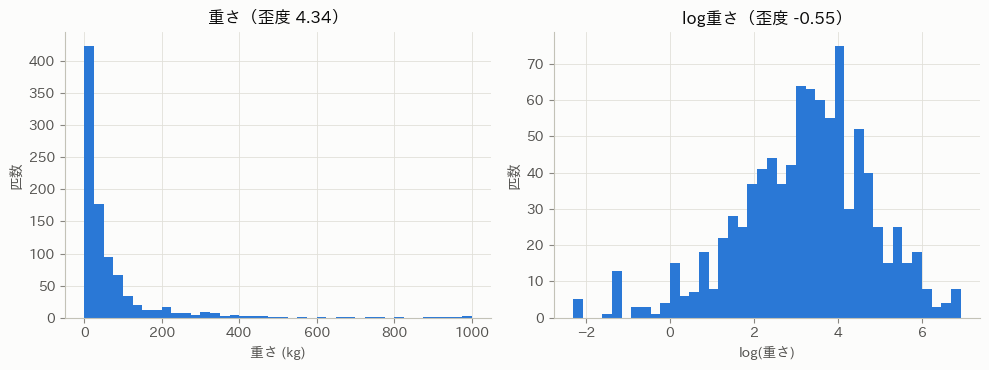

In [7]:
# 重さは対数をとると歪みが小さくなる
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(df["重さ"], bins=40, color=PALETTE[0])
axes[0].set(title=f"重さ（歪度 {df['重さ'].skew():.2f}）", xlabel="重さ (kg)", ylabel="匹数")
axes[1].hist(df["log重さ"], bins=40, color=PALETTE[0])
axes[1].set(title=f"log重さ（歪度 {df['log重さ'].skew():.2f}）", xlabel="log(重さ)", ylabel="匹数")
fig.tight_layout()
plt.show()

## 第1章 事象と確率

### 章の概要

920匹から1匹を等確率で選ぶ試行を考えると、「ドラゴンタイプを持つ」「合計種族値が600以上」などの条件は事象になり、その確率は該当する匹数の割合になる。
この章では、この有限で等確率な確率空間の上で、条件付き確率・ベイズの定理・包除原理・独立性・条件付き独立を数値で確かめる。
さらに、1匹ごとに値が決まる量（努力値合計）を離散確率変数とみなし、期待値と分散を定義式から求める。
ここで扱う確率関数・期待値は、第2章（同時分布・母関数）と第3章（分布の特性値）の土台になる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 1.1 | 条件付き確率・乗法定理 | P(合計種族値≥600 ｜ ドラゴン) と P(ドラゴン ｜ 合計種族値≥600) はどれだけ違うか |
| 1.2 | ベイズの定理 | 「合計種族値600以上」と知ると、ドラゴンである確率はどれだけ上がるか |
| 1.3 | 包除原理 | ドラゴンまたは合計種族値600以上である確率は |
| 1.4 | 事象の独立性 | タイプ1の種類と「複合タイプであること」は独立か |
| 1.5 | 条件付き独立 | 攻撃が高いことと特攻が高いことは、合計種族値の層ごとに見ると独立に近いか |
| 1.6 | 離散確率変数の期待値・分散 | 努力値合計の期待値と分散は |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `タイプ1`, `タイプ2` | 質的（18水準） | 事象「ドラゴンタイプを持つ」（`types_of(df, "ドラゴン")`）、タイプ1ごとの事象 |
| `複合タイプ` | 2値 | 事象「タイプ2を持つ」 |
| `合計種族値` | 量的（整数） | 事象「600以上」、条件付き独立の層 |
| `攻撃`, `特攻`, `素早` | 量的（整数） | 事象「100以上」 |
| `努力値合計` | 離散（1, 2, 3） | 離散確率変数の例 |

- **対象の行**：全920行（姿違いも1匹として数える）。
- **確率の意味**：標本空間 $\Omega$ を920匹の集合とし、各匹を確率 $1/920$ で選ぶ。事象 $A\subset\Omega$ の確率は $P(A)=|A|/920$ である。したがってこの章の確率は「推定値」ではなく、この確率空間での厳密な値である。
- **注意点**：ここでの独立・従属は「このデータでの割合」についての記述であり、ゲームの設計意図や因果を述べるものではない。

（→ py 01-0：事象ごとの匹数と努力値合計の度数）

In [8]:
# この章で使う事象と確率変数
N_ch1 = len(df)
ev_dragon = types_of(df, "ドラゴン")          # A: ドラゴンタイプを持つ
ev_strong = df["合計種族値"] >= 600            # B: 合計種族値が600以上
print(f"全体 N = {N_ch1}")
print(f"ドラゴンタイプを持つ（タイプ1かタイプ2）: {ev_dragon.sum()}")
print(f"合計種族値 >= 600: {ev_strong.sum()}")
print(f"複合タイプ: {df['複合タイプ'].sum()}")
print("\n努力値合計の度数")
print(df["努力値合計"].value_counts().sort_index().to_string())

全体 N = 920
ドラゴンタイプを持つ（タイプ1かタイプ2）: 61
合計種族値 >= 600: 100
複合タイプ: 496

努力値合計の度数
努力値合計
1    305
2    390
3    225


### 1.1 条件付き確率

**問い**：$A$ = 「ドラゴンタイプを持つ」、$B$ = 「合計種族値が600以上」とする。$P(B\mid A)$ と $P(A\mid B)$ は同じか。

**手法の要点**
- $P(A)>0$ のとき、$A$ が起きたもとでの $B$ の条件付き確率を
  $$P(B\mid A)=\frac{P(A\cap B)}{P(A)}$$
  で定める。等確率の有限空間では $P(B\mid A)=|A\cap B|/|A|$、すなわち「$A$ の中での $B$ の割合」である。
- 両辺に $P(A)$ をかけると乗法定理 $P(A\cap B)=P(B\mid A)P(A)=P(A\mid B)P(B)$ が得られる。
- $P(B\mid A)$ と $P(A\mid B)$ は分母が異なるので一般には等しくない（$P(A)=P(B)$ のときだけ等しい）。

（→ py 01-1）

In [9]:
# 条件付き確率 P(B|A) = P(A∩B) / P(A) と P(A|B) = P(A∩B) / P(B)
p_A = ev_dragon.mean()
p_B = ev_strong.mean()
p_AB = (ev_dragon & ev_strong).mean()
p_B_given_A = p_AB / p_A
p_A_given_B = p_AB / p_B
print(f"P(A) = P(ドラゴン)          = {p_A:.4f}")
print(f"P(B) = P(合計種族値>=600)   = {p_B:.4f}")
print(f"P(A∩B)                      = {p_AB:.4f}  （{(ev_dragon & ev_strong).sum()}匹）")
print(f"P(B|A) = P(600以上 | ドラゴン) = {p_B_given_A:.4f}")
print(f"P(A|B) = P(ドラゴン | 600以上) = {p_A_given_B:.4f}")
# 乗法定理 P(A∩B) = P(B|A)P(A) = P(A|B)P(B) の確認
print(f"\n乗法定理: P(B|A)P(A) = {p_B_given_A * p_A:.4f},  P(A|B)P(B) = {p_A_given_B * p_B:.4f}")

P(A) = P(ドラゴン)          = 0.0663
P(B) = P(合計種族値>=600)   = 0.1087
P(A∩B)                      = 0.0315  （29匹）
P(B|A) = P(600以上 | ドラゴン) = 0.4754
P(A|B) = P(ドラゴン | 600以上) = 0.2900

乗法定理: P(B|A)P(A) = 0.0315,  P(A|B)P(B) = 0.0315


**結果の読み方**
- ドラゴンタイプを持つのは61匹、合計種族値600以上は100匹、両方を満たすのは29匹である。
- $P(B\mid A)\approx0.48$（ドラゴンの約半数が600以上）に対し、$P(A\mid B)=0.29$（600以上の約3割がドラゴン）であり、条件の向きを取り違えると大きく異なる値になる。
- 乗法定理の2通りの計算はどちらも $P(A\cap B)\approx0.032$ に一致する。

### 1.2 ベイズの定理

**問い**：何も知らないときドラゴンである確率（事前確率）は $P(A)$ である。「合計種族値が600以上」という情報 $B$ を得たとき、ドラゴンである確率（事後確率）はいくらか。

**手法の要点**
- 乗法定理を $P(B)>0$ で割り、分母を全確率の公式で分解すると
  $$P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}=\frac{P(B\mid A)P(A)}{P(B\mid A)P(A)+P(B\mid A^c)P(A^c)}$$
  となる。$A^c$ は $A$ の余事象（ドラゴンタイプを持たない）である。
- $P(A)$ を事前確率、$P(B\mid A)$, $P(B\mid A^c)$ を尤度、$P(A\mid B)$ を事後確率とよぶ。
- ここでは右辺を「$A$ と $A^c$ それぞれの中での600以上の割合」から計算し、左辺を度数から直接求めた値と比べる。

（→ py 01-2）

In [10]:
# ベイズの定理：事前確率 P(A) → 「合計種族値が600以上」と知った後の事後確率 P(A|B)
p_B_given_notA = (~ev_dragon & ev_strong).sum() / (~ev_dragon).sum()   # P(B|A^c)
evidence = p_B_given_A * p_A + p_B_given_notA * (1 - p_A)             # 全確率の公式で P(B)
posterior = p_B_given_A * p_A / evidence
print(f"事前確率 P(A)     = {p_A:.4f}")
print(f"尤度 P(B|A)       = {p_B_given_A:.4f}")
print(f"尤度 P(B|A^c)     = {p_B_given_notA:.4f}")
print(f"全確率 P(B)       = {evidence:.4f}（度数から直接: {p_B:.4f}）")
print(f"事後確率 P(A|B)   = {posterior:.4f}（度数から直接: {p_A_given_B:.4f}）")
assert np.isclose(posterior, p_A_given_B)
print(f"事後/事前 = {posterior / p_A:.2f} 倍")

事前確率 P(A)     = 0.0663
尤度 P(B|A)       = 0.4754
尤度 P(B|A^c)     = 0.0827
全確率 P(B)       = 0.1087（度数から直接: 0.1087）
事後確率 P(A|B)   = 0.2900（度数から直接: 0.2900）
事後/事前 = 4.37 倍


**結果の読み方**
- 事前確率 $P(A)\approx0.066$ に対し、尤度は $P(B\mid A)\approx0.48$、$P(B\mid A^c)\approx0.083$ で、ドラゴンのほうが600以上になりやすい。
- ベイズの定理による事後確率は $0.29$ で、1.1で度数から直接求めた $P(A\mid B)$ と一致する（等確率の有限空間では恒等的に一致する）。
- 事後確率は事前確率の約4.4倍だが、それでも600以上のポケモンの7割はドラゴン以外である。事前確率が小さいと、尤度の比が大きくても事後確率はそれほど大きくならない（検査の陽性的中率と同じ構造）。

### 1.3 包除原理

**問い**：「ドラゴンタイプを持つ、または合計種族値が600以上」の確率 $P(A\cup B)$ は。

**手法の要点**
- 和事象の確率は
  $$P(A\cup B)=P(A)+P(B)-P(A\cap B)$$
  である。$A\cap B$ は $P(A)$ と $P(B)$ の両方で数えられているので1回分を引く。$A$ と $B$ が排反（$A\cap B=\emptyset$）なら $P(A\cup B)=P(A)+P(B)$。
- 3事象では $P(A\cup B\cup C)=\sum P(\cdot)-P(A\cap B)-P(A\cap C)-P(B\cap C)+P(A\cap B\cap C)$。ここでは $C$ = 「素早が100以上」で確かめる。

（→ py 01-3）

In [11]:
# 包除原理 P(A∪B) = P(A) + P(B) - P(A∩B)
p_union_formula = p_A + p_B - p_AB
p_union_direct = (ev_dragon | ev_strong).mean()
print(f"P(A)+P(B)-P(A∩B) = {p_union_formula:.4f}")
print(f"度数から直接     = {p_union_direct:.4f}")
print(f"単純な和 P(A)+P(B) = {p_A + p_B:.4f}（A∩Bを二重に数えている）")
# 3事象の包除原理：C = 素早 >= 100 を加える
ev_fast = df["素早"] >= 100
sets_ch1 = {"A": ev_dragon, "B": ev_strong, "C": ev_fast}
p3 = (sum(s.mean() for s in sets_ch1.values())
      - (ev_dragon & ev_strong).mean() - (ev_dragon & ev_fast).mean() - (ev_strong & ev_fast).mean()
      + (ev_dragon & ev_strong & ev_fast).mean())
print(f"\n3事象（C: 素早>=100）: 包除原理 {p3:.4f}, 直接 {(ev_dragon | ev_strong | ev_fast).mean():.4f}")

P(A)+P(B)-P(A∩B) = 0.1435
度数から直接     = 0.1435
単純な和 P(A)+P(B) = 0.1750（A∩Bを二重に数えている）

3事象（C: 素早>=100）: 包除原理 0.2598, 直接 0.2598


**結果の読み方**
- 包除原理の値 $P(A\cup B)\approx0.144$ は、和事象の匹数から直接数えた値と一致する。
- 単純な和 $P(A)+P(B)=0.175$ は、両方を満たす29匹を二重に数えた分だけ大きい。$A$ と $B$ は排反ではない。
- 3事象の場合も、包除原理と直接数えた値（約0.26）は一致する。

### 1.4 事象の独立性

**問い**：$D$ = 「複合タイプである」と $E_t$ = 「タイプ1が $t$ である」は独立か。

**手法の要点**
- 事象 $D$ と $E$ が独立であるとは $P(D\cap E)=P(D)P(E)$ が成り立つことをいう。$P(E)>0$ なら、これは $P(D\mid E)=P(D)$（$E$ を知っても $D$ の確率が変わらない）と同値である。
- 各タイプ $t$ について $P(D\mid E_t)$ を $P(D)$ と比べ、比 $P(D\cap E_t)/\{P(D)P(E_t)\}$ が1に近いかを見る。
- 独立は「排反」とは別の概念である。$P(D)>0,\ P(E)>0$ なら、排反な2事象は独立になりえない。
- この節は「ちょうど独立か」を割合で確かめるだけで、有意性の検定（カイ二乗検定）は第28章で扱う。件数が少ないタイプ（ひこう4匹、フェアリー19匹）の割合は不安定である。

（→ py 01-4）

P(D) = P(複合タイプ) = 0.5391
独立なら P(D|E) = P(D)、比 = 1


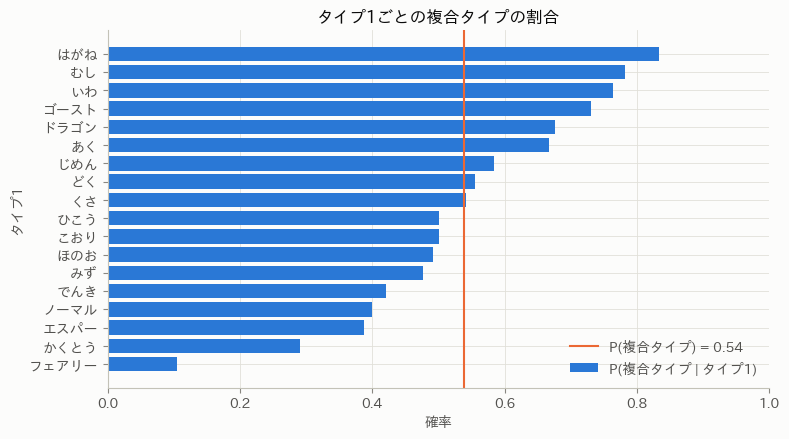

,件数,P(E),P(D∩E),P(D)P(E),P(D|E),比 P(D∩E)/P(D)P(E)
タイプ1,,,,,,
フェアリー,19,0.021,0.002,0.011,0.105,0.195
かくとう,31,0.034,0.010,0.018,0.290,0.539
エスパー,67,0.073,0.028,0.039,0.388,0.720
ノーマル,110,0.120,0.048,0.064,0.400,0.742
でんき,50,0.054,0.023,0.029,0.420,0.779
みず,124,0.135,0.064,0.073,0.476,0.883
ほのお,59,0.064,0.032,0.035,0.492,0.912
こおり,28,0.030,0.015,0.016,0.500,0.927
ひこう,4,0.004,0.002,0.002,0.500,0.927


In [12]:
# 事象の独立性：D = 複合タイプ と E_t = 「タイプ1が t」 について P(D∩E_t) と P(D)P(E_t) を比べる
p_dual = df["複合タイプ"].mean()
indep_rows = []
for t in df["タイプ1"].cat.categories:
    e_t = df["タイプ1"] == t
    indep_rows.append({
        "タイプ1": t, "件数": e_t.sum(),
        "P(E)": e_t.mean(),
        "P(D∩E)": (e_t & df["複合タイプ"]).mean(),
        "P(D)P(E)": p_dual * e_t.mean(),
        "P(D|E)": df.loc[e_t, "複合タイプ"].mean(),
    })
indep_tab = pd.DataFrame(indep_rows).set_index("タイプ1").sort_values("P(D|E)")
indep_tab["比 P(D∩E)/P(D)P(E)"] = indep_tab["P(D∩E)"] / indep_tab["P(D)P(E)"]
print(f"P(D) = P(複合タイプ) = {p_dual:.4f}")
print("独立なら P(D|E) = P(D)、比 = 1")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(indep_tab.index.astype(str), indep_tab["P(D|E)"], color=PALETTE[0], label="P(複合タイプ | タイプ1)")
ax.axvline(p_dual, color=PALETTE[1], lw=1.5, label=f"P(複合タイプ) = {p_dual:.2f}")
ax.set(title="タイプ1ごとの複合タイプの割合", xlabel="確率", ylabel="タイプ1", xlim=(0, 1))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
indep_tab.round(3)

**結果の読み方**
- 全体の複合タイプの割合は $P(D)\approx0.54$ である。
- くさ（$P(D\mid E)\approx0.54$、比1.01）やどく（比1.03）はほぼ独立に近い。
- 一方、はがね（0.83）・むし（0.78）・いわ（0.76）は複合タイプになりやすく、フェアリー（0.11）・かくとう（0.29）は単タイプが多い。したがって「タイプ1」と「複合タイプか」は全体としては独立ではない。
- 独立性は事象の組ごとに成り立つかどうかが決まる。くさについてはほぼ独立でも、他のタイプで成り立たなければ「2つの変数が独立」とはいえない（変数の独立は第2章）。

### 1.5 条件付き独立

**問い**：$A'$ = 「攻撃が100以上」、$B'$ = 「特攻が100以上」は全体では独立か。合計種族値の層 $C$ で条件づけるとどうか。

**手法の要点**
- $P(C)>0$ のとき、$C$ を与えたもとで $A'$ と $B'$ が条件付き独立であるとは
  $$P(A'\cap B'\mid C)=P(A'\mid C)\,P(B'\mid C)$$
  が成り立つことをいう。
- 独立と条件付き独立は互いに他を含意しない。全体で従属でも層の中では独立（またはその逆）のことがある。
- 攻撃と特攻はどちらも合計種族値の一部であり、合計種族値の高いポケモンほど両方とも高くなりやすい。この「第3の変数」で層別すると、全体で見えた関連がどう変わるかを調べる。層は合計種族値 400以下／401〜500／501〜600／601以上 の4つと、500以下／501以上 の2つで比べる。

（→ py 01-5）

In [13]:
# 条件付き独立：A' = 攻撃>=100, B' = 特攻>=100 は全体では独立でないが、
# 合計種族値の層 C で条件づけると P(A'∩B'|C) ≈ P(A'|C)P(B'|C) となるか
ev_atk = df["攻撃"] >= 100
ev_spa = df["特攻"] >= 100
layer_ch1 = pd.cut(df["合計種族値"], [0, 400, 500, 600, 800],
                   labels=["～400", "401～500", "501～600", "601～"])
ci_rows = [{"層": "全体", "件数": N_ch1, "P(A')": ev_atk.mean(), "P(B')": ev_spa.mean(),
            "P(A'∩B')": (ev_atk & ev_spa).mean(), "P(A')P(B')": ev_atk.mean() * ev_spa.mean()}]
for lv in layer_ch1.cat.categories:
    m = layer_ch1 == lv
    a, b = ev_atk[m], ev_spa[m]
    ci_rows.append({"層": f"合計種族値 {lv}", "件数": m.sum(), "P(A')": a.mean(), "P(B')": b.mean(),
                    "P(A'∩B')": (a & b).mean(), "P(A')P(B')": a.mean() * b.mean()})
# 2層（500以下 / 501以上）
for name, m in [("合計種族値 <=500", df["合計種族値"] <= 500), ("合計種族値 >500", df["合計種族値"] > 500)]:
    a, b = ev_atk[m], ev_spa[m]
    ci_rows.append({"層": name, "件数": m.sum(), "P(A')": a.mean(), "P(B')": b.mean(),
                    "P(A'∩B')": (a & b).mean(), "P(A')P(B')": a.mean() * b.mean()})
ci_tab = pd.DataFrame(ci_rows).set_index("層")
ci_tab["差 P(A'∩B')-P(A')P(B')"] = ci_tab["P(A'∩B')"] - ci_tab["P(A')P(B')"]
ci_tab.round(3)

,件数,P(A'),P(B'),P(A'∩B'),P(A')P(B'),差 P(A'∩B')-P(A')P(B')
層,,,,,,
全体,920,0.280,0.218,0.110,0.061,0.049
合計種族値 ～400,338,0.015,0.021,0.000,0.000,-0.000
合計種族値 401～500,317,0.281,0.120,0.019,0.034,-0.015
合計種族値 501～600,209,0.531,0.531,0.249,0.282,-0.033
合計種族値 601～,56,0.946,0.804,0.768,0.761,0.007
合計種族値 <=500,655,0.144,0.069,0.009,0.010,-0.001
合計種族値 >500,265,0.619,0.589,0.358,0.364,-0.006


**結果の読み方**
- 全体では $P(A'\cap B')\approx0.110$ に対し $P(A')P(B')\approx0.061$ で、積の約1.8倍になる。攻撃が高いポケモンは特攻も高い傾向があり、独立ではない。
- 合計種族値で層別すると、各層での差 $P(A'\cap B'\mid C)-P(A'\mid C)P(B'\mid C)$ は $-0.03$〜$+0.01$ 程度に縮み、符号はむしろ負の層が多い。全体の正の関連の大部分は「合計種族値が高い」という共通の要因によるもので、合計種族値を固定すると両者はほぼ条件付き独立か、わずかに負の関連（合計が決まっていると一方に配分すると他方が減る）になる。
- 層の切り方で差の値は変わる（2層でもほぼ0）。「条件付き独立が厳密に成り立つ」とはいえないが、第3の変数で条件づけると関連の見え方が大きく変わる例である。第3章の偏相関係数で同じことを相関係数で確かめる。

### 1.6 離散確率変数の期待値・分散

**問い**：1匹を等確率で選んだときの努力値合計 $X$ を確率変数とみなすと、期待値と分散はいくらか。

**手法の要点**
- $X$ のとりうる値は $x=1,2,3$、確率関数は $p(x)=P(X=x)$（$p(x)\ge0$、$\sum_x p(x)=1$）。
- 期待値 $E[X]=\sum_x x\,p(x)$、関数の期待値 $E[g(X)]=\sum_x g(x)p(x)$。
- 分散 $V[X]=E[(X-\mu)^2]=\sum_x (x-\mu)^2p(x)$（$\mu=E[X]$）。展開すると $V[X]=E[X^2]-(E[X])^2$。
- 定数 $a,b$ について $E[aX+b]=aE[X]+b$、$V[aX+b]=a^2V[X]$。
- 920匹全体を等確率で選ぶ確率変数なので、$E[X]$ は全体の平均、$V[X]$ は $n$ で割る分散（`var(ddof=0)`）と一致する。$n-1$ で割る不偏分散とは異なる。

（→ py 01-6）

確率関数 p(x): {1: 0.3315, 2: 0.4239, 3: 0.2446}
E[X] = Σ x p(x) = 1.9130（pandas mean: 1.9130）
V[X] 定義式 = 0.5685,  E[X^2]-E[X]^2 = 0.5685（pandas var(ddof=0): 0.5685）
Y = 0.25X + 0: E[Y] = 0.4783（aE[X]+b = 0.4783）, V[Y] = 0.0355（a^2 V[X] = 0.0355）


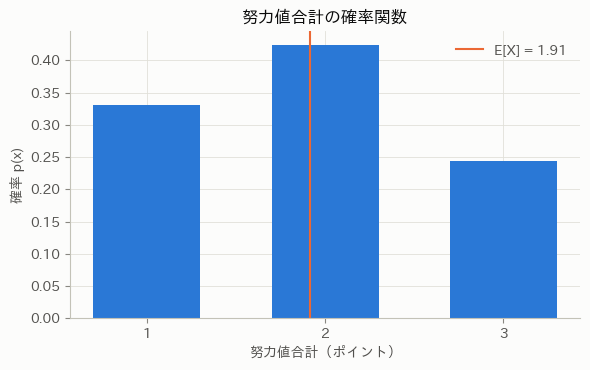

In [14]:
# 離散確率変数 X = 努力値合計（1匹を等確率で選んだときの値）の期待値・分散
pmf_ev = df["努力値合計"].value_counts(normalize=True).sort_index()
x_ev = pmf_ev.index.to_numpy()
p_ev = pmf_ev.to_numpy()
EX = np.sum(x_ev * p_ev)
EX2 = np.sum(x_ev**2 * p_ev)
VX_def = np.sum((x_ev - EX) ** 2 * p_ev)     # 定義 E[(X-μ)^2]
VX_short = EX2 - EX**2                      # 公式 E[X^2] - (E[X])^2
print("確率関数 p(x):", dict(zip(x_ev, p_ev.round(4))))
print(f"E[X] = Σ x p(x) = {EX:.4f}（pandas mean: {df['努力値合計'].mean():.4f}）")
print(f"V[X] 定義式 = {VX_def:.4f},  E[X^2]-E[X]^2 = {VX_short:.4f}（pandas var(ddof=0): {df['努力値合計'].var(ddof=0):.4f}）")
# 線形変換 Y = aX + b： E[Y] = aE[X]+b, V[Y] = a^2 V[X]
a_lin, b_lin = 0.25, 0  # 例：Lv100では努力値4で能力値が1上がるので、Y = X/4 は能力値換算の目安
y_ev = a_lin * x_ev + b_lin
print(f"Y = {a_lin}X + {b_lin}: E[Y] = {np.sum(y_ev * p_ev):.4f}（aE[X]+b = {a_lin * EX + b_lin:.4f}）, "
      f"V[Y] = {np.sum((y_ev - np.sum(y_ev * p_ev))**2 * p_ev):.4f}（a^2 V[X] = {a_lin**2 * VX_def:.4f}）")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(x_ev, p_ev, width=0.6, color=PALETTE[0])
ax.axvline(EX, color=PALETTE[1], lw=1.5, label=f"E[X] = {EX:.2f}")
ax.set(title="努力値合計の確率関数", xlabel="努力値合計（ポイント）", ylabel="確率 p(x)", xticks=x_ev)
ax.legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 確率関数は $p(1)\approx0.33,\ p(2)\approx0.42,\ p(3)\approx0.24$ で、$E[X]\approx1.91$、$V[X]\approx0.57$ である。
- 定義式と $E[X^2]-(E[X])^2$ の2通りの分散は一致し、pandas の `mean()`・`var(ddof=0)` とも一致する。
- $Y=X/4$ としても $E[Y]=E[X]/4$、$V[Y]=V[X]/16$ が成り立つ（Lv100 では努力値4で能力値が1上がることからの換算。端数の切り捨ては無視した目安）。

### まとめ

- 920匹を等確率で選ぶ確率空間では、条件付き確率は「条件を満たす集団の中での割合」であり、ベイズの定理・包除原理は度数から直接数えた値と一致する。
- $P(\text{600以上}\mid\text{ドラゴン})\approx0.48$ と $P(\text{ドラゴン}\mid\text{600以上})=0.29$ のように、条件の向きで値は大きく変わる。事前確率が小さいと、強い証拠があっても事後確率は大きくなりにくい。
- 複合タイプかどうかはタイプ1によって大きく異なり（はがね0.83、フェアリー0.11）、独立ではない。
- 攻撃と特攻の「高さ」の間の関連は、合計種族値で層別するとほぼ消える。見かけの関連が第3の変数によることがあり、層別（条件づけ）はそれを確かめる基本的な手段である。
- ここで確かめたのは割合の等式であり、偶然の変動を考慮した検定ではない。独立性の検定は第28章、仮想母集団からの標本とみなした推定・検定は後の章で扱う。

## 第2章 確率分布と母関数

### 章の概要

第1章では事象の確率を扱った。この章では確率変数の分布そのものを、累積分布関数・同時確率関数・母関数という形で表す。
920匹から1匹を等確率で選ぶと、合計種族値・世代・努力値合計などはすべて確率変数になり、その分布はデータの度数分布（経験分布）に一致する。
同時分布から周辺分布と条件付き分布を作り、条件付き期待値の繰り返しの法則や独立性の定義を数値で確かめる。
最後に、確率母関数・モーメント母関数を微分して平均・分散を再現する。ここでの分散・モーメントの計算は第3章の特性値、和の分布は第4章の畳み込みにつながる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 2.1 | 経験累積分布関数 | 合計種族値が500以下のポケモンの割合は。正規分布とどれくらい違うか |
| 2.2 | 同時・周辺・条件付き確率関数 | 世代と努力値合計の同時分布はどうなっているか |
| 2.3 | 確率変数の独立性 | 世代と努力値合計、タイプ1と世代は独立か |
| 2.4 | 条件付き期待値と繰り返し期待値の法則 | 努力値合計ごとの合計種族値の平均を重みづけると全体の平均に戻るか |
| 2.5 | 確率母関数 | 努力値合計の確率母関数を微分すると平均・分散が得られるか |
| 2.6 | モーメント母関数 | 合計種族値のモーメント母関数を数値微分すると平均・分散が得られるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（整数 175〜780） | 経験累積分布関数、条件付き期待値の目的変数 $Y$、モーメント母関数 |
| `努力値合計` | 離散（1, 2, 3） | 同時分布の一方、条件の変数 $X$、確率母関数 |
| `世代` | 離散（1〜7） | 同時分布のもう一方 |
| `タイプ1` | 質的（18水準） | 独立性の確認 |

- **対象の行**：全920行。
- **確率の意味**：第1章と同じく、1匹を確率 $1/920$ で選ぶ確率空間を考える。この確率変数の分布は経験分布であり、ここでの期待値・分散は920匹についての厳密な値（分散は $n$ で割るもの）である。
- **注意点**：合計種族値は整数値しかとらないので、厳密には離散型である。2.1では連続分布（正規分布）と比べるが、これは近似の良さを見るためである。

（→ py 02-0：使う列の要約）

In [15]:
# 使う列の要約
print(df[["合計種族値", "努力値合計", "世代"]].describe().round(2))
print("\nタイプ1の水準数:", df["タイプ1"].nunique())

        合計種族値   努力値合計      世代
count  920.00  920.00  920.00
mean   438.47    1.91    3.68
std    120.33    0.75    1.96
min    175.00    1.00    1.00
25%    330.00    1.00    2.00
50%    455.00    2.00    4.00
75%    518.00    2.00    5.00
max    780.00    3.00    7.00

タイプ1の水準数: 18


### 2.1 経験累積分布関数

**問い**：合計種族値 $X$ の累積分布関数 $F(x)=P(X\le x)$ はどんな形か。

**手法の要点**
- データ $x_1,\dots,x_n$ の経験累積分布関数は
  $$F_n(x)=\frac{1}{n}\#\{i : x_i\le x\}$$
  で、非減少・右連続で、各データ点で $1/n$ の整数倍だけ跳ぶ階段関数である。
- $P(a<X\le b)=F(b)-F(a)$。離散型では $P(X=x)=F(x)-F(x-)$（跳びの大きさ）である。
- 比較のため、平均と標準偏差をそろえた正規分布の累積分布関数を重ねる。

（→ py 02-1）

F(300) = P(合計種族値 <= 300) = 0.1522
F(400) = P(合計種族値 <= 400) = 0.3674
F(500) = P(合計種族値 <= 500) = 0.7120
F(600) = P(合計種族値 <= 600) = 0.9391
P(400 < X <= 600) = F(600) - F(400) = 0.5717
P(X = 600) = F(600) - F(599) = 0.0478（44匹）


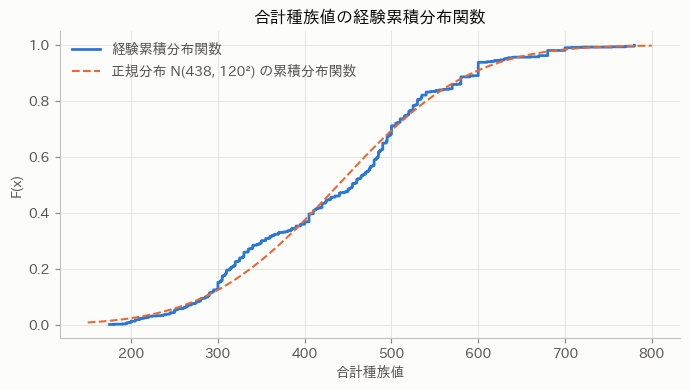

In [16]:
# 経験累積分布関数 F_n(x) = (x 以下の匹数) / n
total_sorted = np.sort(df["合計種族値"].to_numpy())
n_ch2 = len(total_sorted)


def ecdf_ch2(x, data=total_sorted):
    """経験累積分布関数（右連続）: data <= x となる割合."""
    return np.searchsorted(data, x, side="right") / len(data)


for x0 in [300, 400, 500, 600]:
    print(f"F({x0}) = P(合計種族値 <= {x0}) = {ecdf_ch2(x0):.4f}")
print(f"P(400 < X <= 600) = F(600) - F(400) = {ecdf_ch2(600) - ecdf_ch2(400):.4f}")
# 離散なので P(X = 600) = F(600) - F(600-) が跳びの大きさ
print(f"P(X = 600) = F(600) - F(599) = {ecdf_ch2(600) - ecdf_ch2(599):.4f}（{(df['合計種族値'] == 600).sum()}匹）")

mu_t, sd_t = total_sorted.mean(), total_sorted.std()
grid_t = np.linspace(150, 800, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.step(total_sorted, np.arange(1, n_ch2 + 1) / n_ch2, where="post", color=PALETTE[0], label="経験累積分布関数")
ax.plot(grid_t, stats.norm.cdf(grid_t, mu_t, sd_t), color=PALETTE[1], lw=1.5, ls="--",
        label=f"正規分布 N({mu_t:.0f}, {sd_t:.0f}²) の累積分布関数")
ax.set(title="合計種族値の経験累積分布関数", xlabel="合計種族値", ylabel="F(x)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**結果の読み方**
- $F(400)\approx0.37$、$F(500)\approx0.71$、$F(600)\approx0.94$ で、400〜600の範囲に約57%が入る。
- $x=600$ での跳びは約0.048（44匹）と特に大きい。合計種族値600は伝説級・600族に多い「きりのよい値」で、経験分布は正規分布のような滑らかな形ではない。
- 経験累積分布関数は正規分布の累積分布関数に大まかには沿うが、300〜400では正規分布より上（小さい値が多い）、400〜490では下にずれ、500と600の直前で急に立ち上がる。分布の当てはまりの検定（コルモゴロフ・スミルノフ検定など）は後の章で扱う。

### 2.2 同時確率関数・周辺確率関数・条件付き確率関数

**問い**：$X$ = 世代、$Y$ = 努力値合計 の同時分布はどうなっているか。世代ごとに努力値合計の分布は変わるか。

**手法の要点**
- 同時確率関数 $p(x,y)=P(X=x,\,Y=y)$ は $p(x,y)\ge0$、$\sum_x\sum_y p(x,y)=1$ を満たす。
- 周辺確率関数は一方の変数について足し上げたもの：$p_X(x)=\sum_y p(x,y)$、$p_Y(y)=\sum_x p(x,y)$。
- $p_X(x)>0$ のとき、$X=x$ を与えたときの $Y$ の条件付き確率関数は
  $$p(y\mid x)=\frac{p(x,y)}{p_X(x)}$$
  で、各 $x$ について $\sum_y p(y\mid x)=1$ となる。分割表を「行ごとの割合」にしたものにあたる。

（→ py 02-2）

同時確率の総和: 1.0

周辺 p_Y(y)（努力値合計）: {1: 0.3315, 2: 0.4239, 3: 0.2446}

条件付き確率関数 p(y | 世代)（各行の和は1）
努力値合計      1      2      3
世代                        
1      0.353  0.446  0.201
2      0.387  0.415  0.198
3      0.331  0.419  0.250
4      0.298  0.413  0.289
5      0.331  0.428  0.241
6      0.360  0.407  0.233
7      0.247  0.423  0.330


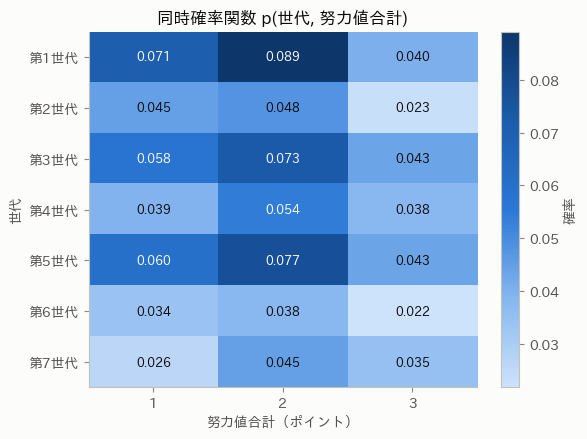

努力値合計,1,2,3
世代,,,
1,0.0707,0.0891,0.0402
2,0.0446,0.0478,0.0228
3,0.0576,0.0728,0.0435
4,0.0391,0.0543,0.0380
5,0.0598,0.0772,0.0435
6,0.0337,0.0380,0.0217
7,0.0261,0.0446,0.0348


In [17]:
# 同時確率関数 p(x, y)：X = 世代, Y = 努力値合計
joint_gy = pd.crosstab(df["世代"], df["努力値合計"], normalize="all")
p_gen = joint_gy.sum(axis=1)        # 周辺確率関数 p_X(x) = Σ_y p(x, y)
p_evs = joint_gy.sum(axis=0)        # 周辺確率関数 p_Y(y) = Σ_x p(x, y)
cond_y_given_x = joint_gy.div(p_gen, axis=0)   # 条件付き確率関数 p(y|x) = p(x, y) / p_X(x)
print("同時確率の総和:", joint_gy.to_numpy().sum().round(10))
print("\n周辺 p_Y(y)（努力値合計）:", p_evs.round(4).to_dict())
print("\n条件付き確率関数 p(y | 世代)（各行の和は1）")
print(cond_y_given_x.round(3))

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(joint_gy.to_numpy(), cmap=SEQ_CMAP, aspect="auto")
for i in range(joint_gy.shape[0]):
    for j in range(joint_gy.shape[1]):
        v = joint_gy.iat[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v > joint_gy.to_numpy().max() * 0.6 else INK["primary"], fontsize=9)
ax.set_xticks(range(joint_gy.shape[1]), joint_gy.columns)
ax.set_yticks(range(joint_gy.shape[0]), [f"第{g}世代" for g in joint_gy.index])
ax.set(title="同時確率関数 p(世代, 努力値合計)", xlabel="努力値合計（ポイント）", ylabel="世代")
ax.grid(False)
fig.colorbar(im, ax=ax, label="確率")
fig.tight_layout()
plt.show()
joint_gy.round(4)

**結果の読み方**
- 同時確率の総和は1、周辺 $p_Y(y)$ は第1章で求めた努力値合計の確率関数（0.33, 0.42, 0.24）と一致する。
- 条件付き確率関数 $p(y\mid x)$ を見ると、どの世代でも努力値合計2が最も多い。努力値合計3の割合は第1・2世代で約0.20、第7世代で約0.33と、世代による違いも見られる。
- 同時確率の大きいセル（第1世代・努力値2など）は、その世代の匹数が多いことも反映している。世代による違いを見るには、同時確率ではなく条件付き確率で比べる。

### 2.3 確率変数の独立性

**問い**：世代と努力値合計は独立か。タイプ1と世代は独立か。

**手法の要点**
- 離散確率変数 $X,Y$ が独立であるとは、すべての $(x,y)$ で
  $$p(x,y)=p_X(x)\,p_Y(y)$$
  が成り立つことをいう。これは $p_X(x)>0$ となるすべての $x$ で $p(y\mid x)=p_Y(y)$ となること（条件付き分布が $x$ によらない）と同値である。
- 1つでも等号が成り立たないセルがあれば独立ではない。特に、周辺確率がどちらも正なのに $p(x,y)=0$ のセルがあれば、明らかに独立ではない。
- ここでは差 $p(x,y)-p_X(x)p_Y(y)$ と比 $p(x,y)/\{p_X(x)p_Y(y)\}$ を図示する。差が偶然の範囲かどうかの判断（カイ二乗検定）は第28章で扱う。

（→ py 02-3）

世代 × 努力値合計: max |p(x,y) - p_X(x)p_Y(y)| = 0.0090
（参考）同時確率の最大値 = 0.0891
タイプ1 × 世代: max |p(x,y) - p_X(x)p_Y(y)| = 0.0096
同時確率が0のセル数（独立なら周辺が正なので0にはならない）: 11


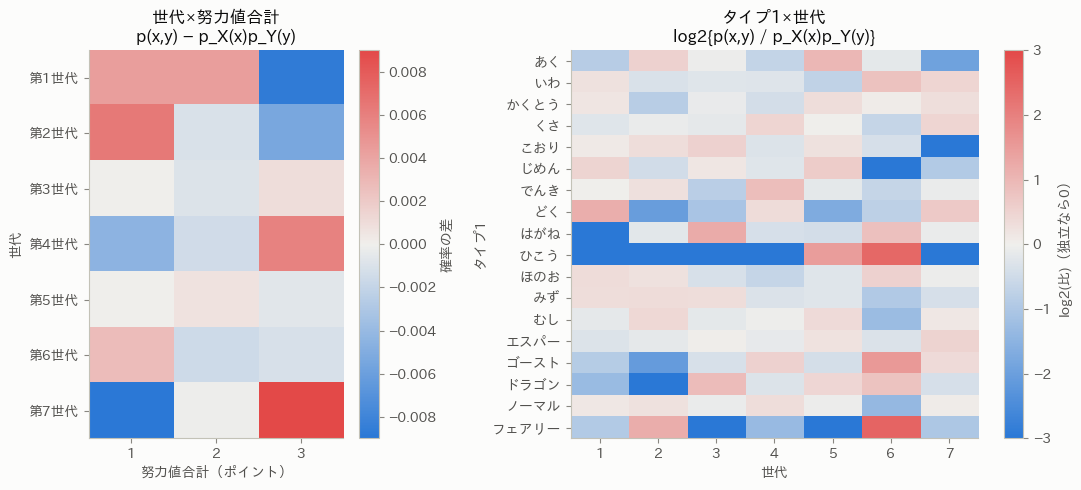

In [18]:
# 確率変数の独立性：p(x, y) と p_X(x) p_Y(y) を比べる
prod_gy = np.outer(p_gen, p_evs)
diff_gy = joint_gy - prod_gy
print("世代 × 努力値合計: max |p(x,y) - p_X(x)p_Y(y)| =", f"{np.abs(diff_gy.to_numpy()).max():.4f}")
print("（参考）同時確率の最大値 =", f"{joint_gy.to_numpy().max():.4f}")

# タイプ1 × 世代 でも同じ比較を行う
joint_tg = pd.crosstab(df["タイプ1"], df["世代"], normalize="all")
prod_tg = np.outer(joint_tg.sum(axis=1), joint_tg.sum(axis=0))
ratio_tg = joint_tg / prod_tg        # 独立なら全セルで1
print("タイプ1 × 世代: max |p(x,y) - p_X(x)p_Y(y)| =", f"{np.abs((joint_tg - prod_tg).to_numpy()).max():.4f}")
print("同時確率が0のセル数（独立なら周辺が正なので0にはならない）:", int((joint_tg.to_numpy() == 0).sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 1.6]})
lim_gy = np.abs(diff_gy.to_numpy()).max()
im0 = axes[0].imshow(diff_gy.to_numpy(), cmap=DIV_CMAP, vmin=-lim_gy, vmax=lim_gy, aspect="auto")
axes[0].set_xticks(range(3), diff_gy.columns)
axes[0].set_yticks(range(7), [f"第{g}世代" for g in diff_gy.index])
axes[0].set(title="世代×努力値合計\np(x,y) − p_X(x)p_Y(y)", xlabel="努力値合計（ポイント）", ylabel="世代")
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], label="確率の差")
# 比は対数で表示（1 → 0 が中央の灰色）。0 のセルは下限で切る
log_ratio_tg = np.log2(ratio_tg.clip(lower=1 / 8))
im1 = axes[1].imshow(log_ratio_tg.to_numpy(), cmap=DIV_CMAP, vmin=-3, vmax=3, aspect="auto")
axes[1].set_xticks(range(7), [f"{g}" for g in ratio_tg.columns])
axes[1].set_yticks(range(len(ratio_tg)), ratio_tg.index.astype(str))
axes[1].set(title="タイプ1×世代\nlog2{p(x,y) / p_X(x)p_Y(y)}", xlabel="世代", ylabel="タイプ1")
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], label="log2(比)（独立なら0）")
fig.tight_layout()
plt.show()

**結果の読み方**
- 世代×努力値合計では、$|p(x,y)-p_X(x)p_Y(y)|$ の最大値は約0.009で、同時確率の最大値（約0.089）の1割程度である。厳密には独立ではないが、独立に近い。差が大きいのは第7世代で努力値3が多い（積より大きい）セルなどである。
- タイプ1×世代では、同時確率0のセルが11個ある。例えばフェアリーは第6世代で新しく追加されたタイプで、第6世代の比は約5.6倍と大きい。逆に「はがね×第1世代」「ドラゴン×第2世代」などは0である。タイプ1と世代は独立ではない。
- 比の図では、同時確率0のセルは表示の下限（$\log_2$ 比 $=-3$）で塗っている。件数の少ないタイプ（ひこう4匹など）の比は極端な値になりやすく、細かい大小は偶然の影響も大きい。

### 2.4 条件付き期待値と繰り返し期待値の法則

**問い**：$X$ = 努力値合計、$Y$ = 合計種族値 とする。$E[Y\mid X=x]$ は $x$ とともにどう変わるか。それを $p_X(x)$ で重みづけると $E[Y]$ に戻るか。

**手法の要点**
- 離散型の条件付き期待値は $E[Y\mid X=x]=\sum_y y\,p(y\mid x)$。データでは「$X=x$ の群の $Y$ の平均」である。
- $E[Y\mid X]$ は $X$ の関数であり、それ自体が確率変数である。その期待値について繰り返し期待値の法則
  $$E\bigl[E[Y\mid X]\bigr]=\sum_x E[Y\mid X=x]\,p_X(x)=E[Y]$$
  が成り立つ。群ごとの平均を「群の大きさで重みづけて」平均すると全体の平均になる、ということである。
- 補足として、$E[Y\mid X]$ の分散 $V[E[Y\mid X]]$ が $V[Y]$ のどれだけを占めるかも示す（分散分析の群間変動にあたる。第20章）。

（→ py 02-4）

E[Y | X = x]: {1: 310.05, 2: 460.84, 3: 573.78}
E[E[Y|X]] = 438.4685
E[Y]      = 438.4685
V[Y] = 14463.9,  V[E[Y|X]] = 10157.4  （比 0.702）


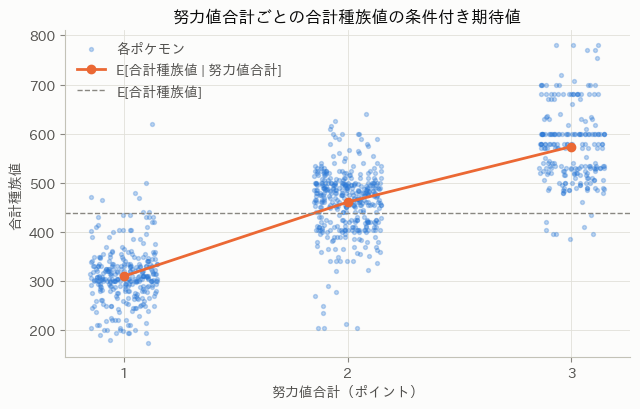

In [19]:
# 条件付き期待値 E[Y | X = x]（Y = 合計種族値, X = 努力値合計）と繰り返し期待値の法則
cond_mean_ev = df.groupby("努力値合計")["合計種族値"].mean()       # E[Y | X = x]
p_x_ev = df["努力値合計"].value_counts(normalize=True).sort_index()  # p_X(x)
iterated = np.sum(cond_mean_ev * p_x_ev)                             # E[E[Y|X]] = Σ_x E[Y|X=x] p_X(x)
print("E[Y | X = x]:", cond_mean_ev.round(2).to_dict())
print(f"E[E[Y|X]] = {iterated:.4f}")
print(f"E[Y]      = {df['合計種族値'].mean():.4f}")
assert np.isclose(iterated, df["合計種族値"].mean())
# 条件付き期待値 E[Y|X] は X の関数（確率変数）。その分散は Y の分散の一部
cond_mean_rv = df["努力値合計"].map(cond_mean_ev)
print(f"V[Y] = {df['合計種族値'].var(ddof=0):.1f},  V[E[Y|X]] = {cond_mean_rv.var(ddof=0):.1f}"
      f"  （比 {cond_mean_rv.var(ddof=0) / df['合計種族値'].var(ddof=0):.3f}）")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
jit = get_rng().uniform(-0.15, 0.15, len(df))
ax.scatter(df["努力値合計"] + jit, df["合計種族値"], s=8, alpha=0.3, color=PALETTE[0], label="各ポケモン")
ax.plot(cond_mean_ev.index, cond_mean_ev.values, "o-", color=PALETTE[1], label="E[合計種族値 | 努力値合計]")
ax.axhline(df["合計種族値"].mean(), color=INK["muted"], lw=1, ls="--", label="E[合計種族値]")
ax.set(title="努力値合計ごとの合計種族値の条件付き期待値", xlabel="努力値合計（ポイント）", ylabel="合計種族値",
       xticks=[1, 2, 3])
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**結果の読み方**
- $E[Y\mid X=1]\approx310$、$E[Y\mid X=2]\approx461$、$E[Y\mid X=3]\approx574$ で、努力値合計が多いポケモンほど合計種族値の平均が高い（進化段階が進むほどもらえる努力値が増えることが背景にあると考えられる）。
- これを $p_X(x)$ で重みづけた $E[E[Y\mid X]]$ は $E[Y]\approx438.5$ と一致する。3群の単純平均（重みなし）では一致しない点に注意する。
- $V[E[Y\mid X]]/V[Y]\approx0.70$ で、合計種族値のばらつきの約7割は努力値合計の違いで説明される。

### 2.5 確率母関数

**問い**：努力値合計 $X$ の確率母関数から、平均と分散を再現できるか。

**手法の要点**
- 非負整数値の確率変数 $X$ の確率母関数は
  $$G_X(s)=E[s^X]=\sum_{x=0}^{\infty}p(x)s^x$$
  （$|s|\le1$ で収束）。努力値合計では $G(s)=p(1)s+p(2)s^2+p(3)s^3$ という多項式になる。
- 微分して $s=1$ を代入すると階乗モーメントが得られる：$G'(1)=E[X]$、$G''(1)=E[X(X-1)]$。したがって
  $$V[X]=G''(1)+G'(1)-\{G'(1)\}^2 .$$
- $X_1,X_2$ が独立なら $G_{X_1+X_2}(s)=G_{X_1}(s)G_{X_2}(s)$。多項式の積の係数は確率関数の畳み込みであり、和の確率関数が得られる。ここでは「独立に2匹選んだときの努力値合計の和」で確かめる。

（→ py 02-5）

In [20]:
# 確率母関数 G(s) = E[s^X] = Σ p(x) s^x（X = 努力値合計）
pgf_coef = np.zeros(4)
pgf_coef[p_x_ev.index] = p_x_ev.to_numpy()     # 係数 p(0), p(1), p(2), p(3)
G = np.polynomial.Polynomial(pgf_coef)
G1, G2 = G.deriv(1), G.deriv(2)
mean_pgf = G1(1)                              # G'(1) = E[X]
fact2 = G2(1)                                 # G''(1) = E[X(X-1)]
var_pgf = fact2 + mean_pgf - mean_pgf**2      # V[X] = G''(1) + G'(1) - G'(1)^2
print("G(s) =", " + ".join(f"{c:.4f} s^{k}" for k, c in enumerate(pgf_coef) if c > 0))
print(f"G(1) = {G(1):.4f}")
print(f"G'(1) = {mean_pgf:.4f}（E[X] = {df['努力値合計'].mean():.4f}）")
print(f"G''(1) = E[X(X-1)] = {fact2:.4f}")
print(f"V[X] = G''(1)+G'(1)-G'(1)^2 = {var_pgf:.4f}（var(ddof=0) = {df['努力値合計'].var(ddof=0):.4f}）")

# 独立な2匹の努力値合計の和 X1 + X2：母関数は G(s)^2、係数は確率関数の畳み込み
G_sum = G**2
pmf_conv = np.convolve(pgf_coef, pgf_coef)
rng_ch2 = get_rng()
sim_sum = rng_ch2.choice(df["努力値合計"], 10000) + rng_ch2.choice(df["努力値合計"], 10000)
pgf_sum_tab = pd.DataFrame({
    "G(s)^2 の係数": G_sum.coef[:7], "畳み込み": pmf_conv[:7],
    "シミュレーション(1万回)": pd.Series(sim_sum).value_counts(normalize=True).reindex(range(7), fill_value=0).values,
}, index=pd.Index(range(7), name="X1+X2"))
print(f"\nE[X1+X2] = (G^2)'(1) = {G_sum.deriv()(1):.4f}（2E[X] = {2 * mean_pgf:.4f}）")
pgf_sum_tab.round(4)

G(s) = 0.3315 s^1 + 0.4239 s^2 + 0.2446 s^3
G(1) = 1.0000
G'(1) = 1.9130（E[X] = 1.9130）
G''(1) = E[X(X-1)] = 2.3152
V[X] = G''(1)+G'(1)-G'(1)^2 = 0.5685（var(ddof=0) = 0.5685）

E[X1+X2] = (G^2)'(1) = 3.8261（2E[X] = 3.8261）


,G(s)^2 の係数,畳み込み,シミュレーション(1万回)
X1+X2,,,
0,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000
2,0.1099,0.1099,0.1094
3,0.2811,0.2811,0.2847
4,0.3419,0.3419,0.3469
5,0.2073,0.2073,0.2003
6,0.0598,0.0598,0.0587


**結果の読み方**
- $G(1)=1$、$G'(1)\approx1.913=E[X]$、$G''(1)\approx2.315$ から $V[X]\approx0.5685$ で、第1章で定義式から求めた値と一致する。
- $G(s)^2$ の係数と確率関数の畳み込みは完全に一致し、1万回のシミュレーションで得た相対度数ともよく合う（和は2〜6で、4が最も多い）。$(G^2)'(1)=2E[X]$ も確認できる。

### 2.6 モーメント母関数

**問い**：合計種族値 $X$ のモーメント母関数を数値微分して、平均・分散を再現できるか。

**手法の要点**
- モーメント母関数は $M_X(t)=E[e^{tX}]$（0の近くのすべての $t$ で存在するとき）。$M_X^{(k)}(0)=E[X^k]$（原点まわりの $k$ 次モーメント）である。経験分布では $M(t)=\frac1n\sum_i e^{tx_i}$。
- $E[X]=M'(0)$、$V[X]=M''(0)-\{M'(0)\}^2$。
- 微分は中心差分で近似する：$M'(0)\approx\{M(h)-M(-h)\}/(2h)$、$M''(0)\approx\{M(h)-2M(0)+M(-h)\}/h^2$。$h$ が大きすぎると打ち切り誤差、小さすぎると丸め誤差が大きくなる。
- $X-\mu$ のモーメント母関数は $M_{X-\mu}(t)=e^{-\mu t}M_X(t)$ で、その2階微分 $M''_{X-\mu}(0)$ は分散そのものになる。
- $X,Y$ が独立なら $M_{X+Y}(t)=M_X(t)M_Y(t)$（2.5の確率母関数と同様。第4章の和の分布につながる）。

（→ py 02-6）

In [21]:
# モーメント母関数 M(t) = E[e^{tX}]（X = 合計種族値）を数値微分して平均・分散を求める
x_mgf = df["合計種族値"].to_numpy(dtype=float)


def mgf_ch2(t, data=x_mgf):
    """経験分布のモーメント母関数 M(t) = (1/n) Σ exp(t x_i)."""
    return np.mean(np.exp(t * data))


h_mgf = 1e-5
M1 = (mgf_ch2(h_mgf) - mgf_ch2(-h_mgf)) / (2 * h_mgf)                      # M'(0) ≈ E[X]
M2 = (mgf_ch2(h_mgf) - 2 * mgf_ch2(0) + mgf_ch2(-h_mgf)) / h_mgf**2         # M''(0) ≈ E[X^2]
print(f"M'(0)  ≈ {M1:.3f}（E[X] = {x_mgf.mean():.3f}）")
print(f"M''(0) ≈ {M2:.1f}（E[X^2] = {np.mean(x_mgf**2):.1f}）")
print(f"V[X] = M''(0) - M'(0)^2 ≈ {M2 - M1**2:.2f}（var(ddof=0) = {x_mgf.var():.2f}）")
# 刻み h による数値微分の誤差
for h in [1e-2, 1e-3, 1e-4, 1e-5]:
    m1 = (mgf_ch2(h) - mgf_ch2(-h)) / (2 * h)
    m2 = (mgf_ch2(h) - 2 * mgf_ch2(0) + mgf_ch2(-h)) / h**2
    print(f"  h = {h:.0e}: 平均 {m1:.3f}, 分散 {m2 - m1**2:.2f}")

# 中心化した X - μ のモーメント母関数 M_{X-μ}(t) = e^{-μt} M_X(t) なら、2階微分がそのまま分散になり、
# 指数の大きさが抑えられるので数値微分が安定する
xc_mgf = x_mgf - x_mgf.mean()
h_c = 1e-4
Mc2 = (mgf_ch2(h_c, xc_mgf) - 2 * mgf_ch2(0, xc_mgf) + mgf_ch2(-h_c, xc_mgf)) / h_c**2
print(f"中心化: M''_(X-μ)(0) ≈ {Mc2:.2f}（h = {h_c:.0e}）")

M'(0)  ≈ 438.470（E[X] = 438.468）
M''(0) ≈ 206719.0（E[X^2] = 206718.5）
V[X] = M''(0) - M'(0)^2 ≈ 14462.87（var(ddof=0) = 14463.93）
  h = 1e-02: 平均 8210.010, 分散 -65781786.35
  h = 1e-03: 平均 455.968, 分散 3397.28
  h = 1e-04: 平均 438.641, 分散 14358.01
  h = 1e-05: 平均 438.470, 分散 14462.87
中心化: M''_(X-μ)(0) ≈ 14464.36（h = 1e-04）


**結果の読み方**
- $h=10^{-5}$ で $M'(0)\approx438.47$（$E[X]=438.47$）、$M''(0)-M'(0)^2\approx14463$（分散 $14464$）で、定義式の値をほぼ再現する。
- $h=10^{-2}$ では $e^{tX}$ が $e^{7.8}$ 程度まで大きくなり、平均8210、分散が負という無意味な値になる。$X$ の値が数百あるので、$t$ はその逆数よりずっと小さくとる必要がある。
- 中心化した $X-\mu$ では指数の大きさが抑えられ、$h=10^{-4}$ で分散 $14464$ がよく再現される。

### まとめ

- 合計種族値の経験累積分布関数は正規分布に大まかに沿うが、600で大きく跳ぶ（44匹）など、ゲーム設計による「きりのよい値」が目立つ。
- 世代と努力値合計はほぼ独立に近いが厳密には独立ではなく、タイプ1と世代は同時確率0のセル（はがね×第1世代、ドラゴン×第2世代など11個）があり明らかに独立ではない。
- 努力値合計ごとの合計種族値の平均（約310, 461, 574）を度数で重みづけると全体平均438.5に戻り、繰り返し期待値の法則が確かめられる。合計種族値の分散の約7割は努力値合計で説明される。
- 確率母関数は努力値合計のような小さな整数値の変数で扱いやすく、微分で平均・分散、積で独立な和の分布が得られる。モーメント母関数の数値微分は刻みの選び方に敏感で、変数の尺度を意識する必要がある。

## 第3章 分布の特性値

### 章の概要

分布の形を少数の数値で要約する特性値（位置・散らばり・形・関連）を、種族値や高さ・重さで計算する。
位置は分位点・最頻値・各種の平均、散らばりは四分位範囲・変動係数、形は歪度・尖度、2変数の関連は共分散・相関係数・偏相関係数で表す。
学習のため、ライブラリの値を定義式からの計算と照合し、特に歪度・尖度では「$n$ で割るか、補正するか」でライブラリの既定値が異なる点を確かめる。
第2章の期待値・分散の考え方をデータの要約に適用する章であり、分散共分散行列は第22章の主成分分析、偏相関は第16章の重回帰や第25章のグラフィカルモデルの準備になる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 3.1 | 分位点・四分位範囲・最頻値 | 合計種族値の中心とばらつきは。最頻値は1つに決まるか |
| 3.2 | 変動係数 | 種族値6項目のうち、平均に比べて最もばらつくのはどれか |
| 3.3 | 歪度・尖度 | どの種族値が右に裾を引くか。ライブラリごとの値の違いは |
| 3.4 | 共分散・相関係数 | 攻撃と特攻はどれくらい連動するか |
| 3.5 | 分散共分散行列・相関行列 | 種族値6項目の関連の全体像は |
| 3.6 | 偏相関係数 | 合計種族値の影響を除くと、攻撃と特攻の関係はどうなるか。高さと重さの相関は擬似相関か |
| 3.7 | 加重平均・幾何平均・調和平均 | 重さの「平均」はどれを使うかでどれだけ変わるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`〜`素早`（`STATS`） | 量的（整数） | 種族値6項目。変動係数・歪度・相関行列 |
| `合計種族値` | 量的（整数） | 分位点・最頻値、偏相関で除く変数 |
| `高さ`, `重さ` | 量的（正の値, m, kg） | 変動係数、偏相関、幾何平均・調和平均 |
| `log高さ`, `log重さ` | 量的 | 偏相関（対数スケール） |
| `タイプ1` | 質的（18水準） | 加重平均の例 |

- **対象の行**：全920行。
- **分散の割り方**：920匹全体の特性値として $n$ で割る値（`ddof=0`）を基本にし、標本分散共分散行列（3.5）だけ $n-1$ で割る。どちらを使っているかは各節に書く。相関係数はどちらで割っても同じ値になる。
- **データの性質と注意点**：`HP`（ハピナス255など）、`防御`（最大230）、`重さ`（最大999.9kg）には極端な値があり、平均・分散・歪度・尖度はこれらに強く影響される。`重さ` の最小値は0.1kg（複数匹）である。

（→ py 03-0：使う列の要約統計）

In [22]:
# 使う列の要約
cols_ch3 = STATS + ["合計種族値", "高さ", "重さ"]
df[cols_ch3].describe().round(2)

,HP,攻撃,防御,特攻,特防,素早,合計種族値,高さ,重さ
count,920.00,920.00,920.00,920.00,920.0,920.00,920.00,920.00,920.00
mean,69.56,80.07,74.56,73.32,72.4,68.55,438.47,1.27,69.16
std,26.03,32.54,31.22,33.22,27.9,29.42,120.33,1.30,124.71
min,1.00,5.00,5.00,10.00,20.0,5.00,175.00,0.10,0.10
25%,50.00,55.00,50.00,50.00,50.0,45.00,330.00,0.60,9.50
50%,67.00,75.00,70.00,65.00,70.0,65.00,455.00,1.00,29.50
75%,80.00,100.00,90.00,95.00,90.0,90.00,518.00,1.50,70.12
max,255.00,190.00,230.00,194.00,230.0,180.00,780.00,14.50,999.90


### 3.1 分位点・四分位範囲・最頻値

**問い**：合計種族値の四分位数と四分位範囲は。最頻値はどう定めるかで変わるか。

**手法の要点**
- 累積分布関数 $F$ が連続で増加のとき、$F(x_p)=p$ となる $x_p$ が $p$ 分位点で、$x_{0.25}$ が第1四分位数、$x_{0.5}$ が中央値、$x_{0.75}$ が第3四分位数、$x_{0.75}-x_{0.25}$ が四分位範囲（IQR）である。
- データから求める標本分位点は、順序統計量 $x_{(1)}\le\dots\le x_{(n)}$ のどれを使うか・どう補間するかで何通りも定義がある（`numpy.quantile` の `method`）。$n$ が大きければ差は小さい。
- 最頻値は確率関数（密度関数）を最大にする値。値そのものが繰り返し現れる離散データでは最も多い値、連続とみなすなら度数分布の最頻階級やカーネル密度推定の最大点を使う。
- 箱ひげ図は四分位数を箱、$1.5\times$IQR 以内の最も遠い点までをひげで表す。

（→ py 03-1）

合計種族値: Q1 = 330, 中央値 = 455, Q3 = 518, IQR = 188

重さ (kg) の四分位数：分位点の定義による違い
          Q1 (25%)   中央値  Q3 (75%)     IQR
linear         9.5  29.5    70.125  60.625
lower          9.5  29.5    70.000  60.500
higher         9.5  29.5    70.500  61.000
midpoint       9.5  29.5    70.250  60.750
nearest        9.5  29.5    70.000  60.500
hazen          9.5  29.5    70.250  60.750
weibull        9.5  29.5    70.375  60.875

最頻値（値そのものの最頻値）: [600]（44匹）
最頻階級（幅10）: [300, 310)  度数 53
カーネル密度推定の最大点: 490


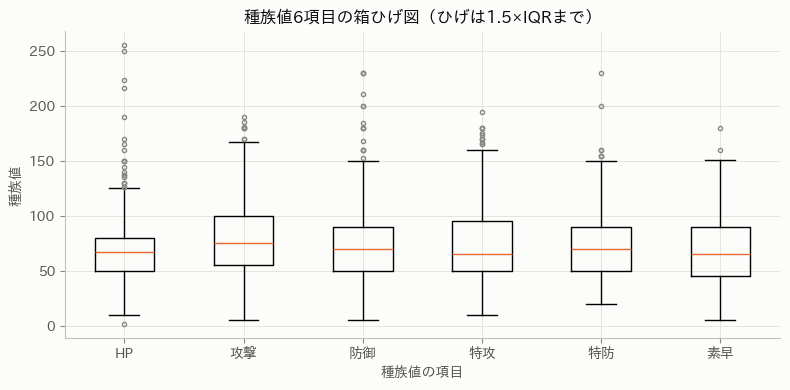

In [23]:
# 分位点・四分位範囲・最頻値（合計種族値）
x_tot = df["合計種族値"]
q_tot = x_tot.quantile([0.25, 0.5, 0.75])
print(f"合計種族値: Q1 = {q_tot[0.25]:.0f}, 中央値 = {q_tot[0.5]:.0f}, Q3 = {q_tot[0.75]:.0f}, "
      f"IQR = {q_tot[0.75] - q_tot[0.25]:.0f}")
# 分位点の定義（隣り合う順序統計量の補間の仕方）による違い：重さで比べる
q_methods = ["linear", "lower", "higher", "midpoint", "nearest", "hazen", "weibull"]
quant_tab = pd.DataFrame(
    {m: np.quantile(df["重さ"], [0.25, 0.5, 0.75], method=m) for m in q_methods},
    index=["Q1 (25%)", "中央値", "Q3 (75%)"]).T
quant_tab["IQR"] = quant_tab["Q3 (75%)"] - quant_tab["Q1 (25%)"]
print("\n重さ (kg) の四分位数：分位点の定義による違い")
print(quant_tab)
print(f"\n最頻値（値そのものの最頻値）: {x_tot.mode().tolist()}（{(x_tot == x_tot.mode()[0]).sum()}匹）")
# 連続量とみなした最頻値：幅10の階級の最頻階級と、カーネル密度推定の最大点
bins_tot = np.arange(170, 800, 10)
cnt_tot, edges_tot = np.histogram(x_tot, bins_tot)
k_max = cnt_tot.argmax()
print(f"最頻階級（幅10）: [{edges_tot[k_max]}, {edges_tot[k_max + 1]})  度数 {cnt_tot[k_max]}")
kde_tot = stats.gaussian_kde(x_tot)
grid_tot = np.linspace(150, 800, 651)
print(f"カーネル密度推定の最大点: {grid_tot[kde_tot(grid_tot).argmax()]:.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([df[c] for c in STATS], labels=STATS, widths=0.5,
           medianprops={"color": PALETTE[1]}, flierprops={"markersize": 3, "markeredgecolor": INK["muted"]})
ax.set(title="種族値6項目の箱ひげ図（ひげは1.5×IQRまで）", xlabel="種族値の項目", ylabel="種族値")
fig.tight_layout()
plt.show()

**結果の読み方**
- 合計種族値は $Q_1=330$、中央値 $455$、$Q_3=518$、IQR $=188$ である。
- 重さの四分位数では定義による違いは $Q_3$ の $70.0$〜$70.5$ kg 程度で、$n=920$ では実質的に問題にならない。
- 最頻値は定め方で大きく変わる：値そのものの最頻値は $600$（44匹）、幅10の最頻階級は $[300,310)$（53匹）、カーネル密度推定の最大点は約490。合計種族値の分布は「未進化の300前後」と「最終進化の500前後」に山があり、さらに600にきりのよい値が集中するため、最頻値1つでは中心を代表できない。
- 箱ひげ図では、HP と防御に上側の外れ値が多い。

### 3.2 変動係数

**問い**：種族値6項目のうち、平均に対して相対的に最もばらつくのはどれか。単位の違う高さと重さのばらつきは比べられるか。

**手法の要点**
- 正の値をとる変数 $X$ の変動係数は $\mathrm{CV}=\sigma/\mu$（ここでは $\sigma$ は $n$ で割る標準偏差）。
- 単位に依存しない（$X$ を $c>0$ 倍しても変わらない）ので、平均の大きさや単位が異なる変数のばらつきを比べられる。
- 平行移動 $X+b$ では変わってしまうので、0が意味をもつ比尺度の変数に使う。

（→ py 03-2）

In [24]:
# 変動係数 CV = σ / μ（種族値6項目）
cv_tab = pd.DataFrame({
    "平均": df[STATS].mean(),
    "標準偏差(ddof=0)": df[STATS].std(ddof=0),
})
cv_tab["変動係数"] = cv_tab["標準偏差(ddof=0)"] / cv_tab["平均"]
cv_tab.loc["合計種族値"] = [x_tot.mean(), x_tot.std(ddof=0), x_tot.std(ddof=0) / x_tot.mean()]
# 単位の違う量（高さ m と重さ kg）も CV なら比べられる
for c in ["高さ", "重さ"]:
    cv_tab.loc[c] = [df[c].mean(), df[c].std(ddof=0), df[c].std(ddof=0) / df[c].mean()]
cv_tab.round(3)

,平均,標準偏差(ddof=0),変動係数
HP,69.563,26.021,0.374
攻撃,80.070,32.525,0.406
防御,74.558,31.201,0.418
特攻,73.325,33.205,0.453
特防,72.403,27.881,0.385
素早,68.550,29.402,0.429
合計種族値,438.468,120.266,0.274
高さ,1.268,1.302,1.027
重さ,69.159,124.638,1.802


**結果の読み方**
- 種族値6項目の CV は 0.37（HP）〜0.45（特攻）で、特攻・素早・防御が相対的にばらつき、HP・特防はばらつきが小さい。
- 合計種族値の CV は約0.27で、個々の項目より小さい。項目どうしの高低がある程度打ち消し合うためである（ただし相関が正なので、独立な場合ほどは小さくならない）。
- 高さ（約1.0）と重さ（約1.8）は種族値よりはるかに相対的なばらつきが大きい。単位（m と kg）が違っても CV なら比べられる。

### 3.3 歪度・尖度

**問い**：どの種族値が右に裾を引くか。歪度・尖度の値はライブラリによってなぜ違うか。

**手法の要点**
- 期待値 $\mu$、分散 $\sigma^2$ の $X$ について、歪度は $E[\{(X-\mu)/\sigma\}^3]$、尖度は $E[\{(X-\mu)/\sigma\}^4]$。正規分布では歪度0・尖度3なので、尖度から3を引いた値（超過尖度）を使うことが多い。
- データの中心モーメントを $m_k=\frac1n\sum_i(x_i-\bar x)^k$ とすると
  $$g_1=\frac{m_3}{m_2^{3/2}},\qquad g_2=\frac{m_4}{m_2^2}-3 .$$
  `scipy.stats.skew`・`kurtosis` の既定（`bias=True`）はこの値である。
- pandas の `skew()`・`kurt()` は、正規分布からの標本での偏りを小さくする補正版
  $$G_1=\frac{\sqrt{n(n-1)}}{n-2}\,g_1,\qquad G_2=\frac{n-1}{(n-2)(n-3)}\{(n+1)g_2+6\}$$
  を返す。$n=920$ では差はわずかだが、小さな標本では無視できない。
- 3乗・4乗を使うので、極端な値1つで大きく変わる。

（→ py 03-3）

In [25]:
# 歪度・尖度：定義式からの手計算と pandas / scipy の照合


def moments_ch3(x):
    """標本の歪度・尖度を定義式から計算する（b: n で割る版, G: pandas の補正版）."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    d = x - x.mean()
    m2, m3, m4 = (d**2).mean(), (d**3).mean(), (d**4).mean()
    g1 = m3 / m2**1.5                  # 歪度（n で割る中心モーメント）
    g2 = m4 / m2**2 - 3                # 尖度（正規分布で0になるよう3を引く）
    G1 = g1 * np.sqrt(n * (n - 1)) / (n - 2)                       # 補正済み歪度
    G2 = ((n + 1) * g2 + 6) * (n - 1) / ((n - 2) * (n - 3))        # 補正済み尖度
    return g1, g2, G1, G2


sk_rows = {}
for c in STATS + ["合計種族値", "重さ", "log重さ"]:
    g1, g2, G1, G2 = moments_ch3(df[c])
    sk_rows[c] = {"歪度 g1": g1, "scipy skew": stats.skew(df[c]),
                  "歪度 G1(補正)": G1, "pandas skew": df[c].skew(),
                  "尖度 g2": g2, "scipy kurtosis": stats.kurtosis(df[c]),
                  "尖度 G2(補正)": G2, "pandas kurt": df[c].kurt()}
sk_tab = pd.DataFrame(sk_rows).T
assert np.allclose(sk_tab["歪度 g1"], sk_tab["scipy skew"]) and np.allclose(sk_tab["歪度 G1(補正)"], sk_tab["pandas skew"])
assert np.allclose(sk_tab["尖度 g2"], sk_tab["scipy kurtosis"]) and np.allclose(sk_tab["尖度 G2(補正)"], sk_tab["pandas kurt"])
print("手計算と scipy（bias=True, 既定）・pandas（補正版）はすべて一致")
sk_tab.round(3)

手計算と scipy（bias=True, 既定）・pandas（補正版）はすべて一致


,歪度 g1,scipy skew,歪度 G1(補正),pandas skew,尖度 g2,scipy kurtosis,尖度 G2(補正),pandas kurt
HP,1.692,1.692,1.695,1.695,7.758,7.758,7.807,7.807
攻撃,0.507,0.507,0.508,0.508,0.057,0.057,0.064,0.064
防御,1.106,1.106,1.107,1.107,2.502,2.502,2.522,2.522
特攻,0.717,0.717,0.719,0.719,0.170,0.170,0.177,0.177
特防,0.771,0.771,0.772,0.772,1.261,1.261,1.275,1.275
素早,0.354,0.354,0.354,0.354,-0.290,-0.290,-0.285,-0.285
合計種族値,0.097,0.097,0.097,0.097,-0.532,-0.532,-0.528,-0.528
重さ,4.335,4.335,4.342,4.342,23.549,23.549,23.684,23.684
log重さ,-0.546,-0.546,-0.547,-0.547,0.649,0.649,0.659,0.659


**結果の読み方**
- 手計算の $g_1,g_2$ は scipy と、$G_1,G_2$ は pandas とすべて一致した。$n=920$ では $g$ と $G$ の差は小さく、尖度の大きい HP・重さで0.05〜0.13程度、他は小数第2〜3位程度である。
- 歪度は HP（約1.69）・防御（約1.11）が大きく、右に長い裾をもつ。超過尖度も HP が約7.8と非常に大きく、ハピナス（255）・ラッキー（250）などごく少数の極端な値によるものである。
- 合計種族値は歪度約0.10とほぼ左右対称で、超過尖度は約 $-0.53$（正規分布より平たい）。3.1で見た山が複数ある形と整合する。
- 重さは歪度約4.34、超過尖度約23.5と極端に右に歪むが、対数をとると歪度 $-0.55$ まで小さくなる（第4章）。

### 3.4 共分散と相関係数

**問い**：攻撃 $X$ と特攻 $Y$ の共分散・相関係数は。和 $X+Y$ の分散にどう効くか。

**手法の要点**
- 共分散 $\mathrm{Cov}[X,Y]=E[(X-\mu_X)(Y-\mu_Y)]=E[XY]-E[X]E[Y]$。
- 相関係数 $\rho=\mathrm{Cov}[X,Y]/(\sigma_X\sigma_Y)$ は $-1\le\rho\le1$ で、直線的な関係の強さを表す。
- 線形変換について $\mathrm{Cov}[aX+b,\,cY+d]=ac\,\mathrm{Cov}[X,Y]$。相関係数は $ac>0$ なら不変である。
- 和の分散 $V[X+Y]=V[X]+V[Y]+2\,\mathrm{Cov}[X,Y]$。$X,Y$ が独立なら $\mathrm{Cov}=0$ で $V[X+Y]=V[X]+V[Y]$ となる（逆に $\mathrm{Cov}=0$ でも独立とは限らない）。

（→ py 03-4）

Cov[X,Y] 定義式 = 419.43,  E[XY]-E[X]E[Y] = 419.43,  np.cov(ddof=0) = 419.43
ρ = Cov/(σXσY) = 0.3884（np.corrcoef: 0.3884）


V[X+Y] = 2999.3,  V[X]+V[Y]+2Cov = 2999.3,  V[X]+V[Y]（独立なら）= 2160.4
Cov[2X+5, 0.5Y-10] = 419.43（ac Cov = 419.43）、相関 0.3884


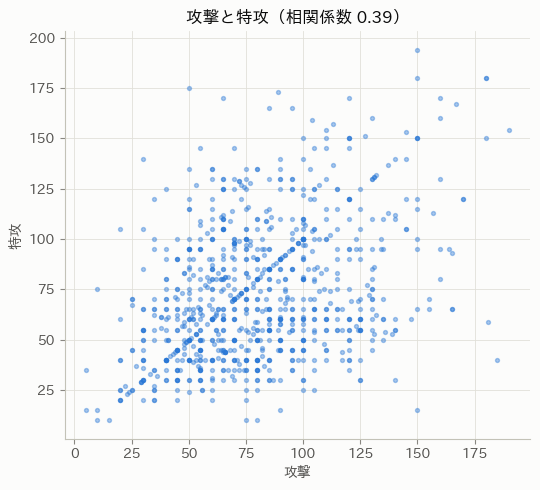

In [26]:
# 共分散と相関係数（攻撃 X と 特攻 Y）
x_atk = df["攻撃"].to_numpy(float)
y_spa = df["特攻"].to_numpy(float)
cov_def = np.mean((x_atk - x_atk.mean()) * (y_spa - y_spa.mean()))          # E[(X-μX)(Y-μY)]
cov_short = np.mean(x_atk * y_spa) - x_atk.mean() * y_spa.mean()            # E[XY] - E[X]E[Y]
r_def = cov_def / (x_atk.std() * y_spa.std())
print(f"Cov[X,Y] 定義式 = {cov_def:.2f},  E[XY]-E[X]E[Y] = {cov_short:.2f},  np.cov(ddof=0) = {np.cov(x_atk, y_spa, ddof=0)[0, 1]:.2f}")
print(f"ρ = Cov/(σXσY) = {r_def:.4f}（np.corrcoef: {np.corrcoef(x_atk, y_spa)[0, 1]:.4f}）")
# 分散の加法：V[X+Y] = V[X] + V[Y] + 2Cov[X,Y]
print(f"V[X+Y] = {np.var(x_atk + y_spa):.1f},  V[X]+V[Y]+2Cov = {np.var(x_atk) + np.var(y_spa) + 2 * cov_def:.1f},"
      f"  V[X]+V[Y]（独立なら）= {np.var(x_atk) + np.var(y_spa):.1f}")
# 線形変換：Cov[aX+b, cY+d] = ac Cov[X,Y]、相関係数は ac>0 なら不変
a3, b3, c3, d3 = 2, 5, 0.5, -10
print(f"Cov[{a3}X+{b3}, {c3}Y{d3:+}] = {np.cov(a3 * x_atk + b3, c3 * y_spa + d3, ddof=0)[0, 1]:.2f}"
      f"（ac Cov = {a3 * c3 * cov_def:.2f}）、相関 {np.corrcoef(a3 * x_atk + b3, c3 * y_spa + d3)[0, 1]:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(x_atk, y_spa, s=8, alpha=0.4, color=PALETTE[0])
ax.set(title=f"攻撃と特攻（相関係数 {r_def:.2f}）", xlabel="攻撃", ylabel="特攻")
fig.tight_layout()
plt.show()

**結果の読み方**
- 共分散は定義式・$E[XY]-E[X]E[Y]$・`np.cov` のどれでも約419、相関係数は約0.39である。攻撃が高いポケモンは特攻もやや高い。
- $V[X+Y]\approx2999$ は $V[X]+V[Y]\approx2160$ より約4割大きい。正の共分散の分だけ和のばらつきが大きくなる（第4章の和の分布でもこの差が現れる）。
- $2X+5$ と $0.5Y-10$ の共分散は $ac=1$ 倍でもとの値のまま、相関係数も不変であることを確認した。

### 3.5 分散共分散行列・相関行列

**問い**：種族値6項目の関連の全体像はどうなっているか。

**手法の要点**
- $p$ 次元確率ベクトル $\boldsymbol{x}=(x_1,\dots,x_p)^\top$ の分散共分散行列 $\Sigma$ は $(i,j)$ 成分が $\mathrm{Cov}[x_i,x_j]$ の対称行列で、半正定値（すべての固有値が0以上）である。
- 標本分散共分散行列 $S$ は $(i,j)$ 成分を $\frac{1}{n-1}\sum_k(x_{ki}-\bar x_i)(x_{kj}-\bar x_j)$ とする（ここでは $n-1$ で割る）。
- 相関行列は $R=D^{-1/2}SD^{-1/2}$（$D$ は $S$ の対角成分を並べた対角行列）。
- 定数ベクトル $\boldsymbol{a}$ について $V[\boldsymbol{a}^\top\boldsymbol{x}]=\boldsymbol{a}^\top\Sigma\boldsymbol{a}$。$\boldsymbol{a}=\boldsymbol{1}$ とすると合計種族値の分散になる。

（→ py 03-5）

分散共分散行列 S（n-1で割る）
       HP      攻撃     防御      特攻     特防     素早
HP  677.8   358.0  200.6   321.2  268.7  128.8
攻撃  358.0  1059.0  450.8   419.9  234.2  352.8
防御  200.6   450.8  974.5   226.7  455.7  -13.3
特攻  321.2   419.9  226.7  1103.8  467.6  452.3
特防  268.7   234.2  455.7   467.6  778.2  186.4
素早  128.8   352.8  -13.3   452.3  186.4  865.4

固有値（半正定値なら全て0以上）: [ 233.7  396.4  536.9  747.8 1051.8 2492.2]
1ᵀS1 = 14479.7,  V[合計種族値] = 14479.7


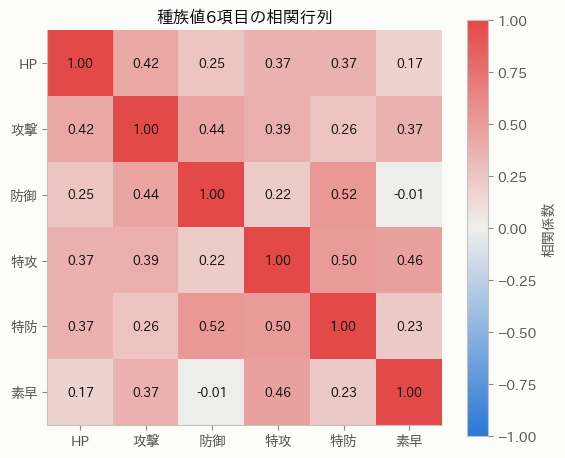

In [27]:
# 分散共分散行列・相関行列（種族値6項目）
X6 = df[STATS].to_numpy(float)
S6 = np.cov(X6, rowvar=False, ddof=1)                  # 標本分散共分散行列（n-1 で割る）
D_inv = np.diag(1 / np.sqrt(np.diag(S6)))
R6 = D_inv @ S6 @ D_inv                                # R = D^{-1/2} S D^{-1/2}
assert np.allclose(R6, df[STATS].corr().to_numpy())
print("分散共分散行列 S（n-1で割る）")
print(pd.DataFrame(S6, index=STATS, columns=STATS).round(1))
print("\n固有値（半正定値なら全て0以上）:", np.linalg.eigvalsh(S6).round(1))
# 合計種族値 = 1ᵀx の分散は 1ᵀ S 1
ones6 = np.ones(6)
print(f"1ᵀS1 = {ones6 @ S6 @ ones6:.1f},  V[合計種族値] = {x_tot.var(ddof=1):.1f}")

fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(R6, cmap=DIV_CMAP, vmin=-1, vmax=1)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{R6[i, j]:.2f}", ha="center", va="center", fontsize=9, color=INK["primary"])
ax.set_xticks(range(6), STATS)
ax.set_yticks(range(6), STATS)
ax.set(title="種族値6項目の相関行列")
ax.grid(False)
fig.colorbar(im, ax=ax, label="相関係数")
fig.tight_layout()
plt.show()

**結果の読み方**
- $S$ の固有値は約234〜2492ですべて正で、半正定値（ここでは正定値）であることが確認できる。$D^{-1/2}SD^{-1/2}$ は pandas の相関行列と一致した。
- $\boldsymbol{1}^\top S\boldsymbol{1}$ は合計種族値の不偏分散（約14480）に一致する。
- 相関はほぼすべて正（0.17〜0.52）で、「全体的に強いポケモンはどの項目も高い」傾向を表す。大きいのは防御–特防（0.52）、特攻–特防（0.50）、特攻–素早（0.46）で、防御–素早だけはほぼ0（$-0.01$）である。全項目が正に相関するのは第22章の主成分分析で第1主成分が「総合力」になることにつながる。

### 3.6 偏相関係数

**問い**：合計種族値 $Z$ の影響を除くと、攻撃と特攻の相関はどうなるか。高さと重さの相関は、合計種族値を介した擬似相関か。

**手法の要点**
- $Z$ が $X$ と $Y$ の両方と相関していると、$X$ と $Y$ の間に直接の関係がなくても相関が生じる（擬似相関）。$Z$ の影響を除いた相関が偏相関係数
  $$r_{XY\cdot Z}=\frac{r_{XY}-r_{XZ}r_{YZ}}{\sqrt{(1-r_{XZ}^2)(1-r_{YZ}^2)}}$$
  である。
- これは、$X$ と $Y$ をそれぞれ $Z$ に単回帰した残差どうしの相関係数と一致する（py で両方を計算して確かめる）。
- 取り除けるのは $Z$ との**直線的な**関係だけである。また、合計種族値は攻撃・特攻を含む和なので、$Z$ を固定すると「一方が高ければ他方は低い」という負の関係が機械的に入りやすい点に注意する。

（→ py 03-6）

In [28]:
# 偏相関係数：Z の影響を除いた X と Y の相関


def partial_corr_ch3(data, x, y, z):
    """公式 (r_xy - r_xz r_yz) / sqrt((1-r_xz^2)(1-r_yz^2)) と、残差どうしの相関の両方を返す."""
    r = data[[x, y, z]].corr()
    rxy, rxz, ryz = r.loc[x, y], r.loc[x, z], r.loc[y, z]
    formula = (rxy - rxz * ryz) / np.sqrt((1 - rxz**2) * (1 - ryz**2))
    # Z への単回帰の残差どうしの相関
    zc = data[z] - data[z].mean()
    res = {}
    for v in [x, y]:
        vc = data[v] - data[v].mean()
        res[v] = vc - (vc @ zc) / (zc @ zc) * zc
    resid = np.corrcoef(res[x], res[y])[0, 1]
    return rxy, rxz, ryz, formula, resid


pc_cases = [("攻撃", "特攻", "合計種族値"), ("攻撃", "防御", "合計種族値"),
            ("高さ", "重さ", "合計種族値"), ("高さ", "合計種族値", "重さ"),
            ("log高さ", "log重さ", "合計種族値"), ("log高さ", "合計種族値", "log重さ")]
pc_tab = pd.DataFrame(
    [partial_corr_ch3(df, *c) for c in pc_cases],
    index=[f"{x}・{y} | {z}" for x, y, z in pc_cases],
    columns=["r_xy", "r_xz", "r_yz", "偏相関(公式)", "偏相関(残差)"])
assert np.allclose(pc_tab["偏相関(公式)"], pc_tab["偏相関(残差)"])
pc_tab.round(3)

,r_xy,r_xz,r_yz,偏相関(公式),偏相関(残差)
攻撃・特攻 | 合計種族値,0.388,0.734,0.748,-0.357,-0.357
攻撃・防御 | 合計種族値,0.444,0.734,0.611,-0.009,-0.009
高さ・重さ | 合計種族値,0.657,0.543,0.474,0.541,0.541
高さ・合計種族値 | 重さ,0.543,0.657,0.474,0.348,0.348
log高さ・log重さ | 合計種族値,0.819,0.692,0.578,0.711,0.711
log高さ・合計種族値 | log重さ,0.692,0.819,0.578,0.466,0.466


**結果の読み方**
- 攻撃と特攻の相関 0.39 は、合計種族値で調整すると $-0.36$ と符号が逆になる。全体での正の相関は「強いポケモンはどちらも高い」ことによるもので、同じ合計種族値の中では物理型と特殊型に分かれる傾向（配分のトレードオフ）がある。第1章 1.5 の条件付き独立の結果と整合する。
- 攻撃と防御は 0.44 から約0へ下がり、関連はほぼ合計種族値で説明される。
- 高さと重さの相関 0.66 は、合計種族値で調整しても 0.54 と大きく残る。高さと重さの相関は合計種族値を介した擬似相関ではなく、体の大きさという共通の性質による関係と考えられる（対数スケールでも 0.82 → 0.71）。
- 逆に、高さと合計種族値の相関 0.54 は重さで調整すると 0.35 に下がり、一部は「大きいポケモンは重く、重いポケモンは強い」という経路を含む。ただしどの変数を調整すべきかはデータだけでは決まらず、因果の向きもこの計算からはいえない。

### 3.7 加重平均・幾何平均・調和平均

**問い**：正の値をとる重さについて、算術平均・幾何平均・調和平均はどれだけ違うか。群ごとの平均を合わせるには、どんな重みが必要か。

**手法の要点**
- 加重平均 $\bar x_w=\sum_i w_ix_i/\sum_i w_i$。$w_i$ がすべて等しければ算術平均。
- 正の値 $x_1,\dots,x_n$ について、幾何平均 $\left(\prod_i x_i\right)^{1/n}=\exp\left(\frac1n\sum_i\log x_i\right)$、調和平均 $n\big/\sum_i(1/x_i)$。
- 相加・相乗・調和平均の不等式：算術平均 $\ge$ 幾何平均 $\ge$ 調和平均（等号はすべての $x_i$ が等しいとき）。
- 幾何平均は対数の算術平均を元に戻したもので、大きな値の影響を受けにくい。調和平均は小さな値の影響を強く受ける。

（→ py 03-7）

In [29]:
# 加重平均・幾何平均・調和平均（重さ：正の値）
w_kg = df["重さ"].to_numpy(float)
am_w = w_kg.mean()
gm_w = np.exp(np.log(w_kg).mean())             # 幾何平均 = exp(log の算術平均)
hm_w = len(w_kg) / np.sum(1 / w_kg)            # 調和平均
print(f"重さ  算術平均 {am_w:.2f} kg ≥ 幾何平均 {gm_w:.2f} kg ≥ 調和平均 {hm_w:.2f} kg")
print(f"  scipy: gmean {stats.gmean(w_kg):.2f}, hmean {stats.hmean(w_kg):.2f},  中央値 {np.median(w_kg):.2f}")
print(f"  最小の3匹（kg）: {np.sort(w_kg)[:3]}")
for c in ["高さ", "合計種族値"]:
    v = df[c].to_numpy(float)
    print(f"{c}: 算術 {v.mean():.3f} ≥ 幾何 {stats.gmean(v):.3f} ≥ 調和 {stats.hmean(v):.3f}")
# 加重平均：タイプ1ごとの平均合計種族値を匹数で重みづけると全体平均
g_type = df.groupby("タイプ1", observed=True)["合計種族値"].agg(["mean", "size"])
wmean = np.sum(g_type["mean"] * g_type["size"]) / g_type["size"].sum()
print(f"\nタイプ1別平均の加重平均（重み=匹数）: {wmean:.3f}（全体平均 {x_tot.mean():.3f}）")
print(f"タイプ1別平均の単純平均（重みなし）:   {g_type['mean'].mean():.3f}")

重さ  算術平均 69.16 kg ≥ 幾何平均 24.82 kg ≥ 調和平均 4.71 kg
  scipy: gmean 24.82, hmean 4.71,  中央値 29.50
  最小の3匹（kg）: [0.1 0.1 0.1]
高さ: 算術 1.268 ≥ 幾何 0.945 ≥ 調和 0.721
合計種族値: 算術 438.468 ≥ 幾何 420.986 ≥ 調和 402.541

タイプ1別平均の加重平均（重み=匹数）: 438.468（全体平均 438.468）
タイプ1別平均の単純平均（重みなし）:   445.793


**結果の読み方**
- 重さは算術平均約69.2 kg、幾何平均約24.8 kg、調和平均約4.7 kg と大きく異なり、不等式が成り立つ。算術平均は999.9 kg などの重いポケモンに引っ張られ、中央値（29.5 kg）より大きい。調和平均は0.1 kg のポケモンたちに強く引っ張られる。
- 右に歪んだ正の値では、幾何平均（対数スケールでの平均）が中央値に近く、「典型的な重さ」の要約として使いやすい。
- 高さ・合計種族値でも算術 $\ge$ 幾何 $\ge$ 調和が成り立つ。合計種族値は散らばりが相対的に小さい（CV 約0.27）ので3つの差は小さい。
- タイプ1別の平均合計種族値を匹数で重みづけた加重平均は全体平均（約438.5）と一致するが、重みなしの単純平均（約445.8）は一致しない。第2章 2.4 の繰り返し期待値の法則と同じ関係である。

### まとめ

- 合計種族値は中央値455、IQR 188 で、ほぼ左右対称（歪度0.10）だが山が複数あり、最頻値は定め方で300前後・490前後・600と大きく変わる。
- 種族値の相対的なばらつき（CV）は特攻が最大、HP が最小である。一方、HP は歪度・尖度が最も大きく、ハピナス・ラッキーなどの極端な値に左右される。歪度・尖度は scipy（補正なし）と pandas（補正あり）で既定の定義が違う。
- 種族値6項目の相関はほぼすべて正で、全体的な強さが共通の要因になっている。合計種族値で調整すると攻撃と特攻の相関は負に転じ、同じ強さの中では物理型・特殊型のトレードオフがある。
- 高さと重さの相関は合計種族値で調整しても残り、合計種族値による擬似相関ではない。偏相関はどの変数を調整するかで結論が変わるので、調整する変数は目的に応じて選ぶ必要がある。
- 右に歪んだ正の量（重さ）では、算術平均・幾何平均・調和平均が数倍〜十数倍異なる。何の平均を報告するかを明示する必要がある。

## 第4章 変数変換

### 章の概要

確率変数 $X$ を関数 $g$ で変換した $Y=g(X)$ の分布を、$X$ の分布から求める方法を学ぶ。
1変数の単調変換では密度に「微分の絶対値」が、2変数の変換ではヤコビアンがかかる。独立な2変数の和の分布は畳み込みで求まる。
データ分析では、右に歪んだ正の量（重さ・高さ）を対数変換や Box-Cox 変換で正規分布に近づけたり、0〜1の比率をロジット変換で実数全体に広げたりする。
この章では、変換公式で導いた密度をデータに重ねて確かめ、「独立」を仮定した和の分布が実データとどう違うかも調べる。第2章の母関数・第3章の共分散の結果を使い、Box-Cox 変換は第17章の回帰診断、ロジット変換は第18章のロジスティック回帰につながる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 4.1 | $Y=g(X)$ の密度（単調変換） | log重さ が正規分布なら、重さの密度はどうなるか |
| 4.2 | 線形変換（標準化） | 標準化・偏差値で分布の何が変わり、何が変わらないか |
| 4.3 | $X+Y$ の分布（畳み込み） | 攻撃と特攻を独立とみなした和の分布は、実際の和と一致するか |
| 4.4 | ヤコビアン（2変数の変換） | (攻撃, 特攻) → (攻撃+特攻, 攻撃−特攻)、(log高さ, log重さ) → (高さ, 重さ) の密度は |
| 4.5 | Box-Cox 変換 | 重さ・高さ・孵化を正規分布に近づける $\lambda$ はいくらか |
| 4.6 | ロジット変換 | 捕獲率/255 をロジット変換すると、合計種族値との関係はどう見えるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `重さ`, `log重さ` | 量的（正, kg） | 対数正規分布の密度変換、Box-Cox 変換、2変数の変換 |
| `高さ`, `log高さ` | 量的（正, m） | Box-Cox 変換、2変数の変換 |
| `孵化` | 量的（正, 歩数） | Box-Cox 変換（とる値は11種類だけ） |
| `攻撃`, `特攻` | 量的（整数） | 和の分布（畳み込み）、線形変換のヤコビアン |
| `合計種族値` | 量的（整数） | 標準化、ロジット変換との関係 |
| `捕獲率` | 量的（整数 3〜255） | ロジット変換（$p=\text{捕獲率}/255$） |

- **対象の行**：全920行。
- **加工**：対数・Box-Cox・ロジット変換、標準化を各節で行う（`df` 自体は変更しない）。
- **データの性質と注意点**：重さ（歪度4.34）と高さ（歪度4.51）は強く右に歪み、対数をとると重さ $-0.55$、高さ $0.15$ になる。孵化は11種類の値しかとらない離散的な量で、どう変換しても正規分布にはならない。捕獲率は3〜255で、上限の255が78匹いる。正規分布の当てはめは「仮想母集団のモデル」として行うもので、920匹の真の分布を主張するものではない。

（→ py 04-0：使う列の要約と歪度）

In [30]:
# 使う列の要約（歪度つき）
from scipy import integrate, optimize

cols_ch4 = ["重さ", "log重さ", "高さ", "log高さ", "孵化", "攻撃", "特攻", "捕獲率", "合計種族値"]
summ_ch4 = df[cols_ch4].describe().T[["mean", "std", "min", "50%", "max"]]
summ_ch4["歪度"] = df[cols_ch4].skew()
print("孵化のとる値の種類:", df["孵化"].nunique(), " 捕獲率=255 の匹数:", (df["捕獲率"] == 255).sum())
summ_ch4.round(3)

孵化のとる値の種類: 11  捕獲率=255 の匹数: 78


,mean,std,min,50%,max,歪度
重さ,69.159,124.706,0.100,29.500,999.900,4.342
log重さ,3.212,1.590,-2.303,3.384,6.908,-0.547
高さ,1.268,1.303,0.100,1.000,14.500,4.510
log高さ,-0.057,0.742,-2.303,0.000,2.674,0.150
孵化,8052.223,7483.257,1530.000,5355.000,30855.000,2.497
攻撃,80.070,32.543,5.000,75.000,190.000,0.508
特攻,73.325,33.223,10.000,65.000,194.000,0.719
捕獲率,93.978,75.555,3.000,60.000,255.000,0.942
合計種族値,438.468,120.332,175.000,455.000,780.000,0.097


### 4.1 $Y=g(X)$ の密度変換公式

**問い**：$X$ = log重さ が正規分布 $N(\mu,\sigma^2)$ にしたがうとみなすと、重さ $W=e^X$ の密度はどうなるか。データのヒストグラムに合うか。

**手法の要点**
- $X$ の密度を $f_X$ とし、$y=g(x)$ が狭義単調で逆関数 $g^{-1}$ が微分可能なら、$Y=g(X)$ の密度は
  $$f_Y(y)=f_X\bigl(g^{-1}(y)\bigr)\left|\frac{d\,g^{-1}(y)}{dy}\right| .$$
- $W=e^X$ では $g^{-1}(w)=\log w$、$d\log w/dw=1/w$ なので
  $$f_W(w)=\frac{1}{\sqrt{2\pi}\,\sigma w}\exp\left\{-\frac{(\log w-\mu)^2}{2\sigma^2}\right\}\quad(w>0)$$
  となる。これが対数正規分布の密度である。
- 対数正規分布の中央値は $e^{\mu}$、平均は $E[W]=e^{\mu+\sigma^2/2}$（正規分布のモーメント母関数 $M_X(1)$）。
- $\mu,\sigma$ は log重さ の平均・標準偏差（$n$ で割る＝正規分布の最尤推定値）で推定する。

（→ py 04-1）

log重さ ~ N(3.212, 1.590²) とみなす
密度の積分（0〜1000kg）: 0.9900（Φ((log1000-μ)/σ) = 0.9900）
対数正規の中央値 e^μ = 24.82 kg（データの中央値 29.50）
対数正規の平均 e^(μ+σ²/2) = 87.79 kg（データの平均 69.16）
P(W > 200kg): 対数正規 0.0946, データ 0.0859


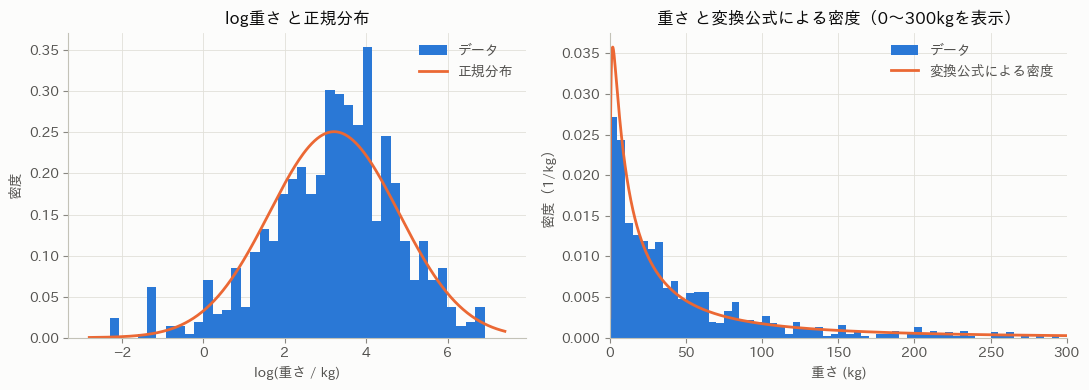

In [31]:
# Y = g(X) の密度：log重さ X ~ N(μ, σ²) とみなすと、重さ W = e^X の密度は
# f_W(w) = f_X(log w) · |d(log w)/dw| = φ((log w - μ)/σ) / (σ w)
mu_lw = df["log重さ"].mean()
sd_lw = df["log重さ"].std(ddof=0)          # 正規分布の最尤推定（n で割る）


def dens_weight_ch4(w, mu=mu_lw, sd=sd_lw):
    """変換公式で求めた重さの密度（対数正規分布）."""
    return stats.norm.pdf(np.log(w), mu, sd) / w


grid_w = np.linspace(0.05, 300, 2000)
assert np.allclose(dens_weight_ch4(grid_w), stats.lognorm.pdf(grid_w, s=sd_lw, scale=np.exp(mu_lw)))
print(f"log重さ ~ N({mu_lw:.3f}, {sd_lw:.3f}²) とみなす")
int_w = integrate.quad(dens_weight_ch4, 1e-9, 1000, points=[0.1, 1, 10, 100], limit=200)[0]
print(f"密度の積分（0〜1000kg）: {int_w:.4f}（Φ((log1000-μ)/σ) = {stats.norm.cdf((np.log(1000) - mu_lw) / sd_lw):.4f}）")
print(f"対数正規の中央値 e^μ = {np.exp(mu_lw):.2f} kg（データの中央値 {df['重さ'].median():.2f}）")
print(f"対数正規の平均 e^(μ+σ²/2) = {np.exp(mu_lw + sd_lw**2 / 2):.2f} kg（データの平均 {df['重さ'].mean():.2f}）")
print(f"P(W > 200kg): 対数正規 {stats.lognorm.sf(200, s=sd_lw, scale=np.exp(mu_lw)):.4f}, データ {(df['重さ'] > 200).mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["log重さ"], bins=40, density=True, color=PALETTE[0], label="データ")
gx = np.linspace(df["log重さ"].min() - 0.5, df["log重さ"].max() + 0.5, 300)
axes[0].plot(gx, stats.norm.pdf(gx, mu_lw, sd_lw), color=PALETTE[1], label="正規分布")
axes[0].set(title="log重さ と正規分布", xlabel="log(重さ / kg)", ylabel="密度")
axes[0].legend()
axes[1].hist(df["重さ"], bins=np.arange(0, 1005, 5), density=True, color=PALETTE[0], label="データ")
axes[1].plot(grid_w, dens_weight_ch4(grid_w), color=PALETTE[1], label="変換公式による密度")
axes[1].set(title="重さ と変換公式による密度（0〜300kgを表示）", xlabel="重さ (kg)", ylabel="密度（1/kg）", xlim=(0, 300))
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- $\hat\mu\approx3.21$、$\hat\sigma\approx1.59$ で、変換公式で得た密度は `scipy.stats.lognorm` の密度と一致し、0〜1000 kg での積分も $\Phi((\log1000-\mu)/\sigma)\approx0.990$ と一致する。
- 右図で、変換公式による密度は重さのヒストグラムの「0付近の高い山と長い右裾」をよく再現している。
- 中央値 $e^{\hat\mu}\approx24.8$ kg はデータの中央値29.5 kg より小さく、平均 $e^{\hat\mu+\hat\sigma^2/2}\approx87.8$ kg はデータの平均69.2 kg より大きい。log重さ の分布は左に裾を引き（歪度 $-0.55$）、0.1 kg など極端に軽いポケモンの小さな山もあるので、正規分布は近似にとどまる。平均 $e^{\mu+\sigma^2/2}$ は $\sigma$ に敏感で、裾の当てはまりの悪さが平均のずれとして現れる。

### 4.2 線形変換（標準化）

**問い**：合計種族値 $X$ を標準化 $Z=(X-\mu)/\sigma$ したり、偏差値 $T=50+10Z$ にしたりすると、分布の何が変わるか。

**手法の要点**
- $Y=aX+b$（$a\ne0$）では $g^{-1}(y)=(y-b)/a$ なので $f_Y(y)=\dfrac{1}{|a|}f_X\!\left(\dfrac{y-b}{a}\right)$。標準化（$a=1/\sigma,\ b=-\mu/\sigma$）では $f_Z(z)=\sigma f_X(\mu+\sigma z)$。
- $E[Z]=0$、$V[Z]=1$。$a>0$ の線形変換では歪度・尖度は変わらない（$a<0$ なら歪度の符号が反転）。分布の形は変わらず、位置と尺度だけが変わる。
- 密度の関係はカーネル密度推定で確かめる（`gaussian_kde` の帯域幅はデータの標準偏差に比例するので、$X$ と $Z$ で同じ比率の推定になる）。

（→ py 04-2）

In [32]:
# 線形変換（標準化）：Z = (X - μ)/σ。f_Z(z) = σ f_X(μ + σ z)
x_std = df["合計種族値"].to_numpy(float)
mu_x, sd_x = x_std.mean(), x_std.std()
z_std = (x_std - mu_x) / sd_x
print(f"Z の平均 {z_std.mean():.2e}, 分散 {z_std.var():.4f}")
print(f"歪度 X: {stats.skew(x_std):.4f}, Z: {stats.skew(z_std):.4f}（正の尺度倍・平行移動で不変）")
# 密度の関係をカーネル密度推定で確認（帯域幅は標準偏差に比例するので同じ比率の推定になる）
kde_x, kde_z = stats.gaussian_kde(x_std), stats.gaussian_kde(z_std)
for z0 in [-1.5, 0.0, 1.0]:
    print(f"z = {z0:+.1f}: f_Z(z) = {kde_z(z0)[0]:.4f},  σ f_X(μ+σz) = {sd_x * kde_x(mu_x + sd_x * z0)[0]:.4f}")
# 偏差値 T = 50 + 10Z（これも線形変換）
t_score = 50 + 10 * z_std
print(f"偏差値の平均 {t_score.mean():.2f}, 標準偏差 {t_score.std():.2f}")
top_t = df.assign(偏差値=t_score).nlargest(3, "合計種族値")[["名前", "合計種族値", "偏差値"]]
top_t.round(1)

Z の平均 -6.18e-17, 分散 1.0000
歪度 X: 0.0966, Z: 0.0966（正の尺度倍・平行移動で不変）
z = -1.5: f_Z(z) = 0.1777,  σ f_X(μ+σz) = 0.1777
z = +0.0: f_Z(z) = 0.3167,  σ f_X(μ+σz) = 0.3167
z = +1.0: f_Z(z) = 0.2317,  σ f_X(μ+σz) = 0.2317
偏差値の平均 50.00, 標準偏差 10.00


,名前,合計種族値,偏差値
181,メガミュウツーX,780,78.4
182,メガミュウツーY,780,78.4
444,メガレックウザ,780,78.4


**結果の読み方**
- $Z$ の平均は数値誤差の範囲で0、分散は1で、歪度は $X$ と同じ約0.097である。
- $f_Z(z)$ と $\sigma f_X(\mu+\sigma z)$ は3点すべてで一致し、線形変換の密度公式が確かめられる。
- 偏差値は平均50・標準偏差10になる。合計種族値が最大（780）のメガミュウツーX・Y、メガレックウザの偏差値は約78である。標準化しても分布の形（多峰性・裾）は変わらないので、偏差値から正規分布の上位何%かを読むのは近似にすぎない。

### 4.3 $X+Y$ の分布（畳み込み）

**問い**：攻撃 $X$ と特攻 $Y$ を独立とみなすと、和 $X+Y$ の分布はどうなるか。実際の「攻撃+特攻」の分布と比べてどう違うか。

**手法の要点**
- 整数値の $X,Y$ が独立なら、$S=X+Y$ の確率関数は畳み込み
  $$p_S(s)=\sum_x p_X(x)\,p_Y(s-x) .$$
  連続型なら $f_S(s)=\int f_X(s-t)f_Y(t)\,dt$。これは $(X,Y)\to(S,T)=(X+Y,\,Y)$ の変換（ヤコビアン1）で $T$ を積分消去したものである。
- 母関数では $G_S(s)=G_X(s)G_Y(s)$、$M_S(t)=M_X(t)M_Y(t)$（第2章）。
- 独立なら $V[S]=V[X]+V[Y]$。実際には $\mathrm{Cov}[X,Y]>0$（第3章）なので、独立を仮定した分布はばらつきを過小評価するはずである。
- 独立の仮定は、特攻の並びをランダムに並べ替える（組を崩す）ことでシミュレーションでも再現できる。

（→ py 04-3）

畳み込み（独立）: 平均 153.39, 分散 2160.4  （= V[X]+V[Y] = 2160.4）
実データの和    : 平均 153.39, 分散 2999.3  （= V[X]+V[Y]+2Cov）
P(X+Y <= 100): 独立とみなした場合 0.1269,  実データ 0.1761
P(X+Y >= 250): 独立とみなした場合 0.0312,  実データ 0.0609
P(X+Y >= 300): 独立とみなした場合 0.0029,  実データ 0.0130
並べ替え20回の和: 平均 153.39, 分散 2164.4


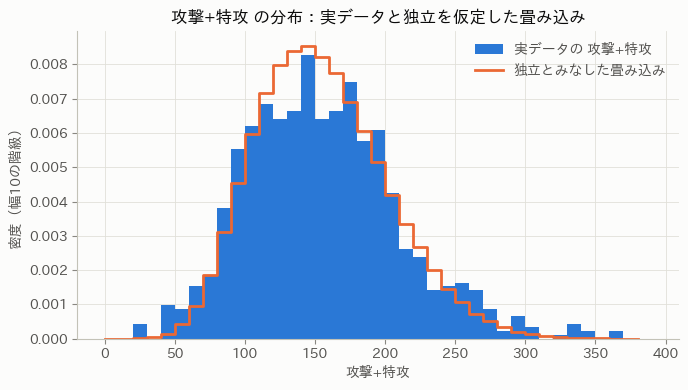

In [33]:
# X + Y の分布：攻撃 X と特攻 Y を独立とみなした畳み込み p_{X+Y}(s) = Σ_x p_X(x) p_Y(s - x) と実データの和
max_st = 256
p_atk = np.bincount(df["攻撃"], minlength=max_st) / len(df)
p_spa = np.bincount(df["特攻"], minlength=max_st) / len(df)
p_conv = np.convolve(p_atk, p_spa)                     # 独立なら X+Y の確率関数
s_vals = np.arange(len(p_conv))
sum_obs = (df["攻撃"] + df["特攻"]).to_numpy()
mean_conv = np.sum(s_vals * p_conv)
var_conv = np.sum((s_vals - mean_conv) ** 2 * p_conv)
print(f"畳み込み（独立）: 平均 {mean_conv:.2f}, 分散 {var_conv:.1f}  （= V[X]+V[Y] = {df['攻撃'].var(ddof=0) + df['特攻'].var(ddof=0):.1f}）")
print(f"実データの和    : 平均 {sum_obs.mean():.2f}, 分散 {sum_obs.var():.1f}  （= V[X]+V[Y]+2Cov）")
for thr in [100, 250, 300]:
    op = "<=" if thr == 100 else ">="
    p_ind = p_conv[: thr + 1].sum() if thr == 100 else p_conv[thr:].sum()
    p_obs = (sum_obs <= thr).mean() if thr == 100 else (sum_obs >= thr).mean()
    print(f"P(X+Y {op} {thr}): 独立とみなした場合 {p_ind:.4f},  実データ {p_obs:.4f}")
# 独立なら、特攻の並びをランダムに入れ替えた和と同じ分布になる（シミュレーションで確認）
rng_ch4 = get_rng()
perm_sums = np.concatenate([df["攻撃"].to_numpy() + rng_ch4.permutation(df["特攻"].to_numpy()) for _ in range(20)])
print(f"並べ替え20回の和: 平均 {perm_sums.mean():.2f}, 分散 {perm_sums.var():.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
bw = 10
edges_s = np.arange(0, 400, bw)
ax.hist(sum_obs, bins=edges_s, density=True, color=PALETTE[0], label="実データの 攻撃+特攻")
conv_binned = np.add.reduceat(p_conv[:edges_s[-1]], edges_s[:-1]) / bw
ax.step(edges_s[:-1], conv_binned, where="post", color=PALETTE[1], lw=2, label="独立とみなした畳み込み")
ax.set(title="攻撃+特攻 の分布：実データと独立を仮定した畳み込み", xlabel="攻撃+特攻", ylabel="密度（幅10の階級）")
ax.legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 畳み込みの平均は実データと同じ約153.4（期待値の和は独立でなくても成り立つ）だが、分散は独立の場合 約2160 に対し実データ 約2999 と、実データのほうが約4割大きい（独立を仮定すると約3割の過小評価）。差は $2\,\mathrm{Cov}[X,Y]$ にあたる。並べ替えシミュレーションの分散（約2164）は畳み込みとほぼ同じである。
- そのため裾の確率が大きく違う：$P(S\ge250)$ は独立なら約0.031、実データ約0.061、$P(S\ge300)$ は約0.003に対し約0.013（4倍以上）。$P(S\le100)$ も約0.13に対し約0.18である。
- 図でも、実データは畳み込みより中央が低く、両裾が厚い。「攻撃も特攻も高い（低い）」ポケモンが独立の場合より多いためで、独立でない変数の和に独立の公式を当てはめると、極端な値の確率を過小評価する。

### 4.4 ヤコビアン（2変数の変換）

**問い**：(1) (攻撃 $X$, 特攻 $Y$) を (和 $U=X+Y$, 差 $V=X-Y$) に変換した密度は。(2) (log高さ $S$, log重さ $T$) が2変量正規分布なら、(高さ $H$, 重さ $W$) の密度は。

**手法の要点**
- $(X,Y)$ の同時密度を $f_{X,Y}$ とし、$(u,v)=\phi(x,y)$ が1対1で逆変換 $x=x(u,v),\ y=y(u,v)$ が微分可能なら
  $$f_{U,V}(u,v)=f_{X,Y}\bigl(x(u,v),\,y(u,v)\bigr)\,|J|,\qquad J=\det\begin{pmatrix}\partial x/\partial u & \partial x/\partial v\\ \partial y/\partial u & \partial y/\partial v\end{pmatrix}.$$
- (1) $x=(u+v)/2,\ y=(u-v)/2$ より $J=\det\begin{pmatrix}1/2&1/2\\1/2&-1/2\end{pmatrix}=-1/2$、$|J|=1/2$。$(X,Y)\sim N(\boldsymbol\mu,\Sigma)$ なら $(U,V)^\top=A(X,Y)^\top$（$A=\begin{pmatrix}1&1\\1&-1\end{pmatrix}$）は $N(A\boldsymbol\mu,A\Sigma A^\top)$ にしたがうので、公式の値がこの密度と一致するはずである。また $\mathrm{Cov}[U,V]=V[X]-V[Y]$。
- (2) $s=\log h,\ t=\log w$ より $|J|=1/(hw)$ で、$f_{H,W}(h,w)=f_{S,T}(\log h,\log w)/(hw)$。これを領域 $\{h\le1,\ w\le30\}$ で数値積分した値は、$(S,T)$ の分布関数 $F_{S,T}(\log1,\log30)$ と一致するはずである。
- 2変量正規分布は、平均ベクトルと（$n$ で割る）分散共分散行列をデータに合わせて当てはめる。攻撃・特攻は右に歪んだ整数値なので、(1) は変換公式の確認のためのモデルである。

（→ py 04-4）

In [34]:
# ヤコビアン（2変数の変換）
# (1) 線形変換 U = X + Y, V = X - Y（X=攻撃, Y=特攻 に2変量正規分布を当てはめる）
#     逆変換 x = (u+v)/2, y = (u-v)/2、ヤコビアン J = det[[1/2, 1/2], [1/2, -1/2]] = -1/2
xy = df[["攻撃", "特攻"]].to_numpy(float)
mu_xy = xy.mean(axis=0)
cov_xy = np.cov(xy, rowvar=False, ddof=0)
mvn_xy = stats.multivariate_normal(mu_xy, cov_xy)
A_uv = np.array([[1, 1], [1, -1]])
mvn_uv = stats.multivariate_normal(A_uv @ mu_xy, A_uv @ cov_xy @ A_uv.T)   # 線形変換後の正規分布
J_uv = np.linalg.det(np.array([[0.5, 0.5], [0.5, -0.5]]))
print(f"ヤコビアン J = {J_uv:.2f}")
for u0, v0 in [(150, 0), (200, 40), (120, -30)]:
    f_change = mvn_xy.pdf([(u0 + v0) / 2, (u0 - v0) / 2]) * abs(J_uv)
    print(f"(u, v) = ({u0}, {v0}): f_XY(x(u,v), y(u,v))·|J| = {f_change:.3e},  N(Aμ, AΣAᵀ) の密度 = {mvn_uv.pdf([u0, v0]):.3e}")
uv = xy @ A_uv.T
print(f"Cov[U, V] = V[X] - V[Y] = {cov_xy[0, 0] - cov_xy[1, 1]:.1f}（データ {np.cov(uv, rowvar=False, ddof=0)[0, 1]:.1f}）")

# (2) 非線形変換：(log高さ, log重さ) ~ 2変量正規 とみなし、(H, W) = (e^S, e^T) の密度
#     f_{H,W}(h, w) = f_{S,T}(log h, log w) · 1/(h w)  （ヤコビアン |∂(s,t)/∂(h,w)| = 1/(hw)）
st = df[["log高さ", "log重さ"]].to_numpy(float)
mvn_st = stats.multivariate_normal(st.mean(axis=0), np.cov(st, rowvar=False, ddof=0))


def dens_hw_ch4(w, h):
    return mvn_st.pdf([np.log(h), np.log(w)]) / (h * w)


h0, w0 = 1.0, 30.0
p_int, _ = integrate.dblquad(dens_hw_ch4, 1e-3, h0, 1e-3, w0)      # ∫∫_{h≤1, w≤30} f(h,w) dw dh（0付近の寄与は無視できる）
p_cdf = mvn_st.cdf([np.log(h0), np.log(w0)])
p_emp = ((df["高さ"] <= h0) & (df["重さ"] <= w0)).mean()
print(f"\nP(高さ ≤ {h0} m, 重さ ≤ {w0} kg): 変換した密度の数値積分 {p_int:.4f},"
      f"  2変量正規のCDF {p_cdf:.4f},  データ {p_emp:.4f}")

ヤコビアン J = -0.50
(u, v) = (150, 0): f_XY(x(u,v), y(u,v))·|J| = 7.842e-05,  N(Aμ, AΣAᵀ) の密度 = 7.842e-05
(u, v) = (200, 40): f_XY(x(u,v), y(u,v))·|J| = 3.599e-05,  N(Aμ, AΣAᵀ) の密度 = 3.599e-05
(u, v) = (120, -30): f_XY(x(u,v), y(u,v))·|J| = 3.928e-05,  N(Aμ, AΣAᵀ) の密度 = 3.928e-05
Cov[U, V] = V[X] - V[Y] = -44.7（データ -44.7）



P(高さ ≤ 1.0 m, 重さ ≤ 30.0 kg): 変換した密度の数値積分 0.4420,  2変量正規のCDF 0.4420,  データ 0.4457


**結果の読み方**
- (1) 3点すべてで $f_{X,Y}(x(u,v),y(u,v))\cdot|J|$ と $N(A\boldsymbol\mu,A\Sigma A^\top)$ の密度が一致する。$|J|=1/2$ を忘れると密度が2倍になり、全体の積分が1にならない。
- $\mathrm{Cov}[U,V]=V[X]-V[Y]\approx-45$ で、攻撃と特攻の分散が近いため、和（総合的な攻撃力）と差（物理寄りか特殊寄りか）はほぼ無相関である。
- (2) 変換した密度の数値積分と2変量正規分布の分布関数はどちらも約0.442で一致し、データの割合（約0.446）にも近い。高さ1 m 以下かつ重さ30 kg 以下のポケモンは約44%である。

### 4.5 Box-Cox 変換

**問い**：重さ・高さ・孵化を正規分布に近づける Box-Cox 変換の $\lambda$ はいくらか。Q-Q プロットで正規性は改善するか。

**手法の要点**
- 正の値 $x$ に対する Box-Cox 変換は
  $$y^{(\lambda)}=\begin{cases}\dfrac{x^\lambda-1}{\lambda}&(\lambda\ne0)\\[4pt]\log x&(\lambda=0)\end{cases}$$
  で、$\lambda\to0$ の極限が対数変換になる（$\lambda=1$ は平行移動のみ、$\lambda=1/2$ は平方根型、$\lambda=-1$ は逆数型）。
- $y_i^{(\lambda)}$ が $N(\mu,\sigma^2)$ にしたがうと仮定し、$\mu,\sigma^2$ を最尤推定値で置き換えたプロファイル対数尤度（定数を除く）
  $$\ell(\lambda)=-\frac n2\log\hat\sigma^2(\lambda)+(\lambda-1)\sum_{i=1}^n\log x_i$$
  を最大にする $\lambda$ を選ぶ。第2項は変換のヤコビアン $\prod_i|dy_i/dx_i|=\prod_i x_i^{\lambda-1}$ から来る。$\hat\sigma^2(\lambda)$ は変換後の $n$ で割る分散。
- $\lambda$ の95%信頼区間は、尤度比 $2\{\ell(\hat\lambda)-\ell(\lambda)\}$ が近似的に自由度1のカイ二乗分布にしたがうことから、$2\{\ell(\hat\lambda)-\ell(\lambda)\}\le\chi^2_1(0.05)=3.84$ となる $\lambda$ の範囲とする（`scipy.stats.boxcox(x, alpha=0.05)`）。
- Q-Q プロットは、標準正規分布の分位点に対してデータの分位点を並べた図で、正規分布なら直線上に並ぶ。

（→ py 04-5）

95%信頼区間は尤度比 2{ℓ(λ̂)-ℓ(λ)} ≤ χ²_1(0.05) = 3.84（自由度1のカイ二乗分布の上側5%点）となる λ の範囲


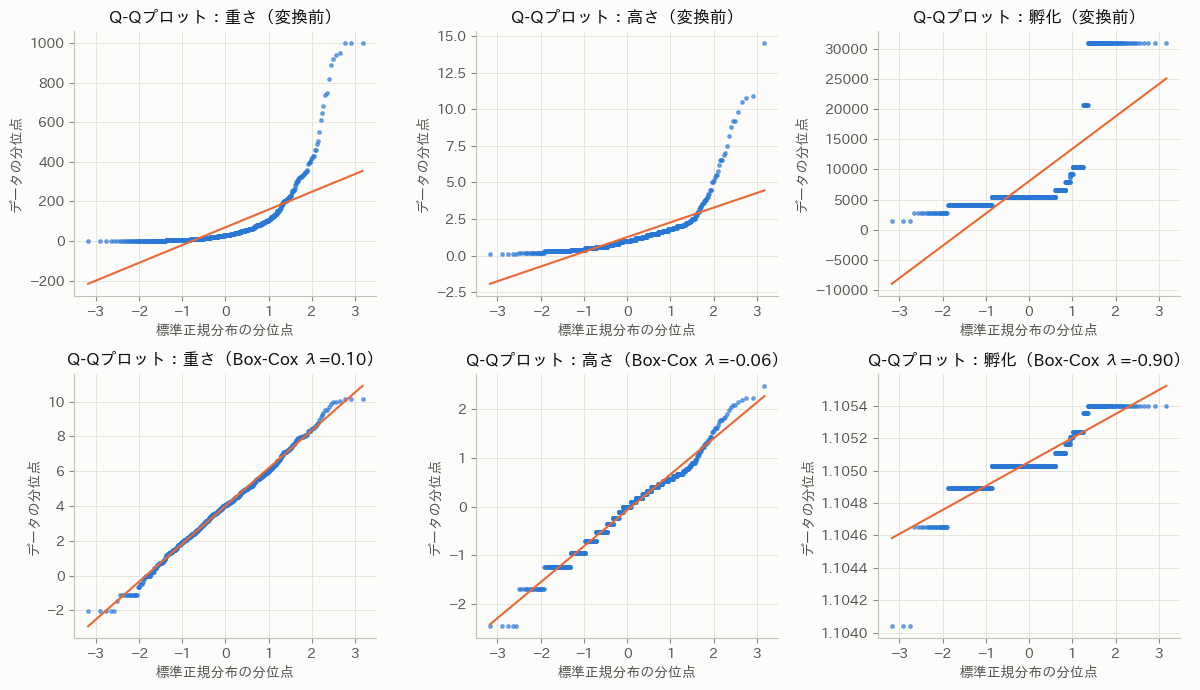

,λ(scipy),λ(手計算),95%CI下限,95%CI上限,歪度(変換前),歪度(変換後),歪度(log),値の種類
重さ,0.104,0.104,0.072,0.137,4.335,0.007,-0.546,452.0
高さ,-0.055,-0.055,-0.121,0.009,4.503,-0.007,0.149,59.0
孵化,-0.905,-0.905,-0.987,-0.822,2.493,-0.282,1.736,11.0


In [35]:
# Box-Cox 変換：y(λ) = (x^λ - 1)/λ（λ≠0）, log x（λ=0）。λ を最尤推定する


def boxcox_profile_ll_ch4(lam, x):
    """Box-Cox 変換後が正規分布とみなしたときのプロファイル対数尤度（定数項を除く）."""
    y = np.log(x) if abs(lam) < 1e-12 else (x**lam - 1) / lam
    return -len(x) / 2 * np.log(y.var()) + (lam - 1) * np.sum(np.log(x))


bc_rows, bc_data = {}, {}
for c in ["重さ", "高さ", "孵化"]:
    x = df[c].to_numpy(float)
    y_bc, lam_sp, ci_bc = stats.boxcox(x, alpha=0.05)          # scipy の最尤推定と95%信頼区間
    lam_hand = optimize.minimize_scalar(lambda l: -boxcox_profile_ll_ch4(l, x), bounds=(-3, 3), method="bounded").x
    bc_data[c] = (x, y_bc, lam_sp)
    bc_rows[c] = {"λ(scipy)": lam_sp, "λ(手計算)": lam_hand, "95%CI下限": ci_bc[0], "95%CI上限": ci_bc[1],
                  "歪度(変換前)": stats.skew(x), "歪度(変換後)": stats.skew(y_bc),
                  "歪度(log)": stats.skew(np.log(x)), "値の種類": len(np.unique(x))}
bc_tab = pd.DataFrame(bc_rows).T
assert np.allclose(bc_tab["λ(scipy)"], bc_tab["λ(手計算)"], atol=1e-3)
print("95%信頼区間は尤度比 2{ℓ(λ̂)-ℓ(λ)} ≤ χ²_1(0.05) = 3.84（自由度1のカイ二乗分布の上側5%点）となる λ の範囲")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for j, (c, (x, y_bc, lam)) in enumerate(bc_data.items()):
    for i, (v, lab) in enumerate([(x, f"{c}（変換前）"), (y_bc, f"{c}（Box-Cox λ={lam:.2f}）")]):
        (osm, osr), (slope, icpt, _) = stats.probplot(v, dist="norm")
        axes[i, j].scatter(osm, osr, s=6, color=PALETTE[0], alpha=0.6)
        axes[i, j].plot(osm, slope * osm + icpt, color=PALETTE[1], lw=1.5)
        axes[i, j].set(title=f"Q-Qプロット：{lab}", xlabel="標準正規分布の分位点", ylabel="データの分位点")
fig.tight_layout()
plt.show()
bc_tab.round(3)

**結果の読み方**
- 手計算の $\hat\lambda$ は scipy と一致した。重さ $\hat\lambda\approx0.10$（95%CI 約0.07〜0.14）、高さ $\hat\lambda\approx-0.06$（約 $-0.12$〜$0.01$）、孵化 $\hat\lambda\approx-0.90$（約 $-0.99$〜$-0.82$）である。
- 高さは信頼区間が0を含み、対数変換で十分である。重さは0を含まないが $\lambda\approx0.1$ は対数に近く、Box-Cox 変換後の歪度は約0.01と、対数（$-0.55$）より左右対称になる。
- Q-Q プロットでは、重さ・高さは変換前に強く上に反り返っていたのが、変換後はほぼ直線に並ぶ。高さは0.1 m 刻みの値なので、変換後も階段状になる。
- 孵化は11種類の値しかとらず、変換後も階段状のままで、正規分布にはならない（歪度は2.49から $-0.28$ に下がるが、変換は値の間隔を変えるだけで、値の種類は増やせない）。Box-Cox 変換は、連続で正の値をとる変数に使うのが前提である。

### 4.6 ロジット変換

**問い**：$p=\text{捕獲率}/255\in(0,1]$ をロジット変換すると、合計種族値との関係はどう見えるか。

**手法の要点**
- ロジット変換 $\operatorname{logit}p=\log\dfrac{p}{1-p}$ は $(0,1)$ を実数全体に写す狭義単調増加関数で、逆変換はロジスティック関数 $p=1/(1+e^{-\eta})$ である。比率を線形モデルで扱うとき（第18章のロジスティック回帰）に使う。
- $p=1$（捕獲率255、78匹）では $\operatorname{logit}p=+\infty$ となるので、捕獲率を $c$ として 0.5 を加えた経験ロジット $\log\{(c+0.5)/(255-c+0.5)\}$ を使う。0.5の選び方は慣習で、結果は端の値の扱いに依存する。
- 捕獲率/255 はゲーム内の捕獲確率の計算に使う値で、それ自体が「確率」ではない点に注意する。
- 単調増加な変換では順位が変わらないので、スピアマンの順位相関は変換前後で同じになる。一方、ピアソンの相関係数は変わる。

（→ py 04-6）

p = 1 の匹数: 78（通常のロジットは +∞ になる）
経験ロジットの範囲: -4.28 〜 6.24
相関係数 合計種族値 と 捕獲率: -0.701
相関係数 合計種族値 と 経験ロジット: -0.650
歪度 捕獲率: 0.941,  経験ロジット: 1.393
スピアマン順位相関: 捕獲率 -0.713, 経験ロジット -0.713
捕獲率の上位の値と匹数: {45: 303, 255: 78, 190: 77, 3: 76, 75: 68}


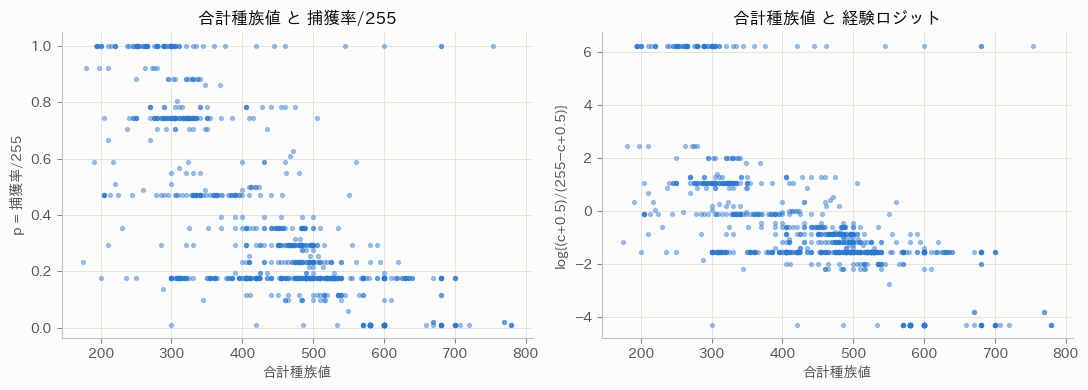

In [36]:
# ロジット変換：p = 捕獲率/255 ∈ (0, 1] → logit p = log(p/(1-p))
# p = 1（捕獲率255）では logit が発散するので、0.5 を加える経験ロジット log((c+0.5)/(255-c+0.5)) を使う
cr = df["捕獲率"].to_numpy(float)
p_cr = cr / 255
logit_cr = np.log((cr + 0.5) / (255 - cr + 0.5))
print(f"p = 1 の匹数: {(p_cr == 1).sum()}（通常のロジットは +∞ になる）")
print(f"経験ロジットの範囲: {logit_cr.min():.2f} 〜 {logit_cr.max():.2f}")
# 逆変換（ロジスティック関数）で元に戻ることの確認（p < 1 の行で通常のロジット）
m_lt1 = p_cr < 1
lg = np.log(p_cr[m_lt1] / (1 - p_cr[m_lt1]))
assert np.allclose(1 / (1 + np.exp(-lg)), p_cr[m_lt1])
tot_cr = df["合計種族値"].to_numpy(float)
print(f"相関係数 合計種族値 と 捕獲率: {np.corrcoef(tot_cr, cr)[0, 1]:.3f}")
print(f"相関係数 合計種族値 と 経験ロジット: {np.corrcoef(tot_cr, logit_cr)[0, 1]:.3f}")
print(f"歪度 捕獲率: {stats.skew(cr):.3f},  経験ロジット: {stats.skew(logit_cr):.3f}")
# 単調増加な変換では順位は変わらないので、スピアマンの順位相関は変換前後で同じ
print(f"スピアマン順位相関: 捕獲率 {stats.spearmanr(tot_cr, cr)[0]:.3f}, 経験ロジット {stats.spearmanr(tot_cr, logit_cr)[0]:.3f}")
print("捕獲率の上位の値と匹数:", df["捕獲率"].value_counts().head(5).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(tot_cr, p_cr, s=8, alpha=0.4, color=PALETTE[0])
axes[0].set(title="合計種族値 と 捕獲率/255", xlabel="合計種族値", ylabel="p = 捕獲率/255")
axes[1].scatter(tot_cr, logit_cr, s=8, alpha=0.4, color=PALETTE[0])
axes[1].set(title="合計種族値 と 経験ロジット", xlabel="合計種族値", ylabel="log{(c+0.5)/(255−c+0.5)}")
fig.tight_layout()
plt.show()

**結果の読み方**
- 合計種族値との相関係数は、捕獲率そのままで $-0.70$、経験ロジットで $-0.65$ と、ロジット変換で直線的な関係はむしろ弱くなった。歪度も0.94から1.39に大きくなる。
- 原因は捕獲率255の78匹で、経験ロジットでは約6.2と他から大きく離れた値になる（右図の上端の列）。上限に張りついた値を人為的な0.5で補正すると、その値が外れ値として効いてしまう。実際、この78匹を除くと経験ロジットと合計種族値の相関は約 $-0.72$ となり、変換前（255を除いた捕獲率で約 $-0.70$）より強くなる。
- スピアマンの順位相関は変換前後とも $-0.71$ で同じである。単調変換で変わるのは「直線性」と「分布の形」であり、順位でみた関係の強さは変わらない。
- 捕獲率は45（303匹）・255・190・3・75 など少数の値に集中しており、どう変換しても連続的な分布にはならない。

### まとめ

- log重さ を正規分布とみなすと、変換公式から得た対数正規分布の密度は重さのヒストグラムをよく再現する。ただし平均 $e^{\mu+\sigma^2/2}$ は裾の当てはまりに敏感で、データの平均とは一致しない。
- 攻撃と特攻を独立とみなした畳み込みは、平均は正しいが分散を約3割過小評価し、「攻撃+特攻 ≥ 300」の確率を4分の1以下に見積もる。和の分布では独立性の仮定が裾の確率を大きく左右する。
- 2変数の変換ではヤコビアンの絶対値をかけ忘れないこと。線形変換では正規分布の性質、非線形変換では数値積分と分布関数の一致で確かめられた。
- Box-Cox 変換の $\lambda$ は重さ約0.10、高さ約 $-0.06$ で、どちらも対数変換に近い。変換後の Q-Q プロットはほぼ直線になる。孵化のように値の種類が少ない変数には効果が限られる。
- 捕獲率のロジット変換は、上限255の扱いのため相関を弱めた。変換は「何のために、どの値の扱いを決めて使うか」を明確にしてから選ぶ必要がある。

## 第5章 離散型分布

### 章の概要

整数値をとる確率変数の代表的な分布を、ポケモンの「タマゴのオスの数」「ボールを投げて捕まるまでの回数」「図鑑から抜き出したときの特定タイプの数」などで確かめる。
- **目的**：状況（試行の独立性・復元か非復元か・回数を固定するか成功数を固定するか）に応じて適切な分布を選び、その平均・分散を使えるようにする。
- **考え方**：各分布をシミュレーションで生成し、理論の確率関数・平均・分散と一致することを確認する。分布どうしの関係（二項→ポアソン、超幾何→二項、幾何の和→負の二項）も数値で見る。
- **つながり**：第2章の確率関数・母関数、第3章の期待値・分散の計算を具体的な分布に当てはめる。第7章では二項分布の正規近似（中心極限定理）を扱う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 5.1 | 離散一様分布 | 図鑑番号を等確率で1つ選ぶと、平均・分散はいくらか |
| 5.2 | ベルヌーイ分布・二項分布 | 雄率 $p$ のポケモンのタマゴ6個のうち、オスは何個か |
| 5.3 | 超幾何分布 | 920匹から $n$ 匹を非復元で選ぶと、みずタイプは何匹含まれるか |
| 5.4 | ポアソン分布（少数の法則） | 捕獲率3のポケモンにボールを100回投げて何回成功するか |
| 5.5 | 幾何分布 | 捕まるまでに何回失敗するか。無記憶性は成り立つか |
| 5.6 | 負の二項分布・再生性 | 3匹捕まえるまでに何回失敗するか |
| 5.7 | 多項分布 | タイプ構成比で30匹を選ぶと、タイプ別の数はどう相関するか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `図鑑番号` | 整数（1〜807） | 離散一様分布の台 |
| `雄率` | 量的（0〜1の7値） | タマゴがオスになる確率 $p$ として使う |
| `捕獲率` | 整数（3〜255） | 簡略化モデルで捕獲の成功確率 $p=\text{捕獲率}/255$ に変換する |
| `タイプ1` | 質的（18水準） | 超幾何分布・多項分布の「当たり」やカテゴリ |

- **対象の行**：全920行。`雄率` を使う節では、その値をもつポケモンの例として行数を示すだけで、分布は理論値 $p$ から生成する。
- **加工**：5.7 ではタイプ1を上位3タイプ（みず・ノーマル・くさ）と「その他」の4区分にまとめる。
- **データの性質と注意点**：この章は「データを分布の母数や母集団として使うシミュレーション」であり、データそのものが特定の分布に従うかは問わない。
  **捕獲の節（5.4〜5.6）は簡略化モデル**で、実際のゲームの捕獲式は残りHP・ボールの種類・状態異常などで成功確率が変わる。ここでは「1回ごとの成功確率が $p=\text{捕獲率}/255$ で一定、各回は独立」と仮定する。

（→ py 05-0：使う列の値の分布を表示する）

In [37]:
# この章で使う列の要約
d05 = df[["図鑑番号", "雄率", "捕獲率", "タイプ1"]]
print("図鑑番号の範囲:", d05["図鑑番号"].min(), "〜", d05["図鑑番号"].max(),
      " 種類数:", d05["図鑑番号"].nunique())
print("\n雄率の値ごとの行数（NaN は性別不明）")
print(d05["雄率"].value_counts(dropna=False).sort_index().to_string())
print("\n捕獲率の要約")
print(d05["捕獲率"].describe().round(1).to_string())
print("\nタイプ1の上位5水準")
print(d05["タイプ1"].value_counts().head(5).to_string())

図鑑番号の範囲: 1 〜 807  種類数: 807

雄率の値ごとの行数（NaN は性別不明）
雄率
0.000     32
0.125      4
0.250     27
0.500    565
0.750     15
0.875    123
1.000     24
NaN      130

捕獲率の要約
count    920.0
mean      94.0
std       75.6
min        3.0
25%       45.0
50%       60.0
75%      127.0
max      255.0

タイプ1の上位5水準
タイプ1
みず      124
ノーマル    110
くさ       83
むし       78
エスパー     67


### 5.1 離散一様分布

**問い**：全国図鑑番号 $1,\dots,807$ から1つを等確率で選ぶ。番号の平均と分散はいくらか。そのポケモンの世代は一様か。

**手法の要点**
- $X$ が $\{1,2,\dots,k\}$ 上の離散一様分布に従うとき $P(X=x)=1/k\ (x=1,\dots,k)$。
- $E[X]=\dfrac{k+1}{2},\quad V[X]=\dfrac{k^2-1}{12}$。
- 一様に選んだ番号を関数で変換した値（ここでは世代）は一般に一様ではない。世代 $g$ になる確率は（世代 $g$ の種類数）$/k$ である。

（→ py 05-1：10000回の一様乱数で平均・分散と世代の分布を確認する）

In [38]:
# 離散一様分布: 全国図鑑番号 1〜k を等確率で1つ選ぶ
k_uni = int(df["図鑑番号"].max())            # 807
rng = get_rng()
draws_uni = rng.integers(1, k_uni + 1, size=10000)
print(f"k = {k_uni}")
print(f"期待値  理論 (k+1)/2      = {(k_uni + 1) / 2:.1f}   シミュレーション = {draws_uni.mean():.1f}")
print(f"分散    理論 (k^2-1)/12   = {(k_uni**2 - 1) / 12:.0f}  シミュレーション = {draws_uni.var():.0f}")

# 図鑑番号が一様でも、その番号の「世代」は一様ではない（世代ごとの種類数が違う）
gen_of_no = pd.cut(draws_uni, GEN_BOUNDS, labels=range(1, 8)).astype(int)
gen_theory = np.diff(np.minimum(GEN_BOUNDS, k_uni)) / k_uni   # 第7世代は 722〜807 の86種（GEN_BOUNDS の上限809より小さい）
pd.DataFrame({"理論確率 (種類数/807)": gen_theory,
              "シミュレーション": pd.Series(gen_of_no).value_counts(normalize=True).sort_index().values},
             index=pd.Index(range(1, 8), name="世代")).round(3)

k = 807
期待値  理論 (k+1)/2      = 404.0   シミュレーション = 401.1
分散    理論 (k^2-1)/12   = 54271  シミュレーション = 53760


,理論確率 (種類数/807),シミュレーション
世代,,
1,0.187,0.188
2,0.124,0.128
3,0.167,0.171
4,0.133,0.132
5,0.193,0.192
6,0.089,0.086
7,0.107,0.103


**結果の読み方**
- $k=807$ で理論平均404・理論分散約54271に対し、シミュレーション（10000回）は平均約401・分散約53760で、乱数のぶれの範囲で一致する。
- 世代の確率は種類数に比例し、第5世代（156種）が約0.19、第6世代（72種）が約0.09と一様ではない。

### 5.2 ベルヌーイ分布・二項分布

**問い**：雄率 $p$ のポケモンのタマゴを $n=6$ 個孵したとき、オスの数はどう分布するか。

**手法の要点**
- 成功確率 $p$ の1回の試行の成功数 $X\in\{0,1\}$ はベルヌーイ分布 $\mathrm{Bin}(1,p)$ に従い、$E[X]=p,\ V[X]=p(1-p)$。
- 独立なベルヌーイ試行を $n$ 回行ったときの成功数 $X$ は二項分布 $\mathrm{Bin}(n,p)$：
  $$P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}\quad(x=0,1,\dots,n),\qquad E[X]=np,\ V[X]=np(1-p).$$
- 前提：各タマゴの性別が独立で、確率 $p$ が一定であること（ゲームの仕様として自然な仮定）。
- 雄率の多い値 $p=0.5$（565行）と $p=0.875$（123行、御三家など）を使う。

（→ py 05-2：10000組のタマゴ6個をシミュレーションし、理論の確率関数と比べる）

p = 0.5: 1個のベルヌーイ 平均 0.497（理論 0.5） 分散 0.250（理論 0.250）
          二項   平均 2.985（理論 np = 3.000） 分散 1.522（理論 np(1-p) = 1.500）
p = 0.875: 1個のベルヌーイ 平均 0.876（理論 0.875） 分散 0.109（理論 0.109）
          二項   平均 5.243（理論 np = 5.250） 分散 0.658（理論 np(1-p) = 0.656）


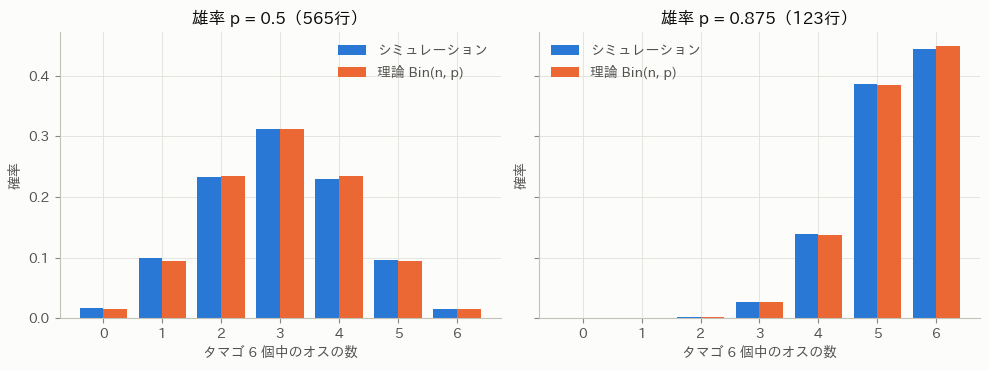

In [39]:
# ベルヌーイ分布・二項分布: 雄率 p のポケモンのタマゴ n 個に含まれるオスの数
rng = get_rng()
n_egg = 6
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, p_male in zip(axes, [0.5, 0.875]):
    eggs = rng.random((10000, n_egg)) < p_male          # 各タマゴは独立なベルヌーイ試行
    males = eggs.sum(axis=1)
    x = np.arange(n_egg + 1)
    sim_pmf = np.bincount(males, minlength=n_egg + 1) / len(males)
    ax.bar(x - 0.2, sim_pmf, width=0.4, color=PALETTE[0], label="シミュレーション")
    ax.bar(x + 0.2, stats.binom.pmf(x, n_egg, p_male), width=0.4, color=PALETTE[1], label="理論 Bin(n, p)")
    ax.set(title=f"雄率 p = {p_male}（{(df['雄率'] == p_male).sum()}行）",
           xlabel=f"タマゴ {n_egg} 個中のオスの数", ylabel="確率")
    ax.legend()
    print(f"p = {p_male}: 1個のベルヌーイ 平均 {eggs[:, 0].mean():.3f}（理論 {p_male}）"
          f" 分散 {eggs[:, 0].var():.3f}（理論 {p_male * (1 - p_male):.3f}）")
    print(f"          二項   平均 {males.mean():.3f}（理論 np = {n_egg * p_male:.3f}）"
          f" 分散 {males.var():.3f}（理論 np(1-p) = {n_egg * p_male * (1 - p_male):.3f}）")
fig.tight_layout()
plt.show()

**結果の読み方**
- どちらの $p$ でもシミュレーションの棒と $\mathrm{Bin}(6,p)$ の確率関数はほぼ重なり、平均 $np$（3.0, 5.25）・分散 $np(1-p)$（1.5, 約0.66）とも一致する。
- $p=0.5$ では左右対称、$p=0.875$ では6個すべてオスが最も起こりやすく（約0.45）、分布は左に裾を引く。

### 5.3 超幾何分布

**問い**：920匹から $n$ 匹を**非復元**で選んだとき、タイプ1がみずのポケモンは何匹含まれるか。復元抽出（二項分布）とどれだけ違うか。

**手法の要点**
- 大きさ $N$ の母集団に当たりが $M$ 個あり、$n$ 個を非復元抽出したときの当たりの数 $X$ は超幾何分布 $\mathrm{HG}(N,M,n)$：
  $$P(X=x)=\frac{\binom{M}{x}\binom{N-M}{n-x}}{\binom{N}{n}},\qquad E[X]=n\frac{M}{N},\quad V[X]=n\frac{M}{N}\left(1-\frac{M}{N}\right)\frac{N-n}{N-1}.$$
- 分散の最後の因子 $\dfrac{N-n}{N-1}$ が有限母集団修正で、二項分布 $\mathrm{Bin}(n,M/N)$ の分散より小さくなる。
- $n$ と $M/N$ を固定して $N\to\infty$ とすると $\mathrm{Bin}(n,M/N)$ に近づく。$n/N$ が小さいときは二項近似でよい。
- ここでは $N=920$、$M=124$（みず）。$n=20$（$n/N\approx 2\%$）と $n=300$（約33%）で比べる。

（→ py 05-3：データの行を実際に非復元抽出して数え、超幾何分布・二項近似と比べる）

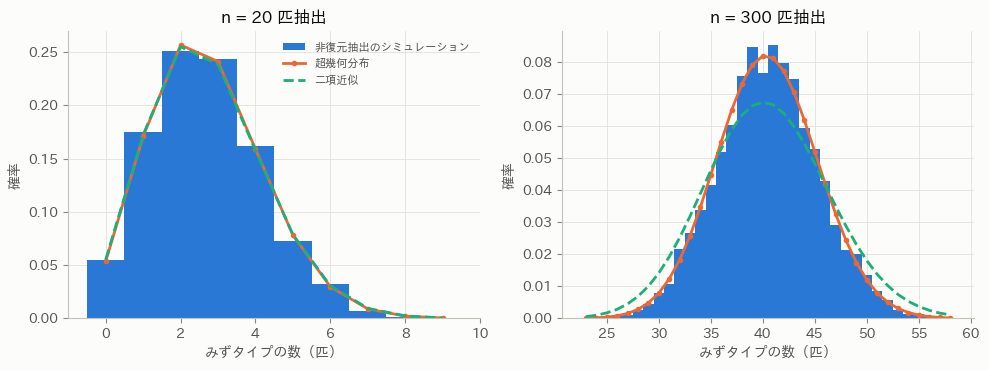

N = 920, M = 124（みず）, M/N = 0.1348


,n,平均(シミュ),平均 nM/N,分散(シミュ),超幾何の分散,二項の分散,修正項 (N-n)/(N-1)
0,20,2.676,2.696,2.253,2.284,2.332,0.979
1,300,40.491,40.435,23.418,23.602,34.985,0.675


In [40]:
# 超幾何分布: 920匹から n 匹を非復元抽出したときの「タイプ1がみず」の数
N_pop = len(df)
is_water = (df["タイプ1"] == "みず").to_numpy()
M_water = int(is_water.sum())
rng = get_rng()
rows_hg = []
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, n_draw in zip(axes, [20, 300]):
    # 実際にデータの行を非復元で選ぶ
    counts = np.array([is_water[rng.choice(N_pop, n_draw, replace=False)].sum() for _ in range(4000)])
    hg = stats.hypergeom(N_pop, M_water, n_draw)       # scipy の引数は (母集団, 当たり数, 抽出数)
    bn = stats.binom(n_draw, M_water / N_pop)
    x = np.arange(counts.min(), counts.max() + 1)
    ax.hist(counts, bins=np.arange(x[0] - 0.5, x[-1] + 1.5), density=True,
            color=PALETTE[0], label="非復元抽出のシミュレーション")
    ax.plot(x, hg.pmf(x), "o-", ms=3, color=PALETTE[1], label="超幾何分布")
    ax.plot(x, bn.pmf(x), "--", color=PALETTE[2], label="二項近似")
    ax.set(title=f"n = {n_draw} 匹抽出", xlabel="みずタイプの数（匹）", ylabel="確率")
    fpc = (N_pop - n_draw) / (N_pop - 1)             # 有限母集団修正
    p_w = M_water / N_pop
    rows_hg.append({"n": n_draw, "平均(シミュ)": counts.mean(), "平均 nM/N": n_draw * p_w,
                    "分散(シミュ)": counts.var(), "超幾何の分散": n_draw * p_w * (1 - p_w) * fpc,
                    "二項の分散": n_draw * p_w * (1 - p_w), "修正項 (N-n)/(N-1)": fpc})
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"N = {N_pop}, M = {M_water}（みず）, M/N = {M_water / N_pop:.4f}")
pd.DataFrame(rows_hg).round(3)

**結果の読み方**
- $n=20$ では修正項が約0.98で、超幾何分布と二項近似の確率関数はほとんど区別できない。
- $n=300$ では修正項が約0.68となり、超幾何分布の分散（約23.6）は二項分布（約35.0）の7割弱しかない。シミュレーションの分散（約23.4）は超幾何分布と一致し、二項近似では裾を過大に見積もる。
- 平均はどちらの分布も $nM/N$ で同じであり、違いが出るのは分散だけである。

### 5.4 ポアソン分布（少数の法則）

**問い**：捕獲率3のポケモンに（簡略化モデルで）ボールを100回投げたときの成功回数は、ポアソン分布で近似できるか。

**手法の要点**
- $\lambda>0$ に対し $X\sim\mathrm{Po}(\lambda)$ の確率関数は $P(X=x)=\dfrac{\lambda^x e^{-\lambda}}{x!}\ (x=0,1,\dots)$、$E[X]=V[X]=\lambda$。
- 少数の法則：$np=\lambda$ を一定に保って $n\to\infty$ とすると、$\mathrm{Bin}(n,p)$ は $\mathrm{Po}(\lambda)$ に分布収束する。
- 簡略化モデル：1回の成功確率を $p=3/255$ と仮定すると、100回投げたときの成功回数は $\mathrm{Bin}(100,3/255)$ で、$\lambda=100\times 3/255\approx 1.18$。
- 近似の良さは全変動距離 $\frac12\sum_x|P(X=x)-P(Y=x)|$（二つの分布で確率が最も食い違う事象の確率の差）で測る。

（→ py 05-4：$\lambda$ を固定して $n=5,20,100,1000$ の二項分布とポアソン分布を比べる）

λ = np = 1.176


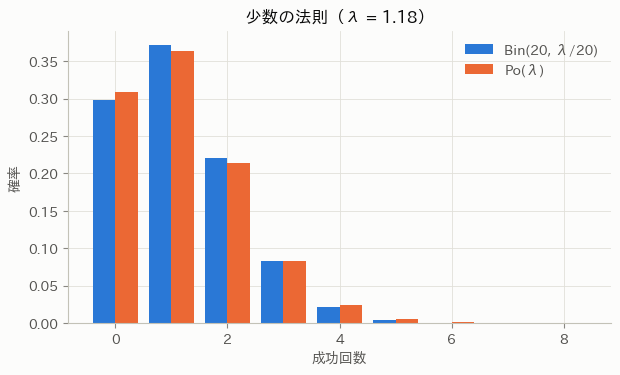

,n,p,P(X=0) 二項,P(X=0) ポアソン,全変動距離
0,5,0.2353,0.2615,0.3084,0.0737
1,20,0.0588,0.2975,0.3084,0.0164
2,100,0.0118,0.3062,0.3084,0.0032
3,1000,0.0012,0.3082,0.3084,0.0003


In [41]:
# ポアソン分布（少数の法則）: 捕獲率3のポケモンにボールを n 回投げたときの成功回数
# 簡略化モデル: 1回あたりの成功確率を p = 捕獲率/255 と仮定する（実際のゲームの捕獲式はより複雑）
lam = 100 * 3 / 255                                   # λ = np を一定に保つ
x = np.arange(0, 9)
rows_po = []
for n_throw in [5, 20, 100, 1000]:
    p_throw = lam / n_throw
    b = stats.binom.pmf(x, n_throw, p_throw)
    po = stats.poisson.pmf(x, lam)
    # 全変動距離 (1/2)Σ|P(X=x) - P(Y=x)|（x の全範囲で計算）
    xx = np.arange(0, n_throw + 1)
    tv = 0.5 * (np.abs(stats.binom.pmf(xx, n_throw, p_throw) - stats.poisson.pmf(xx, lam)).sum()
                + stats.poisson.sf(n_throw, lam))
    rows_po.append({"n": n_throw, "p": p_throw, "P(X=0) 二項": b[0], "P(X=0) ポアソン": po[0], "全変動距離": tv})
print(f"λ = np = {lam:.3f}")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(x - 0.2, stats.binom.pmf(x, 20, lam / 20), width=0.4, color=PALETTE[0], label="Bin(20, λ/20)")
ax.bar(x + 0.2, stats.poisson.pmf(x, lam), width=0.4, color=PALETTE[1], label="Po(λ)")
ax.set(title=f"少数の法則（λ = {lam:.2f}）", xlabel="成功回数", ylabel="確率")
ax.legend()
plt.show()
pd.DataFrame(rows_po).round(4)

**結果の読み方**
- 全変動距離は $n=5$ で約0.07、$n=20$ で約0.016、$n=100$ で約0.003、$n=1000$ で約0.0003 と、$n$ が大きく $p$ が小さいほど近似が良くなる。
- $n=100$（捕獲率3に100回）なら $P(\text{1回も成功しない})$ は二項で約0.306、ポアソンで $e^{-\lambda}\approx 0.308$ と実用上同じである。

### 5.5 幾何分布

**問い**：捕獲率が異なるポケモンで、捕まるまでに何回失敗するか。すでに何回も失敗していると次は捕まりやすくなるか。

**手法の要点**
- 独立な成功確率 $p$ のベルヌーイ試行を繰り返すとき、初めて成功するまでの**失敗回数** $X$ は幾何分布 $\mathrm{Geo}(p)$：
  $$P(X=x)=p(1-p)^x\ (x=0,1,\dots),\qquad E[X]=\frac{1-p}{p},\quad V[X]=\frac{1-p}{p^2}.$$
  試行回数 $Y=X+1$ で定義する流儀もあり、その場合 $E[Y]=1/p$（分散は同じ）。numpy の `geometric` は $Y$ を返すので1を引く。
- 無記憶性：$P(X\ge m+n\mid X\ge m)=P(X\ge n)=(1-p)^n$（任意の0以上の整数 $m,n$）。
- **簡略化モデル: $p=\text{捕獲率}/255$ と仮定**する。実際のゲームの捕獲式はHPやボールで変わるため、これはあくまで分布の練習用のモデルである。

（→ py 05-5：捕獲率45・190・3の例で平均・分散を確認し、捕獲率45で無記憶性を確かめる）

In [42]:
# 幾何分布: 捕まるまでの失敗回数（簡略化モデル: p = 捕獲率/255 と仮定）
rng = get_rng()
examples_geo = {"捕獲率45（御三家など）": 45, "捕獲率190": 190, "捕獲率3（伝説など）": 3}
rows_geo = []
for label, rate in examples_geo.items():
    p_c = rate / 255
    fails = rng.geometric(p_c, size=20000) - 1         # numpy は「試行回数」を返すので1を引いて失敗回数に
    rows_geo.append({"例": label, "p": p_c, "平均(シミュ)": fails.mean(), "平均 (1-p)/p": (1 - p_c) / p_c,
                     "分散(シミュ)": fails.var(), "分散 (1-p)/p^2": (1 - p_c) / p_c**2})
print(pd.DataFrame(rows_geo).round(3).to_string(index=False))

# 無記憶性 P(X >= m+n | X >= m) = P(X >= n) を捕獲率45で確認
p_c = 45 / 255
fails45 = rng.geometric(p_c, size=200000) - 1
n_more = 3
print(f"\n無記憶性（p = 45/255, n = {n_more}）: 理論 P(X >= n) = (1-p)^n = {(1 - p_c) ** n_more:.4f}")
for m in [0, 5, 10]:
    cond = (fails45[fails45 >= m] >= m + n_more).mean()
    print(f"  m = {m:2d}: シミュレーション P(X >= m+n | X >= m) = {cond:.4f}")

           例     p  平均(シミュ)  平均 (1-p)/p  分散(シミュ)  分散 (1-p)/p^2
捕獲率45（御三家など） 0.176    4.653       4.667   26.460        26.444
      捕獲率190 0.745    0.343       0.342    0.453         0.459
  捕獲率3（伝説など） 0.012   84.012      84.000 7047.651      7140.000

無記憶性（p = 45/255, n = 3）: 理論 P(X >= n) = (1-p)^n = 0.5585
  m =  0: シミュレーション P(X >= m+n | X >= m) = 0.5569
  m =  5: シミュレーション P(X >= m+n | X >= m) = 0.5589
  m = 10: シミュレーション P(X >= m+n | X >= m) = 0.5625


**結果の読み方**
- 捕獲率45（$p\approx 0.18$）では平均約4.7回、捕獲率190では約0.34回、捕獲率3（$p\approx 0.012$）では平均84回失敗する。いずれもシミュレーションは理論値と一致する（捕獲率3は裾が重く、分散のシミュレーション値のぶれがやや大きい）。
- 無記憶性：すでに $m=0,5,10$ 回失敗していても、さらに3回以上失敗する確率は約0.56で変わらず、理論値 $(1-p)^3\approx 0.559$ と一致する。独立試行のモデルでは「そろそろ捕まるはず」という考えは成り立たない。

### 5.6 負の二項分布と再生性

**問い**：捕獲率45のポケモンを3匹捕まえるまでに、合計で何回失敗するか。

**手法の要点**
- 成功確率 $p$ の独立試行で、$r$ 回目の成功までの失敗回数 $X$ は負の二項分布 $\mathrm{NB}(r,p)$：
  $$P(X=x)=\binom{x+r-1}{x}p^r(1-p)^x\ (x=0,1,\dots),\qquad E[X]=\frac{r(1-p)}{p},\quad V[X]=\frac{r(1-p)}{p^2}.$$
  $r=1$ のとき幾何分布に一致する。
- 再生性：$X_1\sim\mathrm{NB}(r_1,p)$ と $X_2\sim\mathrm{NB}(r_2,p)$ が独立なら $X_1+X_2\sim\mathrm{NB}(r_1+r_2,p)$。特に独立な $\mathrm{Geo}(p)$ を $r$ 個足すと $\mathrm{NB}(r,p)$ になる（1匹ずつの失敗回数の和が合計の失敗回数）。
- 確率母関数で確かめると、$\mathrm{Geo}(p)$ の母関数 $\dfrac{p}{1-(1-p)s}$ の $r$ 乗が $\mathrm{NB}(r,p)$ の母関数 $\left(\dfrac{p}{1-(1-p)s}\right)^r$ になる。
- 簡略化モデル（$p=45/255$）を使う。

（→ py 05-6：幾何分布3個の和をシミュレーションし、NB(3, p) の確率関数と比べる）

平均  シミュ 14.01  理論 r(1-p)/p   = 14.00
分散  シミュ 80.6  理論 r(1-p)/p^2 = 79.3
定義式と scipy.stats.nbinom.pmf の最大差: 5.551115123125783e-17


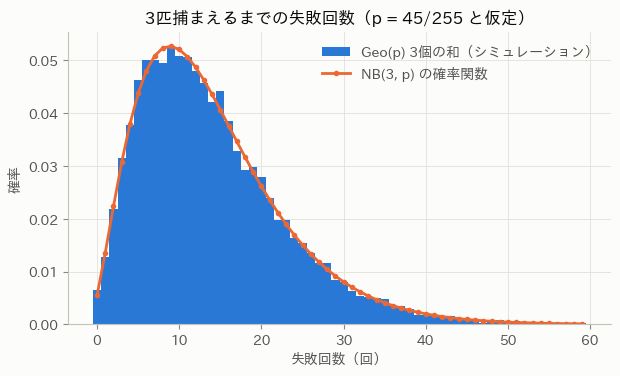

In [43]:
# 負の二項分布: 捕獲率45のポケモンを r = 3 匹捕まえるまでの失敗回数
# 再生性の確認: 独立な Geo(p) を r 個足すと NB(r, p) になる
rng = get_rng()
r_nb, p_c = 3, 45 / 255
geo_sum = (rng.geometric(p_c, size=(20000, r_nb)) - 1).sum(axis=1)
x = np.arange(0, 60)
nb = stats.nbinom(r_nb, p_c)                          # scipy の nbinom は「r 回成功までの失敗回数」
print(f"平均  シミュ {geo_sum.mean():.2f}  理論 r(1-p)/p   = {r_nb * (1 - p_c) / p_c:.2f}")
print(f"分散  シミュ {geo_sum.var():.1f}  理論 r(1-p)/p^2 = {r_nb * (1 - p_c) / p_c**2:.1f}")
# pmf の定義式 C(x+r-1, x) p^r (1-p)^x と scipy の一致
from scipy.special import comb
pmf_hand = comb(x + r_nb - 1, x) * p_c**r_nb * (1 - p_c) ** x
print("定義式と scipy.stats.nbinom.pmf の最大差:", np.abs(pmf_hand - nb.pmf(x)).max())

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(geo_sum, bins=np.arange(-0.5, 60.5), density=True, color=PALETTE[0], label="Geo(p) 3個の和（シミュレーション）")
ax.plot(x, nb.pmf(x), "o-", ms=3, color=PALETTE[1], label="NB(3, p) の確率関数")
ax.set(title="3匹捕まえるまでの失敗回数（p = 45/255 と仮定）", xlabel="失敗回数（回）", ylabel="確率")
ax.legend()
plt.show()

**結果の読み方**
- 3個の幾何分布の和の平均は約14.0、分散は約81で、$\mathrm{NB}(3,45/255)$ の理論値 $14.0$、$79.3$ と一致し、ヒストグラムも確率関数に重なる（再生性の数値確認）。
- 定義式で計算した確率関数と `scipy.stats.nbinom` の差は丸め誤差程度で、scipy の `nbinom(r, p)` が「$r$ 回成功までの失敗回数」の定義であることがわかる。

### 5.7 多項分布

**問い**：タイプ1の構成比に従って30匹を（復元抽出で）選ぶとき、みず・ノーマル・くさ・その他の匹数はどう相関するか。

**手法の要点**
- 1回の試行で $k$ 通りの結果が確率 $p_1,\dots,p_k$（$\sum p_i=1$）で起こり、独立に $n$ 回行ったときの各結果の回数 $(X_1,\dots,X_k)$ は多項分布 $\mathrm{M}(n;p_1,\dots,p_k)$：
  $$P(X_1=x_1,\dots,X_k=x_k)=\frac{n!}{x_1!\cdots x_k!}p_1^{x_1}\cdots p_k^{x_k}\quad\left(\textstyle\sum x_i=n\right).$$
- 周辺分布は $X_i\sim\mathrm{Bin}(n,p_i)$。$i\ne j$ のとき
  $$\mathrm{Cov}(X_i,X_j)=-np_ip_j,\qquad \mathrm{Corr}(X_i,X_j)=-\sqrt{\frac{p_ip_j}{(1-p_i)(1-p_j)}}.$$
  合計が $n$ に固定されているため、共分散は必ず負になる。
- 行を**復元抽出**するので各回は独立で多項分布が厳密に成り立つ（非復元なら多変量超幾何分布になる）。

（→ py 05-7：10000回の抽出で共分散行列・相関行列を理論値と比べる）

In [44]:
# 多項分布: タイプ1の構成比を p として n 匹を復元抽出したときの各タイプの数
top3 = ["みず", "ノーマル", "くさ"]
type_group = df["タイプ1"].astype(str).where(df["タイプ1"].isin(top3), "その他")
cats = top3 + ["その他"]
p_multi = type_group.value_counts(normalize=True)[cats].to_numpy()
n_multi = 30
rng = get_rng()
codes = pd.Categorical(type_group, categories=cats).codes
samp = codes[rng.integers(0, len(df), size=(10000, n_multi))]      # データの行を復元抽出
counts_multi = np.stack([(samp == j).sum(axis=1) for j in range(len(cats))], axis=1)

cov_theory = n_multi * (np.diag(p_multi) - np.outer(p_multi, p_multi))  # Var = np(1-p), Cov = -n p_i p_j
sd_t = np.sqrt(np.diag(cov_theory))
corr_theory = cov_theory / np.outer(sd_t, sd_t)
print("構成比 p:", dict(zip(cats, p_multi.round(4))))
print("\n共分散行列（上: 理論 n(diag(p) - pp^T), 下: シミュレーション）")
print(pd.DataFrame(cov_theory, index=cats, columns=cats).round(3).to_string())
print(pd.DataFrame(np.cov(counts_multi.T), index=cats, columns=cats).round(3).to_string())
print("\n相関行列（上: 理論 -sqrt(p_i p_j / ((1-p_i)(1-p_j))), 下: シミュレーション）")
print(pd.DataFrame(corr_theory, index=cats, columns=cats).round(3).to_string())
pd.DataFrame(np.corrcoef(counts_multi.T), index=cats, columns=cats).round(3)

構成比 p: {'みず': 0.1348, 'ノーマル': 0.1196, 'くさ': 0.0902, 'その他': 0.6554}

共分散行列（上: 理論 n(diag(p) - pp^T), 下: シミュレーション）
         みず   ノーマル     くさ    その他
みず    3.498 -0.483 -0.365 -2.650
ノーマル -0.483  3.158 -0.324 -2.351
くさ   -0.365 -0.324  2.462 -1.774
その他  -2.650 -2.351 -1.774  6.775
         みず   ノーマル     くさ    その他
みず    3.490 -0.512 -0.372 -2.606
ノーマル -0.512  3.092 -0.320 -2.260
くさ   -0.372 -0.320  2.425 -1.733
その他  -2.606 -2.260 -1.733  6.599

相関行列（上: 理論 -sqrt(p_i p_j / ((1-p_i)(1-p_j))), 下: シミュレーション）
         みず   ノーマル     くさ    その他
みず    1.000 -0.145 -0.124 -0.544
ノーマル -0.145  1.000 -0.116 -0.508
くさ   -0.124 -0.116  1.000 -0.434
その他  -0.544 -0.508 -0.434  1.000


,みず,ノーマル,くさ,その他
みず,1.000,-0.156,-0.128,-0.543
ノーマル,-0.156,1.000,-0.117,-0.500
くさ,-0.128,-0.117,1.000,-0.433
その他,-0.543,-0.500,-0.433,1.000


**結果の読み方**
- 構成比はみず約0.135、ノーマル約0.120、くさ約0.090、その他約0.655。シミュレーションの共分散・相関は理論値とよく一致する。
- 上位3タイプどうしの相関は $-0.12$〜$-0.15$ 程度と弱い負の相関だが、「その他」との相関は $-0.43$〜$-0.54$ と強い。構成比の大きいカテゴリとの間ほど、「一方が増えると他方が減る」制約が強く効く。

### まとめ

- 雄率・捕獲率・タイプ構成比を確率とみなすと、二項・幾何・負の二項・超幾何・多項分布の平均や分散の公式がシミュレーションとよく一致した。
- 分布の関係：$np$ 一定で $n$ が大きいと二項分布はポアソン分布に近づき（$n=100$ で全変動距離約0.003）、$n/N$ が小さいと超幾何分布は二項分布に近づく。逆に920匹から300匹を非復元で選ぶと、有限母集団修正で分散が約3割小さくなるので二項近似は使えない。
- 幾何分布の無記憶性と、幾何分布の和が負の二項分布になる再生性を数値で確認した。
- 限界：捕獲の節は $p=\text{捕獲率}/255$ の簡略化モデルであり、実際のゲームの捕獲確率を表すものではない。

## 第6章 連続型分布と標本分布

### 章の概要

連続型の代表的な分布をポケモンの種族値・重さ・捕獲率に当てはめ、どの分布がデータの形に合うかを比べる。後半では、全ポケモンを母集団とみなして標本を繰り返し抽出し、$\chi^2$・$t$・$F$ 分布が「正規母集団からの標本」の統計量の分布であることと、母集団が正規でないとそれが崩れることを確かめる。
- **目的**：データの形（対称か、正値で右に歪むか、区間 $(0,1)$ の値か、多峰か）に合った分布を選べるようにする。標本分布の前提（正規性）がどれほど重要かを知る。
- **考え方**：最尤法でパラメータを推定し、対数尤度・AIC・Q-Q プロット・確率積分変換で当てはまりを比べる。
- **つながり**：第5章の離散型分布の連続版。最尤法の性質は第8章、$\chi^2$・$t$・$F$ 分布を使った区間推定・検定は第9〜11章、AIC は第30章で詳しく扱う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 6.1 | 正規分布・Q-Q プロット | 合計種族値は正規分布に従うか |
| 6.2 | 対数正規分布 | 重さは対数正規分布で表せるか |
| 6.3 | 指数分布・ガンマ分布（最尤法） | 重さ・攻撃に最も合う正値の分布はどれか |
| 6.4 | ベータ分布 | 捕獲率/255 はベータ分布で表せるか |
| 6.5 | 一様分布（確率積分変換） | 当てはめた分布の分布関数で変換すると一様になるか |
| 6.6 | 混合正規分布（EM アルゴリズム） | 合計種族値の多峰性は何成分で表せるか |
| 6.7 | 多変量正規分布 | 攻撃と特攻の同時分布は2変量正規で表せるか |
| 6.8 | $\chi^2$ 分布 | 標本分散から作った $(n-1)S^2/\sigma^2$ は $\chi^2(n-1)$ に従うか |
| 6.9 | $t$ 分布 | $t$ 統計量は $t(n-1)$ に従うか |
| 6.10 | $F$ 分布 | 2標本の分散比は $F$ 分布に従うか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（175〜780） | 正規分布・混合正規分布の当てはめ、標本分布の母集団（ほぼ対称） |
| `重さ` | 量的（0.1〜999.9 kg） | 対数正規・指数・ガンマ分布の当てはめ、標本分布の母集団（強く右に歪む） |
| `攻撃`, `特攻` | 量的（種族値） | ガンマ分布、2変量正規分布 |
| `捕獲率` | 整数（3〜255） | 255 で割ってベータ分布に当てはめる |

- **対象の行**：全920行。
- **加工**：`捕獲率/255` の端点処理（6.4）。6.8〜6.10 では全920行を母集団とし、行を**復元抽出**して大きさ $n$ の i.i.d. 標本を作る。このとき母平均・母分散は920行の平均と $N$ で割った分散（真値）である。
- **データの性質と注意点**：種族値・捕獲率は整数で同じ値が多く（捕獲率45が303行）、連続分布の当てはめは近似にすぎない。重さの最大値999.9 kg は表示上の上限である。同じ進化系統の行は独立でないため、6.1〜6.7 の当てはめは「920行を仮想母集団からの独立な標本とみなした」記述的な比較と考える。

（→ py 06-0：使う列の要約統計・歪度・尖度を表示する）

In [45]:
# この章で使う列の要約（歪度・尖度つき）
cols06 = ["合計種族値", "重さ", "log重さ", "攻撃", "特攻", "捕獲率"]
sum06 = df[cols06].describe().T[["count", "mean", "std", "min", "50%", "max"]]
sum06["歪度"] = df[cols06].skew()
sum06["尖度(-3)"] = df[cols06].kurt()
print("捕獲率 = 255（上限）の行数:", (df["捕獲率"] == 255).sum())
sum06.round(2)

捕獲率 = 255（上限）の行数: 78


,count,mean,std,min,50%,max,歪度,尖度(-3)
合計種族値,920.0,438.47,120.33,175.0,455.00,780.00,0.10,-0.53
重さ,920.0,69.16,124.71,0.1,29.50,999.90,4.34,23.68
log重さ,920.0,3.21,1.59,-2.3,3.38,6.91,-0.55,0.66
攻撃,920.0,80.07,32.54,5.0,75.00,190.00,0.51,0.06
特攻,920.0,73.32,33.22,10.0,65.00,194.00,0.72,0.18
捕獲率,920.0,93.98,75.55,3.0,60.00,255.00,0.94,-0.39


### 6.1 正規分布

**問い**：合計種族値は正規分布 $N(\mu,\sigma^2)$ で表せるか。

**手法の要点**
- 密度 $f(x)=\dfrac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\dfrac{(x-\mu)^2}{2\sigma^2}\right)$、平均 $\mu$、分散 $\sigma^2$。
- 最尤推定量は $\hat\mu=\bar x$、$\hat\sigma^2=\frac1n\sum(x_i-\bar x)^2$（$n$ で割る）。
- Q-Q プロット：順序統計量 $x_{(i)}$ を標準正規分布の分位点に対してプロットする。正規分布に従えば直線 $\hat\mu+\hat\sigma z$ の上に並ぶ。
- 正規分布なら $\mu\pm\sigma$ に約68.3%、$\mu\pm2\sigma$ に約95.4% が入る。

（→ py 06-1：最尤推定・区間に入る割合・ヒストグラムと Q-Q プロット）

手計算 μ̂ = 438.47, σ̂ = 120.27   scipy.stats.norm.fit: 438.47, 120.27
歪度 0.097  尖度(-3) -0.532
μ±1σ に入る割合: データ 0.629  正規分布 0.683
μ±2σ に入る割合: データ 0.955  正規分布 0.954


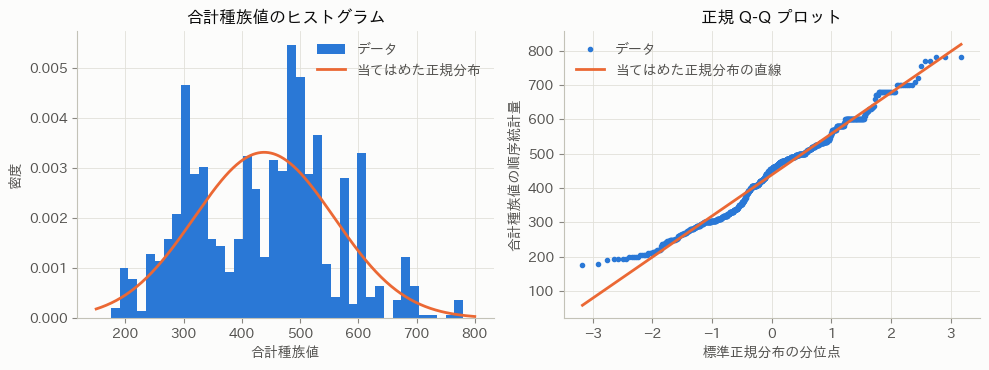

In [46]:
# 正規分布: 合計種族値に N(μ, σ^2) を当てはめる（最尤推定: 標本平均と n で割った標準偏差）
bst = df["合計種族値"].to_numpy(float)
mu_b, sd_b = bst.mean(), bst.std(ddof=0)
mu_fit, sd_fit = stats.norm.fit(bst)                   # scipy の MLE と手計算の一致
print(f"手計算 μ̂ = {mu_b:.2f}, σ̂ = {sd_b:.2f}   scipy.stats.norm.fit: {mu_fit:.2f}, {sd_fit:.2f}")
print(f"歪度 {stats.skew(bst):.3f}  尖度(-3) {stats.kurtosis(bst):.3f}")
# 正規分布なら μ±σ に約68.3%, μ±2σ に約95.4% が入る
for k in [1, 2]:
    inside = (np.abs(bst - mu_b) <= k * sd_b).mean()
    print(f"μ±{k}σ に入る割合: データ {inside:.3f}  正規分布 {stats.norm.cdf(k) - stats.norm.cdf(-k):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
grid_b = np.linspace(150, 800, 300)
axes[0].hist(bst, bins=40, density=True, color=PALETTE[0], label="データ")
axes[0].plot(grid_b, stats.norm.pdf(grid_b, mu_b, sd_b), color=PALETTE[1], label="当てはめた正規分布")
axes[0].set(title="合計種族値のヒストグラム", xlabel="合計種族値", ylabel="密度")
axes[0].legend()
(osm, osr), (slope, icpt, _) = stats.probplot(bst, dist="norm")
axes[1].plot(osm, osr, "o", ms=3, color=PALETTE[0], label="データ")
axes[1].plot(osm, slope * osm + icpt, color=PALETTE[1], label="当てはめた正規分布の直線")
axes[1].set(title="正規 Q-Q プロット", xlabel="標準正規分布の分位点", ylabel="合計種族値の順序統計量")
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- $\hat\mu\approx 438$、$\hat\sigma\approx 120$。歪度は約0.10とほぼ対称だが、尖度は約 $-0.53$ で正規分布より裾が軽く、平たい。
- $\mu\pm\sigma$ に入る割合は約63%で、正規分布の68%より少ない。ヒストグラムは300付近と500付近に山がある**多峰**の形で、Q-Q プロットも直線からS字状にずれ、同じ値が多いため階段状になる。
- 平均・分散の要約には使えるが、分布の形としては正規分布は粗い近似である（6.6 で混合正規分布を当てはめる）。

### 6.2 対数正規分布

**問い**：重さ $X$ は対数正規分布 $\Lambda(\mu,\sigma^2)$（$\log X\sim N(\mu,\sigma^2)$）で表せるか。

**手法の要点**
- $Y\sim N(\mu,\sigma^2)$ のとき $X=e^Y$ の分布が $\Lambda(\mu,\sigma^2)$。密度は $f(x)=\dfrac{1}{\sqrt{2\pi}\sigma x}\exp\!\left(-\dfrac{(\log x-\mu)^2}{2\sigma^2}\right)\ (x>0)$。
- $E[X]=e^{\mu+\sigma^2/2}$、$V[X]=e^{2\mu+\sigma^2}(e^{\sigma^2}-1)$、中央値は $e^{\mu}$。
- 最尤推定は $\log x_i$ の平均と（$n$ で割った）標準偏差。scipy の `lognorm` では `s` $=\sigma$、`scale` $=e^\mu$。

（→ py 06-2：当てはめたモデルの平均・中央値をデータと比べ、log重さの Q-Q プロットを描く）

手計算 μ̂ = 3.212, σ̂ = 1.590   scipy: s = 1.590, log(scale) = 3.212
中央値  モデル e^μ = 24.8 kg      データ 29.5 kg
平均    モデル e^(μ+σ²/2) = 87.8 kg   データ 69.2 kg
log重さの歪度 -0.546  尖度(-3) 0.649


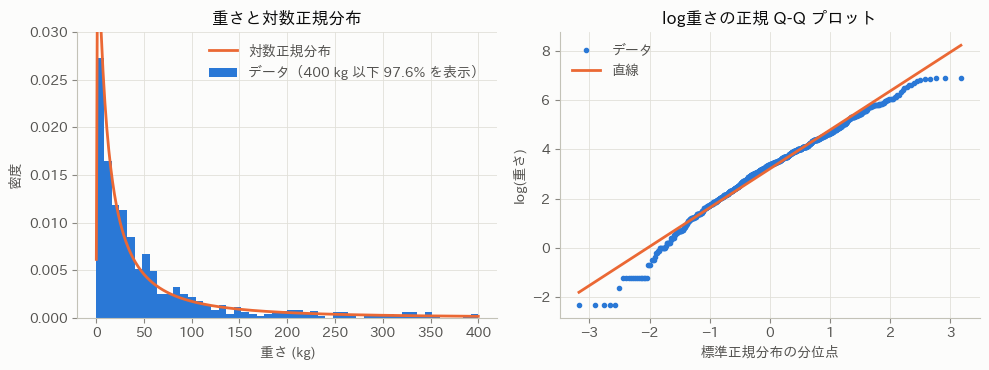

In [47]:
# 対数正規分布: 重さ X に対し log X ~ N(μ, σ^2) を当てはめる
wt = df["重さ"].to_numpy(float)
mu_l, sd_l = np.log(wt).mean(), np.log(wt).std(ddof=0)
shape_s, _, scale_s = stats.lognorm.fit(wt, floc=0)    # scipy の lognorm: s = σ, scale = e^μ
print(f"手計算 μ̂ = {mu_l:.3f}, σ̂ = {sd_l:.3f}   scipy: s = {shape_s:.3f}, log(scale) = {np.log(scale_s):.3f}")
print(f"中央値  モデル e^μ = {np.exp(mu_l):.1f} kg      データ {np.median(wt):.1f} kg")
print(f"平均    モデル e^(μ+σ²/2) = {np.exp(mu_l + sd_l**2 / 2):.1f} kg   データ {wt.mean():.1f} kg")
print(f"log重さの歪度 {stats.skew(np.log(wt)):.3f}  尖度(-3) {stats.kurtosis(np.log(wt)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
grid_w = np.linspace(0.1, 400, 400)
# 400 kg 以下だけ表示するが、密度は全920行で割って対数正規分布の密度と比べられるようにする
frac = (wt <= 400).mean()
h, e = np.histogram(wt[wt <= 400], bins=50)
axes[0].bar(e[:-1], h / (len(wt) * np.diff(e)), width=np.diff(e), align="edge", color=PALETTE[0],
            label=f"データ（400 kg 以下 {frac:.1%} を表示）")
axes[0].plot(grid_w, stats.lognorm.pdf(grid_w, sd_l, scale=np.exp(mu_l)), color=PALETTE[1], label="対数正規分布")
axes[0].set(title="重さと対数正規分布", xlabel="重さ (kg)", ylabel="密度", ylim=(0, 0.03))
axes[0].legend()
(osm, osr), (slope, icpt, _) = stats.probplot(np.log(wt), dist="norm")
axes[1].plot(osm, osr, "o", ms=3, color=PALETTE[0], label="データ")
axes[1].plot(osm, slope * osm + icpt, color=PALETTE[1], label="直線")
axes[1].set(title="log重さの正規 Q-Q プロット", xlabel="標準正規分布の分位点", ylabel="log(重さ)")
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- $\hat\mu\approx 3.21$、$\hat\sigma\approx 1.59$。密度の形は重さのヒストグラム（右に長い裾）をよく再現する。
- ただしモデルの中央値 $e^{\hat\mu}\approx 25$ kg（データ29.5 kg）、モデルの平均 $e^{\hat\mu+\hat\sigma^2/2}\approx 88$ kg（データ69 kg）とずれる。log重さの歪度が約 $-0.55$ と左に歪んでおり、Q-Q プロットでは下側（0.1 kg など非常に軽いポケモン）が直線より下に、上側（999.9 kg で頭打ち）が直線より下に外れる。
- 大まかな形には対数正規分布が合うが、両裾は正規の対数変換だけでは表しきれない。

### 6.3 指数分布・ガンマ分布

**問い**：正値データ（重さ・攻撃）に指数分布・ガンマ分布・対数正規分布を最尤法で当てはめると、どれが最もよく合うか。

**手法の要点**
- 指数分布 $\mathrm{Exp}(\lambda)$：$f(x)=\lambda e^{-\lambda x}\ (x>0)$、$E[X]=1/\lambda$、$V[X]=1/\lambda^2$。最尤推定量は $\hat\lambda=1/\bar x$ で、最大対数尤度は $-n(\log\bar x+1)$。
- ガンマ分布 $\mathrm{Ga}(a,b)$（$a$：形状、$b$：尺度）：$f(x)=\dfrac{x^{a-1}e^{-x/b}}{\Gamma(a)b^a}\ (x>0)$、$E[X]=ab$、$V[X]=ab^2$。$a=1$ で $\mathrm{Exp}(1/b)$。$a$ の最尤推定は陽に解けず数値計算する。
- 比較には AIC $=-2\times(\text{最大対数尤度})+2\times(\text{パラメータ数})$ を使う（小さいほどよい）。
- 図では重さを対数軸で比べる。$Y=\log X$ の密度は $f_X(e^y)\,e^y$ である。

（→ py 06-3：重さと攻撃にそれぞれの分布を当てはめ、対数尤度と AIC の表を作る）

重さ: λ̂ = 0.0145（平均 69.2 kg）, ガンマ a = 0.603, b = 114.8
               パラメータ数    対数尤度     AIC
分布                                   
指数 Exp(λ)           1 -4817.5  9637.0
ガンマ Ga(a, b)        2 -4720.7  9445.4
対数正規 Λ(μ, σ²)       2 -4686.5  9376.9

攻撃: ガンマ a = 5.49, b = 14.58
               パラメータ数    対数尤度     AIC
分布                                   
指数 Exp(λ)         1.0 -4952.3  9906.5
ガンマ Ga(a, b)      2.0 -4495.7  8995.4
対数正規 Λ(μ, σ²)     2.0 -4542.5  9089.1
正規 N(μ, σ²)       2.0 -4508.9  9021.7


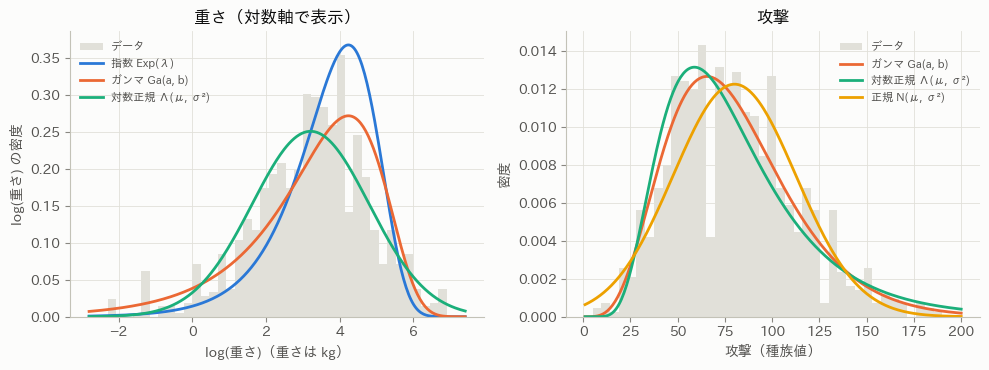

In [48]:
# 指数分布・ガンマ分布（・対数正規分布）を最尤法で当てはめ、対数尤度と AIC で比べる
def fit_positive_06(x):
    """正値データに3つの分布を最尤推定で当てはめ、(表, 当てはめた分布の辞書) を返す."""
    n = len(x)
    lam_hat = 1 / x.mean()                              # 指数分布の MLE は 1/標本平均
    a_hat, _, b_hat = stats.gamma.fit(x, floc=0)        # ガンマ分布 Ga(a, b)（b は尺度）
    s_hat, _, sc_hat = stats.lognorm.fit(x, floc=0)
    dists = {"指数 Exp(λ)": (stats.expon(scale=1 / lam_hat), 1),
             "ガンマ Ga(a, b)": (stats.gamma(a_hat, scale=b_hat), 2),
             "対数正規 Λ(μ, σ²)": (stats.lognorm(s_hat, scale=sc_hat), 2)}
    rows = []
    for name, (dist, k) in dists.items():
        ll = dist.logpdf(x).sum()
        rows.append({"分布": name, "パラメータ数": k, "対数尤度": ll, "AIC": -2 * ll + 2 * k})
    # 手計算の確認: 指数分布の最大対数尤度 = n log λ̂ - λ̂ Σx = -n(log x̄ + 1)
    assert np.isclose(rows[0]["対数尤度"], -n * (np.log(x.mean()) + 1))
    return pd.DataFrame(rows).set_index("分布"), {k: v[0] for k, v in dists.items()}, (lam_hat, a_hat, b_hat)

tab_w, fits_w, (lam_w, a_w, b_w) = fit_positive_06(wt)
print(f"重さ: λ̂ = {lam_w:.4f}（平均 {1 / lam_w:.1f} kg）, ガンマ a = {a_w:.3f}, b = {b_w:.1f}")
print(tab_w.round(1).to_string())
atk = df["攻撃"].to_numpy(float)
tab_a, fits_a, (lam_a, a_a, b_a) = fit_positive_06(atk)
ll_norm_a = stats.norm(atk.mean(), atk.std()).logpdf(atk).sum()
tab_a.loc["正規 N(μ, σ²)"] = [2, ll_norm_a, -2 * ll_norm_a + 4]
print(f"\n攻撃: ガンマ a = {a_a:.2f}, b = {b_a:.2f}")
print(tab_a.round(1).to_string())

# 図: log(重さ) の尺度で比べる（Y = log X の密度は f_X(e^y) e^y）
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
y_grid = np.linspace(np.log(wt).min() - 0.5, np.log(wt).max() + 0.5, 300)
axes[0].hist(np.log(wt), bins=40, density=True, color=INK["grid"], label="データ")
for c, (name, dist) in zip(PALETTE, fits_w.items()):
    axes[0].plot(y_grid, dist.pdf(np.exp(y_grid)) * np.exp(y_grid), color=c, label=name)
axes[0].set(title="重さ（対数軸で表示）", xlabel="log(重さ)（重さは kg）", ylabel="log(重さ) の密度")
axes[0].legend(fontsize=8)
x_grid = np.linspace(1, 200, 300)
axes[1].hist(atk, bins=40, density=True, color=INK["grid"], label="データ")
# 指数分布は明らかに合わないので図では省き（表には載せている）、3本に絞る。色は分布ごとに左図と揃える
for c, name in zip(PALETTE[1:3], ["ガンマ Ga(a, b)", "対数正規 Λ(μ, σ²)"]):
    axes[1].plot(x_grid, fits_a[name].pdf(x_grid), color=c, label=name)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, atk.mean(), atk.std()), color=PALETTE[3], label="正規 N(μ, σ²)")
axes[1].set(title="攻撃", xlabel="攻撃（種族値）", ylabel="密度")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**結果の読み方**
- 重さ：AIC は指数（約9637）＞ガンマ（約9445、$\hat a\approx 0.60$）＞対数正規（約9377）の順で、**対数正規分布が最もよい**。$\hat a<1$ のガンマは原点付近に密度が集中し、対数軸で見ると軽いポケモンの多さを表しきれない。
- 攻撃：AIC はガンマ（約8995、$\hat a\approx 5.5$, $\hat b\approx 14.6$）が最小で、正規（約9022）、対数正規（約9089）、指数（約9907）が続く。攻撃は少し右に歪んでいるので、正規よりガンマが合う。指数分布は最頻値が0なので明らかに合わない。
- AIC の差は「どれが相対的にましか」を示すだけで、最良の分布がよく当てはまることは保証しない（6.5 で確認する）。

### 6.4 ベータ分布

**問い**：捕獲率/255 は区間 $(0,1)$ の分布であるベータ分布で表せるか。

**手法の要点**
- ベータ分布 $\mathrm{Be}(a,b)$：$f(x)=\dfrac{x^{a-1}(1-x)^{b-1}}{B(a,b)}\ (0<x<1)$、$E[X]=\dfrac{a}{a+b}$、$V[X]=\dfrac{ab}{(a+b)^2(a+b+1)}$。
- **端点の扱い**：捕獲率255の行（78行）は $x=1$ ちょうどで、$b<1$ のとき密度が $\infty$ になり対数尤度が計算できない。ここでは $x'=\{x(n-1)+0.5\}/n$ で値を区間の内側に少し寄せてから当てはめる（寄せ方で結果が変わる便宜的な処理）。
- モーメント法：標本平均 $m$ と標本分散 $v$ から $a+b=\dfrac{m(1-m)}{v}-1$、$a=m(a+b)$、$b=(1-m)(a+b)$。最尤法は数値計算。
- `雄率` は0〜1の7つの値しかとらず、0と1にも行があるため、連続分布であるベータ分布の当てはめには向かない（第5章のように確率として使う）。

（→ py 06-4：モーメント法と最尤法で当てはめて密度を比べる）

1 ちょうどの行: 78  最小値: 0.0118
モーメント法: a = 0.612, b = 1.048
最尤法    : a = 0.564, b = 0.668
最尤法の平均 a/(a+b) = 0.458  データの平均 0.369

よく現れる値（捕獲率）: {45: 303, 255: 78, 190: 77, 3: 76, 75: 68}
雄率の値: [0.0, 0.125, 0.25, 0.5, 0.75, 0.875, 1.0]


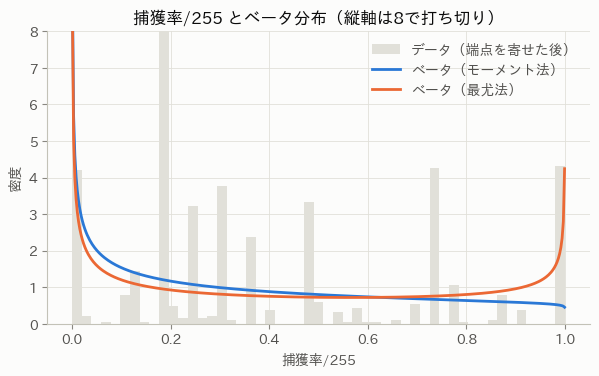

In [49]:
# ベータ分布: 捕獲率/255 は (0, 1] の値（255 が上限なので 1 ちょうどの行がある）
y_cr = df["捕獲率"].to_numpy(float) / 255
n_cr = len(y_cr)
print(f"1 ちょうどの行: {(y_cr == 1).sum()}  最小値: {y_cr.min():.4f}")
# ベータ分布の密度は端点 0, 1 で 0 か ∞ になり得るので、(y(n-1) + 0.5)/n で端点を少し内側に寄せる
y_sq = (y_cr * (n_cr - 1) + 0.5) / n_cr
# モーメント法: 平均 m = a/(a+b), 分散 v = m(1-m)/(a+b+1) を解く
m_cr, v_cr = y_sq.mean(), y_sq.var()
common = m_cr * (1 - m_cr) / v_cr - 1
a_mm, b_mm = m_cr * common, (1 - m_cr) * common
a_ml, b_ml, _, _ = stats.beta.fit(y_sq, floc=0, fscale=1)
print(f"モーメント法: a = {a_mm:.3f}, b = {b_mm:.3f}")
print(f"最尤法    : a = {a_ml:.3f}, b = {b_ml:.3f}")
print(f"最尤法の平均 a/(a+b) = {a_ml / (a_ml + b_ml):.3f}  データの平均 {m_cr:.3f}")
print("\nよく現れる値（捕獲率）:", df["捕獲率"].value_counts().head(5).to_dict())
# 雄率は 0〜1 の7値しかとらず 0 と 1 もあるので、連続分布（ベータ分布）の当てはめには向かない
print("雄率の値:", sorted(df["雄率"].dropna().unique()))

fig, ax = plt.subplots(figsize=(7, 3.8))
g = np.linspace(0.001, 0.999, 400)
ax.hist(y_sq, bins=np.linspace(0, 1, 52), density=True, color=INK["grid"], label="データ（端点を寄せた後）")
ax.plot(g, stats.beta.pdf(g, a_mm, b_mm), color=PALETTE[0], label="ベータ（モーメント法）")
ax.plot(g, stats.beta.pdf(g, a_ml, b_ml), color=PALETTE[1], label="ベータ（最尤法）")
ax.set(title="捕獲率/255 とベータ分布（縦軸は8で打ち切り）", xlabel="捕獲率/255", ylabel="密度", ylim=(0, 8))
ax.legend()
plt.show()

**結果の読み方**
- モーメント法は $a\approx 0.61$, $b\approx 1.05$、最尤法は $a\approx 0.56$, $b\approx 0.67$ で、どちらも $a<1$ で、最尤法は両端が高いU字型（$b<1$）、モーメント法は単調減少のJ字型（$b>1$）になる。
- 最尤法の平均 $a/(a+b)\approx 0.46$ はデータの平均約0.37と一致しない。ベータ分布の最尤推定は平均ではなく $\log x$ と $\log(1-x)$ の平均を合わせるため、端点近くに寄せた値（捕獲率3と255）の影響を強く受ける。
- 捕獲率は45・190・3・255などの特定の値に集中した離散的な変数であり、どちらのベータ分布もヒストグラムの鋭い山を表せない。ベータ分布は「$(0,1)$ の値の滑らかなモデル」として限界がある例である。

### 6.5 一様分布と確率積分変換

**問い**：当てはめた分布の分布関数でデータを変換すると、一様分布 $U(0,1)$ になるか。

**手法の要点**
- 一様分布 $U(a,b)$：$f(x)=\dfrac{1}{b-a}\ (a\le x\le b)$、$E[X]=\dfrac{a+b}{2}$、$V[X]=\dfrac{(b-a)^2}{12}$。
- 確率積分変換：$X$ が連続型で分布関数 $F$ をもつとき、$U=F(X)\sim U(0,1)$。したがって当てはめた分布 $\hat F$ でデータを変換した $u_i=\hat F(x_i)$ が一様に近いほど、当てはまりがよい。
- 一様からのずれは KS 距離 $D=\sup_u|F_n(u)-u|$（$F_n$ は $u_i$ の経験分布関数）で測る。パラメータを同じデータから推定しており、値の重複も多いので、KS 検定の p 値はそのままでは使えない（距離の比較にとどめる）。

（→ py 06-5：3つの組合せで $u_i$ の平均・分散・KS 距離を計算し、ヒストグラムを描く）

U(0, 1) の理論値: 平均 1/2 = 0.5, 分散 1/12 = 0.0833
       組合せ     平均     分散  KS距離 D（手計算）  KS距離 D（scipy）
合計種族値 × 正規 0.4997 0.0889       0.0762         0.0762
 重さ × 対数正規 0.5125 0.0786       0.0593         0.0593
   重さ × 指数 0.4047 0.0943       0.1715         0.1715


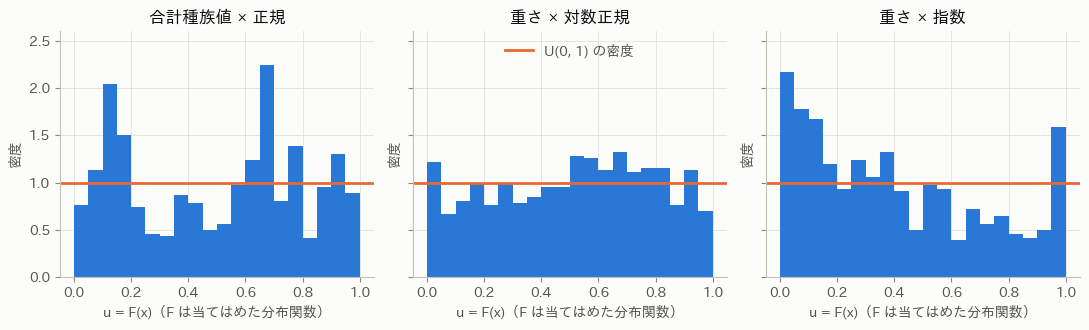

In [50]:
# 一様分布: 確率積分変換 U = F(X) は、X が連続で F が真の分布関数なら U(0, 1) に従う
u_norm = stats.norm.cdf(bst, mu_b, sd_b)               # 合計種族値 × 当てはめた正規分布
u_logn = stats.lognorm.cdf(wt, sd_l, scale=np.exp(mu_l))  # 重さ × 当てはめた対数正規分布
u_expo = stats.expon.cdf(wt, scale=wt.mean())          # 重さ × 当てはめた指数分布
print("U(0, 1) の理論値: 平均 1/2 = 0.5, 分散 1/12 = 0.0833")
rows_pit = []
for name, u in [("合計種族値 × 正規", u_norm), ("重さ × 対数正規", u_logn), ("重さ × 指数", u_expo)]:
    # KS 距離 D = sup|F_n(u) - u| を定義から計算
    us = np.sort(u)
    i = np.arange(1, len(us) + 1)
    d_hand = max((i / len(us) - us).max(), (us - (i - 1) / len(us)).max())
    rows_pit.append({"組合せ": name, "平均": u.mean(), "分散": u.var(),
                     "KS距離 D（手計算）": d_hand, "KS距離 D（scipy）": stats.kstest(u, "uniform").statistic})
print(pd.DataFrame(rows_pit).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, (name, u) in zip(axes, [("合計種族値 × 正規", u_norm), ("重さ × 対数正規", u_logn), ("重さ × 指数", u_expo)]):
    ax.hist(u, bins=20, range=(0, 1), density=True, color=PALETTE[0])
    ax.axhline(1, color=PALETTE[1], label="U(0, 1) の密度")
    ax.set(ylim=(0, 2.6), title=name, xlabel="u = F(x)（F は当てはめた分布関数）", ylabel="密度")
axes[1].legend(loc="upper center")
fig.tight_layout()
plt.show()

**結果の読み方**
- KS 距離は「重さ×対数正規」が約0.059と最も小さく、「合計種族値×正規」約0.076、「重さ×指数」約0.17 の順。6.3 の AIC の順位と整合する。
- 「重さ×指数」は $u$ が0付近と1付近に偏る（軽いポケモンと非常に重いポケモンがモデルより多い）。「合計種族値×正規」は山と谷が交互に現れ、6.1 で見た多峰性がそのまま出ている。
- 一様分布の理論値（平均0.5、分散1/12≈0.083）に最も近いのも対数正規の組合せだが、それでも完全な一様ではない。

### 6.6 混合正規分布（EM アルゴリズム）

**問い**：合計種族値の多峰性は、何成分の混合正規分布で表せるか。

**手法の要点**
- $k$ 成分混合正規分布：$f(x)=\sum_{j=1}^k\pi_j\,\phi(x;\mu_j,\sigma_j^2)$（$\pi_j>0$, $\sum\pi_j=1$、$\phi$ は正規分布の密度）。
- EM アルゴリズム（2成分の場合）：
  - E ステップ：現在のパラメータで、各点が成分1から来た事後確率 $\gamma_i=\dfrac{\pi\phi(x_i;\mu_1,\sigma_1^2)}{\pi\phi(x_i;\mu_1,\sigma_1^2)+(1-\pi)\phi(x_i;\mu_2,\sigma_2^2)}$ を計算する。
  - M ステップ：$\pi=\frac1n\sum\gamma_i$、$\mu_1=\dfrac{\sum\gamma_ix_i}{\sum\gamma_i}$、$\sigma_1^2=\dfrac{\sum\gamma_i(x_i-\mu_1)^2}{\sum\gamma_i}$（成分2は $1-\gamma_i$ を重みにする）。
  - 繰り返すと対数尤度は単調に増加するが、局所最適に止まることがあるので初期値を変えて何度か行う。
- 成分数は BIC $=-2\times(\text{最大対数尤度})+(\text{パラメータ数})\log n$ で比べる（$k$ 成分で $3k-1$ 個）。

（→ py 06-6：sklearn で1〜7成分を当てはめて BIC を比べ、2成分を手作りの EM と照合する）

       対数尤度      BIC                          成分の平均（小さい順）
成分数                                                      
1   -5712.0  11437.6                                [438]
2   -5673.0  11380.1                           [295, 491]
3   -5648.2  11351.0                      [299, 487, 492]
4   -5632.8  11340.7                 [307, 411, 488, 565]
5   -5609.9  11315.4            [308, 410, 492, 591, 675]
6   -5594.2  11304.5       [204, 311, 409, 492, 591, 675]
7   -5585.3  11307.1  [204, 311, 410, 486, 530, 589, 678]



手作り EM : π = (0.267, 0.733), μ = (295.2, 490.6), σ = (46.2, 93.6)  対数尤度 -5673.0
sklearn   : π = [0.268 0.732], μ = [295.4 490.9], σ = [46.3 93.4]


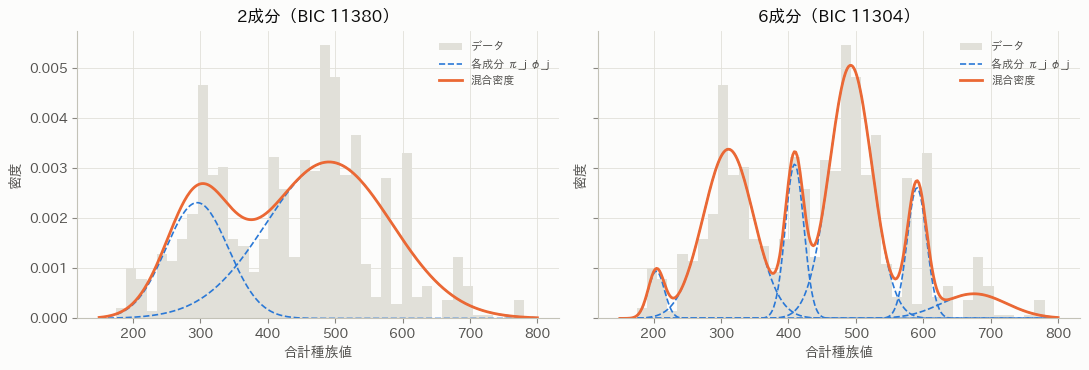

In [51]:
# 混合正規分布: 合計種族値の多峰性を EM アルゴリズムで。成分数は BIC で比べる
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")      # Windows での joblib の警告を抑える
from sklearn.mixture import GaussianMixture

X_b = bst.reshape(-1, 1)
rows_gmm, gmms = [], {}
for k in range(1, 8):
    gm = GaussianMixture(k, n_init=10, tol=1e-6, max_iter=2000, random_state=SEED).fit(X_b)
    gmms[k] = gm
    rows_gmm.append({"成分数": k, "対数尤度": gm.score(X_b) * len(X_b), "BIC": gm.bic(X_b),
                     "成分の平均（小さい順）": np.sort(gm.means_.ravel()).round(0).astype(int).tolist()})
tab_gmm = pd.DataFrame(rows_gmm).set_index("成分数")
print(tab_gmm.round(1).to_string())

# 2成分の EM を定義式どおりに実装して sklearn と比べる
pi1, m1, m2, s1, s2 = 0.5, np.percentile(bst, 25), np.percentile(bst, 75), bst.std(), bst.std()
for _ in range(2000):
    # E ステップ: 各点が成分1から来た事後確率 γ_i
    f1 = pi1 * stats.norm.pdf(bst, m1, s1)
    f2 = (1 - pi1) * stats.norm.pdf(bst, m2, s2)
    gam = f1 / (f1 + f2)
    # M ステップ: γ_i を重みにした平均・分散・混合比
    pi1 = gam.mean()
    m1, m2 = (gam * bst).sum() / gam.sum(), ((1 - gam) * bst).sum() / (1 - gam).sum()
    s1 = np.sqrt((gam * (bst - m1) ** 2).sum() / gam.sum())
    s2 = np.sqrt(((1 - gam) * (bst - m2) ** 2).sum() / (1 - gam).sum())
ll_hand = np.log(pi1 * stats.norm.pdf(bst, m1, s1) + (1 - pi1) * stats.norm.pdf(bst, m2, s2)).sum()
g2 = gmms[2]
order = np.argsort(g2.means_.ravel())
print()
print(f"手作り EM : π = ({pi1:.3f}, {1 - pi1:.3f}), μ = ({m1:.1f}, {m2:.1f}), σ = ({s1:.1f}, {s2:.1f})  対数尤度 {ll_hand:.1f}")
print(f"sklearn   : π = {g2.weights_[order].round(3)}, μ = {g2.means_.ravel()[order].round(1)},"
      f" σ = {np.sqrt(g2.covariances_.ravel()[order]).round(1)}")

best_k = int(tab_gmm["BIC"].idxmin())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, k in zip(axes, [2, best_k]):
    gk = gmms[k]
    ax.hist(bst, bins=40, density=True, color=INK["grid"], label="データ")
    for j in np.argsort(gk.means_.ravel()):
        comp = gk.weights_[j] * stats.norm.pdf(grid_b, gk.means_[j, 0], np.sqrt(gk.covariances_[j].item()))
        ax.plot(grid_b, comp, "--", lw=1.2, color=PALETTE[0])
    ax.plot([], [], "--", lw=1.2, color=PALETTE[0], label="各成分 π_j φ_j")
    ax.plot(grid_b, np.exp(gk.score_samples(grid_b.reshape(-1, 1))), color=PALETTE[1], label="混合密度")
    ax.set(title=f"{k}成分（BIC {tab_gmm.loc[k, 'BIC']:.0f}）", xlabel="合計種族値", ylabel="密度")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**結果の読み方**
- 2成分では平均約295（混合比0.27）と約491（0.73）の成分に分かれ、手作りの EM と sklearn の結果は一致する（最大対数尤度約 $-5673$）。大まかには「種族値の低いポケモン」と「高いポケモン」の2群である。
- BIC は成分数とともに下がり、**6成分で最小**（7成分で増加）となる。6成分の平均は約204・311・409・492・591・675で、合計種族値が特定の値（600付近や680付近など）にそろったポケモンが多いことを細い成分で表している。
- 成分は「ポケモンの種類の群」を必ずしも意味しない。整数値で同じ値が多いデータでは、BIC が値の集中（離散性）を拾って成分数を多めに選びやすい。解釈には成分ごとの具体的なポケモンの確認が必要である。

### 6.7 多変量正規分布

**問い**：攻撃と特攻の同時分布は2変量正規分布で表せるか。

**手法の要点**
- $\boldsymbol X=(X_1,X_2)^\top\sim N(\boldsymbol\mu,\Sigma)$、$\Sigma=\begin{pmatrix}\sigma_1^2&\rho\sigma_1\sigma_2\\\rho\sigma_1\sigma_2&\sigma_2^2\end{pmatrix}$ の密度は
  $$f(\boldsymbol x)=\frac{1}{2\pi|\Sigma|^{1/2}}\exp\!\left(-\frac12(\boldsymbol x-\boldsymbol\mu)^\top\Sigma^{-1}(\boldsymbol x-\boldsymbol\mu)\right).$$
- 周辺分布は $X_i\sim N(\mu_i,\sigma_i^2)$、1次結合は $aX_1+bX_2\sim N(a\mu_1+b\mu_2,\ a^2\sigma_1^2+b^2\sigma_2^2+2ab\rho\sigma_1\sigma_2)$。
- 条件付き分布：$X_2\mid X_1=x_1\sim N\!\left(\mu_2+\rho\dfrac{\sigma_2}{\sigma_1}(x_1-\mu_1),\ \sigma_2^2(1-\rho^2)\right)$。条件付き分散は $x_1$ によらない。
- マハラノビス距離の2乗 $(\boldsymbol X-\boldsymbol\mu)^\top\Sigma^{-1}(\boldsymbol X-\boldsymbol\mu)\sim\chi^2(2)$ なので、$\chi^2_{0.05}(2)\approx5.99$ の楕円の内側に95%が入る。

（→ py 06-7：平均ベクトル・共分散行列を推定し、等高線・条件付き期待値の直線・攻撃の区間ごとの特攻の平均と分散を示す）

平均ベクトル [80.1 73.3]  標準偏差 (32.5, 33.2)  相関 ρ = 0.388
V[攻撃+特攻]: 公式 2999.3  直接計算 2999.3
95%楕円（χ²(2) の上側5%点 5.99）の内側: 0.950
条件付き分散（理論）σ2²(1-ρ²) = 936  （無条件の分散 1103）


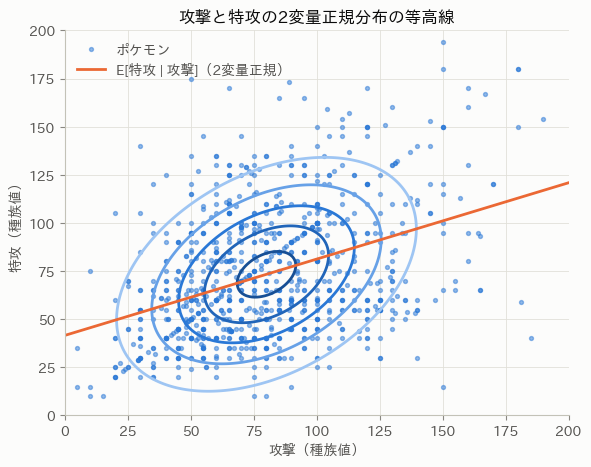

,件数,攻撃の平均,特攻の平均,特攻の分散,条件付き期待値(理論)
攻撃,,,,,
"(0, 50]",183,38.8,55.3,750.4,57.0
"(50, 75]",280,64.4,70.8,864.1,67.1
"(75, 100]",246,89.1,75.4,885.2,76.9
"(100, 125]",129,114.0,83.6,1161.3,86.8
"(125, 200]",82,145.2,100.0,1691.5,99.2


In [52]:
# 多変量正規分布: (攻撃, 特攻) に2変量正規分布を当てはめる
xy = df[["攻撃", "特攻"]].to_numpy(float)
mu_v = xy.mean(axis=0)
S_v = np.cov(xy.T, ddof=0)                             # 最尤推定（n で割る）
s1v, s2v = np.sqrt(np.diag(S_v))
rho = S_v[0, 1] / (s1v * s2v)
print(f"平均ベクトル {mu_v.round(1)}  標準偏差 ({s1v:.1f}, {s2v:.1f})  相関 ρ = {rho:.3f}")
# 1次結合 攻撃+特攻 の分散 = σ1² + σ2² + 2ρσ1σ2
print(f"V[攻撃+特攻]: 公式 {s1v**2 + s2v**2 + 2 * rho * s1v * s2v:.1f}  直接計算 {xy.sum(axis=1).var():.1f}")
# マハラノビス距離の2乗は、2変量正規なら χ²(2) に従う → 95%楕円の内側の割合
d2 = np.einsum("ij,jk,ik->i", xy - mu_v, np.linalg.inv(S_v), xy - mu_v)
print(f"95%楕円（χ²(2) の上側5%点 {stats.chi2.ppf(0.95, 2):.2f}）の内側: {(d2 <= stats.chi2.ppf(0.95, 2)).mean():.3f}")
# 条件付き分布: 特攻 | 攻撃 = x は平均 μ2 + ρ(σ2/σ1)(x - μ1)、分散 σ2²(1 - ρ²) の正規分布
bins_atk = pd.cut(df["攻撃"], [0, 50, 75, 100, 125, 200])
cond_tab = df.groupby(bins_atk, observed=True).agg(件数=("特攻", "size"), 攻撃の平均=("攻撃", "mean"),
                                                   特攻の平均=("特攻", "mean"), 特攻の分散=("特攻", "var"))
cond_tab["条件付き期待値(理論)"] = mu_v[1] + rho * s2v / s1v * (cond_tab["攻撃の平均"] - mu_v[0])
print(f"条件付き分散（理論）σ2²(1-ρ²) = {s2v**2 * (1 - rho**2):.0f}  （無条件の分散 {s2v**2:.0f}）")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(xy[:, 0], xy[:, 1], s=8, alpha=0.5, color=PALETTE[0], label="ポケモン")
gx, gy = np.meshgrid(np.linspace(0, 200, 200), np.linspace(0, 200, 200))
dens = stats.multivariate_normal(mu_v, S_v).pdf(np.dstack([gx, gy]))
cs = ax.contour(gx, gy, dens, levels=5, cmap=SEQ_CMAP)
xl = np.array([0, 200])
ax.plot(xl, mu_v[1] + rho * s2v / s1v * (xl - mu_v[0]), color=PALETTE[1], label="E[特攻 | 攻撃]（2変量正規）")
ax.set(title="攻撃と特攻の2変量正規分布の等高線", xlabel="攻撃（種族値）", ylabel="特攻（種族値）", xlim=(0, 200), ylim=(0, 200))
ax.legend(loc="upper left")
plt.show()
cond_tab.round(1)

**結果の読み方**
- 平均は（攻撃80, 特攻73）、標準偏差はどちらも約33、相関 $\hat\rho\approx 0.39$。95%楕円の内側の割合は約0.950 で、この点では2変量正規とよく合う。
- 攻撃の区間ごとの特攻の平均は、条件付き期待値の直線（傾き $\rho\sigma_2/\sigma_1\approx0.40$）にほぼ沿う。
- 一方、特攻の条件付き分散は攻撃が低い群で約750、高い群で約1690と攻撃とともに大きくなり、2変量正規の条件付き分散（一定の約936）と合わない。中心部の形は2変量正規で近似できるが、ばらつきの構造（不均一分散）は表せない。

### 6.8 標本分布：$\chi^2$ 分布

**問い**：全ポケモンを母集団として大きさ $n=10$ の標本を抽出すると、$(n-1)S^2/\sigma^2$ は $\chi^2(n-1)$ に従うか。

**手法の要点**
- $Z_1,\dots,Z_k$ が独立に $N(0,1)$ に従うとき $\sum Z_i^2\sim\chi^2(k)$。$\chi^2(k)=\mathrm{Ga}(k/2,2)$ で、平均 $k$、分散 $2k$。
- $X_1,\dots,X_n$ が独立に $N(\mu,\sigma^2)$ に従うとき、不偏分散 $S^2=\frac{1}{n-1}\sum(X_i-\bar X)^2$ について $\dfrac{(n-1)S^2}{\sigma^2}\sim\chi^2(n-1)$ であり、$\bar X$ と $S^2$ は独立。
- **正規母集団が前提**。母集団の尖度を $\kappa=E[(X-\mu)^4]/\sigma^4-3$ とすると、一般に $V[S^2]=\sigma^4\left(\dfrac{2}{n-1}+\dfrac{\kappa}{n}\right)$ で、正規（$\kappa=0$）のときだけ $\chi^2$ 分布の分散 $2(n-1)$ に一致する。
- 行を復元抽出するので標本は i.i.d. だが、母集団分布は920点からなる離散分布で正規ではない。

（→ py 06-8：合計種族値（$\kappa\approx-0.5$）と重さ（$\kappa\approx24$）で5000回抽出して比べる）

合計種族値: 尖度 κ = -0.53  W の平均 9.07（χ² の理論 9）  分散 14.0（χ² の理論 18、尖度を考慮 13.7）  P(W > χ²_0.05(9)) = 0.030
重さ: 尖度 κ = 23.55  W の平均 8.93（χ² の理論 9）  分散 207.4（χ² の理論 18、尖度を考慮 208.7）  P(W > χ²_0.05(9)) = 0.139


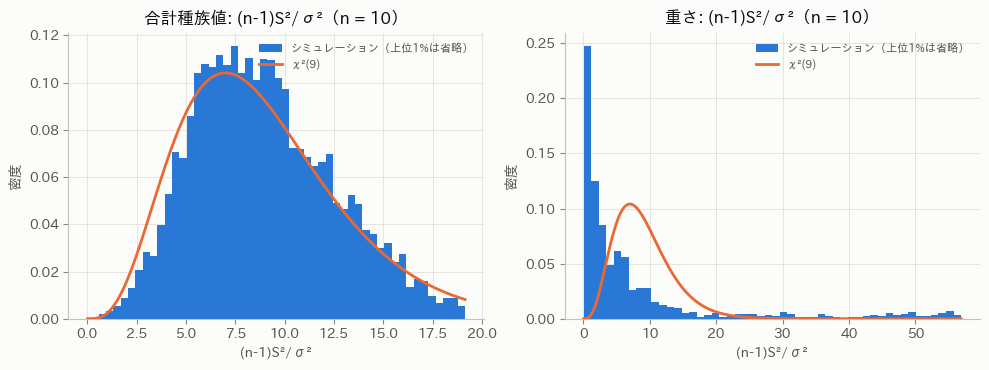

In [53]:
# 標本分布（χ² 分布）: 全ポケモンを母集団とみなし、大きさ n の標本を繰り返し抽出する
# 復元抽出なので各標本は母集団分布からの i.i.d. 標本。母分散は n ではなく N で割った値（ddof=0）
def draw_samples_06(values, n, reps, rng):
    """母集団 values から大きさ n の標本を reps 組、復元抽出した (reps, n) 配列."""
    return values[rng.integers(0, len(values), size=(reps, n))]

rng = get_rng()
n_s, reps_s = 10, 5000
pops_06 = {"合計種族値": bst, "重さ": wt}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (name, pop) in zip(axes, pops_06.items()):
    sig2 = pop.var(ddof=0)
    kappa = stats.kurtosis(pop)                         # 母集団の尖度（正規なら0）
    smp = draw_samples_06(pop, n_s, reps_s, rng)
    W = (n_s - 1) * smp.var(axis=1, ddof=1) / sig2      # 正規母集団なら χ²(n-1)
    # 非正規母集団での理論分散: V[S²] = σ⁴(2/(n-1) + κ/n) より V[W] = (n-1)²(2/(n-1) + κ/n)
    print(f"{name}: 尖度 κ = {kappa:.2f}  W の平均 {W.mean():.2f}（χ² の理論 {n_s - 1}）"
          f"  分散 {W.var():.1f}（χ² の理論 {2 * (n_s - 1)}、尖度を考慮 {(n_s - 1) ** 2 * (2 / (n_s - 1) + kappa / n_s):.1f}）"
          f"  P(W > χ²_0.05(9)) = {(W > stats.chi2.ppf(0.95, n_s - 1)).mean():.3f}")
    xmax = np.percentile(W, 99)
    ax.hist(W[W <= xmax], bins=50, density=True, color=PALETTE[0], label="シミュレーション（上位1%は省略）")
    g = np.linspace(0.01, xmax, 300)
    ax.plot(g, stats.chi2.pdf(g, n_s - 1), color=PALETTE[1], label=f"χ²({n_s - 1})")
    ax.set(title=f"{name}: (n-1)S²/σ²（n = {n_s}）", xlabel="(n-1)S²/σ²", ylabel="密度")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**結果の読み方**
- 平均はどちらも約9で理論値 $n-1=9$ に一致する（$E[S^2]=\sigma^2$ は分布によらない）。
- 分散は、合計種族値で約14（$\chi^2$ の18より小さく、尖度で補正した理論値13.7と一致）、重さで約207（18の10倍以上、補正値209と一致）。
- 上側5%点を超える割合は合計種族値で約3%、重さで約14%。重さのように裾の重い母集団では、$\chi^2$ 分布に基づく分散の推論（第9章の区間推定など）は大きく誤る。

### 6.9 標本分布：$t$ 分布

**問い**：$T=\dfrac{\bar X-\mu}{S/\sqrt n}$ は $t(n-1)$ に従うか。

**手法の要点**
- $Z\sim N(0,1)$ と $Y\sim\chi^2(k)$ が独立のとき $T=\dfrac{Z}{\sqrt{Y/k}}\sim t(k)$。$k>2$ で平均0、分散 $k/(k-2)$。$k\to\infty$ で $N(0,1)$ に分布収束する。
- 正規母集団では $Z=\dfrac{\bar X-\mu}{\sigma/\sqrt n}$ と $Y=\dfrac{(n-1)S^2}{\sigma^2}$ が独立なので、$T\sim t(n-1)$。
- 両側5%の棄却域 $|T|>t_{0.025}(9)\approx2.262$ の各側の確率が0.025 になるかで確かめる。

（→ py 06-9：合計種族値と重さで $n=10$ の $t$ 統計量を5000回計算する）

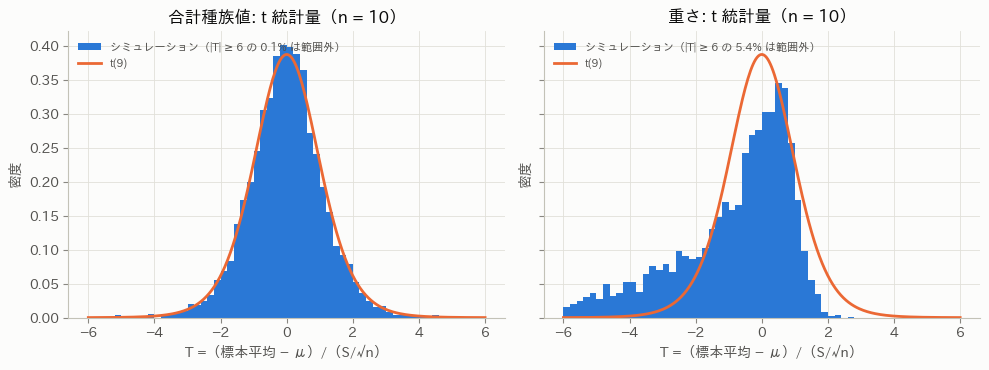

t_0.025(9) = 2.262


,母集団,P(T < -t),P(T > t),理論（各側）,T の平均
0,合計種族値,0.0256,0.0234,0.025,-0.0176
1,重さ,0.2408,0.0006,0.025,-1.2517


In [54]:
# 標本分布（t 分布）: T = (X̄ - μ)/(S/√n) を t(n-1) と比べる
rng = get_rng()
t_crit = stats.t.ppf(0.975, n_s - 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
rows_t = []
for ax, (name, pop) in zip(axes, pops_06.items()):
    smp = draw_samples_06(pop, n_s, reps_s, rng)
    T = (smp.mean(axis=1) - pop.mean()) / (smp.std(axis=1, ddof=1) / np.sqrt(n_s))
    rows_t.append({"母集団": name, "P(T < -t)": (T < -t_crit).mean(), "P(T > t)": (T > t_crit).mean(),
                   "理論（各側）": 0.025, "T の平均": T.mean()})
    g = np.linspace(-6, 6, 300)
    # |T| ≥ 6 は表示しないが、密度は全 reps_s 回で割る（表示範囲だけで正規化すると高さが水増しされる）
    T_in = T[(T > -6) & (T < 6)]
    ax.hist(T_in, bins=60, range=(-6, 6), weights=np.full(len(T_in), 1 / (reps_s * 0.2)), color=PALETTE[0],
            label=f"シミュレーション（|T| ≥ 6 の {1 - len(T_in) / reps_s:.1%} は範囲外）")
    ax.plot(g, stats.t.pdf(g, n_s - 1), color=PALETTE[1], label=f"t({n_s - 1})")
    ax.set(title=f"{name}: t 統計量（n = {n_s}）", xlabel="T =（標本平均 − μ）/（S/√n）", ylabel="密度")
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()
print(f"t_0.025({n_s - 1}) = {t_crit:.3f}")
pd.DataFrame(rows_t).round(4)

**結果の読み方**
- 合計種族値では各側の確率が約0.026・0.023で、$t(9)$ によく合う。対称で裾の軽い母集団なら $n=10$ でも $t$ 分布の近似は頑健である。
- 重さでは下側が約0.24、上側がほぼ0で、分布が大きく左に歪む（$T$ の平均約 $-1.25$）。右に歪んだ母集団では $\bar X$ と $S$ が正の相関をもち、重いポケモンを含まない標本では平均も標準偏差も小さくなって $T$ が大きな負の値になるためである。
- 平均の $t$ 検定・$t$ 区間を重さにそのまま使うのは危険で、対数変換（第4章）や大きな $n$（第7章）が必要になる。

### 6.10 標本分布：$F$ 分布

**問い**：同じ母集団からの独立な2標本（$n_1=10$, $n_2=15$）の分散比 $F=S_1^2/S_2^2$ は $F(n_1-1,n_2-1)$ に従うか。

**手法の要点**
- $Y_1\sim\chi^2(k_1)$ と $Y_2\sim\chi^2(k_2)$ が独立のとき $F=\dfrac{Y_1/k_1}{Y_2/k_2}\sim F(k_1,k_2)$。$T\sim t(k)$ なら $T^2\sim F(1,k)$。
- 正規母集団で $\sigma_1^2=\sigma_2^2$ なら $\dfrac{S_1^2}{S_2^2}\sim F(n_1-1,n_2-1)$。
- 上側5%点 $F_{0.05}(9,14)\approx2.65$ を超える割合が0.05 になるかで確かめる。

（→ py 06-10：合計種族値と重さで分散比を5000回計算する）

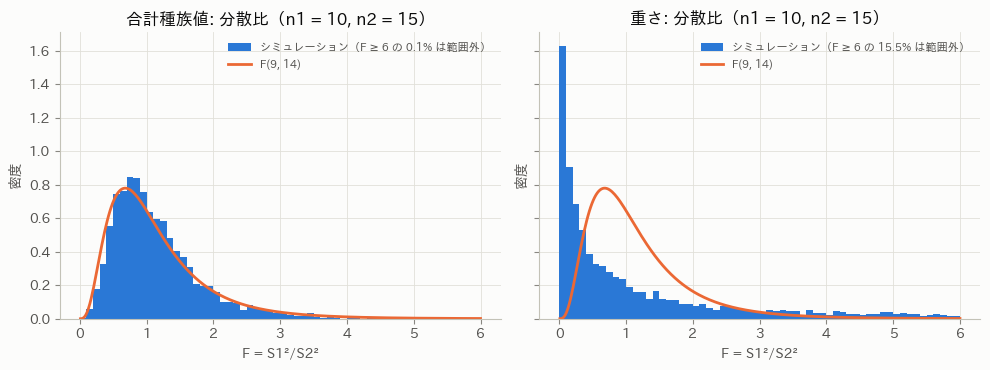

F_0.05(9, 14) = 2.646


,母集団,P(F > F_0.05),理論,F の中央値,理論の中央値
0,合計種族値,0.0334,0.05,0.9898,0.973
1,重さ,0.2696,0.05,0.7777,0.973


In [55]:
# 標本分布（F 分布）: 同じ母集団からの独立な2標本の分散比 F = S1²/S2² を F(n1-1, n2-1) と比べる
rng = get_rng()
n1_f, n2_f = 10, 15
f_crit = stats.f.ppf(0.95, n1_f - 1, n2_f - 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
rows_f = []
for ax, (name, pop) in zip(axes, pops_06.items()):
    s1_sq = draw_samples_06(pop, n1_f, reps_s, rng).var(axis=1, ddof=1)
    s2_sq = draw_samples_06(pop, n2_f, reps_s, rng).var(axis=1, ddof=1)
    Fv = s1_sq / s2_sq                                  # 同じ母集団なので σ1² = σ2² が約分される
    rows_f.append({"母集団": name, "P(F > F_0.05)": (Fv > f_crit).mean(), "理論": 0.05,
                   "F の中央値": np.median(Fv), "理論の中央値": stats.f.median(n1_f - 1, n2_f - 1)})
    g = np.linspace(0.01, 6, 300)
    # F ≥ 6 は表示しないが、密度は全 reps_s 回で割る（表示範囲だけで正規化すると高さが水増しされる）
    F_in = Fv[Fv < 6]
    ax.hist(F_in, bins=60, range=(0, 6), weights=np.full(len(F_in), 1 / (reps_s * 0.1)), color=PALETTE[0],
            label=f"シミュレーション（F ≥ 6 の {1 - len(F_in) / reps_s:.1%} は範囲外）")
    ax.plot(g, stats.f.pdf(g, n1_f - 1, n2_f - 1), color=PALETTE[1], label=f"F({n1_f - 1}, {n2_f - 1})")
    ax.set(title=f"{name}: 分散比（n1 = {n1_f}, n2 = {n2_f}）", xlabel="F = S1²/S2²", ylabel="密度")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"F_0.05({n1_f - 1}, {n2_f - 1}) = {f_crit:.3f}")
pd.DataFrame(rows_f).round(4)

**結果の読み方**
- 合計種族値では上側5%点を超える割合が約0.033で、裾の軽さのためやや保守的だが、$F(9,14)$ に近い。
- 重さでは約0.27で、公称5%の5倍以上。分散比の $F$ 検定（第11章）は母集団の正規性に非常に敏感で、$t$ 検定よりも頑健性が低い。

### まとめ

- 合計種族値はほぼ対称だが多峰で、単一の正規分布より混合正規分布が合う（BIC では6成分）。重さは対数正規分布（AIC 最小・KS 距離最小）、攻撃はガンマ分布が相対的によく合った。捕獲率/255 は特定の値に集中しており、ベータ分布では表しきれない。
- 攻撃と特攻は相関約0.39の2変量正規で中心部を近似できるが、条件付き分散が一定という性質は成り立たない。
- $\chi^2$・$t$・$F$ 分布は正規母集団を前提とする。ほぼ対称な合計種族値では $n=10$ でも近似がよい一方、強く歪んだ重さでは標本分散の分布・$t$ 統計量・分散比のいずれも理論分布から大きく外れた。特に分散に関する推論（$\chi^2$・$F$）は正規性の破れに弱い。
- 限界：種族値などは整数で同じ値が多く、連続分布の当てはめは近似である。当てはめの良さは AIC・KS 距離などの相対比較にとどめた。

## 第7章 極限定理・漸近理論

### 章の概要

標本の大きさ $n$ を大きくしたとき、標本平均やその関数の分布がどうなるかを、全ポケモンを母集団とするシミュレーションで確かめる。
- **目的**：母集団分布がわからなくても、$n$ が大きければ標本平均を正規分布で近似できる根拠（大数の法則・中心極限定理）と、その近似がどれくらいの $n$ で使えるかを知る。
- **考え方**：真値（母平均・母分散）が既知の母集団から標本を繰り返し抽出し、統計量の分布を理論の極限分布と比べる。スルツキーの補題・連続写像定理・デルタ法で、極限分布を「標本平均の関数」に広げる。
- **つながり**：第6章では母集団が正規でないと $t$・$\chi^2$ 分布が崩れることを見た。この章はその救済策（$n\to\infty$）を与える。第8章の最尤推定量の漸近正規性、第9章以降の大標本の区間推定・検定の基礎になる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 7.1 | 大数の弱法則 | 重さの標本平均は母平均に近づくか。チェビシェフの上界とどう違うか |
| 7.2 | 中心極限定理 | 強く歪んだ重さの標本平均は、$n=5,30,100$ で正規分布に近いか |
| 7.3 | 連続修正 | 二項分布の正規近似で、端を0.5ずらすとどれだけ改善するか |
| 7.4 | スルツキーの補題 | $\sigma$ を $S$ に置き換えた統計量も $N(0,1)$ で近似できるか |
| 7.5 | 連続写像定理 | $n(\bar X-\mu)^2/\sigma^2$ は $\chi^2(1)$ に近いか |
| 7.6 | デルタ法 | 標本平均の対数や割合のロジットの分散は近似式で求められるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `重さ` | 量的（kg） | 主な母集団。歪度約4.3・尖度約24と強く右に歪み、裾が重い |
| `合計種族値` | 量的 | 比較用のほぼ対称な母集団 |
| `タイプ1` | 質的 | 「みずか否か」の0/1変数を作り、割合の母集団にする |

- **対象の行**：全920行を**真値既知の母集団**とする。
- **加工**：行を復元抽出して大きさ $n$ の i.i.d. 標本を作る（関数 `sample_means_07`）。母分散は $N$ で割った値。7.3 は二項分布の計算のみ（簡略化モデル: 捕獲の成功確率 $p=45/255$ と仮定）。
- **データの性質と注意点**：母集団は920点からなる離散分布であり、極限定理の前提（平均・分散が有限、i.i.d.）は満たされる。収束の速さは母集団の歪み・裾の重さに強く依存する。

（→ py 07-0：母集団の平均・標準偏差・歪度・尖度を表示し、抽出用の関数を定義する）

In [56]:
# 母集団（全920行）の真値。以降は行を復元抽出して i.i.d. 標本を作る
wt07 = df["重さ"].to_numpy(float)
bst07 = df["合計種族値"].to_numpy(float)
water07 = (df["タイプ1"] == "みず").to_numpy()
pop07 = pd.DataFrame({
    "母平均 μ": [wt07.mean(), bst07.mean(), water07.mean()],
    "母標準偏差 σ": [wt07.std(), bst07.std(), water07.std()],
    "歪度": [stats.skew(wt07), stats.skew(bst07), stats.skew(water07)],
    "尖度(-3)": [stats.kurtosis(wt07), stats.kurtosis(bst07), stats.kurtosis(water07)],
}, index=["重さ (kg)", "合計種族値", "タイプ1がみず (0/1)"])


def sample_means_07(values, n, reps, rng):
    """母集団 values から大きさ n の標本を reps 組復元抽出し、(標本平均, 不偏標準偏差) を返す."""
    smp = values[rng.integers(0, len(values), size=(reps, n))]
    return smp.mean(axis=1), smp.std(axis=1, ddof=1)

pop07.round(3)

,母平均 μ,母標準偏差 σ,歪度,尖度(-3)
重さ (kg),69.159,124.638,4.335,23.549
合計種族値,438.468,120.266,0.097,-0.532
タイプ1がみず (0/1),0.135,0.341,2.139,2.575


### 7.1 大数の弱法則

**問い**：重さの標本平均 $\bar X_n$ は、$n$ を大きくすると母平均 $\mu$ に近づくか。

**手法の要点**
- 大数の弱法則：$X_1,X_2,\dots$ が i.i.d. で平均 $\mu$、分散 $\sigma^2<\infty$ のとき、任意の $\varepsilon>0$ に対し $\lim_{n\to\infty}P(|\bar X_n-\mu|>\varepsilon)=0$（確率収束 $\bar X_n\xrightarrow{p}\mu$）。
- 証明はチェビシェフの不等式 $P(|\bar X_n-\mu|>\varepsilon)\le\dfrac{V[\bar X_n]}{\varepsilon^2}=\dfrac{\sigma^2}{n\varepsilon^2}$ による。$V[\bar X_n]=\sigma^2/n\to0$ なので平均二乗収束もしている。
- ここでは $\varepsilon=20$ kg とし、2000回の抽出で確率を推定して上界と比べる。

（→ py 07-1：標本平均の経路を3本描き、離れる確率とチェビシェフの上界を $n$ ごとに比べる）

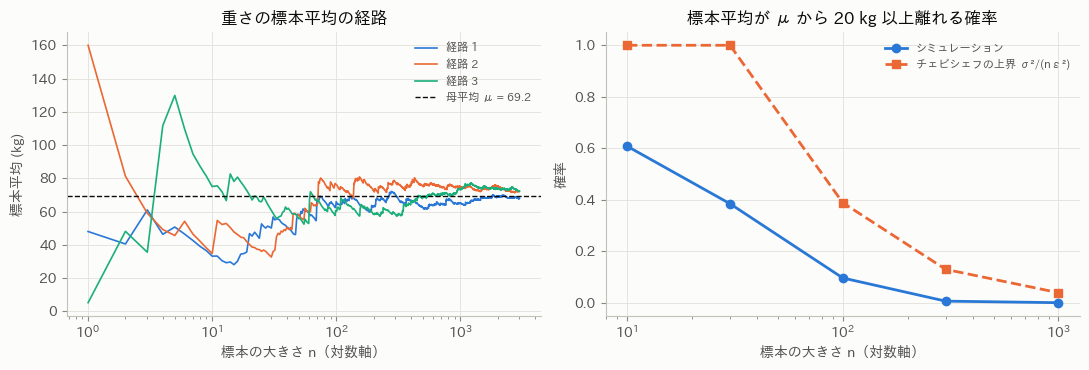

,n,P(|X̄-μ|>ε) シミュ,チェビシェフの上界,X̄ の標準偏差,理論 σ/√n
0,10,0.6080,1.0000,40.0504,39.4139
1,30,0.3845,1.0000,23.0222,22.7556
2,100,0.0960,0.3884,12.4026,12.4638
3,300,0.0060,0.1295,7.2586,7.1960
4,1000,0.0000,0.0388,4.0490,3.9414


In [57]:
# 大数の弱法則: 重さの標本平均が母平均に近づく
rng = get_rng()
mu_w, sd_w = wt07.mean(), wt07.std()
n_max = 3000
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for j in range(3):                                       # 3本の独立な標本経路
    path = wt07[rng.integers(0, len(wt07), n_max)]
    axes[0].plot(np.arange(1, n_max + 1), np.cumsum(path) / np.arange(1, n_max + 1),
                 lw=1.2, color=PALETTE[j], label=f"経路 {j + 1}")
axes[0].axhline(mu_w, color=INK["primary"], lw=1, ls="--", label=f"母平均 μ = {mu_w:.1f}")
axes[0].set(xscale="log", title="重さの標本平均の経路", xlabel="標本の大きさ n（対数軸）", ylabel="標本平均 (kg)")
axes[0].legend(fontsize=8)

# P(|X̄ - μ| > ε) とチェビシェフの不等式の上界 σ²/(nε²)
eps = 20.0
rows_lln = []
for n in [10, 30, 100, 300, 1000]:
    xbar, _ = sample_means_07(wt07, n, 2000, rng)
    rows_lln.append({"n": n, "P(|X̄-μ|>ε) シミュ": (np.abs(xbar - mu_w) > eps).mean(),
                     "チェビシェフの上界": min(1.0, sd_w**2 / (n * eps**2)), "X̄ の標準偏差": xbar.std(),
                     "理論 σ/√n": sd_w / np.sqrt(n)})
tab_lln = pd.DataFrame(rows_lln)
axes[1].plot(tab_lln["n"], tab_lln["P(|X̄-μ|>ε) シミュ"], "o-", color=PALETTE[0], label="シミュレーション")
axes[1].plot(tab_lln["n"], tab_lln["チェビシェフの上界"], "s--", color=PALETTE[1], label="チェビシェフの上界 σ²/(nε²)")
axes[1].set(xscale="log", title=f"標本平均が μ から {eps:.0f} kg 以上離れる確率", xlabel="標本の大きさ n（対数軸）", ylabel="確率")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
tab_lln.round(4)

**結果の読み方**
- 3本の経路はどれも $n$ が数百を超えると母平均69.2 kg の近くに落ち着く。ただし重いポケモン（最大999.9 kg）を1匹引くたびに平均が跳ね上がるため、収束は遅い。
- 20 kg 以上離れる確率は $n=10$ で約0.61、$n=100$ で約0.10、$n=1000$ でほぼ0。標本平均の標準偏差は理論値 $\sigma/\sqrt n$（$n=100$ で約12.5 kg）と一致する。
- チェビシェフの上界（$n=100$ で約0.39）は常に成り立つが、実際の確率よりかなり大きい。分布の形を使わない代わりに粗い評価である。

### 7.2 中心極限定理

**問い**：強く右に歪んだ重さの母集団から $n=5,30,100$ の標本を取ると、標本平均はどれくらい正規分布に近いか。

**手法の要点**
- 中心極限定理：$X_1,X_2,\dots$ が i.i.d. で平均 $\mu$、分散 $\sigma^2\ (0<\sigma^2<\infty)$ のとき
  $$Z_n=\frac{\sqrt n(\bar X_n-\mu)}{\sigma}\xrightarrow{d}N(0,1).$$
- 母集団の歪度を $\gamma$ とすると、$\bar X_n$ の歪度はちょうど $\gamma/\sqrt n$ で、ゆっくりとしか0に近づかない。「$n=30$ なら十分」という目安は、歪みの強い母集団では成り立たないことがある。
- 近似の良さは歪度・KS 距離・片側5%点を超える確率で測る。

（→ py 07-2：各 $n$ で5000回、標準化した標本平均の分布を $N(0,1)$ と比べる）

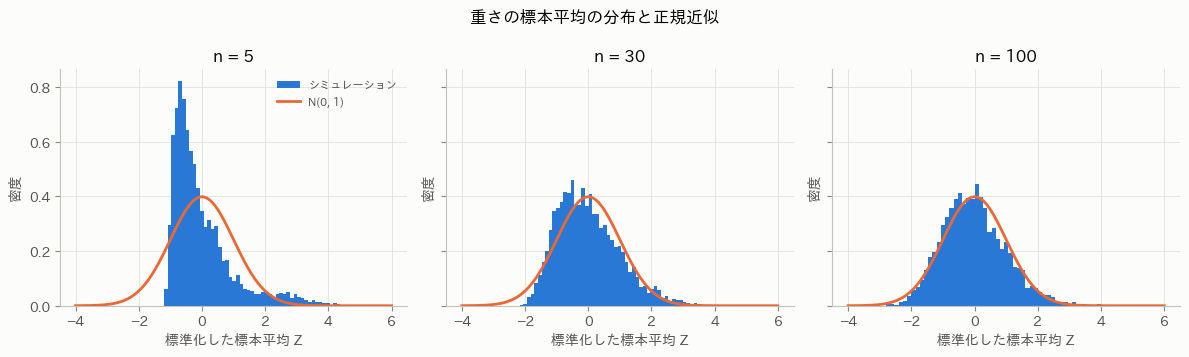

母集団（重さ）の歪度 γ = 4.34。正規近似なら P(Z > 1.645) = P(Z < -1.645) = 0.05


,n,Z の歪度（シミュ）,理論 γ/√n,"KS距離 vs N(0,1)",P(Z > 1.645),P(Z < -1.645)
0,5,1.9898,1.9388,0.1467,0.0808,0.0000
1,30,0.7352,0.7915,0.0530,0.0642,0.0136
2,100,0.4860,0.4335,0.0398,0.0584,0.0344


In [58]:
# 中心極限定理: 歪んだ母集団（重さ）の標本平均を標準化した Z = (X̄ - μ)/(σ/√n)
rng = get_rng()
gamma_w = stats.skew(wt07)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
g = np.linspace(-4, 6, 300)
rows_clt = []
for ax, n in zip(axes, [5, 30, 100]):
    xbar, _ = sample_means_07(wt07, n, 5000, rng)
    z = (xbar - mu_w) / (sd_w / np.sqrt(n))
    rows_clt.append({"n": n, "Z の歪度（シミュ）": stats.skew(z), "理論 γ/√n": gamma_w / np.sqrt(n),
                     "KS距離 vs N(0,1)": stats.kstest(z, "norm").statistic,
                     "P(Z > 1.645)": (z > 1.645).mean(), "P(Z < -1.645)": (z < -1.645).mean()})
    ax.hist(z[(z > -4) & (z < 6)], bins=60, density=True, color=PALETTE[0], label="シミュレーション")
    ax.plot(g, stats.norm.pdf(g), color=PALETTE[1], label="N(0, 1)")
    ax.set(title=f"n = {n}", xlabel="標準化した標本平均 Z", ylabel="密度")
axes[0].legend(fontsize=8)
fig.suptitle("重さの標本平均の分布と正規近似", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()
print(f"母集団（重さ）の歪度 γ = {gamma_w:.2f}。正規近似なら P(Z > 1.645) = P(Z < -1.645) = 0.05")
pd.DataFrame(rows_clt).round(4)

**結果の読み方**
- 母集団の歪度は約4.3。$Z_n$ の歪度は $n=5$ で約2.0、$n=30$ で約0.7、$n=100$ で約0.5 と、理論値 $\gamma/\sqrt n$（1.94, 0.79, 0.43）とほぼ一致して小さくなる。
- $n=5$ では山が左に寄って右に長い裾があり、正規分布とは大きく違う。$n=100$ ではかなり正規に近いが、上側5%点を超える確率は約0.058、下側は約0.034 と、なお非対称が残る。
- 重さのような裾の重い変数では、$n=100$ 程度でも片側の確率には誤差が残ることを念頭に置く（対数変換が有効な場合が多い）。

### 7.3 連続修正

**問い**：捕獲率45のポケモンに30回ボールを投げたときの成功回数 $X$（簡略化モデル: $X\sim\mathrm{Bin}(30,45/255)$）の確率を正規近似するとき、連続修正でどれだけ精度が上がるか。

**手法の要点**
- 中心極限定理より $X\sim\mathrm{Bin}(n,p)$ は $n$ が大きいとき $N(np,np(1-p))$ で近似できる。
- $X$ は整数値なので、$P(a\le X\le b)$ を $P(a-0.5\le Y\le b+0.5)$（$Y$ は正規分布）で近似するのが連続修正。確率1の棒を幅1の区間に広げて面積として読むことに当たる。
- 修正しないと、特に $P(X=a)=P(a\le X\le a)$ の近似が0になってしまう。
- 今回は $np\approx 5.3$、$\sqrt{np(1-p)}\approx 2.1$ で、$np$ があまり大きくない（分布が右に少し歪む）場合である。

（→ py 07-3：いくつかの区間の確率と、累積確率 $P(X\le k)$ の近似誤差を比べる）

Bin(30, 0.1765): 平均 np = 5.29, 標準偏差 √(np(1-p)) = 2.09


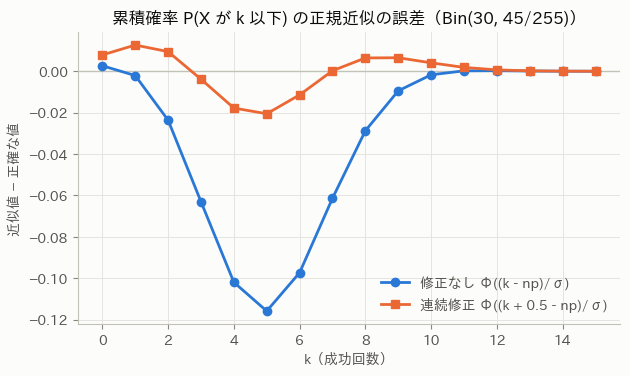

最大絶対誤差: 修正なし 0.1158  連続修正 0.0205


,正確（二項）,正規近似（修正なし）,正規近似（連続修正）
事象,,,
0 ≤ X ≤ 3,0.1989,0.1303,0.1923
4 ≤ X ≤ 7,0.6554,0.5253,0.6595
5 ≤ X ≤ 5,0.1902,0.0000,0.1874
8 ≤ X ≤ 30,0.1456,0.0975,0.1454
3 ≤ X ≤ 8,0.8503,0.7665,0.8472


In [59]:
# 連続修正: X ~ Bin(n, p) を N(np, np(1-p)) で近似するとき、区間の端を 0.5 ずつ広げる
# 例: 捕獲率45のポケモンに30回ボールを投げたときの成功回数（簡略化モデル: p = 45/255 と仮定）
n_b, p_b = 30, 45 / 255
m_b, s_b = n_b * p_b, np.sqrt(n_b * p_b * (1 - p_b))
print(f"Bin({n_b}, {p_b:.4f}): 平均 np = {m_b:.2f}, 標準偏差 √(np(1-p)) = {s_b:.2f}")
rows_cc = []
for a, b in [(0, 3), (4, 7), (5, 5), (8, 30), (3, 8)]:
    exact = stats.binom.cdf(b, n_b, p_b) - stats.binom.cdf(a - 1, n_b, p_b)
    no_cc = stats.norm.cdf(b, m_b, s_b) - stats.norm.cdf(a, m_b, s_b)
    with_cc = stats.norm.cdf(b + 0.5, m_b, s_b) - stats.norm.cdf(a - 0.5, m_b, s_b)
    rows_cc.append({"事象": f"{a} ≤ X ≤ {b}", "正確（二項）": exact, "正規近似（修正なし）": no_cc, "正規近似（連続修正）": with_cc})
tab_cc = pd.DataFrame(rows_cc).set_index("事象")

# P(X ≤ k) の近似誤差を k ごとに比べる
k = np.arange(0, 16)
err_no = stats.norm.cdf(k, m_b, s_b) - stats.binom.cdf(k, n_b, p_b)
err_cc = stats.norm.cdf(k + 0.5, m_b, s_b) - stats.binom.cdf(k, n_b, p_b)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.axhline(0, color=INK["axis"], lw=1)
ax.plot(k, err_no, "o-", color=PALETTE[0], label="修正なし Φ((k - np)/σ)")
ax.plot(k, err_cc, "s-", color=PALETTE[1], label="連続修正 Φ((k + 0.5 - np)/σ)")
ax.set(title="累積確率 P(X が k 以下) の正規近似の誤差（Bin(30, 45/255)）", xlabel="k（成功回数）", ylabel="近似値 − 正確な値")
ax.legend()
plt.show()
print(f"最大絶対誤差: 修正なし {np.abs(err_no).max():.4f}  連続修正 {np.abs(err_cc).max():.4f}")
tab_cc.round(4)

**結果の読み方**
- $P(4\le X\le7)$ の正確な値約0.655 に対し、修正なしは約0.525、連続修正は約0.660。$P(X=5)$ は正確な値約0.190、連続修正で約0.187、修正なしでは0になる。
- 累積確率 $P(X\le k)$ の最大絶対誤差は、修正なしで約0.12、連続修正で約0.02。$np\approx5$ と小さい場合でも、連続修正すれば実用的な近似になる。

### 7.4 スルツキーの補題

**問い**：母標準偏差 $\sigma$ の代わりに標本標準偏差 $S$ を使った $T_n=\sqrt n(\bar X_n-\mu)/S$ も $N(0,1)$ で近似できるか。

**手法の要点**
- スルツキーの補題：$U_n\xrightarrow{d}U$、$V_n\xrightarrow{p}a$（定数）のとき、$U_n+V_n\xrightarrow{d}U+a$、$U_nV_n\xrightarrow{d}aU$（$a\ne0$ なら $U_n/V_n\xrightarrow{d}U/a$）。
- $U_n=\sqrt n(\bar X_n-\mu)/\sigma\xrightarrow{d}N(0,1)$（中心極限定理）、$V_n=S/\sigma\xrightarrow{p}1$（大数の法則と連続写像）なので、$T_n=U_n/V_n\xrightarrow{d}N(0,1)$。
- 母集団が正規でなくても大標本の $z$ 検定・区間推定で $\sigma$ を $S$ で置き換えてよい根拠である。ただし収束の速さは保証しない。

（→ py 07-4：$n=10,30,100,500$ で、$\sigma$ 既知の $Z$ と置き換えた $T$ の両側の裾確率を比べる）

In [60]:
# スルツキーの補題: σ を標本標準偏差 S に置き換えた T = √n (X̄ - μ)/S も N(0,1) に分布収束する
rng = get_rng()
rows_sl = []
for n in [10, 30, 100, 500]:
    xbar, s = sample_means_07(wt07, n, 5000, rng)
    z_known = np.sqrt(n) * (xbar - mu_w) / sd_w             # σ 既知
    t_plug = np.sqrt(n) * (xbar - mu_w) / s                # σ を S で置き換え
    rows_sl.append({"n": n, "S/σ の平均": (s / sd_w).mean(), "|S/σ - 1| > 0.1 の割合": (np.abs(s / sd_w - 1) > 0.1).mean(),
                    "Z: P(<-1.96)": (z_known < -1.96).mean(), "Z: P(>1.96)": (z_known > 1.96).mean(),
                    "T: P(<-1.96)": (t_plug < -1.96).mean(), "T: P(>1.96)": (t_plug > 1.96).mean()})
print("N(0,1) なら各側 0.025")
pd.DataFrame(rows_sl).round(3)

N(0,1) なら各側 0.025


,n,S/σ の平均,|S/σ - 1| > 0.1 の割合,Z: P(<-1.96),Z: P(>1.96),T: P(<-1.96),T: P(>1.96)
0,10,0.797,0.917,0.000,0.056,0.261,0.002
1,30,0.900,0.900,0.001,0.038,0.156,0.002
2,100,0.970,0.710,0.013,0.038,0.092,0.007
3,500,0.992,0.385,0.019,0.034,0.049,0.015


**結果の読み方**
- $S/\sigma$ の平均は $n=10$ で約0.80、$n=500$ で約0.99 と1に近づくが、裾の重い重さでは $|S/\sigma-1|>0.1$ となる割合が $n=500$ でも約39%残り、$S\to\sigma$ の収束は遅い。
- $T$ の下側確率 $P(T<-1.96)$ は $n=10$ で約0.26、$n=100$ で約0.09、$n=500$ で約0.05 と公称値0.025 に向かって減るが、$n=500$ でもまだ2倍程度ある。$\sigma$ を $S$ に置き換えることで、$Z$ よりも非対称が大きくなる（6.9 で見た $\bar X$ と $S$ の正の相関による）。
- 極限では $N(0,1)$ だが、歪んだ母集団では大標本でも近似の誤差が無視できない。

### 7.5 連続写像定理

**問い**：$n(\bar X_n-\mu)^2/\sigma^2$ は $\chi^2(1)$ で近似できるか。

**手法の要点**
- 連続写像定理：$X_n\xrightarrow{d}X$ で $h$ が連続なら $h(X_n)\xrightarrow{d}h(X)$（確率収束でも同様）。
- $Z_n=\sqrt n(\bar X_n-\mu)/\sigma\xrightarrow{d}N(0,1)$ に $h(z)=z^2$ を適用すると $Z_n^2=\dfrac{n(\bar X_n-\mu)^2}{\sigma^2}\xrightarrow{d}\chi^2(1)$。
- 上側5%点 $\chi^2_{0.05}(1)\approx3.84$ を超える確率が0.05 に近いかで確かめる。これは両側の $|Z_n|>1.96$ と同じ事象である。

（→ py 07-5：合計種族値（$n=30$）と重さ（$n=100$）で $Z_n^2$ の分布を $\chi^2(1)$ と比べる）

合計種族値（n = 30）: P(Z² > 3.84) = 0.0534（χ²(1) では 0.05）  Z² の平均 1.019（理論 1）
重さ（n = 100）: P(Z² > 3.84) = 0.0480（χ²(1) では 0.05）  Z² の平均 1.009（理論 1）


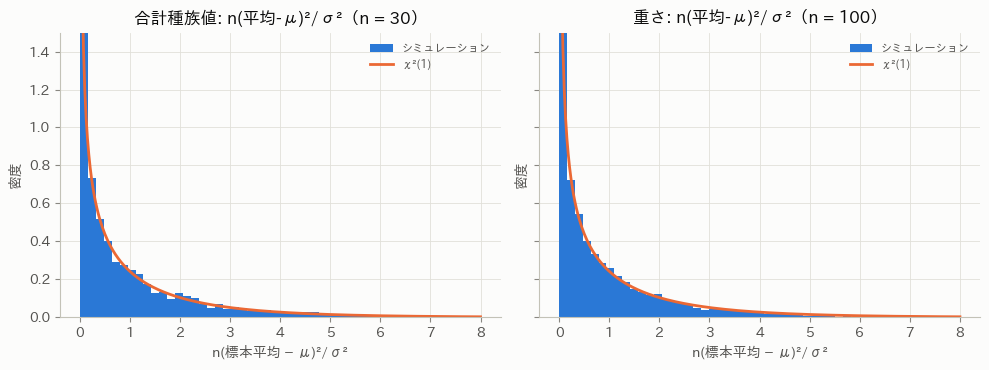

In [61]:
# 連続写像定理: Z_n → N(0,1) なら h(Z_n) = Z_n² → χ²(1)
rng = get_rng()
c95 = stats.chi2.ppf(0.95, 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
g = np.linspace(0.02, 8, 300)
for ax, (name, pop, n) in zip(axes, [("合計種族値", bst07, 30), ("重さ", wt07, 100)]):
    xbar, _ = sample_means_07(pop, n, 5000, rng)
    q = n * (xbar - pop.mean()) ** 2 / pop.var()          # = Z_n²
    ax.hist(q[q < 8], bins=50, density=True, color=PALETTE[0], label="シミュレーション")
    ax.plot(g, stats.chi2.pdf(g, 1), color=PALETTE[1], label="χ²(1)")
    ax.set(title=f"{name}: n(X̄-μ)²/σ²（n = {n}）".replace("X̄", "平均"), xlabel="n(標本平均 − μ)²/σ²", ylabel="密度", ylim=(0, 1.5))
    ax.legend(fontsize=8)
    print(f"{name}（n = {n}）: P(Z² > {c95:.2f}) = {(q > c95).mean():.4f}（χ²(1) では 0.05）  Z² の平均 {q.mean():.3f}（理論 1）")
fig.tight_layout()
plt.show()

**結果の読み方**
- 3.84 を超える確率は合計種族値で約0.053、重さで約0.048 と、どちらも0.05 に近い。$Z_n^2$ の平均も約1.0（理論値1）。
- 重さの $Z_n$ は上下の裾が非対称で、7.4 の表（$n=100$）では $P(Z<-1.96)\approx0.013$、$P(Z>1.96)\approx0.038$ だった。2乗すると両側の和（約0.05）だけを見ることになり誤差が打ち消し合うため、$\chi^2(1)$ との一致は片側の確率よりよく見える。

### 7.6 デルタ法

**問い**：重さの標本平均の対数 $\log\bar X_n$ と、みずタイプの割合 $\hat p$ のロジット $\log\frac{\hat p}{1-\hat p}$ の分散は、デルタ法の近似式と合うか。

**手法の要点**
- デルタ法：$\sqrt n(U_n-\theta)\xrightarrow{d}N(0,v)$ で、$h$ が $\theta$ で微分可能かつ $h'(\theta)\ne0$ なら
  $$\sqrt n\,(h(U_n)-h(\theta))\xrightarrow{d}N\!\left(0,\ h'(\theta)^2v\right).$$
  1次のテイラー展開 $h(U_n)\approx h(\theta)+h'(\theta)(U_n-\theta)$ による。
- (a) $h(x)=\log x$、$h'(\mu)=1/\mu$ より $V[\log\bar X_n]\approx\dfrac{\sigma^2}{n\mu^2}$（変動係数の2乗$/n$）。
- (b) $\hat p$ は0/1変数の平均で $v=p(1-p)$。$h(p)=\log\frac{p}{1-p}$、$h'(p)=\frac{1}{p(1-p)}$ より $V[\mathrm{logit}\,\hat p]\approx\dfrac{1}{np(1-p)}$。$\hat p=0,1$ ではロジットが定義できないので、その標本は除いた。
- 非線形変換では $E[h(U_n)]\ne h(\theta)$ で、$O(1/n)$ の偏りが出る（例えば $\log$ は凹関数なので $E[\log\bar X_n]<\log\mu$）。

（→ py 07-6：(a)(b) それぞれ3つの $n$ で、シミュレーションの分散をデルタ法の分散と比べる）

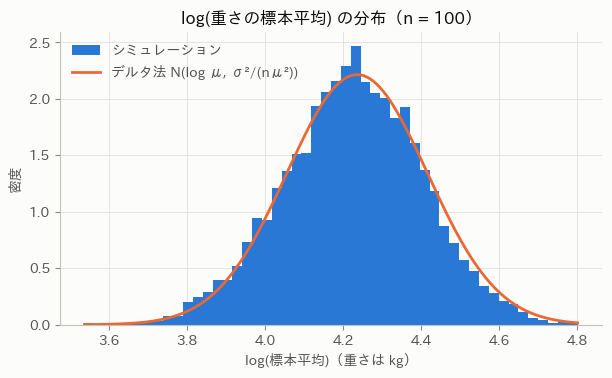

,推定量,n,平均 − h(θ),分散（シミュ）,デルタ法の分散,除外（p̂ = 0 or 1）
0,log(重さの標本平均),30,-0.05292,0.10908,0.10826,NaN
1,log(重さの標本平均),100,-0.01783,0.03262,0.03248,NaN
2,log(重さの標本平均),300,-0.00596,0.01070,0.01083,NaN
3,logit(みずの割合),50,-0.05868,0.20559,0.17150,3.0
4,logit(みずの割合),200,-0.01492,0.04498,0.04288,0.0
5,logit(みずの割合),800,-0.00614,0.01107,0.01072,0.0


In [62]:
# デルタ法: √n (U_n - θ) → N(0, v) なら √n (h(U_n) - h(θ)) → N(0, h'(θ)² v)
rng = get_rng()
rows_dm = []
# (a) 重さの標本平均の対数: h(x) = log x, h'(μ) = 1/μ → V[log X̄] ≈ σ²/(nμ²)
for n in [30, 100, 300]:
    xbar, _ = sample_means_07(wt07, n, 5000, rng)
    lx = np.log(xbar)
    rows_dm.append({"推定量": "log(重さの標本平均)", "n": n, "平均 − h(θ)": lx.mean() - np.log(mu_w),
                    "分散（シミュ）": lx.var(), "デルタ法の分散": sd_w**2 / (n * mu_w**2)})
logs_100 = np.log(sample_means_07(wt07, 100, 5000, rng)[0])
# (b) みずタイプの割合のロジット: h(p) = log(p/(1-p)), h'(p) = 1/(p(1-p)) → V ≈ 1/(np(1-p))
p_w = water07.mean()
for n in [50, 200, 800]:
    ph = water07[rng.integers(0, len(water07), size=(5000, n))].mean(axis=1)
    ok = (ph > 0) & (ph < 1)                              # p̂ = 0, 1 ではロジットが定義できない
    lg = np.log(ph[ok] / (1 - ph[ok]))
    rows_dm.append({"推定量": "logit(みずの割合)", "n": n, "平均 − h(θ)": lg.mean() - np.log(p_w / (1 - p_w)),
                    "分散（シミュ）": lg.var(), "デルタ法の分散": 1 / (n * p_w * (1 - p_w)),
                    "除外（p̂ = 0 or 1）": int((~ok).sum())})

fig, ax = plt.subplots(figsize=(7, 3.8))
g = np.linspace(logs_100.min(), logs_100.max(), 300)
ax.hist(logs_100, bins=50, density=True, color=PALETTE[0], label="シミュレーション")
ax.plot(g, stats.norm.pdf(g, np.log(mu_w), sd_w / (np.sqrt(100) * mu_w)), color=PALETTE[1],
        label="デルタ法 N(log μ, σ²/(nμ²))")
ax.set(title="log(重さの標本平均) の分布（n = 100）", xlabel="log(標本平均)（重さは kg）", ylabel="密度")
ax.legend()
plt.show()
pd.DataFrame(rows_dm).round(5)

**結果の読み方**
- (a) $\log\bar X_n$ の分散は $n=30$ で約0.109（デルタ法0.108）、$n=100$ で約0.033（0.032）と、よく一致する。平均は $\log\mu$ よりわずかに小さく（$n=30$ で約 $-0.05$）、凹関数による下向きの偏りが見える。$n=100$ のヒストグラムはデルタ法の正規分布によく重なる。
- (b) ロジットの分散は $n=200$ で約0.045（デルタ法0.043）、$n=800$ で約0.011（0.011）と合う。$n=50$ では約0.21 に対してデルタ法0.17 と過小で、$\hat p=0$ の標本も3回出た。$np\approx 7$ と小さいと1次近似が粗くなる。

### まとめ

- 重さの標本平均は大数の法則どおり母平均69 kg に近づき、標準化すると中心極限定理どおり正規分布に近づいた。ただし母集団の歪度が約4.3と大きいため、標本平均の歪度は $4.3/\sqrt n$ でしか減らず、$n=100$ でも片側確率に誤差が残った。
- 二項分布の正規近似は連続修正で誤差が約0.12から約0.02に減った。スルツキーの補題・連続写像定理・デルタ法による極限分布は、$n$ が十分大きければシミュレーションとよく合った。
- 限界：極限定理は「いずれ近づく」ことしか保証しない。必要な $n$ は母集団の歪み・裾の重さによって大きく異なり、特に $\sigma$ を $S$ で置き換えた統計量は、歪んだ母集団では $n=500$ でも公称の有意水準から外れた。

## 第8章 統計的推定の基礎

### 章の概要

標本から母数を推定する方法（モーメント法・最尤法）と、推定量のよさを測る基準（バイアス・分散・MSE・不偏性・有効性・十分性）を扱う。全ポケモンを**真値が既知の母集団**とみなし、標本を繰り返し抽出して推定量の性質をシミュレーションで確かめる。
- **目的**：推定量をどう作るか、作った推定量がどれくらいよいかを、数値で比べられるようにする。
- **考え方**：推定量も確率変数であり、その分布（期待値・分散）で評価する。最尤推定量は大標本で漸近正規で、分散はフィッシャー情報量から求まる。不偏推定量の分散の下限はクラメール・ラオの不等式で与えられる。
- **つながり**：第7章の極限定理（大数の法則・中心極限定理・デルタ法）を推定量に当てはめる。第9章の区間推定は、この章の標準誤差と漸近正規性を使う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 8.1 | モーメント法と最尤法 | 攻撃のガンマ分布の母数を2つの方法で推定すると、どちらが精度がよいか |
| 8.2 | 最尤推定量の漸近正規性・フィッシャー情報量 | 捕獲の成功確率の最尤推定量の標準誤差はいくらか |
| 8.3 | バイアス・バリアンス分解 | 標本分散は $n-1$・$n$・$n+1$ のどれで割るのがよいか |
| 8.4 | 不偏推定量 | 復元・非復元抽出で、標本平均・不偏分散・標本標準偏差は不偏か |
| 8.5 | ジャックナイフ推定量 | 重さの母平均の対数を推定するときの偏りを補正できるか |
| 8.6 | クラメール・ラオの不等式 | 標本割合・標本平均・標本中央値の分散は下限に達するか |
| 8.7 | 有効推定量と相対効率 | 平均の推定に、平均・中央値・刈込平均・中点のどれを使うべきか |
| 8.8 | 十分統計量 | 複合タイプか否かの列で、合計を与えると並び方の情報は $p$ によらないか |
| 8.9 | 順序統計量 | 11匹の標本の最大値・中央値はどう分布するか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的 | 分散・平均の推定、順序統計量の母集団（ほぼ対称、尖度約 $-0.5$） |
| `重さ` | 量的（kg） | 裾の重い母集団（尖度約24）。分散推定・ジャックナイフ |
| `攻撃` | 量的 | ガンマ分布の当てはめ（8.1） |
| `複合タイプ` | 0/1 | ベルヌーイ分布（母集団での割合 $p\approx0.539$） |
| `捕獲率` | 整数 | 簡略化モデル（成功確率 $p=\text{捕獲率}/255$）の幾何分布（8.2） |

- **対象の行**：全920行を真値既知の母集団とする。母平均・母分散（$N$ で割る）が推定の目標となる真値である。
- **加工**：主に行の**復元抽出**で i.i.d. 標本を作る（関数 `draw08`）。8.4 では非復元抽出とも比べる。8.1・8.2・8.6・8.7 の一部は、データから決めた母数をもつパラメトリックな分布（ガンマ・幾何・正規）から乱数を生成する。
- **データの性質と注意点**：母集団は離散分布で、正規でもガンマでもない。「モデルが正しい場合の性質」を見る節（パラメトリック分布から生成）と、「実際の母集団での性質」を見る節（行の抽出）を区別して読む。

（→ py 08-0：真値（母平均・母分散・尖度）を表示し、抽出用の関数を定義する）

In [63]:
# 真値既知の母集団（全920行）の値
bst08 = df["合計種族値"].to_numpy(float)
wt08 = df["重さ"].to_numpy(float)
atk08 = df["攻撃"].to_numpy(float)
dual08 = df["複合タイプ"].to_numpy(int)
true08 = pd.DataFrame({
    "母平均": [bst08.mean(), wt08.mean(), atk08.mean(), dual08.mean()],
    "母分散（N で割る）": [bst08.var(), wt08.var(), atk08.var(), dual08.var()],
    "尖度(-3)": [stats.kurtosis(bst08), stats.kurtosis(wt08), stats.kurtosis(atk08), np.nan],
}, index=["合計種族値", "重さ (kg)", "攻撃", "複合タイプ (0/1)"])


def draw08(values, n, reps, rng):
    """母集団 values から大きさ n の標本を reps 組、復元抽出した (reps, n) 配列."""
    return values[rng.integers(0, len(values), size=(reps, n))]

true08.round(3)

,母平均,母分散（N で割る）,尖度(-3)
合計種族値,438.468,14463.932,-0.532
重さ (kg),69.159,15534.577,23.549
攻撃,80.070,1057.882,0.057
複合タイプ (0/1),0.539,0.248,NaN


### 8.1 モーメント法と最尤法

**問い**：攻撃にガンマ分布 $\mathrm{Ga}(a,b)$ を当てはめるとき、モーメント法と最尤法の推定値はどう違い、どちらが精度がよいか。

**手法の要点**
- モーメント法：母集団のモーメントを標本モーメントで置き換えて母数について解く。$E[X]=ab$、$V[X]=ab^2$ より
  $$\tilde a=\frac{\bar x^2}{\hat\sigma^2},\qquad \tilde b=\frac{\hat\sigma^2}{\bar x}\qquad\left(\hat\sigma^2=\tfrac1n\textstyle\sum(x_i-\bar x)^2\right).$$
- 最尤法：対数尤度 $\ell(a,b)=(a-1)\sum\log x_i-\sum x_i/b-n\log\Gamma(a)-na\log b$ を最大化する。$\partial\ell/\partial b=0$ から $b=\bar x/a$、これを代入すると
  $$\log a-\psi(a)=\log\bar x-\frac1n\sum\log x_i\qquad(\psi\text{ はディガンマ関数})$$
  を数値的に解く。右辺はイェンセンの不等式より正。
- 比較：データから得た最尤推定値を真値とするガンマ分布から $n=30$ の標本を2000回生成し、バイアス・標準偏差・MSE を比べる（モデルが正しい場合の比較）。

（→ py 08-1：実データの推定値と、シミュレーションでの2つの推定量の精度を表示する）

In [64]:
# モーメント法と最尤法: ガンマ分布 Ga(a, b)（a: 形状, b: 尺度）
from scipy.optimize import brentq
from scipy.special import digamma


def gamma_mom(x):
    """モーメント法: E[X] = ab, V[X] = ab² を標本平均と（n で割った）標本分散で解く."""
    m, v = x.mean(), x.var()
    return m**2 / v, v / m


def gamma_mle(x):
    """最尤法: 尤度方程式 log a - ψ(a) = log x̄ - mean(log x) を a について解き、b = x̄/a."""
    c = np.log(x.mean()) - np.log(x).mean()             # イェンセンの不等式より c > 0
    a = brentq(lambda a: np.log(a) - digamma(a) - c, 1e-3, 1e4)
    return a, x.mean() / a

# 実データ（攻撃の全920行）に当てはめる
a_mm, b_mm = gamma_mom(atk08)
a_ml, b_ml = gamma_mle(atk08)
a_sp, _, b_sp = stats.gamma.fit(atk08, floc=0)
print(f"攻撃: モーメント法 a = {a_mm:.3f}, b = {b_mm:.3f}")
print(f"      最尤法（手計算）a = {a_ml:.3f}, b = {b_ml:.3f}   scipy: a = {a_sp:.3f}, b = {b_sp:.3f}")

# この (a, b) を真値とするガンマ分布から n = 30 の標本を 2000 回取り、2つの推定量を比べる
rng = get_rng()
n_g, reps_g = 30, 2000
xs = rng.gamma(a_ml, b_ml, size=(reps_g, n_g))
est_mm = np.array([gamma_mom(x) for x in xs])
est_ml = np.array([gamma_mle(x) for x in xs])
rows_g = []
for name, est in [("モーメント法", est_mm), ("最尤法", est_ml)]:
    for j, (par, true) in enumerate([("a", a_ml), ("b", b_ml)]):
        e = est[:, j]
        rows_g.append({"推定量": name, "母数": par, "真値": true, "平均": e.mean(), "バイアス": e.mean() - true,
                       "標準偏差": e.std(), "MSE": ((e - true) ** 2).mean()})
pd.DataFrame(rows_g).round(3)

攻撃: モーメント法 a = 6.060, b = 13.212
      最尤法（手計算）a = 5.493, b = 14.577   scipy: a = 5.493, b = 14.577


,推定量,母数,真値,平均,バイアス,標準偏差,MSE
0,モーメント法,a,5.493,6.115,0.622,1.795,3.610
1,モーメント法,b,14.577,14.179,-0.398,4.239,18.124
2,最尤法,a,5.493,6.016,0.524,1.657,3.021
3,最尤法,b,14.577,14.234,-0.343,3.839,14.853


**結果の読み方**
- 攻撃の全920行では、モーメント法 $\tilde a\approx6.06$, $\tilde b\approx13.2$、最尤法 $\hat a\approx5.49$, $\hat b\approx14.6$（手計算と scipy は一致）。攻撃は完全なガンマ分布ではないため、2つの方法の値がずれる。
- $n=30$ のシミュレーションでは、$a$ の MSE がモーメント法約3.6、最尤法約3.0、$b$ の MSE が約18.1 と約14.9 で、**最尤法のほうが精度がよい**。どちらも $a$ を過大に推定する偏り（約 $+0.5$〜$+0.6$）がある。

### 8.2 最尤推定量の漸近正規性とフィッシャー情報量

**問い**：捕獲率45のポケモンで、捕まるまでの失敗回数（簡略化モデル: $\mathrm{Geo}(p)$、$p=45/255$ と仮定）を $n=50$ 回観測したとき、$p$ の最尤推定量の標準誤差はいくらか。

**手法の要点**
- 1観測の対数尤度 $\log f(x;p)=\log p+x\log(1-p)$。尤度方程式 $\dfrac{n}{p}-\dfrac{\sum x_i}{1-p}=0$ より $\hat p=\dfrac{1}{1+\bar x}$（モーメント法 $E[X]=(1-p)/p$ と同じ）。
- フィッシャー情報量（1観測）：
  $$I_1(p)=E\!\left[\left(\frac{\partial}{\partial p}\log f(X;p)\right)^2\right]=-E\!\left[\frac{\partial^2}{\partial p^2}\log f(X;p)\right]=\frac{1}{p^2(1-p)}.$$
  スコア（1階微分）の期待値は0である。
- 漸近正規性：正則条件のもとで $\sqrt n(\hat p-p)\xrightarrow{d}N(0,1/I_1(p))$。よって $V[\hat p]\approx\dfrac{p^2(1-p)}{n}$、標準誤差は $p$ に $\hat p$ を代入して求める。

（→ py 08-2：情報量の2つの表し方を数値で確認し、4000回のシミュレーションで $\hat p$ の分布と信頼区間の被覆率を調べる）

I₁(p): 理論 1/(p²(1-p)) = 38.99   E[スコア²] ≈ 39.10   -E[2階微分] ≈ 38.99   E[スコア] ≈ 0.006
p̂ の平均 0.1795（真値 0.1765）  標準偏差 0.0232（漸近理論 0.0226）
p̂ ± 1.96 SE(p̂) が真値を含む割合: 0.953（名目 0.95）


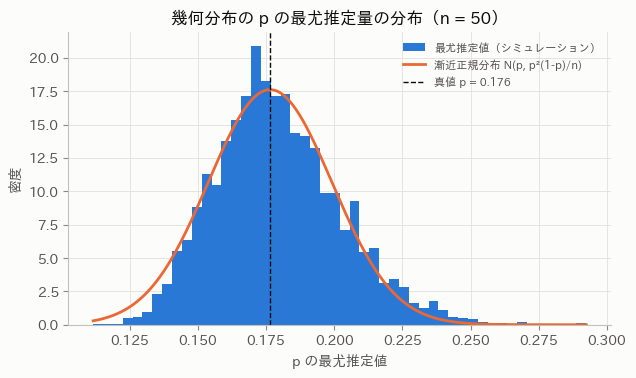

In [65]:
# 最尤推定量の漸近正規性: 幾何分布（失敗回数）Geo(p)、簡略化モデル p = 捕獲率/255 と仮定
# 対数尤度 l(p) = n log p + Σx log(1-p) → p̂ = 1/(1 + x̄)（モーメント法 E[X] = (1-p)/p とも一致）
# フィッシャー情報量（1観測）I₁(p) = 1/(p²(1-p)) → V[p̂] ≈ p²(1-p)/n
rng = get_rng()
p0 = 45 / 255
n_geo, reps_geo = 50, 4000
xg = rng.geometric(p0, size=(reps_geo, n_geo)) - 1
p_hat = 1 / (1 + xg.mean(axis=1))
se_theory = np.sqrt(p0**2 * (1 - p0) / n_geo)
se_plug = np.sqrt(p_hat**2 * (1 - p_hat) / n_geo)      # p̂ を代入した標準誤差
cover = (np.abs(p_hat - p0) <= 1.96 * se_plug).mean()
# フィッシャー情報量の2つの表し方: E[スコア²] と -E[対数尤度の2階微分]
x1 = xg.ravel()                                        # 1観測ごとの値（4000 × 50 個）
score = 1 / p0 - x1 / (1 - p0)
hess = -1 / p0**2 - x1 / (1 - p0) ** 2
print(f"I₁(p): 理論 1/(p²(1-p)) = {1 / (p0**2 * (1 - p0)):.2f}   E[スコア²] ≈ {np.mean(score**2):.2f}"
      f"   -E[2階微分] ≈ {-hess.mean():.2f}   E[スコア] ≈ {score.mean():.3f}")
print(f"p̂ の平均 {p_hat.mean():.4f}（真値 {p0:.4f}）  標準偏差 {p_hat.std():.4f}（漸近理論 {se_theory:.4f}）")
print(f"p̂ ± 1.96 SE(p̂) が真値を含む割合: {cover:.3f}（名目 0.95）")

fig, ax = plt.subplots(figsize=(7, 3.8))
g = np.linspace(p_hat.min(), p_hat.max(), 300)
ax.hist(p_hat, bins=50, density=True, color=PALETTE[0], label="最尤推定値（シミュレーション）")
ax.plot(g, stats.norm.pdf(g, p0, se_theory), color=PALETTE[1], label="漸近正規分布 N(p, p²(1-p)/n)")
ax.axvline(p0, color=INK["primary"], lw=1, ls="--", label=f"真値 p = {p0:.3f}")
ax.set(title=f"幾何分布の p の最尤推定量の分布（n = {n_geo}）", xlabel="p の最尤推定値", ylabel="密度")
ax.legend(fontsize=8)
plt.show()

**結果の読み方**
- $I_1(p)$ は理論値約39.0 に対し、スコアの2乗の平均約39.1、2階微分の平均の符号反転約39.0 で一致し、スコアの平均はほぼ0。
- $\hat p$ の標準偏差は約0.0232 で、漸近理論の約0.0226 に近い。平均は約0.180 で真値0.176 よりわずかに大きく、有限標本では小さな偏りがある（$\hat p=1/(1+\bar x)$ は $\bar x$ の凸関数なので上向き）。
- $\hat p\pm1.96\,\widehat{\mathrm{SE}}$ が真値を含む割合は約0.953 で、名目の0.95 にほぼ一致する（第9章の区間推定の考え方）。

### 8.3 バイアス・バリアンス分解

**問い**：母分散 $\sigma^2$ を偏差平方和 $Q=\sum(X_i-\bar X)^2$ から $Q/c$ で推定するとき、$c=n-1,\,n,\,n+1$ のどれが MSE を小さくするか。

**手法の要点**
- 推定量 $\hat\theta$ の平均二乗誤差は、分散（バリアンス）とバイアスの2乗に分解できる：
  $$\mathrm{MSE}(\hat\theta)=E[(\hat\theta-\theta)^2]=V[\hat\theta]+\left(E[\hat\theta]-\theta\right)^2.$$
- $E[Q]=(n-1)\sigma^2$ なので、$c=n-1$（不偏分散 $S^2$）はバイアス0、$c=n$（最尤推定量）は $-\sigma^2/n$ の偏り。
- $V[S^2]=\sigma^4\left(\dfrac{2}{n-1}+\dfrac{\kappa}{n}\right)$（$\kappa$ は母集団の尖度 $-3$）を使うと $\mathrm{MSE}(Q/c)=\left(\dfrac{n-1}{c}-1\right)^2\sigma^4+\dfrac{(n-1)^2}{c^2}V[S^2]$。正規母集団（$\kappa=0$）では $c=n+1$ で MSE が最小になる。
- $n=10$、20000回の復元抽出で調べる。値は $\sigma^4$ で割って無次元化する。

（→ py 08-3：合計種族値と重さで、3つの推定量のバイアス²・分散・MSE を表にし、分解が成り立つことを確認する）

In [66]:
# バイアス・バリアンス分解: 母分散 σ² を Σ(X - X̄)²/c（c = n-1, n, n+1）で推定する
rng = get_rng()
n_v, reps_v = 10, 20000
rows_bv = []
for name, pop in [("合計種族値", bst08), ("重さ", wt08)]:
    sig2, kap = pop.var(), stats.kurtosis(pop)
    ss = draw08(pop, n_v, reps_v, rng).var(axis=1, ddof=0) * n_v   # 偏差平方和
    var_s2 = sig2**2 * (2 / (n_v - 1) + kap / n_v)                   # V[S²]（S² は不偏分散）
    for c in [n_v - 1, n_v, n_v + 1]:
        est = ss / c
        bias, var = est.mean() - sig2, est.var()
        # 理論: E = (n-1)σ²/c, V = (n-1)² V[S²]/c²
        mse_th = ((n_v - 1) / c - 1) ** 2 * sig2**2 + (n_v - 1) ** 2 * var_s2 / c**2
        rows_bv.append({"母集団": name, "割る数": c, "バイアス²/σ⁴": bias**2 / sig2**2, "分散/σ⁴": var / sig2**2,
                        "MSE/σ⁴": ((est - sig2) ** 2).mean() / sig2**2,
                        "分散+バイアス²（/σ⁴）": (var + bias**2) / sig2**2, "理論 MSE/σ⁴": mse_th / sig2**2})
    # MSE を最小にする割る数 c を理論式から数値的に探す（正規母集団なら c = n+1）
    cs = np.linspace(n_v - 1, 4 * n_v, 2000)
    mse_c = ((n_v - 1) / cs - 1) ** 2 * sig2**2 + (n_v - 1) ** 2 * var_s2 / cs**2
    print(f"{name}: 尖度 κ = {kap:.2f}  MSE を最小にする割る数（理論） c* ≈ {cs[mse_c.argmin()]:.1f}")
print(f"n = {n_v}、各 {reps_v} 回。値は σ⁴ で割って無次元化")
pd.DataFrame(rows_bv).round(4)

合計種族値: 尖度 κ = -0.53  MSE を最小にする割る数（理論） c* ≈ 10.5
重さ: 尖度 κ = 23.55  MSE を最小にする割る数（理論） c* ≈ 32.2
n = 10、各 20000 回。値は σ⁴ で割って無次元化


,母集団,割る数,バイアス²/σ⁴,分散/σ⁴,MSE/σ⁴,分散+バイアス²（/σ⁴）,理論 MSE/σ⁴
0,合計種族値,9,0.0000,0.1679,0.1679,0.1679,0.1690
1,合計種族値,10,0.0104,0.1360,0.1465,0.1465,0.1469
2,合計種族値,11,0.0338,0.1124,0.1462,0.1462,0.1462
3,重さ,9,0.0004,2.6620,2.6623,2.6623,2.5771
4,重さ,10,0.0069,2.1562,2.1631,2.1631,2.0975
5,重さ,11,0.0277,1.7820,1.8097,1.8097,1.7583


**結果の読み方**
- どの行でも「分散＋バイアス²」が MSE に一致する（分解の数値確認）。シミュレーションの MSE は理論式ともほぼ一致する（重さは裾が重くシミュレーションのぶれが数%ある）。
- 合計種族値では、不偏な $c=9$ の MSE（約0.168）より、偏りのある $c=10$（約0.147）・$c=11$（約0.146）のほうが小さい。偏りを少し許すと分散が大きく減り、MSE が下がる。
- 重さ（尖度約24）では $S^2$ の分散が非常に大きく、MSE を最小にする割る数は理論上 $c\approx32$ にもなる。「$n+1$ で割ると最良」は正規母集団での結論であり、尖度に依存する。

### 8.4 不偏推定量

**問い**：$\bar X$・不偏分散 $S^2$・標本標準偏差 $S$ は、それぞれ母平均・母分散・母標準偏差の不偏推定量か。復元抽出と非復元抽出で違いはあるか。

**手法の要点**
- 不偏推定量：$E[\hat\theta]=\theta$ となる推定量。i.i.d. 標本では $E[\bar X]=\mu$、$E[S^2]=\sigma^2$。
- 不偏性は非線形変換で保たれない。$S^2$ が不偏でも、$\sqrt{\cdot}$ は凹関数なので $E[S]<\sigma$（イェンセンの不等式）。正規母集団では $E[S]=c_4\sigma$、$c_4=\sqrt{\dfrac{2}{n-1}}\dfrac{\Gamma(n/2)}{\Gamma((n-1)/2)}$。
- 大きさ $N$ の有限母集団から非復元抽出すると、$\bar X$ は不偏のままだが、$E[S^2]=\dfrac{N}{N-1}\sigma_N^2$（$\sigma_N^2$ は $N$ で割った母分散）となる。すなわち $N-1$ で割った母分散に対して不偏（第21章 標本調査法）。

（→ py 08-4：合計種族値で $n=30$ の標本を各5000回抽出し、期待値と真値の比を求める）

In [67]:
# 不偏推定量: 復元抽出と非復元抽出で、X̄・S²・S の期待値を真値と比べる（合計種族値, n = 30）
rng = get_rng()
n_u, reps_u = 30, 5000
N08 = len(bst08)
mu_t, sig2_N = bst08.mean(), bst08.var(ddof=0)
smp_with = draw08(bst08, n_u, reps_u, rng)
smp_wo = np.array([rng.choice(bst08, n_u, replace=False) for _ in range(reps_u)])
rows_u = []
for name, smp in [("復元抽出（i.i.d.）", smp_with), ("非復元抽出", smp_wo)]:
    s2 = smp.var(axis=1, ddof=1)
    rows_u.append({"抽出": name, "E[X̄]/μ": smp.mean(axis=1).mean() / mu_t,
                   "E[S²]/σ²（N で割る）": s2.mean() / sig2_N,
                   "E[S²]/σ²（N-1 で割る）": s2.mean() / bst08.var(ddof=1),
                   "E[S]/σ": np.sqrt(s2).mean() / np.sqrt(sig2_N)})
print(f"非復元抽出の理論: E[S²] = N/(N-1)·σ²_N（比 {N08 / (N08 - 1):.4f}）")
from scipy.special import gammaln
c4 = np.sqrt(2 / (n_u - 1)) * np.exp(gammaln(n_u / 2) - gammaln((n_u - 1) / 2))
print(f"正規母集団なら E[S]/σ = c₄ = √(2/(n-1))·Γ(n/2)/Γ((n-1)/2) = {c4:.4f}")
pd.DataFrame(rows_u).round(4)

非復元抽出の理論: E[S²] = N/(N-1)·σ²_N（比 1.0011）
正規母集団なら E[S]/σ = c₄ = √(2/(n-1))·Γ(n/2)/Γ((n-1)/2) = 0.9914


,抽出,E[X̄]/μ,E[S²]/σ²（N で割る）,E[S²]/σ²（N-1 で割る）,E[S]/σ
0,復元抽出（i.i.d.）,1.0003,0.9978,0.9968,0.9925
1,非復元抽出,1.0003,0.9974,0.9963,0.9925


**結果の読み方**
- $E[\bar X]/\mu$ はどちらの抽出でも約1.000、$E[S^2]/\sigma^2$ も約0.997〜0.998 で、シミュレーションの精度（5000回で約 ±0.3%）の範囲で1に等しい。非復元抽出の理論上の差 $N/(N-1)\approx1.001$ は小さすぎて、この回数では検出できない（$n/N$ が小さいので実用上も無視できる）。
- $E[S]/\sigma$ は約0.992 で、1より小さい。$S^2$ が不偏でも $S$ は下向きの偏りをもつ。この値は正規母集団の $c_4\approx0.991$ に近い。

### 8.5 ジャックナイフ推定量

**問い**：重さの母平均の対数 $\theta=\log\mu$ を $\hat\theta=\log\bar X$ で推定すると偏りが出る。ジャックナイフで補正できるか。標準誤差も推定できるか。

**手法の要点**
- $i$ 番目の観測を除いた $n-1$ 個から求めた推定量を $\hat\theta_{(i)}$、その平均を $\hat\theta_{(\cdot)}=\frac1n\sum\hat\theta_{(i)}$ とする。
- ジャックナイフ推定量：$\tilde\theta=n\hat\theta-(n-1)\hat\theta_{(\cdot)}$。$E[\hat\theta]=\theta+a/n+O(1/n^2)$ の形の偏りなら、$1/n$ の項が消える。
- ジャックナイフ標準誤差：$\widehat{\mathrm{SE}}=\sqrt{\dfrac{n-1}{n}\sum_{i=1}^n\left(\hat\theta_{(i)}-\hat\theta_{(\cdot)}\right)^2}$。
- 例：$n$ で割る標本分散 $\hat\sigma^2$ のジャックナイフ推定量は、ちょうど不偏分散 $S^2$ に一致する。

（→ py 08-5：(1) 分散での一致を確認し、(2) $n=20$ で3000回抽出して $\log\bar X$ の偏りの補正と標準誤差を調べる）

In [68]:
# ジャックナイフ推定量: 1つずつ除いた推定量 θ̂_(i) から偏りを補正し、標準誤差を求める
def jackknife08(x, stat):
    """(元の推定量, ジャックナイフ推定量, ジャックナイフ標準誤差) を返す. stat は各行に適用される."""
    n = x.shape[-1]
    theta = stat(x)
    loo = np.stack([stat(np.delete(x, i, axis=-1)) for i in range(n)], axis=-1)  # θ̂_(i)
    loo_mean = loo.mean(axis=-1)
    theta_jack = n * theta - (n - 1) * loo_mean
    se_jack = np.sqrt((n - 1) / n * ((loo - loo_mean[..., None]) ** 2).sum(axis=-1))
    return theta, theta_jack, se_jack

rng = get_rng()
# (1) n で割る標本分散のジャックナイフは不偏分散 S² に一致する
x_one = draw08(bst08, 12, 1, rng)[0]
_, jk_var, _ = jackknife08(x_one, lambda z: z.var(axis=-1, ddof=0))
print(f"(1) n で割る分散 {x_one.var():.2f} → ジャックナイフ {jk_var:.2f}   不偏分散 S² = {x_one.var(ddof=1):.2f}")

# (2) θ = log μ（重さの母平均の対数）を θ̂ = log X̄ で推定（log は凹関数なので下向きの偏り）
n_j, reps_j = 20, 3000
xs_j = draw08(wt08, n_j, reps_j, rng)
th, th_jk, se_jk = jackknife08(xs_j, lambda z: np.log(z.mean(axis=-1)))
theta_true = np.log(wt08.mean())
pd.DataFrame({
    "推定量": ["log X̄（そのまま）", "ジャックナイフ補正"],
    "バイアス": [th.mean() - theta_true, th_jk.mean() - theta_true],
    "標準偏差": [th.std(), th_jk.std()],
    "RMSE": [np.sqrt(((th - theta_true) ** 2).mean()), np.sqrt(((th_jk - theta_true) ** 2).mean())],
    "ジャックナイフSEの平均": [se_jk.mean(), np.nan],
}).round(4)

(1) n で割る分散 11986.97 → ジャックナイフ 13076.70   不偏分散 S² = 13076.70


,推定量,バイアス,標準偏差,RMSE,ジャックナイフSEの平均
0,log X̄（そのまま）,-0.0750,0.4012,0.4081,0.3838
1,ジャックナイフ補正,-0.0002,0.4251,0.4251,NaN


**結果の読み方**
- (1) $n=12$ の標本で、$n$ で割る分散のジャックナイフ推定値は不偏分散と完全に一致する。
- (2) $\log\bar X$ のバイアスは約 $-0.075$ で、ジャックナイフで約 $-0.0002$ とほぼ0になる。一方、標準偏差は約0.40 から約0.43 に増え、RMSE（約0.41 → 約0.43）はかえって少し悪化した。偏りの補正は分散の増加と引き換えである（8.3 と同じ構図）。
- ジャックナイフ標準誤差の平均は約0.38 で、実際の標準偏差約0.40 をやや過小評価する。重さのように裾が重いと、$n=20$ では標準誤差の推定も難しい。

### 8.6 クラメール・ラオの不等式

**問い**：標本割合（ベルヌーイ）や標本平均・標本中央値（正規分布）の分散は、不偏推定量の分散の下限にどれだけ近いか。

**手法の要点**
- クラメール・ラオの不等式：正則条件のもとで、$\theta$ の任意の不偏推定量 $\hat\theta$ について
  $$V[\hat\theta]\ge\frac{1}{nI_1(\theta)}.$$
- ベルヌーイ分布：$I_1(p)=\dfrac{1}{p(1-p)}$ より下限は $\dfrac{p(1-p)}{n}$。標本割合の分散はちょうどこれに等しい。
- 正規分布の平均（$\sigma^2$ 既知）：$I_1(\mu)=1/\sigma^2$ より下限は $\sigma^2/n$。$\bar X$ の分散はこれに等しい。標本中央値も（対称性から）不偏だが、分散は漸近的に $\dfrac{\pi\sigma^2}{2n}$ と大きい。
- ベルヌーイは実際の母集団（複合タイプ）から抽出し、正規は合計種族値の $\mu,\sigma$ をもつ正規分布から生成する。

（→ py 08-6：分散と下限の比を $n$ ごとに表示する）

In [69]:
# クラメール・ラオの不等式: 不偏推定量の分散 ≥ 1/(n I₁(θ))
rng = get_rng()
# (a) ベルヌーイ: 複合タイプか（p = 母集団の割合）。I₁(p) = 1/(p(1-p)) → 下限 p(1-p)/n
p_d = dual08.mean()
rows_cr = []
for n in [10, 30, 100]:
    ph = draw08(dual08, n, 20000, rng).mean(axis=1)
    rows_cr.append({"モデル": "ベルヌーイ（複合タイプ）", "推定量": "標本割合", "n": n,
                    "分散（シミュ）": ph.var(), "CR下限": p_d * (1 - p_d) / n})
# (b) 正規分布の平均（σ 既知）: I₁(μ) = 1/σ² → 下限 σ²/n。合計種族値の μ, σ をもつ正規分布から生成
mu_n, sd_n = bst08.mean(), bst08.std()
for n in [11, 51]:
    xn = rng.normal(mu_n, sd_n, size=(10000, n))
    for name, est in [("標本平均", xn.mean(axis=1)), ("標本中央値", np.median(xn, axis=1))]:
        rows_cr.append({"モデル": "正規（μ, σ は合計種族値）", "推定量": name, "n": n,
                        "分散（シミュ）": est.var(), "CR下限": sd_n**2 / n})
tab_cr = pd.DataFrame(rows_cr)
tab_cr["分散/CR下限"] = tab_cr["分散（シミュ）"] / tab_cr["CR下限"]
print(f"p（複合タイプの割合）= {p_d:.4f}")
tab_cr.round(4)

p（複合タイプの割合）= 0.5391


,モデル,推定量,n,分散（シミュ）,CR下限,分散/CR下限
0,ベルヌーイ（複合タイプ）,標本割合,10,0.0247,0.0248,0.9960
1,ベルヌーイ（複合タイプ）,標本割合,30,0.0083,0.0083,1.0010
2,ベルヌーイ（複合タイプ）,標本割合,100,0.0025,0.0025,1.0100
3,"正規（μ, σ は合計種族値）",標本平均,11,1351.8820,1314.9029,1.0281
4,"正規（μ, σ は合計種族値）",標本中央値,11,2035.8731,1314.9029,1.5483
5,"正規（μ, σ は合計種族値）",標本平均,51,285.8072,283.6065,1.0078
6,"正規（μ, σ は合計種族値）",標本中央値,51,449.2382,283.6065,1.5840


**結果の読み方**
- 標本割合の分散と下限の比は $n=10,30,100$ で約1.00 で、下限を達成している。
- 正規分布では、標本平均の比が約1.01〜1.03（シミュレーションのぶれ）、標本中央値は約1.55〜1.58 で、漸近値 $\pi/2\approx1.57$ に近い。中央値は下限に届かない。

### 8.7 有効推定量と相対効率

**問い**：母平均（分布の中心）の推定に、標本平均・中央値・10%刈込平均・中点（最大値と最小値の平均）のどれを使うべきか。答えは母集団によって変わるか。

**手法の要点**
- 有効推定量：クラメール・ラオの下限を達成する不偏推定量。有効推定量は一様最小分散不偏推定量（UMVUE）でもある。正規分布の平均では $\bar X$ が有効推定量。
- 相対効率：2つの推定量の分散の比 $V[\hat\theta_1]/V[\hat\theta_2]$。1未満なら $\hat\theta_2$ のほうが悪い。正規分布での中央値の（平均に対する）漸近相対効率は $2/\pi\approx0.64$。
- 実際の母集団（合計種族値）はやや非対称で多峰なので、中央値や中点の期待値は母平均と一致しない。そこでは分散だけでなく推定量の平均（何を推定しているか）にも注意する。

（→ py 08-7：$n=25$ で各1万回、4つの推定量の平均・分散・相対効率を比べる）

In [70]:
# 有効推定量と相対効率: 正規母集団と実際の母集団（合計種族値）で、平均の推定量どうしを比べる
rng = get_rng()
n_e = 25
rows_eff = []
pops_eff = {"正規分布 N(μ, σ²)": rng.normal(mu_n, sd_n, size=(10000, n_e)),
            "合計種族値（実際の母集団）": draw08(bst08, n_e, 10000, rng)}
for pname, xe in pops_eff.items():
    ests = {"標本平均": xe.mean(axis=1), "標本中央値": np.median(xe, axis=1),
            "10%刈込平均": stats.trim_mean(xe, 0.1, axis=1),
            "中点 (最大+最小)/2": (xe.max(axis=1) + xe.min(axis=1)) / 2}
    v_mean = ests["標本平均"].var()
    for ename, e in ests.items():
        rows_eff.append({"母集団": pname, "推定量": ename, "平均": e.mean(), "分散": e.var(),
                         "相対効率（標本平均の分散/分散）": v_mean / e.var(), "分散/(σ²/n)": e.var() / (sd_n**2 / n_e)})
print(f"n = {n_e}。正規分布での中央値の漸近相対効率は 2/π ≈ {2 / np.pi:.3f}")
pd.DataFrame(rows_eff).round(3)

n = 25。正規分布での中央値の漸近相対効率は 2/π ≈ 0.637


,母集団,推定量,平均,分散,相対効率（標本平均の分散/分散）,分散/(σ²/n)
0,"正規分布 N(μ, σ²)",標本平均,438.485,580.289,1.000,1.003
1,"正規分布 N(μ, σ²)",標本中央値,438.339,886.123,0.655,1.532
2,"正規分布 N(μ, σ²)",10%刈込平均,438.430,602.832,0.963,1.042
3,"正規分布 N(μ, σ²)",中点 (最大+最小)/2,438.840,1972.304,0.294,3.409
4,合計種族値（実際の母集団）,標本平均,437.863,571.420,1.000,0.988
5,合計種族値（実際の母集団）,標本中央値,447.381,1330.063,0.430,2.299
6,合計種族値（実際の母集団）,10%刈込平均,436.337,641.666,0.891,1.109
7,合計種族値（実際の母集団）,中点 (最大+最小)/2,450.823,1173.980,0.487,2.029


**結果の読み方**
- 正規分布では、標本平均の分散が $\sigma^2/n$ にほぼ等しく（比約1.00）最良。中央値の相対効率は約0.66（理論 $2/\pi$）、刈込平均は約0.96、中点は約0.29 と大きく劣る。
- 実際の合計種族値の母集団でも標本平均が最良だが、中央値の相対効率は約0.43 と正規分布の場合より悪い。母集団が多峰で中央付近の密度が低いためである。中点の相対効率は約0.49 と正規分布より良くなるのは、尖度が負（裾が軽い）ためである。
- 中央値の平均は約447、中点の平均は約451 で、母平均438 とずれる。非対称な母集団では、これらは母平均とは別のもの（母中央値など）を推定している。

### 8.8 十分統計量

**問い**：ポケモンを1匹ずつ選んで「複合タイプか否か」を記録した列 $X_1,\dots,X_n$（ベルヌーイ）で、合計 $T=\sum X_i$ を知れば $p$ について十分か。

**手法の要点**
- 統計量 $T(\boldsymbol X)$ が $\theta$ の十分統計量であるとは、$T=t$ を与えたときの $\boldsymbol X$ の条件付き分布が $\theta$ に依存しないこと。$T$ を知った後、残りの情報（並び方など）は $\theta$ の推測に役立たない。
- フィッシャー・ネイマンの分解定理：同時確率（密度）関数が $f(\boldsymbol x;\theta)=g(T(\boldsymbol x);\theta)\,h(\boldsymbol x)$ と分解できることが、$T$ が十分統計量であることと同値。
- ベルヌーイ：$f(\boldsymbol x;p)=p^{t}(1-p)^{n-t}$（$t=\sum x_i$）なので $T$ は十分統計量。条件付き分布は $P(\boldsymbol X=\boldsymbol x\mid T=t)=1/\binom nt$ で、どの並び方も等確率。
- ポアソン：$f(\boldsymbol x;\lambda)=\lambda^{\sum x_i}e^{-n\lambda}/\prod x_i!$ なので $\sum X_i$ が十分統計量。

（→ py 08-8：$n=5$ の列を2つの $p$（複合タイプの割合0.539、みずの割合0.135）で40万本生成し、$T=2$ のときの並び方の分布を比べる）

In [71]:
# 十分統計量: ベルヌーイ列で T = ΣX を与えると、並び方の条件付き分布は p によらない
rng = get_rng()
n_s, k_s = 5, 2
p_water = (df["タイプ1"] == "みず").mean()
rows_suf = {}
for label, p in [(f"p = {p_d:.3f}（複合タイプ）", p_d), (f"p = {p_water:.3f}（みず）", p_water)]:
    seq = rng.random((400000, n_s)) < p
    sel = seq[seq.sum(axis=1) == k_s]                     # T = 2 の列だけを残す
    patterns = ["".join("1" if b else "0" for b in row) for row in sel]
    rows_suf[label] = pd.Series(patterns).value_counts(normalize=True).sort_index()
    print(f"{label}: T = {k_s} となった列 {len(sel)} 本、P(X₁ = 1 | T = {k_s}) = {sel[:, 0].mean():.3f}（理論 k/n = {k_s / n_s}）")
tab_suf = pd.DataFrame(rows_suf)
tab_suf["理論 1/C(5,2)"] = 1 / 10
tab_suf.round(4)

p = 0.539（複合タイプ）: T = 2 となった列 113693 本、P(X₁ = 1 | T = 2) = 0.400（理論 k/n = 0.4）

p = 0.135（みず）: T = 2 となった列 47318 本、P(X₁ = 1 | T = 2) = 0.396（理論 k/n = 0.4）


,p = 0.539（複合タイプ）,p = 0.135（みず）,"理論 1/C(5,2)"
00011,0.1020,0.0998,0.1
00101,0.1005,0.1007,0.1
00110,0.0997,0.1001,0.1
01001,0.1001,0.1019,0.1
01010,0.0981,0.1001,0.1
01100,0.1000,0.1010,0.1
10001,0.1002,0.0997,0.1
10010,0.1002,0.0981,0.1
10100,0.0993,0.0995,0.1
11000,0.1000,0.0990,0.1


**結果の読み方**
- $T=2$ となった列の10通りの並び方は、どちらの $p$ でもほぼ0.10 ずつで、理論値 $1/\binom52=0.1$ に一致する。$P(X_1=1\mid T=2)$ もどちらも約0.40（$=t/n=2/5$）。
- $T$ を与えると並び方の分布は $p$ によらないので、$p$ の推測には $T$（または標本割合 $T/n$）だけを使えばよい。

### 8.9 順序統計量

**問い**：合計種族値の母集団から $n=11$ 匹を選んだとき、標本の最大値と中央値（6番目の値）はどう分布するか。

**手法の要点**
- 標本を小さい順に並べた $X_{(1)}\le X_{(2)}\le\dots\le X_{(n)}$ が順序統計量。
- i.i.d. で母集団の分布関数が $F$ のとき、$X_{(k)}\le x$ は「$x$ 以下の観測が $k$ 個以上」と同じ事象なので
  $$P(X_{(k)}\le x)=\sum_{j=k}^{n}\binom nj F(x)^j\{1-F(x)\}^{n-j}.$$
  最大値は $P(X_{(n)}\le x)=F(x)^n$、最小値は $P(X_{(1)}\le x)=1-\{1-F(x)\}^n$。この式は $F$ が離散型（合計種族値のように同じ値が多い場合）でもそのまま成り立つ。
- 連続型で密度 $f$ があれば、$X_{(k)}$ の密度は $\dfrac{n!}{(k-1)!(n-k)!}F(x)^{k-1}\{1-F(x)\}^{n-k}f(x)$。

（→ py 08-9：1万回の抽出で最大値・中央値の経験分布関数を理論式と比べる）

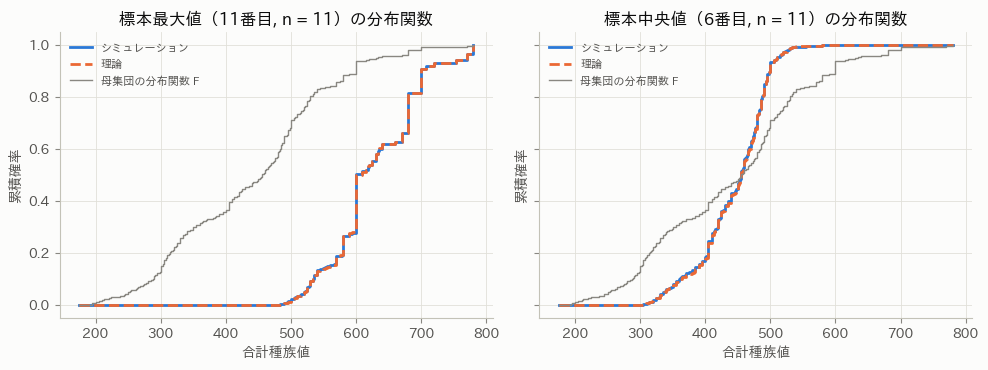

母集団: 最大値 780, 中央値 455


,統計量,平均（シミュ）,平均（理論）,最大差 |F_sim - F_th|
0,最大値,627.607,627.852,0.004
1,中央値,442.788,443.607,0.009


In [72]:
# 順序統計量: n = 11 の標本の最大値と中央値（6番目）の分布
# 母集団の分布関数 F について、P(X_(k) ≤ x) = Σ_{j=k}^{n} C(n,j) F(x)^j (1-F(x))^{n-j}（最大値は F(x)^n）
rng = get_rng()
n_o, reps_o = 11, 10000
smp_o = np.sort(draw08(bst08, n_o, reps_o, rng), axis=1)
xs_o = np.unique(bst08)
F_pop = np.searchsorted(np.sort(bst08), xs_o, side="right") / len(bst08)   # 母集団の分布関数 F(x)


def order_cdf(F, k, n):
    """k 番目の順序統計量の分布関数（F は母集団の分布関数の値）."""
    return stats.binom.sf(k - 1, n, F)                    # P(Bin(n, F) ≥ k)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
rows_os = []
for ax, (name, k) in zip(axes, [("最大値", n_o), ("中央値", (n_o + 1) // 2)]):
    v = smp_o[:, k - 1]
    ecdf = np.searchsorted(np.sort(v), xs_o, side="right") / reps_o
    th = order_cdf(F_pop, k, n_o)
    ax.step(xs_o, ecdf, where="post", color=PALETTE[0], label="シミュレーション")
    ax.step(xs_o, th, where="post", color=PALETTE[1], ls="--", label="理論")
    ax.step(xs_o, F_pop, where="post", color=INK["muted"], lw=1, label="母集団の分布関数 F")
    ax.set(title=f"標本{name}（{k}番目, n = {n_o}）の分布関数", xlabel="合計種族値", ylabel="累積確率")
    ax.legend(fontsize=8)
    pmf_th = np.diff(np.r_[0, th])
    rows_os.append({"統計量": name, "平均（シミュ）": v.mean(), "平均（理論）": (xs_o * pmf_th).sum(),
                    "最大差 |F_sim - F_th|": np.abs(ecdf - th).max()})
fig.tight_layout()
plt.show()
print(f"母集団: 最大値 {bst08.max():.0f}, 中央値 {np.median(bst08):.0f}")
pd.DataFrame(rows_os).round(3)

**結果の読み方**
- シミュレーションと理論の分布関数の最大差は、最大値で約0.004、中央値で約0.009 と一致する。
- 標本最大値の平均は約628 で、母集団の最大値780 よりかなり小さい（標本最大値は母集団最大値の偏った推定量）。600・680 付近で分布関数が大きく跳ぶのは、その値のポケモンが多いためである。
- 標本中央値の平均は約443 で、母集団の中央値455 より小さい。母集団が多峰で中央値付近の密度が低いため、標本中央値は大きくばらつき、平均も母中央値からずれる。

### まとめ

- ガンマ分布の推定では最尤法がモーメント法より MSE が小さく、幾何分布の最尤推定量はフィッシャー情報量から求めた標準誤差どおりに分布した（$n=50$ で被覆率約0.95）。
- 母分散の推定では、不偏分散（$n-1$ 割り）はバイアス0だが MSE 最小ではなかった。MSE を最小にする割る数は母集団の尖度に依存し、重さでは約32（$n=10$）にもなった。ジャックナイフは偏りをほぼ0にしたが、分散が増えて RMSE は改善しなかった。
- 標本割合と（正規分布での）標本平均はクラメール・ラオの下限を達成する有効推定量で、中央値の相対効率は正規分布で約0.64、実際の合計種族値の母集団では約0.43 だった。
- 限界：推定量の性質は、母集団（モデル）と標本の大きさに強く依存する。実データの920行は同じ進化系統の行を含み、独立な標本ではないため、ここでの結論は「仮想的な i.i.d. 抽出」を前提にしている。

## 第9章 区間推定

### 章の概要

点推定（第8章）で得た値が母数の真の値からどれくらい離れているかを、「母数を含む確率が $1-\alpha$ になるように作った区間」で表すのが区間推定である。
中心になる考え方は、推定量と母数を組み合わせて **分布が母数に依存しない量（ピボット量）** を作り、その分位点から区間を逆算することである。
正規母集団の平均・分散・分散比ではそれぞれ $t$ 分布・$\chi^2$ 分布・$F$ 分布が、比率では二項分布とその正規近似が使われる。
第10〜12章の検定とは表裏の関係にあり、「両側検定で棄却されない $\theta_0$ の集合」が信頼区間になる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 9.1 | 母平均の信頼区間（$t$） | タイプ1ごとの合計種族値の母平均はどの範囲にあるか |
| 9.2 | 母分散の信頼区間（$\chi^2$） | みずタイプの合計種族値のばらつきはどの範囲にあるか |
| 9.3 | 母比率の信頼区間 | いわタイプを含む割合は？ Wald・Wilson・Clopper–Pearson で違うか |
| 9.4 | 母平均の差・母比率の差 | ほのおとみずの平均の差、第1世代と第7世代の複合タイプ割合の差 |
| 9.5 | 分散の比の信頼区間（$F$） | ほのおとみずの合計種族値の分散は同じくらいか |
| 9.6 | 多項分布の比率の差 | 努力値合計が「2」の割合と「1」の割合の差 |
| 9.7 | 被覆率のシミュレーション | 「95%信頼区間」は本当に95%の確率で真値を含むか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（連続とみなす） | 平均・分散の区間推定の対象。ほぼ左右対称（歪度0.10）で、裾は正規分布より軽い（尖度 −0.53） |
| `タイプ1` | 質的（18水準） | 群を分ける変数。各ポケモンがちょうど1群に入るようタイプ1だけで分ける |
| `タイプ1`・`タイプ2` | 質的 | `types_of()` で「いわを含むか」の二値変数を作る（比率の区間推定） |
| `複合タイプ` | 二値 | 世代間の比率の差 |
| `世代` | 質的（1〜7） | 第1世代と第7世代を比べる |
| `努力値合計` | 質的（1, 2, 3） | 3カテゴリの多項分布とみなす |

- **対象の行**：全920行。9.1・9.2・9.4・9.5 では `タイプ1` で群を作る（`types_of()` を使うと複合タイプのポケモンが2群に同時に入り、2群が独立でなくなるため）。
- **加工**：なし。
- **データの性質と注意点**：このデータはUSUM時点の全ポケモンであり、9.1〜9.6 では「背後にある仮想的な母集団からの無作為標本」とみなして区間を計算する。同じ進化系統のポケモンは種族値が似ているので、実際には独立な標本ではなく、区間は見かけより狭くなっている可能性がある。9.7 では逆に全920行を **真の値がわかっている母集団** として扱い、そこから標本を抽出する。

In [73]:
# 使う列とタイプ別の件数（タイプ1で分類。各ポケモンはちょうど1群に入る）
print("合計種族値の要約（全920行）")
print(df["合計種族値"].describe().round(1).to_string())
print(f"歪度 {df['合計種族値'].skew():.2f}  尖度(-3) {df['合計種族値'].kurt():.2f}")
print("\nタイプ1別の件数")
print(df["タイプ1"].value_counts().to_string())
print("\nいわタイプを含む（タイプ1かタイプ2）:", types_of(df, "いわ").sum(), "匹")
print("努力値合計の度数:", df["努力値合計"].value_counts().sort_index().to_dict())

合計種族値の要約（全920行）
count    920.0
mean     438.5
std      120.3
min      175.0
25%      330.0
50%      455.0
75%      518.0
max      780.0
歪度 0.10  尖度(-3) -0.53

タイプ1別の件数
タイプ1
みず       124
ノーマル     110
くさ        83
むし        78
エスパー      67
ほのお       59
いわ        55
でんき       50
ゴースト      37
ドラゴン      37
あく        36
じめん       36
どく        36
かくとう      31
はがね       30
こおり       28
フェアリー     19
ひこう        4

いわタイプを含む（タイプ1かタイプ2）: 69 匹
努力値合計の度数: {1: 305, 2: 390, 3: 225}


### 9.1 母平均の信頼区間（$t$ 分布）

**問い**：タイプ1ごとに、合計種族値の母平均はどの範囲にあると言えるか。

**手法の要点**
- $X_1,\dots,X_n \overset{\text{iid}}{\sim} N(\mu,\sigma^2)$ で $\sigma^2$ が未知のとき、標本平均 $\bar X$ と不偏分散 $s^2=\frac{1}{n-1}\sum (X_i-\bar X)^2$ から
  $$T=\frac{\bar X-\mu}{s/\sqrt n}\sim t(n-1)$$
  となる（ピボット量）。$t_{\alpha/2}(n-1)$ を上側 $\alpha/2$ 点として $P(|T|\le t_{\alpha/2}(n-1))=1-\alpha$ を $\mu$ について解くと
  $$\bar X - t_{\alpha/2}(n-1)\frac{s}{\sqrt n}\ \le\ \mu\ \le\ \bar X + t_{\alpha/2}(n-1)\frac{s}{\sqrt n}.$$
- 前提は独立性と正規性。$n$ が大きければ中心極限定理により正規性の破れの影響は小さい。合計種族値はほぼ左右対称なので、この区間は妥当と考えられる。

（→ py 09-1：18タイプの95%信頼区間。みずタイプで手計算と `scipy.stats.t.interval` を照合）

みず: 手計算 (411.94, 452.97)  scipy (411.94, 452.97)


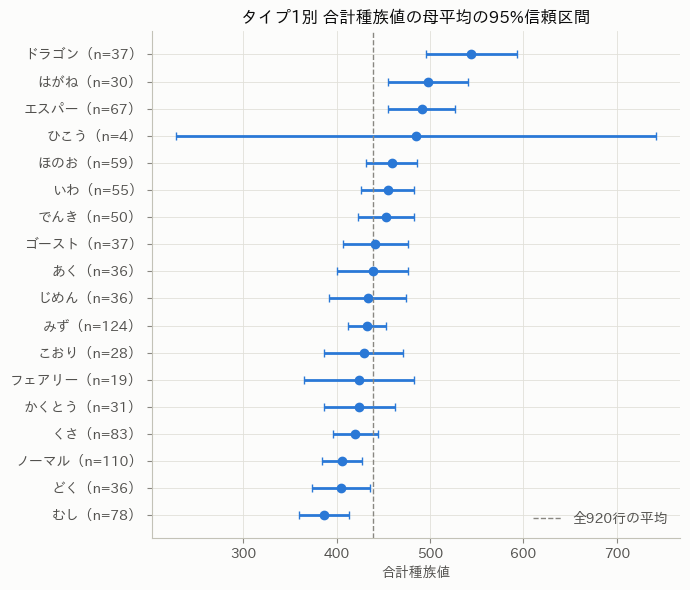

,タイプ1,n,平均,下限,上限
0,むし,78,386.3,359.3,413.3
1,どく,36,404.8,373.6,435.9
2,ノーマル,110,405.7,384.1,427.4
3,くさ,83,420.0,396.1,443.9
4,かくとう,31,424.2,386.3,462.1
5,フェアリー,19,424.2,365.5,482.9
6,こおり,28,428.8,386.8,470.8
7,みず,124,432.5,411.9,453.0
8,じめん,36,433.2,392.3,474.1
9,あく,36,438.4,400.8,476.1


In [74]:
# 母平均の信頼区間（t分布）: タイプ1別の合計種族値
def t_interval(x, level=0.95):
    """定義式 xbar ± t_{α/2}(n-1) s/√n による母平均の信頼区間."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    xbar, s = x.mean(), x.std(ddof=1)
    tq = stats.t.ppf(1 - (1 - level) / 2, n - 1)   # 上側 α/2 点
    return xbar - tq * s / np.sqrt(n), xbar + tq * s / np.sqrt(n)


rows_ci = []
for t, g in df.groupby("タイプ1", observed=True)["合計種族値"]:
    lo, hi = t_interval(g)
    rows_ci.append({"タイプ1": t, "n": len(g), "平均": g.mean(), "下限": lo, "上限": hi})
ci_mean = pd.DataFrame(rows_ci).sort_values("平均").reset_index(drop=True)

# 手計算と scipy の照合（みず）
water_total = df.loc[df["タイプ1"] == "みず", "合計種族値"]
own = t_interval(water_total)
lib = stats.t.interval(0.95, len(water_total) - 1, loc=water_total.mean(), scale=stats.sem(water_total))
print(f"みず: 手計算 ({own[0]:.2f}, {own[1]:.2f})  scipy ({lib[0]:.2f}, {lib[1]:.2f})")

fig, ax = plt.subplots(figsize=(7, 6))
ypos = np.arange(len(ci_mean))
ax.errorbar(ci_mean["平均"], ypos,
            xerr=[ci_mean["平均"] - ci_mean["下限"], ci_mean["上限"] - ci_mean["平均"]],
            fmt="o", color=PALETTE[0], ecolor=PALETTE[0], capsize=3)
ax.axvline(df["合計種族値"].mean(), color=INK["muted"], linestyle="--", linewidth=1, label="全920行の平均")
ax.set_yticks(ypos, [f"{t}（n={n}）" for t, n in zip(ci_mean["タイプ1"], ci_mean["n"])])
ax.set(title="タイプ1別 合計種族値の母平均の95%信頼区間", xlabel="合計種族値")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
ci_mean.round(1)

**結果の読み方**
- 手計算と scipy の区間は一致する（みず：約 412〜453）。
- 区間の幅は $s/\sqrt n$ に比例するので、件数の少ないタイプほど広い。特にひこう（タイプ1が4匹）の区間は非常に広く、ほとんど情報がない。
- ドラゴン（平均 約544）・はがね・エスパーの区間は全体平均（約438）より上側にあり、むし（約386）・ノーマル・どくの区間は全体平均より下側にある。ただし18タイプの区間を同時に眺めて「全体平均を含まないもの」を探すのは多重比較であり、個々の区間の95%はそのまま「18個同時に正しい確率」にはならない。

### 9.2 母分散の信頼区間（$\chi^2$ 分布）

**問い**：みずタイプ（タイプ1）の合計種族値の母分散（母標準偏差）はどの範囲にあるか。

**手法の要点**
- 正規母集団では
  $$\frac{(n-1)s^2}{\sigma^2}\sim\chi^2(n-1)$$
  となる。$\chi^2_{\alpha}(k)$ を自由度 $k$ の $\chi^2$ 分布の上側 $\alpha$ 点とすると、信頼係数 $1-\alpha$ の区間は
  $$\frac{(n-1)s^2}{\chi^2_{\alpha/2}(n-1)}\ \le\ \sigma^2\ \le\ \frac{(n-1)s^2}{\chi^2_{1-\alpha/2}(n-1)}.$$
  $\chi^2$ 分布は左右非対称なので、区間は $s^2$ を中心に対称にならない。
- 平均の区間と違い、**正規性の仮定に敏感** である（$n$ が大きくても補正されない）。母集団の尖度が0でないと $(n-1)s^2/\sigma^2$ の分散が $2(n-1)$ からずれるためである（9.7で確認する）。

（→ py 09-2：分位点と区間を表示）

In [75]:
# 母分散の信頼区間（χ²分布）: みずタイプ（タイプ1）の合計種族値
n_w = len(water_total)
s2_w = water_total.var(ddof=1)
chi_hi = stats.chi2.ppf(0.975, n_w - 1)   # 上側2.5%点
chi_lo = stats.chi2.ppf(0.025, n_w - 1)   # 上側97.5%点
var_ci = ((n_w - 1) * s2_w / chi_hi, (n_w - 1) * s2_w / chi_lo)
print(f"n = {n_w}, 不偏分散 = {s2_w:.1f}（標準偏差 {np.sqrt(s2_w):.1f}）")
print(f"χ²(0.025) = {chi_hi:.2f}, χ²(0.975) = {chi_lo:.2f}（自由度 {n_w - 1}）")
print(f"σ² の95%信頼区間: ({var_ci[0]:.1f}, {var_ci[1]:.1f})")
print(f"σ  の95%信頼区間: ({np.sqrt(var_ci[0]):.1f}, {np.sqrt(var_ci[1]):.1f})")

n = 124, 不偏分散 = 13318.0（標準偏差 115.4）
χ²(0.025) = 155.59, χ²(0.975) = 94.19（自由度 123）
σ² の95%信頼区間: (10528.4, 17390.6)
σ  の95%信頼区間: (102.6, 131.9)


**結果の読み方**
- $n=124$、不偏分散 約13300（標準偏差 約115）に対し、$\sigma$ の95%信頼区間は約 103〜132 となった。区間は点推定値に対して上側に長い。
- 合計種族値は尖度が負（裾が軽い）ので、この区間は名目の95%より高い確率で真値を含む（保守的になる）と考えられる。9.7 のシミュレーションで実際に確認する。

### 9.3 母比率の信頼区間

**問い**：タイプにいわを含むポケモンの割合はどれくらいか。標本が小さいとき、区間の作り方で結果は変わるか。

**手法の要点**
- $X\sim \mathrm{Bin}(n,p)$、$\hat p=X/n$、$z_{\alpha/2}$ を標準正規分布の上側 $\alpha/2$ 点とする。
- **Wald 区間**：$\hat p$ の分散を $\hat p(1-\hat p)/n$ で推定し、$\hat p \pm z_{\alpha/2}\sqrt{\hat p(1-\hat p)/n}$。簡単だが、$np$ が小さいと真値を含む確率が名目より低くなる。
- **Wilson 区間**：分散に推定値を代入せず、$|\hat p-p|\le z_{\alpha/2}\sqrt{p(1-p)/n}$ を $p$ の2次不等式として解いたもの。
  $$\frac{\hat p + \frac{z^2}{2n}}{1+\frac{z^2}{n}} \pm \frac{z}{1+\frac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}\qquad (z=z_{\alpha/2})$$
- **Clopper–Pearson 区間**：正規近似を使わず、$P(X\ge x\mid p_L)=\alpha/2$、$P(X\le x\mid p_U)=\alpha/2$ となる $p_L,p_U$ を端点とする（二項分布の裾確率はベータ分布の分布関数で書けるので、$p_L=B_{\alpha/2}(x,\,n-x+1)$、$p_U=B_{1-\alpha/2}(x+1,\,n-x)$ と表せる。$B_q(a,b)$ はベータ分布の下側 $q$ 点）。離散分布のため、真値を含む確率は常に $1-\alpha$ 以上で、保守的である。

（→ py 09-3：全920行と、無作為に抽出した30匹で3種類の区間を比べる）

In [76]:
# 母比率の信頼区間: いわタイプを含む割合（Wald / Wilson / Clopper-Pearson）
def prop_intervals(x, n, level=0.95):
    """3種類の母比率の信頼区間を定義式から計算する."""
    z = stats.norm.ppf(1 - (1 - level) / 2)
    p = x / n
    # Wald: p̂ ± z √(p̂(1-p̂)/n)
    half = z * np.sqrt(p * (1 - p) / n)
    wald = (p - half, p + half)
    # Wilson: |p̂ - p| ≤ z √(p(1-p)/n) を p について解いた区間
    center = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half_w = z / (1 + z**2 / n) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    wilson = (center - half_w, center + half_w)
    # Clopper-Pearson: 二項分布の裾確率をベータ分布の分位点で表したもの
    a = 1 - level
    cp_lo = stats.beta.ppf(a / 2, x, n - x + 1) if x > 0 else 0.0
    cp_hi = stats.beta.ppf(1 - a / 2, x + 1, n - x) if x < n else 1.0
    return {"Wald": wald, "Wilson": wilson, "Clopper-Pearson": (cp_lo, cp_hi)}


rock = types_of(df, "いわ")
x_rock, n_all = int(rock.sum()), len(df)
print(f"全920行: いわを含む {x_rock} 匹, 標本比率 {x_rock / n_all:.4f}")
res_all = pd.DataFrame(prop_intervals(x_rock, n_all), index=["下限", "上限"]).T
res_all["幅"] = res_all["上限"] - res_all["下限"]

# 小標本（無作為に30匹を抽出）での比較
rng = get_rng()
idx30 = rng.choice(len(df), size=30, replace=False)
x30 = int(rock.iloc[idx30].sum())
print(f"無作為抽出30匹: いわを含む {x30} 匹")
res_30 = pd.DataFrame(prop_intervals(x30, 30), index=["下限", "上限"]).T
res_30["幅"] = res_30["上限"] - res_30["下限"]

# scipy（binomtest）の Wilson / Clopper-Pearson と照合
bt = stats.binomtest(x30, 30)
print("scipy Wilson:", np.round(bt.proportion_ci(method="wilson"), 4),
      " Clopper-Pearson:", np.round(bt.proportion_ci(method="exact"), 4))
pd.concat({"全920行": res_all, "30匹の標本": res_30}).round(4)

全920行: いわを含む 69 匹, 標本比率 0.0750
無作為抽出30匹: いわを含む 2 匹
scipy Wilson: [0.0185 0.2132]  Clopper-Pearson: [0.0082 0.2207]


下限      上限       幅
全920行  Wald             0.0580  0.0920  0.0340
       Wilson           0.0597  0.0938  0.0342
       Clopper-Pearson  0.0588  0.0940  0.0351
30匹の標本 Wald            -0.0226  0.1559  0.1785
       Wilson           0.0185  0.2132  0.1948
       Clopper-Pearson  0.0082  0.2207  0.2126

**結果の読み方**
- 全920行では $\hat p = 69/920 \approx 0.075$ で、3種類の区間はほぼ同じ（約 0.06〜0.09）。$n$ が大きく $n\hat p$ も十分大きいときは、どれを使っても差はない。
- 30匹の標本ではいわを含むのが2匹だけで、区間は大きく異なる。Wald 区間は下限が負になり（比率として意味がない）、Wilson・Clopper–Pearson は $[0,1]$ に収まる。手計算の Wilson・Clopper–Pearson 区間は `binomtest(...).proportion_ci` と一致する。
- $p$ が0や1に近く $n$ が小さいときは、Wald 区間を避けるべきである。

### 9.4 母平均の差・母比率の差の信頼区間

**問い**：ほのおとみず（タイプ1）の合計種族値の母平均の差、第1世代と第7世代の複合タイプの割合の差はどの範囲にあるか。

**手法の要点**
- 独立な2標本 $X_{1},\dots,X_{n_1}\sim N(\mu_1,\sigma_1^2)$、$Y_1,\dots,Y_{n_2}\sim N(\mu_2,\sigma_2^2)$ で、$\bar X,\bar Y$、不偏分散 $s_1^2,s_2^2$ とする。
- **等分散（$\sigma_1^2=\sigma_2^2$）を仮定する場合**：プールした分散 $s_p^2=\frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}$ を使うと
  $$\frac{(\bar X-\bar Y)-(\mu_1-\mu_2)}{s_p\sqrt{1/n_1+1/n_2}}\sim t(n_1+n_2-2).$$
- **等分散を仮定しない場合（Welch）**：$\frac{(\bar X-\bar Y)-(\mu_1-\mu_2)}{\sqrt{s_1^2/n_1+s_2^2/n_2}}$ を、自由度
  $$\nu=\frac{\left(s_1^2/n_1+s_2^2/n_2\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1}+\frac{(s_2^2/n_2)^2}{n_2-1}}$$
  の $t$ 分布で近似する（サタスウェイトの近似）。
- **母比率の差**：独立な2標本の標本比率 $\hat p_1,\hat p_2$ について、$n_1,n_2$ が大きければ
  $$(\hat p_1-\hat p_2)\pm z_{\alpha/2}\sqrt{\frac{\hat p_1(1-\hat p_1)}{n_1}+\frac{\hat p_2(1-\hat p_2)}{n_2}}.$$

（→ py 09-4：2通りの平均差の区間と、比率の差の区間）

In [77]:
# 母平均の差・母比率の差の信頼区間
fire_total = df.loc[df["タイプ1"] == "ほのお", "合計種族値"]
n1, n2 = len(fire_total), len(water_total)
m1, m2 = fire_total.mean(), water_total.mean()
v1, v2 = fire_total.var(ddof=1), water_total.var(ddof=1)

# (a) 等分散を仮定: プールした分散と自由度 n1+n2-2
sp2 = ((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2)
se_pool = np.sqrt(sp2 * (1 / n1 + 1 / n2))
t_pool = stats.t.ppf(0.975, n1 + n2 - 2)
# (b) Welch: 自由度をサタスウェイトの近似で求める
se_w = np.sqrt(v1 / n1 + v2 / n2)
df_w = se_w**4 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
t_w = stats.t.ppf(0.975, df_w)
diff = m1 - m2
print(f"ほのお n={n1} 平均 {m1:.1f} / みず n={n2} 平均 {m2:.1f} / 差 {diff:.1f}")
print(f"等分散: 自由度 {n1 + n2 - 2}, 95%CI ({diff - t_pool * se_pool:.1f}, {diff + t_pool * se_pool:.1f})")
print(f"Welch : 自由度 {df_w:.1f}, 95%CI ({diff - t_w * se_w:.1f}, {diff + t_w * se_w:.1f})")

# 母比率の差: 複合タイプの割合（第1世代 と 第7世代）
g1 = df.loc[df["世代"] == 1, "複合タイプ"]
g7 = df.loc[df["世代"] == 7, "複合タイプ"]
p1_, p7_ = g1.mean(), g7.mean()
se_p = np.sqrt(p1_ * (1 - p1_) / len(g1) + p7_ * (1 - p7_) / len(g7))
z975 = stats.norm.ppf(0.975)
print(f"\n複合タイプの割合: 第1世代 {p1_:.3f}（n={len(g1)}）, 第7世代 {p7_:.3f}（n={len(g7)}）")
print(f"差（第7−第1） {p7_ - p1_:.3f}, 95%CI ({p7_ - p1_ - z975 * se_p:.3f}, {p7_ - p1_ + z975 * se_p:.3f})")

ほのお n=59 平均 458.7 / みず n=124 平均 432.5 / 差 26.3
等分散: 自由度 181, 95%CI (-8.8, 61.4)
Welch : 自由度 123.2, 95%CI (-7.9, 60.5)

複合タイプの割合: 第1世代 0.505（n=184）, 第7世代 0.660（n=97）
差（第7−第1） 0.154, 95%CI (0.036, 0.273)


**結果の読み方**
- ほのお（約459）とみず（約433）の平均の差は約26だが、95%信頼区間は等分散・Welch とも約 −8〜61 で0を含む。この標本からは差があるとは言い切れない。2つの分散が近い（9.5）ので、2つの方法の結果もほぼ同じである。
- 複合タイプの割合は第1世代 約0.51、第7世代 約0.66 で、差の95%信頼区間は約 0.04〜0.27 と0を含まない。第7世代は第1世代より複合タイプの割合が高いと言える（2世代だけの比較なので「新しい世代ほど多い」とまでは言えない。第12章で世代全体を検定する）。

### 9.5 分散の比の信頼区間（$F$ 分布）

**問い**：ほのおとみず（タイプ1）の合計種族値の母分散の比 $\sigma_1^2/\sigma_2^2$ はどの範囲にあるか。

**手法の要点**
- 独立な2つの正規母集団からの標本では
  $$F=\frac{s_1^2/\sigma_1^2}{s_2^2/\sigma_2^2}\sim F(n_1-1,\,n_2-1).$$
  $F_\alpha(a,b)$ を自由度 $(a,b)$ の $F$ 分布の上側 $\alpha$ 点とすると、信頼係数 $1-\alpha$ の区間は
  $$\frac{s_1^2/s_2^2}{F_{\alpha/2}(n_1-1,\,n_2-1)}\ \le\ \frac{\sigma_1^2}{\sigma_2^2}\ \le\ \frac{s_1^2/s_2^2}{F_{1-\alpha/2}(n_1-1,\,n_2-1)}.$$
- $F_{1-\alpha}(a,b)=1/F_{\alpha}(b,a)$ なので、$\frac{s_1^2}{s_2^2}F_{1-\alpha/2}(n_2-1,n_1-1)\le \frac{\sigma_1^2}{\sigma_2^2}\le \frac{s_1^2}{s_2^2}F_{\alpha/2}(n_2-1,n_1-1)$ と書いても同じ区間になる。
- 9.2 と同じく、正規性の仮定に敏感である。

（→ py 09-5：2通りの書き方で同じ区間になることを確認）

In [78]:
# 分散の比の信頼区間（F分布）: σ²_ほのお / σ²_みず
ratio = v1 / v2
f_up = stats.f.ppf(0.975, n1 - 1, n2 - 1)    # F(n1-1, n2-1) の上側2.5%点
f_low = stats.f.ppf(0.025, n1 - 1, n2 - 1)   # F(n1-1, n2-1) の上側97.5%点
ci_ratio = (ratio / f_up, ratio / f_low)
# 別の書き方: 比 × F(n2-1, n1-1) の分位点（F(a,b) の上側 α 点 = 1 / F(b,a) の上側 1-α 点）
ci_ratio2 = (ratio * stats.f.ppf(0.025, n2 - 1, n1 - 1), ratio * stats.f.ppf(0.975, n2 - 1, n1 - 1))
print(f"不偏分散 ほのお {v1:.1f}, みず {v2:.1f}, 比 {ratio:.3f}")
print(f"95%CI: ({ci_ratio[0]:.3f}, {ci_ratio[1]:.3f})  別表現: ({ci_ratio2[0]:.3f}, {ci_ratio2[1]:.3f})")

不偏分散 ほのお 11262.4, みず 13318.0, 比 0.846
95%CI: (0.552, 1.344)  別表現: (0.552, 1.344)


**結果の読み方**
- 分散の比の点推定値は約0.85、95%信頼区間は約 0.55〜1.34 で1を含む。ほのおとみずで合計種族値のばらつきが違うとは言えない。
- 2通りの書き方の区間は一致する。

### 9.6 多項分布の比率の差の信頼区間

**問い**：倒したときにもらえる努力値の合計が「2」のポケモンの割合は、「1」の割合よりどれだけ大きいか。

**手法の要点**
- $(X_1,\dots,X_k)\sim M(n;\,p_1,\dots,p_k)$ のとき、$\hat p_j=X_j/n$ について
  $$V(\hat p_j)=\frac{p_j(1-p_j)}{n},\qquad \mathrm{Cov}(\hat p_i,\hat p_j)=-\frac{p_ip_j}{n}\ (i\neq j).$$
  同じ $n$ 個をカテゴリに振り分けるので、一方が多ければ他方は少なくなり、共分散は負になる。
- したがって
  $$V(\hat p_2-\hat p_1)=\frac{p_1(1-p_1)+p_2(1-p_2)+2p_1p_2}{n},$$
  $n$ が大きいとき、推定値を代入して
  $$(\hat p_2-\hat p_1)\pm z_{\alpha/2}\sqrt{\frac{\hat p_1(1-\hat p_1)+\hat p_2(1-\hat p_2)+2\hat p_1\hat p_2}{n}}$$
  が近似的な信頼区間になる。
- 9.4 の「独立な2標本の比率の差」と違い、$+2p_1p_2$ の項がある。これを落とすと分散を過小評価し、区間が狭くなりすぎる。

（→ py 09-6：共分散を考慮した式と無視した式の比較、シミュレーションで標準誤差を確認）

In [79]:
# 多項分布の比率の差: 努力値合計が2の割合 − 1の割合（同じ920匹の中の2カテゴリ）
counts_ev = df["努力値合計"].value_counts().sort_index()
n_ev = counts_ev.sum()
q1, q2 = counts_ev[1] / n_ev, counts_ev[2] / n_ev
d_ev = q2 - q1
# 同一多項分布では Cov(p̂1, p̂2) = -p1 p2 / n なので V(p̂2 - p̂1) = {p1(1-p1) + p2(1-p2) + 2 p1 p2} / n
se_multi = np.sqrt((q1 * (1 - q1) + q2 * (1 - q2) + 2 * q1 * q2) / n_ev)
se_wrong = np.sqrt((q1 * (1 - q1) + q2 * (1 - q2)) / n_ev)   # 共分散を無視した（誤った）式
print(f"n = {n_ev}, p̂1 = {q1:.3f}, p̂2 = {q2:.3f}, 差 = {d_ev:.3f}")
print(f"共分散を考慮: SE {se_multi:.4f}, 95%CI ({d_ev - z975 * se_multi:.3f}, {d_ev + z975 * se_multi:.3f})")
print(f"共分散を無視: SE {se_wrong:.4f}, 95%CI ({d_ev - z975 * se_wrong:.3f}, {d_ev + z975 * se_wrong:.3f})")

# シミュレーションで V(p̂2 - p̂1) を確認（全920行を母集団とみなし n=920 の復元抽出）
rng = get_rng()
sim_ev = rng.multinomial(n_ev, (counts_ev / n_ev).values, size=5000)
sim_d = sim_ev[:, 1] / n_ev - sim_ev[:, 0] / n_ev
print(f"シミュレーションの SD {sim_d.std():.4f}")

n = 920, p̂1 = 0.332, p̂2 = 0.424, 差 = 0.092
共分散を考慮: SE 0.0285, 95%CI (0.037, 0.148)
共分散を無視: SE 0.0225, 95%CI (0.048, 0.136)


シミュレーションの SD 0.0287


**結果の読み方**
- $\hat p_1\approx 0.33$、$\hat p_2\approx 0.42$、差は約0.09。共分散を考慮した95%信頼区間は約 0.04〜0.15 で、0を含まない。
- 共分散を無視した式の標準誤差（約0.023）は、共分散を考慮した式（約0.029）より小さい。全920行を母集団とした多項分布からのシミュレーションで得た差の標準偏差（約0.029）は、共分散を考慮した式と一致した。

### 9.7 信頼区間の意味（被覆率のシミュレーション）

**問い**：「95%信頼区間」は、本当に95%の確率で真の値を含むのか。

**手法の要点**
- 信頼係数 $1-\alpha$ の意味は、「標本を取り直して区間を作ることを繰り返すと、その $1-\alpha$ の割合で区間が真の母数を含む」ということである。母数は定数で、ランダムなのは区間の方である。一度得た区間について「母数がこの中にある確率が95%」と言うのは正確ではない。
- ここでは全920行を母集団とみなし、真の母平均 $\mu$・母分散 $\sigma^2$（$n$ で割った分散）・いわを含む母比率 $p$ を既知とする。そこから **復元抽出** で標本を作る（復元抽出なので、各標本は経験分布からの独立同一分布の標本になる）。
  - 合計種族値を $n=20$ 抽出して、$t$ 区間（9.1）と $\chi^2$ 区間（9.2）を作る。
  - いわを含むかを $n=30$ 抽出して（$X\sim\mathrm{Bin}(30,p)$）、3種類の比率の区間（9.3）を作る。
  - それぞれ5000回繰り返し、真の値を含んだ割合（被覆率）を数える。

（→ py 09-7：被覆率の表示と、最初の100回の $t$ 区間の図）

母平均 438.5, 母分散 14464, いわの母比率 0.0750（5000回）
母平均の t 区間（n=20）の被覆率: 0.946
母分散の χ² 区間（n=20）の被覆率: 0.974
母比率 Wald 区間（n=30）の被覆率: 0.904
母比率 Wilson 区間（n=30）の被覆率: 0.981
母比率 Clopper-Pearson 区間（n=30）の被覆率: 0.981


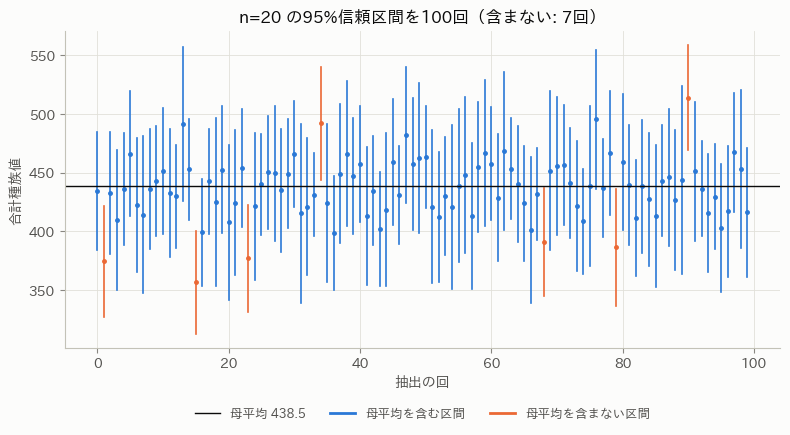

In [80]:
# 信頼区間の意味: 全920行を母集団とみなし、n=20 の復元抽出を繰り返して被覆率を調べる
rng = get_rng()
pop_total = df["合計種族値"].to_numpy()
mu_true, var_true = pop_total.mean(), pop_total.var(ddof=0)
n_s, reps = 20, 5000
samp = rng.choice(pop_total, size=(reps, n_s), replace=True)
xbar_s = samp.mean(axis=1)
s_s = samp.std(axis=1, ddof=1)
tq20 = stats.t.ppf(0.975, n_s - 1)
lo_s, hi_s = xbar_s - tq20 * s_s / np.sqrt(n_s), xbar_s + tq20 * s_s / np.sqrt(n_s)
cover_mean = (lo_s <= mu_true) & (mu_true <= hi_s)
# 母分散の χ² 区間（母集団が正規分布でないと被覆率がずれる）
v_lo = (n_s - 1) * s_s**2 / stats.chi2.ppf(0.975, n_s - 1)
v_hi = (n_s - 1) * s_s**2 / stats.chi2.ppf(0.025, n_s - 1)
cover_var = (v_lo <= var_true) & (var_true <= v_hi)
# 母比率（いわを含む, 真値 69/920）の3種類の区間, n=30
p_true = rock.mean()
xs = rng.binomial(30, p_true, size=reps)
cover_prop = {}
for name in ["Wald", "Wilson", "Clopper-Pearson"]:
    ints = np.array([prop_intervals(x, 30)[name] for x in xs])
    cover_prop[name] = np.mean((ints[:, 0] <= p_true) & (p_true <= ints[:, 1]))
print(f"母平均 {mu_true:.1f}, 母分散 {var_true:.0f}, いわの母比率 {p_true:.4f}（{reps}回）")
print(f"母平均の t 区間（n=20）の被覆率: {cover_mean.mean():.3f}")
print(f"母分散の χ² 区間（n=20）の被覆率: {cover_var.mean():.3f}")
for k, v in cover_prop.items():
    print(f"母比率 {k} 区間（n=30）の被覆率: {v:.3f}")

# 最初の100回の区間を描く（真値を含まない区間を別の色に）
k_show = 100
fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(k_show):
    c = PALETTE[0] if cover_mean[i] else PALETTE[1]
    ax.plot([i, i], [lo_s[i], hi_s[i]], color=c, linewidth=1.2)
    ax.plot(i, xbar_s[i], "o", color=c, markersize=2.5)
ax.axhline(mu_true, color=INK["primary"], linewidth=1, label=f"母平均 {mu_true:.1f}")
ax.plot([], [], color=PALETTE[0], label="母平均を含む区間")
ax.plot([], [], color=PALETTE[1], label="母平均を含まない区間")
ax.set(title=f"n=20 の95%信頼区間を100回（含まない: {(~cover_mean[:k_show]).sum()}回）",
       xlabel="抽出の回", ylabel="合計種族値")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

**結果の読み方**
- 母平均の $t$ 区間の被覆率は約0.95で、合計種族値の母集団が正規分布でなくても名目どおりになった（平均は中心極限定理の効果が働きやすい）。図の最初の100本では、7本が真の平均を含まない。
- 母分散の $\chi^2$ 区間の被覆率は約0.97で、名目の0.95より高い。合計種族値の分布は正規分布より裾が軽い（尖度 −0.53）ため、$s^2$ のばらつきが正規分布を仮定したときより小さいからである。裾の重い分布では逆に被覆率が低くなる。
- 母比率（$p=0.075$、$n=30$）では、Wald 区間の被覆率が約0.90と名目を下回り、Wilson・Clopper–Pearson 区間は約0.98と上回った。$np\approx 2$ と小さい状況では Wald 区間は信頼できない。

### まとめ

- タイプ1別の合計種族値の母平均では、ドラゴン（約544）が高く、むし（約386）が低い。ほのおとみずの平均の差（約26）は95%信頼区間が0を含み、分散の比も1を含む。
- 複合タイプの割合は第7世代の方が第1世代より高く（差の区間 約0.04〜0.27）、努力値合計は「2」が「1」より約9ポイント多い。
- 平均の $t$ 区間は正規性の破れに強いが、分散・分散比の区間は弱い。比率の区間は、$np$ が小さいとき Wald 区間を避け、Wilson か Clopper–Pearson を使う。同じ多項分布の中の2つの比率の差では、負の共分散を忘れない。
- 区間はデータが独立な無作為標本であることを前提にしている。全ポケモンは母集団そのものであり、同じ進化系統の行は独立でないので、区間は「仮想的な母集団を考えたときの目安」として読むべきである。

## 第10章 検定の基礎と検定法の導出

### 章の概要

統計的仮説検定は、母数についての2つの仮説のどちらがデータと整合的かを、**帰無仮説が正しいと仮定したときの検定統計量の分布** を基準に判断する方法である。
判断には2種類の誤り（第1種・第2種の過誤）があり、有意水準で第1種の過誤を抑えたうえで、検出力（第2種の過誤を犯さない確率）をできるだけ大きくする検定がよい検定である。
この章では、検出力とサンプルサイズの関係、抜き取り検査での呼び方（生産者危険・消費者危険）、よい検定を作る原理であるネイマン・ピアソンの補題、p値の性質を扱う。
第9章の区間推定と表裏の関係にあり、第11〜13章の具体的な検定法はすべてこの枠組みの上にある。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 10.1 | 仮説・棄却域・p値 | タイプ1がドラゴンのポケモンの合計種族値の平均は全体平均と等しいか |
| 10.2 | 検出力関数と必要サンプルサイズ | ドラゴンを含む群の平均の高さを見抜くには何匹調べればよいか |
| 10.3 | 抽出シミュレーション | 式で求めた有意水準・検出力は、全体からの抽出で再現されるか |
| 10.4 | 生産者危険・消費者危険（OC 曲線） | タマゴ20個のオスの数で「雄率1/2の種か7/8の種か」を判定するとき、2つの危険はどうなるか |
| 10.5 | ネイマン・ピアソンの補題 | 同じ有意水準で最も検出力が高い棄却域はどれか |
| 10.6 | p値の一様性 | 帰無仮説が正しいとき、p値はどのように分布するか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（連続とみなす） | 平均の検定の対象 |
| `タイプ1`・`タイプ2` | 質的 | 「タイプ1がドラゴン」（37匹）、「ドラゴンを含む」（61匹）で群を作る |
| `雄率` | 量的（離散：0, 1/8, 1/4, 1/2, 3/4, 7/8, 1） | 10.4・10.5 の設定（雄率1/2と7/8の種が多いこと）の背景に使う |

- **対象の行**：全920行。10.1 はタイプ1がドラゴンの37匹、10.3・10.6 の対立仮説側の母集団には「ドラゴンを含む」61匹を使う。
- **加工**：なし。全920行の平均 $\mu_0\approx 438.5$ と、$n$ で割った標準偏差 $\sigma\approx 120.3$ を「母平均・母標準偏差」として使う。
- **データの性質と注意点**：10.1 では全920行の $\sigma$ を「既知の母標準偏差」とみなす簡略化をしている（未知のときの $t$ 検定は第11章）。10.3・10.6 では全920行（またはドラゴンを含む61匹）を **真の値がわかっている母集団** とし、そこから復元抽出する。10.4・10.5 のタマゴの設定は、データの `雄率` の値（1/2 が565行、7/8 が123行）を借りた仮想的な例であり、オスの数の二項分布は理論上のモデルである。

In [81]:
# 使う列: 合計種族値（全体・ドラゴン）、雄率（性別比の種類）
total_all = df["合計種族値"].to_numpy()
mu0_all, sigma_all = total_all.mean(), total_all.std(ddof=0)   # 全920行を母集団とみたときの母平均・母標準偏差
dragon_any = df.loc[types_of(df, "ドラゴン"), "合計種族値"].to_numpy()
dragon_t1 = df.loc[df["タイプ1"] == "ドラゴン", "合計種族値"].to_numpy()
print(f"全920行: 平均 {mu0_all:.1f}, 標準偏差(n割) {sigma_all:.1f}")
print(f"ドラゴンを含む（{len(dragon_any)}匹）: 平均 {dragon_any.mean():.1f}, 標準偏差(n割) {dragon_any.std():.1f}")
print(f"タイプ1がドラゴン（{len(dragon_t1)}匹）: 平均 {dragon_t1.mean():.1f}")
print("\n雄率ごとの行数（NaN は性別不明）")
print(df["雄率"].value_counts(dropna=False).sort_index().to_string())

全920行: 平均 438.5, 標準偏差(n割) 120.3
ドラゴンを含む（61匹）: 平均 540.4, 標準偏差(n割) 138.1
タイプ1がドラゴン（37匹）: 平均 544.1

雄率ごとの行数（NaN は性別不明）
雄率
0.000     32
0.125      4
0.250     27
0.500    565
0.750     15
0.875    123
1.000     24
NaN      130


### 10.1 仮説・過誤・棄却域・p値

**問い**：タイプ1がドラゴンの37匹の合計種族値の平均は、全体平均 $\mu_0\approx438.5$ と等しいと言えるか。

**手法の要点**
- **帰無仮説** $H_0$：否定できるかを調べる仮説（ここでは $\mu=\mu_0$）。**対立仮説** $H_1$：$H_0$ が否定されたときに採る仮説（$\mu\neq\mu_0$）。
- **第1種の過誤**：$H_0$ が正しいのに棄却する誤り。その確率の上限を **有意水準** $\alpha$ として前もって決める。**第2種の過誤**：$H_1$ が正しいのに $H_0$ を棄却しない誤り（確率 $\beta$）。$1-\beta$ を **検出力** と呼ぶ。
- $X_1,\dots,X_n\overset{\text{iid}}{\sim}N(\mu,\sigma^2)$、$\sigma$ 既知のとき、$H_0$ のもとで
  $$Z=\frac{\bar X-\mu_0}{\sigma/\sqrt n}\sim N(0,1).$$
  有意水準 $\alpha$ の両側検定の棄却域は $|Z|>z_{\alpha/2}$（$z_{\alpha/2}$ は上側 $\alpha/2$ 点、5%なら1.96）。
- **p値**：$H_0$ のもとで、観測された値と同じかそれ以上に極端な統計量が得られる確率。両側検定では $p=P_{H_0}(|Z|\ge |z_{\text{obs}}|)=2\{1-\Phi(|z_{\text{obs}}|)\}$。$p\le\alpha$ と「$z_{\text{obs}}$ が棄却域に入る」ことは同値である。p値は「$H_0$ が正しい確率」ではない。

（→ py 10-1：$z$ 統計量・棄却域・p値と、帰無分布の図）

H0: μ = 438.5  H1: μ ≠ 438.5  σ = 120.3（既知とする）, n = 37
z = 5.342, 棄却域 |z| > 1.960（有意水準5%）, p値 = 9.21e-08
判定: H0 を棄却


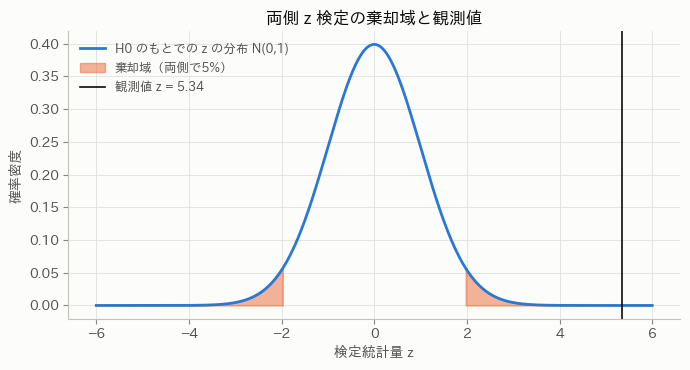

In [82]:
# 仮説・棄却域・p値: タイプ1がドラゴンの合計種族値の平均は μ0 = 全体平均 と等しいか（σ は既知とする）
alpha = 0.05
n_d = len(dragon_t1)
z_obs = (dragon_t1.mean() - mu0_all) / (sigma_all / np.sqrt(n_d))
z_crit = stats.norm.ppf(1 - alpha / 2)
p_two = 2 * stats.norm.sf(abs(z_obs))
print(f"H0: μ = {mu0_all:.1f}  H1: μ ≠ {mu0_all:.1f}  σ = {sigma_all:.1f}（既知とする）, n = {n_d}")
print(f"z = {z_obs:.3f}, 棄却域 |z| > {z_crit:.3f}（有意水準5%）, p値 = {p_two:.2e}")
print("判定:", "H0 を棄却" if p_two < alpha else "H0 を棄却しない")

zz = np.linspace(-6, 6, 600)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(zz, stats.norm.pdf(zz), color=PALETTE[0], label="H0 のもとでの z の分布 N(0,1)")
for side in [zz > z_crit, zz < -z_crit]:
    ax.fill_between(zz[side], stats.norm.pdf(zz[side]), color=PALETTE[1], alpha=0.5)
ax.fill_between([], [], color=PALETTE[1], alpha=0.5, label="棄却域（両側で5%）")
ax.axvline(z_obs, color=INK["primary"], linewidth=1.2, label=f"観測値 z = {z_obs:.2f}")
ax.set(title="両側 z 検定の棄却域と観測値", xlabel="検定統計量 z", ylabel="確率密度")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

**結果の読み方**
- $z\approx 5.34$ で棄却域 $|z|>1.96$ に入り、p値は $10^{-7}$ 程度と非常に小さい。有意水準5%で $H_0$ は棄却され、タイプ1がドラゴンのポケモンは合計種族値の平均が全体より高いと判断できる。
- ただし、ドラゴンの37匹は全体の920匹の一部であり、同じ進化系統（ミニリュウ→ハクリュー→カイリューなど）を含むので独立な標本ではない。「仮想的な母集団からの無作為標本」とみなしたうえでの判断である。

### 10.2 検出力関数と必要サンプルサイズ

**問い**：ドラゴンを含む群の平均（約540）が全体平均より高いことを、片側5%の検定で80%の確率で見抜くには、何匹調べればよいか。

**手法の要点**
- 片側検定 $H_0:\mu=\mu_0$、$H_1:\mu>\mu_0$ の棄却域は $\bar X>\mu_0+z_\alpha\sigma_0/\sqrt n$。真の分布が $N(\mu_1,\sigma_1^2)$ のときの検出力は
  $$1-\beta(\mu_1)=P\!\left(\bar X>\mu_0+z_\alpha\frac{\sigma_0}{\sqrt n}\right)=1-\Phi\!\left(\frac{\mu_0+z_\alpha\sigma_0/\sqrt n-\mu_1}{\sigma_1/\sqrt n}\right).$$
  $\mu_1$ の関数とみたものを **検出力関数** と呼ぶ。$\mu_1=\mu_0$ で値は $\alpha$ になり、$\mu_1$ や $n$ が大きいほど1に近づく。
- $\sigma_1=\sigma_0=\sigma$ のとき、検出力を $1-\beta$ にする条件は $\mu_1-\mu_0=(z_\alpha+z_\beta)\sigma/\sqrt n$ で、
  $$n=\left(\frac{(z_\alpha+z_\beta)\,\sigma}{\mu_1-\mu_0}\right)^2 .$$
  $(\mu_1-\mu_0)/\sigma$ を **効果量** と呼ぶ。効果量が大きいほど必要な $n$ は小さい。
- 比率 $H_0:p=p_0$、$H_1:p=p_1\ (>p_0)$ では、正規近似で各仮説のもとの標準偏差が異なるので
  $$p_1-p_0=z_\alpha\sqrt{\frac{p_0(1-p_0)}{n}}+z_\beta\sqrt{\frac{p_1(1-p_1)}{n}}\ \Longrightarrow\ n=\left(\frac{z_\alpha\sqrt{p_0(1-p_0)}+z_\beta\sqrt{p_1(1-p_1)}}{p_1-p_0}\right)^2 .$$

（→ py 10-2：検出力関数の図と、平均・比率の必要サンプルサイズ）

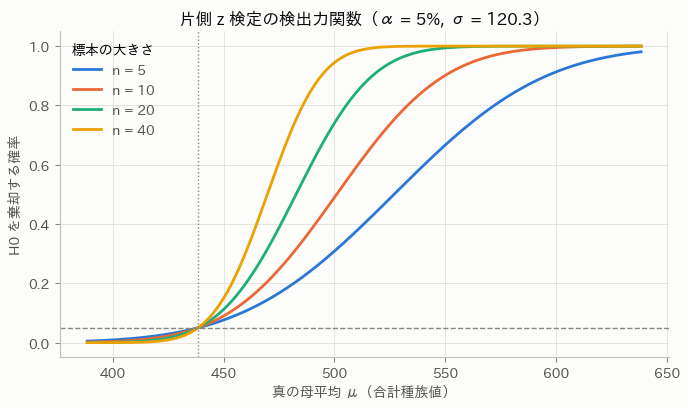

平均: δ = 102.0, 効果量 δ/σ = 0.848, 必要な n = 8.60 → 9
比率: p0 = 0.075, p1 = 0.15, 必要な n = 95.7 → 96


In [83]:
# 検出力関数と必要サンプルサイズ（片側 z 検定 H0: μ = μ0, H1: μ > μ0）
z_a = stats.norm.ppf(1 - alpha)


def power_z(mu1, n, mu0=mu0_all, sigma0=sigma_all, sigma1=None):
    """棄却域 xbar > μ0 + z_α σ0/√n のもとで、真の平均が mu1（標準偏差 sigma1）のときの検出力."""
    sigma1 = sigma0 if sigma1 is None else sigma1
    crit = mu0 + z_a * sigma0 / np.sqrt(n)
    return stats.norm.sf((crit - mu1) / (sigma1 / np.sqrt(n)))


mus = np.linspace(mu0_all - 50, mu0_all + 200, 300)
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, n in enumerate([5, 10, 20, 40]):
    ax.plot(mus, power_z(mus, n), color=PALETTE[i], label=f"n = {n}")
ax.axhline(alpha, color=INK["muted"], linestyle="--", linewidth=1)
ax.axvline(mu0_all, color=INK["muted"], linestyle=":", linewidth=1)
ax.set(title="片側 z 検定の検出力関数（α = 5%, σ = 120.3）", xlabel="真の母平均 μ（合計種族値）",
       ylabel="H0 を棄却する確率")
ax.legend(title="標本の大きさ")
fig.tight_layout()
plt.show()

# 必要サンプルサイズ: n = {(z_α + z_β) σ / δ}²
beta = 0.2
z_b = stats.norm.ppf(1 - beta)
delta_d = dragon_any.mean() - mu0_all
n_req_mean = ((z_a + z_b) * sigma_all / delta_d) ** 2
print(f"平均: δ = {delta_d:.1f}, 効果量 δ/σ = {delta_d / sigma_all:.3f}, 必要な n = {n_req_mean:.2f} → {int(np.ceil(n_req_mean))}")

# 比率: H0: p = p0, H1: p = p1（いわを含む割合 0.075 が 0.15 に増えたことを検出したい）
p0, p1 = types_of(df, "いわ").mean(), 0.15
n_req_prop = ((z_a * np.sqrt(p0 * (1 - p0)) + z_b * np.sqrt(p1 * (1 - p1))) / (p1 - p0)) ** 2
print(f"比率: p0 = {p0:.3f}, p1 = {p1}, 必要な n = {n_req_prop:.1f} → {int(np.ceil(n_req_prop))}")

**結果の読み方**
- 検出力関数は $\mu=\mu_0$ で5%から始まり、$n$ が大きいほど急に1へ立ち上がる。
- 平均：$\delta\approx102$、効果量 $\delta/\sigma\approx0.85$ は大きな効果なので、$z_{0.05}=1.645$、$z_{0.2}=0.842$ から $n\approx8.6$、つまり **9匹** で検出力80%に届く。
- 比率：いわを含む割合 $p_0\approx0.075$ が $p_1=0.15$ に増えたことを検出力80%で見抜くには、約 **96匹** が必要である。比率の差の検出には平均の差よりずっと多くの標本が要る。

### 10.3 抽出シミュレーションで有意水準と検出力を確かめる

**問い**：10.2 の式で計算した検出力は、実際のデータからの抽出で再現されるか。

**手法の要点**
- **$H_0$ が正しい状況**：全920行から $n$ 匹を復元抽出し、10.2 の棄却域（$\sigma_0=120.3$ の片側 $z$ 検定）で棄却した割合を数える。これは第1種の過誤率で、5%に近いはずである。
- **$H_1$ が正しい状況**：ドラゴンを含む61匹から $n$ 匹を復元抽出し、同じ棄却域で棄却した割合を数える。これが検出力である。
- ドラゴンを含む群の標準偏差（約138）は全体（約120）と異なるので、式の検出力は $\sigma_1=\sigma_0$ とした場合と $\sigma_1=138$ とした場合の両方を計算して比べる。母集団は正規分布ではないので、式は近似である。

（→ py 10-3：$n=5, 9, 15, 25$ で各5000回）

In [84]:
# 抽出シミュレーション: 全体から抽出（H0 が正しい）/ ドラゴンを含む群から抽出（H1 が正しい）
rng = get_rng()
reps = 5000
rows_pw = []
for n in [5, int(np.ceil(n_req_mean)), 15, 25]:
    xb0 = rng.choice(total_all, size=(reps, n), replace=True).mean(axis=1)
    xb1 = rng.choice(dragon_any, size=(reps, n), replace=True).mean(axis=1)
    crit = mu0_all + z_a * sigma_all / np.sqrt(n)
    rows_pw.append({
        "n": n,
        "第1種の過誤率（シミュ）": np.mean(xb0 > crit),
        "検出力（シミュ）": np.mean(xb1 > crit),
        "検出力（式, σ1=σ0）": power_z(dragon_any.mean(), n),
        "検出力（式, σ1=ドラゴンのσ）": power_z(dragon_any.mean(), n, sigma1=dragon_any.std()),
    })
print(f"{reps}回の復元抽出, 片側有意水準5%")
pd.DataFrame(rows_pw).round(3)

5000回の復元抽出, 片側有意水準5%


,n,第1種の過誤率（シミュ）,検出力（シミュ）,"検出力（式, σ1=σ0）","検出力（式, σ1=ドラゴンのσ）"
0,5,0.047,0.592,0.599,0.586
1,9,0.052,0.781,0.816,0.783
2,15,0.051,0.917,0.949,0.923
3,25,0.055,0.988,0.995,0.988


**結果の読み方**
- 第1種の過誤率はどの $n$ でも約0.05で、有意水準どおりになっている。
- 検出力は $n=9$ で約0.78で、設計した80%にほぼ届いた。シミュレーションの検出力は、$\sigma_1$ にドラゴンを含む群の標準偏差を使った式（$n=9$ で約0.78）とよく一致し、$\sigma_1=\sigma_0$ とした式（約0.82）はやや過大である。検出力が0.5を超える範囲（今回のように棄却限界が対立仮説の平均より手前にある場合）では、対立仮説のもとでのばらつきが大きいほど検出力は下がる。

### 10.4 生産者危険・消費者危険と OC 曲線

**問い**：タマゴ $n$ 個をかえしてオスの数 $X$ を数え、「雄率1/2の種」か「雄率7/8の種」かを判定する。判定の基準 $c$ を変えると、2種類の誤りの確率はどう変わるか。

**手法の要点**
- 抜き取り検査では、ロットから $n$ 個を検査し、不良品の数が基準 $c$ を超えたら不合格とする。
  - **生産者危険**：本当は良いロット（不良率 $p_0$）なのに不合格にする確率。第1種の過誤の確率にあたる。
  - **消費者危険**：本当は悪いロット（不良率 $p_1$）なのに合格にする確率。第2種の過誤の確率にあたる。
- ここでは「オス」を「不良品」の役に置き換える。$H_0$：雄率 $p_0=1/2$、$H_1$：雄率 $p_1=7/8$ とし、$X\sim\mathrm{Bin}(n,p)$、$X\ge c$ なら $H_0$ を棄却する。
  $$\text{生産者危険}=P(X\ge c\mid p_0)=\sum_{x=c}^{n}\binom{n}{x}p_0^x(1-p_0)^{n-x},\qquad
    \text{消費者危険}=P(X\le c-1\mid p_1)=\sum_{x=0}^{c-1}\binom{n}{x}p_1^x(1-p_1)^{n-x}.$$
- $L(p)=P(X\le c-1\mid p)$（$H_0$ を受容する確率）を $p$ の関数として描いたものを **OC 曲線**（検査特性曲線）と呼ぶ。$1-L(p)$ は検出力関数である。

（→ py 10-4：$n=20$ で $c$ ごとの2つの危険の表と、OC 曲線）

n = 20 個のタマゴ, 判定基準 c ごとの2つの危険
 c  生産者危険 P(X≥c | 1/2)  消費者危険 P(X≤c-1 | 7/8)
12              0.2517                0.0003
13              0.1316                0.0019
14              0.0577                0.0084
15              0.0207                0.0312
16              0.0059                0.0950
17              0.0013                0.2347
18              0.0002                0.4647


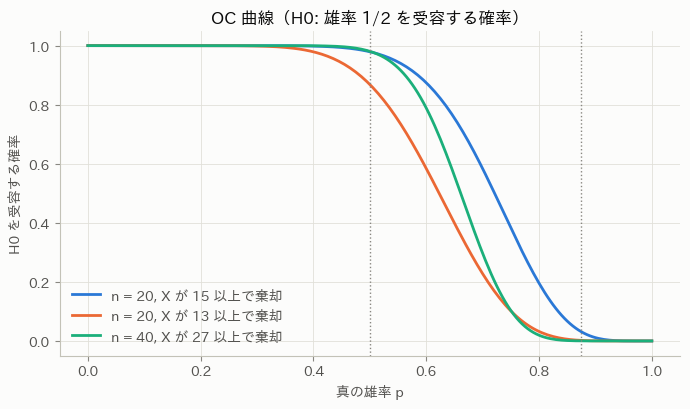

n=20, c=15: 生産者危険 0.0207, 消費者危険 0.0312
n=20, c=13: 生産者危険 0.1316, 消費者危険 0.0019
n=40, c=27: 生産者危険 0.0192, 消費者危険 0.0002


In [85]:
# 生産者危険・消費者危険と OC 曲線
# 設定: 雄率 1/2 の種（合格 = H0）か雄率 7/8 の種（不合格 = H1）かを、タマゴ n 個中のオスの数 X で判定する
#       X ≥ c なら「7/8 の種」と判定（H0 を棄却）
pm0, pm1 = 0.5, 0.875
n_egg = 20
rows_oc = []
for c in range(12, 19):
    rows_oc.append({"c": c,
                    "生産者危険 P(X≥c | 1/2)": stats.binom.sf(c - 1, n_egg, pm0),
                    "消費者危険 P(X≤c-1 | 7/8)": stats.binom.cdf(c - 1, n_egg, pm1)})
print(f"n = {n_egg} 個のタマゴ, 判定基準 c ごとの2つの危険")
print(pd.DataFrame(rows_oc).round(4).to_string(index=False))

# OC 曲線 L(p) = P(H0 を受容 | p) = P(X ≤ c-1 | p)
pp = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, (n, c) in enumerate([(20, 15), (20, 13), (40, 27)]):
    ax.plot(pp, stats.binom.cdf(c - 1, n, pp), color=PALETTE[i], label=f"n = {n}, X が {c} 以上で棄却")
for pv in [pm0, pm1]:
    ax.axvline(pv, color=INK["muted"], linestyle=":", linewidth=1)
ax.set(title="OC 曲線（H0: 雄率 1/2 を受容する確率）", xlabel="真の雄率 p", ylabel="H0 を受容する確率")
ax.legend()
fig.tight_layout()
plt.show()
for n, c in [(20, 15), (20, 13), (40, 27)]:
    print(f"n={n}, c={c}: 生産者危険 {stats.binom.sf(c - 1, n, pm0):.4f}, 消費者危険 {stats.binom.cdf(c - 1, n, pm1):.4f}")

**結果の読み方**
- $n=20$ で $c$ を大きくすると、生産者危険は減り（$c=12$ で約0.25 → $c=18$ で約0.0002）、消費者危険は増える（約0.0003 → 約0.46）。$n$ を固定したままでは、2つの危険を同時に小さくすることはできない。
- $c=15$ とすると生産者危険 約0.021、消費者危険 約0.031 で、どちらも5%以下になる。
- OC 曲線は、$c$ を小さくすると左に、$c$ を大きくすると右にずれる。$n=40$、$c=27$ では曲線の傾きが急になり、生産者危険 約0.019、消費者危険 約0.0002 と両方が小さくなる。2つの危険を両方とも下げるには $n$ を増やす必要がある。

### 10.5 ネイマン・ピアソンの補題

**問い**：$n=20$ のタマゴで $H_0:p=1/2$ 対 $H_1:p=7/8$ を検定するとき、有意水準5%以下の棄却域の中で最も検出力が高いのはどれか。

**手法の要点**
- 単純仮説 $H_0:\theta=\theta_0$ 対 $H_1:\theta=\theta_1$ の検定で、**尤度比** $\Lambda(x)=f(x;\theta_1)/f(x;\theta_0)$ が大きい $x$ から順に棄却域に入れた検定
  $$\text{棄却域 } R=\{x:\Lambda(x)>k\}\quad(P_{\theta_0}(X\in R)=\alpha\text{ となるよう } k \text{ を選ぶ})$$
  は、有意水準 $\alpha$ の検定の中で検出力が最大（**最強力検定**）である。これがネイマン・ピアソンの補題である。直観的には、「$H_0$ のもとでの確率（費用）あたりの $H_1$ のもとでの確率（利得）」が大きい点から棄却域に入れるのが最も効率がよい。
- 二項分布では $\Lambda(x)=\left(\frac{p_1}{p_0}\right)^x\left(\frac{1-p_1}{1-p_0}\right)^{n-x}$ で、$p_1>p_0$ なら $x$ の単調増加関数である。したがって最強力検定は「$X\ge c$ で棄却」の形になり、10.4 の判定方式は最良であることがわかる。$c$ は $p_1$ の値によらないので、$H_1:p>1/2$ に対しても一様に最強力（UMP）である。正規分布の平均の片側 $z$ 検定（10.2）が UMP であるのも同じ理由による。
- 離散分布では、ちょうど $\alpha$ にするために境界の点 $x=c-1$ で確率 $\gamma$ で棄却する **確率化検定** を考えることがある。

（→ py 10-5：尤度比の単調性、確率化検定の検出力、ランダムに作った20000個の棄却域との比較）

尤度比 f1(x)/f0(x) は x の単調増加関数: True
X≥15 の有意水準 0.0207, 検出力 0.9688
確率化検定（γ = 0.793）: 有意水準 0.05, 検出力 0.9869
ランダムな棄却域のうち有意水準 5% 以下で最大の検出力: 0.9050


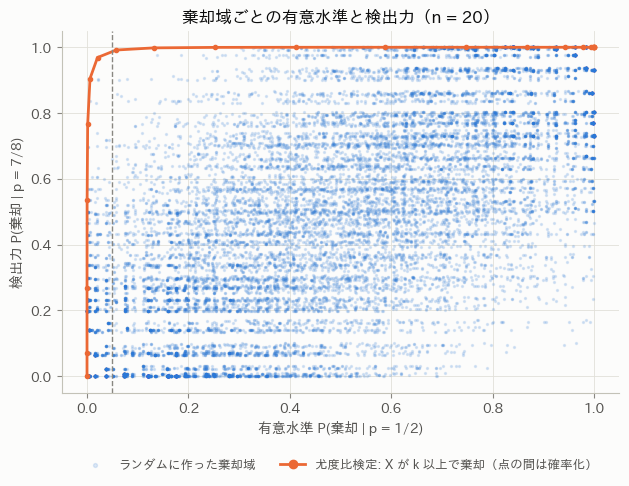

In [86]:
# ネイマン・ピアソンの補題: 尤度比の大きい x から棄却域に入れる検定が最強力
x_vals = np.arange(n_egg + 1)
f0 = stats.binom.pmf(x_vals, n_egg, pm0)
f1 = stats.binom.pmf(x_vals, n_egg, pm1)
lr = f1 / f0
print("尤度比 f1(x)/f0(x) は x の単調増加関数:", bool(np.all(np.diff(lr) > 0)))

# 尤度比検定（X ≥ k）の (有意水準, 検出力) と、ランダムに作った棄却域の (有意水準, 検出力)
np_size = np.array([f0[x_vals >= k].sum() for k in range(n_egg + 2)])
np_power = np.array([f1[x_vals >= k].sum() for k in range(n_egg + 2)])
rng = get_rng()
regions = rng.random((20000, n_egg + 1)) < rng.random((20000, 1))   # 各 x を確率 q で棄却域に入れる
rand_size, rand_power = regions @ f0, regions @ f1

# 有意水準 5% ちょうどの確率化検定（X ≥ 15 で棄却、X = 14 のとき確率 γ で棄却）
k_np = 15
gamma = (alpha - f0[x_vals >= k_np].sum()) / f0[k_np - 1]
power_np = f1[x_vals >= k_np].sum() + gamma * f1[k_np - 1]
best_rand = rand_power[rand_size <= alpha].max()
print(f"X≥15 の有意水準 {np_size[k_np]:.4f}, 検出力 {np_power[k_np]:.4f}")
print(f"確率化検定（γ = {gamma:.3f}）: 有意水準 {alpha}, 検出力 {power_np:.4f}")
print(f"ランダムな棄却域のうち有意水準 5% 以下で最大の検出力: {best_rand:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(rand_size, rand_power, s=2, color=PALETTE[0], alpha=0.15, label="ランダムに作った棄却域")
ax.plot(np_size, np_power, "o-", color=PALETTE[1], markersize=3, label="尤度比検定: X が k 以上で棄却（点の間は確率化）")
ax.axvline(alpha, color=INK["muted"], linestyle="--", linewidth=1)
ax.set(title="棄却域ごとの有意水準と検出力（n = 20）", xlabel="有意水準 P(棄却 | p = 1/2)",
       ylabel="検出力 P(棄却 | p = 7/8)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, markerscale=2)
fig.tight_layout()
plt.show()

**結果の読み方**
- 尤度比は $x$ の単調増加関数である。$X\ge15$ の棄却域は有意水準 約0.021、検出力 約0.969で、$X=14$ のとき確率 約0.79 で棄却する確率化検定にすると、有意水準をちょうど0.05にして検出力は約0.987に上がる。
- ランダムに作った棄却域はすべて尤度比検定の曲線の下側にあり、有意水準5%以下のものの最大の検出力は約0.905だった。同じ有意水準なら、尤度比で棄却域を作る検定に勝てない。

### 10.6 p値の分布

**問い**：帰無仮説が正しいとき、p値はどのように分布するか。

**手法の要点**
- 検定統計量 $T$ が連続分布で、分布関数 $F$ が $H_0$ のもとで正しいとき、片側のp値 $p=1-F(T)$ は一様分布 $U(0,1)$ にしたがう（$P(1-F(T)\le u)=P(T\ge F^{-1}(1-u))=u$）。両側検定でも同様である。
- したがって「$p\le\alpha$ で棄却する」検定の第1種の過誤の確率はちょうど $\alpha$ になる。$H_1$ が正しいとき、p値の分布は0の近くに偏る（$P(p\le\alpha)$ が検出力）。
- 検定統計量が離散分布（二項検定など）だとp値は飛び飛びの値しかとらず、$P_{H_0}(p\le\alpha)\le\alpha$ となるが、一般に等号は成り立たない。
- 全920行から $n=20$ を復元抽出して、$H_0:\mu=\mu_0$（全体平均、$H_0$ は正しい）の1標本 $t$ 検定を5000回行う。同じことをドラゴンを含む群からの抽出でも行う。

（→ py 10-6：p値のヒストグラムと一様分布への KS 検定）

H0 のもと: P(p ≤ 0.05) = 0.054, P(p ≤ 0.5) = 0.495
一様分布への KS 検定: D = 0.0093, p値 = 0.775
H1 のもと: P(p ≤ 0.05) = 0.860（検出力）
二項検定: P(p値 ≤ 0.05 | H0) = 0.0207（0.05 より小さい）


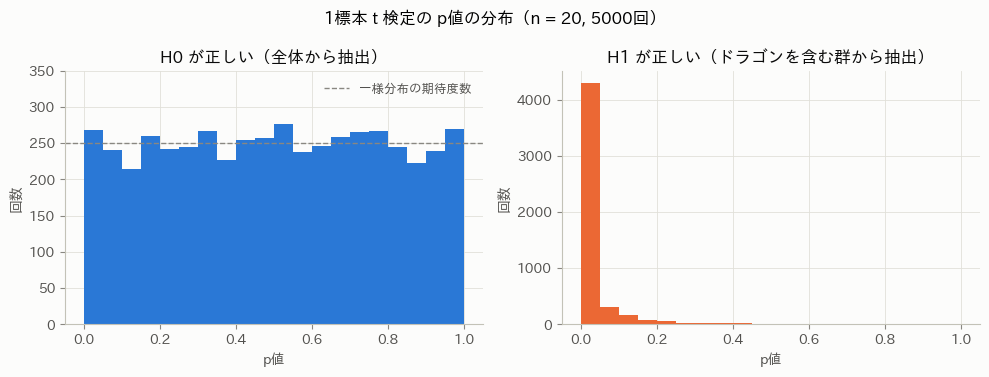

In [87]:
# p値の分布: H0 が正しいと一様分布 U(0,1) になる
rng = get_rng()
n_p = 20
samp0 = rng.choice(total_all, size=(reps, n_p), replace=True)      # H0 が正しい（全体から抽出）
samp1 = rng.choice(dragon_any, size=(reps, n_p), replace=True)     # H1 が正しい（ドラゴンを含む群から抽出）
pv0 = stats.ttest_1samp(samp0, mu0_all, axis=1).pvalue
pv1 = stats.ttest_1samp(samp1, mu0_all, axis=1).pvalue
print(f"H0 のもと: P(p ≤ 0.05) = {np.mean(pv0 <= 0.05):.3f}, P(p ≤ 0.5) = {np.mean(pv0 <= 0.5):.3f}")
ks = stats.kstest(pv0, "uniform")
print(f"一様分布への KS 検定: D = {ks.statistic:.4f}, p値 = {ks.pvalue:.3f}")
print(f"H1 のもと: P(p ≤ 0.05) = {np.mean(pv1 <= 0.05):.3f}（検出力）")

# 離散分布の検定では p値は一様にならない（二項検定 H0: p = 1/2, n = 20, 片側）
pv_binom = stats.binom.sf(x_vals - 1, n_egg, pm0)          # 観測値 x の p値 P(X ≥ x)
print(f"二項検定: P(p値 ≤ 0.05 | H0) = {f0[pv_binom <= 0.05].sum():.4f}（0.05 より小さい）")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
bins = np.linspace(0, 1, 21)
axes[0].hist(pv0, bins=bins, color=PALETTE[0])
axes[0].axhline(reps / 20, color=INK["muted"], linestyle="--", linewidth=1, label="一様分布の期待度数")
axes[0].set(title="H0 が正しい（全体から抽出）", xlabel="p値", ylabel="回数")
axes[0].set_ylim(0, reps / 20 * 1.4)
axes[0].legend(loc="upper right", fontsize=9)
axes[1].hist(pv1, bins=bins, color=PALETTE[1])
axes[1].set(title="H1 が正しい（ドラゴンを含む群から抽出）", xlabel="p値", ylabel="回数")
fig.suptitle(f"1標本 t 検定の p値の分布（n = {n_p}, {reps}回）", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

**結果の読み方**
- $H_0$ が正しいとき、p値のヒストグラムはほぼ平らで、$P(p\le0.05)\approx0.054$、一様分布への KS 検定の p値は約0.78 と、一様分布と矛盾しない。合計種族値は正規分布ではないが、$n=20$ でも $t$ 検定の p値はほぼ一様になっている。
- $H_1$ が正しいとき（ドラゴンを含む群からの抽出）、p値は0の近くに集中し、$P(p\le0.05)\approx0.86$ が両側 $t$ 検定の検出力である。
- 片側の二項検定（$n=20$、$H_0:p=1/2$、$H_1:p>1/2$）では、$P_{H_0}(p\le0.05)\approx0.021$ で、名目の5%より小さい。離散分布の検定は保守的になる。

### まとめ

- タイプ1がドラゴンのポケモンの合計種族値の平均は、全体平均より明らかに高い（$z\approx5.3$）。ドラゴンを含む群の効果量は約0.85と大きいので、片側5%・検出力80%には約9匹の標本で足りる。一方、比率の小さな変化（0.075 → 0.15）の検出には約96匹が必要である。
- 2種類の過誤は、$n$ を固定すると一方を下げれば他方が上がる。両方を下げるには $n$ を増やす。抜き取り検査の OC 曲線は、この関係を判定基準 $c$ ごとに一目で示す。
- ネイマン・ピアソンの補題により、尤度比の大きい順に棄却域を作る検定が最強力であり、二項分布や正規分布の平均の片側検定では「統計量が大きければ棄却」という自然な検定が最良である。
- $H_0$ のもとでp値は一様分布にしたがうので、「$p\le\alpha$ で棄却」は第1種の過誤率 $\alpha$ の検定になる。p値は $H_0$ が正しい確率ではなく、効果の大きさも表さない。

## 第11章 正規分布に関する検定

### 章の概要

母集団分布が正規分布であると仮定して、平均や分散についての仮説を検定する方法をまとめる。
中心となる考え方は、正規標本から作った統計量が $H_0$ のもとで $t$ 分布・$\chi^2$ 分布・$F$ 分布に **正確に** したがうことを使う点である（第6章の標本分布）。
第9章の信頼区間とは同じピボット量を使っており、「両側検定で棄却されない」ことと「信頼区間が $H_0$ の値を含む」ことは同値である。
正規性が疑わしいときの代わりの方法は、第13章のノンパラメトリック法で扱う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 11.1 | 1標本 $t$ 検定 | でんきタイプの素早さの平均は、全体平均と等しいか |
| 11.2 | 2標本 $t$ 検定（等分散）・Welch の $t$ 検定 | ほのおとみずで合計種族値の平均は違うか |
| 11.3 | 対応のある $t$ 検定 | 同じポケモンの攻撃と特攻の平均に差はあるか |
| 11.4 | 1標本の分散の $\chi^2$ 検定 | みずタイプの合計種族値の分散は、全体の分散と等しいか |
| 11.5 | 等分散の $F$ 検定 | ほのおとみずで合計種族値の分散は違うか |
| 11.6 | 正規性の確認（Q-Q プロット・Shapiro–Wilk 検定） | ここまでの検定の前提は成り立っているか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（連続とみなす） | 11.2・11.4・11.5 の対象。ほのお（タイプ1、59匹）とみず（タイプ1、124匹）を比べる |
| `素早` | 量的 | 11.1 の対象。でんき（タイプ1、50匹） |
| `攻撃`・`特攻` | 量的 | 11.3 で同じポケモンの2つの値の差 $D=$ 攻撃 − 特攻 を使う（全920行） |
| `タイプ1` | 質的（18水準） | 群を分ける変数 |

- **対象の行**：群は `タイプ1` だけで作る。`types_of()` で「タイプ1かタイプ2がほのお」とすると、ほのお・みずの両方をもつボルケニオンが2群に同時に入り、2標本の独立性が崩れるためである。
- **加工**：なし。
- **データの性質と注意点**：全920行を仮想的な母集団からの無作為標本とみなす。11.1 と 11.4 の基準値 $\mu_0,\sigma_0^2$ には全920行の平均・分散を使うが、でんき・みずの行はこの全体に含まれている。ここでは基準値を「外から与えられた定数」とみなして検定の手順を示す。同じ進化系統の行が似た値をとるため、独立性の仮定は近似である。

In [88]:
# 使う群（タイプ1で分類）と列の要約
fire11 = df.loc[df["タイプ1"] == "ほのお", "合計種族値"].to_numpy(dtype=float)
water11 = df.loc[df["タイプ1"] == "みず", "合計種族値"].to_numpy(dtype=float)
elec_speed = df.loc[df["タイプ1"] == "でんき", "素早"].to_numpy(dtype=float)
diff_as = (df["攻撃"] - df["特攻"]).to_numpy(dtype=float)
summary11 = pd.DataFrame({
    "n": [len(fire11), len(water11), len(elec_speed), len(diff_as)],
    "平均": [fire11.mean(), water11.mean(), elec_speed.mean(), diff_as.mean()],
    "標準偏差(不偏)": [fire11.std(ddof=1), water11.std(ddof=1), elec_speed.std(ddof=1), diff_as.std(ddof=1)],
}, index=["ほのお 合計種族値", "みず 合計種族値", "でんき 素早", "全体 攻撃−特攻"])
print(f"全920行の素早の平均: {df['素早'].mean():.2f}")
summary11.round(2)

全920行の素早の平均: 68.55


,n,平均,標準偏差(不偏)
ほのお 合計種族値,59,458.75,106.12
みず 合計種族値,124,432.45,115.40
でんき 素早,50,87.66,27.74
全体 攻撃−特攻,920,6.74,36.37


### 11.1 1標本 $t$ 検定

**問い**：タイプ1がでんきのポケモンの素早さの母平均は、全体平均 $\mu_0\approx68.6$ と等しいか。

**手法の要点**
- $X_1,\dots,X_n\overset{\text{iid}}{\sim}N(\mu,\sigma^2)$、$\sigma^2$ 未知。$H_0:\mu=\mu_0$、$H_1:\mu\neq\mu_0$。
- 検定統計量は、不偏分散 $s^2$ を使って
  $$t=\frac{\bar X-\mu_0}{s/\sqrt n}\ \sim\ t(n-1)\quad(H_0\text{ のもと}).$$
  有意水準 $\alpha$ の棄却域は $|t|>t_{\alpha/2}(n-1)$。
- 前提は独立性と正規性。$n$ が大きいときは中心極限定理により正規性の破れに強い。

（→ py 11-1：定義式から $t$ と p値を計算し、`scipy.stats.ttest_1samp` と照合）

In [89]:
# 1標本 t 検定: でんき（タイプ1）の素早の平均は、全体平均 μ0 と等しいか
mu0_speed = df["素早"].mean()   # 基準値として固定する
n_e = len(elec_speed)
t_e = (elec_speed.mean() - mu0_speed) / (elec_speed.std(ddof=1) / np.sqrt(n_e))
p_e = 2 * stats.t.sf(abs(t_e), n_e - 1)
lib_e = stats.ttest_1samp(elec_speed, mu0_speed)
print(f"H0: μ = {mu0_speed:.2f}, n = {n_e}")
print(f"手計算: t = {t_e:.4f}, 自由度 {n_e - 1}, p値 = {p_e:.3g}")
print(f"scipy : t = {lib_e.statistic:.4f}, p値 = {lib_e.pvalue:.3g}")
print(f"棄却限界 t(0.025; {n_e - 1}) = {stats.t.ppf(0.975, n_e - 1):.3f} → 有意水準5%で",
      "H0 を棄却" if p_e < 0.05 else "H0 を棄却しない")

H0: μ = 68.55, n = 50
手計算: t = 4.8719, 自由度 49, p値 = 1.2e-05
scipy : t = 4.8719, p値 = 1.2e-05
棄却限界 t(0.025; 49) = 2.010 → 有意水準5%で H0 を棄却


**結果の読み方**
- でんきの素早さの平均は約87.7で、$t\approx4.87$（自由度49）、p値は約 $1.2\times10^{-5}$。有意水準5%の棄却限界2.01を大きく超え、$H_0$ は棄却される。でんきタイプは素早い傾向がある。
- 手計算と scipy の結果は一致する。素早さの分布は 11.6 の Shapiro–Wilk 検定でも正規性は棄却されない（正規であることが示されたわけではないが、n=50 と $t$ 検定の頑健性を考えると、前提に大きな問題はないと判断できる）。

### 11.2 2標本 $t$ 検定（等分散）と Welch の $t$ 検定

**問い**：ほのおとみず（タイプ1）で、合計種族値の母平均は異なるか。

**手法の要点**
- 独立な2標本 $X_1,\dots,X_{n_1}\sim N(\mu_1,\sigma_1^2)$、$Y_1,\dots,Y_{n_2}\sim N(\mu_2,\sigma_2^2)$。$H_0:\mu_1=\mu_2$、$H_1:\mu_1\neq\mu_2$。
- **等分散を仮定する場合**（$\sigma_1^2=\sigma_2^2$）：$s_p^2=\frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}$ として
  $$t=\frac{\bar X-\bar Y}{s_p\sqrt{1/n_1+1/n_2}}\ \sim\ t(n_1+n_2-2).$$
- **Welch の $t$ 検定**（等分散を仮定しない）：
  $$t=\frac{\bar X-\bar Y}{\sqrt{s_1^2/n_1+s_2^2/n_2}},\qquad
    \nu=\frac{\left(s_1^2/n_1+s_2^2/n_2\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1}+\frac{(s_2^2/n_2)^2}{n_2-1}}$$
  とし、$t$ を自由度 $\nu$ の $t$ 分布で近似する。$H_0$ のもとでも正確には $t$ 分布ではない。
- 群の大きさが違い、分散も違うときは等分散の $t$ 検定の第1種の過誤率がずれる。そのため、事前に $F$ 検定で等分散かを調べて使い分けるより、最初から Welch の検定を使うのが近年の標準的な考え方である。

（→ py 11-2：2つの検定を手計算し、`scipy.stats.ttest_ind` と照合）

In [90]:
# 2標本 t 検定（等分散）と Welch の t 検定: ほのお vs みず の合計種族値
n1, n2 = len(fire11), len(water11)
v1, v2 = fire11.var(ddof=1), water11.var(ddof=1)
d12 = fire11.mean() - water11.mean()
# 等分散: プールした分散, 自由度 n1+n2-2
sp2 = ((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2)
t_pool = d12 / np.sqrt(sp2 * (1 / n1 + 1 / n2))
p_pool = 2 * stats.t.sf(abs(t_pool), n1 + n2 - 2)
# Welch: 自由度はサタスウェイトの近似
se_w = np.sqrt(v1 / n1 + v2 / n2)
nu_w = se_w**4 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
t_welch = d12 / se_w
p_welch = 2 * stats.t.sf(abs(t_welch), nu_w)
lib_pool = stats.ttest_ind(fire11, water11, equal_var=True)
lib_welch = stats.ttest_ind(fire11, water11, equal_var=False)
pd.DataFrame({
    "t（手計算）": [t_pool, t_welch], "自由度": [n1 + n2 - 2, nu_w], "p値（手計算）": [p_pool, p_welch],
    "t（scipy）": [lib_pool.statistic, lib_welch.statistic], "p値（scipy）": [lib_pool.pvalue, lib_welch.pvalue],
}, index=["等分散 t 検定", "Welch の t 検定"]).round(4)

,t（手計算）,自由度,p値（手計算）,t（scipy）,p値（scipy）
等分散 t 検定,1.4776,181.0000,0.1412,1.4776,0.1412
Welch の t 検定,1.5224,123.2324,0.1305,1.5224,0.1305


**結果の読み方**
- 等分散 $t$ 検定は $t\approx1.48$（自由度181）、p値 約0.14。Welch は $t\approx1.52$（自由度 約123.2）、p値 約0.13。どちらも有意水準5%で $H_0$ は棄却されず、ほのおとみずの合計種族値の平均に差があるとは言えない。
- 2群の分散が近いため（11.5）、2つの検定の結果はほとんど同じである。手計算の値は scipy と一致する。

### 11.3 対応のある $t$ 検定

**問い**：同じポケモンの攻撃と特攻の母平均に差はあるか。

**手法の要点**
- 1匹ごとに2つの値 $(X_i,Y_i)$ が対になっているとき、差 $D_i=X_i-Y_i$ を1標本とみなす。$D_i\overset{\text{iid}}{\sim}N(\mu_D,\sigma_D^2)$、$H_0:\mu_D=0$。
  $$t=\frac{\bar D}{s_D/\sqrt n}\ \sim\ t(n-1).$$
- 対応を無視して2標本 $t$ 検定をすると、$V(\bar X-\bar Y)=\frac{\sigma_X^2+\sigma_Y^2-2\sigma_{XY}}{n}$ の共分散の項が使われない。$X$ と $Y$ が正の相関をもつと分散を過大評価し、検出力が下がる。
- 前提は差 $D$ の正規性（$X,Y$ それぞれの正規性ではない）。

（→ py 11-3：手計算と `scipy.stats.ttest_rel` の照合、対応を無視した場合との比較）

In [91]:
# 対応のある t 検定: 同じポケモンの 攻撃 と 特攻 の差 D = 攻撃 − 特攻
n_d = len(diff_as)
t_pair = diff_as.mean() / (diff_as.std(ddof=1) / np.sqrt(n_d))
p_pair = 2 * stats.t.sf(abs(t_pair), n_d - 1)
lib_pair = stats.ttest_rel(df["攻撃"], df["特攻"])
lib_ind = stats.ttest_ind(df["攻撃"], df["特攻"])   # 対応を無視した場合（比較用）
print(f"D の平均 {diff_as.mean():.2f}, 標準偏差 {diff_as.std(ddof=1):.2f}, n = {n_d}")
print(f"対応あり 手計算: t = {t_pair:.4f}, 自由度 {n_d - 1}, p値 = {p_pair:.3g}")
print(f"対応あり scipy : t = {lib_pair.statistic:.4f}, p値 = {lib_pair.pvalue:.3g}")
print(f"対応を無視した2標本 t 検定: t = {lib_ind.statistic:.4f}, p値 = {lib_ind.pvalue:.3g}")
print(f"攻撃と特攻の相関係数: {df['攻撃'].corr(df['特攻']):.3f}")

D の平均 6.74, 標準偏差 36.37, n = 920
対応あり 手計算: t = 5.6243, 自由度 919, p値 = 2.47e-08
対応あり scipy : t = 5.6243, p値 = 2.47e-08
対応を無視した2標本 t 検定: t = 4.3989, p値 = 1.15e-05
攻撃と特攻の相関係数: 0.388


**結果の読み方**
- 攻撃 − 特攻 の平均は約6.7（標準偏差 約36）で、$t\approx5.62$（自由度919）、p値 約 $2.5\times10^{-8}$。有意水準5%で $H_0$ は棄却され、攻撃の方が平均的にやや高い。
- 攻撃と特攻の相関は約0.39で正なので、対応を無視した2標本 $t$ 検定の $t$（約4.40）は対応のある検定より小さい。どちらでも有意だが、対になったデータには対応のある検定を使うべきである。
- 差は統計的に有意だが、平均6.7は種族値の尺度（標準偏差 約36）に比べて小さい。$n=920$ と大きいので、小さな差でも p値は非常に小さくなる。

### 11.4 1標本の分散の $\chi^2$ 検定

**問い**：みず（タイプ1）の合計種族値の母分散は、全体の分散 $\sigma_0^2\approx14464$（$\sigma_0\approx120.3$）と等しいか。

**手法の要点**
- $X_1,\dots,X_n\overset{\text{iid}}{\sim}N(\mu,\sigma^2)$、$H_0:\sigma^2=\sigma_0^2$、$H_1:\sigma^2\neq\sigma_0^2$。
  $$\chi^2=\frac{(n-1)s^2}{\sigma_0^2}\ \sim\ \chi^2(n-1)\quad(H_0\text{ のもと}).$$
  棄却域は $\chi^2<\chi^2_{1-\alpha/2}(n-1)$ または $\chi^2>\chi^2_{\alpha/2}(n-1)$（添字は上側確率）。$\chi^2$ 分布は非対称なので、両側 p値は小さい方の裾確率の2倍とする。
- 平均の検定と違い、**正規性が崩れると $n$ が大きくても正しい有意水準にならない**（母集団の尖度の影響が残る）。

（→ py 11-4：統計量・棄却域・p値）

In [92]:
# 1標本の分散の χ² 検定: みずの合計種族値の母分散は σ0² = 全920行の分散 と等しいか
sigma0_sq = df["合計種族値"].var(ddof=0)   # 基準値として固定する
chi2_w = (n2 - 1) * v2 / sigma0_sq
# 両側 p値: 小さい側の裾確率の2倍
p_chi2 = 2 * min(stats.chi2.cdf(chi2_w, n2 - 1), stats.chi2.sf(chi2_w, n2 - 1))
print(f"H0: σ² = {sigma0_sq:.1f}（σ = {np.sqrt(sigma0_sq):.1f}）, 不偏分散 {v2:.1f}, n = {n2}")
print(f"χ² = (n-1)s²/σ0² = {chi2_w:.3f}, 自由度 {n2 - 1}")
print(f"棄却域: χ² < {stats.chi2.ppf(0.025, n2 - 1):.2f} または χ² > {stats.chi2.ppf(0.975, n2 - 1):.2f}（有意水準5%）")
print(f"両側 p値 = {p_chi2:.4f}")

H0: σ² = 14463.9（σ = 120.3）, 不偏分散 13318.0, n = 124
χ² = (n-1)s²/σ0² = 113.255, 自由度 123
棄却域: χ² < 94.19 または χ² > 155.59（有意水準5%）
両側 p値 = 0.5514


**結果の読み方**
- $\chi^2\approx113.3$（自由度123）で、棄却域（94.2未満か155.6超）に入らず、両側 p値 約0.55。みずの合計種族値の分散が全体と異なるとは言えない。
- みずの合計種族値は Shapiro–Wilk 検定で正規性がやや疑われ（11.6）、尖度も負なので、この p値は目安として読む。

### 11.5 等分散の $F$ 検定

**問い**：ほのおとみず（タイプ1）で、合計種族値の母分散は異なるか。

**手法の要点**
- 独立な2つの正規標本で $H_0:\sigma_1^2=\sigma_2^2$。
  $$F=\frac{s_1^2}{s_2^2}\ \sim\ F(n_1-1,\,n_2-1)\quad(H_0\text{ のもと}).$$
  棄却域は $F<F_{1-\alpha/2}(n_1-1,n_2-1)$ または $F>F_{\alpha/2}(n_1-1,n_2-1)$。
- 分散の $\chi^2$ 検定と同じく正規性に敏感である。参考として、各群の中央値からの絶対偏差に分散分析を行う Levene 検定（Brown–Forsythe 版）も示す。こちらは正規性の破れに比較的強い。

（→ py 11-5：$F$ 検定と Levene 検定）

In [93]:
# 等分散の F 検定: ほのお と みず の合計種族値の分散
f_stat = v1 / v2
p_f = 2 * min(stats.f.cdf(f_stat, n1 - 1, n2 - 1), stats.f.sf(f_stat, n1 - 1, n2 - 1))
print(f"F = s1²/s2² = {f_stat:.4f}, 自由度 ({n1 - 1}, {n2 - 1}), 両側 p値 = {p_f:.4f}")
print(f"棄却域: F < {stats.f.ppf(0.025, n1 - 1, n2 - 1):.3f} または F > {stats.f.ppf(0.975, n1 - 1, n2 - 1):.3f}")
# 参考: 正規性に頑健な Levene 検定（中央値版 = Brown-Forsythe）
lev = stats.levene(fire11, water11, center="median")
print(f"参考 Levene（中央値）: W = {lev.statistic:.4f}, p値 = {lev.pvalue:.4f}")

F = s1²/s2² = 0.8457, 自由度 (58, 123), 両側 p値 = 0.4794
棄却域: F < 0.629 または F > 1.533
参考 Levene（中央値）: W = 0.3423, p値 = 0.5592


**結果の読み方**
- $F\approx0.85$（自由度 (58, 123)）、両側 p値 約0.48 で、有意水準5%で $H_0$ は棄却されない。Levene 検定でも p値 約0.56 で、同じ結論である。
- 第9章の分散の比の95%信頼区間（約0.55〜1.34）が1を含むことと対応している。

### 11.6 正規性の確認

**問い**：ここまでの検定の前提である正規性は、データで成り立っているか。

**手法の要点**
- **正規 Q-Q プロット**：データを小さい順に並べた $x_{(i)}$ を、標準正規分布の分位点 $\Phi^{-1}\!\left(\frac{i-0.5}{n}\right)$ に対して描く。正規分布ならほぼ直線（傾き $s$、切片 $\bar x$）に乗る。両端が直線より内側に曲がれば裾が軽く、外側に反れば裾が重い。
- **Shapiro–Wilk 検定**：$H_0$：母集団が正規分布。統計量 $W$ は、順序統計量の重み付き和の2乗を偏差平方和で割ったもので（$0<W\le1$）、1に近いほど正規分布に近い。
- 正規性の検定は、$n$ が小さいと検出力が低く破れを見逃し、$n$ が大きいと実用上問題のない小さなずれでも棄却する。検定結果だけでなく、Q-Q プロットで **どのようなずれか** を見て判断する。

（→ py 11-6：各対象の歪度・尖度・Shapiro–Wilk 検定と、Q-Q プロット）

       対象   n      歪度  尖度(-3)      W     p値
ほのお 合計種族値  59 -0.0904 -0.9562 0.9593 0.0465
 みず 合計種族値 124  0.0981 -0.3739 0.9764 0.0288
   でんき 素早  50  0.0148 -0.5134 0.9724 0.2881
 全体 攻撃−特攻 920  0.0881  0.3752 0.9934 0.0004
 全体 合計種族値 920  0.0966 -0.5318 0.9820 0.0000


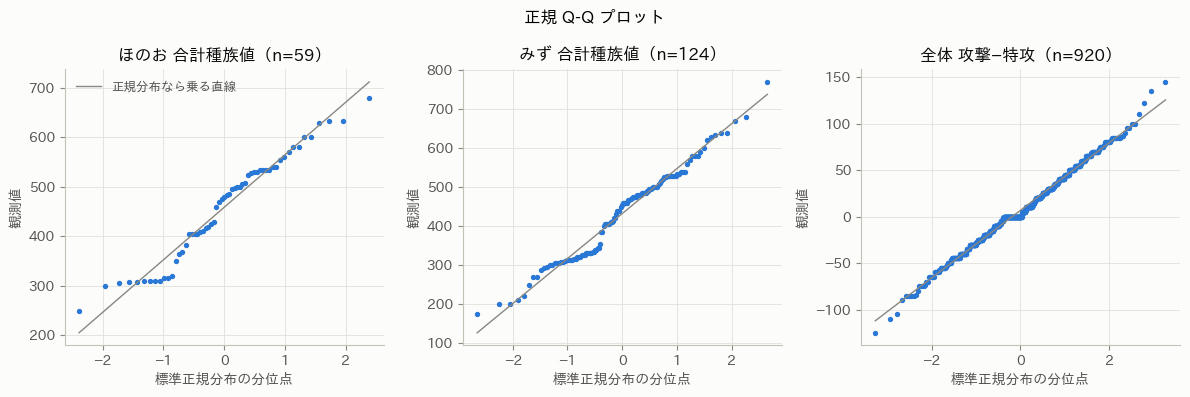

In [94]:
# 正規性の確認: Q-Q プロットと Shapiro-Wilk 検定
targets11 = {"ほのお 合計種族値": fire11, "みず 合計種族値": water11,
             "でんき 素早": elec_speed, "全体 攻撃−特攻": diff_as,
             "全体 合計種族値": df["合計種族値"].to_numpy(dtype=float)}
rows_sw = []
for name, x in targets11.items():
    sw = stats.shapiro(x)
    rows_sw.append({"対象": name, "n": len(x), "歪度": stats.skew(x), "尖度(-3)": stats.kurtosis(x),
                    "W": sw.statistic, "p値": sw.pvalue})
print(pd.DataFrame(rows_sw).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, ["ほのお 合計種族値", "みず 合計種族値", "全体 攻撃−特攻"]):
    x = np.sort(targets11[name])
    q = stats.norm.ppf((np.arange(1, len(x) + 1) - 0.5) / len(x))   # 理論分位点
    ax.scatter(q, x, s=8, color=PALETTE[0])
    ax.plot(q, x.mean() + x.std(ddof=1) * q, color=INK["muted"], linewidth=1, label="正規分布なら乗る直線")
    ax.set(title=f"{name}（n={len(x)}）", xlabel="標準正規分布の分位点", ylabel="観測値")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("正規 Q-Q プロット", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

**結果の読み方**
- ほのお（$W\approx0.959$、p値 約0.047）・みず（$W\approx0.976$、p値 約0.029）の合計種族値は、有意水準5%でわずかに正規性が棄却される。Q-Q プロットには、合計種族値300前後と500前後に点が集まる段がある。進化前と最終進化形の値がそれぞれ固まっている多峰的な形で、尖度が負（ほのおは約 −0.96）になる原因である。歪度はほぼ0で左右対称に近いので、平均の $t$ 検定（11.2）への影響は小さい。
- でんきの素早さ（p値 約0.29）は正規性が棄却されない。
- 攻撃 − 特攻（$n=920$）は、0の位置に水平な並び（攻撃と特攻が等しい144匹）があり、両端はやや外側に反る（尖度 約0.38、裾がやや重い）。これと全体の合計種族値（$n=920$）は p値が非常に小さいが、歪度は約0.1と小さく、中央部分はほぼ直線に乗る。$n$ が大きいので小さなずれまで検出されている。平均の $t$ 検定（11.3）は $n$ が大きいので問題ないが、分散の検定（11.4・11.5）の p値は割り引いて読む必要がある。

### まとめ

- でんきタイプは素早さの平均が全体より高く（約88 対 約69）、同じポケモンでは攻撃が特攻より平均で約7高い。ほのおとみずの合計種族値は、平均にも分散にも有意な差はない。
- 対になったデータは差をとって1標本の検定にする。対応を無視すると正の相関の分だけ検出力を失う。2群の平均の比較では、等分散を仮定しない Welch の検定が安全である。
- 平均の検定は正規性の破れに強いが、分散の検定（$\chi^2$・$F$）は弱い。正規性は Shapiro–Wilk 検定の p値だけで判断せず、Q-Q プロットでずれの形を確認する。$n$ が大きいと、統計的に有意でも実質的には小さな差であることが多い。

## 第12章 一般の分布に関する検定法

### 章の概要

正規分布以外の分布（二項・ポアソン・多項分布）の母数についての検定法をまとめる。
多くは **中心極限定理による正規近似** か、**尤度比にもとづく $\chi^2$ 近似** で帰無分布を求める。
適合度検定では、観測度数と期待度数のずれを Pearson の $\chi^2$ 統計量で測り、推定したパラメータの数だけ自由度を減らす。
尤度比検定は、第10章のネイマン・ピアソンの補題の考え方を複合仮説に広げたもので、分割表の検定（第28章）の基礎にもなる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 12.1 | 母比率の検定・母比率の差の検定 | 複合タイプの割合は1/2か。第1世代と第7世代で違うか |
| 12.2 | ポアソン分布に関する検定 | ある世代のドラゴンを含むポケモンの数は、他の世代の割合から期待される数と比べて多いか |
| 12.3 | 適合度 $\chi^2$ 検定 | タイプ1は18種類が同じ割合か。努力値合計は一様か、二項分布にしたがうか |
| 12.4 | イエーツの補正 | ドラゴンを含むポケモンはメガシンカの割合が高いか（度数の小さい2×2表） |
| 12.5 | 尤度比検定 | 複合タイプの割合は7つの世代で等しいか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `複合タイプ` | 二値 | タイプ2をもつか。比率の検定と尤度比検定の対象 |
| `世代` | 質的（1〜7） | 群を分ける変数 |
| `タイプ1`・`タイプ2` | 質的 | `タイプ1` の度数（適合度検定）と、`types_of()` による「ドラゴンを含むか」 |
| `努力値合計` | 質的（1, 2, 3） | 適合度検定の対象 |
| `is_mega` | 二値 | メガシンカ・ゲンシカイキの行か（イエーツの補正の例） |

- **対象の行**：全920行。
- **加工**：「ドラゴンを含むか」（61匹）の二値変数を作る。
- **データの性質と注意点**：全920行を仮想的な母集団からの無作為標本とみなす。世代は図鑑番号から決まるが、メガシンカやリージョンフォームは元のポケモンの世代に数えられている（例：メガリザードンは第1世代）。姿違いを別のポケモンとして数えているので、比率には姿違いの多い種の影響が入る。同じ進化系統のポケモンは同じタイプ構成をとりやすく、独立な試行とみなすのは近似である。

In [95]:
# 使う列: 複合タイプ・世代・タイプ・努力値合計・is_mega
dragon12 = types_of(df, "ドラゴン")
print("世代ごとの行数・複合タイプ数・ドラゴンを含む数")
by_gen12 = pd.DataFrame({
    "行数": df.groupby("世代").size(),
    "複合タイプ": df.groupby("世代")["複合タイプ"].sum(),
    "ドラゴンを含む": dragon12.groupby(df["世代"]).sum(),
})
by_gen12["複合タイプの割合"] = (by_gen12["複合タイプ"] / by_gen12["行数"]).round(3)
print(by_gen12.to_string())
print("\n努力値合計の度数:", df["努力値合計"].value_counts().sort_index().to_dict())

世代ごとの行数・複合タイプ数・ドラゴンを含む数
     行数  複合タイプ  ドラゴンを含む  複合タイプの割合
世代                               
1   184     93        5     0.505
2   106     55        2     0.519
3   160     82       15     0.512
4   121     67        8     0.554
5   166     82       12     0.494
6    86     53       11     0.616
7    97     64        8     0.660

努力値合計の度数: {1: 305, 2: 390, 3: 225}


### 12.1 母比率の検定・母比率の差の検定

**問い**：複合タイプのポケモンの割合は1/2か。第1世代と第7世代で、複合タイプの割合は異なるか。

**手法の要点**
- **母比率の検定**：$X\sim\mathrm{Bin}(n,p)$、$H_0:p=p_0$。$n$ が大きいとき $H_0$ のもとで
  $$Z=\frac{X-np_0}{\sqrt{np_0(1-p_0)}}\ \approx\ N(0,1).$$
  分母には推定値 $\hat p$ ではなく $H_0$ の値 $p_0$ を使う。$n$ が小さいときは二項分布の確率から正確な p値を求める。
- **母比率の差の検定**：独立な $X_1\sim\mathrm{Bin}(n_1,p_1)$、$X_2\sim\mathrm{Bin}(n_2,p_2)$、$H_0:p_1=p_2$。$H_0$ のもとで共通の $p$ をプールした比率 $\hat p=\frac{X_1+X_2}{n_1+n_2}$ で推定し
  $$Z=\frac{\hat p_1-\hat p_2}{\sqrt{\hat p(1-\hat p)\left(\frac1{n_1}+\frac1{n_2}\right)}}\ \approx\ N(0,1).$$
  この $Z^2$ は、2×2分割表の Pearson の $\chi^2$ 統計量（補正なし、自由度1）と一致する。

（→ py 12-1：正規近似と二項分布の正確な p値、比率の差の $z$ と $\chi^2$ の一致）

In [96]:
# 母比率の検定: 複合タイプの割合は 1/2 か（全920行）
x_dual, n_dual = int(df["複合タイプ"].sum()), len(df)
p0_dual = 0.5
z_dual = (x_dual - n_dual * p0_dual) / np.sqrt(n_dual * p0_dual * (1 - p0_dual))
p_z_dual = 2 * stats.norm.sf(abs(z_dual))
p_exact_dual = stats.binomtest(x_dual, n_dual, p0_dual).pvalue
print(f"複合タイプ {x_dual}/{n_dual} = {x_dual / n_dual:.4f}")
print(f"正規近似: z = {z_dual:.4f}, 両側 p値 = {p_z_dual:.4f} / 二項分布の正確な p値 = {p_exact_dual:.4f}")

# 母比率の差の検定: 複合タイプの割合は 第1世代 と 第7世代 で等しいか（プールした比率を使う）
g1 = df.loc[df["世代"] == 1, "複合タイプ"]
g7 = df.loc[df["世代"] == 7, "複合タイプ"]
x1, m1, x7, m7 = int(g1.sum()), len(g1), int(g7.sum()), len(g7)
p_pool = (x1 + x7) / (m1 + m7)
z_diff = (x7 / m7 - x1 / m1) / np.sqrt(p_pool * (1 - p_pool) * (1 / m1 + 1 / m7))
p_diff = 2 * stats.norm.sf(abs(z_diff))
tab17 = np.array([[x1, m1 - x1], [x7, m7 - x7]])
chi2_17 = stats.chi2_contingency(tab17, correction=False)
print(f"\n第1世代 {x1}/{m1} = {x1 / m1:.3f}, 第7世代 {x7}/{m7} = {x7 / m7:.3f}, プール {p_pool:.3f}")
print(f"z = {z_diff:.4f}, 両側 p値 = {p_diff:.4f}")
print(f"2×2 分割表の χ²（補正なし）= {chi2_17.statistic:.4f} = z² = {z_diff**2:.4f}, p値 = {chi2_17.pvalue:.4f}")

複合タイプ 496/920 = 0.5391
正規近似: z = 2.3738, 両側 p値 = 0.0176 / 二項分布の正確な p値 = 0.0192

第1世代 93/184 = 0.505, 第7世代 64/97 = 0.660, プール 0.559
z = 2.4775, 両側 p値 = 0.0132
2×2 分割表の χ²（補正なし）= 6.1382 = z² = 6.1382, p値 = 0.0132


**結果の読み方**
- 複合タイプは 496/920 ≈ 0.539 で、$z\approx2.37$、両側 p値 約0.018（二項分布の正確な p値 約0.019）。有意水準5%で $H_0:p=1/2$ は棄却され、複合タイプの方がやや多い。
- 第1世代（約0.51）と第7世代（約0.66）の差は $z\approx2.48$、p値 約0.013 で、有意水準5%で有意である。$z^2$ は2×2表の $\chi^2$（約6.14）と一致する。
- ただし、第1世代と第7世代は「割合が最も低い方と最も高い方」に近い世代であり、7世代から結果を見て2つを選べば有意になりやすい。世代全体の比較は 12.5 で行う。

### 12.2 ポアソン分布に関する検定

**問い**：各世代で、ドラゴンを含むポケモンの数は、他の世代での割合から期待される数と比べて多い（少ない）か。

**手法の要点**
- $X\sim\mathrm{Po}(\lambda)$、$H_0:\lambda=\lambda_0$。$\lambda_0$ が大きいとき $\mathrm{Po}(\lambda_0)\approx N(\lambda_0,\lambda_0)$ なので
  $$Z=\frac{X-\lambda_0}{\sqrt{\lambda_0}}\ \approx\ N(0,1).$$
- **設定（人工的な部分がある）**：世代 $g$ の $n_g$ 匹のうちドラゴンを含む数を $X_g$ とする。他の世代での割合 $p$ を **既知の定数** とみなすと $X_g\sim\mathrm{Bin}(n_g,p)$ で、$p\approx0.06$ と小さいので少数の法則により $\mathrm{Po}(\lambda_0=n_gp)$ で近似できる。実際には $p$ も推定値であり、ポアソン分布は二項分布の近似としての人工的な設定である。
- $\lambda_0$ が10前後と小さいと正規近似は粗いので、ポアソン分布・二項分布の正確な両側 p値（小さい側の裾確率の2倍）と比べる。
- 7世代それぞれを検定するので多重比較になる。Bonferroni 補正では有意水準を $0.05/7\approx0.0071$ とする。

（→ py 12-2：世代ごとの $\lambda_0$、$z$、3種類の p値）

In [97]:
# ポアソン分布に関する検定（少数の法則）: 各世代のドラゴンを含む数 X は、他の世代の割合から期待される数より多いか
# 他の世代の割合 p を既知とみなすと X ~ Bin(n, p) ≈ Po(λ0 = n p)（p が小さいため）
def two_sided(dist, x):
    """離散分布の両側 p値: 小さい側の裾確率の2倍（1で打ち切る）."""
    return min(1.0, 2 * min(dist.cdf(x), dist.sf(x - 1)))


rows_po = []
for g, row in by_gen12.iterrows():
    others = by_gen12.drop(index=g)
    p_other = others["ドラゴンを含む"].sum() / others["行数"].sum()
    lam0 = row["行数"] * p_other
    x_obs = row["ドラゴンを含む"]
    rows_po.append({
        "世代": g, "n": row["行数"], "観測 X": x_obs, "λ0": lam0,
        "z": (x_obs - lam0) / np.sqrt(lam0),
        "p値（正規近似・両側）": 2 * stats.norm.sf(abs((x_obs - lam0) / np.sqrt(lam0))),
        "p値（ポアソン・両側）": two_sided(stats.poisson(lam0), x_obs),
        "p値（二項・両側）": two_sided(stats.binom(row["行数"], p_other), x_obs),
    })
po_table = pd.DataFrame(rows_po).set_index("世代")
print("有意水準5%, 7世代を調べるので Bonferroni 補正なら 0.05/7 =", round(0.05 / 7, 4))
po_table.round(4)

有意水準5%, 7世代を調べるので Bonferroni 補正なら 0.05/7 = 0.0071


,n,観測 X,λ0,z,p値（正規近似・両側）,p値（ポアソン・両側）,p値（二項・両側）
世代,,,,,,,
1,184.0,5.0,14.0000,-2.4054,0.0162,0.0111,0.0087
2,106.0,2.0,7.6830,-2.0503,0.0403,0.0352,0.0297
3,160.0,15.0,9.6842,1.7082,0.0876,0.1361,0.1239
4,121.0,8.0,8.0263,-0.0093,0.9926,1.0000,1.0000
5,166.0,12.0,10.7878,0.3691,0.7121,0.7908,0.7890
6,86.0,11.0,5.1559,2.5738,0.0101,0.0335,0.0275
7,97.0,8.0,6.2467,0.7015,0.4830,0.5812,0.5739


**結果の読み方**
- 第1世代は期待値 約14.0 に対して観測5で少なく（$z\approx-2.41$、ポアソンの正確な p値 約0.011）、第6世代は期待値 約5.2 に対して観測11で多い（$z\approx2.57$、正確な p値 約0.034）。第2世代もやや少ない（p値 約0.035）。
- 第6世代では正規近似の p値（約0.010）が正確な p値（約0.034）の3分の1ほどしかない。$\lambda_0$ が小さいとポアソン分布は右に歪むので、上側の裾では正規近似が p値を過小評価しやすい（下側の裾の第1世代では逆に、正規近似の約0.016が正確な約0.011より大きい）。
- Bonferroni 補正後の有意水準 0.0071 を下回る世代はない。「ある世代だけドラゴンが特に多い（少ない）」とは、この検定からは言い切れない。

### 12.3 適合度 $\chi^2$ 検定

**問い**：タイプ1の18種類は同じ割合で現れるか。努力値合計（1, 2, 3）は一様か、二項分布にしたがうか。

**手法の要点**
- $(X_1,\dots,X_k)\sim M(n;\,p_1,\dots,p_k)$、$H_0:p_i=p_{i0}\ (i=1,\dots,k)$。期待度数 $E_i=np_{i0}$ として
  $$\chi^2=\sum_{i=1}^{k}\frac{(X_i-E_i)^2}{E_i}\ \approx\ \chi^2(k-1)\quad(H_0\text{ のもと},\ n\text{ が大きいとき}).$$
- $H_0$ の分布が $\ell$ 個の未知パラメータを含むときは、パラメータを（度数データから）最尤推定して期待度数を作り、自由度を $k-\ell-1$ とする。推定によって期待度数が観測度数に近づくぶん、統計量が小さくなるためである。
- **例**：努力値合計 $-1\in\{0,1,2\}$ が $\mathrm{Bin}(2,p)$ にしたがうかを調べる。$p$ の最尤推定値は $\hat p=\bar Y/2$（$Y=$ 努力値合計 $-1$）で、$k=3$、$\ell=1$ から自由度1。ポアソン分布を当てはめるときも、$\lambda$ を推定すれば同じく1つ自由度を減らす。
- 目安として、期待度数がすべて5以上であることが望ましい。

（→ py 12-3：3つの適合度検定と、努力値合計の観測度数・期待度数の図）

(a) タイプ1一様: χ² = 324.19, 自由度 17, p値 = 1.12e-58 （期待度数 51.1）
(b) 努力値合計一様: χ² = 44.40, 自由度 2, p値 = 2.28e-10
(c) Bin(2, p) 当てはめ: p̂ = 0.4565, 期待度数 [271.7 456.5 191.7]
    χ² = 19.53, 自由度 1, p値 = 9.88e-06 （scipy ddof=1: 19.53, 9.88e-06）
    誤って自由度 2 とした場合の p値 = 5.73e-05


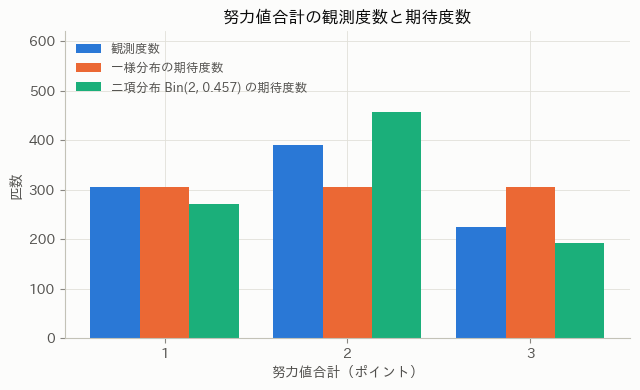

In [98]:
# 適合度 χ² 検定
def pearson_gof(obs, expected):
    """Pearson の適合度統計量 Σ (O - E)² / E."""
    obs, expected = np.asarray(obs, float), np.asarray(expected, float)
    return ((obs - expected) ** 2 / expected).sum()


# (a) タイプ1の18種類は同じ割合か（k = 18, 自由度 17）
obs_t1 = df["タイプ1"].value_counts().to_numpy()
e_t1 = np.full(len(obs_t1), len(df) / len(obs_t1))
chi_t1 = pearson_gof(obs_t1, e_t1)
print(f"(a) タイプ1一様: χ² = {chi_t1:.2f}, 自由度 {len(obs_t1) - 1}, p値 = {stats.chi2.sf(chi_t1, len(obs_t1) - 1):.2e}",
      f"（期待度数 {e_t1[0]:.1f}）")

# (b) 努力値合計 1, 2, 3 は同じ割合か（k = 3, 自由度 2）
obs_ev = df["努力値合計"].value_counts().sort_index().to_numpy()
e_ev_uni = np.full(3, len(df) / 3)
chi_ev_uni = pearson_gof(obs_ev, e_ev_uni)
print(f"(b) 努力値合計一様: χ² = {chi_ev_uni:.2f}, 自由度 2, p値 = {stats.chi2.sf(chi_ev_uni, 2):.2e}")

# (c) 努力値合計 − 1 が二項分布 Bin(2, p) にしたがうか（p を最尤推定するので自由度 k − ℓ − 1 = 3 − 1 − 1 = 1）
y_ev = df["努力値合計"] - 1
p_hat_ev = y_ev.mean() / 2                       # Bin(2, p) の p の最尤推定量 = 標本平均 / 2
e_ev_bin = len(df) * stats.binom.pmf([0, 1, 2], 2, p_hat_ev)
chi_ev_bin = pearson_gof(obs_ev, e_ev_bin)
lib_ev_bin = stats.chisquare(obs_ev, e_ev_bin, ddof=1)
print(f"(c) Bin(2, p) 当てはめ: p̂ = {p_hat_ev:.4f}, 期待度数 {np.round(e_ev_bin, 1)}")
print(f"    χ² = {chi_ev_bin:.2f}, 自由度 1, p値 = {stats.chi2.sf(chi_ev_bin, 1):.2e}",
      f"（scipy ddof=1: {lib_ev_bin.statistic:.2f}, {lib_ev_bin.pvalue:.2e}）")
print(f"    誤って自由度 2 とした場合の p値 = {stats.chi2.sf(chi_ev_bin, 2):.2e}")

fig, ax = plt.subplots(figsize=(6.5, 4))
xpos = np.arange(3)
w = 0.27
ax.bar(xpos - w, obs_ev, width=w, color=PALETTE[0], label="観測度数")
ax.bar(xpos, e_ev_uni, width=w, color=PALETTE[1], label="一様分布の期待度数")
ax.bar(xpos + w, e_ev_bin, width=w, color=PALETTE[2], label=f"二項分布 Bin(2, {p_hat_ev:.3f}) の期待度数")
ax.set_xticks(xpos, ["1", "2", "3"])
ax.set(title="努力値合計の観測度数と期待度数", xlabel="努力値合計（ポイント）", ylabel="匹数", ylim=(0, 620))
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

**結果の読み方**
- (a) タイプ1は期待度数 約51.1 に対して、みず124匹からひこう4匹まで大きくばらつき、$\chi^2\approx324$（自由度17）、p値は $10^{-58}$ 程度。18種類が同じ割合という仮説は明確に棄却される。
- (b) 努力値合計の一様性も $\chi^2\approx44.4$（自由度2）で棄却される。「2」が390匹と最も多い。
- (c) 二項分布 $\mathrm{Bin}(2,\hat p=0.457)$ を当てはめると、期待度数は 約272・457・192 で、観測（305・390・225）より「2」が多すぎ、両端が少なすぎる。$\chi^2\approx19.5$（自由度1）で棄却され、努力値合計は二項分布にもしたがわない。観測度数は二項分布より両端が厚く（分散が大きく）、1匹ずつ独立に「コインを2回投げる」ような仕組みでは説明できない。
- (c) で誤って自由度2を使うと p値が大きく出る（保守的になる）。推定したパラメータの数だけ自由度を減らすことを忘れない。

### 12.4 イエーツの補正

**問い**：ドラゴンを含むポケモンは、そうでないポケモンよりメガシンカ（・ゲンシカイキ）の割合が高いか。

**手法の要点**
- 2×2分割表 $\begin{pmatrix}a&b\\c&d\end{pmatrix}$（$n=a+b+c+d$）の独立性の Pearson $\chi^2$ 統計量は
  $$\chi^2=\frac{n(ad-bc)^2}{(a+b)(c+d)(a+c)(b+d)}\ \approx\ \chi^2(1).$$
- 度数は整数なので統計量は離散的な値しかとらず、度数が小さいと $\chi^2$ 分布による近似で p値が小さく出すぎる。これを補うのが **イエーツの連続補正** で、各セルの $|O-E|$ から0.5を引く。2×2表では
  $$\chi^2_{\text{Yates}}=\frac{n\left(|ad-bc|-n/2\right)^2}{(a+b)(c+d)(a+c)(b+d)}.$$
  統計量が小さくなるので第1種の過誤を犯しにくくなるが、保守的になりすぎて検出力が下がることもある。
- 度数が小さいときは、周辺度数を固定した超幾何分布にもとづく **Fisher の正確検定** も使える。

（→ py 12-4：2×2表、補正なし・イエーツ補正の手計算と scipy の照合、Fisher の正確検定）

In [99]:
# イエーツの補正: 度数の小さい 2×2 分割表（ドラゴンを含むか × メガシンカか）
tab_dm = pd.crosstab(dragon12.rename("ドラゴンを含む"), df["is_mega"].rename("メガシンカ・ゲンシ"))
print(tab_dm)
a, b, c, d = tab_dm.to_numpy().ravel()
n_dm = a + b + c + d
den = (a + b) * (c + d) * (a + c) * (b + d)
chi_raw = n_dm * (a * d - b * c) ** 2 / den
chi_yates = n_dm * (abs(a * d - b * c) - n_dm / 2) ** 2 / den
lib_raw = stats.chi2_contingency(tab_dm, correction=False)
lib_yates = stats.chi2_contingency(tab_dm, correction=True)
fisher = stats.fisher_exact(tab_dm)
print(f"\n期待度数の最小値: {lib_raw.expected_freq.min():.2f}")
pd.DataFrame({
    "χ²（手計算）": [chi_raw, chi_yates, np.nan],
    "χ²（scipy）": [lib_raw.statistic, lib_yates.statistic, np.nan],
    "p値": [lib_raw.pvalue, lib_yates.pvalue, fisher.pvalue],
}, index=["Pearson（補正なし）", "イエーツの補正", "Fisher の正確検定"]).round(4)

メガシンカ・ゲンシ  False  True 
ドラゴンを含む                
False        816     43
True          52      9

期待度数の最小値: 3.45


,χ²（手計算）,χ²（scipy）,p値
Pearson（補正なし）,10.1495,10.1495,0.0014
イエーツの補正,8.4038,8.4038,0.0037
Fisher の正確検定,NaN,NaN,0.0052


**結果の読み方**
- ドラゴンを含む61匹のうち9匹（約15%）がメガシンカ・ゲンシで、それ以外（859匹中43匹、約5%）より多い。期待度数の最小値は約3.45と5を下回る。
- 補正なしの $\chi^2\approx10.15$（p値 約0.0014）が、イエーツの補正で $\chi^2\approx8.40$（p値 約0.0037）に小さくなり、Fisher の正確検定の p値（約0.0052）に近づく。いずれも有意水準5%で有意である。
- メガシンカはゲームの設計上、人気のある一部のポケモン（ドラゴンを含むものが多い）に与えられているので、この関連は「ドラゴンだとメガシンカしやすい」という因果ではなく、選ばれ方の偏りを表している。さらに、9匹のうちメガリザードンX・メガデンリュウ・メガジュカインの3匹は、メガシンカによって初めてドラゴンタイプが加わった行であり、「メガシンカだからドラゴンを含む」という逆向きの関係も混ざっている。

### 12.5 尤度比検定

**問い**：複合タイプの割合は7つの世代で等しいか。

**手法の要点**
- パラメータ $\theta$ のうち一部を制約する帰無仮説 $H_0:\theta\in\Theta_0$ について、**尤度比**
  $$\lambda=\frac{\sup_{\theta\in\Theta}L(\theta)}{\sup_{\theta\in\Theta_0}L(\theta)}\ (\ge1)$$
  を考える。正則条件のもとで、$n$ が大きいとき $H_0$ のもとで
  $$2\log\lambda\ \approx\ \chi^2(q),\qquad q=(\Theta\text{ の次元})-(\Theta_0\text{ の次元}).$$
  （尤度比を $\sup_{\Theta_0}L/\sup_{\Theta}L\le1$ と定義する流儀では $-2\log\lambda$ と書く。）
- **モデル**：世代 $g=1,\dots,7$ の複合タイプの数 $X_g\sim\mathrm{Bin}(n_g,p_g)$、独立。$H_0:p_1=\dots=p_7$。
  - 制約なしの最尤推定値は $\hat p_g=X_g/n_g$、$H_0$ のもとでは共通の $\hat p=\sum X_g/\sum n_g$。
  - $$2\log\lambda=2\sum_{g}\left\{X_g\log\frac{\hat p_g}{\hat p}+(n_g-X_g)\log\frac{1-\hat p_g}{1-\hat p}\right\}=2\sum_{\text{セル}}O\log\frac{O}{E}$$
    で、2×7分割表の $G$ 統計量と一致する。自由度は $7-1=6$。
- Pearson の $\chi^2$ 統計量 $\sum (O-E)^2/E$ は、$2\sum O\log(O/E)$ を $O=E$ のまわりで2次まで展開したものにあたり、$n$ が大きいと両者はほぼ一致する。

（→ py 12-5：対数尤度から $2\log\lambda$ を計算し、scipy の $G$ 統計量・Pearson $\chi^2$ と比較。世代ごとの割合の図）

共通の p̂ = 0.5391, 世代ごとの p̂ = [0.505 0.519 0.512 0.554 0.494 0.616 0.66 ]
2 log λ = 10.8329（scipy G 統計量 10.8329）, 自由度 6, p値 = 0.0937
Pearson χ² = 10.6825, 自由度 6, p値 = 0.0987
χ²(0.05; 6) = 12.592


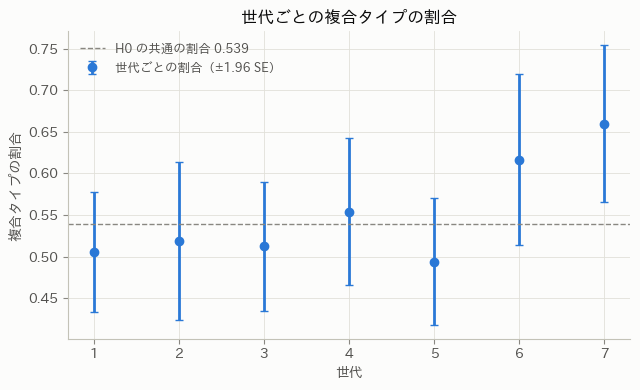

In [100]:
# 尤度比検定: 複合タイプの割合は 7つの世代で等しいか（各世代 X_g ~ Bin(n_g, p_g), H0: p_1 = … = p_7）
x_g = by_gen12["複合タイプ"].to_numpy(float)
n_g = by_gen12["行数"].to_numpy(float)


def binom_loglik(x, n, p):
    """二項分布の対数尤度（二項係数は H0/H1 で共通なので省く）."""
    return (x * np.log(p) + (n - x) * np.log(1 - p)).sum()


p_hat_g = x_g / n_g                       # H1（制約なし）の最尤推定値
p_hat_0 = x_g.sum() / n_g.sum()           # H0（共通の p）の最尤推定値
lr_stat = 2 * (binom_loglik(x_g, n_g, p_hat_g) - binom_loglik(x_g, n_g, p_hat_0))
df_lr = len(x_g) - 1                      # パラメータ数 7 − 1
tab_gen = np.column_stack([x_g, n_g - x_g])
lib_g = stats.chi2_contingency(tab_gen, lambda_="log-likelihood")
lib_p = stats.chi2_contingency(tab_gen)
print(f"共通の p̂ = {p_hat_0:.4f}, 世代ごとの p̂ = {np.round(p_hat_g, 3)}")
print(f"2 log λ = {lr_stat:.4f}（scipy G 統計量 {lib_g.statistic:.4f}）, 自由度 {df_lr}, p値 = {stats.chi2.sf(lr_stat, df_lr):.4f}")
print(f"Pearson χ² = {lib_p.statistic:.4f}, 自由度 {lib_p.dof}, p値 = {lib_p.pvalue:.4f}")
print(f"χ²(0.05; {df_lr}) = {stats.chi2.ppf(0.95, df_lr):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
se_g = np.sqrt(p_hat_g * (1 - p_hat_g) / n_g)
ax.errorbar(by_gen12.index, p_hat_g, yerr=1.96 * se_g, fmt="o", color=PALETTE[0], capsize=3,
            label="世代ごとの割合（±1.96 SE）")
ax.axhline(p_hat_0, color=INK["muted"], linestyle="--", linewidth=1, label=f"H0 の共通の割合 {p_hat_0:.3f}")
ax.set(title="世代ごとの複合タイプの割合", xlabel="世代", ylabel="複合タイプの割合")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

**結果の読み方**
- $2\log\lambda\approx10.83$（scipy の $G$ 統計量と一致）、Pearson $\chi^2\approx10.68$ で、両者はほぼ等しい。自由度6の上側5%点12.59を下回り、p値はそれぞれ約0.094・約0.099。有意水準5%では「7世代で割合が等しい」という仮説は棄却されない。
- 図では第6・7世代の割合（約0.62・0.66）が高めだが、第1〜5世代（約0.49〜0.55）との違いは、7世代をまとめて検定すると偶然のばらつきの範囲と区別できない。12.1 で第1世代と第7世代だけを比べて有意になったのは、結果を見てから両端に近い2群を選んだ効果を含んでいる。

### まとめ

- 複合タイプの割合は全体では1/2より少し高い（約0.54）。世代ごとに見ると第6・7世代で高めだが、7世代をまとめた尤度比検定では有意でない（p値 約0.09）。
- タイプ1の分布は一様からほど遠く、努力値合計は一様にも二項分布にもしたがわない。ドラゴンを含むポケモンはメガシンカの割合が高いが、これはゲームの設計による選ばれ方の偏りである。
- 正規近似・$\chi^2$ 近似は、期待度数（ポアソンなら $\lambda_0$）が小さいと裾の確率を誤りやすい。正確な p値（二項・ポアソン・Fisher）と比べる、イエーツの補正を使う、といった対処がある。
- 適合度検定ではパラメータを推定した数だけ自由度を減らす。多くの群を見てから一部を選んで検定すると、有意になりやすい（多重比較）。

## 第13章 ノンパラメトリック法

### 章の概要

母集団分布を正規分布などの有限個のパラメータで表す（パラメトリック）ことをせず、符号や順位、並べ替えだけを使って検定する方法をまとめる。
中心となる考え方は、帰無仮説のもとでは「符号が $+$ か $-$ か」「どの順位がどちらの群に入るか」が **等確率** になるので、分布の形を仮定しなくても検定統計量の分布が決まる、という点である。
第11章の $t$ 検定や第20章の分散分析に対応する方法があり、外れ値や歪んだ分布に強い代わりに、正規分布が正しいときは検出力がやや下がる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 13.1 | 符号検定 | 攻撃が特攻より高いポケモンの方が多いか |
| 13.2 | ウィルコクソンの符号付き順位検定 | 攻撃 − 特攻 の分布は0について対称か |
| 13.3 | 順位和検定 / マン・ホイットニーの $U$ 検定 | ほのおとみずで合計種族値の分布の位置は違うか |
| 13.4 | 並べ替え検定 | むしとドラゴンで合計種族値の平均は違うか |
| 13.5 | クラスカル・ウォリス検定 | くさ・ほのお・みずで合計種族値の分布は違うか |
| 13.6 | 順位相関係数（スピアマン・ケンドール） | 高さと重さの単調な関係はどれくらい強いか |
| 13.7 | $t$ 検定との比較 | どちらの検定を使うと結論は変わるか。どちらの検出力が高いか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `攻撃`・`特攻` | 量的（整数） | 13.1・13.2 で同じポケモンの差 $D=$ 攻撃 − 特攻 を使う |
| `合計種族値` | 量的（整数） | 13.3〜13.5 の2群・3群の比較 |
| `タイプ1` | 質的（18水準） | ほのお（59）・みず（124）・くさ（83）・むし（78）・ドラゴン（37）の群 |
| `高さ`・`重さ` | 量的（連続、強く右に歪む） | 13.6 の順位相関、13.7 の検出力の比較 |

- **対象の行**：13.1・13.2・13.6 は全920行。群の比較は **`タイプ1` だけで群を作る**。`types_of()` でタイプ2まで数えると、くさとみずを両方もつハスボー・ハスブレロ・ルンパッパ、ほのおとみずを両方もつボルケニオンが2つの群に同時に入り、群どうしが独立でなくなる（同じ値が2回使われる）ためである。なお、旧ノートブックはクラスカル・ウォリス検定で Series を `|` で結合しており、各群のデータを正しく選べていなかった。ここではタイプ1で絞った各群の値の配列をそのまま渡している。
- **加工**：順位は同じ値に平均順位を与える（`scipy.stats.rankdata`）。
- **データの性質と注意点**：種族値は整数なので同順位（タイ）が多い。攻撃と特攻が等しいポケモンは144匹あり、高さ・重さも同じ値が多い（高さは920行で59種類の値しかない）。本来の順位検定の公式はタイがないことを前提にしているので、タイの補正を入れる。全920行を仮想的な母集団からの無作為標本とみなし、同じ進化系統の行が独立でない点は他の章と同じである。

In [101]:
# 使う群はタイプ1で作る（各ポケモンがちょうど1群に入る）
groups13 = {t: df.loc[df["タイプ1"] == t, "合計種族値"].to_numpy(dtype=float)
            for t in ["ほのお", "みず", "くさ", "むし", "ドラゴン"]}
print(pd.DataFrame({t: {"n": len(x), "中央値": np.median(x), "平均": x.mean()} for t, x in groups13.items()}).T)
d13 = (df["攻撃"] - df["特攻"]).to_numpy(dtype=float)
print(f"\n攻撃 − 特攻: 正 {np.sum(d13 > 0)}, 負 {np.sum(d13 < 0)}, 0 {np.sum(d13 == 0)}")
print(f"高さの同じ値の重複 {df['高さ'].duplicated().sum()} 行, 重さの重複 {df['重さ'].duplicated().sum()} 行（タイが多い）")

          n    中央値          平均
ほのお    59.0  480.0  458.745763
みず    124.0  457.0  432.451613
くさ     83.0  425.0  420.000000
むし     78.0  397.5  386.333333
ドラゴン   37.0  600.0  544.081081

攻撃 − 特攻: 正 450, 負 326, 0 144
高さの同じ値の重複 861 行, 重さの重複 468 行（タイが多い）


### 13.1 符号検定

**問い**：攻撃が特攻より高いポケモンと低いポケモンは、同じくらいの割合か。

**手法の要点**
- $Z_i=X_i-Y_i$（対応のある2標本の差）が独立に、連続な分布にしたがうとする。$H_0$：$Z$ の中央値が0、$H_1$：中央値が0でない。
- $Z_i=0$ の組を除き、残りの個数を改めて $n$ とする。$Z_i>0$ の個数 $T$ は $H_0$ のもとで
  $$T\sim\mathrm{Bin}(n,1/2).$$
  $n$ が大きいときは $T\approx N(n/2,\,n/4)$ で近似し、$z=(T-n/2)/\sqrt{n/4}$ とする。
- 符号だけを使うので分布の形の仮定がいらない代わりに、差の大きさの情報を捨てている。

（→ py 13-1：正確な p値と正規近似）

In [102]:
# 符号検定: 攻撃 − 特攻 の中央値は 0 か（0 の行は除く）
d_nz = d13[d13 != 0]
n_sign = len(d_nz)
t_plus = int(np.sum(d_nz > 0))
p_sign_exact = stats.binomtest(t_plus, n_sign, 0.5).pvalue
z_sign = (t_plus - n_sign / 2) / np.sqrt(n_sign / 4)       # Bin(n, 1/2) ≈ N(n/2, n/4)
p_sign_z = 2 * stats.norm.sf(abs(z_sign))
print(f"0 を除いた n = {n_sign}, 正の個数 T = {t_plus}（期待値 {n_sign / 2}）")
print(f"正確な p値（二項分布）= {p_sign_exact:.3g}")
print(f"正規近似: z = {z_sign:.4f}, p値 = {p_sign_z:.3g}")

0 を除いた n = 776, 正の個数 T = 450（期待値 388.0）
正確な p値（二項分布）= 9.68e-06
正規近似: z = 4.4513, p値 = 8.53e-06


**結果の読み方**
- 0を除いた776匹のうち、攻撃の方が高いのは450匹（期待値388）。二項分布による正確な p値は約 $1\times10^{-5}$、正規近似（$z\approx4.45$）でもほぼ同じで、有意水準5%で $H_0$ は棄却される。攻撃が特攻より高いポケモンの方が多い。
- 攻撃と特攻が等しい144匹を除いたことで、検定は「差がある776匹のうちどちらが多いか」についての結論になる。

### 13.2 ウィルコクソンの符号付き順位検定

**問い**：攻撃 − 特攻 の分布は0を中心に対称か（差の大きさも考慮して）。

**手法の要点**
- 符号検定の仮定に加えて、$Z$ の分布が中央値について対称であることを仮定する。$H_0$：対称の中心が0。
- 0を除いた $n$ 個の $|Z_i|$ に小さい順に順位 $R_i$ をつけ、$Z_i>0$ のものの順位和 $T^+=\sum_{Z_i>0}R_i$ を統計量とする（$T^++T^-=n(n+1)/2$）。
- $H_0$ のもとでは各順位が確率1/2で $+$ か $-$ になるので、$2^n$ 通りが等確率で
  $$E[T^+]=\frac{n(n+1)}{4},\qquad V[T^+]=\frac{n(n+1)(2n+1)}{24}.$$
  $n$ が大きいとき $z=(T^+-E[T^+])/\sqrt{V[T^+]}\approx N(0,1)$。同じ $|Z|$ の値が $t_j$ 個ずつあるときは、$V[T^+]$ から $\sum_j(t_j^3-t_j)/48$ を引く（タイの補正）。

（→ py 13-2：$T^+$ と $z$ を手計算し、`scipy.stats.wilcoxon` と照合）

In [103]:
# ウィルコクソンの符号付き順位検定: 攻撃 − 特攻 の分布は 0 について対称か
abs_rank = stats.rankdata(np.abs(d_nz))                   # 同順位は平均順位
T_plus = abs_rank[d_nz > 0].sum()
T_minus = abs_rank[d_nz < 0].sum()
E_T = n_sign * (n_sign + 1) / 4
_, tie_cnt = np.unique(np.abs(d_nz), return_counts=True)
V_T = n_sign * (n_sign + 1) * (2 * n_sign + 1) / 24 - (tie_cnt**3 - tie_cnt).sum() / 48   # タイの補正
z_sr = (T_plus - E_T) / np.sqrt(V_T)
p_sr = 2 * stats.norm.sf(abs(z_sr))
lib_sr = stats.wilcoxon(d13, zero_method="wilcox", correction=False, method="approx")
print(f"T+ = {T_plus:.1f}, T− = {T_minus:.1f}, T+ + T− = n(n+1)/2 = {n_sign * (n_sign + 1) / 2:.0f}")
print(f"E[T+] = {E_T:.1f}, V[T+] = {V_T:.1f}（タイ補正なし {n_sign * (n_sign + 1) * (2 * n_sign + 1) / 24:.1f}）")
print(f"手計算: z = {z_sr:.4f}, p値 = {p_sr:.3g}")
print(f"scipy : 統計量 min(T+, T−) = {lib_sr.statistic:.1f}, p値 = {lib_sr.pvalue:.3g}")

T+ = 184442.5, T− = 117033.5, T+ + T− = n(n+1)/2 = 301476
E[T+] = 150738.0, V[T+] = 38987752.6（タイ補正なし 39016019.0）
手計算: z = 5.3979, p値 = 6.74e-08
scipy : 統計量 min(T+, T−) = 117033.5, p値 = 6.74e-08


**結果の読み方**
- $T^+\approx184443$、$T^-\approx117034$ で、$E[T^+]\approx150738$ を大きく上回る。$z\approx5.40$、p値 約 $7\times10^{-8}$ で、有意水準5%で $H_0$ は棄却される。
- 手計算（タイ補正つき）の p値は scipy と一致する。scipy は統計量として $\min(T^+,T^-)$ を表示するが、$z$ の絶対値は同じである。
- 符号検定より p値が小さいのは、攻撃が高い側の差の方が大きい（順位が高い）ことも使っているためである。

### 13.3 ウィルコクソンの順位和検定 / マン・ホイットニーの $U$ 検定

**問い**：ほのお（タイプ1）とみず（タイプ1）で、合計種族値の分布の位置は異なるか。

**手法の要点**
- 独立な2標本 $X_1,\dots,X_m\sim F$、$Y_1,\dots,Y_n\sim G$（連続）。$H_0:F=G$、$H_1:F(x)=G(x-\delta)$、$\delta\neq0$（分布の形は同じで位置だけずれる）。
- **順位和 $W$**：2群をまとめて $N=m+n$ 個に順位をつけ、$X$ 側の順位和を $W$ とする。$H_0$ のもとで、$X$ 側の順位は $\{1,\dots,N\}$ から $m$ 個を無作為に選んだものになるので
  $$E[W]=\frac{m(N+1)}{2},\qquad V[W]=\frac{mn(N+1)}{12}.$$
- **マン・ホイットニーの $U$**：$X_i>Y_j$ となる組 $(i,j)$ の数（同点は1/2と数える）。$W$ とは
  $$U=W-\frac{m(m+1)}{2}$$
  の関係があり（$X$ 側の $k$ 番目に小さい値の順位から $k$ を引くと、それより小さい $Y$ の個数になるため）、2つの検定は同じものである。$E[U]=mn/2$、$V[U]=V[W]$。
- タイがあるときは $V[W]=\frac{mn}{12}\left\{(N+1)-\frac{\sum_j(t_j^3-t_j)}{N(N-1)}\right\}$ とする。

（→ py 13-3：$W$、$U$（公式と、組を直接数えた値）、$z$ を手計算し、`scipy.stats.mannwhitneyu` と照合）

In [104]:
# ウィルコクソンの順位和検定 / マン・ホイットニーの U 検定: ほのお vs みず の合計種族値
x_f, x_w = groups13["ほのお"], groups13["みず"]
m_f, n_w = len(x_f), len(x_w)
N_fw = m_f + n_w
r_all = stats.rankdata(np.concatenate([x_f, x_w]))
W_f = r_all[:m_f].sum()                                   # ほのおの順位和
U_f = W_f - m_f * (m_f + 1) / 2                           # U = W − m(m+1)/2（ほのお > みず となる組の数、同点は 1/2）
U_pairs = (x_f[:, None] > x_w[None, :]).sum() + 0.5 * (x_f[:, None] == x_w[None, :]).sum()
E_W = m_f * (N_fw + 1) / 2
_, tc = np.unique(np.concatenate([x_f, x_w]), return_counts=True)
V_W = m_f * n_w / 12 * ((N_fw + 1) - (tc**3 - tc).sum() / (N_fw * (N_fw - 1)))   # タイの補正つき
z_rs = (W_f - E_W) / np.sqrt(V_W)
p_rs = 2 * stats.norm.sf(abs(z_rs))
lib_mw = stats.mannwhitneyu(x_f, x_w, use_continuity=False, method="asymptotic")
print(f"W（ほのおの順位和）= {W_f:.1f}, U = W − m(m+1)/2 = {U_f:.1f}, 組を数えた U = {U_pairs:.1f}")
print(f"E[W] = {E_W:.1f}, V[W] = {V_W:.1f}（E[U] = mn/2 = {m_f * n_w / 2:.1f}）")
print(f"手計算: z = {z_rs:.4f}, p値 = {p_rs:.4f}")
print(f"scipy mannwhitneyu: U = {lib_mw.statistic:.1f}, p値 = {lib_mw.pvalue:.4f}")
print(f"参考 Welch の t 検定: p値 = {stats.ttest_ind(x_f, x_w, equal_var=False).pvalue:.4f}")

W（ほのおの順位和）= 5942.5, U = W − m(m+1)/2 = 4172.5, 組を数えた U = 4172.5
E[W] = 5428.0, V[W] = 112130.5（E[U] = mn/2 = 3658.0）
手計算: z = 1.5365, p値 = 0.1244
scipy mannwhitneyu: U = 4172.5, p値 = 0.1244
参考 Welch の t 検定: p値 = 0.1305


**結果の読み方**
- ほのおの順位和 $W=5942.5$ から $U=W-59\cdot60/2=4172.5$ となり、組を直接数えた値と一致する。$E[U]=3658$ より大きいので、ほのおの方がやや上位に来やすい。
- $z\approx1.54$、p値 約0.12 で、有意水準5%では $H_0$ は棄却されない。Welch の $t$ 検定（p値 約0.13）と同じ結論である。

### 13.4 並べ替え検定

**問い**：むし（タイプ1、78匹）とドラゴン（タイプ1、37匹）で、合計種族値の平均は異なるか。

**手法の要点**
- $H_0$：2群の母集団分布は同じ。$H_0$ のもとでは、観測された $N$ 個の値のうちどれがどちらの群に属するかは任意なので、群のラベルをランダムに付け替えても統計量の分布は変わらない。
- 統計量 $T$（ここでは平均の差 $\bar X_{\text{ドラゴン}}-\bar X_{\text{むし}}$）について、ラベルの付け替えを $B$ 回繰り返して並べ替え分布を作り、
  $$p=\frac{\#\{|T^*|\ge|T_{\text{obs}}|\}+1}{B+1}$$
  を p値とする（観測値そのものも1つの並べ替えとして数える）。全 $\binom{N}{m}$ 通りを数え上げれば正確な検定になる。
- 分布の形を仮定しない。平均の差を使うので、外れ値の影響は $t$ 検定と同程度に受ける。

（→ py 13-4：10000回の並べ替え、`scipy.stats.permutation_test` との比較、並べ替え分布の図）

むし n=78 平均 386.3, ドラゴン n=37 平均 544.1, 差 157.7
並べ替えで |差| ≥ 観測値 となった回数: 0 / 10000
並べ替え検定の p値 = 1.00e-04（scipy permutation_test 2.00e-04）
参考 Welch の t 検定 p値 = 3.83e-07, マン・ホイットニー p値 = 8.94e-07


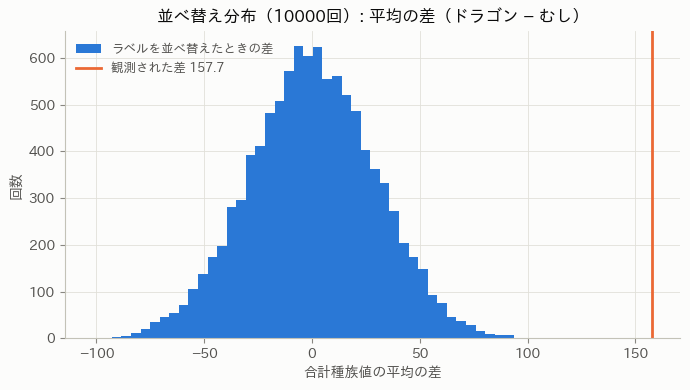

In [105]:
# 並べ替え検定: むし vs ドラゴン の合計種族値の平均の差
x_b, x_d = groups13["むし"], groups13["ドラゴン"]
pooled_bd = np.concatenate([x_b, x_d])
obs_diff = x_d.mean() - x_b.mean()
rng = get_rng()
B = 10000
perm_diff = np.empty(B)
for i in range(B):
    perm = rng.permutation(pooled_bd)                      # 群のラベルをランダムに付け替える
    perm_diff[i] = perm[len(x_b):].mean() - perm[:len(x_b)].mean()
p_perm = (np.sum(np.abs(perm_diff) >= abs(obs_diff)) + 1) / (B + 1)
lib_perm = stats.permutation_test((x_d, x_b), lambda a, b: a.mean() - b.mean(), n_resamples=B,
                                  random_state=SEED)
print(f"むし n={len(x_b)} 平均 {x_b.mean():.1f}, ドラゴン n={len(x_d)} 平均 {x_d.mean():.1f}, 差 {obs_diff:.1f}")
print(f"並べ替えで |差| ≥ 観測値 となった回数: {np.sum(np.abs(perm_diff) >= abs(obs_diff))} / {B}")
print(f"並べ替え検定の p値 = {p_perm:.2e}（scipy permutation_test {lib_perm.pvalue:.2e}）")
print(f"参考 Welch の t 検定 p値 = {stats.ttest_ind(x_d, x_b, equal_var=False).pvalue:.2e}, "
      f"マン・ホイットニー p値 = {stats.mannwhitneyu(x_d, x_b).pvalue:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_diff, bins=50, color=PALETTE[0], label="ラベルを並べ替えたときの差")
ax.axvline(obs_diff, color=PALETTE[1], linewidth=2, label=f"観測された差 {obs_diff:.1f}")
ax.set(title=f"並べ替え分布（{B}回）: 平均の差（ドラゴン − むし）", xlabel="合計種族値の平均の差", ylabel="回数")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

**結果の読み方**
- 平均の差は約158（むし 約386、ドラゴン 約544）。10000回の並べ替えで観測値以上に極端な差は一度も出ず、p値は $1/(B+1)\approx10^{-4}$ 以下である（scipy は両側 p値を片側の2倍で計算するため 約 $2\times10^{-4}$ と表示される。どちらも $B$ で決まる下限の値）。
- 並べ替え分布はほぼ0を中心とした釣鐘形で、観測値はその裾のはるか外にある。Welch の $t$ 検定（p値 約 $4\times10^{-7}$）、マン・ホイットニー（約 $9\times10^{-7}$）とも同じ結論である。より小さな p値を並べ替えで示すには $B$ を大きくする必要がある。

### 13.5 クラスカル・ウォリス検定

**問い**：くさ・ほのお・みず（タイプ1）で、合計種族値の分布は異なるか。

**手法の要点**
- 独立な $k$ 群、$H_0$：すべての群の分布が等しい、$H_1$：少なくとも1つの群の分布が異なる。一元配置分散分析の順位版である。
- 全 $N=\sum n_i$ 個に順位をつけ、群 $i$ の順位和を $R_i$、平均順位を $\bar R_i=R_i/n_i$ とすると
  $$H=\frac{12}{N(N+1)}\sum_{i=1}^{k}n_i\left(\bar R_i-\frac{N+1}{2}\right)^2=\frac{12}{N(N+1)}\sum_{i=1}^{k}\frac{R_i^2}{n_i}-3(N+1).$$
  $H_0$ のもとで、各群の大きさが十分大きければ $H\approx\chi^2(k-1)$。タイがあるときは $H$ を $1-\sum_j(t_j^3-t_j)/(N^3-N)$ で割る。
- **群の作り方**：くさ・ほのお・みずを **タイプ1** で選ぶ。タイプ2まで含めると、ハスボー系3匹がくさとみずの両方、ボルケニオンがほのおとみずの両方に入り、同じポケモンが2群に重複して「独立な $k$ 群」の前提が崩れる。タイプ1で分ければ各ポケモンはちょうど1群に入る（その代わり、タイプ2がくさ・ほのお・みずのポケモンは対象外になる）。

（→ py 13-5：重複所属の確認、$H$ の手計算と `scipy.stats.kruskal` の照合、分散分析との比較、箱ひげ図）

くさ と ほのお を両方もつ: []
くさ と みず を両方もつ: ['ハスボー', 'ハスブレロ', 'ルンパッパ']
ほのお と みず を両方もつ: ['ボルケニオン']
→ 各群をタイプ1だけで作り、1匹が1群にだけ入るようにする

群ごとの平均順位: {'くさ': 123.6, 'ほのお': 150.9, 'みず': 131.9}
H（補正前）= 4.4316, H（タイ補正）= 4.4337, 自由度 2, p値 = 0.1089
scipy kruskal: H = 4.4337, p値 = 0.1089
参考 一元配置分散分析: F = 2.1124, p値 = 0.1230


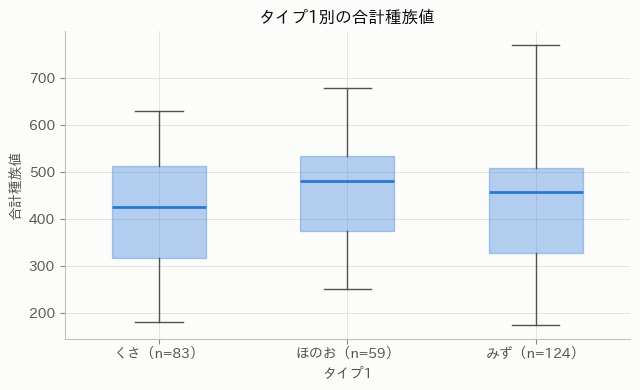

In [106]:
# クラスカル・ウォリス検定: くさ・ほのお・みず（タイプ1）の合計種族値
kw_types = ["くさ", "ほのお", "みず"]
kw_data = [groups13[t] for t in kw_types]
# タイプ2まで数えると重複所属が生じることの確認
for t1, t2 in [("くさ", "ほのお"), ("くさ", "みず"), ("ほのお", "みず")]:
    both = types_of(df, t1) & types_of(df, t2)
    print(f"{t1} と {t2} を両方もつ: {df.loc[both, '名前'].tolist()}")
print("→ 各群をタイプ1だけで作り、1匹が1群にだけ入るようにする\n")

x_kw = np.concatenate(kw_data)
N_kw = len(x_kw)
r_kw = stats.rankdata(x_kw)
bounds = np.cumsum([0] + [len(x) for x in kw_data])
R_i = np.array([r_kw[bounds[i]:bounds[i + 1]].sum() for i in range(len(kw_data))])
n_i = np.array([len(x) for x in kw_data])
H_raw = 12 / (N_kw * (N_kw + 1)) * np.sum(R_i**2 / n_i) - 3 * (N_kw + 1)
_, tk = np.unique(x_kw, return_counts=True)
H = H_raw / (1 - (tk**3 - tk).sum() / (N_kw**3 - N_kw))                  # タイの補正
lib_kw = stats.kruskal(*kw_data)
lib_anova = stats.f_oneway(*kw_data)
print("群ごとの平均順位:", dict(zip(kw_types, np.round(R_i / n_i, 1))))
print(f"H（補正前）= {H_raw:.4f}, H（タイ補正）= {H:.4f}, 自由度 {len(kw_data) - 1}, p値 = {stats.chi2.sf(H, len(kw_data) - 1):.4f}")
print(f"scipy kruskal: H = {lib_kw.statistic:.4f}, p値 = {lib_kw.pvalue:.4f}")
print(f"参考 一元配置分散分析: F = {lib_anova.statistic:.4f}, p値 = {lib_anova.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot(kw_data, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=PALETTE[0], alpha=0.35, edgecolor=PALETTE[0]),
           medianprops=dict(color=PALETTE[0], linewidth=2), whiskerprops=dict(color=INK["secondary"]),
           capprops=dict(color=INK["secondary"]), flierprops=dict(markeredgecolor=INK["muted"]))
ax.set_xticks(range(1, len(kw_types) + 1), [f"{t}（n={len(x)}）" for t, x in zip(kw_types, kw_data)])
ax.set(title="タイプ1別の合計種族値", xlabel="タイプ1", ylabel="合計種族値")
fig.tight_layout()
plt.show()

**結果の読み方**
- 平均順位は くさ 約124、みず 約132、ほのお 約151 で、ほのおがやや高い。$H\approx4.43$（自由度2、タイ補正はわずか）、p値 約0.11 で、有意水準5%では $H_0$ は棄却されない。一元配置分散分析（$F\approx2.11$、p値 約0.12）と同じ結論である。
- 手計算の $H$ は scipy と一致する。

### 13.6 順位相関係数

**問い**：高さと重さの関係の強さは、ピアソンの相関係数と順位相関係数でどう違うか。

**手法の要点**
- **スピアマンの順位相関係数** $r_s$：$x,y$ をそれぞれ順位 $R_i,S_i$ に置き換えて計算したピアソンの相関係数。タイがなければ、$d_i=R_i-S_i$ として
  $$r_s=1-\frac{6\sum_{i}d_i^2}{n(n^2-1)}$$
  と書ける（順位の平均が $(n+1)/2$、分散が $(n^2-1)/12$ になることから導かれる）。
- **ケンドールの順位相関係数** $\tau$：$n(n-1)/2$ 組 $(i,j)$ のうち、$(x_i-x_j)(y_i-y_j)>0$ となる一致の組の数を $P$、$<0$ となる不一致の組の数を $N$ として
  $$\tau_a=\frac{P-N}{n(n-1)/2}.$$
  タイがあるときは、$x$ でタイになっていない組の数を $n_x$、$y$ でタイになっていない組の数を $n_y$ として $\tau_b=(P-N)/\sqrt{n_xn_y}$ を使う（scipy の既定値）。
- どちらも **単調な関係** の強さを測り、順位しか使わないので外れ値や変数の単調変換（対数など）の影響を受けない。ピアソンの相関係数は **直線的な関係** の強さを測り、外れ値に敏感である。

（→ py 13-6：4種類の相関係数、公式と scipy の照合、重さの上位5匹を除いた場合、散布図）

ピアソン（そのまま）: 0.6573  ピアソン（両対数）: 0.8192
スピアマン: 順位の相関 0.8447 / 1−6Σd²/(n(n²−1)) 0.8449 / scipy 0.8447
ケンドール: 一致 P = 343522, 不一致 N = 57780, 組数 422740
  τ_a = 0.6759, τ_b = 0.6939, scipy（τ_b）= 0.6939, p値 = 1.55e-207
重さ上位5匹 ['メガメタグロス', 'グラードン', 'ゲンシグラードン', 'コスモウム', 'テッカグヤ'] を除くと: ピアソン 0.6975, スピアマン 0.8488


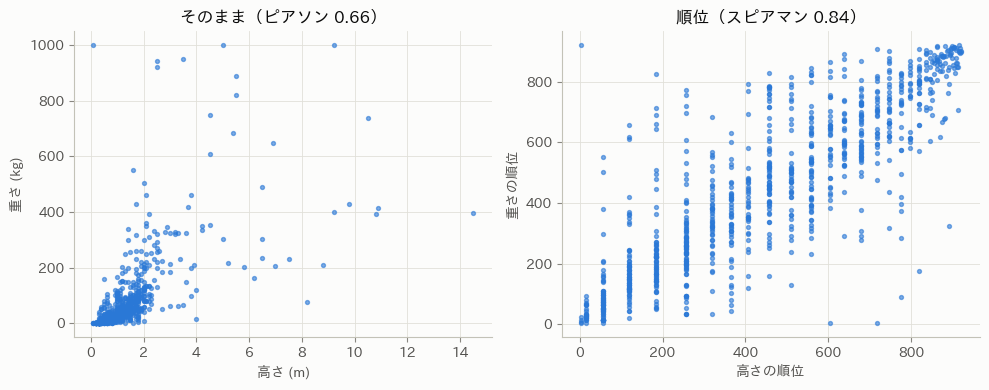

In [107]:
# 順位相関係数: 高さと重さ
h, w = df["高さ"].to_numpy(float), df["重さ"].to_numpy(float)
n_hw = len(h)
rh, rw = stats.rankdata(h), stats.rankdata(w)
r_pearson = np.corrcoef(h, w)[0, 1]
r_pearson_log = np.corrcoef(np.log(h), np.log(w))[0, 1]
rs_rank = np.corrcoef(rh, rw)[0, 1]                           # 順位のピアソン相関 = スピアマン
rs_formula = 1 - 6 * np.sum((rh - rw) ** 2) / (n_hw * (n_hw**2 - 1))   # タイがないときの公式
# ケンドール: 全 n(n-1)/2 組の符号の一致・不一致を数える
iu = np.triu_indices(n_hw, k=1)
sh = np.sign(h[:, None] - h[None, :])[iu]
sw = np.sign(w[:, None] - w[None, :])[iu]
P_c, N_d = np.sum(sh * sw > 0), np.sum(sh * sw < 0)
n_pair = n_hw * (n_hw - 1) / 2
tau_a = (P_c - N_d) / n_pair
tau_b = (P_c - N_d) / np.sqrt(float(np.sum(sh != 0)) * float(np.sum(sw != 0)))   # タイの補正（int32 の桁あふれを避ける）
lib_sp = stats.spearmanr(h, w)
lib_kt = stats.kendalltau(h, w)
print(f"ピアソン（そのまま）: {r_pearson:.4f}  ピアソン（両対数）: {r_pearson_log:.4f}")
print(f"スピアマン: 順位の相関 {rs_rank:.4f} / 1−6Σd²/(n(n²−1)) {rs_formula:.4f} / scipy {lib_sp.statistic:.4f}")
print(f"ケンドール: 一致 P = {P_c}, 不一致 N = {N_d}, 組数 {n_pair:.0f}")
print(f"  τ_a = {tau_a:.4f}, τ_b = {tau_b:.4f}, scipy（τ_b）= {lib_kt.statistic:.4f}, p値 = {lib_kt.pvalue:.2e}")
# 外れ値の影響: 重さ上位5匹を除いたとき
top5 = np.argsort(w)[-5:]
keep = np.setdiff1d(np.arange(n_hw), top5)
print(f"重さ上位5匹 {df['名前'].iloc[top5].tolist()} を除くと: "
      f"ピアソン {np.corrcoef(h[keep], w[keep])[0, 1]:.4f}, スピアマン {stats.spearmanr(h[keep], w[keep]).statistic:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(h, w, s=8, color=PALETTE[0], alpha=0.6)
axes[0].set(title=f"そのまま（ピアソン {r_pearson:.2f}）", xlabel="高さ (m)", ylabel="重さ (kg)")
axes[1].scatter(rh, rw, s=8, color=PALETTE[0], alpha=0.6)
axes[1].set(title=f"順位（スピアマン {lib_sp.statistic:.2f}）", xlabel="高さの順位", ylabel="重さの順位")
fig.tight_layout()
plt.show()

**結果の読み方**
- ピアソンの相関係数はそのままでは約0.66だが、両対数にすると約0.82に上がる。高さと重さの関係は直線ではなく、強く右に歪んだ分布の一部の大きなポケモンに引っ張られているためである。
- スピアマンは約0.84、ケンドールは $\tau_b\approx0.69$（$\tau_a\approx0.68$）。順位を使うので、対数変換してもしなくても同じ値になる。スピアマンの公式 $1-6\sum d^2/\{n(n^2-1)\}$の値（0.8449）は、タイが多いため順位の相関（0.8447）とわずかにずれる。$\tau$ と $r_s$ は尺度が違い、多くの場合 $|\tau|$ の方が小さい値になる。
- 重さの上位5匹（メガメタグロス、グラードン、ゲンシグラードン、コスモウム、テッカグヤ）を除くと、ピアソンは約0.66から約0.70へ変わるが、スピアマンは約0.84から約0.85とほとんど変わらない。

### 13.7 $t$ 検定との比較

**問い**：同じデータにパラメトリック検定とノンパラメトリック検定を使うと、結論は変わるか。小標本では、どちらの検出力が高いか。

**手法の要点**
- 対応関係：対応のある $t$ 検定 ↔ 符号検定・符号付き順位検定、2標本 $t$ 検定 ↔ 順位和検定（マン・ホイットニー）・並べ替え検定、一元配置分散分析 ↔ クラスカル・ウォリス検定、ピアソンの相関係数 ↔ スピアマン・ケンドールの順位相関係数。
- 母集団が正規分布なら $t$ 検定が最も検出力が高いが、順位和検定の漸近相対効率は $3/\pi\approx0.955$ で、損失は小さい。裾の重い分布や歪んだ分布では、順位検定の方が検出力が高くなることがある。
- むしとドラゴン（タイプ1）から各 $n=8$ を復元抽出し、Welch の $t$ 検定とマン・ホイットニー検定（両側5%）の検出力を2000回のシミュレーションで比べる。変数は、ほぼ左右対称な合計種族値と、強く右に歪んだ重さの2つ。

（→ py 13-7：同じデータでの p値の比較表と、検出力のシミュレーション）

In [108]:
# t 検定との比較: 同じデータへの適用と、小標本での検出力のシミュレーション
compare13 = pd.DataFrame({
    "パラメトリック": [stats.ttest_rel(df["攻撃"], df["特攻"]).pvalue,
                  stats.ttest_ind(x_f, x_w, equal_var=False).pvalue,
                  stats.f_oneway(*kw_data).pvalue],
    "ノンパラメトリック": [lib_sr.pvalue, lib_mw.pvalue, lib_kw.pvalue],
}, index=["攻撃 vs 特攻（対応あり t / 符号付き順位）", "ほのお vs みず（Welch t / マン・ホイットニー）",
          "くさ・ほのお・みず（分散分析 / クラスカル・ウォリス）"])
print(compare13.to_string(float_format=lambda v: f"{v:.3g}"))

# 検出力: むし と ドラゴン（タイプ1）から各 n=8 を復元抽出, 両側5%（合計種族値 と 右に歪んだ重さ）
rng = get_rng()
reps13, n_sim = 2000, 8
rows_pw13 = []
for col in ["合計種族値", "重さ"]:
    pop_b = df.loc[df["タイプ1"] == "むし", col].to_numpy(float)
    pop_d = df.loc[df["タイプ1"] == "ドラゴン", col].to_numpy(float)
    sb = rng.choice(pop_b, size=(reps13, n_sim))
    sd = rng.choice(pop_d, size=(reps13, n_sim))
    rows_pw13.append({"変数": col, "むしの歪度": stats.skew(pop_b), "ドラゴンの歪度": stats.skew(pop_d),
                      "Welch t の検出力": np.mean(stats.ttest_ind(sd, sb, axis=1, equal_var=False).pvalue < 0.05),
                      "マン・ホイットニーの検出力": np.mean(stats.mannwhitneyu(sd, sb, axis=1).pvalue < 0.05)})
pd.DataFrame(rows_pw13).round(3)

                                パラメトリック  ノンパラメトリック
攻撃 vs 特攻（対応あり t / 符号付き順位）      2.47e-08   6.74e-08
ほのお vs みず（Welch t / マン・ホイットニー）     0.13      0.124
くさ・ほのお・みず（分散分析 / クラスカル・ウォリス）      0.123      0.109


,変数,むしの歪度,ドラゴンの歪度,Welch t の検出力,マン・ホイットニーの検出力
0,合計種族値,-0.089,-0.403,0.554,0.470
1,重さ,3.420,1.455,0.336,0.512


**結果の読み方**
- この章の3つの比較では、パラメトリックとノンパラメトリックの p値は近く、有意水準5%での結論は変わらない（攻撃 vs 特攻は両方で有意、ほのお vs みず・3タイプの比較は両方で有意でない）。
- 合計種族値（ほぼ左右対称）では、Welch の $t$ 検定の検出力（約0.55）がマン・ホイットニー（約0.47）より高い。左右対称で裾の軽い分布では、平均を使う $t$ 検定の方が情報を効率よく使える。
- 重さ（むしの歪度 約3.4）では逆に、マン・ホイットニーの検出力（約0.51）が $t$ 検定（約0.34）を大きく上回る。歪んだ分布では、少数の大きな値が標本分散を膨らませ、$t$ 統計量を小さくしてしまうためである。

### まとめ

- 攻撃が特攻より高いポケモンの方が多く（776匹中450匹）、差の大きさまで含めても攻撃が高い側に偏っている。ほのお・みず・くさの合計種族値の分布の違いは、順位検定でも有意でない。むしとドラゴンの差は、並べ替え検定で見ても明らかである。
- 高さと重さは、ピアソンの相関係数（約0.66）で見るより強い単調な関係（スピアマン約0.84）がある。歪んだ変数の関係は、対数変換するか順位相関で測るのがよい。
- ノンパラメトリック法は分布の形を仮定しない代わりに、「独立な標本」「タイの扱い」には注意が要る。群を作るときは1匹が2群に入らないようにする（ここではタイプ1で分けた）。
- 左右対称な分布では $t$ 検定がやや有利、歪んだ分布では順位検定が有利である。どちらを使うかは、データを見る前に分布の形の見込みから決めるべきで、両方を試して都合のよい方を選ぶのは避ける。

## 第16章 重回帰分析

### 章の概要

1つの量的な目的変数を、複数の説明変数の一次式で表す **線形回帰モデル** を扱う。
- 目的：目的変数の変動を説明変数でどれだけ説明できるかを測り、各説明変数の寄与（他の変数を固定したときの効果）を推定・検定する。
- 考え方：誤差平方和を最小にする最小二乗法で係数を求め、誤差に正規分布を仮定して $t$ 検定・$F$ 検定を行う。
- つながり：第3章の相関係数（2変数の直線的な関係）を、1つの目的変数と複数の説明変数の関係に拡張したもの。第17章でモデルの前提を診断し、第18章で目的変数が質的な場合へ、第30章でどの説明変数を使うか（モデル選択）へ進む。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 16.1 | 最小二乗法（正規方程式） | 経験値を種族値6項目で表すと係数はいくつか |
| 16.2 | 単回帰と係数の $t$ 検定 | 重さは高さの3乗に比例する（体積則）か |
| 16.3 | 決定係数・$F$ 検定 | 6項目は経験値をどれだけ説明するか。6項目を別々に扱う意味はあるか |
| 16.4 | 多重共線性（VIF） | 説明変数どうしの相関は推定を不安定にしているか |
| 16.5 | 一般化最小二乗法（WLS） | 誤差の分散が一定でないとき、推定はどう変わるか |
| 16.6 | 正則化（Ridge・Lasso・Elastic Net） | 係数を縮小すると、どの変数が最後まで残るか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `経験値` | 量的 | 16.1・16.3〜16.6 の目的変数（倒したときの基礎経験値） |
| `HP`〜`素早` | 量的 | 種族値6項目。説明変数 |
| `合計種族値` | 量的 | 6項目の和。16.3 の制約つきモデル、16.4 の完全共線性の例 |
| `捕獲率` | 量的（3〜255） | 16.4・16.6 で説明変数に追加 |
| `log高さ`, `log重さ` | 量的 | 16.2 の単回帰。16.4・16.6 でも使う |

- **対象の行**：全920行（メガシンカ・姿違いを含む）。
- **加工**：高さ・重さは自然対数をとる（強く右に歪んでいるため）。16.6 では説明変数・目的変数を標準化する。
- **データの性質と注意点**：全ポケモンを「仮想的な母集団からの標本」とみなして検定する。同じ進化系統やメガシンカ前後の行は似た値をもち、誤差の独立性は厳密には成り立たない。経験値にはハピナス（608）・ラッキー・タブンネのように種族値のわりに極端に大きい値がある（第17章で詳しく診断する）。

In [109]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, lasso_path, enet_path

cols16 = ["経験値", "合計種族値", *STATS, "捕獲率", "log高さ", "log重さ"]
print(f"行数: {len(df)}")
df[cols16].describe().T[["mean", "std", "min", "max"]].round(2)

行数: 920


,mean,std,min,max
経験値,153.66,79.14,36.0,608.00
合計種族値,438.47,120.33,175.0,780.00
HP,69.56,26.03,1.0,255.00
攻撃,80.07,32.54,5.0,190.00
防御,74.56,31.22,5.0,230.00
特攻,73.32,33.22,10.0,194.00
特防,72.40,27.90,20.0,230.00
素早,68.55,29.42,5.0,180.00
捕獲率,93.98,75.55,3.0,255.00
log高さ,-0.06,0.74,-2.3,2.67


### 16.1 最小二乗法

**問い**：経験値 $y$ を種族値6項目 $x_1,\dots,x_6$ の一次式 $y=\beta_0+\beta_1x_1+\dots+\beta_6x_6+\varepsilon$ で表すと、係数はいくつか。

**手法の要点**
- $n$ 個の観測をまとめて $\boldsymbol y = X\boldsymbol\beta + \boldsymbol\varepsilon$ と書く。$X$ は先頭列が1の $n\times(d+1)$ 行列（ここでは $d=6$）。
- 残差平方和 $(\boldsymbol y - X\boldsymbol\beta)^\top(\boldsymbol y - X\boldsymbol\beta)$ を $\boldsymbol\beta$ で微分して0とおくと **正規方程式** $X^\top X\boldsymbol\beta = X^\top\boldsymbol y$ を得る。$X^\top X$ が正則なら
$$\hat{\boldsymbol\beta} = (X^\top X)^{-1}X^\top\boldsymbol y .$$
- $E[\boldsymbol\varepsilon]=\boldsymbol 0$ なら $\hat{\boldsymbol\beta}$ は不偏。さらに $V[\boldsymbol\varepsilon]=\sigma^2 I$ なら $V[\hat{\boldsymbol\beta}]=\sigma^2(X^\top X)^{-1}$ で、線形不偏推定量の中で分散が最小（ガウス・マルコフの定理、BLUE）。
- 残差 $\boldsymbol e=\boldsymbol y-X\hat{\boldsymbol\beta}$ の自由度は $n-d-1$ で、$s^2=\boldsymbol e^\top\boldsymbol e/(n-d-1)$ が $\sigma^2$ の不偏推定量。係数の標準誤差は $s^2(X^\top X)^{-1}$ の対角成分の平方根。

（→ py 16-1：正規方程式を `np.linalg.solve` で解き、statsmodels の結果と照合する）

In [110]:
# 正規方程式 (X^T X) beta = X^T y を numpy で解き、statsmodels と照合する
y16 = df["経験値"].to_numpy(float)
X16 = np.column_stack([np.ones(len(df)), df[STATS].to_numpy(float)])
n16, p16 = X16.shape                     # p16 = 切片を含む係数の数 (d+1)

beta_hat = np.linalg.solve(X16.T @ X16, X16.T @ y16)
resid16 = y16 - X16 @ beta_hat
s2_16 = resid16 @ resid16 / (n16 - p16)            # 誤差分散の不偏推定量
se16 = np.sqrt(np.diag(s2_16 * np.linalg.inv(X16.T @ X16)))

ols16 = sm.OLS(df["経験値"], sm.add_constant(df[STATS])).fit()
print(f"n = {n16}, 係数の数 = {p16}, 残差の自由度 = {n16 - p16}")
print("係数の最大差:", np.abs(beta_hat - ols16.params.to_numpy()).max())
print("標準誤差の最大差:", np.abs(se16 - ols16.bse.to_numpy()).max())
pd.DataFrame({"正規方程式": beta_hat, "statsmodels": ols16.params.to_numpy(),
              "標準誤差(手計算)": se16}, index=ols16.params.index).round(4)

n = 920, 係数の数 = 7, 残差の自由度 = 913
係数の最大差: 3.552713678800501e-13
標準誤差の最大差: 1.3322676295501878e-15


,正規方程式,statsmodels,標準誤差(手計算)
const,-117.8200,-117.8200,3.7883
HP,0.9454,0.9454,0.0431
攻撃,0.4270,0.4270,0.0393
防御,0.4915,0.4915,0.0413
特攻,0.5682,0.5682,0.0380
特防,0.6814,0.6814,0.0476
素早,0.6403,0.6403,0.0394


**結果の読み方**
- 正規方程式の解と statsmodels の係数・標準誤差は、丸め誤差（$10^{-13}$ 程度）の範囲で一致する。
- 係数はすべて正で、HP の係数（約0.95）が最も大きく、攻撃（約0.43）が最も小さい。他の5項目を固定して HP が1増えると、経験値は平均的に約0.95増える、という意味である。
- 切片（約 $-118$）は「全種族値が0」という範囲外への外挿なので、それ自体に意味はない。

### 16.2 単回帰と係数の検定：重さは高さの3乗に比例するか

**問い**：形が相似なら重さは高さの3乗に比例し、$\log(\text{重さ}) = a + 3\log(\text{高さ})$ となるはずである。傾きは3といえるか。

**手法の要点**
- 単回帰 $y_i=a+bx_i+\varepsilon_i$ の最小二乗推定量は $\hat b = S_{xy}/S_{xx}$, $\hat a=\bar y-\hat b\bar x$（$S_{xx}=\sum(x_i-\bar x)^2$, $S_{xy}=\sum(x_i-\bar x)(y_i-\bar y)$）。
- $\varepsilon_i \overset{\text{iid}}{\sim} N(0,\sigma^2)$ のもとで、$s^2=\sum e_i^2/(n-2)$ として
$$T=\frac{\hat b-b_0}{s/\sqrt{S_{xx}}}\sim t(n-2)\quad(H_0: b=b_0 \text{ のもと}).$$
- 帰無仮説は $b_0=0$（関係がない）だけでなく、理論値 $b_0=3$ も置ける。有意水準5%の両側検定とする。

（→ py 16-2：定義式から傾き・標準誤差・$t$ 統計量を計算し、散布図に回帰直線と傾き3の線を重ねる）

傾き b = 1.7563（statsmodels 1.7563）, SE = 0.0406, 切片 a = 3.3111
b の95%信頼区間: [1.677, 1.836]
H0: b = 0:  t = 43.28, 自由度 918, 両側p値 = 7.14e-224
H0: b = 3:  t = -30.65, 自由度 918, 両側p値 = 1.26e-142
決定係数 R^2 = 0.671


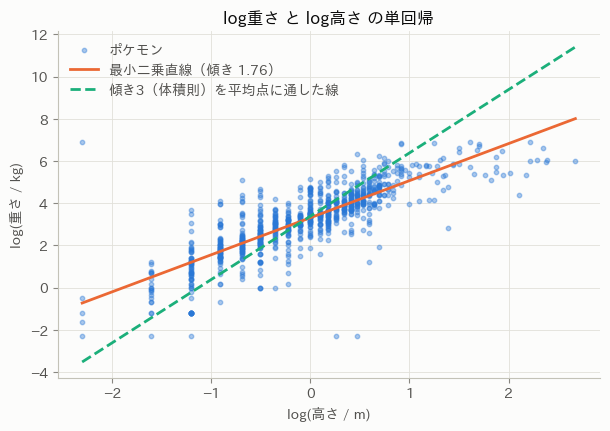

In [111]:
# 単回帰 log重さ = a + b log高さ。体積則（重さ ∝ 高さ^3）なら b = 3
x_lh = df["log高さ"].to_numpy()
y_lw = df["log重さ"].to_numpy()
n_s = len(x_lh)
Sxx = ((x_lh - x_lh.mean()) ** 2).sum()
Sxy = ((x_lh - x_lh.mean()) * (y_lw - y_lw.mean())).sum()
b_s = Sxy / Sxx
a_s = y_lw.mean() - b_s * x_lh.mean()
e_s = y_lw - (a_s + b_s * x_lh)
s_s = np.sqrt((e_s ** 2).sum() / (n_s - 2))
se_b = s_s / np.sqrt(Sxx)
df_s = n_s - 2
tcrit = stats.t.ppf(0.975, df_s)

ols_s = sm.OLS(y_lw, sm.add_constant(x_lh)).fit()
print(f"傾き b = {b_s:.4f}（statsmodels {ols_s.params[1]:.4f}）, SE = {se_b:.4f}, 切片 a = {a_s:.4f}")
print(f"b の95%信頼区間: [{b_s - tcrit * se_b:.3f}, {b_s + tcrit * se_b:.3f}]")
for b0 in [0, 3]:
    t0 = (b_s - b0) / se_b
    print(f"H0: b = {b0}:  t = {t0:.2f}, 自由度 {df_s}, 両側p値 = {2 * stats.t.sf(abs(t0), df_s):.3g}")
print(f"決定係数 R^2 = {ols_s.rsquared:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_lh, y_lw, s=10, alpha=0.4, color=PALETTE[0], label="ポケモン")
xx = np.linspace(x_lh.min(), x_lh.max(), 50)
ax.plot(xx, a_s + b_s * xx, color=PALETTE[1], label=f"最小二乗直線（傾き {b_s:.2f}）")
ax.plot(xx, a_s + b_s * x_lh.mean() + 3 * (xx - x_lh.mean()), color=PALETTE[2], ls="--",
        label="傾き3（体積則）を平均点に通した線")
ax.set(title="log重さ と log高さ の単回帰", xlabel="log(高さ / m)", ylabel="log(重さ / kg)")
ax.legend()
plt.show()

**結果の読み方**
- 傾きの推定値は約1.76（95%信頼区間 およそ1.68〜1.84）で、$H_0: b=3$ の $t$ 値は約 $-31$（自由度918）。5%水準で強く棄却され、ポケモンの重さは高さの3乗よりずっと緩やかにしか増えない。
- 解釈の候補：大きいポケモンほど細長い（ヘビ型・竜型など）、あるいは設定上の数値が相似則に従っていない。回帰は「体積則が成り立たない」ことを示すだけで、理由までは教えない。
- $R^2$ は約0.67で、同じ高さでも重さのばらつきは大きい（ゴースト系の0.1kg とイワ・ハガネ系の数百kg が混在）。

### 16.3 決定係数と $F$ 検定

**問い**：種族値6項目は経験値の変動をどれだけ説明するか。6項目を別々の係数にする必要はあるか（合計種族値1つで十分ではないか）。

**手法の要点**
- 総変動 $S_T=\sum(y_i-\bar y)^2$、残差平方和 $S_E=\sum e_i^2$、回帰変動 $S_R=S_T-S_E$ として、決定係数 $R^2=S_R/S_T$。
- 説明変数を増やすと $R^2$ は減らないので、自由度で調整した
$$R^{*2}=1-\frac{S_E/(n-d-1)}{S_T/(n-1)}$$
  も見る。いずれもあてはまりの指標であり、予測性能の指標ではない（第30章）。
- 係数の $t$ 検定：$H_0:\beta_j=0$ のもと $\hat\beta_j/\mathrm{SE}(\hat\beta_j)\sim t(n-d-1)$。
- 全体の $F$ 検定：$H_0:\beta_1=\dots=\beta_d=0$ のもと
$$F=\frac{S_R/d}{S_E/(n-d-1)}\sim F(d,\,n-d-1).$$
- 入れ子モデルの $F$ 検定：$q$ 個の一次制約（ここでは $\beta_1=\dots=\beta_6$ の $q=5$ 個。制約下のモデルは合計種族値だけの単回帰）について、制約つき・なしの残差平方和 $S_{E0}, S_E$ から
$$F=\frac{(S_{E0}-S_E)/q}{S_E/(n-d-1)}\sim F(q,\,n-d-1).$$

（→ py 16-3：$R^2$・$R^{*2}$・$F$ を定義式から計算して statsmodels と照合し、入れ子モデルの $F$ 検定を行う）

In [112]:
# 決定係数・自由度調整済み決定係数・F 検定を定義式から計算
y_bar = y16.mean()
ST = ((y16 - y_bar) ** 2).sum()                    # 総変動
SE_ = (resid16 ** 2).sum()                         # 残差平方和
SR = ST - SE_                                      # 回帰変動
d16 = p16 - 1                                      # 説明変数の数
R2 = SR / ST
R2_adj = 1 - (SE_ / (n16 - d16 - 1)) / (ST / (n16 - 1))
F16 = (SR / d16) / (SE_ / (n16 - d16 - 1))
print(f"R^2 = {R2:.4f}（sm {ols16.rsquared:.4f}）, 調整済み R^2 = {R2_adj:.4f}（sm {ols16.rsquared_adj:.4f}）")
print(f"F = {F16:.1f}（sm {ols16.fvalue:.1f}）, 自由度 ({d16}, {n16 - d16 - 1}), p = {stats.f.sf(F16, d16, n16 - d16 - 1):.3g}")

# 係数ごとの t 検定（H0: beta_j = 0）
t16 = beta_hat / se16
coef_tab16 = pd.DataFrame({"係数": beta_hat, "標準誤差": se16, "t": t16,
                           "p値": 2 * stats.t.sf(np.abs(t16), n16 - p16)}, index=ols16.params.index)
print(coef_tab16.round(4).to_string())

# 入れ子モデルの F 検定: H0「6項目の係数がすべて等しい」（= 合計種族値だけのモデル）
ols16_tot = sm.OLS(df["経験値"], sm.add_constant(df["合計種族値"])).fit()
q16 = d16 - 1                                      # 制約の数
F_nest = ((ols16_tot.ssr - ols16.ssr) / q16) / (ols16.ssr / (n16 - p16))
print(f"\n合計種族値だけのモデル R^2 = {ols16_tot.rsquared:.4f}")
print(f"係数が等しいかの F = {F_nest:.2f}, 自由度 ({q16}, {n16 - p16}), p = {stats.f.sf(F_nest, q16, n16 - p16):.3g}")
print("statsmodels compare_f_test:", np.round(ols16.compare_f_test(ols16_tot), 4))

R^2 = 0.8668（sm 0.8668）, 調整済み R^2 = 0.8659（sm 0.8659）
F = 989.9（sm 989.9）, 自由度 (6, 913), p = 0
             係数    標準誤差        t   p値
const -117.8200  3.7883 -31.1009  0.0
HP       0.9454  0.0431  21.9266  0.0
攻撃       0.4270  0.0393  10.8520  0.0
防御       0.4915  0.0413  11.8895  0.0
特攻       0.5682  0.0380  14.9632  0.0
特防       0.6814  0.0476  14.3199  0.0
素早       0.6403  0.0394  16.2337  0.0

合計種族値だけのモデル R^2 = 0.8530
係数が等しいかの F = 18.83, 自由度 (5, 913), p = 7.66e-18
statsmodels compare_f_test: [18.8251  0.      5.    ]


**結果の読み方**
- $R^2\approx0.867$、$R^{*2}\approx0.866$。$n=920$ に対して $d=6$ と少ないので両者はほぼ同じ。
- 全体の $F$ 検定（$F\approx990$, 自由度 $(6, 913)$）も各係数の $t$ 検定も、5%水準で有意。ただし $n$ が大きいので、小さな効果でも有意になりやすい。
- 合計種族値だけのモデルでも $R^2\approx0.853$ と高いが、「6項目の係数が等しい」という制約は $F\approx18.8$（自由度 $(5, 913)$）で5%水準で棄却される。経験値は HP をやや重く評価する形で決まっているようである。
- 残差には強い歪みと裾の重さがあり（ハピナスなど）、正規性の前提は崩れている。$n$ が大きいので係数の検定は近似的には使えるが、次の16.5・第17章で確認する。

### 16.4 多重共線性（VIF）

**問い**：説明変数どうしが相関していると、係数の推定はどれだけ不安定になるか。

**手法の要点**
- 説明変数 $x_j$ を他の説明変数で回帰したときの決定係数を $R_j^2$ として、**分散拡大係数** $\mathrm{VIF}_j=1/(1-R_j^2)$。$\hat\beta_j$ の分散は、$x_j$ が他と無相関な場合の $\mathrm{VIF}_j$ 倍になる。
- 目安として $\mathrm{VIF}>10$ で強い多重共線性を疑う（あくまで経験的な基準）。
- ある列が他の列の一次結合になっている（完全な共線性）と、$X^\top X$ は特異になり $\hat{\boldsymbol\beta}$ は一意に定まらない。

（→ py 16-4：種族値6項目・捕獲率・log高さ・log重さの VIF を定義から計算して statsmodels と照合し、合計種族値を加えた場合の階数を調べる）

In [113]:
# 多重共線性: VIF_j = 1 / (1 - R_j^2)（R_j^2 は x_j を他の説明変数で回帰した決定係数）
vif_cols = [*STATS, "捕獲率", "log高さ", "log重さ"]
Xv = df[vif_cols]
vif_hand = []
for c in vif_cols:
    r2j = sm.OLS(Xv[c], sm.add_constant(Xv.drop(columns=c))).fit().rsquared
    vif_hand.append(1 / (1 - r2j))
Xv_c = sm.add_constant(Xv).to_numpy(float)
vif_sm = [variance_inflation_factor(Xv_c, i + 1) for i in range(len(vif_cols))]
print(pd.DataFrame({"VIF(手計算)": vif_hand, "VIF(statsmodels)": vif_sm}, index=vif_cols).round(2).to_string())

# 完全な共線性: 合計種族値 = 6項目の和 なので、全部入れると X^T X が特異になる
X_sing = np.column_stack([np.ones(len(df)), df[STATS + ["合計種族値"]].to_numpy(float)])
print(f"\n6項目+合計種族値: 列数 {X_sing.shape[1]}, 階数 {np.linalg.matrix_rank(X_sing)}, "
      f"X^T X の条件数 {np.linalg.cond(X_sing.T @ X_sing):.2e}")

       VIF(手計算)  VIF(statsmodels)
HP         1.65              1.65
攻撃         2.03              2.03
防御         1.98              1.98
特攻         1.87              1.87
特防         1.99              1.99
素早         1.59              1.59
捕獲率        1.98              1.98
log高さ      4.01              4.01
log重さ      3.41              3.41

6項目+合計種族値: 列数 8, 階数 7, X^T X の条件数 7.55e+18


**結果の読み方**
- VIF は種族値6項目・捕獲率で2前後、log高さ約4.0、log重さ約3.4。高さと重さの相関が大きいが、目安の10には遠く、深刻な多重共線性はない。
- 6項目に合計種族値を加えると、列数8に対して階数7となり、$X^\top X$ の条件数は $10^{18}$ 程度（数値的に特異）になる。合計種族値は6項目の和なので、同時に入れてはいけない。

### 16.5 一般化最小二乗法（不均一分散）

**問い**：16.1 のモデルでは誤差の分散が一定といえるか。一定でないなら、推定をどう改めるか。

**手法の要点**
- 誤差の分散共分散行列が $V[\boldsymbol\varepsilon]=\sigma^2\Omega$（$\Omega\neq I$）のとき、OLS 推定量は不偏のままだが BLUE ではなく、通常の標準誤差の公式も誤りになる。
- **一般化最小二乗法（GLS）**：$\hat{\boldsymbol\beta}_{\mathrm{GLS}}=(X^\top\Omega^{-1}X)^{-1}X^\top\Omega^{-1}\boldsymbol y$ が BLUE。$\Omega$ が対角 $\mathrm{diag}(\sigma_1^2,\dots,\sigma_n^2)$ なら、各行を $\sigma_i$ で割ってから OLS を行うことと同じで、**重みつき最小二乗法（WLS）** と呼ぶ。
- 実際には $\Omega$ は未知なので推定する（**実行可能な GLS**, FGLS）。ここでは $\log e_i^2$ を $X$ で回帰した予測値から $\hat\sigma_i^2$ を作り、重み $w_i=1/\hat\sigma_i^2$ とした。
- 不均一分散の検定には Breusch-Pagan 検定を使う（$H_0$：分散一定。帰無仮説のもとで LM 統計量は近似的に $\chi^2(d)$）。別の対処として、係数は OLS のまま標準誤差だけを不均一分散に頑健なもの（HC3 など）に替える方法もある。

（→ py 16-5：Breusch-Pagan 検定、FGLS の推定（手計算で照合）、OLS・頑健標準誤差・FGLS の比較表）

In [114]:
# 不均一分散の確認（Breusch-Pagan）と実行可能な一般化最小二乗法（FGLS = 推定した重みの WLS）
X16_df = sm.add_constant(df[STATS])
lm, lm_p, _, _ = het_breuschpagan(ols16.resid, X16_df)
print(f"Breusch-Pagan: LM = {lm:.1f}, 自由度 {d16}, p = {lm_p:.3g}")

# 分散関数を log(e^2) = X gamma で推定し、重み w_i = 1 / sigma_i^2 とする
aux = sm.OLS(np.log(ols16.resid ** 2), X16_df).fit()
sigma2_hat = np.exp(aux.fittedvalues)
wls16 = sm.WLS(df["経験値"], X16_df, weights=1 / sigma2_hat).fit()

# WLS = 各行を sigma_i で割ったデータの OLS（手計算で照合）
w_sqrt = 1 / np.sqrt(sigma2_hat.to_numpy())
beta_wls = np.linalg.lstsq(X16 * w_sqrt[:, None], y16 * w_sqrt, rcond=None)[0]
print("WLS 係数の最大差（手計算 vs sm）:", np.abs(beta_wls - wls16.params.to_numpy()).max())

hc3 = ols16.get_robustcov_results("HC3")
pd.DataFrame({"OLS係数": ols16.params, "OLS標準誤差": ols16.bse,
              "OLS頑健SE(HC3)": hc3.bse, "FGLS係数": wls16.params, "FGLS標準誤差": wls16.bse}).round(3)

Breusch-Pagan: LM = 129.0, 自由度 6, p = 2.14e-25
WLS 係数の最大差（手計算 vs sm）: 2.842170943040401e-14


,OLS係数,OLS標準誤差,OLS頑健SE(HC3),FGLS係数,FGLS標準誤差
const,-117.820,3.788,4.504,-112.222,3.118
HP,0.945,0.043,0.164,0.732,0.049
攻撃,0.427,0.039,0.070,0.540,0.033
防御,0.491,0.041,0.059,0.525,0.033
特攻,0.568,0.038,0.050,0.607,0.032
特防,0.681,0.048,0.059,0.610,0.040
素早,0.640,0.039,0.035,0.631,0.033


**結果の読み方**
- Breusch-Pagan 検定は LM ≈ 129（自由度6）で、5%水準で分散一定は棄却される。
- 頑健標準誤差（HC3）は、HP で通常の標準誤差の約4倍（0.043 → 0.16）になる。ハピナス・ラッキーなど HP の大きいポケモンで残差のばらつきが大きいためで、通常の標準誤差は HP の係数の精度を過大評価している。
- FGLS では分散の大きい行の重みが下がり、HP の係数は約0.95から約0.73へ下がって、攻撃は約0.43から約0.54へ上がる（他の項目の変化は小さい）。HP の係数が大きかったのは、一部の極端なポケモンに引っ張られていた面がある。
- FGLS の標準誤差は HP 以外で OLS より小さい。ただし分散関数の形（ここでは $\exp(X\gamma)$）を仮定しており、それが正しいときにだけ効率がよいことに注意する。

### 16.6 正則化

**問い**：係数の大きさに罰則をかけて縮小すると、どの説明変数が最後まで残るか。

**手法の要点**
- 説明変数を標準化したうえで（尺度の違いで罰則のかかり方が変わらないように）、正則化パラメータ $\lambda\ge0$ について次を最小化する（切片には罰則をかけない）。
  - **Ridge（L2）**：$\sum_i (y_i-\boldsymbol x_i^\top\boldsymbol\beta)^2 + \lambda\sum_j\beta_j^2$。解は $(X^\top X+\lambda I)^{-1}X^\top\boldsymbol y$ で、$X^\top X$ が特異でも一意に定まる。係数は0に近づくが、ちょうど0にはならない。
  - **Lasso（L1）**：$\frac{1}{2n}\sum_i (y_i-\boldsymbol x_i^\top\boldsymbol\beta)^2 + \lambda\sum_j|\beta_j|$。いくつかの係数がちょうど0になり（スパース性）、変数選択を兼ねる。
  - **Elastic Net**：L1 と L2 の罰則を混ぜたもの。相関の強い変数をまとめて残しやすい。
  - **Fused lasso**：隣り合う係数の差 $\sum_j|\beta_j-\beta_{j-1}|$ にも L1 罰則をかけ、隣接する係数を等しくしやすくする。変数に自然な並び（時間・位置）があるときに使うもので、今回の説明変数には並びがないため扱わない。
- $\lambda$ を動かしたときの係数の軌跡を **正則化パス** という。$\lambda$ の選び方は第30章の交差検証による。
- 上の式は scikit-learn の定義に合わせている。Ridge と Lasso では損失の係数（$1$ と $1/(2n)$）が異なるので、横軸の $\lambda$ の値どうしは比較できない。

（→ py 16-6：種族値6項目・捕獲率・log重さ（すべて標準化）で標準化した経験値を予測し、3手法の係数パスを描く）

Lasso で係数が 0 でなくなる λ: {'特攻': 0.6341, '特防': 0.6341, 'HP': 0.5778, '攻撃': 0.5778, '捕獲率': 0.5264, '素早': 0.3012, '防御': 0.2279, 'log重さ': 0.0046}
標準化 OLS 係数: {'HP': 0.315, '攻撃': 0.179, '防御': 0.196, '特攻': 0.238, '特防': 0.24, '素早': 0.236, '捕獲率': -0.005, 'log重さ': -0.016}


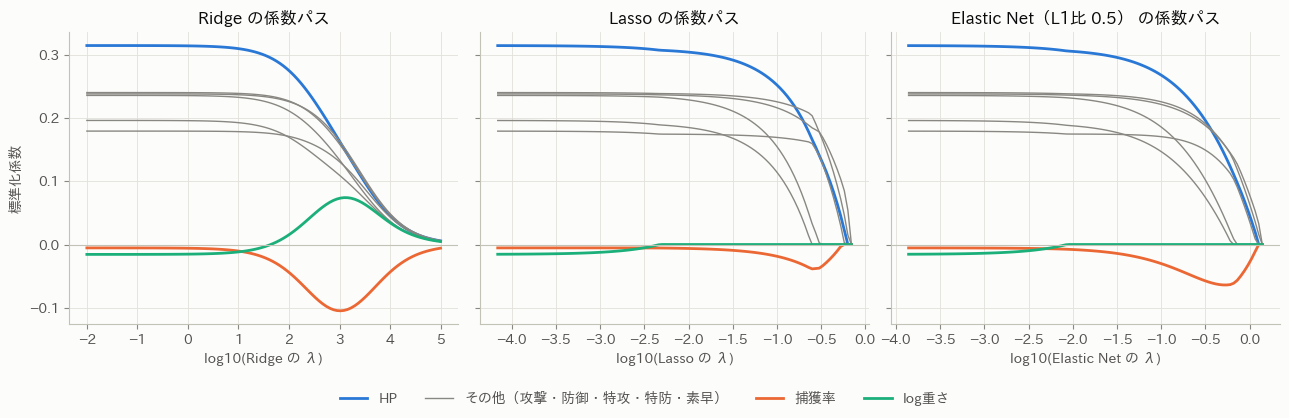

In [115]:
# 正則化（Ridge / Lasso / Elastic Net）。説明変数と目的変数を標準化してから推定する
reg_cols = [*STATS, "捕獲率", "log重さ"]
Z16 = StandardScaler().fit_transform(df[reg_cols])
yz16 = (y16 - y16.mean()) / y16.std()
alphas_l, coefs_l, _ = lasso_path(Z16, yz16, n_alphas=100, eps=1e-4)
alphas_e, coefs_e, _ = enet_path(Z16, yz16, l1_ratio=0.5, n_alphas=100, eps=1e-4)
alphas_r = np.logspace(-2, 5, 100)
coefs_r = np.array([Ridge(alpha=a).fit(Z16, yz16).coef_ for a in alphas_r]).T

# Lasso で各変数が初めて 0 でなくなる λ（大きい順 = モデルに入る順）
enter16 = {c: alphas_l[np.argmax(b != 0)] if (b != 0).any() else 0 for c, b in zip(reg_cols, coefs_l)}
print("Lasso で係数が 0 でなくなる λ:", {c: round(a, 4) for c, a in sorted(enter16.items(), key=lambda t: -t[1])})
print("標準化 OLS 係数:", dict(zip(reg_cols, np.linalg.lstsq(Z16, yz16, rcond=None)[0].round(3))))

# 注目する3変数だけ色を付け、残り（攻撃・防御・特攻・特防・素早）は灰色の「その他」にまとめる
hl16 = {"HP": PALETTE[0], "捕獲率": PALETTE[1], "log重さ": PALETTE[2]}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, (name, al, co, lab) in zip(axes, [
        ("Ridge", alphas_r, coefs_r, "Ridge の λ"),
        ("Lasso", alphas_l, coefs_l, "Lasso の λ"),
        ("Elastic Net（L1比 0.5）", alphas_e, coefs_e, "Elastic Net の λ")]):
    first_other = True
    for c, b in zip(reg_cols, co):
        if c in hl16:
            ax.plot(np.log10(al), b, color=hl16[c], lw=2, label=c)
        else:
            ax.plot(np.log10(al), b, color=INK["muted"], lw=1,
                    label="その他（攻撃・防御・特攻・特防・素早）" if first_other else None)
            first_other = False
    ax.axhline(0, color=INK["axis"], lw=0.8)
    ax.set(title=f"{name} の係数パス", xlabel=f"log10({lab})")
axes[0].set_ylabel("標準化係数")
h16, l16 = axes[0].get_legend_handles_labels()
fig.legend(h16, l16, loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

**結果の読み方**
- $\lambda$ が小さい端では、どの手法も標準化 OLS 係数（HP 約0.32、他の5項目 0.18〜0.24、捕獲率・log重さはほぼ0）に近づく。
- Lasso では $\lambda$ を大きい側から下げていくと、特攻・特防・HP・攻撃が先にモデルに入り、捕獲率、素早、防御が続く。log重さは $\lambda$ がかなり小さくなるまで0のままである。
- 捕獲率は $\lambda$ が中程度のとき負の係数をもつ（種族値の係数が縮められている間、それと相関の強い捕獲率が代わりに説明する）が、$\lambda$ が小さくなり種族値の係数が大きくなると0付近へ戻る。種族値が入っていれば、捕獲率の情報はほぼ重複している。Ridge では log重さにも同様の一時的な正の係数が現れる。
- Ridge の係数は滑らかに縮むだけで0にはならない。Elastic Net はその中間の振る舞いをする。
- 経験値は種族値でほぼ決まっている（$R^2\approx0.87$）ので、この例では正則化で予測が大きく改善するわけではない。正則化が効くのは、説明変数が多い・相関が強い・$n$ が小さい場合である。

### まとめ

- 経験値は種族値6項目の一次式で約87%説明でき、HP が他の項目よりやや重く効いている（6項目の係数が等しいという仮説は棄却）。
- 重さと高さの対数の関係の傾きは約1.76で、相似な体の「3乗則」からは大きく外れる。
- 残差の分散は一定ではなく（Breusch-Pagan で棄却）、頑健標準誤差や FGLS を検討すべきである。外れ値の影響は第17章で診断する。
- 多重共線性は VIF で数量化できる。合計種族値と6項目を同時に入れるような完全な共線性では OLS は定まらないが、Ridge なら定まる。
- 係数は観察データの条件付き平均の関係であり、「HP を上げれば経験値が上がる」という因果を示すものではない（経験値はゲーム設計者が決めた値である）。

## 第17章 回帰診断法

### 章の概要

回帰モデルをあてはめたあと、その **前提が成り立っているか**、**一部のデータ点に結果が振り回されていないか** を調べる。
- 目的：誤差の独立性・等分散性・正規性の破れと、外れ値・影響の大きい点を見つける。
- 考え方：残差を「誤差の代わり」として図で見る。ハット行列からてこ比を求め、1点を除いたときの変化（Cook の距離）で影響度を測る。
- つながり：第16章の重回帰（経験値 ~ 種族値6項目）と単回帰（log重さ ~ log高さ）をそのまま診断する。変換の効果は第4章（変数変換）と対応する。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 17.1 | 残差プロット・正規 Q-Q プロット | 経験値の回帰で、誤差の等分散性・正規性は成り立つか |
| 17.2 | てこ比 | 説明変数の組み合わせが極端なポケモンは誰か |
| 17.3 | スチューデント化残差 | 回帰式から大きく外れるポケモンは誰か |
| 17.4 | Cook の距離 | 1匹除くと回帰式が大きく変わるポケモンは誰か |
| 17.5 | 変換前後の比較 | 重さを対数にすると診断はどう変わるか |
| 17.6 | 外れ値を除いた再推定 | 影響の大きい点を除くと係数はどう変わるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `経験値` | 量的 | 17.1〜17.4, 17.6 の目的変数 |
| `HP`〜`素早` | 量的 | 説明変数（種族値6項目） |
| `高さ`, `重さ` | 量的（m, kg） | 17.5 の変換前のモデル |
| `log高さ`, `log重さ` | 量的 | 17.5 の変換後のモデル |

- **対象の行**：全920行。
- **加工**：なし（17.5 で対数変換の前後を比べる）。
- **データの性質と注意点**：HP にハピナス（255）・ラッキー（250）、防御・特防にツボツボ（230）という極端な値がある。経験値は種族値からゲーム内の規則で決まる値と考えられ、「誤差」は確率的なばらつきというより規則からのずれである。ここでは第16章と同様、仮想的な母集団からの標本とみなして診断する。

In [116]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan

# 第16章と同じモデル: 経験値 ~ 種族値6項目
X17 = sm.add_constant(df[STATS])
y17 = df["経験値"]
ols17 = sm.OLS(y17, X17).fit()
n17, p17 = X17.shape
print(f"n = {n17}, 係数の数 p = {p17}, R^2 = {ols17.rsquared:.3f}")
df[["経験値", *STATS, "高さ", "重さ"]].describe().T[["mean", "std", "min", "max"]].round(1)

n = 920, 係数の数 p = 7, R^2 = 0.867


,mean,std,min,max
経験値,153.7,79.1,36.0,608.0
HP,69.6,26.0,1.0,255.0
攻撃,80.1,32.5,5.0,190.0
防御,74.6,31.2,5.0,230.0
特攻,73.3,33.2,10.0,194.0
特防,72.4,27.9,20.0,230.0
素早,68.6,29.4,5.0,180.0
高さ,1.3,1.3,0.1,14.5
重さ,69.2,124.7,0.1,999.9


### 17.1 残差プロットと正規 Q-Q プロット

**問い**：経験値 ~ 種族値6項目 の回帰で、誤差の等分散性・正規性は成り立つか。

**手法の要点**
- 線形回帰は誤差 $\varepsilon_i$ が互いに独立で平均0・分散一定 $\sigma^2$（検定ではさらに正規分布）であることを仮定する。誤差は観測できないので、残差 $e_i=y_i-\hat y_i$ で代用する。
- **残差プロット**：横軸に予測値 $\hat y_i$、縦軸に残差 $e_i$。仮定が正しければ0の周りに一様な帯として散らばる。曲線的な傾向は関数形の誤り、ラッパ型の広がりは不均一分散を示唆する。
- **正規 Q-Q プロット**：残差を $s=\sqrt{\sum e_i^2/(n-p)}$ で割った値の順序統計量を、標準正規分布の分位点に対してプロットする。正規なら傾き1の直線上に並ぶ。
- 正規性の検定には Jarque-Bera 検定（歪度と尖度を使う。$H_0$ のもとで漸近的に $\chi^2(2)$）などがある。

（→ py 17-1：残差の歪度・尖度、Jarque-Bera 検定、残差プロットと Q-Q プロット）

残差の歪度 1.66, 尖度(-3) 20.80
Jarque-Bera: 統計量 17001, 自由度 2, p = 0


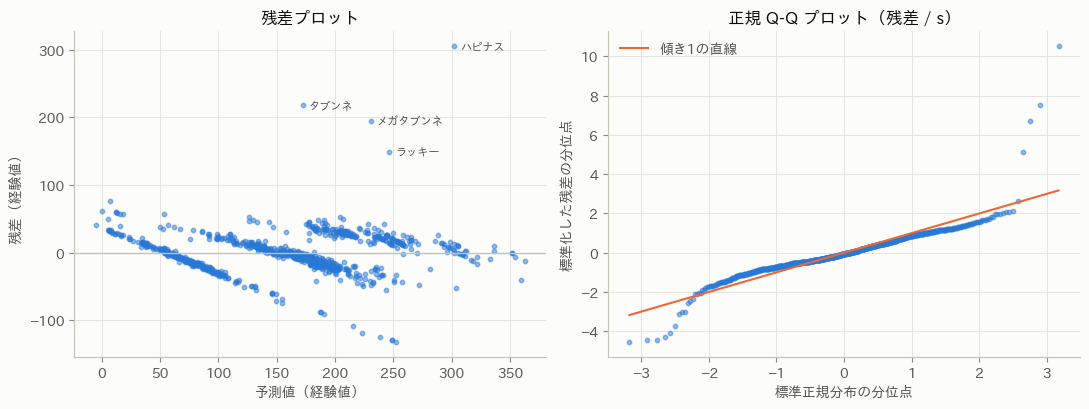

In [117]:
# 残差プロットと正規 Q-Q プロット
fit17 = ols17.fittedvalues
res17 = ols17.resid
s17 = np.sqrt(ols17.mse_resid)
print(f"残差の歪度 {stats.skew(res17):.2f}, 尖度(-3) {stats.kurtosis(res17):.2f}")
jb17 = stats.jarque_bera(res17)
print(f"Jarque-Bera: 統計量 {jb17.statistic:.0f}, 自由度 2, p = {jb17.pvalue:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(fit17, res17, s=10, alpha=0.5, color=PALETTE[0])
axes[0].axhline(0, color=INK["axis"], lw=1)
for i in res17.abs().nlargest(4).index:
    axes[0].annotate(df.loc[i, "名前"], (fit17[i], res17[i]), xytext=(4, 0), textcoords="offset points",
                     fontsize=8, color=INK["secondary"], va="center")
axes[0].set(title="残差プロット", xlabel="予測値（経験値）", ylabel="残差（経験値）")
osm, osr = stats.probplot(res17 / s17, dist="norm", fit=False)
axes[1].scatter(osm, osr, s=10, alpha=0.5, color=PALETTE[0])
lim = [osm.min(), osm.max()]
axes[1].plot(lim, lim, color=PALETTE[1], lw=1.5, label="傾き1の直線")
axes[1].set(title="正規 Q-Q プロット（残差 / s）", xlabel="標準正規分布の分位点", ylabel="標準化した残差の分位点")
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 残差プロットには、右上に大きく離れた点（ハピナス、タブンネ、メガタブンネ、ラッキー）がある。残差が $+150$〜$+300$ で、経験値が種族値から予想されるより著しく大きい（倒すと経験値が多いことで知られるポケモンである）。
- 残りの点も一様な帯ではなく、右下がりの筋が何本も並ぶ。経験値が「進化段階ごとの規則」のような離散的な仕組みで決まっていて、線形モデルでは表しきれない構造が残っていることを示唆する。
- Q-Q プロットは両端で直線から離れ（歪度約1.7、尖度 $-3$ で約21）、Jarque-Bera 検定でも正規性は5%水準で棄却される。$n=920$ と大きいので係数の検定は中心極限定理により近似的には使えるが（ただし第16章で見た不均一分散の問題は別に残る）、正規分布にもとづく個々の予測区間は信用できない。

### 17.2 てこ比

**問い**：説明変数の組み合わせが、他のポケモンから極端に離れているのは誰か。

**手法の要点**
- 予測値は $\hat{\boldsymbol y}=H\boldsymbol y$, $H=X(X^\top X)^{-1}X^\top$（**ハット行列**）と書ける。$H$ は対称・べき等（$H^2=H$）な射影行列である。
- 対角成分 $h_{ii}$ を **てこ比** という。$\hat y_i=\sum_j h_{ij}y_j$ における自分自身の重みで、$0\le h_{ii}\le1$。
- $\sum_i h_{ii}=\mathrm{tr}\,H=\mathrm{tr}\big((X^\top X)^{-1}X^\top X\big)=p$（$p$ は切片を含む係数の数）なので、平均は $p/n$。目安として $h_{ii}>2p/n$ の点を「てこ比が大きい」とみなす。
- てこ比は説明変数だけで決まり、目的変数 $y$ には依存しない。
- 計算では $X=QR$（QR 分解）とすると $H=QQ^\top$ なので、$h_{ii}$ は $Q$ の $i$ 行目の二乗和になる。

（→ py 17-2：QR 分解からてこ比を求め、$\sum h_{ii}=p$ を確認し、てこ比の大きいポケモンを表示する）

In [118]:
# てこ比: ハット行列 H = X (X^T X)^{-1} X^T の対角成分。QR 分解 X = QR なら H = Q Q^T
Xm17 = X17.to_numpy(float)
Q17, _ = np.linalg.qr(Xm17)
h17 = (Q17 ** 2).sum(axis=1)
infl17 = OLSInfluence(ols17)
print(f"sum h_ii = {h17.sum():.6f}（= p = {p17}）")
print("statsmodels との最大差:", np.abs(h17 - infl17.hat_matrix_diag).max())
print(f"平均 p/n = {p17 / n17:.4f}, 目安 2p/n = {2 * p17 / n17:.4f} を超える行: {(h17 > 2 * p17 / n17).sum()}")
lev_top = df.assign(てこ比=h17).nlargest(8, "てこ比")[["名前", *STATS, "経験値", "てこ比"]]
lev_top.round(3)

sum h_ii = 7.000000（= p = 7）
statsmodels との最大差: 2.7755575615628914e-17
平均 p/n = 0.0076, 目安 2p/n = 0.0152 を超える行: 72


,名前,HP,攻撃,防御,特攻,特防,素早,経験値,てこ比
139,ラッキー,250,5,5,35,105,50,395,0.103
279,ハピナス,255,10,10,75,135,55,608,0.102
248,ツボツボ,20,10,230,10,230,5,177,0.091
907,アクジキング,223,101,53,97,53,43,257,0.054
235,ソーナンス,190,33,58,33,58,33,142,0.047
817,ジガルデ100%,216,100,121,91,95,85,319,0.046
447,デオキシスA,50,180,20,180,20,150,270,0.044
351,メガボスゴドラ,70,140,230,60,80,50,284,0.037


**結果の読み方**
- $\sum h_{ii}=7=p$ を数値的に確認できた。平均 $p/n\approx0.0076$ に対して、目安 $2p/n\approx0.015$ を超える行は72行。
- てこ比が最大なのはラッキー・ハピナス（約0.10、HP が250以上で攻撃・防御が5〜10）とツボツボ（約0.09、防御・特防230で他は5〜20）。いずれも種族値の配分が極端で、平均の約13倍のてこ比をもつ。
- てこ比が大きいこと自体は「悪い」ことではない。回帰式を強く引っ張る「可能性がある」位置にいる、という意味である（17.4 で実際の影響を見る）。

### 17.3 スチューデント化残差

**問い**：回帰式から大きく外れているポケモンは誰か。

**手法の要点**
- 残差の分散は一定ではなく $V[e_i]=\sigma^2(1-h_{ii})$ である（てこ比の大きい点ほど残差は小さくなりやすい）。そこで尺度をそろえる。
  - **内部スチューデント化残差**：$r_i=\dfrac{e_i}{s\sqrt{1-h_{ii}}}$
  - **外部スチューデント化残差**：$t_i=\dfrac{e_i}{s_{(i)}\sqrt{1-h_{ii}}}$。$s_{(i)}^2$ は $i$ 番目を除いてあてはめたときの誤差分散の推定値で、再推定しなくても
  $s_{(i)}^2=\dfrac{(n-p)s^2-e_i^2/(1-h_{ii})}{n-p-1}$ で求まる。
- 誤差が正規分布で $i$ 番目が外れ値でなければ $t_i\sim t(n-p-1)$。$|t_i|>2$ を目安にすることが多いが、$n$ 点すべてを調べるので、多重性を考えるならボンフェローニ補正（各点の両側有意水準 $0.05/n$）を使う。

（→ py 17-3：定義式から2種類のスチューデント化残差を計算して statsmodels と照合し、外れの大きいポケモンを表示する）

In [119]:
# スチューデント化残差
# 内部: r_i = e_i / (s sqrt(1 - h_ii))
# 外部: t_i = e_i / (s_(i) sqrt(1 - h_ii))。s_(i) は i を除いた推定。H0 のもと t_i ~ t(n - p - 1)
e17 = res17.to_numpy()
r_int = e17 / (s17 * np.sqrt(1 - h17))
s2_del = ((n17 - p17) * s17 ** 2 - e17 ** 2 / (1 - h17)) / (n17 - p17 - 1)
r_ext = e17 / np.sqrt(s2_del * (1 - h17))
print("内部スチューデント化残差 最大差:", np.abs(r_int - infl17.resid_studentized_internal).max())
print("外部スチューデント化残差 最大差:", np.abs(r_ext - infl17.resid_studentized_external).max())

# ボンフェローニ補正した外れ値検定（有意水準5%, n 回の検定）
crit17 = stats.t.ppf(1 - 0.05 / (2 * n17), n17 - p17 - 1)
print(f"|t_i| > 2 の行: {(np.abs(r_ext) > 2).sum()}（正規なら約 {0.0455 * n17:.0f} 行）")
print(f"ボンフェローニ補正の臨界値 {crit17:.2f} を超える行: {(np.abs(r_ext) > crit17).sum()}")
df.assign(外部スチューデント化残差=r_ext, てこ比=h17).loc[
    np.argsort(-np.abs(r_ext))[:8], ["名前", "合計種族値", "経験値", "外部スチューデント化残差", "てこ比"]].round(3)

内部スチューデント化残差 最大差: 8.881784197001252e-16


外部スチューデント化残差 最大差: 2.6645352591003757e-15
|t_i| > 2 の行: 25（正規なら約 42 行）
ボンフェローニ補正の臨界値 4.06 を超える行: 9


,名前,合計種族値,経験値,外部スチューデント化残差,てこ比
279,ハピナス,540,608,11.966,0.102
608,タブンネ,445,390,7.779,0.006
609,メガタブンネ,545,425,6.919,0.010
139,ラッキー,450,395,5.493,0.103
914,マーシャドー,600,120,-4.636,0.006
913,マギアナ500年前,600,120,-4.503,0.007
912,マギアナ,600,120,-4.503,0.007
880,シルヴァディ,570,114,-4.355,0.003


**結果の読み方**
- 外部スチューデント化残差の最大はハピナス（約12）。続いてタブンネ（約7.8）、メガタブンネ（約6.9）、ラッキー（約5.5）で、経験値が種族値から予想されるより大きい。
- 負の側にはマーシャドー・マギアナ・シルヴァディ（約 $-4.4$〜$-4.6$）が並ぶ。合計種族値600前後なのに経験値が110〜120と小さい（経験値の決め方が他のポケモンと違うようである）。
- ボンフェローニ補正の臨界値（約4.06）を超えるのは9行。$|t_i|>2$ は25行で、正規分布なら期待される約42行より少ない。残差は「中心に集中し、ごく一部が極端に外れる」裾の重い分布をしている。

### 17.4 Cook の距離

**問い**：1匹だけ除いたとき、回帰式（予測値全体）が大きく変わるのは誰か。

**手法の要点**
- $i$ 番目を除いて推定した係数による予測値を $\hat y_{j(-i)}$ として、
$$D_i=\frac{\sum_{j=1}^n\left(\hat y_j-\hat y_{j(-i)}\right)^2}{p\,s^2}.$$
- 再推定しなくても $D_i=\dfrac{r_i^2}{p}\cdot\dfrac{h_{ii}}{1-h_{ii}}$ と書ける。つまり **外れの大きさ**（$r_i^2$）と **てこ比** の両方が大きい点で大きくなる。
- 目安は $D_i>4/n$（緩い基準）や $D_i>0.5$, $1$（厳しい基準）など、流儀によって異なる。

（→ py 17-4：公式と statsmodels を照合し、最大の点については実際に1行除いた再推定で定義式を確認する。てこ比 × スチューデント化残差 の影響度プロットを描く）

Cook の距離 最大差（公式 vs statsmodels）: 4.440892098500626e-16
ハピナス: 定義式 2.0054, 公式 2.0054
目安 4/n = 0.0043 を超える行: 46, D > 0.5 の行: 1


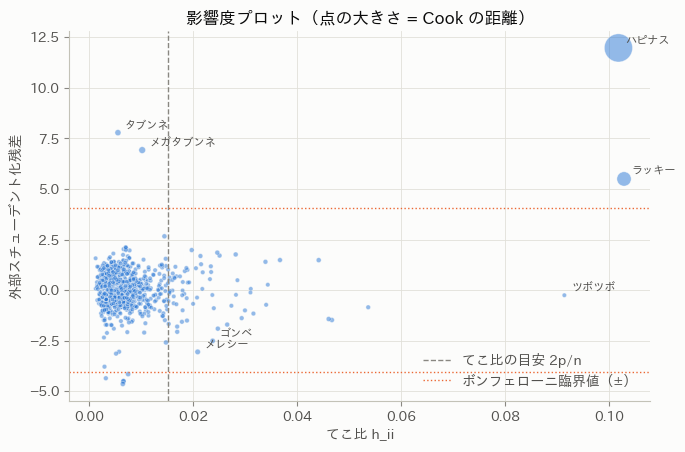

,名前,HP,防御,合計種族値,経験値,てこ比,外部スチューデント化残差,Cook
279,ハピナス,255,10,540,608,0.102,11.966,2.005
139,ラッキー,250,5,450,395,0.103,5.493,0.479
609,メガタブンネ,103,126,545,425,0.010,6.919,0.067
608,タブンネ,103,86,445,390,0.006,7.779,0.045
794,メレシー,50,150,500,100,0.021,-3.053,0.028
513,ゴンベ,135,40,390,78,0.024,-2.508,0.022
914,マーシャドー,90,80,600,120,0.006,-4.636,0.020
912,マギアナ,80,115,600,120,0.007,-4.503,0.019
913,マギアナ500年前,80,115,600,120,0.007,-4.503,0.019
790,アマルルガ,123,72,521,104,0.007,-4.151,0.018


In [120]:
# Cook の距離 D_i = sum_j (yhat_j - yhat_j(-i))^2 / (p s^2) = r_i^2 h_ii / (p (1 - h_ii))
cook17 = r_int ** 2 * h17 / (p17 * (1 - h17))
print("Cook の距離 最大差（公式 vs statsmodels）:", np.abs(cook17 - infl17.cooks_distance[0]).max())

# 最大の行について、実際に1行除いて再推定し、定義式で確認する
i_max = int(np.argmax(cook17))
keep = np.arange(n17) != i_max
b_del = np.linalg.lstsq(Xm17[keep], y17.to_numpy()[keep], rcond=None)[0]
D_def = ((fit17.to_numpy() - Xm17 @ b_del) ** 2).sum() / (p17 * s17 ** 2)
print(f"{df.loc[i_max, '名前']}: 定義式 {D_def:.4f}, 公式 {cook17[i_max]:.4f}")
print(f"目安 4/n = {4 / n17:.4f} を超える行: {(cook17 > 4 / n17).sum()}, D > 0.5 の行: {(cook17 > 0.5).sum()}")

cook_tab = df.assign(Cook=cook17, てこ比=h17, 外部スチューデント化残差=r_ext)
cook_top = cook_tab.nlargest(10, "Cook")[["名前", "HP", "防御", "合計種族値", "経験値", "てこ比", "外部スチューデント化残差", "Cook"]]

# 影響度プロット: てこ比 × スチューデント化残差、点の大きさ = Cook の距離
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(h17, r_ext, s=10 + 400 * cook17 / cook17.max(), alpha=0.5, color=PALETTE[0],
           edgecolor=INK["surface"], linewidth=0.5)
ax.axvline(2 * p17 / n17, color=INK["muted"], lw=1, ls="--", label="てこ比の目安 2p/n")
ax.axhline(crit17, color=PALETTE[1], lw=1, ls=":", label="ボンフェローニ臨界値（±）")
ax.axhline(-crit17, color=PALETTE[1], lw=1, ls=":")
for i in cook_tab.nlargest(6, "Cook").index.union(cook_tab.nlargest(3, "てこ比").index):
    ax.annotate(df.loc[i, "名前"], (h17[i], r_ext[i]), xytext=(5, 3), textcoords="offset points",
                fontsize=8, color=INK["secondary"])
ax.set(title="影響度プロット（点の大きさ = Cook の距離）", xlabel="てこ比 h_ii", ylabel="外部スチューデント化残差")
ax.legend(loc="lower right")
plt.show()
cook_top.round(3)

**結果の読み方**
- ハピナスの Cook の距離は約2.0で、定義式（1行除いた再推定）と公式が一致する。唯一 $D_i>0.5$ を超える点で、この1匹が回帰式全体を大きく動かしている。次はラッキー（約0.48）。どちらも「てこ比が大きく、しかも外れも大きい」ため、影響度プロットの右上に位置する。
- タブンネ・メガタブンネは外れは大きいがてこ比が小さく、Cook の距離は0.05前後にとどまる。
- ツボツボはてこ比が3番目に大きいのに、残差がほぼ0なので Cook の距離は小さい。極端な位置にいても、回帰式に沿っていれば影響は小さい。
- メガシンカ（メガボスゴドラ、メガスピアーなど）も $4/n$ を超える点に含まれ、目安を超える点は合計46行ある。

### 17.5 変換前後の診断の比較

**問い**：重さを高さで回帰するとき、対数をとるかどうかで診断はどう変わるか。

**手法の要点**
- 右に歪み、平均が大きいほどばらつきも大きい変数（重さ・高さ）をそのまま回帰すると、残差は不均一分散・非正規になりやすい。対数変換は、乗法的な関係 $w=cL^b$ を線形 $\log w=\log c+b\log L$ にし、分散を安定させることが多い。
- 比較する指標：$R^2$、残差の歪度・尖度、Breusch-Pagan 検定（分散一定の検定。第16章）、Cook の距離の大きい点の数。
- 目的変数を変換すると $R^2$ の分母（総変動）も変わるので、$R^2$ の大小だけで2つのモデルを比べることはできない点に注意する。

（→ py 17-5：2つの単回帰の診断指標を表にし、残差プロットと Q-Q プロットを並べる）

モデル           重さ ~ 高さ log重さ ~ log高さ
R^2             0.432         0.671
残差の歪度           4.406        -0.359
残差の尖度(-3)      36.788        10.545
BP統計量            80.8         7.298
BP p値             0.0         0.007
Cook > 4/n の行      42            62
最大Cook          2.068         0.396
最大Cookの名前       ホエルオー         コスモウム


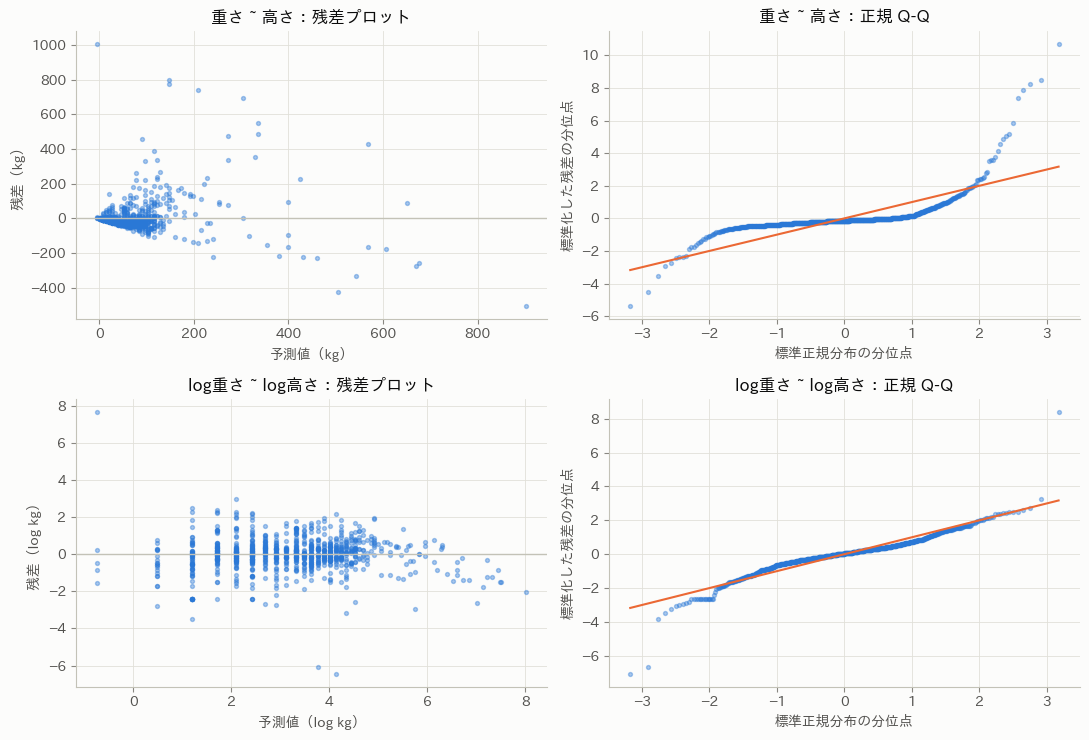

In [121]:
# 変換前後の比較: 重さ ~ 高さ と log重さ ~ log高さ
fits_tr = {
    "重さ ~ 高さ": sm.OLS(df["重さ"], sm.add_constant(df["高さ"])).fit(),
    "log重さ ~ log高さ": sm.OLS(df["log重さ"], sm.add_constant(df["log高さ"])).fit(),
}
rows_tr = []
for name, m in fits_tr.items():
    im = OLSInfluence(m)
    lm, lm_p, _, _ = het_breuschpagan(m.resid, m.model.exog)
    rows_tr.append({"モデル": name, "R^2": m.rsquared, "残差の歪度": stats.skew(m.resid),
                    "残差の尖度(-3)": stats.kurtosis(m.resid), "BP統計量": lm, "BP p値": lm_p,
                    "Cook > 4/n の行": (im.cooks_distance[0] > 4 / n17).sum(),
                    "最大Cook": im.cooks_distance[0].max(),
                    "最大Cookの名前": df.loc[np.argmax(im.cooks_distance[0]), "名前"]})
print(pd.DataFrame(rows_tr).set_index("モデル").round(3).T.to_string())

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for row, (name, m) in enumerate(fits_tr.items()):
    ax = axes[row, 0]
    ax.scatter(m.fittedvalues, m.resid, s=8, alpha=0.4, color=PALETTE[0])
    ax.axhline(0, color=INK["axis"], lw=1)
    unit = "kg" if row == 0 else "log kg"
    ax.set(title=f"{name}：残差プロット", xlabel=f"予測値（{unit}）", ylabel=f"残差（{unit}）")
    ax = axes[row, 1]
    osm, osr = stats.probplot(m.resid / np.sqrt(m.mse_resid), dist="norm", fit=False)
    ax.scatter(osm, osr, s=8, alpha=0.4, color=PALETTE[0])
    ax.plot([osm.min(), osm.max()], [osm.min(), osm.max()], color=PALETTE[1], lw=1.5)
    ax.set(title=f"{name}：正規 Q-Q", xlabel="標準正規分布の分位点", ylabel="標準化した残差の分位点")
fig.tight_layout()
plt.show()

**結果の読み方**
- 変換前は残差が予測値とともに扇状に広がり（BP 統計量 約81）、歪度約4.4・尖度約37 と強い非正規性を示す。Cook の距離が最大なのはホエルオー（高さ14.5m）で、$D\approx2.1$ と1匹で回帰式を動かしている。
- 対数変換後は残差の広がりがほぼ一様になり、歪度約 $-0.36$。BP 検定は依然5%水準で有意（p ≈ 0.007）だが統計量は約7まで下がり、最大の Cook の距離も約0.40（コスモウム：高さ0.1m・重さ999.9kg）に下がる。
- 変換後にも Q-Q プロットの両端に外れ（コスモウム、ゴースト系の極端に軽いポケモン）は残る。対数変換は全体の形を整えるが、個々の特異なポケモンまでは解消しない。

### 17.6 外れ値を除いた再推定

**問い**：影響の大きい点を除くと、経験値の回帰係数はどう変わるか。

**手法の要点**
- 影響の大きい点を除いて推定し直し、係数の変化を見る（感度分析）。
- 除いた後の $R^2$ や標準誤差は良く見えるが、「都合の悪い点を捨てた」結果でもある。除く理由（データの誤り、別の仕組みで生成された点など）を説明できないなら、除いた結果を主な結論にしてはいけない。頑健な推定（第16章の頑健標準誤差、外れ値に強い損失関数）を使う方法もある。

（→ py 17-6：ハピナス1匹だけ除いた場合と、Cook の距離 $>4/n$ の46行を除いた場合の係数を比べる）

In [122]:
# 影響の大きい行（Cook > 4/n）を除いて再推定し、係数の変化を見る
out17 = cook17 > 4 / n17
print(f"除いた行: {out17.sum()}")
print("除いた行（Cook の大きい順）:", ", ".join(cook_tab.loc[out17].sort_values("Cook", ascending=False)["名前"]))
ols17_drop = sm.OLS(y17[~out17], X17[~out17]).fit()
ols17_nohappy = sm.OLS(y17[df["名前"] != "ハピナス"], X17[df["名前"] != "ハピナス"]).fit()
print(f"R^2: 全データ {ols17.rsquared:.3f} → ハピナス除外 {ols17_nohappy.rsquared:.3f} → Cook>4/n 除外 {ols17_drop.rsquared:.3f}")
pd.DataFrame({"全データ": ols17.params, "標準誤差": ols17.bse,
              "ハピナス除外": ols17_nohappy.params,
              "Cook>4/n 除外": ols17_drop.params, "標準誤差(除外後)": ols17_drop.bse}).round(3)

除いた行: 46
除いた行（Cook の大きい順）: ハピナス, ラッキー, メガタブンネ, タブンネ, メレシー, ゴンベ, マーシャドー, マギアナ500年前, マギアナ, アマルルガ, ソーナンス, ヌケニン, デオキシスA, ホエルコ, ジガルデ100%, カビゴン, ツンデツンデ, カミツルギ, メガボスゴドラ, ホエルオー, ピンプク, ギルガルド剣, モンジャラ, メガスピアー, ボスゴドラ, シルヴァディ, ママンボウ, ケッキング, ストライク, ブロスター, ニューラ, フワライド, メガヤドラン, ヒヒダルマD, メガギャラドス, タイプ:ヌル, アクジキング, デオキシスN, ヨノワール, レジロック, メガプテラ, グライガー, ヨワシ 単独, イワーク, マユルド, カラサリス
R^2: 全データ 0.867 → ハピナス除外 0.881 → Cook>4/n 除外 0.931


,全データ,標準誤差,ハピナス除外,Cook>4/n 除外,標準誤差(除外後)
const,-117.820,3.788,-114.966,-119.275,2.752
HP,0.945,0.043,0.807,0.773,0.041
攻撃,0.427,0.039,0.479,0.497,0.030
防御,0.491,0.041,0.532,0.559,0.032
特攻,0.568,0.038,0.596,0.638,0.028
特防,0.681,0.048,0.644,0.634,0.036
素早,0.640,0.039,0.640,0.658,0.028


**結果の読み方**
- ハピナス1匹を除くだけで HP の係数は約0.95から約0.81へ下がり、$R^2$ は0.867から0.881へ上がる。920匹中の1匹が係数を約15%動かしている。
- Cook の距離 $>4/n$ の46行を除くと HP の係数は約0.77 となり、他の5項目（0.50〜0.66）との差が縮まる。$R^2$ は0.931に上がる。
- 第16章の FGLS で HP の係数が約0.73 に下がったことと合わせると、「HP が特に重く効く」という結論はハピナス・ラッキーなどの少数のポケモンに依存している。除外した46行にはメガシンカや、マーシャドー・マギアナのように合計種族値が高いのに経験値が小さいポケモンが含まれ、経験値の決まり方が他と異なる可能性がある。

### まとめ

- 経験値の回帰では、残差の分布は裾が重く（正規性は棄却）、ハピナス・ラッキー・タブンネ系が大きく外れる。ハピナスは Cook の距離約2で、1匹で HP の係数を約15%動かしている。
- てこ比（ツボツボ、ラッキー、ハピナス）と外れ（タブンネ）は別の概念で、両方が大きい点（ハピナス、ラッキー）が本当に影響の大きい点である。
- 重さ ~ 高さ は対数変換で残差の非正規性・不均一分散が大きく改善する。
- 診断で見つけた点を機械的に除くのではなく、「なぜ外れるのか」（経験値の規則が違うポケモンがいる、など）を考えることが重要である。

## 第18章 質的回帰

### 章の概要

目的変数が2値（はい／いいえ）や計数のとき、正規分布の線形回帰の代わりに **一般化線形モデル（GLM）** を使う。
- 目的：確率や平均回数が説明変数とともにどう変わるかを、値の範囲（確率なら0〜1）を守ってモデル化する。
- 考え方：目的変数の分布を指数型分布族から選び、平均をリンク関数で変換したものを説明変数の一次式で表す。推定は最尤法、検定は逸脱度（尤度比）で行う。
- つながり：第16章の線形回帰は「正規分布・恒等リンク」の GLM である。尤度比検定は第12章、最尤法は第8章、AIC によるモデル比較は第30章とつながる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 18.1 | 一般化線形モデルの枠組み | 線形回帰・ロジスティック回帰・ポアソン回帰はどう統一的に書けるか |
| 18.2 | ロジスティック回帰とオッズ比 | 性別不明になりやすいのはどんなポケモンか |
| 18.3 | プロビット回帰との比較 | リンク関数を変えると結論は変わるか。防御が高いほどはがねタイプか |
| 18.4 | ポアソン回帰（人工的な設定） | 合計種族値が高いほど、もらえる努力値は多いか |
| 18.5 | 逸脱度と尤度比検定 | 説明変数はモデルに必要か |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `性別不明` | 2値（0/1） | 18.2・18.3・18.5 の目的変数。`雄率` が欠損（性別不明）なら1。130匹 |
| `はがね` | 2値（0/1） | 18.3 の1変数の例。タイプ1かタイプ2がはがね。61匹 |
| `努力値m1` | 計数（0〜2） | 18.4 の目的変数。`努力値合計` − 1 |
| `合計100` | 量的 | 合計種族値 / 100（係数を「100増えたとき」で読むため） |
| `孵化千` | 量的 | 孵化歩数 / 1000 |
| `log重さ`, `防御` | 量的 | 説明変数 |

- **対象の行**：全920行。
- **加工**：単位の変更（合計種族値を100単位、孵化歩数を1000歩単位に）と、上の2値変数・計数変数の作成。
- **データの性質と注意点**：性別不明のポケモンはタマゴグループ「未発見」（タマゴが見つからない）と重なりが大きく、孵化歩数が30855歩（最大値）の行の多くが性別不明である。目的変数と説明変数がともにゲームの設定値なので、係数は「設定上の傾向」を記述するものであり、因果関係ではない。努力値合計は1〜3の値しかとらず、本来の意味での計数（上限のない回数）ではない（18.4）。

In [123]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

d18 = df.assign(
    性別不明=df["雄率"].isna().astype(int),
    はがね=types_of(df, "はがね").astype(int),
    合計100=df["合計種族値"] / 100,      # 合計種族値（100単位）
    孵化千=df["孵化"] / 1000,            # 孵化歩数（1000歩単位）
    努力値m1=df["努力値合計"] - 1,        # 努力値合計 − 1（0〜2 の計数）
)
print("性別不明:", d18["性別不明"].sum(), "/", len(d18), "  はがねタイプ（タイプ1か2）:", d18["はがね"].sum())
print("努力値合計−1 の分布:", d18["努力値m1"].value_counts().sort_index().to_dict())
d18.groupby("性別不明")[["合計種族値", "孵化", "log重さ", "防御"]].mean().round(2)

性別不明: 130 / 920   はがねタイプ（タイプ1か2）: 61
努力値合計−1 の分布: {0: 305, 1: 390, 2: 225}


,合計種族値,孵化,log重さ,防御
性別不明,,,,
0,417.25,5894.42,3.11,71.13
1,567.42,21165.00,3.85,95.41


### 18.1 一般化線形モデルの枠組み

**問い**：線形回帰・ロジスティック回帰・ポアソン回帰は、どのように1つの枠組みで書けるか。

**手法の要点**
- GLM は次の3要素からなる。
  1. **誤差構造**：$Y_i$ は指数型分布族に従う。確率（密度）関数が
  $$f(y;\theta,\phi)=\exp\!\left\{\frac{y\theta-b(\theta)}{a(\phi)}+c(y,\phi)\right\}$$
  と書ける分布の族で、$\theta$ を正準母数、$\phi$ を散らばり母数という。このとき $E[Y]=b'(\theta)$, $V[Y]=b''(\theta)\,a(\phi)$。
  2. **線形予測子**：$\eta_i=\beta_0+\beta_1x_{i1}+\dots+\beta_kx_{ik}$。
  3. **リンク関数**：$g(\mu_i)=\eta_i$（$\mu_i=E[Y_i\mid\boldsymbol x_i]$、$g$ は単調で1対1）。$\theta=\eta$ となる $g$ を正準リンクという。
- 例：正規分布 $N(\mu,\sigma^2)$ は $\theta=\mu$, $b(\theta)=\theta^2/2$, $a(\phi)=\sigma^2$ で、$E[Y]=\mu$, $V[Y]=\sigma^2$。ベルヌーイ分布は $\theta=\log\frac{\pi}{1-\pi}$, $b(\theta)=\log(1+e^\theta)$, $a(\phi)=1$。ポアソン分布は $\theta=\log\mu$, $b(\theta)=e^\theta$, $a(\phi)=1$ で、$E[Y]=V[Y]=\mu$。
- 係数は最尤法で推定する。正規分布・恒等リンクのときは最尤推定量が最小二乗推定量と一致する。

（→ py 18-1：正規分布・恒等リンクの GLM が OLS と一致することを確かめ、代表的な GLM を表にする）

In [124]:
# 一般化線形モデル: 正規分布・恒等リンクの GLM は OLS と一致する
glm_gauss = smf.glm("経験値 ~ HP + 攻撃 + 防御 + 特攻 + 特防 + 素早", d18, family=sm.families.Gaussian()).fit()
ols18 = smf.ols("経験値 ~ HP + 攻撃 + 防御 + 特攻 + 特防 + 素早", d18).fit()
print("GLM(正規, 恒等) と OLS の係数の最大差:", np.abs(glm_gauss.params - ols18.params).max())
print(f"正規 GLM の逸脱度 = {glm_gauss.deviance:.1f} = OLS の残差平方和 {ols18.ssr:.1f}")

# 代表的な GLM（分布・正準リンク・分散関数）
pd.DataFrame({
    "応答の分布": ["正規", "二項（ベルヌーイ）", "ポアソン"],
    "正準リンク g(μ)": ["μ", "log(μ/(1-μ))", "log μ"],
    "分散関数 V(μ)": ["1（×σ²）", "μ(1-μ)", "μ"],
    "この章の例": ["16章の重回帰", "性別不明か・はがねタイプか", "努力値合計−1"],
}, index=["線形回帰", "ロジスティック回帰", "ポアソン回帰"])

GLM(正規, 恒等) と OLS の係数の最大差: 0.0
正規 GLM の逸脱度 = 766905.0 = OLS の残差平方和 766905.0


,応答の分布,正準リンク g(μ),分散関数 V(μ),この章の例
線形回帰,正規,μ,1（×σ²）,16章の重回帰
ロジスティック回帰,二項（ベルヌーイ）,log(μ/(1-μ)),μ(1-μ),性別不明か・はがねタイプか
ポアソン回帰,ポアソン,log μ,μ,努力値合計−1


**結果の読み方**
- 正規 GLM の係数は OLS と完全に一致し、逸脱度（18.5）は残差平方和と一致する。線形回帰は GLM の特別な場合である。

### 18.2 ロジスティック回帰とオッズ比

**問い**：合計種族値・孵化歩数・重さから、性別不明かどうかをどの程度説明できるか。各変数はオッズを何倍にするか。

**手法の要点**
- $Y_i\in\{0,1\}$ が $P(Y_i=1\mid\boldsymbol x_i)=\pi_i$ のベルヌーイ分布に従い、
$$\log\frac{\pi_i}{1-\pi_i}=\boldsymbol x_i^\top\boldsymbol\beta\quad\Longleftrightarrow\quad\pi_i=\frac{\exp(\boldsymbol x_i^\top\boldsymbol\beta)}{1+\exp(\boldsymbol x_i^\top\boldsymbol\beta)}.$$
  左辺はロジット（対数オッズ）、右辺の変換はロジスティック変換。
- 他の説明変数を固定して $x_j$ を1増やすと対数オッズが $\beta_j$ 増える、すなわち **オッズが $e^{\beta_j}$ 倍** になる（オッズ比）。確率 $\pi$ そのものの変化量は $\pi$ の位置によって異なる。
- 対数尤度 $\ell(\boldsymbol\beta)=\sum_i\{y_i\boldsymbol x_i^\top\boldsymbol\beta-\log(1+e^{\boldsymbol x_i^\top\boldsymbol\beta})\}$。スコア $X^\top(\boldsymbol y-\boldsymbol\pi)$、フィッシャー情報行列 $X^\top WX$（$W=\mathrm{diag}\{\pi_i(1-\pi_i)\}$）を使うニュートン・ラフソン法 $\boldsymbol\beta\leftarrow\boldsymbol\beta+(X^\top WX)^{-1}X^\top(\boldsymbol y-\boldsymbol\pi)$ で解く（反復重みつき最小二乗法 IRLS と同じ）。
- 標準誤差は $(X^\top WX)^{-1}$ の対角成分の平方根。ワルド検定 $z=\hat\beta_j/\mathrm{SE}$ は漸近的に $N(0,1)$。オッズ比の95%信頼区間は $\exp(\hat\beta_j\pm1.96\,\mathrm{SE})$。

（→ py 18-2：ニュートン法を numpy で実装して statsmodels と照合し、オッズ比と信頼区間、分類の分割表を出す）

In [125]:
# ロジスティック回帰: 性別不明 ~ 合計種族値 + 孵化歩数 + log重さ
# ニュートン・ラフソン法（= IRLS）を numpy で実装し、statsmodels と照合する
X18 = np.column_stack([np.ones(len(d18)), d18[["合計100", "孵化千", "log重さ"]].to_numpy(float)])
y18 = d18["性別不明"].to_numpy(float)
beta18 = np.zeros(X18.shape[1])
for it in range(50):
    pi18 = 1 / (1 + np.exp(-X18 @ beta18))
    grad = X18.T @ (y18 - pi18)                         # スコア関数
    info = X18.T @ (X18 * (pi18 * (1 - pi18))[:, None])  # フィッシャー情報行列
    step = np.linalg.solve(info, grad)
    beta18 = beta18 + step
    if np.abs(step).max() < 1e-10:
        break
se18 = np.sqrt(np.diag(np.linalg.inv(info)))
pi18 = 1 / (1 + np.exp(-X18 @ beta18))
ll18 = np.sum(y18 * np.log(pi18) + (1 - y18) * np.log(1 - pi18))

logit18 = smf.logit("性別不明 ~ 合計100 + 孵化千 + log重さ", d18).fit(disp=0)
print(f"ニュートン法の反復回数 {it + 1}, 係数の最大差 {np.abs(beta18 - logit18.params.to_numpy()).max():.2e}, "
      f"対数尤度 {ll18:.3f}（sm {logit18.llf:.3f}）")

# オッズ比 exp(beta) とその 95% 信頼区間（ワルド型: exp(beta ± 1.96 SE)）
z975 = stats.norm.ppf(0.975)
or_tab = pd.DataFrame({
    "係数": beta18, "標準誤差": se18, "z": beta18 / se18,
    "p値": 2 * stats.norm.sf(np.abs(beta18 / se18)),
    "オッズ比": np.exp(beta18),
    "95%CI下限": np.exp(beta18 - z975 * se18), "95%CI上限": np.exp(beta18 + z975 * se18),
}, index=logit18.params.index)

# 予測確率 0.5 で分類したときの分割表
pred18 = (pi18 >= 0.5).astype(int)
print("\n分割表（行: 実際, 列: 予測）")
print(pd.crosstab(y18.astype(int), pred18, rownames=["実際"], colnames=["予測"]).to_string())
print(f"正解率 {np.mean(pred18 == y18):.3f}（全部「性別あり」と予測した場合 {1 - y18.mean():.3f}）")
or_tab.round(4)

ニュートン法の反復回数 8, 係数の最大差 2.22e-16, 対数尤度 -202.288（sm -202.288）

分割表（行: 実際, 列: 予測）
予測    0   1
実際         
0   779  11
1    44  86
正解率 0.940（全部「性別あり」と予測した場合 0.859）


,係数,標準誤差,z,p値,オッズ比,95%CI下限,95%CI上限
Intercept,-5.9889,0.6548,-9.1468,0.0000,0.0025,0.0007,0.0090
合計100,0.6730,0.1599,4.2083,0.0000,1.9601,1.4327,2.6816
孵化千,0.1749,0.0182,9.6240,0.0000,1.1912,1.1495,1.2344
log重さ,-0.2649,0.0906,-2.9235,0.0035,0.7673,0.6425,0.9164


**結果の読み方**
- ニュートン法は8回の反復で収束し、係数・対数尤度は statsmodels と一致する。
- 他の変数を固定したとき、合計種族値が100高いと性別不明のオッズは約1.96倍（95%CI 1.43〜2.68）、孵化歩数が1000歩多いと約1.19倍（1.15〜1.23）、log重さが1大きい（重さが約2.7倍）と約0.77倍（0.64〜0.92）。いずれも5%水準で有意。
- 孵化歩数の効果が最も強い（$z\approx9.6$）。性別不明のポケモンの多くはタマゴが見つからず、孵化歩数が最大の設定になっていることを反映している。合計種族値・孵化歩数を固定すると、重いほど性別不明になりにくい。
- 確率0.5で分類すると正解率は約94%だが、全員を「性別あり」とするだけで約86%になる。実際に性別不明の130匹のうち44匹は見逃している。正解率だけで判断しないこと。

### 18.3 プロビット回帰との比較

**問い**：リンク関数をロジットからプロビットに変えると、結論は変わるか。

**手法の要点**
- **プロビット回帰**：$P(Y_i=1\mid\boldsymbol x_i)=\Phi(\boldsymbol x_i^\top\boldsymbol\beta)$（$\Phi$ は標準正規分布の分布関数）、すなわちリンク関数 $\Phi^{-1}$。潜在変数 $Y^*=\boldsymbol x^\top\boldsymbol\beta+\varepsilon$, $\varepsilon\sim N(0,1)$ が0を超えたら $Y=1$、と解釈できる。
- ロジスティック分布の標準偏差は $\pi/\sqrt3\approx1.81$ なので、ロジットの係数はプロビットの係数のおよそ1.6〜1.8倍になることが多い（確率が中央付近のデータで近似がよい）。係数の大きさを直接比べず、確率の変化で比べる。
- **限界効果**：$\partial P/\partial x_j$。ロジットでは $\pi(1-\pi)\beta_j$、プロビットでは $\phi(\boldsymbol x^\top\boldsymbol\beta)\beta_j$（$\phi$ は標準正規密度）。ここでは説明変数の平均 $\bar{\boldsymbol x}$ で評価する。

（→ py 18-3：同じモデルをプロビットで推定して係数・対数尤度・平均での限界効果を比べ、1変数の例（はがねタイプ ~ 防御）で2つの確率曲線を描く）

           ロジット係数  プロビット係数  比（ロジット/プロビット）
Intercept -5.9889  -3.1389         1.9079
合計100      0.6730   0.3047         2.2088
孵化千        0.1749   0.1000         1.7497
log重さ     -0.2649  -0.1181         2.2422

対数尤度: ロジット -202.29, プロビット -202.78
       ロジット限界効果  プロビット限界効果  プロビット(sm)
合計100    0.0480     0.0471     0.0471
孵化千      0.0125     0.0154     0.0154
log重さ   -0.0189    -0.0183    -0.0183

はがね ~ 防御: ロジット 防御の係数 0.0343（オッズ比 1.0349/1, 1.409/10）, プロビット 0.0181


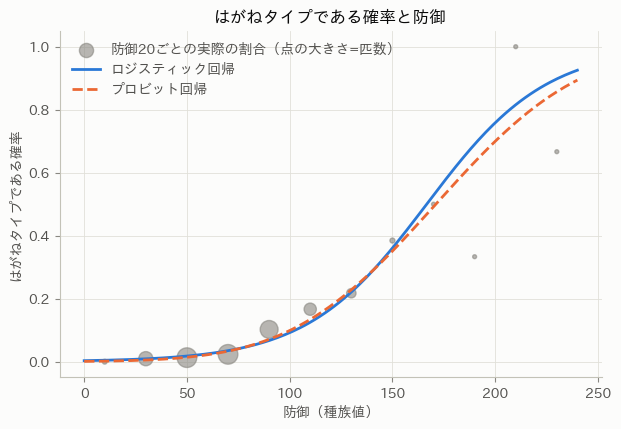

In [126]:
# プロビット回帰との比較
probit18 = smf.probit("性別不明 ~ 合計100 + 孵化千 + log重さ", d18).fit(disp=0)
cmp18 = pd.DataFrame({"ロジット係数": logit18.params, "プロビット係数": probit18.params,
                      "比（ロジット/プロビット）": logit18.params / probit18.params})
print(cmp18.round(4).to_string())
print(f"\n対数尤度: ロジット {logit18.llf:.2f}, プロビット {probit18.llf:.2f}")

# 平均での限界効果 dP/dx_j: ロジット π(1-π) beta_j, プロビット φ(x̄'beta) beta_j
xbar18 = X18.mean(axis=0)
p_l = 1 / (1 + np.exp(-xbar18 @ logit18.params.to_numpy()))
me_logit = p_l * (1 - p_l) * logit18.params.to_numpy()[1:]
me_probit = stats.norm.pdf(xbar18 @ probit18.params.to_numpy()) * probit18.params.to_numpy()[1:]
me_sm = probit18.get_margeff(at="mean").margeff
print(pd.DataFrame({"ロジット限界効果": me_logit, "プロビット限界効果": me_probit, "プロビット(sm)": me_sm},
                   index=["合計100", "孵化千", "log重さ"]).round(4).to_string())

# 1変数の例で確率曲線を比べる: はがねタイプか ~ 防御
lg_st = smf.logit("はがね ~ 防御", d18).fit(disp=0)
pb_st = smf.probit("はがね ~ 防御", d18).fit(disp=0)
print(f"\nはがね ~ 防御: ロジット 防御の係数 {lg_st.params['防御']:.4f}（オッズ比 {np.exp(lg_st.params['防御']):.4f}/1, "
      f"{np.exp(10 * lg_st.params['防御']):.3f}/10）, プロビット {pb_st.params['防御']:.4f}")

grid18 = pd.DataFrame({"防御": np.linspace(0, 240, 200)})
bins18 = pd.cut(d18["防御"], np.arange(0, 250, 20))
emp18 = d18.groupby(bins18, observed=True)["はがね"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter([b.mid for b in emp18.index], emp18["mean"], s=np.clip(emp18["size"], 8, 200),
           color=INK["muted"], alpha=0.6, label="防御20ごとの実際の割合（点の大きさ=匹数）")
ax.plot(grid18["防御"], lg_st.predict(grid18), color=PALETTE[0], label="ロジスティック回帰")
ax.plot(grid18["防御"], pb_st.predict(grid18), color=PALETTE[1], ls="--", label="プロビット回帰")
ax.set(title="はがねタイプである確率と防御", xlabel="防御（種族値）", ylabel="はがねタイプである確率")
ax.legend(loc="upper left")
plt.show()

**結果の読み方**
- 係数の比（ロジット / プロビット）は1.7〜2.2 で、目安の1.6〜1.8 よりやや大きい。性別不明の確率が0か1に近い行が多く、分布の裾の違い（ロジスティック分布の方が裾が重い）が効いているためと考えられる。
- 対数尤度はロジット $-202.3$、プロビット $-202.8$ とほぼ同じで、平均での限界効果も近い値になる（合計種族値が100高いと確率が約0.05上がる。孵化歩数だけは約0.013と約0.015でやや差がある）。どちらのリンクでも実質的な結論は同じである。
- はがねタイプ ~ 防御 では、防御が10高いとオッズが約1.41倍。2つの曲線は防御150付近まではほぼ重なり、防御の大きい側でロジットのほうが速く1に近づく。防御200以上のポケモンは少なく、そこでの曲線の違いはデータからは判別できない。

### 18.4 ポアソン回帰（人工的な設定）

**問い**：合計種族値が高いほど、倒したときにもらえる努力値は多いか。

**手法の要点**
- 計数 $Y_i\in\{0,1,2,\dots\}$ が平均 $\mu_i$ のポアソン分布に従い、$\log\mu_i=\boldsymbol x_i^\top\boldsymbol\beta$ とする（対数リンク）。$x_j$ が1増えると平均が $e^{\beta_j}$ 倍になる。
- ポアソン分布では $V[Y]=E[Y]$ なので、ピアソン統計量 $\sum_i(y_i-\hat\mu_i)^2/\hat\mu_i$ を残差自由度で割った値が1より大きければ過分散、小さければ過小分散を疑う。
- **この節の設定は人工的である**：努力値合計は1〜3しかとらないので、1を引いて0〜2の「計数」とみなした。上限があるのでポアソン分布の前提（上限なし・分散=平均）とは本来合わない。上限2の計数として自然な二項分布 $\mathrm{Bin}(2,\pi_i)$（ロジットリンク）の GLM とも比べる。

（→ py 18-4：ポアソン回帰、分散/平均の比較、二項分布 GLM との対数尤度・AIC・期待度数の比較）

In [127]:
# ポアソン回帰（人工的な設定）: 努力値合計−1（0〜2）~ 合計種族値
pois18 = smf.glm("努力値m1 ~ 合計100", d18, family=sm.families.Poisson()).fit()
print(pois18.summary().tables[1])
print(f"exp(係数) = {np.exp(pois18.params['合計100']):.3f}（合計種族値が100増えると平均が何倍になるか）")

# 過分散の確認: ピアソン χ² / 残差自由度（ポアソンなら1に近いはず）
mu18 = pois18.fittedvalues
pearson18 = ((d18["努力値m1"] - mu18) ** 2 / mu18).sum()
print(f"ピアソン χ² / 自由度 = {pearson18:.1f} / {pois18.df_resid:.0f} = {pearson18 / pois18.df_resid:.3f}")
print(f"標本平均 {d18['努力値m1'].mean():.3f}, 標本分散 {d18['努力値m1'].var():.3f}")

# 上限が2の計数なので、二項分布 Bin(2, π)・ロジットリンクの GLM とも比べる
binom18 = smf.glm("I(努力値m1 / 2) ~ 合計100", d18, family=sm.families.Binomial(),
                  var_weights=np.full(len(d18), 2.0)).fit()
k18 = d18["努力値m1"].to_numpy()
pi_b = binom18.fittedvalues.to_numpy()
ll_binom = np.sum(stats.binom.logpmf(k18, 2, pi_b))
ll_pois = np.sum(stats.poisson.logpmf(k18, mu18))
print(f"\n対数尤度（手計算）: ポアソン {ll_pois:.2f}（sm {pois18.llf:.2f}）, 二項(2) {ll_binom:.2f}")
print(f"AIC = -2 logL + 2×2: ポアソン {-2 * ll_pois + 4:.1f}, 二項(2) {-2 * ll_binom + 4:.1f}")

# 観測度数と期待度数
exp_pois = [stats.poisson.pmf(k, mu18).sum() for k in [0, 1, 2]] + [stats.poisson.sf(2, mu18).sum()]
exp_binom = [stats.binom.pmf(k, 2, pi_b).sum() for k in [0, 1, 2]] + [0.0]
pd.DataFrame({"観測": [*np.bincount(k18, minlength=3), 0], "ポアソン期待": exp_pois, "二項(2)期待": exp_binom},
             index=["0", "1", "2", "3以上"]).round(1)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8458      0.156    -18.283      0.000      -3.151      -2.541
合計100          0.5738      0.029     19.708      0.000       0.517       0.631
exp(係数) = 1.775（合計種族値が100増えると平均が何倍になるか）
ピアソン χ² / 自由度 = 306.6 / 918 = 0.334
標本平均 0.913, 標本分散 0.569

対数尤度（手計算）: ポアソン -873.74（sm -873.74）, 二項(2) -544.08
AIC = -2 logL + 2×2: ポアソン 1751.5, 二項(2) 1092.2


,観測,ポアソン期待,二項(2)期待
0,305,435.2,367.6
1,390,275.6,264.7
2,225,124.0,287.6
3以上,0,85.3,0.0


**結果の読み方**
- 係数は約0.57で、合計種族値が100高いと努力値合計−1の平均が約1.8倍になる（5%水準で有意）。合計種族値の高いポケモンほど多くの努力値を落とす傾向は明確である。
- ピアソン $\chi^2$/自由度は約0.33で、分散が平均よりずっと小さい **過小分散** である（標本全体でも平均0.91に対し分散0.57）。ポアソン分布は「3以上」に約85匹分の確率を割り振るが、実際には0匹である。標準誤差は過大（検定は保守的）になる。
- 二項分布 $\mathrm{Bin}(2,\pi)$ の GLM のほうが AIC がずっと小さい（約1092 対 約1752）。それでも「1」の度数を過小に予測しており、努力値合計はおおむね進化段階に応じて1・2・3と規則的に決まっているようなので（合計種族値の平均は努力値合計1・2・3でそれぞれ約310・460・570）、どちらの分布も近似にすぎない（順序ロジットなど、別のモデルがより自然である）。

### 18.5 逸脱度と尤度比検定

**問い**：18.2 のロジスティック回帰で、説明変数は全体として・個別に必要か。

**手法の要点**
- **逸脱度** $D=-2\{\ell(\hat{\boldsymbol\beta})-\ell_{\text{飽和}}\}$。飽和モデルは各観測に1つずつパラメータを持つモデルで、0/1データでは $\ell_{\text{飽和}}=0$ なので $D=-2\ell(\hat{\boldsymbol\beta})$。正規分布の線形回帰では $D$ は残差平方和に当たる。
- **尤度比検定**：モデル $M_0\subset M_1$（$M_1$ のほうがパラメータが $q$ 個多い）について、$H_0$：$M_0$ が正しい のもとで
$$G=D_0-D_1=2\{\ell(M_1)-\ell(M_0)\}\ \xrightarrow{d}\ \chi^2(q).$$
- 係数1個の検定では、ワルド統計量 $z^2$ も漸近的に $\chi^2(1)$ に従い、$n$ が大きければ尤度比検定と近い値になる。
- 当てはまりの目安として、マクファデンの疑似 $R^2=1-\ell(\hat{\boldsymbol\beta})/\ell_0$（$\ell_0$ は切片だけのモデルの対数尤度）がある。線形回帰の $R^2$ とは値の水準が異なる。

（→ py 18-5：逸脱度を定義式から計算して照合し、全体の尤度比検定と、log重さを除いたモデルとの尤度比検定・ワルド検定を行う）

In [128]:
# 逸脱度と尤度比検定（ロジスティック回帰: 性別不明）
# 0/1 データでは飽和モデルの対数尤度は 0 なので、逸脱度 D = -2 logL
glm18 = smf.glm("性別不明 ~ 合計100 + 孵化千 + log重さ", d18, family=sm.families.Binomial()).fit()
null18 = smf.glm("性別不明 ~ 1", d18, family=sm.families.Binomial()).fit()
p0 = y18.mean()
ll_null = len(y18) * (p0 * np.log(p0) + (1 - p0) * np.log(1 - p0))
print(f"逸脱度: モデル {-2 * ll18:.2f}（sm {glm18.deviance:.2f}）, 帰無モデル {-2 * ll_null:.2f}（sm {null18.deviance:.2f}）")

# 全体の検定 H0: 3つの係数がすべて 0
G18 = -2 * ll_null - (-2 * ll18)
print(f"尤度比統計量 G = {G18:.2f}, 自由度 3, p = {stats.chi2.sf(G18, 3):.3g}")

# 入れ子モデルの検定: log重さ を除いたモデルとの比較（自由度1）。ワルド検定とも比べる
red18 = smf.glm("性別不明 ~ 合計100 + 孵化千", d18, family=sm.families.Binomial()).fit()
G_w = red18.deviance - glm18.deviance
wald_w = (glm18.params["log重さ"] / glm18.bse["log重さ"]) ** 2
print(f"log重さ: 尤度比 G = {G_w:.2f}, p = {stats.chi2.sf(G_w, 1):.3g}; ワルド z^2 = {wald_w:.2f}, p = {stats.chi2.sf(wald_w, 1):.3g}（自由度1）")
print(f"マクファデンの疑似 R^2 = 1 - logL/logL0 = {1 - ll18 / ll_null:.3f}")

逸脱度: モデル 404.58（sm 404.58）, 帰無モデル 749.48（sm 749.48）
尤度比統計量 G = 344.90, 自由度 3, p = 1.9e-74
log重さ: 尤度比 G = 8.35, p = 0.00387; ワルド z^2 = 8.55, p = 0.00346（自由度1）
マクファデンの疑似 R^2 = 1 - logL/logL0 = 0.460


**結果の読み方**
- 帰無モデル（切片のみ）の逸脱度は約749、3変数のモデルは約405。尤度比統計量 $G\approx345$（自由度3）で、5%水準で「3つの係数がすべて0」は棄却される。
- log重さを除いたモデルとの比較では $G\approx8.4$（自由度1, p ≈ 0.004）、ワルド検定 $z^2\approx8.6$ とほぼ同じ値で、どちらでも5%水準で log重さは必要と判断される。
- 疑似 $R^2\approx0.46$。3つの変数で性別不明かどうかがかなりよく説明できる。ただし同じ進化系統のポケモンは性別の設定と種族値が似ているので、920行を独立な観測とみなした $p$ 値は小さすぎる可能性がある。

### まとめ

- 性別不明のポケモンは、合計種族値が高く、孵化歩数が多く、（他を固定すると）軽いほど多い。孵化歩数の効果が最も強く、タマゴが見つからないグループの設定を反映している。
- ロジットとプロビットは係数の大きさこそ違う（比は約1.7〜2.2）が、当てはまり・限界効果はほぼ同じで、結論は変わらない。
- ポアソン回帰を努力値に当てはめると過小分散（分散/平均 ≈ 0.33）が明らかで、上限のある計数にポアソン分布は合わない。分布の選び方は、データの生成の仕組みから考える必要がある。
- GLM の検定は逸脱度の差（尤度比検定）で統一的に行える。

## 第19章 回帰分析その他

### 章の概要

通常の線形回帰がそのままでは使えない状況のための回帰モデルを扱う。
- 目的：目的変数が上限・下限で打ち切られている場合（トービットモデル）、「イベントが起きるまでの時間」を扱う場合（生存時間解析）、関係が非線形な場合（ニューラルネットワーク）に、適切に推定・比較する。
- 考え方：打ち切りや時間の構造を尤度に正しく反映させる。ノンパラメトリック（カプラン・マイヤー）とセミパラメトリック（Cox 比例ハザード）の推定を使い分ける。
- つながり：第16章の線形回帰、第18章の最尤法・GLM の延長にある。ニューラルネットワークの予測性能の比較には第30章の交差検証を使う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 19.1 | トービットモデル（人工的な設定） | 捕獲率の上限255を打ち切りとみなすと、合計種族値の効果の推定はどう変わるか |
| 19.2 | 生存関数・ハザード・カプラン・マイヤー推定（人工的な設定） | 孵化歩数を「孵化までの時間」とみなすと、生存関数はどうなるか |
| 19.3 | 群別の KM 曲線とログランク検定 | タマゴグループによって孵化までの時間は違うか |
| 19.4 | Cox 比例ハザードモデル | 合計種族値・重さ・性別不明は、孵化の「速さ」とどう関係するか |
| 19.5 | ニューラルネットワーク | 非線形なモデルは線形回帰より予測がよいか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `捕獲率` | 量的（3〜255） | 19.1 の目的変数。255 が上限で、78匹が上限に張り付いている |
| `合計種族値` | 量的 | 19.1 の説明変数（100単位）。19.4 の共変量 |
| `孵化` | 量的（歩数、11種類の値） | 19.2〜19.4 の「生存時間」 |
| `タマゴ1` | 質的 | 19.3 の群（陸上・虫・ドラゴン） |
| `log重さ`, `雄率` | 量的 | 19.4 の共変量（`雄率` の欠損から性別不明フラグを作る） |
| `HP`〜`素早` | 量的 | 19.5 の説明変数 |

- **対象の行**：全920行（19.3 はタマゴ1が陸上・虫・ドラゴンの299匹）。
- **加工**：合計種族値を100で割る。性別不明（`雄率` が欠損）を0/1にする。
- **データの性質と注意点**：**この章の設定は人工的である**。捕獲率は値255を超えることができない設定値であって、「本当はもっと大きい潜在的な捕獲率」が観測されずに切り詰められているわけではない。孵化歩数も時間の計測値ではなく、1530〜30855歩の11種類の設定値しかなく、同順位が非常に多い。打ち切り（途中で観察が終わった個体）もない。手法の計算を確かめるための例として読むこと。

In [129]:
import statsmodels.api as sm
from scipy import optimize
from statsmodels.duration.hazard_regression import PHReg
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

print(f"捕獲率 = 255（上限）の行: {(df['捕獲率'] == 255).sum()} / {len(df)}")
print("孵化歩数の値と度数:", df["孵化"].value_counts().sort_index().to_dict())
df[["捕獲率", "合計種族値", "孵化", "log重さ"]].describe().T[["mean", "std", "min", "max"]].round(1)

捕獲率 = 255（上限）の行: 78 / 920
孵化歩数の値と度数: {1530: 3, 2805: 24, 4080: 151, 5355: 491, 6630: 66, 7905: 26, 8690: 2, 9180: 13, 10455: 47, 20655: 17, 30855: 80}


,mean,std,min,max
捕獲率,94.0,75.6,3.0,255.0
合計種族値,438.5,120.3,175.0,780.0
孵化,8052.2,7483.3,1530.0,30855.0
log重さ,3.2,1.6,-2.3,6.9


### 19.1 トービットモデル：捕獲率の上限255を右打ち切りとみなす

**問い**：捕獲率を合計種族値で回帰するとき、255に張り付いた値を「255以上」という情報として扱うと、推定はどう変わるか。

**手法の要点**
- 潜在変数 $y_i^*=\boldsymbol x_i^\top\boldsymbol\beta+\varepsilon_i$, $\varepsilon_i\overset{\text{iid}}{\sim}N(0,\sigma^2)$ を考え、観測されるのは $y_i=\min(y_i^*,c)$（ここでは上限 $c=255$、**右打ち切り**）とする。教科書の典型例（$y=\max(y^*,0)$、0で左打ち切り）と向きが逆なだけで、考え方は同じ。
- 尤度は、打ち切られていない点では密度、打ち切られた点では確率を使う。
$$L(\boldsymbol\beta,\sigma)=\prod_{y_i<c}\frac1\sigma\,\phi\!\left(\frac{y_i-\boldsymbol x_i^\top\boldsymbol\beta}{\sigma}\right)\ \prod_{y_i=c}\left\{1-\Phi\!\left(\frac{c-\boldsymbol x_i^\top\boldsymbol\beta}{\sigma}\right)\right\}$$
- 打ち切られた値を $c$ のまま OLS に入れると、上限付近の点が実際より小さく扱われて傾きが0の方向に偏る。打ち切られた点を除いて OLS をしても、残る点が選択されているので偏る。
- $\log L$ を数値最適化で最大化し、標準誤差は負の対数尤度のヘッセ行列の逆行列から求める。観測値の条件付き期待値は、$z=(c-\boldsymbol x^\top\boldsymbol\beta)/\sigma$ として
  $E[\min(y^*,c)\mid\boldsymbol x]=\boldsymbol x^\top\boldsymbol\beta\,\Phi(z)-\sigma\phi(z)+c\{1-\Phi(z)\}$。

（→ py 19-1：対数尤度を自作して `scipy.optimize.minimize` で推定し、全データの OLS・255を除いた OLS と比べる）

収束: True, 最大対数尤度 -4716.43, 解での勾配の最大絶対値 7.9e-04


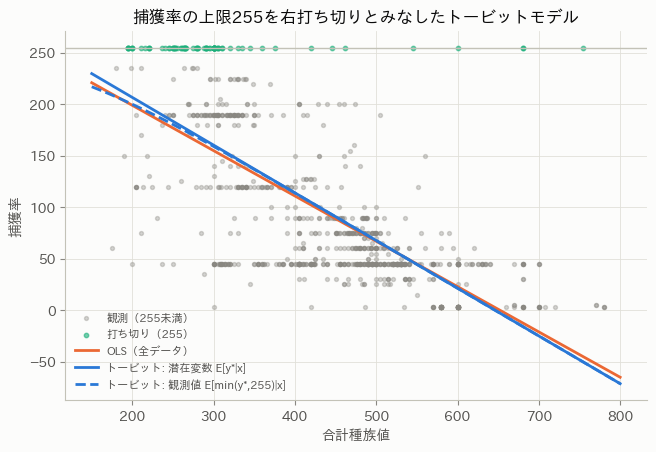

,OLS（全データ）,OLS（255を除く）,トービット,トービットSE
切片,286.944,244.836,299.274,7.397
合計種族値/100,-44.009,-36.749,-46.329,1.620
σ,53.919,43.256,58.204,1.456


In [130]:
# トービットモデル（人工的な設定）: 捕獲率 = min(y*, 255), y* = b0 + b1 × 合計種族値/100 + ε, ε ~ N(0, σ^2)
y19 = df["捕獲率"].to_numpy(float)
X19 = np.column_stack([np.ones(len(df)), df["合計種族値"].to_numpy(float) / 100])
cens19 = y19 >= 255          # 右打ち切り（上限255に張り付いている）
C_UP = 255.0


def tobit_negll(theta, X, y, cens, c=C_UP):
    """右打ち切りトービットモデルの負の対数尤度. theta = (beta, log σ)."""
    beta, sigma = theta[:-1], np.exp(theta[-1])
    mu = X @ beta
    ll_obs = stats.norm.logpdf((y[~cens] - mu[~cens]) / sigma) - np.log(sigma)   # 観測: 密度
    ll_cen = stats.norm.logsf((c - mu[cens]) / sigma)                           # 打ち切り: P(y* ≥ c)
    return -(ll_obs.sum() + ll_cen.sum())


ols19 = sm.OLS(y19, X19).fit()
ols19_unc = sm.OLS(y19[~cens19], X19[~cens19]).fit()
theta0 = np.r_[ols19.params, np.log(np.sqrt(ols19.mse_resid))]
res_tb = optimize.minimize(tobit_negll, theta0, args=(X19, y19, cens19), method="Nelder-Mead",
                          options={"xatol": 1e-8, "fatol": 1e-10, "maxiter": 20000})
beta_tb, sigma_tb = res_tb.x[:-1], np.exp(res_tb.x[-1])
# 標準誤差: 負の対数尤度の数値ヘッセ行列（中心差分）の逆行列


def num_hess(f, x, eps=1e-4):
    k = len(x); H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * eps, np.eye(k)[j] * eps
            H[i, j] = (f(x + e_i + e_j) - f(x + e_i - e_j) - f(x - e_i + e_j) + f(x - e_i - e_j)) / (4 * eps ** 2)
    return H


H_tb = num_hess(lambda t: tobit_negll(t, X19, y19, cens19), res_tb.x)
se_tb = np.sqrt(np.diag(np.linalg.inv(H_tb)))
se_sigma = sigma_tb * se_tb[-1]          # デルタ法: SE(σ) ≈ σ × SE(log σ)
grad_tb = optimize.approx_fprime(res_tb.x, tobit_negll, 1e-6, X19, y19, cens19)
print(f"収束: {res_tb.success}, 最大対数尤度 {-res_tb.fun:.2f}, 解での勾配の最大絶対値 {np.abs(grad_tb).max():.1e}")
tobit_tab = pd.DataFrame({
    "OLS（全データ）": [*ols19.params, np.sqrt(ols19.mse_resid)],
    "OLS（255を除く）": [*ols19_unc.params, np.sqrt(ols19_unc.mse_resid)],
    "トービット": [*beta_tb, sigma_tb],
    "トービットSE": [*se_tb[:2], se_sigma],
}, index=["切片", "合計種族値/100", "σ"])

# トービットでの「観測値の期待値」E[y|x] = E[min(y*, c)] と、潜在変数の期待値 x'β
xs19 = np.linspace(1.5, 8, 100)
mu_s = beta_tb[0] + beta_tb[1] * xs19
z_s = (C_UP - mu_s) / sigma_tb
Ey_obs = mu_s * stats.norm.cdf(z_s) - sigma_tb * stats.norm.pdf(z_s) + C_UP * stats.norm.sf(z_s)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(X19[~cens19, 1] * 100, y19[~cens19], s=8, alpha=0.35, color=INK["muted"], label="観測（255未満）")
ax.scatter(X19[cens19, 1] * 100, y19[cens19], s=10, alpha=0.6, color=PALETTE[2], label="打ち切り（255）")
ax.plot(xs19 * 100, ols19.params[0] + ols19.params[1] * xs19, color=PALETTE[1], label="OLS（全データ）")
ax.plot(xs19 * 100, mu_s, color=PALETTE[0], label="トービット: 潜在変数 E[y*|x]")
ax.plot(xs19 * 100, Ey_obs, color=PALETTE[0], ls="--", label="トービット: 観測値 E[min(y*,255)|x]")
ax.axhline(C_UP, color=INK["axis"], lw=1)
ax.set(title="捕獲率の上限255を右打ち切りとみなしたトービットモデル", xlabel="合計種族値", ylabel="捕獲率")
ax.legend(fontsize=8)
plt.show()
tobit_tab.round(3)

**結果の読み方**
- 合計種族値の係数（100あたり）は、トービット $-46.3$（SE 約1.6）、全データの OLS $-44.0$、255を除いた OLS $-36.7$。予想どおり、打ち切りを無視した OLS は傾きを0の方向に過小評価し、255の点を捨てるとさらに大きく偏る。
- ただしトービットと OLS の差は小さい。上限255に張り付いた78匹の多くは合計種族値が200〜300で、もともと予測値が200前後と上限に近くないためである（上限に張り付くのは「予測より大幅に捕まえやすい」ポケモンで、正規誤差の裾では説明しにくい）。
- 直線は合計種族値が650を超えると負の捕獲率を予測する。捕獲率には下限3もあり（76匹）、下側の打ち切りを加えた両側トービットや、捕獲率を変換したモデルのほうが自然である。

### 19.2 生存時間解析とカプラン・マイヤー推定

**問い**：孵化歩数を「孵化までの時間」$T$ とみなすと、生存関数・ハザードはどうなるか。

**手法の要点**
- **生存関数** $S(t)=P(T>t)=1-F(t)$。連続型で密度 $f$ をもつとき $S'(t)=-f(t)$。
- **ハザード関数** $h(t)=\lim_{\Delta\to0}P(t\le T<t+\Delta\mid T\ge t)/\Delta=f(t)/S(t)$。「$t$ まで孵化していない卵が、直後に孵化する瞬間的な率」。
- **累積ハザード関数** $H(t)=\int_0^t h(u)\,du=-\log S(t)$。したがって $S(t)=e^{-H(t)}$, $f(t)=h(t)e^{-H(t)}$。
- **カプラン・マイヤー推定**：イベントが起きた時刻 $t_1<\dots<t_k$ で、直前のリスク集合の大きさを $n_j$、イベント数を $d_j$ として
$$\hat S(t)=\prod_{j:\,t_j\le t}\left(1-\frac{d_j}{n_j}\right).$$
  離散時間のハザードの推定値は $d_j/n_j$、累積ハザードのネルソン・アーレン推定は $\hat H(t)=\sum_{t_j\le t}d_j/n_j$。
- 打ち切りがなければ $n_{j+1}=n_j-d_j$ なので積が打ち消し合い、$\hat S(t)=\#\{T_i>t\}/n$（経験生存関数 $=1-$経験分布関数）に一致する。

（→ py 19-2：KM 推定を numpy で実装し、経験生存関数と一致することを確認する）

In [131]:
# 生存時間解析（人工的な設定）: 孵化歩数を「孵化までの時間」とみなす。打ち切りはない
T19 = df["孵化"].to_numpy(float)
E19 = np.ones(len(df), dtype=int)       # イベント発生（1 = 孵化した）。全員1


def kaplan_meier(t, e):
    """カプラン・マイヤー推定. 各イベント時刻 t_j の n_j, d_j, S(t_j), ハザード d_j/n_j, 累積ハザードを返す."""
    times = np.unique(t[e == 1])
    n_risk = np.array([(t >= s).sum() for s in times])
    d = np.array([((t == s) & (e == 1)).sum() for s in times])
    S = np.cumprod(1 - d / n_risk)
    return pd.DataFrame({"時刻": times, "n_j（リスク集合）": n_risk, "d_j（イベント数）": d,
                         "S(t)": S, "h_j = d_j/n_j": d / n_risk,
                         "H(t)（ネルソン・アーレン）": np.cumsum(d / n_risk), "-log S(t)": -np.log(np.where(S > 0, S, np.nan))})


km19 = kaplan_meier(T19, E19)
# 打ち切りがなければ、KM は経験生存関数 S_n(t) = #{T_i > t} / n と一致する
S_emp = np.array([(T19 > s).mean() for s in km19["時刻"]])
print("KM と経験生存関数の最大差:", np.abs(km19["S(t)"].to_numpy() - S_emp).max())
print(f"孵化歩数の中央値（S(t) ≤ 0.5 となる最小の t）: {km19.loc[km19['S(t)'] <= 0.5, '時刻'].iloc[0]:.0f}")
km19.round(4)

KM と経験生存関数の最大差: 2.7755575615628914e-17
孵化歩数の中央値（S(t) ≤ 0.5 となる最小の t）: 5355


,時刻,n_j（リスク集合）,d_j（イベント数）,S(t),h_j = d_j/n_j,H(t)（ネルソン・アーレン）,-log S(t)
0,1530.0,920,3,0.9967,0.0033,0.0033,0.0033
1,2805.0,917,24,0.9707,0.0262,0.0294,0.0298
2,4080.0,893,151,0.8065,0.1691,0.1985,0.2150
3,5355.0,742,491,0.2728,0.6617,0.8603,1.2989
4,6630.0,251,66,0.2011,0.2629,1.1232,1.6040
5,7905.0,185,26,0.1728,0.1405,1.2637,1.7555
6,8690.0,159,2,0.1707,0.0126,1.2763,1.7681
7,9180.0,157,13,0.1565,0.0828,1.3591,1.8546
8,10455.0,144,47,0.1054,0.3264,1.6855,2.2497
9,20655.0,97,17,0.0870,0.1753,1.8608,2.4423


**結果の読み方**
- KM 推定と経験生存関数は数値誤差の範囲で一致する（打ち切りがないため）。
- 5355歩で491匹（リスク集合742匹の約66%）が一度に「孵化」し、$\hat S$ は0.81から0.27へ落ちる。中央値は5355歩。30855歩では残り80匹すべてが孵化して $\hat S=0$ になる。
- ネルソン・アーレン推定 $\hat H(t)$ と $-\log\hat S(t)$ は、イベントが少ない時点ではほぼ等しいが、同時に多数が孵化する時点では差が開く（$-\log(1-x)\ge x$）。最後の時刻では $\hat S=0$ なので $-\log\hat S$ は定義できない。

### 19.3 タマゴグループ別の比較とログランク検定

**問い**：タマゴグループ（陸上・虫・ドラゴン）によって、孵化までの時間の分布は異なるか。

**手法の要点**
- 群ごとに KM 曲線を描いて比べる。
- **ログランク検定**：$H_0$：全群の生存関数が等しい。各イベント時刻 $t_j$ で、群 $g$ のイベント数の観測値 $O_{gj}$ と、$H_0$ のもとでの期待値 $E_{gj}=d_j\,n_{gj}/n_j$ の差を合計し、超幾何分布に基づく分散共分散行列 $V$ で標準化する。$k$ 群のとき、$(\boldsymbol O-\boldsymbol E)$ の $k-1$ 成分による二次形式 $(\boldsymbol O-\boldsymbol E)^\top V^{-1}(\boldsymbol O-\boldsymbol E)$ が $H_0$ のもとで漸近的に $\chi^2(k-1)$ に従う。
- 3群はデータの多い陸上・虫と、孵化歩数の長いドラゴンを選んだ（図の見やすさのため3群に限定）。

（→ py 19-3：ログランク検定を numpy で実装し、3群の KM 曲線と累積ハザードを描く）

ログランク検定（陸上・虫・ドラゴン）: χ² = 73.76, 自由度 2, p = 9.6e-17
      size   median          mean
タマゴ1                             
ドラゴン    14  10455.0  10272.857143
虫       79   4080.0   4919.240506
陸上     206   5355.0   5300.728155


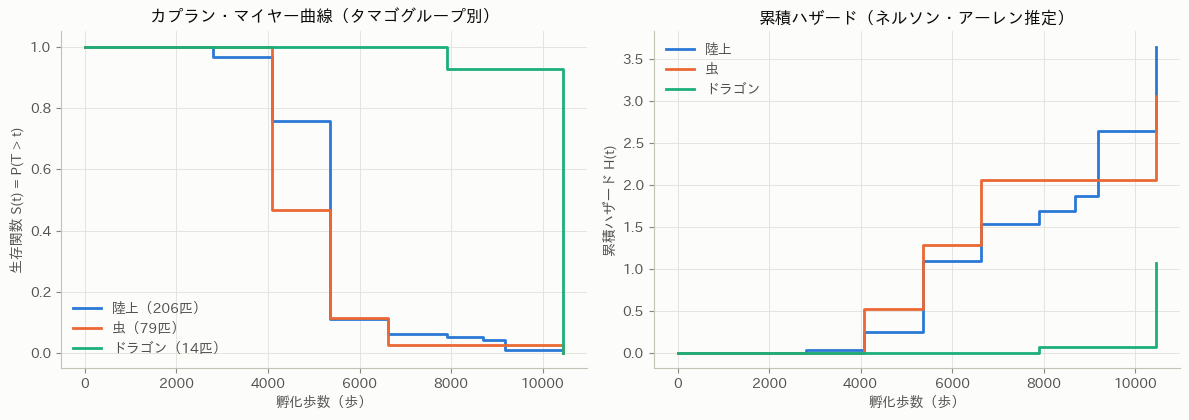

In [132]:
# タマゴグループ（タマゴ1）別の KM 曲線と、ログランク検定（numpy で実装）
groups19 = ["陸上", "虫", "ドラゴン"]
g19 = df["タマゴ1"].astype(str)
sel19 = g19.isin(groups19).to_numpy()
Tg, Gg = T19[sel19], g19[sel19].to_numpy()


def logrank(t, g, levels):
    """k 群のログランク検定（打ち切りなし・同順位あり）. 統計量 ~ χ²(k-1)."""
    times = np.unique(t)
    k = len(levels)
    O_E = np.zeros(k); V = np.zeros((k, k))
    for s in times:
        at_risk = np.array([((t >= s) & (g == lv)).sum() for lv in levels])
        d_g = np.array([((t == s) & (g == lv)).sum() for lv in levels])
        n, dd = at_risk.sum(), d_g.sum()
        if n < 2:
            continue
        O_E += d_g - dd * at_risk / n
        V += dd * (n - dd) / (n - 1) * (np.diag(at_risk / n) - np.outer(at_risk, at_risk) / n ** 2)
    stat = O_E[:-1] @ np.linalg.solve(V[:-1, :-1], O_E[:-1])
    return stat, k - 1, stats.chi2.sf(stat, k - 1)


lr_stat, lr_df, lr_p = logrank(Tg, Gg, groups19)
print(f"ログランク検定（{'・'.join(groups19)}）: χ² = {lr_stat:.2f}, 自由度 {lr_df}, p = {lr_p:.3g}")
print(df[sel19].groupby(g19[sel19], observed=True)["孵化"].agg(["size", "median", "mean"]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for lv, col in zip(groups19, PALETTE):
    km_g = kaplan_meier(Tg[Gg == lv], np.ones((Gg == lv).sum(), dtype=int))
    tt = np.r_[0, km_g["時刻"]]
    axes[0].step(tt, np.r_[1, km_g["S(t)"]], where="post", color=col, label=f"{lv}（{(Gg == lv).sum()}匹）")
    axes[1].step(tt, np.r_[0, km_g["H(t)（ネルソン・アーレン）"]], where="post", color=col, label=lv)
axes[0].set(title="カプラン・マイヤー曲線（タマゴグループ別）", xlabel="孵化歩数（歩）", ylabel="生存関数 S(t) = P(T > t)")
axes[1].set(title="累積ハザード（ネルソン・アーレン推定）", xlabel="孵化歩数（歩）", ylabel="累積ハザード H(t)")
axes[0].legend(); axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 中央値は虫4080歩・陸上5355歩・ドラゴン10455歩。ログランク検定は $\chi^2\approx73.8$（自由度2）で、5%水準で「3群の生存関数が等しい」は棄却される。
- 虫グループは4080歩で約半数が孵化し、陸上より早い。ドラゴングループは14匹中13匹が10455歩で、ほぼ全員が長い。
- 累積ハザードの曲線は交差しており（虫と陸上）、群間でハザードの比が一定という比例ハザード性は成り立っていない。ログランク検定は比例ハザードのもとで検出力が高い検定なので、この場合は「どこかで分布が違う」ことだけを読み取る。

### 19.4 Cox 比例ハザードモデル

**問い**：合計種族値・重さ・性別不明は、孵化のハザード（速さ）とどう関係するか。

**手法の要点**
- $h(t\mid\boldsymbol x)=h_0(t)\exp(\beta_1x_1+\dots+\beta_px_p)$。基準ハザード $h_0(t)$ の形は仮定しない（セミパラメトリック）。
- 2つの個体のハザードの比 $h(t\mid\boldsymbol x)/h(t\mid\boldsymbol x')=\exp\{(\boldsymbol x-\boldsymbol x')^\top\boldsymbol\beta\}$ は $t$ によらない（**比例ハザード性**）。$x_j$ が1増えるとハザードは $e^{\beta_j}$ 倍（ハザード比）。ハザード比が1より小さいほど孵化が遅い。
- $\boldsymbol\beta$ は $h_0$ を含まない **部分尤度** を最大化して推定する。同じ時刻に複数のイベントがある（同順位）ときは Breslow 法や Efron 法で近似する。ここでは同順位が極端に多いので Efron 法を使う。
- 比例ハザード性の簡易チェックとして、時間を前半・後半に分けてハザード比を推定し、大きく違わないかを見る。

（→ py 19-4：statsmodels の `PHReg` で推定し、ハザード比と信頼区間を表示する。5355歩の前後でハザード比を比べる）

In [133]:
# Cox 比例ハザードモデル: h(t|x) = h0(t) exp(x'β)。同順位が多いので Efron 法
cox_cols = ["合計100", "log重さ", "性別不明"]
dcox = df.assign(合計100=df["合計種族値"] / 100, 性別不明=df["雄率"].isna().astype(int))
cox19 = PHReg(dcox["孵化"].to_numpy(float), dcox[cox_cols].to_numpy(float),
              status=np.ones(len(dcox)), ties="efron").fit()
cox_tab = pd.DataFrame({"係数": cox19.params, "標準誤差": cox19.bse, "z": cox19.params / cox19.bse,
                        "p値": cox19.pvalues, "ハザード比": np.exp(cox19.params),
                        "95%CI下限": np.exp(cox19.params - 1.96 * cox19.bse),
                        "95%CI上限": np.exp(cox19.params + 1.96 * cox19.bse)}, index=cox_cols)
print(f"部分対数尤度 {cox19.llf:.2f}")

# 比例ハザード性の簡易チェック: 孵化歩数の短い半分と長い半分で、合計種族値のハザード比を比べる
# （時点 t0 で分割し、t0 以降は t0 まで生き残った行だけで再推定する）
t0 = 5355
early = PHReg(np.minimum(dcox["孵化"], t0).to_numpy(float), dcox[cox_cols].to_numpy(float),
              status=(dcox["孵化"] < t0).astype(int).to_numpy(), ties="efron").fit()
late_mask = (dcox["孵化"] >= t0).to_numpy()
late = PHReg(dcox.loc[late_mask, "孵化"].to_numpy(float), dcox.loc[late_mask, cox_cols].to_numpy(float),
             status=np.ones(late_mask.sum()), ties="efron").fit()
print(f"合計100 のハザード比: 全期間 {np.exp(cox19.params[0]):.3f}, t < {t0} {np.exp(early.params[0]):.3f}, "
      f"t ≥ {t0}（{late_mask.sum()}匹） {np.exp(late.params[0]):.3f}")
cox_tab.round(4)

部分対数尤度 -5173.47
合計100 のハザード比: 全期間 0.749, t < 5355 0.660, t ≥ 5355（742匹） 0.769


,係数,標準誤差,z,p値,ハザード比,95%CI下限,95%CI上限
合計100,-0.2894,0.0365,-7.9387,0.0000,0.7487,0.6971,0.8042
log重さ,-0.0401,0.0247,-1.6221,0.1048,0.9607,0.9153,1.0084
性別不明,-1.2975,0.1165,-11.1388,0.0000,0.2732,0.2174,0.3433


**結果の読み方**
- 合計種族値が100高いとハザード比は約0.75（95%CI 0.70〜0.80）で、孵化が遅い（孵化歩数が多い）。性別不明のハザード比は約0.27 と非常に小さく、性別不明のポケモンは孵化歩数が長い。log重さは5%水準で有意でない（p ≈ 0.10）。
- 合計種族値のハザード比は、5355歩より前が約0.66、以後が約0.77 で、比例ハザード性からやや外れている。時間の値が11種類しかなく同順位が多いこともあり、Cox モデルは近似的な要約と考える。
- 実際には孵化歩数はタマゴグループや進化系統ごとに設定された値であり、「種族値が高いから孵化が遅くなる」という因果の関係ではない。

### 19.5 ニューラルネットワーク

**問い**：種族値6項目から経験値・捕獲率を予測するとき、非線形なニューラルネットワークは線形回帰より予測がよいか。

**手法の要点**
- 1つのユニットは入力 $\boldsymbol x$ に重み $\boldsymbol w$ とバイアス $b$ をかけた $\boldsymbol w^\top\boldsymbol x+b$ に活性化関数 $f$ を施した $f(\boldsymbol w^\top\boldsymbol x+b)$ を出力する。ユニットを層状に並べたものが多層パーセプトロン（MLP）で、隠れ層1層・$m$ ユニットの回帰なら
$$\hat y=b^{(2)}+\sum_{k=1}^m w^{(2)}_k\,f\!\left(\boldsymbol w_k^{(1)\top}\boldsymbol x+b^{(1)}_k\right).$$
- 活性化関数が非線形（ここでは ReLU $f(u)=\max(u,0)$）なので、区分的に線形な曲がった関係を表せる。$f$ が恒等関数なら線形回帰と同じになる。
- パラメータが多く過学習しやすいので、重みの L2 罰則（`alpha`）をかけ、予測性能は学習に使っていないデータで評価する（5分割交差検証の RMSE。第30章）。入力は標準化する。

（→ py 19-5：隠れ層16ユニットの MLP と線形回帰を、5分割交差検証の RMSE で比べ、合計種族値に対する捕獲率の予測曲線を描く）

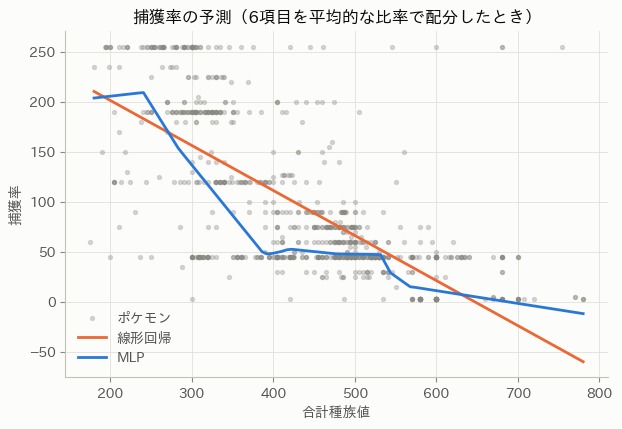

CV RMSE  fold間の標準偏差
目的変数 モデル                                  
経験値  線形回帰                28.97        6.77
     MLP（隠れ層16, ReLU）    28.34        3.92
捕獲率  線形回帰                54.06        6.08
     MLP（隠れ層16, ReLU）    54.60        4.91

In [134]:
# ニューラルネットワーク（MLP）と線形回帰の比較: 5分割交差検証の RMSE
kf19 = KFold(n_splits=5, shuffle=True, random_state=SEED)
models19 = {
    "線形回帰": make_pipeline(StandardScaler(), LinearRegression()),
    "MLP（隠れ層16, ReLU）": make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(16,), activation="relu", solver="lbfgs", alpha=1e-2, max_iter=5000,
        random_state=SEED)),
}
rows19 = []
for target in ["経験値", "捕獲率"]:
    for name, mdl in models19.items():
        sc = -cross_val_score(mdl, df[STATS], df[target], cv=kf19, scoring="neg_root_mean_squared_error")
        rows19.append({"目的変数": target, "モデル": name, "CV RMSE": sc.mean(), "fold間の標準偏差": sc.std()})
nn_tab = pd.DataFrame(rows19).set_index(["目的変数", "モデル"])

# 合計種族値に対する予測（他の配分は平均的な形で比例させる）: 捕獲率
mlp_c = models19["MLP（隠れ層16, ReLU）"].fit(df[STATS], df["捕獲率"])
lin_c = make_pipeline(StandardScaler(), LinearRegression()).fit(df[STATS], df["捕獲率"])
share = df[STATS].mean() / df[STATS].mean().sum()
tot_grid = np.linspace(180, 780, 100)
grid_X = pd.DataFrame(np.outer(tot_grid, share), columns=STATS)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["合計種族値"], df["捕獲率"], s=8, alpha=0.3, color=INK["muted"], label="ポケモン")
ax.plot(tot_grid, lin_c.predict(grid_X), color=PALETTE[1], label="線形回帰")
ax.plot(tot_grid, mlp_c.predict(grid_X), color=PALETTE[0], label="MLP")
ax.set(title="捕獲率の予測（6項目を平均的な比率で配分したとき）", xlabel="合計種族値", ylabel="捕獲率")
ax.legend()
plt.show()
nn_tab.round(2)

**結果の読み方**
- 経験値の CV RMSE は線形回帰 約29.0、MLP 約28.3。捕獲率は線形回帰 約54.1、MLP 約54.6。fold 間の標準偏差（4〜7）に比べて差は小さく、この設定では MLP の優位ははっきりしない。
- 予測曲線を見ると、MLP は捕獲率を「低い合計種族値で約200、中程度で約45、高いと約0〜15」という階段状に近い形で近似している。捕獲率が45・190 など少数の値に集中している設定値であることを反映しているが、個々のポケモンのばらつきが大きいので、平均的な予測誤差は線形回帰とほとんど変わらない。
- MLP は乱数の初期値・ユニット数・罰則の強さで結果が変わり、係数の解釈もできない。予測がほぼ同じなら、解釈しやすい線形回帰を選ぶのが妥当である。

### まとめ

- 捕獲率の上限255を右打ち切りとみなしたトービットモデルでは、合計種族値の効果は OLS よりやや強く（100あたり $-46$ 対 $-44$）推定された。打ち切り点を除いた OLS は大きく偏る。
- 打ち切りのない生存時間データでは、カプラン・マイヤー推定は経験生存関数に一致する。タマゴグループで孵化歩数の分布は異なり（ログランク検定で有意）、Cox モデルでは合計種族値が高い・性別不明のポケモンほど孵化が遅い。
- ニューラルネットワークは線形回帰と比べて予測誤差をほとんど改善しなかった。
- この章の例はどれも設定値に手法を当てはめた人工的なもので、打ち切り・時間・誤差の生成の仕組みが本来の前提とは異なる。手法の計算と解釈の練習として読むこと。

## 第20章 分散分析と実験計画法

### 章の概要

分散分析は、応答の総変動を「因子で説明できる部分」と「誤差」に分解し、その比で**群の母平均に差があるか**を調べる手法である。
名前に「分散」とあるが、検定しているのは母分散の違いではなく**母平均の違い**である（旧ノートブックの「分散に差がある」というコメントは誤り）。
実験計画法は、分散分析で因果的な結論を出せるように、実験のやり方（処理の割り付け方）を設計する方法論である。
第11章の2群の平均の比較（t検定）を3群以上・複数の因子へ広げたもので、第16章の線形回帰モデルでダミー変数を説明変数にした場合と同じモデルになる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 20.1 | フィッシャーの3原則 | ポケモンのデータは「実験」と言えるか |
| 20.2 | 一元配置分散分析 | タイプ1によって合計種族値の平均は異なるか |
| 20.3 | 等分散性の検定 | タイプ1ごとの合計種族値のばらつきは等しいとみなせるか |
| 20.4 | 多重比較（Tukey, Bonferroni） | どのタイプの組に差があるか |
| 20.5 | 二元配置分散分析 | タイプ1と成長の速さの効果、その交互作用はあるか |
| 20.6 | 乱塊法 | 世代をブロックとみなすと、タイプの効果はどう評価されるか |
| 20.7 | 直交表 | L8直交表はどのような構造をしているか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（連続とみなす） | 応答変数。ほぼ左右対称 |
| `タイプ1` | 質的（18水準） | 因子 A |
| `成長` | 質的（7水準） | 二元配置の因子 B（主な3水準 `100万`・`106万`・`125万` だけ使う） |
| `世代` | 質的（1〜7） | 乱塊法のブロック |

- **対象の行**：20.2〜20.4 は全920行。20.5 は件数の多い6タイプ（みず・ノーマル・くさ・むし・エスパー・ほのお）かつ成長が3水準のいずれかである464行。20.6 は第1〜7世代のすべてに1匹以上いる12タイプ。
- **加工**：20.6 では（タイプ1, 世代）ごとの合計種族値の平均を1つの観測値とする。
- **データの性質と注意点**：全ポケモンを仮想母集団からの標本とみなして検定する。同じ進化系統のポケモン（例: フシギダネ・フシギソウ・フシギバナ）は同じタイプになりやすく、誤差の独立性は厳密には成り立たない。ひこうタイプ1は4匹しかいない。

（→ py 20-0：タイプ1ごとの件数・平均・標準偏差）

In [135]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway

fmt4 = lambda v: f"{v:.4g}"  # 表示用（p値が 0.0 に丸められないように有効数字4桁）

# タイプ1ごとの件数・平均・標準偏差（合計種族値）
aov_summary = (df.groupby("タイプ1", observed=True)["合計種族値"]
               .agg(件数="size", 平均="mean", 標準偏差="std")
               .sort_values("件数", ascending=False))
print(f"全体: n = {len(df)}, 平均 = {df['合計種族値'].mean():.1f}, 標準偏差 = {df['合計種族値'].std():.1f}")
aov_summary.round(1)

全体: n = 920, 平均 = 438.5, 標準偏差 = 120.3


,件数,平均,標準偏差
タイプ1,,,
みず,124,432.5,115.4
ノーマル,110,405.7,114.5
くさ,83,420.0,109.7
むし,78,386.3,119.7
エスパー,67,491.0,146.4
ほのお,59,458.7,106.1
いわ,55,454.7,104.9
でんき,50,453.1,104.6
ゴースト,37,441.5,105.4


### 20.1 フィッシャーの3原則と観察データ

**問い**：ポケモンのデータで分散分析を行ったとき、その結果を「タイプが種族値を決める効果」と解釈してよいか。

実験計画法では、次の**フィッシャーの3原則**を満たすように実験を設計する。

| 原則 | 内容 | 目的 |
|---|---|---|
| 反復 | 同じ処理を複数の実験単位に行う | 誤差分散 $\sigma^2$ を推定できるようにする |
| 無作為化 | 処理を実験単位にランダムに割り付ける | 制御できない要因による偏り（系統誤差）を偶然誤差に変える |
| 局所管理 | 条件のそろった実験単位をブロックにまとめ、ブロック内で比較する | ブロック間の違いを誤差から取り除き、精度を上げる |

反復と無作為化を満たす計画を**完全無作為化法**、3原則すべてを満たす計画を**乱塊法**という。

**本データは観察データであり、実験計画の前提を満たさない。**
タイプはポケモンに無作為に割り付けられたものではなく、ゲームの設計者が種族値と同時に決めたものである。
したがって、この章の分散分析は「タイプ間で合計種族値の平均が異なるか」を記述的に確かめるものであり、
「タイプを変えると種族値が変わる」という因果の主張はできない。
20.6 で世代を「ブロック」と呼ぶのも、乱塊法の計算の構造を学ぶための見立てであり、ブロック内で処理を無作為に割り付けたわけではない。

### 20.2 一元配置分散分析

**問い**：タイプ1（$a=18$ 水準）によって、合計種族値の母平均は異なるか。

**手法の要点**
- モデル：第 $i$ 水準の $j$ 番目の観測値を $Y_{ij}$ とし（$i=1,\dots,a$, $j=1,\dots,n_i$, $n=\sum_i n_i$）、
  $$Y_{ij}=\mu+\alpha_i+\varepsilon_{ij},\qquad \varepsilon_{ij}\overset{\text{i.i.d.}}{\sim}N(0,\sigma^2),\qquad \sum_{i=1}^a n_i\alpha_i=0 .$$
- 仮説：$H_0:\alpha_1=\dots=\alpha_a=0$（全水準の母平均が等しい）、$H_1$：少なくとも1つの $\alpha_i\neq 0$。
- 平方和の分解：水準平均を $\bar Y_{i\cdot}$、全体平均を $\bar Y_{\cdot\cdot}$ として
  $$\underbrace{\sum_{i}\sum_{j}(Y_{ij}-\bar Y_{\cdot\cdot})^2}_{S_T}=\underbrace{\sum_i n_i(\bar Y_{i\cdot}-\bar Y_{\cdot\cdot})^2}_{S_A}+\underbrace{\sum_i\sum_j(Y_{ij}-\bar Y_{i\cdot})^2}_{S_E}.$$
- 分散分析表：

| 要因 | 平方和 | 自由度 | 平均平方 | F |
|---|---|---|---|---|
| 水準間 A | $S_A$ | $a-1$ | $V_A=S_A/(a-1)$ | $V_A/V_E$ |
| 誤差 E | $S_E$ | $n-a$ | $V_E=S_E/(n-a)$ | |
| 総 T | $S_T$ | $n-1$ | | |

- $H_0$ のもとで $F=V_A/V_E\sim F(a-1,\,n-a)$。$F$ が大きいほど $H_0$ に反する（右片側検定）。
- 前提条件：誤差の独立性・正規性・等分散性。合計種族値はほぼ左右対称で、群の大きさも大きいので正規性の破れの影響は小さい。等分散性は 20.3 で確かめる。

（→ py 20-2：平方和を定義式から計算して分散分析表を作り、statsmodels・scipy と照合する）

In [136]:
# 一元配置分散分析: 平方和の分解 S_T = S_A + S_E を定義式から計算する
y_all = df["合計種族値"].astype(float)
grp_all = df.groupby("タイプ1", observed=True)["合計種族値"]
n_i = grp_all.size()
mean_i = grp_all.mean()
grand_mean = y_all.mean()
n_total, a_levels = len(y_all), len(n_i)

S_T = ((y_all - grand_mean) ** 2).sum()
S_A = (n_i * (mean_i - grand_mean) ** 2).sum()
S_E = ((y_all - grp_all.transform("mean")) ** 2).sum()
df_A, df_E = a_levels - 1, n_total - a_levels
F_A = (S_A / df_A) / (S_E / df_E)
p_A = stats.f.sf(F_A, df_A, df_E)

aov_table = pd.DataFrame({
    "平方和": [S_A, S_E, S_T],
    "自由度": [df_A, df_E, n_total - 1],
    "平均平方": [S_A / df_A, S_E / df_E, np.nan],
    "F": [F_A, np.nan, np.nan],
    "p値": [p_A, np.nan, np.nan],
}, index=["水準間 A（タイプ1）", "誤差 E", "総 T"])
print("手計算の分散分析表")
print(aov_table.to_string(float_format=fmt4))
print(f"\nS_A + S_E - S_T = {S_A + S_E - S_T:.2e}（0 になれば分解が成立）")
print(f"F の5%棄却点 F_{{0.05}}({df_A}, {df_E}) = {stats.f.ppf(0.95, df_A, df_E):.3f}")
print(f"決定係数 η² = S_A / S_T = {S_A / S_T:.3f}")

# statsmodels・scipy と照合
ow_model = smf.ols("合計種族値 ~ C(タイプ1)", data=df).fit()
print("\nstatsmodels anova_lm")
print(sm.stats.anova_lm(ow_model, typ=1).to_string(float_format=fmt4))
f_sp, p_sp = stats.f_oneway(*[g.to_numpy() for _, g in grp_all])
print(f"\nscipy f_oneway: F = {f_sp:.4f}, p = {p_sp:.3g}")

手計算の分散分析表
                  平方和  自由度      平均平方     F       p値
水準間 A（タイプ1）  1.18e+06   17 6.941e+04 5.162 6.18e-11
誤差 E        1.213e+07  902 1.344e+04   NaN      NaN
総 T         1.331e+07  919       NaN   NaN      NaN

S_A + S_E - S_T = 0.00e+00（0 になれば分解が成立）
F の5%棄却点 F_{0.05}(17, 902) = 1.634
決定係数 η² = S_A / S_T = 0.089

statsmodels anova_lm
          df    sum_sq   mean_sq     F   PR(>F)
C(タイプ1)   17  1.18e+06 6.941e+04 5.162 6.18e-11
Residual 902 1.213e+07 1.344e+04   NaN      NaN

scipy f_oneway: F = 5.1623, p = 6.18e-11


$V_E=\hat\sigma^2$ は誤差分散 $\sigma^2$ の不偏推定量なので、第 $i$ 水準の母平均 $\mu+\alpha_i$ の95%信頼区間は
$$\bar Y_{i\cdot}\pm t_{0.025}(n-a)\sqrt{\hat\sigma^2/n_i}$$
で求められる（全水準で共通の $\hat\sigma^2$ を使う）。

（→ py 20-2b：タイプ1ごとの平均と95%信頼区間の図）

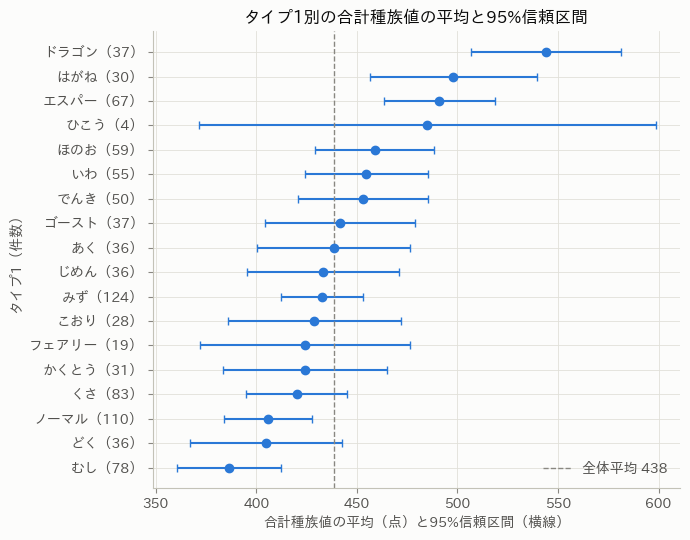

In [137]:
# 各水準の母平均の95%信頼区間（誤差分散の推定値 σ̂² = S_E/(n-a) を共通に使う）
sigma2_hat = S_E / df_E
t_crit = stats.t.ppf(0.975, df_E)
ci_half = t_crit * np.sqrt(sigma2_hat / n_i)
ci_order = mean_i.sort_values().index

fig, ax = plt.subplots(figsize=(7, 5.5))
ypos = np.arange(len(ci_order))
ax.errorbar(mean_i[ci_order], ypos, xerr=ci_half[ci_order], fmt="o",
            color=PALETTE[0], ecolor=PALETTE[0], elinewidth=1.5, capsize=3)
ax.axvline(grand_mean, color=INK["muted"], linestyle="--", linewidth=1, label=f"全体平均 {grand_mean:.0f}")
ax.set_yticks(ypos, [f"{t}（{n_i[t]}）" for t in ci_order])
ax.set(title="タイプ1別の合計種族値の平均と95%信頼区間",
       xlabel="合計種族値の平均（点）と95%信頼区間（横線）", ylabel="タイプ1（件数）")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**結果の読み方**
- 手計算の $S_A+S_E$ は $S_T$ と一致し、F値は statsmodels・scipy と同じ $F\approx5.16$（自由度 $(17,\,902)$）、$p\approx6\times10^{-11}$ になった。有意水準5%で「タイプ1によって合計種族値の母平均が異なる」と判断する。
- ただし $\eta^2=S_A/S_T\approx0.09$ で、合計種族値の変動のうちタイプ1で説明できるのは1割弱にすぎない。$n=920$ と大きいため、小さな差でも有意になる。
- 信頼区間の図では、ドラゴン（平均約544）が最も高く、むし（約386）・どく（約405）・ノーマル（約406）が低い。ひこうは4匹しかいないため区間が非常に広い。
- 20.1 のとおり観察データなので、「タイプが種族値の差を生む」とまでは言えない。

### 20.3 等分散性の検定

**問い**：タイプ1ごとの合計種族値の母分散は等しいとみなせるか（20.2 の前提の確認）。

**手法の要点**
- 仮説：$H_0:\sigma_1^2=\dots=\sigma_a^2$、$H_1$：少なくとも1組が異なる。
- **Bartlett 検定**：各群の不偏分散 $s_i^2$ と $\hat\sigma^2=S_E/(n-a)$ から
  $$\frac{1}{C}\Bigl\{(n-a)\log\hat\sigma^2-\sum_i(n_i-1)\log s_i^2\Bigr\},\qquad C=1+\frac{1}{3(a-1)}\Bigl(\sum_i\frac{1}{n_i-1}-\frac{1}{n-a}\Bigr)$$
  を作ると、$H_0$ のもとで近似的に $\chi^2(a-1)$ に従う。正規性が崩れると有意になりやすい（正規性にも反応してしまう）。
- **Levene 検定**：各観測値の群の中心からの絶対偏差 $|Y_{ij}-\tilde Y_{i}|$ に一元配置分散分析を行い、$F(a-1,\,n-a)$ で判定する。中心に中央値を使うもの（Brown–Forsythe 検定）は正規性の破れに頑健である。
- 等分散が疑わしい場合は、等分散を仮定しない **Welch の分散分析** を併用する。

（→ py 20-3：Bartlett（手計算と照合）、Levene、Welch の分散分析）

In [138]:
# 等分散性の検定（帰無仮説: 全水準の母分散が等しい）
groups_list = [g.to_numpy() for _, g in grp_all]
bt = stats.bartlett(*groups_list)
lv_mean = stats.levene(*groups_list, center="mean")
lv_med = stats.levene(*groups_list, center="median")
print(f"Bartlett 検定         : 統計量 = {bt.statistic:.3f}（近似 χ²({a_levels - 1})）, p = {bt.pvalue:.4f}")
print(f"Levene 検定（平均中心）: F = {lv_mean.statistic:.3f}（F({df_A}, {df_E})）, p = {lv_mean.pvalue:.4f}")
print(f"Levene 検定（中央値中心, Brown-Forsythe）: F = {lv_med.statistic:.3f}, p = {lv_med.pvalue:.4f}")

# Bartlett 統計量を定義式から計算して照合
s2_i = grp_all.var()
M_b = df_E * np.log(sigma2_hat) - ((n_i - 1) * np.log(s2_i)).sum()
C_b = 1 + (1 / (3 * (a_levels - 1))) * ((1 / (n_i - 1)).sum() - 1 / df_E)
print(f"Bartlett（手計算）      : {M_b / C_b:.3f}")

# 等分散を仮定しない Welch の分散分析（参考）
welch = anova_oneway(y_all, df["タイプ1"].astype(str), use_var="unequal")
print(f"\nWelch の分散分析: F = {welch.statistic:.3f}, 自由度 = ({welch.df[0]:.0f}, {welch.df[1]:.1f}), p = {welch.pvalue:.3g}")
print(f"標準偏差の範囲: {grp_all.std().min():.1f}（{grp_all.std().idxmin()}）〜 {grp_all.std().max():.1f}（{grp_all.std().idxmax()}）")

Bartlett 検定         : 統計量 = 22.252（近似 χ²(17)）, p = 0.1752
Levene 検定（平均中心）: F = 1.622（F(17, 902)）, p = 0.0526
Levene 検定（中央値中心, Brown-Forsythe）: F = 1.279, p = 0.1982
Bartlett（手計算）      : 22.252

Welch の分散分析: F = 3.991, 自由度 = (17, 151.6), p = 1.7e-06
標準偏差の範囲: 92.1（どく）〜 161.4（ひこう）


**結果の読み方**
- Bartlett 検定は統計量 $\approx22.3$（自由度17）、$p\approx0.18$。Levene 検定は平均中心で $p\approx0.053$、中央値中心で $p\approx0.20$。いずれも有意水準5%で等分散の仮説は棄却されない。
- 標本標準偏差は どく の約92から ひこう の約161まで幅があるが、ひこう は4匹なので不安定である。
- Welch の分散分析でも $F\approx3.99$、$p\approx2\times10^{-6}$ で、20.2 と同じ結論になる。
- 「等分散が棄却されない」ことは「等分散である」ことの証明ではない。事前検定の結果で手法を切り替える手順そのものにも第1種の過誤の問題がある点に注意する。

### 20.4 多重比較

**問い**：20.2 で「どこかに差がある」とわかった。では、どのタイプの組に差があるか。

**手法の要点**
- $a=18$ 水準の全ての対は $m=a(a-1)/2=153$ 組ある。各組を有意水準5%で検定すると、全体として1組以上誤って棄却する確率（ファミリーワイズ誤り率, FWER）が5%を大きく超える。
- **Bonferroni 法**：各検定を有意水準 $\alpha/m$ で行う（p値を $m$ 倍する）。ボンフェローニの不等式により FWER $\le\alpha$。どんな検定の組にも使えるが保守的。
- **Tukey 法（Tukey–Kramer 法）**：全ての対比較に特化した方法。
  $$q_{ij}=\frac{|\bar Y_{i\cdot}-\bar Y_{j\cdot}|}{\sqrt{\dfrac{\hat\sigma^2}{2}\Bigl(\dfrac{1}{n_i}+\dfrac{1}{n_j}\Bigr)}}$$
  をスチューデント化された範囲の分布 $q(a,\,n-a)$ の上側5%点と比べる。釣り合い型なら FWER はちょうど $\alpha$、不釣り合いでも $\alpha$ 以下になる。全対比較では Bonferroni より検出力が高い。
- どちらも誤差分散は共通の $\hat\sigma^2=V_E$（自由度 $n-a$）を使う。

（→ py 20-4：Tukey HSD（statsmodels と手計算）、Bonferroni、無補正の比較）

In [139]:
# 多重比較: Tukey HSD と Bonferroni（全 a(a-1)/2 対）
n_pairs = a_levels * (a_levels - 1) // 2
tukey = pairwise_tukeyhsd(y_all, df["タイプ1"].astype(str), alpha=0.05)
tk = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])

# Bonferroni: 共通の σ̂² を使う2群の t 検定を n_pairs 倍で補正
rows = []
levels = list(mean_i.index)
for i in range(a_levels):
    for j in range(i + 1, a_levels):
        gi, gj = levels[i], levels[j]
        diff = mean_i[gj] - mean_i[gi]
        se = np.sqrt(sigma2_hat * (1 / n_i[gi] + 1 / n_i[gj]))
        t_ij = diff / se
        p_raw = 2 * stats.t.sf(abs(t_ij), df_E)
        q_ij = abs(diff) / np.sqrt(sigma2_hat / 2 * (1 / n_i[gi] + 1 / n_i[gj]))  # スチューデント化範囲
        rows.append({"群1": gi, "群2": gj, "差": diff, "t": t_ij, "p(無補正)": p_raw,
                     "p(Bonferroni)": min(1.0, p_raw * n_pairs),
                     "p(Tukey手計算)": stats.studentized_range.sf(q_ij, a_levels, df_E)})
pairs = pd.DataFrame(rows)

print(f"比較する対の数: {n_pairs}")
print(f"5%で有意な対の数  無補正: {(pairs['p(無補正)'] < 0.05).sum()}"
      f"  Bonferroni: {(pairs['p(Bonferroni)'] < 0.05).sum()}"
      f"  Tukey HSD: {tk['reject'].sum()}（statsmodels） / {(pairs['p(Tukey手計算)'] < 0.05).sum()}（手計算）")
print(f"Bonferroni の各検定の有意水準: 0.05 / {n_pairs} = {0.05 / n_pairs:.5f}")
print(f"Tukey の棄却点 q_0.05({a_levels}, {df_E}) = {stats.studentized_range.ppf(0.95, a_levels, df_E):.3f}")
print("\nTukey HSD で有意（5%）な対")
tk[tk["reject"]].sort_values("meandiff", key=abs, ascending=False)

比較する対の数: 153
5%で有意な対の数  無補正: 49  Bonferroni: 19  Tukey HSD: 21（statsmodels） / 21（手計算）
Bonferroni の各検定の有意水準: 0.05 / 153 = 0.00033


Tukey の棄却点 q_0.05(18, 902) = 4.948

Tukey HSD で有意（5%）な対


,group1,group2,meandiff,p-adj,lower,upper,reject
140,むし,ドラゴン,157.7477,0.0000,76.7614,238.7341,True
105,どく,ドラゴン,139.3311,0.0001,44.3536,234.3085,True
150,ドラゴン,ノーマル,-138.3538,0.0000,-215.4570,-61.2506,True
59,くさ,ドラゴン,124.0811,0.0000,43.8834,204.2788,True
45,かくとう,ドラゴン,119.8875,0.0032,21.1042,218.6709,True
151,ドラゴン,フェアリー,-119.8706,0.0291,-234.3764,-5.3648,True
72,こおり,ドラゴン,115.2597,0.0096,13.6376,216.8817,True
135,みず,ドラゴン,111.6295,0.0000,35.6297,187.6293,True
111,はがね,むし,-111.6000,0.0012,-198.7596,-24.4404,True
84,じめん,ドラゴン,110.8866,0.0061,15.9092,205.8641,True


**結果の読み方**
- 5%で有意になった対の数は、無補正 49組、Bonferroni 19組、Tukey 21組。無補正では偽陽性が混じりやすく、Tukey は Bonferroni よりわずかに多くの差を検出した。Tukey の手計算の p値は statsmodels と同じ判定になった。
- 有意な21組のうち14組はドラゴンと他のタイプの組である（ドラゴンは平均が高く、件数も37と多い）。残りの7組は、エスパーと むし・ノーマル・どく・くさ の4組、はがねと むし・ノーマル の2組、ほのお–むし である。平均の差は約70〜160。
- ひこうは平均が高いが4匹しかいないため、どのタイプとも有意な差にならない。

### 20.5 二元配置分散分析

**問い**：タイプ1（因子 A, $a=6$）と成長の速さ（因子 B, $b=3$）は、合計種族値にそれぞれ効果をもつか。組み合わせによる効果（交互作用）はあるか。

**手法の要点**
- モデル（交互作用あり）：
  $$Y_{ijk}=\mu+\alpha_i+\beta_j+(\alpha\beta)_{ij}+\varepsilon_{ijk},\qquad \varepsilon_{ijk}\overset{\text{i.i.d.}}{\sim}N(0,\sigma^2),$$
  制約 $\sum_i\alpha_i=\sum_j\beta_j=0$、$\sum_i(\alpha\beta)_{ij}=\sum_j(\alpha\beta)_{ij}=0$。
- 各セルの繰り返し数がすべて $r$ の**釣り合い型**なら $S_T=S_A+S_B+S_{A\times B}+S_E$ と一意に分解でき、自由度は $a-1$, $b-1$, $(a-1)(b-1)$, $ab(r-1)$。各効果を $V_E$ で割った F で検定する。
- **不釣り合いデータの注意**：セルの件数がばらばらだと因子 A と B が相関し、平方和の分解が一意に定まらない。
  - type I（逐次）平方和：モデルに入れた順に、それまでの項で説明されなかった分を割り当てる。**投入順で値が変わる。**
  - type II 平方和：各主効果を、もう一方の主効果で調整したうえで評価する（交互作用は含めない）。交互作用がないときに主効果を評価するのに適する。
- 交互作用がなければ、交互作用プロット（セル平均の折れ線）はほぼ平行になる。

（→ py 20-5：セルの件数、type I（2通りの順序）・type II、交互作用なしのモデル）

In [140]:
# 二元配置分散分析: タイプ1（件数の多い6水準）× 成長（主な3水準）
tw_types = ["みず", "ノーマル", "くさ", "むし", "エスパー", "ほのお"]
tw_growth = ["100万", "106万", "125万"]
tw = df[df["タイプ1"].isin(tw_types) & df["成長"].isin(tw_growth)].copy()
tw["タイプ1"] = tw["タイプ1"].cat.remove_unused_categories()
tw["成長"] = tw["成長"].cat.remove_unused_categories()
print(f"対象: {len(tw)} 行（6 × 3 = 18 セル）")
print("セルの件数（不釣り合い）")
print(pd.crosstab(tw["タイプ1"], tw["成長"]).to_string())

tw_full = smf.ols("合計種族値 ~ C(タイプ1) * C(成長)", data=tw).fit()
tw_rev = smf.ols("合計種族値 ~ C(成長) * C(タイプ1)", data=tw).fit()
tw_add = smf.ols("合計種族値 ~ C(タイプ1) + C(成長)", data=tw).fit()
print("\n交互作用あり・type I（タイプ1 → 成長 の順に投入）")
print(sm.stats.anova_lm(tw_full, typ=1).to_string(float_format=fmt4))
print("\n交互作用あり・type I（成長 → タイプ1 の順に投入）")
print(sm.stats.anova_lm(tw_rev, typ=1).to_string(float_format=fmt4))
print("\n交互作用あり・type II")
print(sm.stats.anova_lm(tw_full, typ=2).to_string(float_format=fmt4))
print("\n交互作用なし（主効果のみ）・type II")
print(sm.stats.anova_lm(tw_add, typ=2).to_string(float_format=fmt4))

対象: 464 行（6 × 3 = 18 セル）
セルの件数（不釣り合い）
成長    100万  106万  125万
タイプ1                  
くさ      22    48    11
ほのお     20    31     8
みず      42    34    29
むし      49    11     9
エスパー    19    12    30
ノーマル    47    24    18

交互作用あり・type I（タイプ1 → 成長 の順に投入）
               df    sum_sq   mean_sq     F    PR(>F)
C(タイプ1)         5 4.856e+05 9.712e+04  8.18 2.102e-07
C(成長)           2 1.046e+06 5.228e+05 44.03 3.531e-18
C(タイプ1):C(成長)  10 1.253e+05 1.253e+04 1.056    0.3955
Residual      446 5.295e+06 1.187e+04   NaN       NaN

交互作用あり・type I（成長 → タイプ1 の順に投入）
               df    sum_sq   mean_sq     F    PR(>F)
C(成長)           2 1.312e+06 6.561e+05 55.26 3.634e-22
C(タイプ1)         5 2.191e+05 4.382e+04  3.69  0.002774
C(成長):C(タイプ1)  10 1.253e+05 1.253e+04 1.056    0.3955
Residual      446 5.295e+06 1.187e+04   NaN       NaN

交互作用あり・type II
                 sum_sq  df     F    PR(>F)
C(タイプ1)       2.191e+05   5  3.69  0.002774
C(成長)         1.046e+06   2 44.03 3.531e-18
C(タイプ1):C(成長) 1.253e+05  1

（→ py 20-5b：交互作用プロット）

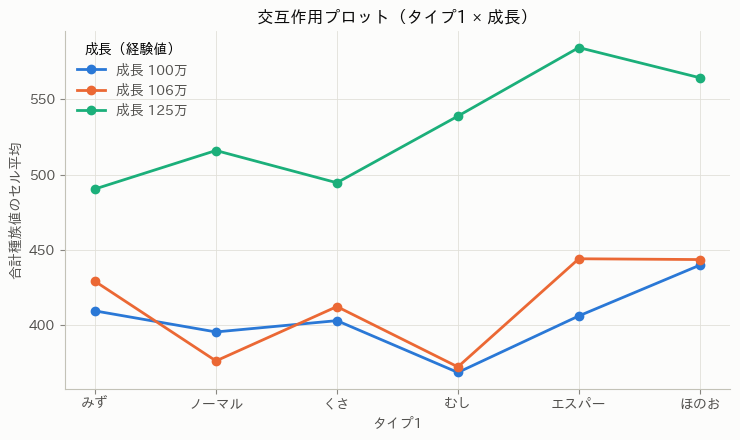

In [141]:
# 交互作用プロット: 線が平行なら交互作用なし
cell_mean = tw.groupby(["タイプ1", "成長"], observed=True)["合計種族値"].mean().unstack()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
xs = np.arange(len(tw_types))
for k, gr in enumerate(tw_growth):
    ax.plot(xs, cell_mean.loc[tw_types, gr], marker="o", color=PALETTE[k], label=f"成長 {gr}")
ax.set_xticks(xs, tw_types)
ax.set(title="交互作用プロット（タイプ1 × 成長）", xlabel="タイプ1", ylabel="合計種族値のセル平均")
ax.legend(title="成長（経験値）")
fig.tight_layout()
plt.show()

**結果の読み方**
- 交互作用は $F\approx1.06$（自由度 $(10,\,446)$）、$p\approx0.40$ で、有意水準5%で有意でない。交互作用プロットでは、成長 `125万` の線がどのタイプでも他の2本より60〜180程度高い。`100万` と `106万` の線は近く、ノーマルで順序が入れ替わる程度である。線の間隔にはタイプごとの違いが見えるが、各セルの件数（8〜49）に対して誤差が大きく、偶然の範囲と区別できない。
- type I 平方和では、タイプ1を先に入れると $S_A\approx4.9\times10^5$、成長の後に入れると $\approx2.2\times10^5$ と半分以下になる。エスパーは `125万`、むしは `100万` が多いなど、タイプと成長が相関しているため、タイプの効果の一部は成長で説明できてしまう。
- type II では タイプ1 $F\approx3.7$（$p\approx0.003$）、成長 $F\approx44$（$p<10^{-17}$）で、どちらの主効果も有意。成長が遅い（`125万`）グループの平均は他より100以上高い。成長の遅いグループには種族値の高いポケモンが多く集まっている、という記述的な結果である。

### 20.6 乱塊法

**問い**：世代をブロックとみなし、世代による違いを取り除くと、タイプ1の効果はどう評価されるか。

**手法の要点**
- 一元配置の乱塊法：因子 A（$a$ 水準）とブロック R（$r$ 個）で、各ブロック内に全水準を1回ずつ無作為に割り付ける。モデルは
  $$Y_{ij}=\mu+\alpha_i+\gamma_j+\varepsilon_{ij},\qquad \sum_i\alpha_i=0,\ \sum_j\gamma_j=0,\ \varepsilon_{ij}\overset{\text{i.i.d.}}{\sim}N(0,\sigma^2).$$
- 平方和の分解 $S_T=S_A+S_R+S_E$：
  $$S_A=r\sum_i(\bar Y_{i\cdot}-\bar Y_{\cdot\cdot})^2,\quad S_R=a\sum_j(\bar Y_{\cdot j}-\bar Y_{\cdot\cdot})^2,\quad S_E=\sum_i\sum_j(Y_{ij}-\bar Y_{i\cdot}-\bar Y_{\cdot j}+\bar Y_{\cdot\cdot})^2 .$$

| 要因 | 平方和 | 自由度 | 平均平方 | F |
|---|---|---|---|---|
| 因子 A | $S_A$ | $a-1$ | $V_A$ | $V_A/V_E\sim F(a-1,\,(a-1)(r-1))$ |
| ブロック R | $S_R$ | $r-1$ | $V_R$ | $V_R/V_E\sim F(r-1,\,(a-1)(r-1))$ |
| 誤差 E | $S_E$ | $(a-1)(r-1)$ | $V_E$ | |
| 総 T | $S_T$ | $ar-1$ | | |

- ブロックを無視して一元配置で解析すると、$S_R$ が誤差に混ざる（誤差の自由度は $a(r-1)$）。ブロック間の差が大きいほど、ブロックを入れたほうが $V_E$ が小さくなり検出力が上がる。
- 今回の見立て：全7世代にいる12タイプについて、（タイプ, 世代）のセル平均を $Y_{ij}$ とする（$a=12$, $r=7$）。セルの背後の匹数は1〜31とばらばらなので、各 $Y_{ij}$ の分散は等しくなく、等分散の仮定は近似にすぎない。また世代内でタイプを無作為に割り付けたわけではない（20.1）。

（→ py 20-6：乱塊法の分散分析表を手計算し statsmodels と照合、ブロックを無視した場合と比較）

In [142]:
# 乱塊法: 因子 = タイプ1、ブロック = 世代。
# 全世代にいるタイプに限り、(タイプ, 世代) のセル平均を1観測とする a × r の表を作る
cnt = pd.crosstab(df["タイプ1"], df["世代"])
rb_types = cnt.index[(cnt > 0).all(axis=1)].tolist()
rb = (df[df["タイプ1"].isin(rb_types)]
      .groupby(["タイプ1", "世代"], observed=True)["合計種族値"].mean().unstack())
a_rb, r_rb = rb.shape
print(f"因子 A（タイプ1）: {a_rb} 水準 {rb_types}")
print(f"ブロック R（世代）: {r_rb} 個、1セル1観測（セル平均）")

Y = rb.to_numpy()
m_all = Y.mean()
S_T_rb = ((Y - m_all) ** 2).sum()
S_A_rb = r_rb * ((Y.mean(axis=1) - m_all) ** 2).sum()
S_R_rb = a_rb * ((Y.mean(axis=0) - m_all) ** 2).sum()
S_E_rb = S_T_rb - S_A_rb - S_R_rb
dfs = [a_rb - 1, r_rb - 1, (a_rb - 1) * (r_rb - 1)]
ms = [S_A_rb / dfs[0], S_R_rb / dfs[1], S_E_rb / dfs[2]]
rb_table = pd.DataFrame({
    "平方和": [S_A_rb, S_R_rb, S_E_rb, S_T_rb],
    "自由度": dfs + [a_rb * r_rb - 1],
    "平均平方": ms + [np.nan],
    "F": [ms[0] / ms[2], ms[1] / ms[2], np.nan, np.nan],
    "p値": [stats.f.sf(ms[0] / ms[2], dfs[0], dfs[2]), stats.f.sf(ms[1] / ms[2], dfs[1], dfs[2]), np.nan, np.nan],
}, index=["因子 A（タイプ1）", "ブロック R（世代）", "誤差 E", "総 T"])
print("\n乱塊法の分散分析表（手計算）")
print(rb_table.to_string(float_format=fmt4))

# statsmodels と照合（加法モデル: 交互作用項なし）
rb_long = rb.stack().rename("セル平均").reset_index()
rb_long["タイプ1"] = rb_long["タイプ1"].astype(str)  # 未使用のカテゴリ水準を残さない
rb_long["世代"] = rb_long["世代"].astype(str)
print("\nstatsmodels（セル平均 ~ タイプ1 + 世代）")
print(sm.stats.anova_lm(smf.ols("セル平均 ~ C(タイプ1) + C(世代)", data=rb_long).fit(), typ=1).to_string(float_format=fmt4))

# ブロックを無視した一元配置（完全無作為化法として解析）との比較
S_E_crd = S_R_rb + S_E_rb
df_E_crd = dfs[1] + dfs[2]
F_crd = ms[0] / (S_E_crd / df_E_crd)
print(f"\nブロックを無視した一元配置: F = {F_crd:.3f}（F({dfs[0]}, {df_E_crd})）, p = {stats.f.sf(F_crd, dfs[0], df_E_crd):.4f}")
print(f"誤差の平均平方  乱塊法: {ms[2]:.1f}  ブロック無視: {S_E_crd / df_E_crd:.1f}")

因子 A（タイプ1）: 12 水準 ['あく', 'いわ', 'かくとう', 'くさ', 'でんき', 'どく', 'ほのお', 'みず', 'むし', 'エスパー', 'ゴースト', 'ノーマル']
ブロック R（世代）: 7 個、1セル1観測（セル平均）

乱塊法の分散分析表（手計算）
                 平方和  自由度  平均平方     F        p値
因子 A（タイプ1） 7.962e+04   11  7238 4.357 6.867e-05
ブロック R（世代） 3.378e+04    6  5630 3.388  0.005654
誤差 E       1.097e+05   66  1661   NaN       NaN
総 T        2.231e+05   83   NaN   NaN       NaN

statsmodels（セル平均 ~ タイプ1 + 世代）
          df    sum_sq  mean_sq     F    PR(>F)
C(タイプ1)   11 7.962e+04     7238 4.357 6.867e-05
C(世代)      6 3.378e+04     5630 3.388  0.005654
Residual  66 1.097e+05     1661   NaN       NaN

ブロックを無視した一元配置: F = 3.634（F(11, 72)）, p = 0.0004
誤差の平均平方  乱塊法: 1661.4  ブロック無視: 1992.1


**結果の読み方**
- タイプ1の効果は $F\approx4.36$（自由度 $(11,\,66)$）、$p\approx0.0001$。ブロック（世代）も $F\approx3.39$（自由度 $(6,\,66)$）、$p\approx0.006$ で有意水準5%で有意。手計算の表は statsmodels と一致した。
- ブロックを無視すると誤差の平均平方は約1661から約1992に増え、タイプの F は約3.63 に下がる。世代による差を誤差から取り除いた分だけ、乱塊法のほうが精度がよい。
- ただし結論はセル平均という集約した値に基づき、無作為化もないので、実験としての乱塊法と同じ保証はない。

### 20.7 直交表

**問い**：因子が多いときに全ての水準組み合わせを試さずに済ませる直交表は、どのような構造か（ポケモンのデータは使わない概念の確認）。

**手法の要点**
- 2水準の因子が7個あると全組み合わせは $2^7=128$ 通りだが、**$L_8(2^7)$ 直交表**を使うと8回の実験で最大7個の主効果（または一部の交互作用）を調べられる（一部実施要因計画）。$L_8(2^7)$ の 8 は実験の回数、2 は水準の数、7 は列の数。
- **直交性**：どの2列を取っても、水準の組 (1,1), (1,2), (2,1), (2,2) が同じ回数（2回ずつ）現れる。このため各列の効果を他の列と独立に推定できる。
- **成分**：列 [1], [2], [4] を基本列 $a$, $b$, $c$ とし、他の列はその積（$ab$, $ac$, $bc$, $abc$）で表す。水準を 0/1 とみなすと、積は mod 2 の和にあたる。
- **交互作用の列**：列 $i$ と列 $j$ に因子を割り付けると、その交互作用は成分の積の列に現れる。$a^2=b^2=c^2=1$ なので、例えば [3]（$ab$）×[6]（$bc$）$=ab^2c=ac$ で列 [5] になる（列番号の2進表示の排他的論理和 $3\oplus6=5$）。
- **交絡**：交互作用 $A\times B$ が現れる列に別の因子 C を割り付けると、C の主効果と $A\times B$ を区別できなくなる。交互作用を調べたい場合はその列を空けておく。

（→ py 20-7：L8 直交表を作り、直交性と交互作用の列を確認する）

In [143]:
# 直交表 L8(2^7): 基本列 a, b, c の組み合わせで7列を作る（成分表示）
# 行 r = 0..7 の2進表示 (a, b, c)。列 j = 1..7 の2進表示のビットが立つ基本列の和を mod 2 で求める
basis = np.array([[(r >> 2) & 1, (r >> 1) & 1, r & 1] for r in range(8)])  # 列: a, b, c
comp_names = {1: "a", 2: "b", 3: "ab", 4: "c", 5: "ac", 6: "bc", 7: "abc"}
L8 = np.zeros((8, 7), dtype=int)
for j in range(1, 8):
    bits = np.array([j & 1, (j >> 1) & 1, (j >> 2) & 1])  # a, b, c を使うか
    L8[:, j - 1] = (basis @ bits) % 2 + 1                 # 水準 1, 2
L8_df = pd.DataFrame(L8, index=[f"実験{r + 1}" for r in range(8)],
                     columns=[f"[{j}] {comp_names[j]}" for j in range(1, 8)])
print("L8(2^7) 直交表")
print(L8_df.to_string())

# 直交性: どの2列を取っても (1,1),(1,2),(2,1),(2,2) が2回ずつ現れる
ok = all(pd.crosstab(L8[:, i], L8[:, j]).to_numpy().min() == 2 and
         pd.crosstab(L8[:, i], L8[:, j]).to_numpy().max() == 2
         for i in range(7) for j in range(i + 1, 7))
print("\n全ての2列の組で各水準組み合わせが2回ずつ:", ok)

# 2列の交互作用が現れる列（成分の積。a² = b² = c² = 1 なので列番号の排他的論理和）
inter = pd.DataFrame([[(i ^ j) if i != j else 0 for j in range(1, 8)] for i in range(1, 8)],
                     index=range(1, 8), columns=range(1, 8))
print("\n列 i と列 j の交互作用が現れる列（0 は同じ列）")
print(inter.to_string())
print(f"\n例: [3]({comp_names[3]}) × [6]({comp_names[6]}) → [{3 ^ 6}]({comp_names[3 ^ 6]})")

L8(2^7) 直交表
     [1] a  [2] b  [3] ab  [4] c  [5] ac  [6] bc  [7] abc
実験1      1      1       1      1       1       1        1
実験2      1      1       1      2       2       2        2
実験3      1      2       2      1       1       2        2
実験4      1      2       2      2       2       1        1
実験5      2      1       2      1       2       1        2
実験6      2      1       2      2       1       2        1
実験7      2      2       1      1       2       2        1
実験8      2      2       1      2       1       1        2



全ての2列の組で各水準組み合わせが2回ずつ: True

列 i と列 j の交互作用が現れる列（0 は同じ列）
   1  2  3  4  5  6  7
1  0  3  2  5  4  7  6
2  3  0  1  6  7  4  5
3  2  1  0  7  6  5  4
4  5  6  7  0  1  2  3
5  4  7  6  1  0  3  2
6  7  4  5  2  3  0  1
7  6  5  4  3  2  1  0

例: [3](ab) × [6](bc) → [5](ac)


**結果の読み方**
- 作成した表は標準的な $L_8(2^7)$ と同じで、21組すべての2列で各水準組み合わせがちょうど2回ずつ現れた。
- 交互作用の表から、例えば A を [1]、B を [2] に割り付けると $A\times B$ は [3] に現れるので、3つ目の因子 C は [4] に割り付ける、という割り付けが読み取れる。

### まとめ

- タイプ1による合計種族値の平均の差は有意（$F\approx5.2$）だが、説明できる変動は約9%にとどまる。平均が高いのはドラゴン・はがね・エスパー、低いのはむし・どく・ノーマルで、Tukey 法では153組中21組に差が認められた。
- 成長の速さの効果はタイプより大きく（`125万` が100以上高い）、タイプとの交互作用は認められない。不釣り合いデータでは type I 平方和が投入順で変わるので、type II などで調整した値を読む必要がある。
- 分散分析は「平均の差」の検定であり、多重比較・等分散性・不釣り合いデータに注意が要る。本データは観察データでフィッシャーの3原則を満たさないため、結果は記述的な比較であり、因果の結論には無作為化された実験が必要である。

## 第21章 標本調査法

### 章の概要

標本調査法は、大きさ $N$ の**有限母集団**から一部（標本）を抜き出して、母平均などの母集団の値を推定する方法である。
推定量の性質は「母集団は固定、どの標本が選ばれるかだけが確率的」という**抽出デザイン**から決まり、母集団分布の仮定は要らない。
この章では全920匹を**真の値がわかっている有限母集団**とみなし、合計種族値の母平均 $\bar Y$ を推定する。
理論式で求めた推定量の分散を、実際に何千回も抽出するシミュレーションと照合する。
第8章の標本平均の分布（無限母集団・独立な標本）を非復元抽出に直したもので、層化の効果は第20章の分散分析の平方和の分解と同じ考え方で説明できる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 21.1 | 単純無作為抽出（非復元） | 100匹を抜き出したとき、標本平均はどれくらいばらつくか |
| 21.2 | 層化抽出法（比例配分・ネイマン配分） | 世代・タイプ1・経験値で層に分けると精度は上がるか |
| 21.3 | 比推定・回帰推定 | 経験値の母平均を知っていると、推定はよくなるか |
| 21.4 | 集落抽出法 | 図鑑の「ページ」単位で調べると精度はどうなるか |
| 21.5 | 系統抽出法 | 図鑑番号順に等間隔で抜き出すと、進化系列の周期で偏らないか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的 | 調査項目 $Y$。母平均 $\bar Y$ を推定する |
| `世代`, `タイプ1` | 質的 | 層化の基準（21.2） |
| `経験値` | 量的 | 層化の基準（4分位）と、比推定・回帰推定の補助変数 $X$（21.2, 21.3） |
| `図鑑番号` | 整数 | 集落（10番ごとのページ）と系統抽出の並び順（21.4, 21.5） |

- **対象の行**：全920行を有限母集団とする（$N=920$）。姿違いも1匹として数える。
- **加工**：21.2 で `経験値` を4分位で4つの層に分ける。
- **データの性質と注意点**：母集団の値は全部わかっているので、推定量の期待値と分散を理論値として正確に計算できる。記号は、母分散 $\sigma^2=\frac1N\sum_{i=1}^N(Y_i-\bar Y)^2$ と修正母分散 $S^2=\frac{1}{N-1}\sum_{i=1}^N(Y_i-\bar Y)^2=\frac{N}{N-1}\sigma^2$ を区別する。シミュレーションは各設定5000回。

（→ py 21-0：母集団の大きさ・母平均・母分散。以下で使う抽出用の関数も定義する）

In [144]:
# 全920行を「真の値がわかっている有限母集団」とみなす。調査項目は合計種族値
pop_y = df["合計種族値"].to_numpy(dtype=float)
N_pop = len(pop_y)
mu_pop = pop_y.mean()
sigma2_pop = pop_y.var(ddof=0)   # 母分散 σ²（N で割る）
S2_pop = pop_y.var(ddof=1)       # 修正母分散 S²（N-1 で割る）
R_SIM = 5000                     # シミュレーションの反復回数
print(f"母集団の大きさ N = {N_pop}")
print(f"母平均 μ = {mu_pop:.3f}")
print(f"母分散 σ² = {sigma2_pop:.1f}（σ = {np.sqrt(sigma2_pop):.2f}）,  S² = {S2_pop:.1f}")


def srs_means(y, n, reps, rng):
    """y から大きさ n の非復元単純無作為抽出を reps 回行い、標本平均を返す."""
    keys = rng.random((reps, len(y)))
    idx = np.argpartition(keys, n - 1, axis=1)[:, :n]   # 一様乱数の小さい n 個 = 非復元の無作為抽出
    return y[idx].mean(axis=1)

母集団の大きさ N = 920
母平均 μ = 438.468
母分散 σ² = 14463.9（σ = 120.27）,  S² = 14479.7


### 21.1 単純無作為抽出（非復元）

**問い**：920匹から $n$ 匹を非復元で無作為に抜き出すとき、標本平均 $\bar y$ はどれくらい母平均からずれるか。

**手法の要点**
- 単純無作為抽出：大きさ $n$ のすべての部分集合（$\binom{N}{n}$ 通り）が等しい確率で選ばれる抽出。
- 標本平均 $\bar y$ の期待値と分散：
  $$E[\bar y]=\bar Y,\qquad V[\bar y]=\frac{N-n}{N-1}\cdot\frac{\sigma^2}{n}=\Bigl(1-\frac nN\Bigr)\frac{S^2}{n}.$$
  $\frac{N-n}{N-1}$ を**有限母集団修正（有限修正項）**という。復元抽出（または無限母集団）なら $V[\bar y]=\sigma^2/n$。$n=N$ で全数調査になると分散は0。
- 必要な標本の大きさ：$V[\bar y]\le c$ を $n$ について解くと
  $$n\ \ge\ \frac{N}{1+(N-1)\,c/\sigma^2}.$$
  $N\to\infty$ では $n\ge\sigma^2/c$ に一致する。

（→ py 21-1：いくつかの $n$ で理論値とシミュレーションを比べる）

In [145]:
# 単純無作為抽出（非復元）: E[ȳ] = μ,  V[ȳ] = (N-n)/(N-1) · σ²/n
rng = get_rng()
srs_rows = []
for n in [10, 50, 100, 300, 600, 900]:
    means = srs_means(pop_y, n, R_SIM, rng)
    fpc = (N_pop - n) / (N_pop - 1)
    srs_rows.append({"n": n, "有限修正項": fpc,
                     "V理論(非復元)": fpc * sigma2_pop / n,
                     "V理論(復元)": sigma2_pop / n,
                     "Vシミュレーション": means.var(ddof=1),
                     "平均シミュレーション": means.mean()})
srs_tab = pd.DataFrame(srs_rows).set_index("n")
print(f"母平均 μ = {mu_pop:.2f}（標本平均の平均がこれに近ければ不偏）  反復 {R_SIM} 回")
srs_tab.round(3)

母平均 μ = 438.47（標本平均の平均がこれに近ければ不偏）  反復 5000 回


,有限修正項,V理論(非復元),V理論(復元),Vシミュレーション,平均シミュレーション
n,,,,,
10,0.990,1432.228,1446.393,1420.205,439.026
50,0.947,273.855,289.279,274.875,438.627
100,0.892,129.058,144.639,127.214,438.504
300,0.675,32.527,48.213,32.213,438.510
600,0.348,8.394,24.107,8.269,438.455
900,0.022,0.350,16.071,0.376,438.463


（→ py 21-1b：標本平均の分散と $n$ の関係の図、標準誤差を一定以下にする $n$ の計算）

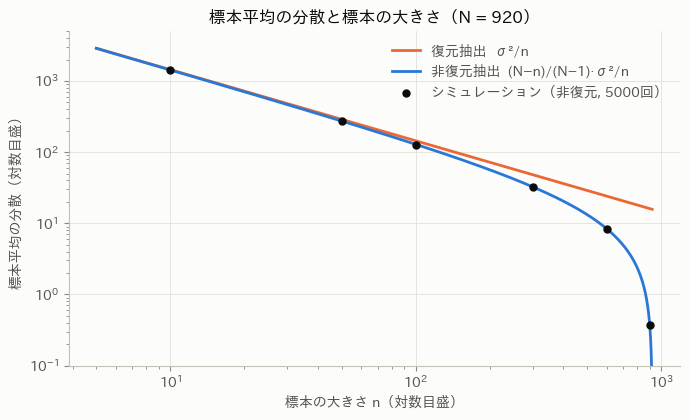

標準誤差 ≤ 10: n ≥ 125.1 → n = 126（無限母集団なら σ²/c = 144.6）
標準誤差 ≤ 5: n ≥ 355.4 → n = 356（無限母集団なら σ²/c = 578.6）


In [146]:
# 標本平均の分散と n の関係（理論曲線とシミュレーション）
n_grid = np.arange(5, N_pop + 1)
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(n_grid, sigma2_pop / n_grid, color=PALETTE[1], label="復元抽出  σ²/n")
ax.plot(n_grid, (N_pop - n_grid) / (N_pop - 1) * sigma2_pop / n_grid, color=PALETTE[0],
        label="非復元抽出  (N−n)/(N−1)·σ²/n")
ax.scatter(srs_tab.index, srs_tab["Vシミュレーション"], color=INK["primary"], zorder=3, s=25,
           label=f"シミュレーション（非復元, {R_SIM}回）")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0.1, 5000)   # n → N で分散は 0 に近づくので下限を切る
ax.set(title="標本平均の分散と標本の大きさ（N = 920）", xlabel="標本の大きさ n（対数目盛）",
       ylabel="標本平均の分散（対数目盛）")
ax.legend()
fig.tight_layout()
plt.show()

# 標準誤差を c0 以下にする最小の n: V ≤ c より n ≥ N / (1 + (N-1)c/σ²)
for se_target in [10, 5]:
    c = se_target ** 2
    n_need = N_pop / (1 + (N_pop - 1) * c / sigma2_pop)
    print(f"標準誤差 ≤ {se_target}: n ≥ {n_need:.1f} → n = {int(np.ceil(n_need))}"
          f"（無限母集団なら σ²/c = {sigma2_pop / c:.1f}）")

**結果の読み方**
- 標本平均の平均はどの $n$ でも母平均 $\bar Y\approx438.5$ とほぼ一致し、不偏であることが確かめられる。
- シミュレーションの分散は非復元の理論値とよく一致する。$n=100$ では有限修正項が約0.89で、復元抽出の式 $\sigma^2/n\approx145$ より約11%小さい約129になる。$n=600$ では修正項が約0.35になり、差は3倍近くになる。$n/N$ が小さいうちは修正の影響は小さい。
- 標準誤差を10以下にするには $n\ge126$、5以下にするには $n\ge356$ が必要で、無限母集団の式（145, 579）より少なくて済む。

### 21.2 層化抽出法

**問い**：母集団を層に分けてから各層で無作為抽出すると、単純無作為抽出より精度は上がるか。どの層化が効くか。

**手法の要点**
- 母集団を $L$ 個の層（大きさ $N_h$, $\sum_h N_h=N$, 層の重み $W_h=N_h/N$）に分け、第 $h$ 層から $n_h$ 個を単純無作為抽出する（$\sum_h n_h=n$）。
- 推定量と分散（$S_h^2$ は第 $h$ 層の修正母分散）：
  $$\bar y_{st}=\sum_{h=1}^L W_h\bar y_h,\qquad V[\bar y_{st}]=\sum_{h=1}^L W_h^2\Bigl(1-\frac{n_h}{N_h}\Bigr)\frac{S_h^2}{n_h}.$$
- **比例配分** $n_h=n\,N_h/N$：$V_{\text{prop}}=\dfrac{1-f}{n}\sum_h W_hS_h^2$（$f=n/N$）。
  総平方和の分解 $(N-1)S^2=\sum_h(N_h-1)S_h^2+\sum_h N_h(\bar Y_h-\bar Y)^2$ から、$N_h$ が大きければ
  $$V_{\text{SRS}}-V_{\text{prop}}\approx\frac{1-f}{n}\sum_h W_h(\bar Y_h-\bar Y)^2\ \ge 0 .$$
  つまり、**層間の平均の差が大きい（層内が均質な）ほど層化の効果が大きい**。
- **ネイマン配分（最適配分）** $n_h=n\,\dfrac{N_hS_h}{\sum_k N_kS_k}$：$n$ を固定したとき $V[\bar y_{st}]$ を最小にする配分。ばらつきの大きい層から多く取る。最小値は $\dfrac1n\bigl(\sum_hW_hS_h\bigr)^2-\dfrac1N\sum_hW_hS_h^2$。
- 層化の効きやすさの目安として、層間平方和の割合 $\eta^2=\sum_hN_h(\bar Y_h-\bar Y)^2\big/\sum_i(Y_i-\bar Y)^2$ を表示する。
- 実装上の注意：配分は整数に丸め（最大剰余法）、各層から最低1匹は取る。タイプ1の ひこう（4匹）は比例配分だと0.4匹になるため1匹に切り上げており、厳密な比例配分からわずかにずれる。

（→ py 21-2：世代・タイプ1・経験値4分位の3通りの層化で、比例配分とネイマン配分の理論値とシミュレーションを比べる）

In [147]:
# 層化抽出法: 3通りの層化で、比例配分とネイマン配分を比べる（標本の大きさ n = 100）
n_st = 100
d21 = df[["合計種族値", "タイプ1", "世代", "経験値"]].copy()
d21["タイプ1"] = d21["タイプ1"].astype(str)
d21["経験値4分位"] = pd.qcut(d21["経験値"], 4, labels=["Q1", "Q2", "Q3", "Q4"]).astype(str)
strata_defs = {"世代（7層）": "世代", "タイプ1（18層）": "タイプ1", "経験値の4分位（4層）": "経験値4分位"}


def allocate(weights, n, caps):
    """weights に比例する整数配分（最大剰余法。各層1以上・層の大きさ以下）."""
    raw = n * weights / weights.sum()
    alloc = np.clip(np.floor(raw).astype(int), 1, caps)
    while alloc.sum() < n:                      # 余りを端数の大きい層から配る
        room = alloc < caps
        k = np.argmax(np.where(room, raw - alloc, -np.inf))
        alloc[k] += 1
    while alloc.sum() > n:                      # 下限1のために超えた分を削る
        k = np.argmax(np.where(alloc > 1, alloc - raw, -np.inf))
        alloc[k] -= 1
    return alloc


def strat_var(N_h, S2_h, n_h):
    """層化抽出の標本平均の分散 Σ W_h² (1 - n_h/N_h) S_h² / n_h."""
    W_h = N_h / N_h.sum()
    return np.sum(W_h ** 2 * (1 - n_h / N_h) * S2_h / n_h)


rng = get_rng()
strat_rows, strat_sims, strat_alloc = [], {}, {}
v_srs_100 = (N_pop - n_st) / (N_pop - 1) * sigma2_pop / n_st
strat_sims["単純無作為抽出"] = srs_means(pop_y, n_st, R_SIM, rng)
for label, col in strata_defs.items():
    groups = [g["合計種族値"].to_numpy(float) for _, g in d21.groupby(col)]
    N_h = np.array([len(g) for g in groups])
    S2_h = np.array([g.var(ddof=1) for g in groups])
    mu_h = np.array([g.mean() for g in groups])
    # 層間変動の割合（層内が均質なほど大きい）
    ss_between = np.sum(N_h * (mu_h - mu_pop) ** 2)
    eta2 = ss_between / ((N_pop - 1) * S2_pop)
    for alloc_name, w in [("比例配分", N_h.astype(float)), ("ネイマン配分", N_h * np.sqrt(S2_h))]:
        n_h = allocate(w, n_st, N_h)
        est = np.zeros(R_SIM)
        for g, nh in zip(groups, n_h):
            est += (len(g) / N_pop) * srs_means(g, nh, R_SIM, rng)   # ȳ_st = Σ W_h ȳ_h
        v_th = strat_var(N_h, S2_h, n_h)
        strat_sims[f"{label}\n{alloc_name}"] = est
        strat_alloc[(label, alloc_name)] = n_h
        strat_rows.append({"層化": label, "配分": alloc_name, "層間変動の割合η²": eta2,
                           "V理論": v_th, "Vシミュレーション": est.var(ddof=1),
                           "平均シミュレーション": est.mean(), "相対効率 V_SRS/V": v_srs_100 / v_th})
print(f"n = {n_st}, 単純無作為抽出の分散（理論）= {v_srs_100:.2f}, シミュレーション = {strat_sims['単純無作為抽出'].var(ddof=1):.2f}")
print(f"母平均 μ = {mu_pop:.2f}")
pd.DataFrame(strat_rows).set_index(["層化", "配分"]).round(3)

n = 100, 単純無作為抽出の分散（理論）= 129.06, シミュレーション = 126.16
母平均 μ = 438.47


層間変動の割合η²      V理論  Vシミュレーション  平均シミュレーション  相対効率 V_SRS/V
層化          配分                                                             
世代（7層）      比例配分        0.014  128.269    127.473     438.300         1.006
            ネイマン配分      0.014  127.321    128.340     438.358         1.014
タイプ1（18層）   比例配分        0.089  120.233    119.679     438.508         1.073
            ネイマン配分      0.089  118.611    118.242     438.430         1.088
経験値の4分位（4層） 比例配分        0.818   23.669     24.024     438.547         5.453
            ネイマン配分      0.818   20.866     20.452     438.500         6.185

（→ py 21-2b：経験値4分位での配分の中身と、抽出法ごとの標本平均の分布）

        N_h   S_h  比例配分 n_h  ネイマン配分 n_h
経験値4分位                                 
Q1      232  37.4        25          19
Q2      231  60.0        25          31
Q3      227  28.0        25          14
Q4      230  69.3        25          36


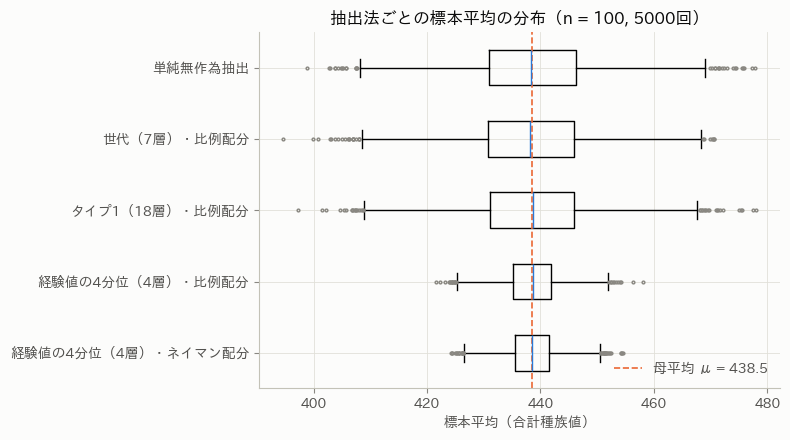

In [148]:
# 配分の中身（経験値の4分位）と、推定量の分布の比較
lab = "経験値の4分位（4層）"
alloc_tab = pd.DataFrame({
    "N_h": d21.groupby("経験値4分位").size(),
    "S_h": d21.groupby("経験値4分位")["合計種族値"].std(),
    "比例配分 n_h": strat_alloc[(lab, "比例配分")],
    "ネイマン配分 n_h": strat_alloc[(lab, "ネイマン配分")],
})
print(alloc_tab.round(1).to_string())

show = ["単純無作為抽出", "世代（7層）\n比例配分", "タイプ1（18層）\n比例配分",
        "経験値の4分位（4層）\n比例配分", "経験値の4分位（4層）\nネイマン配分"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([strat_sims[k] for k in show], vert=False, widths=0.5,
           medianprops={"color": PALETTE[0]}, flierprops={"markersize": 2, "markeredgecolor": INK["muted"]})
ax.set_yticks(range(1, len(show) + 1), [k.replace("\n", "・") for k in show])
ax.invert_yaxis()
ax.axvline(mu_pop, color=PALETTE[1], linestyle="--", linewidth=1.2, label=f"母平均 μ = {mu_pop:.1f}")
ax.set(title=f"抽出法ごとの標本平均の分布（n = {n_st}, {R_SIM}回）", xlabel="標本平均（合計種族値）")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**結果の読み方**
- どの層化でも、標本平均の平均は母平均に近く、シミュレーションの分散は理論値とよく一致した。
- **世代**で層化しても $\eta^2\approx0.01$ で、分散は単純無作為抽出（約129）とほぼ同じ（相対効率1.01）。世代によって合計種族値の平均はほとんど変わらないので、層化の意味がない。
- **タイプ1**では $\eta^2\approx0.09$（第20章の一元配置の $\eta^2$ と同じ値）で、分散は約120、相対効率は約1.07とわずか。
- **経験値の4分位**では $\eta^2\approx0.82$ で、比例配分の分散は約24（相対効率約5.5）、ネイマン配分では約21（約6.2）まで下がる。経験値と合計種族値の相関（0.92）が高いため、層内が均質になる。ネイマン配分は標準偏差の大きい Q2・Q4 に多く、Q3 に少なく配分している。
- 層化の効果は「層の数」ではなく「層内がどれだけ均質か」で決まる。調査項目と強く関連する補助情報で層を作るのが要点である。

### 21.3 比推定と回帰推定

**問い**：母集団の全員について補助変数 $X$（経験値）の母平均 $\bar X$ がわかっているとき、それを使って $\bar Y$ の推定を改善できるか。

**手法の要点**
- **比推定量**：$\hat{\bar Y}_R=\dfrac{\bar y}{\bar x}\,\bar X$。$Y$ がおよそ $X$ に比例する（原点を通る直線に乗る）ときに有効。偏りがあるが、その大きさは $O(1/n)$。
- 近似分散（$R=\bar Y/\bar X$）：
  $$V[\hat{\bar Y}_R]\approx\frac{1-f}{n}\cdot\frac{1}{N-1}\sum_{i=1}^N(Y_i-RX_i)^2 .$$
  $\bar y$ より有利になる近似条件は $\rho>\dfrac{C_X}{2C_Y}$（$C_X, C_Y$ は変動係数、$\rho$ は相関係数）。
- **回帰推定量**（参考）：$\hat{\bar Y}_{\text{reg}}=\bar y+b(\bar X-\bar x)$、$b$ は標本の最小二乗の傾き。近似分散は $\dfrac{1-f}{n}S^2(1-\rho^2)$ で、直線が原点を通らなくても効く。

（→ py 21-3：$n=100$ で標本平均・比推定・回帰推定を比べる）

In [149]:
# 比推定: 補助変数 x = 経験値（母平均 X̄ が既知）を使って ȳ_R = (ȳ / x̄) · X̄
pop_x = df["経験値"].to_numpy(dtype=float)
X_bar = pop_x.mean()
R_pop = mu_pop / X_bar                   # 母集団の比 R = Ȳ / X̄
n_r = 100
rng = get_rng()
keys = rng.random((R_SIM, N_pop))
idx_r = np.argpartition(keys, n_r - 1, axis=1)[:, :n_r]
ybar_s, xbar_s = pop_y[idx_r].mean(axis=1), pop_x[idx_r].mean(axis=1)
ratio_est = ybar_s / xbar_s * X_bar

# 回帰推定（参考）: ȳ_reg = ȳ + b (X̄ - x̄)、b は標本ごとの最小二乗の傾き
xc = pop_x[idx_r] - xbar_s[:, None]
b_s = (xc * (pop_y[idx_r] - ybar_s[:, None])).sum(axis=1) / (xc ** 2).sum(axis=1)
reg_est = ybar_s + b_s * (X_bar - xbar_s)

f_r = n_r / N_pop
v_ratio_th = (1 - f_r) / n_r * np.sum((pop_y - R_pop * pop_x) ** 2) / (N_pop - 1)
rho = np.corrcoef(pop_x, pop_y)[0, 1]
v_reg_th = (1 - f_r) / n_r * S2_pop * (1 - rho ** 2)
v_srs_r = (1 - f_r) / n_r * S2_pop
ratio_tab = pd.DataFrame({
    "V近似理論": [v_srs_r, v_ratio_th, v_reg_th],
    "Vシミュレーション": [ybar_s.var(ddof=1), ratio_est.var(ddof=1), reg_est.var(ddof=1)],
    "偏り(平均−μ)": [ybar_s.mean() - mu_pop, ratio_est.mean() - mu_pop, reg_est.mean() - mu_pop],
}, index=["標本平均 ȳ", "比推定 ȳ_R", "回帰推定 ȳ_reg"])
print(f"相関係数 ρ(経験値, 合計種族値) = {rho:.3f},  母集団の比 R = {R_pop:.3f}")
print(f"原点を通る直線の当てはまり: 残差 y − R x の標準偏差 = {np.std(pop_y - R_pop * pop_x, ddof=1):.1f}"
      f"（y の標準偏差 {np.sqrt(S2_pop):.1f}）")
# 比推定が ȳ より有利になる近似条件: ρ > (C_x / C_y) / 2（C は変動係数）
C_x, C_y = pop_x.std(ddof=1) / X_bar, np.sqrt(S2_pop) / mu_pop
print(f"変動係数 C_x = {C_x:.3f}, C_y = {C_y:.3f} → 条件 ρ > C_x/(2C_y) = {C_x / (2 * C_y):.3f}")
ratio_tab.round(3)

相関係数 ρ(経験値, 合計種族値) = 0.924,  母集団の比 R = 2.853
原点を通る直線の当てはまり: 残差 y − R x の標準偏差 = 123.6（y の標準偏差 120.3）
変動係数 C_x = 0.515, C_y = 0.274 → 条件 ρ > C_x/(2C_y) = 0.938


,V近似理論,Vシミュレーション,偏り(平均−μ)
標本平均 ȳ,129.058,126.162,0.016
比推定 ȳ_R,136.197,135.714,0.242
回帰推定 ȳ_reg,18.968,19.076,0.131


**結果の読み方**
- 相関は $\rho\approx0.92$ と高いのに、比推定の分散（約136）は標本平均（約129）より**大きい**。経験値の変動係数（約0.52）が合計種族値（約0.27）よりずっと大きく、条件 $\rho>C_X/(2C_Y)\approx0.94$ をわずかに満たさないためである。直観的には、合計種族値は経験値0でも0にならず（切片がある）、$Y\propto X$ の関係ではないので、比 $\bar y/\bar x$ で補正すると補正しすぎる。
- 回帰推定の分散は約19で、標本平均の約7分の1になる（理論値 $(1-\rho^2)\approx0.15$ 倍とほぼ一致）。
- 比推定・回帰推定の偏りはシミュレーション上どちらも0.3未満で、標準誤差に比べて無視できる大きさだった。

### 21.4 集落抽出法

**問い**：図鑑番号10番ごとの「ページ」を集落として、いくつかのページを選んでその中の全員を調べると、同じ匹数の単純無作為抽出と比べて精度はどうなるか。

**手法の要点**
- 母集団を $M$ 個の集落に分け、$m$ 個の集落を単純無作為抽出し、選んだ集落の中は全数調査する。名簿が集落単位でしか手に入らない場合や、調査費用を減らしたい場合に使う。
- 集落 $c$ の合計を $T_c$ とすると、不偏推定量とその分散は
  $$\hat{\bar Y}_{cl}=\frac{M}{m\,N}\sum_{c\in s}T_c,\qquad V[\hat{\bar Y}_{cl}]=\Bigl(\frac MN\Bigr)^2\Bigl(1-\frac mM\Bigr)\frac{S_T^2}{m},\quad S_T^2=\frac{1}{M-1}\sum_{c=1}^M(T_c-\bar T)^2 .$$
- 集落の中が似たもの同士（級内相関が正）だと、同じ匹数を調べても情報が少なくなり、単純無作為抽出より精度が落ちる。層化とは逆に、**集落内は異質なほうがよい**。
- ページには同じ進化系統のポケモンが並ぶので、集落内が似ていると予想される。

（→ py 21-4：$M=81$ ページから $m=9$ ページを選ぶ集落抽出の理論値とシミュレーション）

In [150]:
# 集落抽出: 図鑑番号10番ごとの「ページ」を集落とし、集落を単純無作為抽出して中の全員を調べる
page = (df["図鑑番号"] - 1) // 10
clusters = [pop_y[page == p] for p in np.sort(page.unique())]
M_cl = len(clusters)
T_c = np.array([c.sum() for c in clusters])          # 集落ごとの合計
size_c = np.array([len(c) for c in clusters])
m_cl = int(round(n_st / size_c.mean()))              # 期待標本サイズがおよそ n_st になる集落数
print(f"集落数 M = {M_cl}, 集落の大きさ 平均 {size_c.mean():.2f}（{size_c.min()}〜{size_c.max()}）, 抽出する集落数 m = {m_cl}")

# 不偏推定量: ȳ_cl = (M/m) Σ T_c / N,  V = (M/N)² (1 - m/M) S_T² / m（S_T² は集落合計の分散）
v_cl_th = (M_cl / N_pop) ** 2 * (1 - m_cl / M_cl) * T_c.var(ddof=1) / m_cl
rng = get_rng()
keys = rng.random((R_SIM, M_cl))
idx_c = np.argpartition(keys, m_cl - 1, axis=1)[:, :m_cl]
cl_est = M_cl / m_cl * T_c[idx_c].sum(axis=1) / N_pop
n_equiv = m_cl * size_c.mean()
v_srs_equiv = (N_pop - n_equiv) / (N_pop - 1) * sigma2_pop / n_equiv

# 集落内の類似度（級内相関の目安）: 集落平均の分散のうち、無作為な並びで期待される分を超える割合
within_ss = sum(((c - c.mean()) ** 2).sum() for c in clusters)
between_ss = sum(len(c) * (c.mean() - mu_pop) ** 2 for c in clusters)
print(f"集落間変動の割合 = {between_ss / (within_ss + between_ss):.3f}"
      f"（集落が無作為な寄せ集めなら約 {(M_cl - 1) / (N_pop - 1):.3f}）")
print(f"集落抽出  V理論 = {v_cl_th:.1f}, Vシミュレーション = {cl_est.var(ddof=1):.1f}, 平均 = {cl_est.mean():.2f}")
print(f"同じ期待標本サイズ（{n_equiv:.0f}）の単純無作為抽出 V = {v_srs_equiv:.1f}")
print(f"デザイン効果 V_cl / V_SRS = {v_cl_th / v_srs_equiv:.2f}")

集落数 M = 81, 集落の大きさ 平均 11.36（8〜17）, 抽出する集落数 m = 9
集落間変動の割合 = 0.338（集落が無作為な寄せ集めなら約 0.087）
集落抽出  V理論 = 1576.1, Vシミュレーション = 1618.5, 平均 = 438.87
同じ期待標本サイズ（102）の単純無作為抽出 V = 125.9
デザイン効果 V_cl / V_SRS = 12.52


**結果の読み方**
- 集落間変動の割合は約0.34で、ページが無作為な寄せ集めだった場合の目安（約0.09）より大きい。ページ内のポケモンは似ている。
- 集落抽出の分散は理論値約1576（シミュレーション約1620）で、同じ約102匹の単純無作為抽出（約126）の約12.5倍になった（デザイン効果）。ページごとに合計の大小が大きく、さらに集落の大きさ（8〜17匹）の違いもそのまま合計 $T_c$ のばらつきに入るためである。
- 集落抽出は費用の面で有利でも、同じ精度を得るには多くの集落が必要になる。

### 21.5 系統抽出法

**問い**：図鑑番号順に並んだ名簿から、無作為な開始点のあと $k$ 匹おきに抜き出すと、精度はどうなるか。進化系列（たね → 1進化 → 2進化）の周期で偏らないか。

**手法の要点**
- 抽出間隔 $k$ を決め、開始点 $s\in\{1,\dots,k\}$ を等確率で選び、$s, s+k, s+2k,\dots$ 番目を抽出する。起こりうる標本は $k$ 通りしかないので、推定量の分散（平均二乗誤差）は $k$ 通りの標本平均から正確に計算できる：
  $$\mathrm{MSE}=\frac1k\sum_{s=1}^k(\bar y_s-\bar Y)^2 .$$
  $N$ が $k$ で割り切れないときは標本の大きさが1違い、わずかな偏りが生じるため、分散ではなく MSE で比べる。
- 並び順に**傾向**（隣が似ている、ゆるやかな増減）があると、系統抽出は名簿全体に均等に散らばるので暗黙の層化になり、単純無作為抽出より精度が上がる。
- 並び順に**周期**があり、$k$ がその周期（の倍数）と一致すると、毎回同じ位相の個体ばかり選ばれて精度が大きく落ちる。

（→ py 21-5：$k=2,\dots,30$ で系統抽出の MSE と同じ $n$ の単純無作為抽出の分散を比べる）

図鑑番号順に並べたときの自己相関（ラグ1〜6）: [0.224, 0.292, 0.28, 0.311, 0.243, 0.234]
     n≈N/k   MSE系統  V単純無作為  比 MSE系統/V単純
k                                      
2   460.00    0.09   15.74         0.01
3   306.67    3.71   31.48         0.12
4   230.00   11.04   47.22         0.23
5   184.00   56.83   62.96         0.90
6   153.33    5.55   78.69         0.07
7   131.43   49.50   94.43         0.52
8   115.00   45.94  110.17         0.42
9   102.22   41.23  125.91         0.33
10   92.00  145.84  141.65         1.03
11   83.64   56.35  157.39         0.36
12   76.67   80.01  173.13         0.46
13   70.77   74.38  188.87         0.39
14   65.71   75.65  204.60         0.37
15   61.33  120.41  220.34         0.55
16   57.50  180.16  236.08         0.76
17   54.12  153.15  251.82         0.61
18   51.11  147.34  267.56         0.55
19   48.42  288.56  283.30         1.02
20   46.00  185.63  299.04         0.62
21   43.81  238.41  314.78         0.76
22   41.82  154.04  330.51         0.47
23   40.00  2

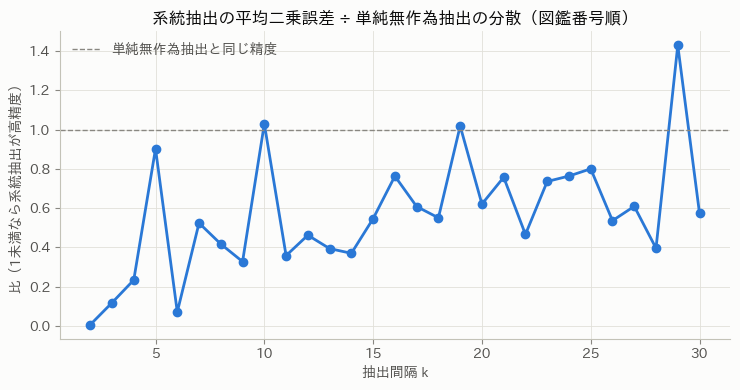

In [151]:
# 系統抽出: 図鑑番号順（姿違いを含む行の並び）に、間隔 k ごとに抽出する。
# 開始点 s = 0..k-1 の k 通りが等確率なので、平均二乗誤差（N が k で割り切れないときの偏りも含む）は k 通りの標本平均から正確に求まる
sys_rows = []
for k in range(2, 31):
    sys_means = np.array([pop_y[s::k].mean() for s in range(k)])
    n_k = N_pop / k
    v_srs_k = (N_pop - n_k) / (N_pop - 1) * sigma2_pop / n_k
    sys_rows.append({"k": k, "n≈N/k": n_k, "MSE系統": np.mean((sys_means - mu_pop) ** 2),
                     "V単純無作為": v_srs_k})
sys_tab = pd.DataFrame(sys_rows).set_index("k")
sys_tab["比 MSE系統/V単純"] = sys_tab["MSE系統"] / sys_tab["V単純無作為"]
print("図鑑番号順に並べたときの自己相関（ラグ1〜6）:",
      [round(pd.Series(pop_y).autocorr(l), 3) for l in range(1, 7)])
print(sys_tab.round(2).to_string())
print(f"比が1未満の k: {(sys_tab['比 MSE系統/V単純'] < 1).sum()} / {len(sys_tab)}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(sys_tab.index, sys_tab["比 MSE系統/V単純"], marker="o", color=PALETTE[0])
ax.axhline(1, color=INK["muted"], linestyle="--", linewidth=1, label="単純無作為抽出と同じ精度")
ax.set(title="系統抽出の平均二乗誤差 ÷ 単純無作為抽出の分散（図鑑番号順）", xlabel="抽出間隔 k",
       ylabel="比（1未満なら系統抽出が高精度）")
ax.legend()
fig.tight_layout()
plt.show()

（→ py 21-5b：周期性が効く極端な例。第1世代の御三家9匹を $k=3$ で系統抽出する）

In [152]:
# 周期性が効く例: 第1世代の御三家（図鑑番号1〜9、姿違いを除く）は「たね → 1進化 → 2進化」の周期3
starters = df[(df["図鑑番号"] <= 9) & ~df["is_form"]][["図鑑番号", "名前", "合計種族値"]]
y9 = starters["合計種族値"].to_numpy(float)
print(starters.to_string(index=False))
for s in range(3):
    print(f"k = 3, 開始 {s + 1}: {starters['名前'].iloc[s::3].tolist()} → 平均 {y9[s::3].mean():.1f}")
v_sys9 = np.var([y9[s::3].mean() for s in range(3)])
v_srs9 = (9 - 3) / (9 - 1) * y9.var() / 3
print(f"系統抽出（k=3）の分散 = {v_sys9:.1f},  単純無作為抽出（n=3）の分散 = {v_srs9:.1f},  比 = {v_sys9 / v_srs9:.2f}")

 図鑑番号    名前  合計種族値
    1 フシギダネ    318
    2 フシギソウ    405
    3 フシギバナ    525
    4  ヒトカゲ    309
    5  リザード    405
    6 リザードン    534
    7  ゼニガメ    314
    8  カメール    405
    9 カメックス    530
k = 3, 開始 1: ['フシギダネ', 'ヒトカゲ', 'ゼニガメ'] → 平均 313.7
k = 3, 開始 2: ['フシギソウ', 'リザード', 'カメール'] → 平均 405.0
k = 3, 開始 3: ['フシギバナ', 'リザードン', 'カメックス'] → 平均 529.7
系統抽出（k=3）の分散 = 7837.7,  単純無作為抽出（n=3）の分散 = 1961.7,  比 = 4.00


**結果の読み方**
- 図鑑番号順の合計種族値には、ラグ1〜6で0.2〜0.3程度の正の自己相関がある。近くの番号には同じ系統・同じ世代のポケモンが並ぶためである。
- その結果、$k=2\sim30$ の29通り中26通りで、系統抽出のほうが単純無作為抽出より精度がよかった（比が1未満）。比が1を超えたのは $k=10, 19$（約1.0）と $k=29$（約1.4）だけで、開始点が $k$ 通りしかないため、比は $k$ によって不規則に上下する。
- 進化系列の長さは1〜3段階（姿違いを入れるとさらに不規則）なので、全体としては一定の周期がなく、周期性による大きな偏りは見られなかった。
- 一方、御三家9匹（たね・1進化・2進化の周期3）を $k=3$ で抜き出すと、標本は「たねだけ」「1進化だけ」「2進化だけ」のどれかになり、MSE は単純無作為抽出の4倍になった。名簿に周期があるときは、系統抽出の間隔に注意が必要である。

### まとめ

- 920匹を真の値がわかる母集団とすると、非復元の単純無作為抽出の分散は有限修正項つきの式どおりになり、$n=100$ では復元抽出の式より約11%小さい。
- 層化の効果は層内の均質さで決まる。世代やタイプ1での層化はほとんど効かないが、経験値の4分位で層化すると分散は約5分の1（ネイマン配分では約6分の1）になった。補助変数を使う推定では、比推定は $Y\propto X$ の関係がないと逆効果になりうる一方、回帰推定は分散を約7分の1にした。
- 図鑑のページを集落にすると、ページ内が似ているため精度が大きく落ちる。図鑑番号順の系統抽出は、隣が似ている傾向のおかげで多くの間隔で単純無作為抽出より精度がよいが、周期のある名簿では大きく偏りうる。

## 第22章 主成分分析

### 章の概要

主成分分析（PCA）は、相関のある $p$ 個の変数を、互いに無相関で分散の大きい順に並んだ $p$ 個の合成変数（主成分）に組み替える手法である。
中心となる考え方は「分散共分散行列（または相関行列）の固有値分解」で、固有値が各主成分の分散、固有ベクトルが合成の重みになる。
上位の少数の主成分だけを残せば、情報の損失を抑えた次元削減になる。
第25章の因子分析とは目的もモデルも違うこと、第26章の古典的多次元尺度構成法とは結果が一致することを後の章で確かめる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 22.1 | 相関行列の固有値分解 | 種族値6項目はどんな合成変数に組み替えられるか |
| 22.2 | 寄与率・スクリープロット | 何個の主成分で種族値を要約できるか |
| 22.3 | 主成分負荷量 | 各主成分はどの種族値と強く結びつくか |
| 22.4 | 主成分得点 | 第1・第2主成分の平面で、ポケモンはどう並ぶか |
| 22.5 | 共分散行列と相関行列 | 単位の違う変数を混ぜると結果はどう変わるか |
| 22.6 | 自己符号化器 | ニューラルネットワークによる次元削減は PCA とどう違うか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`, `攻撃`, `防御`, `特攻`, `特防`, `素早` | 量的 | 主成分分析の対象とする6変数 |
| `重さ` | 量的（kg） | 22.5 で単位の違う変数を混ぜる例に使う |
| `名前`, `合計種族値` | — | 主成分得点の解釈に使う |

- **対象の行**：全920行（姿違いも別のポケモンとして含む）。
- **加工**：各変数を平均0・不偏分散1に標準化する（$z_{ij}=(x_{ij}-\bar x_j)/s_j$）。標準化した変数の共分散行列は標本相関行列 $R$ に等しい。
- **データの性質と注意点**：6項目はすべて正の相関（防御と素早だけほぼ0）をもつ。HP（ハピナス255）、防御・特防（ツボツボ230）には極端な値があり、主成分得点の端に現れることがある。主成分分析は記述的な手法なので、分布の仮定は要らない。

（→ py 22-0：要約統計と相関行列）

In [153]:
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor

# 種族値6項目（全920行）。標準化は不偏分散（ddof=1）で行い、Z の共分散行列＝標本相関行列にする
X_pca = df[STATS].astype(float)
Z_pca = (X_pca - X_pca.mean()) / X_pca.std(ddof=1)
n_pca, p_pca = Z_pca.shape
print(f"n = {n_pca}, p = {p_pca}")
print("\n要約統計")
print(X_pca.describe().T[["mean", "std", "min", "max"]].round(1).to_string())
print("\n標本相関行列")
X_pca.corr().round(2)

n = 920, p = 6

要約統計
    mean   std   min    max
HP  69.6  26.0   1.0  255.0
攻撃  80.1  32.5   5.0  190.0
防御  74.6  31.2   5.0  230.0
特攻  73.3  33.2  10.0  194.0
特防  72.4  27.9  20.0  230.0
素早  68.6  29.4   5.0  180.0

標本相関行列


,HP,攻撃,防御,特攻,特防,素早
HP,1.00,0.42,0.25,0.37,0.37,0.17
攻撃,0.42,1.00,0.44,0.39,0.26,0.37
防御,0.25,0.44,1.00,0.22,0.52,-0.01
特攻,0.37,0.39,0.22,1.00,0.50,0.46
特防,0.37,0.26,0.52,0.50,1.00,0.23
素早,0.17,0.37,-0.01,0.46,0.23,1.00


### 22.1 相関行列の固有値分解

**問い**：種族値6項目を、無相関な合成変数に組み替えるとどうなるか。

**手法の要点**
- 標本相関行列 $R$ の固有値を $\lambda_1\ge\cdots\ge\lambda_p\ge0$、対応するノルム1の固有ベクトルを $\boldsymbol w_1,\dots,\boldsymbol w_p$ とする。第 $k$ 主成分は
  $$y_k=\boldsymbol w_k^\top\boldsymbol z=w_{1k}z_1+\cdots+w_{pk}z_p$$
- $y_k$ の分散は $\lambda_k$ で、異なる主成分どうしは無相関。相関行列から始めるので $\sum_k\lambda_k=\operatorname{tr}R=p$。
- $\boldsymbol w_1$ は「$\|\boldsymbol w\|=1$ のもとで $\boldsymbol w^\top R\boldsymbol w$ を最大にする方向」、$\boldsymbol w_2$ は $\boldsymbol w_1$ と直交する中で分散最大の方向、…として得られる。
- 固有ベクトルの符号は任意（$-\boldsymbol w_k$ も固有ベクトル）なので、ソフトウェアで符号が逆になることがある。

（→ py 22-1：`numpy.linalg.eigh` と `sklearn.decomposition.PCA` の結果を照合）

In [154]:
# 相関行列の固有値分解（numpy）と sklearn PCA の照合
R_pca = np.corrcoef(Z_pca.T)
eigval, eigvec = np.linalg.eigh(R_pca)          # 昇順で返るので並べ替える
order = np.argsort(eigval)[::-1]
eigval, eigvec = eigval[order], eigvec[:, order]
# 固有ベクトルの符号は任意。最大絶対値成分が正になるようにそろえる
sign = np.sign(eigvec[np.abs(eigvec).argmax(axis=0), range(p_pca)])
eigvec = eigvec * sign

pca_full = PCA().fit(Z_pca)
comp_sk = pca_full.components_.T * np.sign(np.sum(pca_full.components_.T * eigvec, axis=0))
print("固有値（numpy）   :", eigval.round(4))
print("固有値（sklearn） :", pca_full.explained_variance_.round(4))
print("固有値の和 =", eigval.sum().round(4), "（= p）")
print("固有ベクトルの最大差:", np.abs(comp_sk - eigvec).max().round(10))
pc_names = [f"PC{i+1}" for i in range(p_pca)]
pd.DataFrame(eigvec, index=STATS, columns=pc_names).round(3)

固有値（numpy）   : [2.6863 1.131  0.7858 0.715  0.4208 0.2609]
固有値（sklearn） : [2.6863 1.131  0.7858 0.715  0.4208 0.2609]
固有値の和 = 6.0 （= p）
固有ベクトルの最大差: 0.0


,PC1,PC2,PC3,PC4,PC5,PC6
HP,0.396,-0.064,0.407,0.757,-0.240,0.210
攻撃,0.440,0.024,0.622,-0.359,0.206,-0.497
防御,0.370,-0.615,-0.011,-0.413,-0.063,0.557
特攻,0.458,0.301,-0.332,0.138,0.726,0.205
特防,0.449,-0.251,-0.577,0.107,-0.310,-0.543
素早,0.319,0.681,-0.060,-0.312,-0.522,0.249


**結果の読み方**
- 固有値は 2.69, 1.13, 0.79, 0.72, 0.42, 0.26 で、和は $p=6$。numpy と sklearn の固有値・固有ベクトル（符号をそろえたもの）は一致した。
- 第1主成分の固有ベクトルは6項目すべてが正で大きさも近く、「全体の強さ」を表す。第2主成分は素早・特攻が正、防御・特防が負（HP・攻撃はほぼ0）で、「速攻型か耐久型か」の対比になっている。

### 22.2 寄与率と成分数の選び方

**問い**：何個の主成分で種族値6項目を要約できるか。

**手法の要点**
- 第 $k$ 主成分の寄与率は $\lambda_k/\sum_{j}\lambda_j$、第 $m$ 主成分までの累積寄与率は $\sum_{k\le m}\lambda_k/\sum_j\lambda_j$。
- 成分数の目安：
  - 累積寄与率が 70〜80% を超えるまで採る。
  - カイザー基準：相関行列の固有値が1（標準化変数1個分の分散）を超える成分だけ採る。
  - スクリープロット（固有値を順に結んだ折れ線）で、急に傾きが緩やかになる「肘」の手前まで採る。
- どれも経験的な目安で、解釈のしやすさと合わせて決める。

（→ py 22-2：寄与率の表とスクリープロット）

       固有値    寄与率  累積寄与率
PC1  2.686  0.448  0.448
PC2  1.131  0.189  0.636
PC3  0.786  0.131  0.767
PC4  0.715  0.119  0.886
PC5  0.421  0.070  0.957
PC6  0.261  0.043  1.000

カイザー基準（固有値 > 1）で選ぶ成分数: 2
累積寄与率 80% を超える最小の成分数: 4


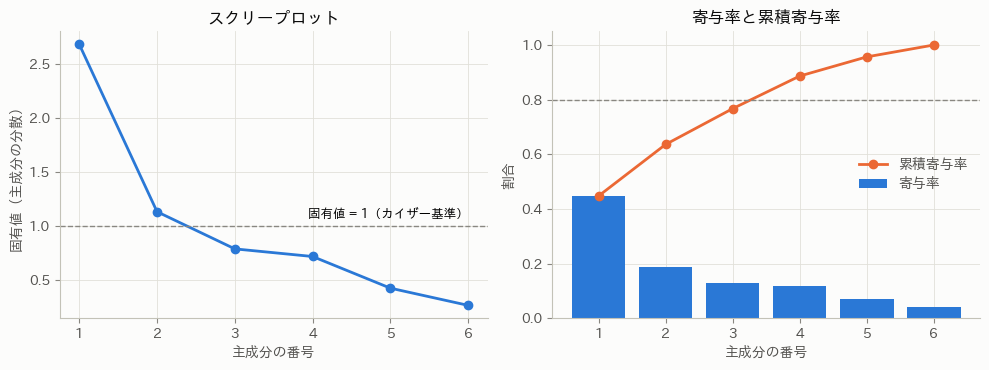

In [155]:
# 寄与率・累積寄与率とスクリープロット
contrib = eigval / eigval.sum()
contrib_tab = pd.DataFrame({"固有値": eigval, "寄与率": contrib, "累積寄与率": contrib.cumsum()},
                           index=pc_names)
print(contrib_tab.round(3).to_string())
print("\nカイザー基準（固有値 > 1）で選ぶ成分数:", int((eigval > 1).sum()))
print("累積寄与率 80% を超える最小の成分数:", int(np.argmax(contrib.cumsum() >= 0.8) + 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(range(1, p_pca + 1), eigval, marker="o", color=PALETTE[0])
axes[0].axhline(1, color=INK["muted"], ls="--", lw=1)
axes[0].text(p_pca, 1.05, "固有値 = 1（カイザー基準）", ha="right", va="bottom", fontsize=9)
axes[0].set(title="スクリープロット", xlabel="主成分の番号", ylabel="固有値（主成分の分散）")
axes[1].bar(range(1, p_pca + 1), contrib, color=PALETTE[0], label="寄与率")
axes[1].plot(range(1, p_pca + 1), contrib.cumsum(), marker="o", color=PALETTE[1], label="累積寄与率")
axes[1].axhline(0.8, color=INK["muted"], ls="--", lw=1)
axes[1].set(title="寄与率と累積寄与率", xlabel="主成分の番号", ylabel="割合", ylim=(0, 1.05))
axes[1].legend(loc="center right")
fig.tight_layout()
plt.show()

**結果の読み方**
- 第1主成分の寄与率は約45%、第2主成分まで約64%、第3主成分まで約77%。
- カイザー基準では2成分、累積寄与率80%基準では4成分となり、基準によって答えが違う。スクリープロットでは第2と第3の間で傾きが緩み、第3・第4成分の固有値（0.79, 0.72）はほぼ同じである。
- 解釈の面では「全体の強さ」と「速攻型か耐久型か」の2成分で主な構造はつかめるが、6項目の分散の3分の1以上は残る。

### 22.3 主成分負荷量

**問い**：各主成分は、どの種族値と強く結びついているか。

**手法の要点**
- 主成分負荷量は、元の変数と主成分得点の相関係数である。相関行列からの PCA では
  $$\operatorname{Corr}(z_j,y_k)=\frac{\operatorname{Cov}(z_j,y_k)}{\sqrt{V[z_j]V[y_k]}}=\frac{\lambda_kw_{jk}}{1\cdot\sqrt{\lambda_k}}=\sqrt{\lambda_k}\,w_{jk}$$
  （$\operatorname{Cov}(\boldsymbol z,y_k)=R\boldsymbol w_k=\lambda_k\boldsymbol w_k$ を使った）。
- 共分散行列からの PCA では $\operatorname{Corr}(x_j,y_k)=\sqrt{\lambda_k}\,w_{jk}/\sqrt{s_{jj}}$ となる。
- 変数 $j$ について全成分の負荷量の2乗和は1（$\sum_k\lambda_kw_{jk}^2=r_{jj}=1$）。

（→ py 22-3：負荷量を式で計算し、相関係数と照合）

負荷量と相関係数の最大差: 0.0
主成分得点の分散（= 固有値）: [2.6863 1.131  0.7858 0.715  0.4208 0.2609]

各変数の負荷量の2乗和（全成分）= 1: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


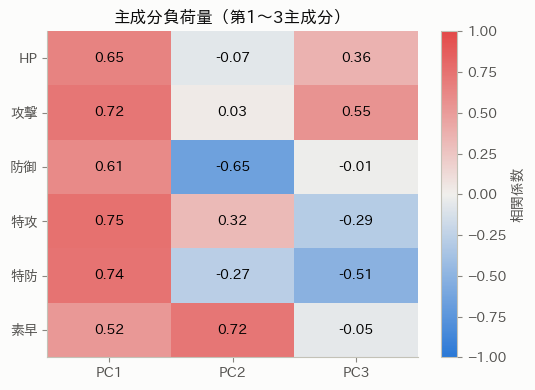

,PC1,PC2,PC3
HP,0.648,-0.068,0.361
攻撃,0.722,0.025,0.551
防御,0.606,-0.654,-0.010
特攻,0.751,0.320,-0.295
特防,0.736,-0.267,-0.512
素早,0.522,0.724,-0.053


In [156]:
# 主成分負荷量 = 固有ベクトル × √固有値 = 標準化変数と主成分得点の相関係数
scores_pca = Z_pca.values @ eigvec                 # 主成分得点
loading = eigvec * np.sqrt(eigval)
corr_zs = np.array([[np.corrcoef(Z_pca.values[:, j], scores_pca[:, k])[0, 1]
                     for k in range(p_pca)] for j in range(p_pca)])
print("負荷量と相関係数の最大差:", np.abs(loading - corr_zs).max().round(10))
print("主成分得点の分散（= 固有値）:", scores_pca.var(axis=0, ddof=1).round(4))
loading_df = pd.DataFrame(loading, index=STATS, columns=pc_names)
print("\n各変数の負荷量の2乗和（全成分）= 1:", (loading_df ** 2).sum(axis=1).round(4).tolist())

fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(loading_df.iloc[:, :3], cmap=DIV_CMAP, vmin=-1, vmax=1, aspect="auto")
for (j, k), v in np.ndenumerate(loading_df.iloc[:, :3].values):
    ax.text(k, j, f"{v:.2f}", ha="center", va="center", fontsize=10)
ax.set(xticks=range(3), xticklabels=pc_names[:3], yticks=range(p_pca), yticklabels=STATS,
       title="主成分負荷量（第1〜3主成分）")
ax.grid(False)
fig.colorbar(im, ax=ax, label="相関係数")
fig.tight_layout()
plt.show()
loading_df.iloc[:, :3].round(3)

**結果の読み方**
- 固有ベクトル×√固有値と、標準化変数と主成分得点の相関係数は数値誤差の範囲で一致した。
- 第1主成分の負荷量は6項目とも 0.5〜0.8 程度の正の値。第2主成分は素早（正）と防御（負）の負荷量の絶対値が大きい。第3主成分は HP・攻撃（物理寄り）と特防・特攻（特殊寄り）の対比として読めるが、寄与率は13%と小さい。

### 22.4 主成分得点とバイプロット

**問い**：第1・第2主成分の平面で、ポケモンはどう並ぶか。

**手法の要点**
- 個体 $i$ の第 $k$ 主成分得点は $y_{ik}=\boldsymbol w_k^\top\boldsymbol z_i$（標準化したデータを代入）。
- 主成分得点の散布図に、各変数の負荷量 $(\sqrt{\lambda_1}w_{j1},\sqrt{\lambda_2}w_{j2})$ を矢印で重ねた図をバイプロットという。矢印の向きに離れた個体ほどその変数が大きい。
- 2次元に落とした図は累積寄与率（ここでは約64%）の分の情報しか表していない。

（→ py 22-4：主成分得点の散布図と、代表的なポケモンの注記）

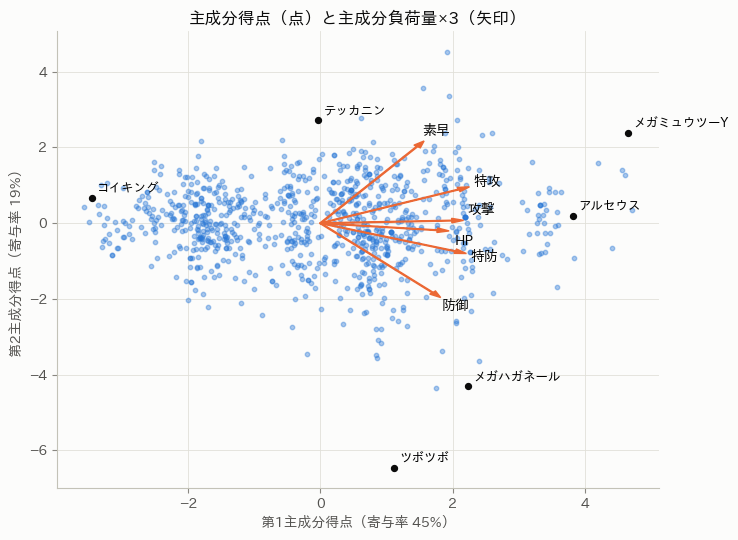

PC1 と合計種族値の相関: 0.998

PC2 が大きい（素早・特攻寄り）5匹: ['デオキシスA', 'フェローチェ', 'デオキシスN', 'アギルダー', 'テッカニン']
PC2 が小さい（防御・特防寄り）5匹: ['ツボツボ', 'ツンデツンデ', 'メガハガネール', 'メガボスゴドラ', 'トリデプス']


In [157]:
# 主成分得点の散布図（第1・第2主成分）と負荷量の矢印（バイプロット）
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(scores_pca[:, 0], scores_pca[:, 1], s=10, alpha=0.4, color=PALETTE[0], label="ポケモン")
label_names = ["ツボツボ", "テッカニン", "メガミュウツーY", "コイキング", "アルセウス", "メガハガネール"]
for nm in label_names:
    i = df.index[df["名前"] == nm][0]
    ax.annotate(nm, (scores_pca[i, 0], scores_pca[i, 1]), xytext=(4, 4),
                textcoords="offset points", fontsize=9)
    ax.scatter(scores_pca[i, 0], scores_pca[i, 1], s=18, color=INK["primary"])
arrow_scale = 3
for j, s in enumerate(STATS):
    ax.arrow(0, 0, loading[j, 0] * arrow_scale, loading[j, 1] * arrow_scale,
             color=PALETTE[1], width=0.02, head_width=0.12, length_includes_head=True)
    dy = {"HP": -0.25, "攻撃": 0.25}.get(s, 0)   # 向きの近い HP と攻撃のラベルをずらす
    ax.text(loading[j, 0] * arrow_scale * 1.12, loading[j, 1] * arrow_scale * 1.12 + dy, s,
            fontsize=10, ha="center", va="center")
ax.set(title="主成分得点（点）と主成分負荷量×3（矢印）",
       xlabel=f"第1主成分得点（寄与率 {contrib[0]:.0%}）", ylabel=f"第2主成分得点（寄与率 {contrib[1]:.0%}）")
fig.tight_layout()
plt.show()

# 第1・第2主成分の上位・下位
pc_tab = pd.DataFrame({"名前": df["名前"], "合計種族値": df["合計種族値"],
                       "PC1": scores_pca[:, 0], "PC2": scores_pca[:, 1]})
print("PC1 と合計種族値の相関:", np.corrcoef(pc_tab["PC1"], pc_tab["合計種族値"])[0, 1].round(3))
print("\nPC2 が大きい（素早・特攻寄り）5匹:", pc_tab.nlargest(5, "PC2")["名前"].tolist())
print("PC2 が小さい（防御・特防寄り）5匹:", pc_tab.nsmallest(5, "PC2")["名前"].tolist())

**結果の読み方**
- 第1主成分得点と合計種族値の相関は 0.998 で、第1主成分はほぼ合計種族値の言い換えになっている（6項目の重みが近いため）。
- 右側（強い側）にはアルセウス・メガミュウツーYなど、左端にはコイキングがいる。
- 第2主成分の上側にはデオキシス（アタックフォルム）・フェローチェ・テッカニンなど素早の高いポケモン、下側にはツボツボ・ツンデツンデ・メガハガネールなど防御に偏ったポケモンが並ぶ。HP の負荷量は第1主成分に偏り（第2主成分では約0）、HP の突出したハピナスなどはこの平面では目立たない（HP は第3主成分にも正の負荷量 約0.36 をもつ）。

### 22.5 共分散行列と相関行列の違い

**問い**：分散共分散行列から始めるか、相関行列から始めるかで結果はどう変わるか。

**手法の要点**
- 共分散行列からの PCA は、分散の大きい変数ほど主成分への影響が大きい。単位（kg と種族値など）や尺度が違う変数を混ぜると、分散の大きい変数が第1主成分をほぼ占めてしまう。
- 相関行列からの PCA は、全変数を分散1にそろえてから行う PCA と同じで、単位に依存しない。
- 種族値6項目のように同じ単位で分散も近い変数なら、どちらでも似た結果になる。

（→ py 22-5：6項目だけの場合と、`重さ`（kg）を加えた場合を比較）

In [158]:
# 共分散行列 vs 相関行列: 単位の違う変数（重さ kg）を混ぜると差が大きい
def pca_first(M, cols):
    """行列 M の第1固有ベクトルと寄与率を返す."""
    w, v = np.linalg.eigh(M)
    v1 = v[:, -1] * np.sign(v[np.abs(v[:, -1]).argmax(), -1])
    return pd.Series(v1, index=cols), w[-1] / w.sum()

cols_mix = STATS + ["重さ"]
X_mix = df[cols_mix].astype(float)
res = {}
for label, cols in [("6項目", STATS), ("6項目+重さ", cols_mix)]:
    v_cov, r_cov = pca_first(np.cov(X_mix[cols].T), cols)
    v_cor, r_cor = pca_first(np.corrcoef(X_mix[cols].T), cols)
    res[(label, "共分散")] = v_cov
    res[(label, "相関")] = v_cor
    print(f"{label}: 第1主成分の寄与率  共分散行列 {r_cov:.3f} / 相関行列 {r_cor:.3f}")
print("\n標準偏差:", X_mix.std().round(1).to_dict())
print("\n第1主成分の係数（固有ベクトル）")
pd.DataFrame(res).reindex(cols_mix).round(3)

6項目: 第1主成分の寄与率  共分散行列 0.457 / 相関行列 0.448
6項目+重さ: 第1主成分の寄与率  共分散行列 0.775 / 相関行列 0.429

標準偏差: {'HP': 26.0, '攻撃': 32.5, '防御': 31.2, '特攻': 33.2, '特防': 27.9, '素早': 29.4, '重さ': 124.7}

第1主成分の係数（固有ベクトル）


6項目        6項目+重さ       
      共分散     相関    共分散     相関
HP  0.310  0.396  0.093  0.385
攻撃  0.490  0.440  0.117  0.419
防御  0.379  0.370  0.124  0.376
特攻  0.517  0.458  0.078  0.403
特防  0.392  0.449  0.076  0.410
素早  0.316  0.319  0.015  0.253
重さ    NaN    NaN  0.975  0.374

**結果の読み方**
- 6項目だけなら、第1主成分の寄与率は共分散行列で約46%、相関行列で約45%とほぼ同じ。係数はどちらも全項目が正で、分散のやや小さい HP の重みが共分散行列では小さくなる程度の違いである。
- `重さ`（標準偏差 約125 kg、種族値の約4倍）を加えると、共分散行列からの第1主成分は係数のほとんどが `重さ` に集中し、寄与率も約78%に跳ね上がる。これは「重さの分散が大きい」ことを表しているだけで、種族値の構造を要約していない。単位の違う変数を扱うときは相関行列を使う。

### 22.6 自己符号化器（オートエンコーダ）

**問い**：ニューラルネットワークで次元削減すると、PCA と比べてどうか。

**手法の要点**
- 自己符号化器は、入力 $\boldsymbol x$ を低次元の表現 $\boldsymbol h=f(W_1\boldsymbol x+\boldsymbol b_1)$ に符号化し、$\hat{\boldsymbol x}=g(W_2\boldsymbol h+\boldsymbol b_2)$ で復号化するニューラルネットワークで、再構成誤差 $\sum_i\|\boldsymbol x_i-\hat{\boldsymbol x}_i\|^2$ を最小にするよう重みを学習する（入力と出力が同じ教師なし学習）。
- 活性化関数が恒等写像（線形）で中間層が $m$ 個なら、最適解の $\boldsymbol h$ が張る部分空間は第1〜第 $m$ 主成分の部分空間と一致し、再構成誤差の最小値は PCA と同じ（捨てた固有値の和に比例）になる。ただし $\boldsymbol h$ の各成分は主成分そのものとは限らない（部分空間内で回転していてよい）。
- 非線形の活性化関数と多層化で、曲がった低次元構造もとらえられる。そのぶん解釈は難しく、過学習や初期値依存がある。

（→ py 22-6：`sklearn.neural_network.MLPRegressor` で入力＝出力として学習し、PCA と再構成誤差を比較）

In [159]:
# 自己符号化器（2次元のボトルネック）と主成分分析の再構成誤差の比較
Zv = Z_pca.values
pca2 = PCA(n_components=2).fit(Zv)
recon_pca = pca2.inverse_transform(pca2.transform(Zv))
mse_pca = np.mean((Zv - recon_pca) ** 2)

# 線形（恒等活性化）の自己符号化器: 入力6 → 2 → 出力6
ae_lin = MLPRegressor(hidden_layer_sizes=(2,), activation="identity", solver="adam",
                      learning_rate_init=0.01, max_iter=3000, tol=1e-7, random_state=SEED).fit(Zv, Zv)
mse_lin = np.mean((Zv - ae_lin.predict(Zv)) ** 2)
# 非線形（tanh）の自己符号化器: 6 → 8 → 2 → 8 → 6
ae_tanh = MLPRegressor(hidden_layer_sizes=(8, 2, 8), activation="tanh", solver="adam",
                       learning_rate_init=0.01, max_iter=3000, tol=1e-7, random_state=SEED).fit(Zv, Zv)
mse_tanh = np.mean((Zv - ae_tanh.predict(Zv)) ** 2)

print(f"PCA（2成分）の再構成誤差（平均2乗誤差）: {mse_pca:.4f}")
print(f"  理論値 = 捨てた固有値の和 / p × (n-1)/n = {eigval[2:].sum() / p_pca * (n_pca - 1) / n_pca:.4f}")
print(f"線形自己符号化器（6-2-6）            : {mse_lin:.4f}")
print(f"非線形自己符号化器（6-8-2-8-6, tanh） : {mse_tanh:.4f}")

# 線形自己符号化器の中間層（符号）は PCA の2次元部分空間とほぼ同じか: 正準相関で確認
code_lin = Zv @ ae_lin.coefs_[0] + ae_lin.intercepts_[0]
q1, _ = np.linalg.qr(code_lin - code_lin.mean(axis=0))
q2, _ = np.linalg.qr(pca2.transform(Zv))
print("線形AEの符号とPCA得点が張る部分空間の正準相関:",
      np.linalg.svd(q1.T @ q2, compute_uv=False).round(4))

PCA（2成分）の再構成誤差（平均2乗誤差）: 0.3634
  理論値 = 捨てた固有値の和 / p × (n-1)/n = 0.3634
線形自己符号化器（6-2-6）            : 0.3635
非線形自己符号化器（6-8-2-8-6, tanh） : 0.3277
線形AEの符号とPCA得点が張る部分空間の正準相関: [1.     0.9999]


**結果の読み方**
- 2成分の PCA の平均2乗再構成誤差は約0.363で、捨てた固有値の和から計算した理論値と一致した。
- 線形の自己符号化器（6-2-6）の誤差もほぼ同じ約0.363で、中間層が張る部分空間と PCA の2次元部分空間の正準相関はほぼ1（同じ部分空間）だった。
- 非線形（tanh、6-8-2-8-6）では約0.33と少し小さくなった。ただし訓練データでの誤差なので、過学習の分を含む。

### まとめ

- 種族値6項目の相関行列からの PCA では、第1主成分（寄与率約45%）が「全体の強さ」＝ほぼ合計種族値、第2主成分（約19%）が「素早・特攻寄りか、防御寄りか」を表した。
- 成分数はカイザー基準で2、累積寄与率80%基準で4と基準によって違い、目的に応じて選ぶ必要がある。
- 単位の違う変数を混ぜるなら相関行列を使う。共分散行列のままでは分散の大きい変数が主成分を支配する。
- PCA は線形の次元削減であり、線形の自己符号化器と同じ部分空間を与える。非線形な構造を捉えたいときは自己符号化器などを検討する。

## 第23章 判別分析

### 章の概要

判別分析は、所属する群がわかっている学習データから分類規則を作り、新しい個体がどの群に属するかを特徴量から判定する手法である（教師あり学習）。
中心となる考え方は「群をよく分ける方向・境界を、群間のばらつきと群内のばらつきの比や、事後確率から決める」ことで、正規分布を仮定すると線形判別・2次判別・ベイズ判別が一つの枠組みにまとまる。
分類器の良し悪しは混同行列・ROC 曲線で評価し、学習に使ったデータでの評価が楽観的になる点は交差検証で補う。
第18章の質的回帰（ロジスティック回帰）などと同じ「分類」の問題を、多変量正規分布の立場から扱う章であり、第22章の主成分分析（群の情報を使わない次元削減）と正準判別分析（群を分ける次元削減）の違いにも注意する。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 23.1 | フィッシャーの線形判別 | 種族値から「むし」と「ドラゴン」を見分ける1次式はどれか |
| 23.2 | マハラノビス距離による判別 | 各ポケモンはどちらの群の平均に「近い」か |
| 23.3 | ベイズ判別 | 事前確率を変えると判別結果はどう変わるか |
| 23.4 | 2次判別 | 群ごとに分散共分散行列が違うことを考慮すると改善するか |
| 23.5 | 正準判別分析 | くさ・ほのお・みずの3群を2次元でどれだけ分けられるか |
| 23.6 | サポートベクターマシン | マージン最大化の境界は C やカーネルでどう変わるか |
| 23.7 | 混同行列・ROC/AUC | 判別の性能をどう測るか |
| 23.8 | 交差検証 | 訓練データでの評価はどれくらい楽観的か |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`, `攻撃`, `防御`, `特攻`, `特防`, `素早` | 量的 | 判別に使う特徴量（6変数） |
| `タイプ1` | 質的 | 群のラベル |

- **対象の行**：23.1〜23.4, 23.6〜23.8 は **`タイプ1`** が「むし」（78匹, $y=0$）か「ドラゴン」（37匹, $y=1$）の115匹。タイプ2で持つ場合（タイプ2がドラゴン24匹、むし5匹）は含めない。両方を持つポケモンはいない。23.5 は `タイプ1` が「くさ」「ほのお」「みず」の266匹。
- **陽性**：感度・特異度では「ドラゴン」を陽性とする。
- **データの性質と注意点**：ドラゴンは全項目で平均が高く（合計種族値の平均 約544 対 約386）、群の違いの多くは「全体の強さ」である。分散もドラゴンは HP・特攻で大きく、素早・防御で小さいなど、群で異なる。同じ進化系統の行は独立でないため、交差検証の評価もやや楽観的になりうる。

（→ py 23-0：群ごとの件数と平均・標準偏差）

In [160]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 2群: タイプ1が「むし」(y=0) と「ドラゴン」(y=1)。ドラゴンを陽性とする
d2 = df[df["タイプ1"].isin(["むし", "ドラゴン"])].reset_index(drop=True)
X2 = d2[STATS].to_numpy(float)
y2 = (d2["タイプ1"] == "ドラゴン").to_numpy(int)
print("件数:", {"むし(0)": int((y2 == 0).sum()), "ドラゴン(1)": int((y2 == 1).sum())})
print("タイプ2にドラゴン/むしを含む行（今回は使わない）:",
      int((types_of(df, "ドラゴン") & (df["タイプ1"] != "ドラゴン")).sum()), "/",
      int((types_of(df, "むし") & (df["タイプ1"] != "むし")).sum()))
d2.groupby("タイプ1", observed=True)[STATS + ["合計種族値"]].agg(["mean", "std"]).T.round(1).unstack()

件数: {'むし(0)': 78, 'ドラゴン(1)': 37}
タイプ2にドラゴン/むしを含む行（今回は使わない）: 24 / 5


タイプ1      むし          ドラゴン       
        mean    std   mean    std
HP      57.5   17.3   84.1   32.6
攻撃      72.5   37.5  108.9   33.3
防御      71.9   34.3   87.5   24.4
特攻      56.6   29.6   93.5   40.8
特防      64.3   31.2   87.6   29.0
素早      63.6   34.2   82.5   23.3
合計種族値  386.3  119.7  544.1  146.5

### 23.1 フィッシャーの線形判別

**問い**：種族値の1次式 $y=\boldsymbol w^\top\boldsymbol x$ で「むし」と「ドラゴン」をよく分けるには、係数 $\boldsymbol w$ をどう選べばよいか。

**手法の要点**
- 2群の標本平均ベクトルを $\bar{\boldsymbol x}_1$（ドラゴン）, $\bar{\boldsymbol x}_0$（むし）、プールした分散共分散行列を
  $$S_W=\frac{(n_1-1)S_1+(n_0-1)S_0}{n_1+n_0-2}$$
  とする。射影後の「群間の差の2乗 ÷ 群内分散」$\dfrac{\{\boldsymbol w^\top(\bar{\boldsymbol x}_1-\bar{\boldsymbol x}_0)\}^2}{\boldsymbol w^\top S_W\boldsymbol w}$ を最大にする $\boldsymbol w$ は（定数倍を除いて）
  $$\boldsymbol w=S_W^{-1}(\bar{\boldsymbol x}_1-\bar{\boldsymbol x}_0)$$
- 判別関数 $f(\boldsymbol x)=\boldsymbol w^\top\left(\boldsymbol x-\dfrac{\bar{\boldsymbol x}_1+\bar{\boldsymbol x}_0}{2}\right)$ が正ならドラゴン、負ならむしと判別する。
- 最大値はマハラノビス平方距離 $D^2=(\bar{\boldsymbol x}_1-\bar{\boldsymbol x}_0)^\top S_W^{-1}(\bar{\boldsymbol x}_1-\bar{\boldsymbol x}_0)$ に等しい（コーシー・シュワルツの不等式）。
- 分布の仮定なしに導けるが、最適な分類規則になるのは次節以降の「等分散の多変量正規分布」の場合である。

（→ py 23-1：$\boldsymbol w$ を手計算し、`LinearDiscriminantAnalysis` の係数と方向を照合）

判別係数 w（手計算）: {'HP': 0.0262, '攻撃': 0.019, '防御': -0.015, '特攻': 0.0156, '特防': 0.0174, '素早': -0.0107}
sklearn coef_ との方向のコサイン類似度: 1.0
比 (w'(xbar1-xbar0))^2 / w'S_W w : 判別係数 1.937, ランダム方向1000本の最大 1.770


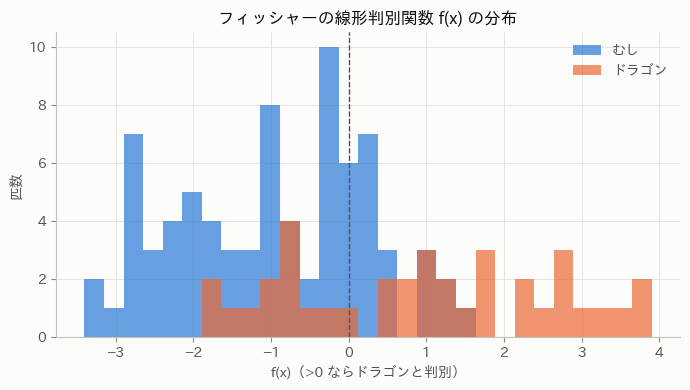

In [161]:
# フィッシャーの線形判別: w = S_W^{-1}(xbar1 - xbar0)
xbar1, xbar0 = X2[y2 == 1].mean(axis=0), X2[y2 == 0].mean(axis=0)
S1, S0 = np.cov(X2[y2 == 1].T), np.cov(X2[y2 == 0].T)
n1, n0 = (y2 == 1).sum(), (y2 == 0).sum()
S_W = ((n1 - 1) * S1 + (n0 - 1) * S0) / (n1 + n0 - 2)      # プールした分散共分散行列
w_fisher = np.linalg.solve(S_W, xbar1 - xbar0)
mid = (xbar1 + xbar0) / 2
f_fisher = (X2 - mid) @ w_fisher                            # f(x) > 0 ならドラゴン

# sklearn は群ごとの（n で割る）分散共分散行列を事前確率で重み付けして平均する。
# 事前確率を既定（標本比率）にすると、それは S_W の定数倍になり、判別係数の方向が一致する
lda_eq = LinearDiscriminantAnalysis(solver="lsqr").fit(X2, y2)
cos = w_fisher @ lda_eq.coef_[0] / np.linalg.norm(w_fisher) / np.linalg.norm(lda_eq.coef_[0])
print("判別係数 w（手計算）:", dict(zip(STATS, w_fisher.round(4))))
print("sklearn coef_ との方向のコサイン類似度:", cos.round(8))
# 群間変動/群内変動の比は w で最大になる（ランダムな方向と比べる）
ratio = lambda v: (v @ (xbar1 - xbar0)) ** 2 / (v @ S_W @ v)
rng = get_rng()
print(f"比 (w'(xbar1-xbar0))^2 / w'S_W w : 判別係数 {ratio(w_fisher):.3f}, "
      f"ランダム方向1000本の最大 {max(ratio(v) for v in rng.normal(size=(1000, 6))):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(f_fisher.min(), f_fisher.max(), 30)
ax.hist(f_fisher[y2 == 0], bins=bins, alpha=0.7, color=PALETTE[0], label="むし")
ax.hist(f_fisher[y2 == 1], bins=bins, alpha=0.7, color=PALETTE[1], label="ドラゴン")
ax.axvline(0, color=INK["secondary"], ls="--", lw=1)
ax.set(title="フィッシャーの線形判別関数 f(x) の分布", xlabel="f(x)（>0 ならドラゴンと判別）", ylabel="匹数")
ax.legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 手計算の $\boldsymbol w$ と sklearn の係数の方向は一致した（コサイン類似度1）。sklearn は群ごとの分散共分散行列を事前確率で重み付けして平均するため、事前確率を標本比率（既定）にしたときに $S_W$ の定数倍となって方向がそろう。
- 係数は HP・攻撃・特攻・特防が正、防御・素早が負。ドラゴンは全体に強いので正の係数が並ぶが、他の項目を固定すると防御・素早が高いほど「むしらしい」ことを表す（素早の高いむし: テッカニン・アギルダーなど）。係数は変数どうしの相関の影響を受けるので、単独の差とは符号が違いうる。
- 比の最大値は 1.94（$=D^2$、$D\approx1.39$）で、ランダムな方向1000本のどれよりも大きい。$f(\boldsymbol x)$ のヒストグラムでは2群はかなり重なる。

### 23.2 マハラノビス距離による判別

**問い**：各ポケモンは、むしとドラゴンのどちらの平均に「近い」か。

**手法の要点**
- 平均 $\bar{\boldsymbol x}_k$ からのマハラノビス平方距離 $D_k^2(\boldsymbol x)=(\boldsymbol x-\bar{\boldsymbol x}_k)^\top S_W^{-1}(\boldsymbol x-\bar{\boldsymbol x}_k)$ は、変数間の相関と尺度を考慮した距離である。
- $D_1^2<D_0^2$ ならドラゴンと判別する。展開すると2次の項が打ち消し合い
  $$D_1^2(\boldsymbol x)-D_0^2(\boldsymbol x)=-2f(\boldsymbol x)$$
  となるので、共通の $S_W$ を使う限りフィッシャーの線形判別と同じ結果になる。

（→ py 23-2：$D_1^2-D_0^2=-2f$ を数値で確認し、誤判別された例を表示）

In [162]:
# マハラノビス平方距離による判別: D1^2 - D0^2 = -2 f(x) を確認
S_W_inv = np.linalg.inv(S_W)
D2_1 = np.einsum("ij,jk,ik->i", X2 - xbar1, S_W_inv, X2 - xbar1)
D2_0 = np.einsum("ij,jk,ik->i", X2 - xbar0, S_W_inv, X2 - xbar0)
print("max |(D1^2 - D0^2) - (-2 f(x))| =", np.abs((D2_1 - D2_0) + 2 * f_fisher).max().round(10))
print("マハラノビス判別とフィッシャー判別の一致率:", np.mean((D2_1 < D2_0) == (f_fisher > 0)))
print("2群の平均間のマハラノビス距離 D =", np.sqrt((xbar1 - xbar0) @ S_W_inv @ (xbar1 - xbar0)).round(3))
maha_tab = pd.DataFrame({"名前": d2["名前"], "タイプ1": d2["タイプ1"].astype(str),
                         "D^2(むし)": D2_0, "D^2(ドラゴン)": D2_1})
# 誤判別された例
maha_tab[(maha_tab["D^2(ドラゴン)"] < maha_tab["D^2(むし)"]) != (y2 == 1)].round(2)

max |(D1^2 - D0^2) - (-2 f(x))| = 0.0
マハラノビス判別とフィッシャー判別の一致率: 1.0
2群の平均間のマハラノビス距離 D = 1.392


,名前,タイプ1,D^2(むし),D^2(ドラゴン)
5,スピアー,むし,6.46,6.45
8,パラセクト,むし,4.04,3.86
13,メガカイロス,むし,7.94,7.52
14,ミニリュウ,ドラゴン,1.53,4.27
15,ハクリュー,ドラゴン,0.53,1.16
20,アリアドス,むし,2.87,2.63
24,ハッサム,むし,3.46,2.94
25,メガハッサム,むし,7.39,6.50
27,ヘラクロス,むし,8.28,7.05
28,メガヘラクロス,むし,16.06,13.18


**結果の読み方**
- $D_1^2-D_0^2$ と $-2f(\boldsymbol x)$ は一致し、判別結果も100%一致した。
- 誤判別は33匹（ドラゴン13匹・むし20匹）。種族値の高いむし（メガヘラクロス・フェローチェ・ウルガモス・ゲノセクトなど）がドラゴン側に、種族値の低い進化前のドラゴン（ミニリュウ・タツベイ・キバゴ・ジャラコなど）がむし側に入る。種族値だけでは「全体の強さ」で分けることになり、タイプの本質的な違いは見えにくい。

### 23.3 ベイズ判別

**問い**：「そもそもドラゴンは少ない」という事前の情報を判別に入れると、結果はどう変わるか。

**手法の要点**
- ベイズの定理より、事後確率の比の対数は
  $$\log\frac{P(G_1\mid\boldsymbol x)}{P(G_0\mid\boldsymbol x)}=\log\frac{p(\boldsymbol x\mid G_1)}{p(\boldsymbol x\mid G_0)}+\log\frac{P(G_1)}{P(G_0)}$$
- 各群が $N_p(\boldsymbol\mu_k,\Sigma)$（共通の $\Sigma$）に従い、母数を標本の値で置き換えると、第1項はちょうど $f(\boldsymbol x)$ になる。事後確率が大きい群に判別する（誤判別確率を最小にする）規則は「$f(\boldsymbol x)+\log\{P(G_1)/P(G_0)\}>0$ ならドラゴン」。
- 事前確率が等しければマハラノビス距離による判別と一致する。事前確率を小さくした群ほど、判別されにくくなる。

（→ py 23-3：事前確率 $P(G_1)=0.5$、標本比率 $37/115\approx0.32$、$0.1$ で比較し、sklearn の事後確率と照合）

In [163]:
# ベイズ判別: log{P(G1|x)/P(G0|x)} = f(x) + log{P(G1)/P(G0)}（等分散の多変量正規分布を仮定）
for p1 in [0.5, n1 / (n1 + n0), 0.1]:
    post_log_ratio = f_fisher + np.log(p1 / (1 - p1))
    pred = post_log_ratio > 0
    print(f"P(ドラゴン)={p1:.3f}: ドラゴンと判別 {pred.sum():3d}匹（実際 {n1}匹）, 正解率 {np.mean(pred == y2):.3f}, "
          f"感度 {pred[y2 == 1].mean():.3f}, 特異度 {1 - pred[y2 == 0].mean():.3f}")

# sklearn の事後確率と照合（事前確率=標本比率。共分散は n で割る版 S_ML を使う）
S_ML = S_W * (n1 + n0 - 2) / (n1 + n0)
f_ml = (X2 - mid) @ np.linalg.solve(S_ML, xbar1 - xbar0)
post_hand = 1 / (1 + np.exp(-(f_ml + np.log(n1 / n0))))
print("\n事後確率 P(ドラゴン|x) の手計算と sklearn predict_proba の最大差:",
      np.abs(post_hand - lda_eq.predict_proba(X2)[:, 1]).max())

P(ドラゴン)=0.500: ドラゴンと判別  44匹（実際 37匹）, 正解率 0.713, 感度 0.649, 特異度 0.744
P(ドラゴン)=0.322: ドラゴンと判別  27匹（実際 37匹）, 正解率 0.809, 感度 0.568, 特異度 0.923
P(ドラゴン)=0.100: ドラゴンと判別  11匹（実際 37匹）, 正解率 0.774, 感度 0.297, 特異度 1.000

事後確率 P(ドラゴン|x) の手計算と sklearn predict_proba の最大差: 3.774758283725532e-15


**結果の読み方**
- 事前確率を 0.5 → 0.32 → 0.1 と下げると、ドラゴンと判別される数は 44 → 27 → 11 匹と減り、感度は 0.65 → 0.57 → 0.30 に下がり、特異度は 0.74 → 0.92 → 1.00 に上がる。
- 正解率は標本比率のとき最大（約0.81）だった。事前確率は「どちらの誤りを重く見るか」の調整でもあり、正解率だけで選ぶものではない。
- 手計算の事後確率は sklearn の `predict_proba` と一致した（sklearn は $n$ で割る分散共分散行列を使うので、同じものを使って照合した）。

### 23.4 2次判別

**問い**：群ごとに分散共分散行列が違うことを考慮すると、判別は改善するか。

**手法の要点**
- 各群が $N_p(\boldsymbol\mu_k,\Sigma_k)$ に従うとすると、対数事後確率（定数を除く）は
  $$g_k(\boldsymbol x)=\log P(G_k)-\frac12\log|S_k|-\frac12(\boldsymbol x-\bar{\boldsymbol x}_k)^\top S_k^{-1}(\boldsymbol x-\bar{\boldsymbol x}_k)$$
  となり、$g_1(\boldsymbol x)>g_0(\boldsymbol x)$ ならドラゴンと判別する。境界は $\boldsymbol x$ の2次式（2次曲面）になる。
- 推定する母数が群ごとに $p(p+1)/2=21$ 個ずつ増えるので、標本が小さい群（ドラゴン37匹）では過学習しやすい。
- 等分散性はボックスの $M$ 検定で調べられる（帰無仮説 $\Sigma_0=\Sigma_1$、多変量正規性を強く仮定し、近似的に自由度 $p(p+1)(g-1)/2$ のカイ2乗分布）。

（→ py 23-4：$g_1-g_0$ を手計算して `QuadraticDiscriminantAnalysis` と照合、ボックスの $M$ 検定）

In [164]:
# 2次判別: 群ごとの分散共分散行列を使う
def qda_score(X, xbar, S, prior):
    """log π_k - (1/2)log|S_k| - (1/2)(x - xbar_k)' S_k^{-1} (x - xbar_k)."""
    Dk = np.einsum("ij,jk,ik->i", X - xbar, np.linalg.inv(S), X - xbar)
    return np.log(prior) - 0.5 * np.linalg.slogdet(S)[1] - 0.5 * Dk

q_hand = qda_score(X2, xbar1, S1, 0.5) - qda_score(X2, xbar0, S0, 0.5)
qda_eq = QuadraticDiscriminantAnalysis(priors=[0.5, 0.5]).fit(X2, y2)
print("手計算と sklearn QDA の判別結果の一致率:", np.mean((q_hand > 0) == qda_eq.predict(X2)))
print("訓練データでの正解率  LDA:", np.mean((f_fisher > 0) == y2).round(3),
      " QDA:", np.mean((q_hand > 0) == y2).round(3))
# 等分散性の検定（ボックスの M 検定, カイ2乗近似）
p_, g_ = 6, 2
ns = np.array([n0, n1])
M = (ns.sum() - g_) * np.linalg.slogdet(S_W)[1] - sum((nk - 1) * np.linalg.slogdet(Sk)[1] for nk, Sk in [(n0, S0), (n1, S1)])
c_ = (np.sum(1 / (ns - 1)) - 1 / (ns.sum() - g_)) * (2 * p_**2 + 3 * p_ - 1) / (6 * (p_ + 1) * (g_ - 1))
chi_box, df_box = M * (1 - c_), p_ * (p_ + 1) * (g_ - 1) / 2
print(f"ボックスの M 検定: χ² = {chi_box:.1f}, 自由度 = {df_box:.0f}, p値 = {stats.chi2.sf(chi_box, df_box):.2e}")

手計算と sklearn QDA の判別結果の一致率: 1.0
訓練データでの正解率  LDA: 0.713  QDA: 0.852
ボックスの M 検定: χ² = 95.3, 自由度 = 21, p値 = 1.94e-11


**結果の読み方**
- 手計算の2次判別は sklearn と100%一致した。訓練データでの正解率は線形判別 0.71 に対して2次判別 0.85 と大きく上がった。
- ボックスの $M$ 検定は $\chi^2\approx95$（自由度21）、$p\approx2\times10^{-11}$ で、有意水準5%で等分散の仮説は棄却される。ただし種族値は正規分布からずれており（HP の歪み等）、$M$ 検定は非正規性にも敏感なので、棄却は割り引いて読む。
- 2次判別の改善が訓練データ特有の過学習でないかは 23.8 の交差検証で確かめる。

### 23.5 正準判別分析（3群）

**問い**：くさ・ほのお・みずの3群を、種族値の2次元の射影でどれだけ分けられるか。

**手法の要点**
- $g$ 群のとき、群内変動行列と群間変動行列を
  $$S_W=\sum_{k=1}^g\sum_{i\in G_k}(\boldsymbol x_i-\bar{\boldsymbol x}_k)(\boldsymbol x_i-\bar{\boldsymbol x}_k)^\top,\qquad S_B=\sum_{k=1}^g n_k(\bar{\boldsymbol x}_k-\bar{\boldsymbol x})(\bar{\boldsymbol x}_k-\bar{\boldsymbol x})^\top$$
  とする。比 $\boldsymbol w^\top S_B\boldsymbol w/\boldsymbol w^\top S_W\boldsymbol w$ を最大にする $\boldsymbol w$ は $S_W^{-1}S_B$ の最大固有値の固有ベクトル、2番目の軸は2番目の固有ベクトル、…となる。
- $S_B$ の階数は $\min(g-1,p)$ なので、0でない固有値は $g-1=2$ 個まで。固有値の比が各正準軸の「判別への寄与」を表す。
- 2群のときは第1正準軸がフィッシャーの線形判別の方向に一致する。

（→ py 23-5：固有値問題を手計算し、`LinearDiscriminantAnalysis(solver="eigen")` と照合、正準変量の散布図）

S_W^{-1} S_B の固有値: [ 0.0933   0.02041  0.       0.      -0.      -0.     ] （非0は 群数-1 = 2 個）
固有値の比: [0.8205 0.1795]
sklearn explained_variance_ratio_: [0.8205 0.1795]
手計算と sklearn の正準変量の相関: [1.0, 1.0]
訓練データでの正解率（3群）: 0.477
予測   くさ  ほのお   みず
実際               
くさ    9    9   65
ほのお   6   11   42
みず    8    9  107


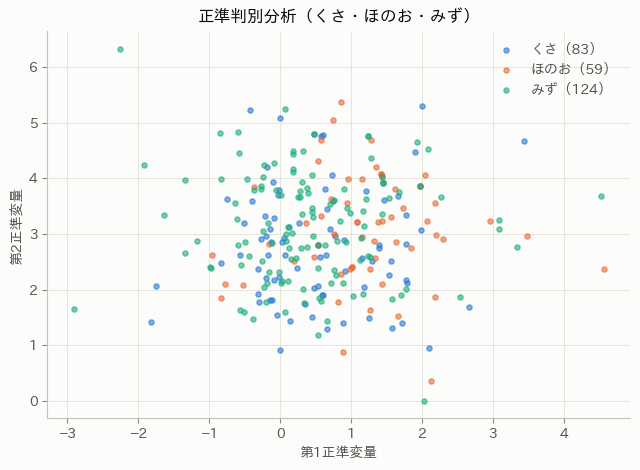

,第1正準係数,第2正準係数
HP,-0.0190,0.0291
攻撃,0.0200,-0.0127
防御,-0.0221,0.0086
特攻,0.0275,-0.0111
特防,-0.0080,-0.0011
素早,0.0064,0.0351


In [165]:
# 正準判別分析（3群: くさ・ほのお・みず）: S_W^{-1} S_B の固有値問題
d3 = df[df["タイプ1"].isin(["くさ", "ほのお", "みず"])].reset_index(drop=True)
grp3 = d3["タイプ1"].astype(str).to_numpy()
X3 = d3[STATS].to_numpy(float)
levels3 = ["くさ", "ほのお", "みず"]
xbar_all = X3.mean(axis=0)
W3 = sum(((X3[grp3 == g] - X3[grp3 == g].mean(0)).T @ (X3[grp3 == g] - X3[grp3 == g].mean(0))) for g in levels3)
B3 = sum((grp3 == g).sum() * np.outer(X3[grp3 == g].mean(0) - xbar_all, X3[grp3 == g].mean(0) - xbar_all)
         for g in levels3)
ev3, V3 = np.linalg.eig(np.linalg.solve(W3, B3))
o3 = np.argsort(ev3.real)[::-1]
ev3, V3 = ev3.real[o3], V3.real[:, o3]
print("S_W^{-1} S_B の固有値:", ev3.round(5), "（非0は 群数-1 = 2 個）")
print("固有値の比:", (ev3[:2] / ev3[:2].sum()).round(4))
lda3 = LinearDiscriminantAnalysis(solver="eigen").fit(X3, grp3)
print("sklearn explained_variance_ratio_:", lda3.explained_variance_ratio_[:2].round(4))
can_hand = (X3 - xbar_all) @ V3[:, :2]
can_sk = lda3.transform(X3)
print("手計算と sklearn の正準変量の相関:",
      [abs(np.corrcoef(can_hand[:, k], can_sk[:, k])[0, 1]).round(6) for k in range(2)])
print("訓練データでの正解率（3群）:", np.mean(lda3.predict(X3) == grp3).round(3))
print(pd.crosstab(pd.Series(grp3, name="実際"), pd.Series(lda3.predict(X3), name="予測")))

fig, ax = plt.subplots(figsize=(6.5, 4.8))
for k, g in enumerate(levels3):
    m = grp3 == g
    ax.scatter(can_sk[m, 0], can_sk[m, 1], s=14, alpha=0.6, color=PALETTE[k], label=f"{g}（{m.sum()}）")
ax.set(title="正準判別分析（くさ・ほのお・みず）", xlabel="第1正準変量", ylabel="第2正準変量")
ax.legend()
fig.tight_layout()
plt.show()
pd.DataFrame(lda3.scalings_[:, :2], index=STATS, columns=["第1正準係数", "第2正準係数"]).round(4)

**結果の読み方**
- 0でない固有値は2個（0.093, 0.020）で、第1正準軸が約82%を担う。固有値の比と正準変量は sklearn と一致した。
- 固有値が小さい（群間変動が群内変動の1割未満）ことが示すとおり、3群は種族値ではほとんど分けられない。訓練データでの正解率は約0.48で、全部を「みず」と答えた場合（124/266≈0.47）とほぼ同じ。散布図でも3色が重なっている。
- 「くさ・ほのお・みず」は種族値の配分ではなくタイプ相性で性格づけられた群であり、種族値だけでは判別できない、という結論になる。

### 23.6 サポートベクターマシン（SVM）

**問い**：マージン最大化で決めた境界は、ペナルティ $C$ やカーネルによってどう変わるか。

**手法の要点**
- ラベルを $t_i\in\{-1,+1\}$ とする。**ハードマージン SVM** は、全データを正しく分ける（線形分離可能な）場合に、制約 $t_i(\boldsymbol w^\top\boldsymbol x_i+b)\ge1$ のもとで $\frac12\|\boldsymbol w\|^2$ を最小にする。マージン（境界から最も近い点までの距離）は $1/\|\boldsymbol w\|$ で、境界を決めるのはマージン上の点（サポートベクター）だけである。
- 線形分離できない場合の **ソフトマージン SVM** は、はみ出し $\xi_i\ge0$ を許して $t_i(\boldsymbol w^\top\boldsymbol x_i+b)\ge1-\xi_i$ のもとで
  $$\frac12\|\boldsymbol w\|^2+C\sum_i\xi_i$$
  を最小にする。$C$ が大きいほどはみ出しへの罰則が強く（ハードマージンに近づき）、境界は訓練データに合わせて複雑になる。
- **カーネル法**：内積 $\boldsymbol x_i^\top\boldsymbol x_j$ を $K(\boldsymbol x_i,\boldsymbol x_j)$（例: RBF カーネル $\exp(-\gamma\|\boldsymbol x_i-\boldsymbol x_j\|^2)$）に置き換えると、非線形な境界が得られる。
- 距離に基づくので、変数を標準化してから使う。

（→ py 23-6：6変数の線形 SVM で $C$ を変える／2変数（HP・攻撃）で線形・RBF カーネルの境界を描く）

6変数・線形 SVM（訓練データ）
  C=    0.01: サポートベクター  75個, 訓練正解率 0.739
  C=     0.1: サポートベクター  64個, 訓練正解率 0.835
  C=       1: サポートベクター  60個, 訓練正解率 0.835
  C=      10: サポートベクター  59個, 訓練正解率 0.843


  C=    1000: サポートベクター  59個, 訓練正解率 0.843
→ C を大きくしても訓練正解率が1にならない → 線形分離可能でないと考えられる（厳密な証明ではない）


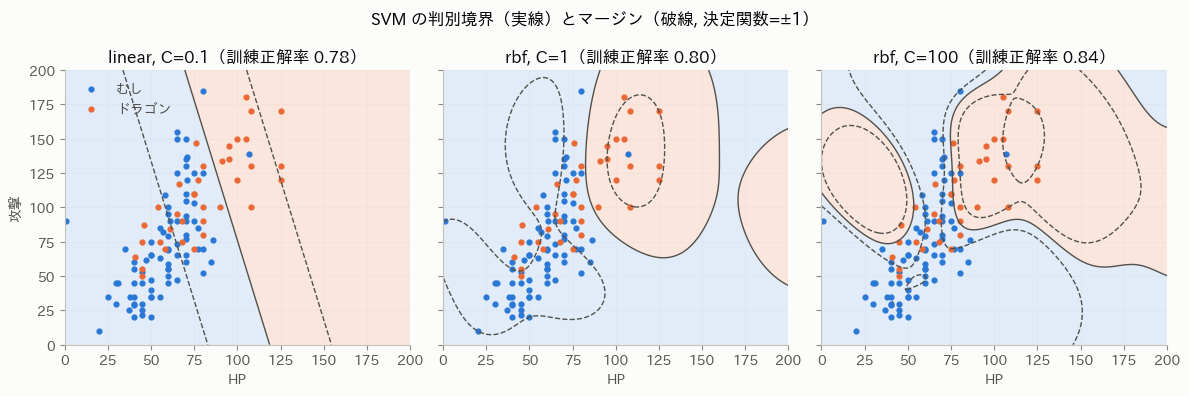

In [166]:
# SVM（標準化したうえで）: C の影響とカーネル
print("6変数・線形 SVM（訓練データ）")
for c_svm in [0.01, 0.1, 1, 10, 1000]:
    svm = make_pipeline(StandardScaler(), SVC(kernel="linear", C=c_svm)).fit(X2, y2)
    print(f"  C={c_svm:>8g}: サポートベクター {svm[-1].n_support_.sum():3d}個, 訓練正解率 {svm.score(X2, y2):.3f}")
print("→ C を大きくしても訓練正解率が1にならない → 線形分離可能でないと考えられる（厳密な証明ではない）")

# 2変数（HP・攻撃）で境界を描く
X2d = d2[["HP", "攻撃"]].to_numpy(float)
xx, yy = np.meshgrid(np.linspace(0, 200, 200), np.linspace(0, 200, 200))
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (kernel, c_svm) in zip(axes, [("linear", 0.1), ("rbf", 1), ("rbf", 100)]):
    svm2 = make_pipeline(StandardScaler(), SVC(kernel=kernel, C=c_svm, gamma="scale")).fit(X2d, y2)
    zz = svm2.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz > 0, levels=[-0.5, 0.5, 1.5], colors=["#dbe8f8", "#fbe1d6"], alpha=0.8)
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors=INK["secondary"], linestyles=["--", "-", "--"], linewidths=1)
    for k, nm in enumerate(["むし", "ドラゴン"]):
        ax.scatter(X2d[y2 == k, 0], X2d[y2 == k, 1], s=12, color=PALETTE[k], label=nm)
    ax.set(title=f"{kernel}, C={c_svm}（訓練正解率 {svm2.score(X2d, y2):.2f}）", xlabel="HP", xlim=(0, 200), ylim=(0, 200))
axes[0].set_ylabel("攻撃")
axes[0].legend(loc="upper left")
fig.suptitle("SVM の判別境界（実線）とマージン（破線, 決定関数=±1）", fontsize=12)
fig.tight_layout()
plt.show()

**結果の読み方**
- 線形 SVM では $C$ を大きくするとサポートベクターの数が 75 → 59 個程度まで減り、訓練正解率は 0.74 → 0.84 程度で頭打ちになる。$C=1000$ でも訓練正解率が1にならないので、この2群は線形分離可能ではないと考えられ、その場合ハードマージン SVM の解は存在しない（有限の $C$ での結果は厳密な証明ではない。厳密には「全点を正しく分ける超平面が存在するか」を線形計画問題の実行可能性として調べれば確かめられる）。
- 2変数の図では、線形カーネルの境界は直線、RBF カーネルでは曲線になり、$C=100$ では訓練データの点を拾うように境界が入り組む。訓練正解率の上昇が汎化性能の向上を意味するとは限らない（23.8）。

### 23.7 混同行列・感度・特異度・ROC/AUC

**問い**：判別の性能を、誤りの種類を分けてどう測るか。

**手法の要点**
- 陽性（ドラゴン）について、混同行列の4つの数 TP, FN, FP, TN から
  - 正解率 $=(TP+TN)/n$
  - 感度（真陽性率, 再現率）$TPR=TP/(TP+FN)$
  - 特異度 $=TN/(TN+FP)=1-FPR$（$FPR$ は偽陽性率）
- 判別得点のしきい値を動かしたときの $(FPR, TPR)$ の軌跡が ROC 曲線、その下の面積が AUC。AUC は「ランダムに選んだ陽性の得点が、ランダムに選んだ陰性の得点より大きい確率」に等しく、マン・ホイットニーの $U$ を $n_1n_0$ で割ったものである。
- 群の大きさが偏っている（むし 68%）と、全部をむしと答えるだけで正解率 0.68 になるので、正解率だけでは性能を判断できない。

（→ py 23-7：線形判別（事前確率0.5）と2次判別の混同行列・指標・ROC 曲線、$U/(n_1n_0)$ と AUC の照合）

       TP    FN    FP    TN    正解率  感度(TPR)  特異度(1-FPR)    AUC
LDA  24.0  13.0  20.0  58.0  0.713    0.649       0.744  0.804
QDA  25.0  12.0   5.0  73.0  0.852    0.676       0.936  0.907

LDA の AUC: U/(n1 n0) = 0.8042  roc_auc_score = 0.8042


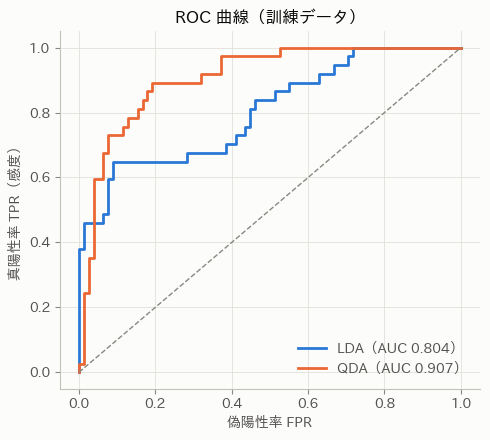

In [167]:
# 混同行列・感度・特異度・ROC/AUC（訓練データで評価。陽性=ドラゴン）
def binary_report(y_true, score, thr=0.0):
    pred = (score > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {"TP": tp, "FN": fn, "FP": fp, "TN": tn, "正解率": (tp + tn) / len(y_true),
            "感度(TPR)": tp / (tp + fn), "特異度(1-FPR)": tn / (tn + fp), "AUC": roc_auc_score(y_true, score)}

rep = pd.DataFrame({"LDA": binary_report(y2, f_fisher), "QDA": binary_report(y2, q_hand)}).T
print(rep.round(3).to_string())
# AUC = P(ドラゴンの得点 > むしの得点)（マン・ホイットニーの U / (n1 n0)）で確認
U = stats.mannwhitneyu(f_fisher[y2 == 1], f_fisher[y2 == 0]).statistic
print("\nLDA の AUC: U/(n1 n0) =", round(U / (n1 * n0), 4), " roc_auc_score =", round(roc_auc_score(y2, f_fisher), 4))

fig, ax = plt.subplots(figsize=(5, 4.5))
for k, (nm, sc) in enumerate([("LDA", f_fisher), ("QDA", q_hand)]):
    fpr, tpr, _ = roc_curve(y2, sc)
    ax.plot(fpr, tpr, color=PALETTE[k], label=f"{nm}（AUC {roc_auc_score(y2, sc):.3f}）")
ax.plot([0, 1], [0, 1], color=INK["muted"], ls="--", lw=1)
ax.set(title="ROC 曲線（訓練データ）", xlabel="偽陽性率 FPR", ylabel="真陽性率 TPR（感度）")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**結果の読み方**
- 線形判別：正解率 0.71、感度 0.65、特異度 0.74、AUC 0.80。2次判別：正解率 0.85、感度 0.68、特異度 0.94、AUC 0.91（いずれも訓練データでの値）。
- 2次判別の改善は主に特異度（むしを正しくむしと判定する）で、感度はほとんど変わらない。
- AUC はマン・ホイットニーの $U/(n_1n_0)$ と一致した。

### 23.8 訓練データでの評価と交差検証

**問い**：訓練データで測った性能は、新しいデータに対する性能よりどれくらい楽観的か。

**手法の要点**
- 分類規則を作ったデータで性能を測ると、そのデータの偶然の特徴にまで合わせた分だけ良く見える（訓練誤差は汎化誤差を過小評価する）。自由度の大きいモデル（2次判別、$C$ の大きい RBF-SVM）ほど差が大きい。
- $K$ 分割交差検証：データを $K$ 個に分け、1個を評価用・残りを学習用とすることを $K$ 回くり返して平均する。層化（各分割の群の比率をそろえる）し、分割の偶然性を減らすためにくり返して平均する。
- 標準化も学習の一部なので、パイプラインに入れて各分割の学習データだけで行う。

（→ py 23-8：層化5分割交差検証を10回くり返し、訓練データでの値と比較）

In [168]:
# 訓練データでの評価は楽観的: 5分割交差検証（10回くり返し）と比較
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "線形SVM C=1": make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
    "RBF-SVM C=1": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1)),
    "RBF-SVM C=1000": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1000)),
}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
rows = []
for nm, mdl in models.items():
    r = cross_validate(mdl, X2, y2, cv=cv, scoring=["accuracy", "roc_auc"], return_train_score=True)
    rows.append({"モデル": nm, "訓練 正解率": r["train_accuracy"].mean(), "CV 正解率": r["test_accuracy"].mean(),
                 "訓練 AUC": r["train_roc_auc"].mean(), "CV AUC": r["test_roc_auc"].mean()})
print("多数派（むし）と常に答えたときの正解率:", round(n0 / (n0 + n1), 3))
pd.DataFrame(rows).set_index("モデル").round(3)

多数派（むし）と常に答えたときの正解率: 0.678


,訓練 正解率,CV 正解率,訓練 AUC,CV AUC
モデル,,,,
LDA,0.811,0.785,0.811,0.775
QDA,0.836,0.797,0.915,0.850
線形SVM C=1,0.829,0.796,0.796,0.773
RBF-SVM C=1,0.852,0.839,0.928,0.799
RBF-SVM C=1000,1.000,0.699,1.000,0.721


**結果の読み方**
- どのモデルも交差検証の正解率・AUC は訓練データでの値より低い（ここでの線形判別は事前確率を標本比率にしているので、23.7 の値とは違う）。
- 最も極端なのは $C=1000$ の RBF-SVM で、訓練正解率 1.00 に対して交差検証では 0.70 と、多数派と答える場合（0.68）とほぼ同じまで落ちる。典型的な過学習である。
- 2次判別は訓練 AUC 0.92 → 交差検証 0.85 と下がるが、それでも線形判別（0.78）より高く、群ごとに分散が違うことを使う利点は一部残る。正解率では $C=1$ の RBF-SVM が最も高い（約0.84）。
- 交差検証の正解率は多くのモデルで 0.78〜0.84 で、多数派と答える場合の 0.68 を上回るが、大きな差ではない。
- 同じ進化系統のポケモンが学習用と評価用に分かれて入ると、似た個体で評価することになるため、交差検証の値もまだ楽観的でありうる（系統ごとに分割する方法が考えられる）。

### まとめ

- 種族値6項目で「むし」と「ドラゴン」（タイプ1）を判別すると、主に「全体の強さ」で分けることになり、交差検証の正解率は 0.8 前後、AUC は 0.77〜0.85 程度である。くさ・ほのお・みずの3群は種族値ではほとんど判別できなかった。
- フィッシャーの線形判別・マハラノビス距離による判別・等事前確率のベイズ判別は同じ規則になる。事前確率を変えると感度と特異度のバランスが動く。
- 2次判別や柔軟な SVM は訓練データでは大きく改善して見えるが、交差検証ではその一部（$C$ の大きい RBF-SVM では全部）が消える。性能は必ず学習に使っていないデータで測る。

## 第24章 クラスター分析

### 章の概要

クラスター分析は、正解のグループ（ラベル）がない状態で、個体間の「近さ」を定めて似たもの同士をまとめる手法である（教師なし学習）。
中心となる考え方は「距離（ここでは標準化した種族値のユークリッド距離）」と「クラスターどうしの距離の定め方」で、定め方によってまとまり方が大きく変わる。
階層的な方法は併合の過程をデンドログラムで示し、K-means 法はクラスター数を与えてクラスター内平方和を小さくする。
第23章の判別分析（群が既知）と対になる手法であり、第22章の主成分分析と同じく種族値の構造を探る。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 24.1 | 階層的クラスタリング（5つの連結法） | 連結法によって第1世代のまとまり方はどう変わるか |
| 24.2 | ウォード法のデンドログラム | 強いポケモンはどんな「型」に分かれるか |
| 24.3 | K-means 法（エルボー法・シルエット） | 全920匹を何個のクラスターに分けるのがよいか |
| 24.4 | K-means 法の初期値依存性 | 初期値を変えると結果はどれくらい変わるか |
| 24.5 | クラスターの解釈 | 各クラスターはどんな種族値の配分をもつか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`, `攻撃`, `防御`, `特攻`, `特防`, `素早` | 量的 | 距離の計算に使う6変数（標準化する） |
| `世代`, `is_form` | — | 階層的クラスタリングの対象を絞る |
| `名前`, `合計種族値` | — | クラスターの解釈に使う |

- **対象の行**：
  - 24.1：第1世代で姿違いを除いた151匹（全920匹ではデンドログラムが読めないため）。
  - 24.2：そのうち合計種族値500以上の33匹（名前を並べて読める数）。
  - 24.3〜24.5：K-means 法は全920行。
- **加工**：各変数を平均0・不偏分散1に標準化する（24.2 は151匹の平均・標準偏差を使う）。種族値6項目は同じ単位だが、標準化しておくと分散の大きい項目に距離が引っ張られない。
- **データの性質と注意点**：種族値の分布は「はっきり分かれた塊」ではなく連続的に広がっているので、どの方法でもクラスターの境界は人為的なものになる。HP のラッキー（250）、防御のパルシェン（180）などの外れ値は、方法によっては単独のクラスターになる。

（→ py 24-0：対象の行数と要約統計）

In [169]:
import warnings

# Windows 環境で出る KMeans・joblib の実行環境に関する警告を抑える（結果には影響しない）
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 階層的クラスタリング: 第1世代の姿違いを除く151匹
g1 = df[(df["世代"] == 1) & ~df["is_form"]].reset_index(drop=True)
Z_g1 = ((g1[STATS] - g1[STATS].mean()) / g1[STATS].std(ddof=1)).to_numpy()
# K-means: 全920行
Z_all = ((df[STATS] - df[STATS].mean()) / df[STATS].std(ddof=1)).to_numpy()
print("階層的クラスタリングの対象:", len(g1), "匹（第1世代・姿違いを除く）")
print("K-means の対象:", len(df), "匹（全行）")
g1[STATS].describe().T[["mean", "std", "min", "max"]].round(1)

階層的クラスタリングの対象: 151 匹（第1世代・姿違いを除く）
K-means の対象: 920 匹（全行）


,mean,std,min,max
HP,64.2,28.6,10.0,250.0
攻撃,72.9,26.8,5.0,134.0
防御,68.2,26.9,5.0,180.0
特攻,67.1,28.5,15.0,154.0
特防,66.1,24.2,20.0,125.0
素早,69.1,27.0,15.0,150.0


### 24.1 階層的クラスタリングと連結法の比較

**問い**：クラスター間の距離の定め方（連結法）によって、第1世代151匹のまとまり方はどう変わるか。

**手法の要点**
- はじめは各個体を1つのクラスターとし、最も近い2つのクラスターを順に併合していく（凝集型）。併合の過程を木で表したものがデンドログラムで、縦軸は併合したときのクラスター間距離。適当な高さで切るとクラスターが得られる。
- クラスター $A,B$ の距離の定め方（$d(\boldsymbol x,\boldsymbol y)$ は個体間のユークリッド距離）：
  - 最短距離法：$\min_{\boldsymbol x\in A,\boldsymbol y\in B}d(\boldsymbol x,\boldsymbol y)$。細長い鎖状につながりやすい（鎖効果）。
  - 最長距離法：$\max_{\boldsymbol x\in A,\boldsymbol y\in B}d(\boldsymbol x,\boldsymbol y)$。直径の小さいクラスターができやすい。
  - 群平均法：全ペアの距離の平均 $\frac{1}{|A||B|}\sum_{\boldsymbol x\in A}\sum_{\boldsymbol y\in B}d(\boldsymbol x,\boldsymbol y)$。
  - 重心法：重心間の距離 $d(\bar{\boldsymbol x}_A,\bar{\boldsymbol x}_B)$。併合後に距離が前より小さくなる「逆転」が起こりうる。
  - ウォード法：併合によるクラスター内平方和の増加量 $\dfrac{|A||B|}{|A|+|B|}\|\bar{\boldsymbol x}_A-\bar{\boldsymbol x}_B\|^2$ が最小のペアを併合する（scipy の縦軸はこの2倍の平方根）。大きさのそろったクラスターができやすい。
- コーフェン相関：デンドログラム上の距離（2個体が初めて同じクラスターになる高さ）と元の距離の相関。木が元の距離をどれだけ保つかの目安。

（→ py 24-1：5つの連結法で4クラスターに切ったときの大きさ、コーフェン相関、デンドログラム）

       コーフェン相関        4クラスターの大きさ  併合距離の逆転
方法                                       
最短距離法    0.622    [148, 1, 1, 1]        0
最長距離法    0.569   [83, 56, 11, 1]        0
群平均法     0.749    [147, 2, 1, 1]        0
重心法      0.736    [148, 1, 1, 1]       11
ウォード法    0.454  [68, 36, 32, 15]        0
最短距離法 の小さいクラスター: パルシェン / イワーク / ラッキー
ウォード法 の小さいクラスター: ライチュウ, ケーシィ, ユンゲラー, フーディン


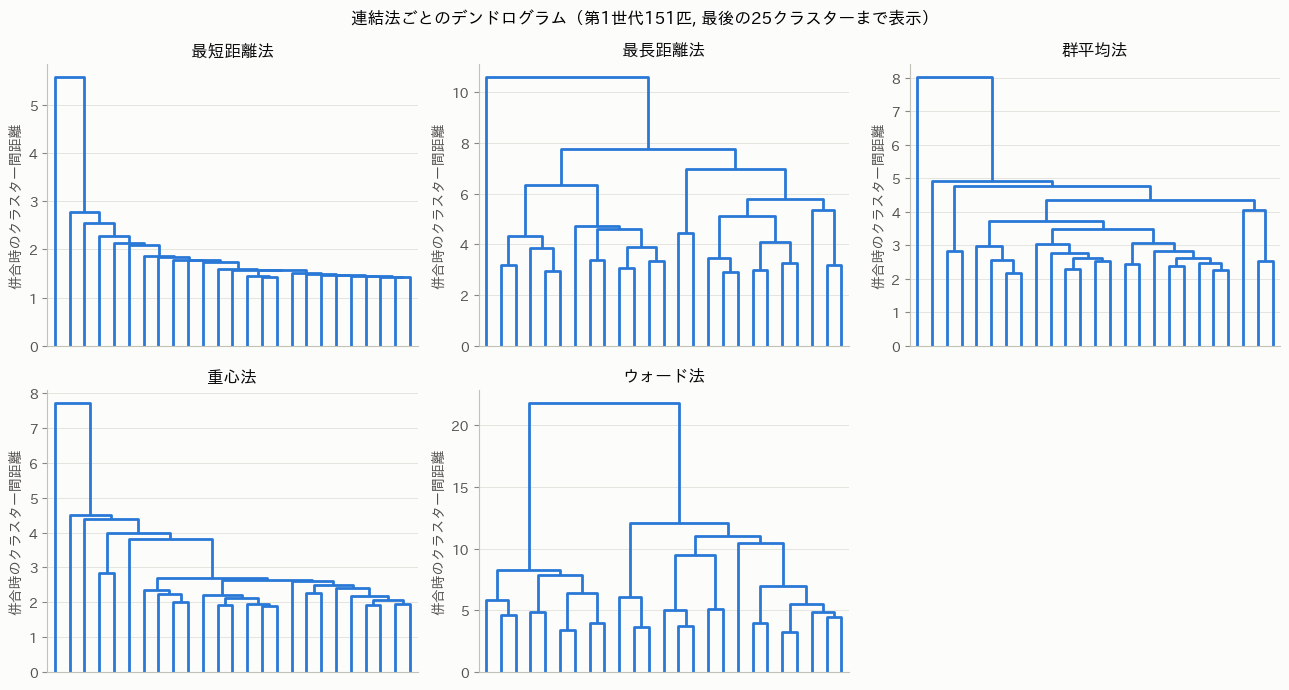

In [170]:
# 5つの連結法の比較（ユークリッド距離、標準化データ）
methods = {"single": "最短距離法", "complete": "最長距離法", "average": "群平均法",
           "centroid": "重心法", "ward": "ウォード法"}
d_g1 = pdist(Z_g1)                     # 個体間のユークリッド距離
links = {m: linkage(Z_g1, method=m) for m in methods}   # 重心法・ウォード法は観測値から計算
rows = []
for m, lk in links.items():
    sizes = np.sort(np.bincount(fcluster(lk, t=4, criterion="maxclust"))[1:])[::-1]
    heights = lk[:, 2]
    rows.append({"方法": methods[m], "コーフェン相関": cophenet(lk, d_g1)[0],
                 "4クラスターの大きさ": sizes.tolist(),
                 "併合距離の逆転": int((np.diff(heights) < -1e-12).sum())})
print(pd.DataFrame(rows).set_index("方法").round(3).to_string())
for m in ["single", "ward"]:
    cut = fcluster(links[m], t=4, criterion="maxclust")
    small = [", ".join(g1["名前"][cut == c].head(4)) for c in np.unique(cut) if (cut == c).sum() <= 15]
    print(f"{methods[m]} の小さいクラスター:", " / ".join(small))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (m, lk) in zip(axes.ravel(), links.items()):
    dendrogram(lk, ax=ax, truncate_mode="lastp", p=25, no_labels=True,
               color_threshold=0, above_threshold_color=PALETTE[0])
    ax.set(title=methods[m], ylabel="併合時のクラスター間距離")
    ax.grid(False, axis="x")
axes[1, 2].axis("off")
fig.suptitle("連結法ごとのデンドログラム（第1世代151匹, 最後の25クラスターまで表示）", fontsize=12)
fig.tight_layout()
plt.show()

**結果の読み方**
- 4クラスターに切ると、最短距離法・重心法は [148, 1, 1, 1]、群平均法は [147, 2, 1, 1] で、外れ値（パルシェン・イワーク・ラッキー）を1匹ずつ切り離すだけになった。デンドログラムでも最短距離法は1匹ずつ順に併合される階段状（鎖効果）になっている。
- 最長距離法は [83, 56, 11, 1]、ウォード法は [68, 36, 32, 15] で、大きさのそろったクラスターになる。ウォード法の15匹のクラスターはフーディン・ユンゲラー・ライチュウなど特攻・素早に偏ったポケモンである。
- コーフェン相関は群平均法（0.75）が最も高く、ウォード法（0.45）が最も低い。「元の距離を保つこと」と「解釈しやすい塊に分けること」は別の基準である。
- 重心法では併合距離の逆転が11回起きた（デンドログラムが単調に上がらない）。

### 24.2 ウォード法のデンドログラム（名前つき）

**問い**：第1世代の強いポケモン（合計種族値500以上）は、どんな「型」に分かれるか。

**手法の要点**
- ウォード法で併合し、名前をつけたデンドログラムを横向きに描く。
- 4クラスターで切り、各クラスターの平均種族値で性格づけする。

（→ py 24-2：33匹のデンドログラムと、4クラスターの平均種族値）

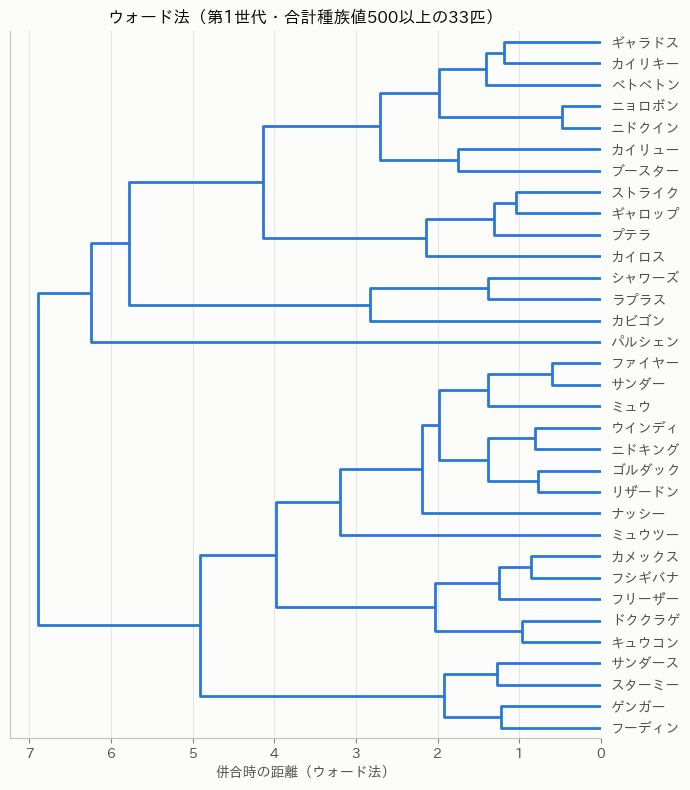

,HP,攻撃,防御,特攻,特防,素早,名前の例
クラスター,,,,,,,
1,81.0,85.0,80.0,107.0,92.0,98.0,"フシギバナ, リザードン, カメックス, ニドキング, キュウコン"
2,140.0,87.0,68.0,87.0,100.0,52.0,"ラプラス, シャワーズ, カビゴン"
3,82.0,114.0,81.0,71.0,89.0,82.0,"ニドクイン, ニョロボン, カイリキー, ギャロップ, ベトベトン"
4,50.0,95.0,180.0,85.0,45.0,70.0,パルシェン


In [171]:
# ウォード法のデンドログラム（名前つき）: 第1世代で合計種族値500以上の33匹
g1s = g1[g1["合計種族値"] >= 500].reset_index(drop=True)
Z_g1s = ((g1s[STATS] - g1[STATS].mean()) / g1[STATS].std(ddof=1)).to_numpy()   # 151匹の平均・SDで標準化
lk_s = linkage(Z_g1s, method="ward")
cut_s = fcluster(lk_s, t=4, criterion="maxclust")
fig, ax = plt.subplots(figsize=(7, 8))
dendrogram(lk_s, labels=g1s["名前"].tolist(), orientation="left", ax=ax,
           color_threshold=0, above_threshold_color=PALETTE[0], leaf_font_size=10)
ax.set(title="ウォード法（第1世代・合計種族値500以上の33匹）", xlabel="併合時の距離（ウォード法）")
ax.grid(False, axis="y")
fig.tight_layout()
plt.show()
prof_s = g1s.assign(クラスター=cut_s).groupby("クラスター")[STATS].mean().round(0)
prof_s["名前の例"] = [", ".join(g1s["名前"][cut_s == k].head(5)) for k in prof_s.index]
prof_s

**結果の読み方**
- 下半分の大きなまとまりは特攻・素早の高い「特殊・速攻型」（リザードン・フーディン・ゲンガー・サンダー・ミュウツーなど）、上半分は攻撃の高い「物理型」（カイリキー・ギャラドス・カイリュー・ストライクなど）と、HP の高い「耐久型」（カビゴン・ラプラス・シャワーズ）に分かれる。
- パルシェン（防御180）は最後近くまで単独で残り、1匹だけのクラスターになる。
- ただし同じ「特殊型」の中にフシギバナ・カメックスとフリーザーが入るなど、細かい枝の並びは切り方しだいで変わる。

### 24.3 K-means 法とクラスター数の選び方

**問い**：全920匹を K-means 法で分けるとき、クラスター数 $k$ はいくつがよいか。

**手法の要点**
- クラスター内平方和 $W=\sum_{c=1}^k\sum_{i\in C_c}\|\boldsymbol z_i-\bar{\boldsymbol z}_c\|^2$ を小さくするよう、次をくり返す：
  1. $k$ 個の中心を初期値として決める
  2. 各個体を最も近い中心のクラスターに割り当てる
  3. 各クラスターの重心を新しい中心にする
  4. 割り当てが変わらなくなったら終了
- 各ステップで $W$ は増えないので収束するが、得られるのは局所最適解である。
- エルボー法：$W$ を $k$ に対して描き、減り方が急に緩やかになる「肘」の $k$ を選ぶ。
- シルエット係数：個体 $i$ について、同じクラスター内の平均距離 $a_i$ と最も近い他クラスターへの平均距離 $b_i$ から $s_i=(b_i-a_i)/\max(a_i,b_i)$。全体平均が大きい（1に近い）ほどよく分かれている。

（→ py 24-3：$k=2,\dots,10$ のクラスター内平方和と平均シルエット係数）

 k  クラスター内平方和  シルエット係数
 2   3786.152    0.284
 3   3284.761    0.253
 4   2939.155    0.229
 5   2671.816    0.228
 6   2490.841    0.230
 7   2323.332    0.230
 8   2212.433    0.174
 9   2099.761    0.160
10   2012.347    0.163


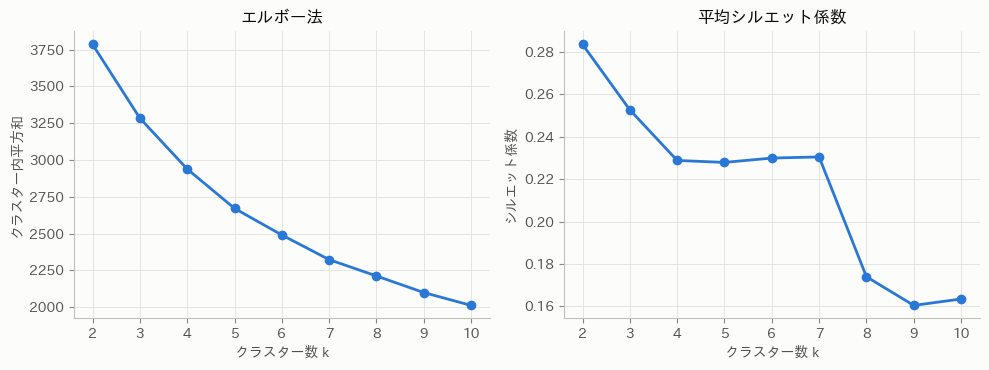

In [172]:
# K-means（全920行）: エルボー法とシルエット係数
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z_all)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z_all, km.labels_))
print(pd.DataFrame({"k": list(ks), "クラスター内平方和": inertias, "シルエット係数": sils}).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(list(ks), inertias, marker="o", color=PALETTE[0])
axes[0].set(title="エルボー法", xlabel="クラスター数 k", ylabel="クラスター内平方和")
axes[1].plot(list(ks), sils, marker="o", color=PALETTE[0])
axes[1].set(title="平均シルエット係数", xlabel="クラスター数 k", ylabel="シルエット係数")
fig.tight_layout()
plt.show()

**結果の読み方**
- クラスター内平方和は $k$ とともになめらかに減り、はっきりした肘はない（強いて言えば $k=2$〜4）。
- 平均シルエット係数は $k=2$ の 0.28 が最大で、$k=3$〜7 では 0.23〜0.25 とほぼ横ばい、$k\ge8$ で下がる。いずれも 0.3 未満で、はっきりしたクラスター構造はない。
- 種族値は連続的に広がっているので、どの $k$ でも「連続体を区切った」ものになる。ここでは解釈のしやすさから $k=4$ を使う。

### 24.4 K-means 法の初期値依存性

**問い**：初期値を変えると、K-means 法の結果はどれくらい変わるか。

**手法の要点**
- ランダムな初期値から1回だけ実行する（`n_init=1`, `init="random"`）ことを20回くり返し、クラスター内平方和と、最良解との調整ランド指数（ARI: 2つの分け方の一致度。完全一致で1、偶然程度の一致で0付近）を比べる。
- 実用上は、初期値を工夫する（k-means++）・何回か実行して $W$ が最小の解を採る（`n_init`）ことで対処する。

（→ py 24-4：初期値を変えた20回の結果）

In [173]:
# 初期値依存性: n_init=1 で初期値だけを変えて20回
k_fix = 4
runs = [KMeans(n_clusters=k_fix, n_init=1, init="random", random_state=s).fit(Z_all) for s in range(20)]
inert = np.array([r.inertia_ for r in runs])
best = runs[int(inert.argmin())]
ari = np.array([adjusted_rand_score(best.labels_, r.labels_) for r in runs])
print(f"k={k_fix}, n_init=1（ランダム初期値）20回")
print("  クラスター内平方和: 最小 {:.1f} / 最大 {:.1f} / 最小値から1%以内の回数 {}/20".format(
    inert.min(), inert.max(), int((inert <= inert.min() * 1.01).sum())))
print("  最良解との調整ランド指数: 最小 {:.3f} / 中央値 {:.3f}".format(ari.min(), np.median(ari)))
km_best = KMeans(n_clusters=k_fix, n_init=20, random_state=SEED).fit(Z_all)
print(f"n_init=20（k-means++）の平方和: {km_best.inertia_:.1f}")

k=4, n_init=1（ランダム初期値）20回
  クラスター内平方和: 最小 2940.0 / 最大 3049.0 / 最小値から1%以内の回数 16/20
  最良解との調整ランド指数: 最小 0.536 / 中央値 0.794


n_init=20（k-means++）の平方和: 2939.1


**結果の読み方**
- 20回のクラスター内平方和は 2940〜3049 とばらつき、最小値から1%以内に入ったのは16回だった。
- 最良解との ARI は中央値 0.79、最小 0.54 で、平方和がほぼ同じ解どうしでも割り当てはかなり違う。クラスター構造がはっきりしないデータほど、局所解が多く結果が不安定になる。
- `n_init=20`（k-means++）では最小値とほぼ同じ 2939 の解が得られた。

### 24.5 クラスターの解釈

**問い**：K-means 法（$k=4$）の各クラスターは、どんな種族値の配分をもつか。

**手法の要点**
- クラスターごとに元の単位の平均種族値（プロファイル）を求め、全体平均と比べる。
- クラスター番号には意味がないので、合計種族値の平均が小さい順に番号を付け直す。重心に近い個体を「代表例」として挙げる。

（→ py 24-5：各クラスターの平均種族値の棒グラフと表）

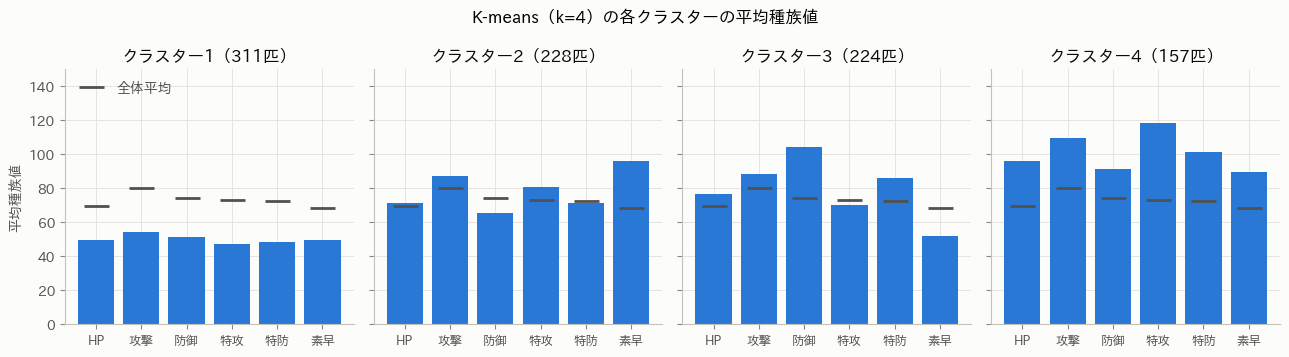

,匹数,HP,攻撃,防御,特攻,特防,素早,合計種族値,中心に近い例
1,311,50.0,54.0,51.0,47.0,48.0,50.0,301.0,"ユキワラシ, メタモン, マーイーカ, ヒドイデ"
2,228,71.0,87.0,66.0,81.0,72.0,96.0,472.0,"スワンナ, オドシシ, ユキメノコ, キリンリキ"
3,224,77.0,88.0,104.0,70.0,86.0,52.0,477.0,"ギギアル, ラランテス, ビークイン, キレイハナ"
4,157,96.0,109.0,91.0,118.0,102.0,90.0,607.0,"サザンドラ, ネクロズマ, ファイヤー, ジラーチ"


In [174]:
# クラスターの解釈: k=4 の各クラスターの平均種族値プロファイル（元の単位）
lab4 = km_best.labels_
# 合計種族値の平均が小さい順にクラスター番号を付け直す
order4 = df.groupby(lab4)["合計種族値"].mean().sort_values().index
relabel = {old: new for new, old in enumerate(order4, start=1)}
cl4 = pd.Series(lab4, index=df.index).map(relabel)
prof4 = df.groupby(cl4)[STATS + ["合計種族値"]].mean().round(0)
prof4.insert(0, "匹数", cl4.value_counts().sort_index())
centers = df.groupby(cl4)[STATS].mean()
dist_c = {k: ((Z_all[cl4 == k] - Z_all[cl4 == k].mean(0)) ** 2).sum(1) for k in prof4.index}
prof4["中心に近い例"] = [", ".join(df.loc[cl4 == k, "名前"].iloc[np.argsort(dist_c[k])[:4]]) for k in prof4.index]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
overall = df[STATS].mean()
for ax, k in zip(axes, prof4.index):
    ax.bar(STATS, centers.loc[k], color=PALETTE[0])
    ax.plot(STATS, overall, color=INK["secondary"], marker="_", ls="none", markersize=18, mew=2, label="全体平均")
    ax.set(title=f"クラスター{k}（{prof4.loc[k, '匹数']}匹）", ylim=(0, 150))
    ax.tick_params(axis="x", labelsize=9)
axes[0].set_ylabel("平均種族値")
axes[0].legend(loc="upper left")
fig.suptitle("K-means（k=4）の各クラスターの平均種族値", fontsize=12)
fig.tight_layout()
plt.show()
prof4

**結果の読み方**
- クラスター1（311匹）：全項目が50前後（合計 約300）の「弱い」群。進化前のポケモンが多い。
- クラスター2（228匹）：合計 約470で、素早（約96）と攻撃・特攻が高く、防御が低い「速攻型」。
- クラスター3（224匹）：合計 約480で、防御（約104）・特防が高く素早（約52）が低い「耐久型」。
- クラスター4（157匹）：合計 約610で全項目が高い「強い」群（伝説・メガシンカなど）。
- クラスター2と3は合計種族値がほぼ同じで、配分の違い（速さか硬さか）で分かれている。これは第22章の第1主成分（全体の強さ）と第2主成分（素早 対 防御）の構造と対応している。

### まとめ

- 種族値で分けると、ポケモンは「全体の強さ」と「速攻型か耐久型か」で分かれる。K-means 法（$k=4$）では、弱い群・速攻型・耐久型・強い群の4つになった。
- 最短距離法・重心法・群平均法は外れ値を切り離すだけになりやすく、解釈できるまとまりを得るにはウォード法や最長距離法が向いていた。どの連結法を使うかで結果が大きく変わる。
- シルエット係数は0.3未満で、はっきりしたクラスター構造はない。クラスター数・初期値によって結果が変わるので、結果は「連続的な分布の便宜的な区切り」として解釈する。

## 第25章 因子分析・グラフィカルモデル

### 章の概要

因子分析は、多数の観測変数の相関を「少数の観測できない共通因子」と「変数ごとの独自因子」で説明するモデルである。
主成分分析（第22章）が観測変数の合成（次元削減）であるのに対し、因子分析は観測変数が因子から生成されるという統計モデルで、最尤法による推定・適合度の検定ができる。
因子負荷量は回転しても同じ相関行列を再現するので、解釈しやすい向き（バリマックス回転・プロマックス回転）を選ぶ。
後半のグラフィカルモデルでは、相関行列の逆行列（精度行列）から偏相関を求め、「他の変数を固定したときの直接の関係」を無向グラフで表す。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 25.1 | 因子分析モデルと最尤推定 | 種族値6項目は何個の共通因子で説明できるか |
| 25.2 | バリマックス回転 | 因子はどんな能力として解釈できるか |
| 25.3 | プロマックス回転（斜交回転） | 因子どうしの相関を許すと解釈はどう変わるか |
| 25.4 | 因子得点 | 各ポケモンの因子の値はどうなるか |
| 25.5 | 主成分分析との違い | 因子分析と PCA は相関行列をどう再現するか |
| 25.6 | グラフィカルモデル（偏相関） | 種族値どうしの「直接の」関係はどこにあるか |
| 25.7 | 操作変数法・パス解析（概念） | 相関から因果の効果を分解するには何が必要か |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`, `攻撃`, `防御`, `特攻`, `特防`, `素早` | 量的 | 因子分析・グラフィカルモデルの対象とする6変数 |
| `名前` | — | 因子得点の図の注記 |

- **対象の行**：全920行。
- **加工**：各変数を平均0・分散1に標準化する（ここでは $n$ で割る標準偏差を使い、標本共分散行列がちょうど標本相関行列 $R$ になるようにする）。
- **データの性質と注意点**：6項目はすべて正の相関（防御と素早だけほぼ0）。最尤法と検定は多変量正規分布を仮定するが、HP・防御は右に裾が長く、この仮定は近似的にしか成り立たない。また $n=920$ は大きいので、検定は小さなずれにも敏感になる。

（→ py 25-0：相関行列とその固有値）

In [175]:
import warnings

from sklearn.decomposition import FactorAnalysis
from sklearn.exceptions import ConvergenceWarning

# sklearn の FactorAnalysis はこのデータでは収束しきらない（25-1 参照）ので警告を抑える
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 種族値6項目（全920行）を平均0・分散1（n で割る）に標準化: 標本共分散行列 = 標本相関行列 R
X_fa = df[STATS].to_numpy(float)
Z_fa = (X_fa - X_fa.mean(0)) / X_fa.std(0)
n_fa, p_fa = Z_fa.shape
R_fa = np.corrcoef(Z_fa.T)
print(f"n = {n_fa}, p = {p_fa}")
print("相関行列の固有値:", np.linalg.eigvalsh(R_fa)[::-1].round(3))
pd.DataFrame(R_fa, index=STATS, columns=STATS).round(2)

n = 920, p = 6
相関行列の固有値: [2.686 1.131 0.786 0.715 0.421 0.261]


,HP,攻撃,防御,特攻,特防,素早
HP,1.00,0.42,0.25,0.37,0.37,0.17
攻撃,0.42,1.00,0.44,0.39,0.26,0.37
防御,0.25,0.44,1.00,0.22,0.52,-0.01
特攻,0.37,0.39,0.22,1.00,0.50,0.46
特防,0.37,0.26,0.52,0.50,1.00,0.23
素早,0.17,0.37,-0.01,0.46,0.23,1.00


### 25.1 因子分析モデルと最尤推定

**問い**：種族値6項目の相関は、何個の共通因子で説明できるか。

**手法の要点**
- 標準化した観測変数 $\boldsymbol x=(x_1,\dots,x_p)^\top$ に対して、$m$ 因子モデルは
  $$\boldsymbol x=\Lambda\boldsymbol f+\boldsymbol\varepsilon$$
  $\Lambda$（$p\times m$）は因子負荷量、$\boldsymbol f$ は共通因子で $E[\boldsymbol f]=\boldsymbol 0$, $V[\boldsymbol f]=I_m$、$\boldsymbol\varepsilon$ は独自因子で $V[\boldsymbol\varepsilon]=\Psi=\operatorname{diag}(\psi_1,\dots,\psi_p)$、$\boldsymbol f$ と $\boldsymbol\varepsilon$ は無相関とする。
- すると $V[\boldsymbol x]=\Sigma=\Lambda\Lambda^\top+\Psi$。対角成分は $1=\sum_k\lambda_{jk}^2+\psi_j$ で、$h_j^2=\sum_k\lambda_{jk}^2$ を**共通性**（共通因子で説明される分散）、$\psi_j$ を**独自性**という。因子 $k$ の寄与は $\sum_j\lambda_{jk}^2$、寄与率はそれを $p$ で割ったもの。
- 最尤法は不一致度 $F=\log|\Sigma|+\operatorname{tr}(\Sigma^{-1}R)-\log|R|-p$ を最小にする。$\Psi$ を固定すると最適な $\Lambda$ は $\Psi^{-1/2}R\Psi^{-1/2}$ の固有値分解で決まるので、$\Psi$ だけを数値的に最適化すればよい。
- **因子数の選択**：
  - 尤度比検定：$H_0$「$m$ 因子モデルが正しい」のもとで $\left(n-1-\frac{2p+5}{6}-\frac{2m}{3}\right)F$ が近似的に自由度 $\frac{(p-m)^2-(p+m)}{2}$ のカイ2乗分布に従う（バートレットの補正）。
  - 自由度が正でないとモデルを検定できない（$p=6$ では $m\le3$ で、$m=3$ は自由度0）。
  - そのほか、相関行列の固有値が1を超える個数（カイザー基準）、AIC・BIC、解釈のしやすさ。
- 独自性の推定値が0（またはそれ以下）になることを**ヘイウッドケース**という。ここでは $\psi_j\ge0.005$ の制約をつけて推定する。

（→ py 25-1：$m=1,2,3$ の最尤推定と尤度比検定を自作し、2因子モデルの共通性・独自性を表示。sklearn（SVD に基づく反復法）の結果も参考に示す）

In [176]:
# 最尤法（自作）: Ψ を与えると Λ は Ψ^{-1/2} R Ψ^{-1/2} の固有値分解で決まるので、Ψ だけを数値最適化する
from scipy.optimize import minimize

def fa_loadings(psi, m, R):
    """Ψ を固定したときの最尤の Λ."""
    s = np.sqrt(psi)
    th, U = np.linalg.eigh(R / np.outer(s, s))
    th, U = th[::-1][:m], U[:, ::-1][:, :m]
    return s[:, None] * U * np.sqrt(np.maximum(th - 1, 0))

def fa_discrepancy(psi, m, R):
    """最尤法の不一致度 F = log|Σ| + tr(Σ^{-1}R) - log|R| - p."""
    L = fa_loadings(psi, m, R)
    Sig = L @ L.T + np.diag(psi)
    return np.linalg.slogdet(Sig)[1] + np.trace(np.linalg.solve(Sig, R)) - np.linalg.slogdet(R)[1] - len(R)

def fa_ml(R, m, lower=0.005):
    """独自性を [lower, 1] に制約した最尤推定（R の factanal と同じ考え方）."""
    res = minimize(fa_discrepancy, np.full(len(R), 0.5), args=(m, R), method="L-BFGS-B",
                   bounds=[(lower, 1.0)] * len(R))
    return fa_loadings(res.x, m, R), res.x, res.fun

rows = []
fa_fit = {}
for m in [1, 2, 3]:
    L, psi, F = fa_ml(R_fa, m)
    fa_fit[m] = (L, psi)
    chi2 = (n_fa - 1 - (2 * p_fa + 5) / 6 - 2 * m / 3) * F     # バートレットの補正
    dof = ((p_fa - m) ** 2 - (p_fa + m)) / 2
    k_par = p_fa * m + p_fa - m * (m - 1) / 2                   # 自由な母数の数
    rows.append({"因子数": m, "χ²": chi2, "自由度": dof,
                 "p値": stats.chi2.sf(chi2, dof) if dof > 0 else np.nan,
                 "AIC(=nF+2k の差だけ意味をもつ)": n_fa * F + 2 * k_par,
                 "独自性の最小値": psi.min(), "最小の変数": STATS[int(psi.argmin())]})
print(pd.DataFrame(rows).set_index("因子数").round(4).to_string())

# 2因子モデル（回転前）の負荷量・共通性・独自性
L2, psi2 = fa_fit[2]
L2 = L2 * np.sign(L2.sum(0))
comm = (L2 ** 2).sum(1)
fa_tab = pd.DataFrame(L2, index=STATS, columns=["因子1", "因子2"])
fa_tab["共通性"] = comm
fa_tab["独自性"] = psi2
fa_tab["共通性+独自性"] = comm + psi2
print("\n2因子モデル（回転前）")
print(fa_tab.round(3).to_string())
print("因子の寄与（負荷量の2乗和）:", (L2 ** 2).sum(0).round(3), " 寄与率:", ((L2 ** 2).sum(0) / p_fa).round(3))

# 参考: sklearn（SVD に基づく反復法, 独自性に実質的な下限なし）で同じモデル
fa_sk = FactorAnalysis(n_components=2, max_iter=1000, tol=1e-6, random_state=SEED).fit(Z_fa)
print("sklearn の独自性:", fa_sk.noise_variance_.round(4), "（防御の独自性が0に近づき続け、収束が遅い）")

           χ²  自由度   p値  AIC(=nF+2k の差だけ意味をもつ)  独自性の最小値 最小の変数
因子数                                                          
1    506.3309  9.0  0.0               532.8197   0.5197    特攻
2    202.0152  4.0  0.0               237.1561   0.0050    防御
3     25.9544  0.0  NaN                68.1201   0.0050    攻撃

2因子モデル（回転前）
      因子1    因子2    共通性    独自性  共通性+独自性
HP  0.251  0.428  0.247  0.753      1.0
攻撃  0.447  0.405  0.364  0.636      1.0
防御  0.997 -0.007  0.995  0.005      1.0
特攻  0.225  0.784  0.666  0.334      1.0
特防  0.527  0.438  0.470  0.530      1.0
素早 -0.010  0.598  0.358  0.642      1.0
因子の寄与（負荷量の2乗和）: [1.587 1.513]  寄与率: [0.264 0.252]


sklearn の独自性: [0.7534 0.636  0.009  0.3342 0.5294 0.6415] （防御の独自性が0に近づき続け、収束が遅い）


**結果の読み方**
- 尤度比検定は $m=1$ で $\chi^2\approx506$（自由度9）、$m=2$ で $\chi^2\approx202$（自由度4）で、どちらも $p$ 値はほぼ0。有意水準5%で「1因子で十分」「2因子で十分」の仮説はどちらも棄却される。$m=3$ は自由度0で検定できない。$n=920$ と大きく、正規性も近似にすぎないので、検定だけで因子数を決めるのは厳しすぎる。カイザー基準では2因子。
- 2因子モデルでは防御の独自性が下限0.005に張りつくヘイウッドケースになった（3因子では攻撃）。「防御そのもの」が1つの因子になってしまっており、因子分析のモデルがこのデータにうまく合っていないことを示す。sklearn（SVD に基づく反復法、実質的に下限なし）では防御の独自性が0へ近づき続け、反復が収束しない。
- 共通性は防御 約1.00、特攻 0.67、特防 0.47、攻撃 0.36、素早 0.36、HP 0.25。HP は分散の4分の3が独自性で、他の項目とあまり共通の要因をもたない。

### 25.2 バリマックス回転

**問い**：因子を解釈しやすい向きに回すと、2つの因子はどんな能力を表すか。

**手法の要点**
- 任意の直交行列 $T$ について $(\Lambda T)(\Lambda T)^\top=\Lambda\Lambda^\top$ なので、$\Lambda$ と $\Lambda T$ は同じ $\Sigma$ を与える（回転の不定性）。共通性も変わらない。
- 各変数がなるべく1つの因子だけに大きな負荷量をもつ（単純構造）よう $T$ を選ぶ。**バリマックス回転**は、各因子について負荷量の2乗 $\lambda_{jk}^2$ の分散を求め、その和
  $$V=\sum_{k=1}^m\left\{\frac1p\sum_{j=1}^p\lambda_{jk}^4-\left(\frac1p\sum_{j=1}^p\lambda_{jk}^2\right)^2\right\}$$
  を最大にする直交回転である（因子どうしは無相関のまま）。
- 共通性で各行を割ってから回転する「正規化バリマックス」もある（R の既定）。ここでは sklearn と同じく正規化しない。

（→ py 25-2：バリマックス回転を自作して sklearn の `rotation="varimax"` と照合し、25.1 の解を回転）

自作バリマックスと sklearn の負荷量の最大差: 6.715e-05
回転角（度）: -4.4
バリマックス基準: 回転前 0.1528 → 回転後 0.1554
共通性は回転で不変: True


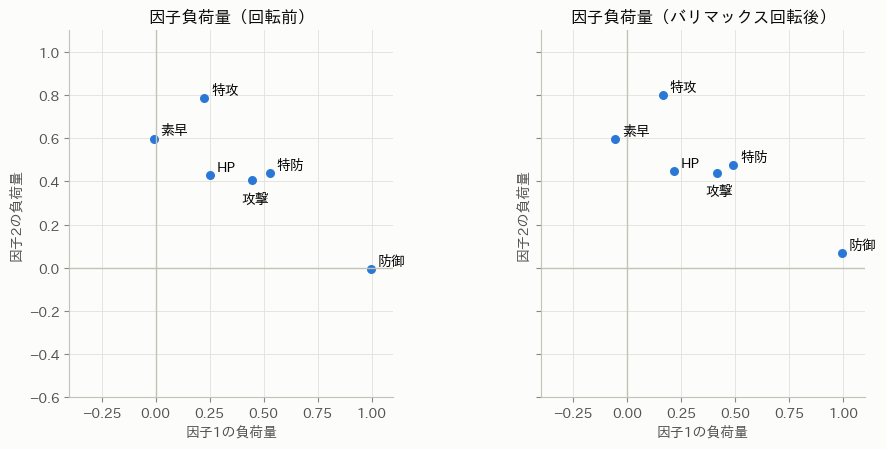

,因子1(回転後),因子2(回転後)
HP,0.218,0.446
攻撃,0.415,0.438
防御,0.995,0.069
特攻,0.164,0.799
特防,0.492,0.477
素早,-0.056,0.596


In [177]:
# バリマックス回転: 自作関数を sklearn（rotation="varimax"）と照合してから、25-1 の解を回転する
def varimax(L, tol=1e-10, max_iter=500):
    """バリマックス回転（正規化なし）。回転後の負荷量と回転行列を返す."""
    p, k = L.shape
    T = np.eye(k)
    crit = 0
    for _ in range(max_iter):
        A = L @ T
        u, s, vt = np.linalg.svd(L.T @ (A ** 3 - A @ np.diag((A ** 2).sum(0)) / p))
        T = u @ vt
        if s.sum() < crit * (1 + tol):
            break
        crit = s.sum()
    return L @ T, T

def varimax_crit(L):
    """各因子の負荷量の2乗の分散の和（大きいほど単純構造）."""
    return ((L ** 2).var(axis=0)).sum()

def align(A, B):
    """B の列の並びと符号を A に合わせる（2因子用）."""
    best = None
    for perm in [(0, 1), (1, 0)]:
        Bp = B[:, perm]
        Bp = Bp * np.sign((A * Bp).sum(0))
        err = np.abs(A - Bp).max()
        if best is None or err < best[0]:
            best = (err, Bp)
    return best[1]

# 照合: 同じ設定の sklearn（回転なし）の負荷量を自作関数で回転し、rotation="varimax" の結果と比べる
fa_sk_v = FactorAnalysis(n_components=2, rotation="varimax", max_iter=1000, tol=1e-6, random_state=SEED).fit(Z_fa)
L_sk_rot, _ = varimax(fa_sk.components_.T)
print("自作バリマックスと sklearn の負荷量の最大差:",
      np.abs(L_sk_rot - align(L_sk_rot, fa_sk_v.components_.T)).max().round(8))

L2v, T2v = varimax(L2)
L2v = L2v * np.sign(L2v.sum(0))                        # 負荷量の和が正になる向きにそろえる
print("回転角（度）:", np.degrees(np.arctan2(T2v[1, 0], T2v[0, 0])).round(1))
print(f"バリマックス基準: 回転前 {varimax_crit(L2):.4f} → 回転後 {varimax_crit(L2v):.4f}")
print("共通性は回転で不変:", np.allclose((L2 ** 2).sum(1), (L2v ** 2).sum(1)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, (L_, ttl) in zip(axes, [(L2, "回転前"), (L2v, "バリマックス回転後")]):
    ax.axhline(0, color=INK["axis"], lw=1)
    ax.axvline(0, color=INK["axis"], lw=1)
    ax.scatter(L_[:, 0], L_[:, 1], color=PALETTE[0], s=30)
    for j, s in enumerate(STATS):
        off_ = {"攻撃": (-8, -16)}.get(s, (5, 3))      # 近接する攻撃と特防のラベルをずらす
        ax.annotate(s, (L_[j, 0], L_[j, 1]), xytext=off_, textcoords="offset points", fontsize=10)
    ax.set(title=f"因子負荷量（{ttl}）", xlabel="因子1の負荷量", ylabel="因子2の負荷量",
           xlim=(-0.4, 1.1), ylim=(-0.6, 1.1), aspect="equal")
fig.tight_layout()
plt.show()
pd.DataFrame(L2v, index=STATS, columns=["因子1(回転後)", "因子2(回転後)"]).round(3)

**結果の読み方**
- 自作の回転は sklearn の結果と $10^{-4}$ 程度以内で一致した。
- 回転角は約 $-4^\circ$ と小さく、回転前からほぼ単純構造になっていた（防御が因子1にほぼ完全に乗っているため）。
- 回転後の因子1は防御（1.00）と特防・攻撃（0.4〜0.5）に負荷する「防御（物理的な硬さ）の因子」、因子2は特攻（0.80）・素早（0.60）に大きく負荷し、特防・HP・攻撃にも0.4台で負荷する「特殊攻撃・速さの因子」と読める。特防と攻撃は両方の因子に同程度に乗り、単純構造にはならない。

### 25.3 プロマックス回転（斜交回転）

**問い**：因子どうしの相関を許すと、解釈はどう変わるか。

**手法の要点**
- 斜交回転では因子間に相関 $\Phi=V[\boldsymbol f]$ を許す。このとき $\Sigma=\Lambda_P\Phi\Lambda_P^\top+\Psi$ で、$\Lambda_P$ を**パターン行列**（因子から変数への偏回帰係数）、$\Lambda_P\Phi$ を**構造行列**（変数と因子の相関）という。直交回転では両者は一致する。
- **プロマックス回転**の手順：
  1. バリマックス解 $\Lambda_V$ の各成分を符号を保って $k$ 乗（ここでは $k=4$）した目標行列 $P$ を作る（大きな負荷量を強調し、小さい負荷量を0に近づける）。
  2. $\Lambda_VU\approx P$ となる $U$ を最小2乗法で求め、因子の分散が1になるよう列を調整する。
  3. パターン行列 $\Lambda_P=\Lambda_VU$、因子間相関 $\Phi=U^{-1}(U^{-1})^\top$。
- 回転しても再現される $\Lambda_P\Phi\Lambda_P^\top=\Lambda_V\Lambda_V^\top$ は変わらない。

（→ py 25-3：プロマックス回転を自作し、パターン行列・構造行列・因子間相関を表示）

In [178]:
# プロマックス回転（斜交回転）: バリマックス解を累乗した目標行列に最小2乗で近づける
def promax(Lv, power=4):
    """パターン行列と因子間相関行列を返す（正規化なし）."""
    P = Lv * np.abs(Lv) ** (power - 1)                  # 目標行列: 大きい負荷量を強調
    U = np.linalg.lstsq(Lv, P, rcond=None)[0]
    U = U @ np.diag(np.sqrt(np.diag(np.linalg.inv(U.T @ U))))   # 因子の分散が1になるよう列を調整
    pattern = Lv @ U
    Uinv = np.linalg.inv(U)
    phi = Uinv @ Uinv.T                                 # 因子間相関行列
    return pattern, phi

pattern2, phi2 = promax(L2v)
structure2 = pattern2 @ phi2                            # 構造行列 = 変数と因子の相関
print("因子間相関 φ12 =", phi2[0, 1].round(3), " 対角:", np.diag(phi2).round(6))
print("再現される共通性が回転前と一致:", np.allclose(np.diag(pattern2 @ phi2 @ pattern2.T), (L2 ** 2).sum(1)))
pd.concat({"バリマックス": pd.DataFrame(L2v, index=STATS, columns=["因子1", "因子2"]),
           "プロマックス(パターン)": pd.DataFrame(pattern2, index=STATS, columns=["因子1", "因子2"]),
           "プロマックス(構造)": pd.DataFrame(structure2, index=STATS, columns=["因子1", "因子2"])},
          axis=1).round(3)

因子間相関 φ12 = 0.519  対角: [1. 1.]
再現される共通性が回転前と一致: True


バリマックス        プロマックス(パターン)        プロマックス(構造)       
      因子1    因子2          因子1    因子2        因子1    因子2
HP  0.218  0.446        0.075  0.454      0.310  0.492
攻撃  0.415  0.438        0.296  0.394      0.501  0.548
防御  0.995  0.069        1.077 -0.175      0.986  0.383
特攻  0.164  0.799       -0.116  0.870      0.335  0.810
特防  0.492  0.477        0.367  0.419      0.585  0.610
素早 -0.056  0.596       -0.284  0.694      0.076  0.547

**結果の読み方**
- 因子間相関は約0.52で、2つの因子は強く正に相関する（「強いポケモンはどちらも高い」ことの反映）。対角は1で、共通性が回転前と一致することも確認した。
- パターン行列では因子1に防御（1.08）、因子2に特攻（0.87）・素早（0.69）がより鮮明に乗り、素早は因子1に負（−0.28）となる。斜交回転ではパターン行列の値が1を超えることがあり、相関係数ではないことに注意する。
- 構造行列（相関）で見ると、全変数が両因子と正に相関する。解釈にはパターン行列を、変数と因子の単純な関係には構造行列を使う。

### 25.4 因子得点

**問い**：各ポケモンの2つの因子の値はどうなるか。

**手法の要点**
- 因子は観測できないので、観測値から推定する。回帰法（トムソン法）は、多変量正規性のもとでの条件付き期待値
  $$\hat{\boldsymbol f}=E[\boldsymbol f\mid\boldsymbol x]=(I_m+\Lambda^\top\Psi^{-1}\Lambda)^{-1}\Lambda^\top\Psi^{-1}\boldsymbol x$$
  を使う。これは縮小推定なので、因子得点の分散は1より小さくなる。
- 主成分得点と違い、因子得点は観測値から一意には決まらない推定値である。

（→ py 25-4：式から因子得点を計算し、sklearn の `transform` と照合して散布図を描く）

手計算と sklearn transform の最大差: 0.0
因子得点の分散（1より小さい）: [0.994 0.767]  相関: 0.02


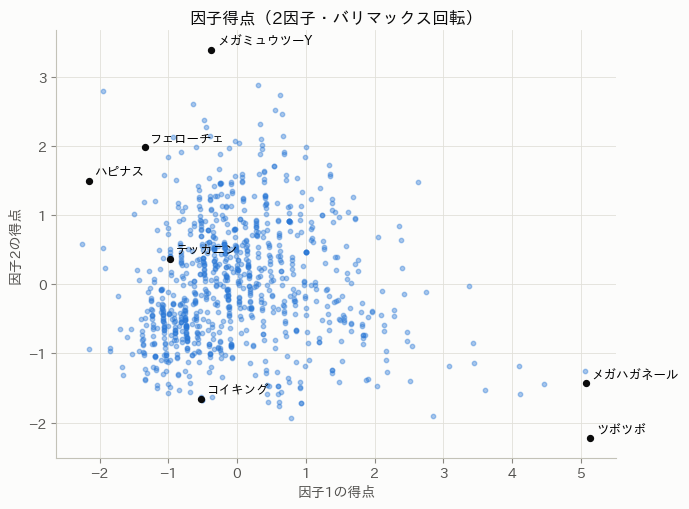

In [179]:
# 因子得点（回帰法 = 事後平均）: E[f|x] = (I + Λ'Ψ^{-1}Λ)^{-1} Λ'Ψ^{-1} x
def factor_scores(Z, L, psi):
    Pinv = np.diag(1 / psi)
    return (Z - Z.mean(0)) @ np.linalg.solve(np.eye(L.shape[1]) + L.T @ Pinv @ L, L.T @ Pinv).T

# 式の照合: sklearn の推定値を代入すると transform と一致する
print("手計算と sklearn transform の最大差:",
      np.abs(factor_scores(Z_fa, fa_sk_v.components_.T, fa_sk_v.noise_variance_) - fa_sk_v.transform(Z_fa)).max().round(10))
fscore = factor_scores(Z_fa, L2v, psi2)                # 25-2 のバリマックス解の因子得点
print("因子得点の分散（1より小さい）:", fscore.var(0).round(3), " 相関:", np.corrcoef(fscore.T)[0, 1].round(3))

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.scatter(fscore[:, 0], fscore[:, 1], s=10, alpha=0.4, color=PALETTE[0])
for nm in ["ツボツボ", "テッカニン", "ハピナス", "メガミュウツーY", "コイキング", "メガハガネール", "フェローチェ"]:
    i = df.index[df["名前"] == nm][0]
    ax.scatter(fscore[i, 0], fscore[i, 1], s=18, color=INK["primary"])
    ax.annotate(nm, (fscore[i, 0], fscore[i, 1]), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set(title="因子得点（2因子・バリマックス回転）", xlabel="因子1の得点", ylabel="因子2の得点")
fig.tight_layout()
plt.show()

**結果の読み方**
- 式による因子得点は sklearn の `transform` と一致した。因子得点の分散は因子1が約0.99（防御の独自性がほぼ0なので、防御からほぼ正確に決まる）、因子2が約0.77。
- 因子1（防御）ではツボツボ・メガハガネールが突出し（約5）、因子2（特殊攻撃・速さ）ではメガミュウツーY・フェローチェが高い。ハピナスは因子1が低く因子2が高い（特防と HP が因子2に負荷しているため）。

### 25.5 主成分分析との違い

**問い**：因子分析と主成分分析は、同じ2次元でも何が違うか。

**手法の要点**

| | 主成分分析 | 因子分析 |
|---|---|---|
| 目的 | 変数の分散をなるべく多く保つ合成変数を作る | 変数間の相関（共分散）を少数の因子で説明する |
| モデル | なし（$\boldsymbol y=W^\top\boldsymbol x$ という変換） | $\boldsymbol x=\Lambda\boldsymbol f+\boldsymbol\varepsilon$ という確率モデル |
| 独自の誤差 | 考えない（捨てた成分に含まれる） | 独自因子 $\Psi$ を明示する |
| 解の一意性 | 固有ベクトルとして一意（符号を除く） | 回転の不定性がある |
| 得点 | 観測値から一意に計算できる | 推定値（回帰法など） |

- PCA は対角成分（分散）も含めて $R$ を近似しようとするが、因子分析は対角を $\Psi$ で吸収し、非対角成分（相関）の再現に集中する。

（→ py 25-5：2成分の PCA 負荷量と2因子の負荷量、相関行列の非対角成分の再現誤差を比較）

In [180]:
# 主成分分析との比較: 2成分の PCA 負荷量と 2因子の負荷量、相関行列の再現誤差
ev, evec = np.linalg.eigh(R_fa)
ev, evec = ev[::-1][:2], evec[:, ::-1][:, :2]
L_pca = evec * np.sqrt(ev)
L_pca = L_pca * np.sign(L_pca.sum(0))
off = ~np.eye(p_fa, dtype=bool)
res_fa = R_fa - (L2 @ L2.T + np.diag(psi2))
res_pca = R_fa - L_pca @ L_pca.T
print("相関行列の非対角成分の再現誤差（RMS）  因子分析: {:.4f} / PCA: {:.4f}".format(
    np.sqrt((res_fa[off] ** 2).mean()), np.sqrt((res_pca[off] ** 2).mean())))
print("対角成分（分散）の再現  因子分析: 共通性+独自性=1 / PCA: 負荷量の2乗和 =", (L_pca ** 2).sum(1).round(3))
pd.DataFrame(np.c_[L_pca, (L_pca ** 2).sum(1), L2, comm], index=STATS,
             columns=["PC1", "PC2", "PCA 説明率", "因子1", "因子2", "共通性"]).round(3)

相関行列の非対角成分の再現誤差（RMS）  因子分析: 0.0701 / PCA: 0.1251
対角成分（分散）の再現  因子分析: 共通性+独自性=1 / PCA: 負荷量の2乗和 = [0.425 0.521 0.795 0.666 0.612 0.797]


,PC1,PC2,PCA 説明率,因子1,因子2,共通性
HP,0.648,-0.068,0.425,0.251,0.428,0.247
攻撃,0.722,0.025,0.521,0.447,0.405,0.364
防御,0.606,-0.654,0.795,0.997,-0.007,0.995
特攻,0.751,0.320,0.666,0.225,0.784,0.666
特防,0.736,-0.267,0.612,0.527,0.438,0.470
素早,0.522,0.724,0.797,-0.010,0.598,0.358


**結果の読み方**
- 相関行列の非対角成分の再現誤差（RMS）は因子分析 0.070、PCA 0.125 で、相関の説明は因子分析のほうが良い。
- PCA の第1主成分は6項目すべてに0.5〜0.75の負荷量をもつ「全体の強さ」だが、因子分析（回転前）の因子1は防御に集中している。同じ2次元でも、分散を最大にする軸と相関を説明する軸は違う。

### 25.6 グラフィカルモデル（偏相関と無向独立グラフ）

**問い**：種族値どうしの「他の4項目を固定したときの直接の関係」はどこにあるか。

**手法の要点**
- $\boldsymbol x\sim N_p(\boldsymbol\mu,\Sigma)$ で、精度行列 $\Omega=\Sigma^{-1}=(\omega_{ij})$ とすると、他の変数すべてを与えたときの $x_i$ と $x_j$ の偏相関係数は
  $$\rho_{ij\cdot\text{rest}}=-\frac{\omega_{ij}}{\sqrt{\omega_{ii}\omega_{jj}}}$$
  で、$\omega_{ij}=0\iff x_i$ と $x_j$ は他の変数を与えたもとで条件付き独立（正規分布の場合）。
- 変数を頂点とし、条件付き独立でないペアだけを辺で結んだ無向グラフを**無向独立グラフ**という。相関はあっても他の変数を通じた間接的な関係なら辺は引かれない。
- 辺の選び方：
  - 検定：$H_0:\rho_{ij\cdot\text{rest}}=0$ のもとで $t=r\sqrt{(n-p)/(1-r^2)}$ が自由度 $n-p$ の $t$ 分布に従う（$r$ は標本偏相関、条件づける変数は $p-2$ 個）。15ペアを同時に調べるのでボンフェローニ補正（各 $0.05/15$）を使う。
  - 閾値：$|r|$ がある値（ここでは0.2）以上の辺だけを残す。$n$ が大きいと検定ではほとんどの辺が有意になるため、大きさでも判断する。
  - 共分散選択やグラフィカル・ラッソ（$\Omega$ に $L_1$ 罰則）で疎な $\Omega$ を推定する方法もある。
- 偏相関は「他の変数に回帰した残差どうしの相関」とも一致する。

（→ py 25-6：精度行列から偏相関行列を計算し、残差の相関と照合。検定と閾値で辺を選んでグラフを描く）

偏相関(HP, 攻撃): 精度行列から 0.3258 / 残差の相関 0.3258
自由度 n-p = 914, 有意水準 5%（ボンフェローニ補正で各 0.0033）
辺の数: 13 / 15
辺の数（|偏相関| ≥ 0.2 の閾値）: 9 / 15


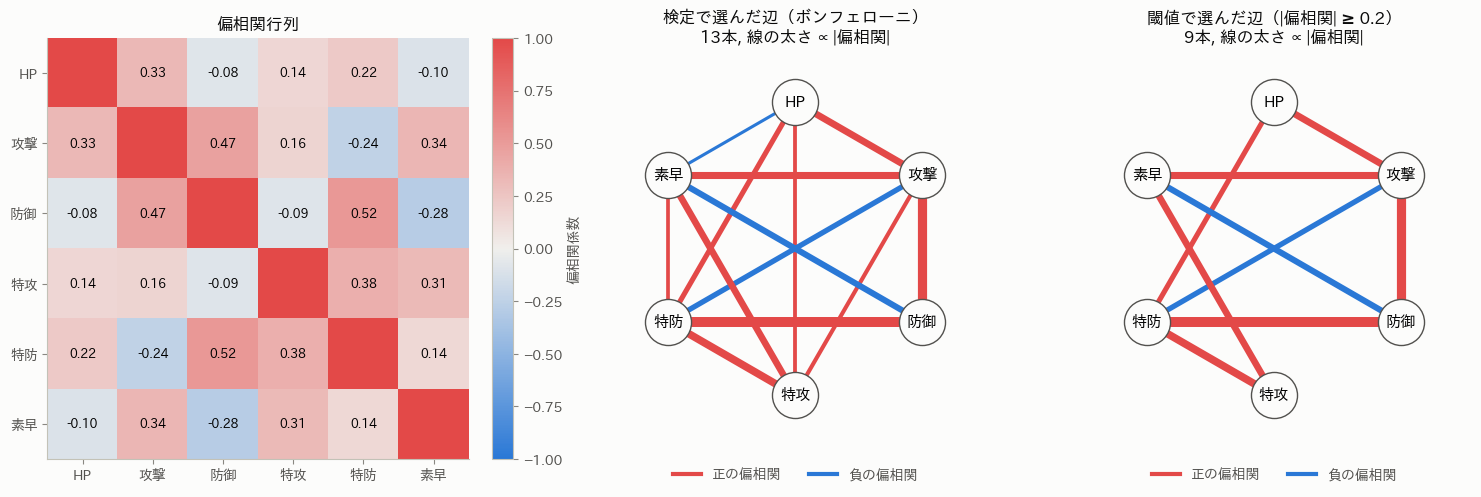

,変数1,変数2,相関,偏相関,t,p値,辺(p<0.05/15),辺(|偏相関|≥0.2)
0,HP,攻撃,0.4226,0.3258,10.4170,0.0000,True,True
1,HP,防御,0.2468,-0.0817,-2.4790,0.0134,False,False
2,HP,特攻,0.3714,0.1448,4.4252,0.0000,True,False
3,HP,特防,0.3699,0.2242,6.9553,0.0000,True,True
4,HP,素早,0.1682,-0.1023,-3.1080,0.0019,True,False
5,攻撃,防御,0.4438,0.4674,15.9851,0.0000,True,True
6,攻撃,特攻,0.3884,0.1624,4.9757,0.0000,True,False
7,攻撃,特防,0.2579,-0.2364,-7.3562,0.0000,True,True
8,攻撃,素早,0.3685,0.3410,10.9668,0.0000,True,True
9,防御,特攻,0.2186,-0.0869,-2.6381,0.0085,False,False


In [181]:
# グラフィカルモデル: 精度行列 Ω = R^{-1} から偏相関、t 検定で辺を選ぶ
Omega = np.linalg.inv(R_fa)
pcor = -Omega / np.sqrt(np.outer(np.diag(Omega), np.diag(Omega)))
np.fill_diagonal(pcor, 1)
# 照合: HP と攻撃の偏相関 = 他の4変数に回帰した残差どうしの相関
others = [2, 3, 4, 5]
A_ = np.c_[np.ones(n_fa), Z_fa[:, others]]
res0 = Z_fa[:, 0] - A_ @ np.linalg.lstsq(A_, Z_fa[:, 0], rcond=None)[0]
res1 = Z_fa[:, 1] - A_ @ np.linalg.lstsq(A_, Z_fa[:, 1], rcond=None)[0]
print("偏相関(HP, 攻撃): 精度行列から {:.4f} / 残差の相関 {:.4f}".format(pcor[0, 1], np.corrcoef(res0, res1)[0, 1]))

# H0: 偏相関 = 0。t = r √{(n-p)/(1-r²)} ~ t(n-p)（多変量正規を仮定）。15ペアでボンフェローニ補正
edges = []
for i in range(p_fa):
    for j in range(i + 1, p_fa):
        r = pcor[i, j]
        t = r * np.sqrt((n_fa - p_fa) / (1 - r ** 2))
        pv = 2 * stats.t.sf(abs(t), n_fa - p_fa)
        edges.append({"変数1": STATS[i], "変数2": STATS[j], "相関": R_fa[i, j], "偏相関": r,
                      "t": t, "p値": pv, "辺(p<0.05/15)": pv < 0.05 / 15})
edge_df = pd.DataFrame(edges)
print(f"自由度 n-p = {n_fa - p_fa}, 有意水準 5%（ボンフェローニ補正で各 {0.05 / 15:.4f}）")
print("辺の数:", int(edge_df["辺(p<0.05/15)"].sum()), "/ 15")

edge_df["辺(|偏相関|≥0.2)"] = edge_df["偏相関"].abs() >= 0.2
print("辺の数（|偏相関| ≥ 0.2 の閾値）:", int(edge_df["辺(|偏相関|≥0.2)"].sum()), "/ 15")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.2, 1, 1]})
im = axes[0].imshow(pcor, cmap=DIV_CMAP, vmin=-1, vmax=1)
for (i, j), v in np.ndenumerate(pcor):
    if i != j:
        axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9)
axes[0].set(xticks=range(p_fa), xticklabels=STATS, yticks=range(p_fa), yticklabels=STATS, title="偏相関行列")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], fraction=0.046, label="偏相関係数")
ang = np.pi / 2 - 2 * np.pi * np.arange(p_fa) / p_fa
pos = np.c_[np.cos(ang), np.sin(ang)]
for ax, col, ttl in [(axes[1], "辺(p<0.05/15)", "検定で選んだ辺（ボンフェローニ）"),
                     (axes[2], "辺(|偏相関|≥0.2)", "閾値で選んだ辺（|偏相関| ≥ 0.2）")]:
    for _, e in edge_df[edge_df[col]].iterrows():
        i, j = STATS.index(e["変数1"]), STATS.index(e["変数2"])
        ax.plot(*pos[[i, j]].T, color=PALETTE[0] if e["偏相関"] < 0 else PALETTE[7],
                lw=1 + 12 * abs(e["偏相関"]), solid_capstyle="round", zorder=1)
    ax.scatter(*pos.T, s=1100, color=INK["surface"], edgecolor=INK["secondary"], zorder=2)
    for k, s_ in enumerate(STATS):
        ax.text(*pos[k], s_, ha="center", va="center", fontsize=11, zorder=4)
    ax.plot([], [], color=PALETTE[7], lw=3, label="正の偏相関")
    ax.plot([], [], color=PALETTE[0], lw=3, label="負の偏相関")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2)
    ax.set(xlim=(-1.35, 1.35), ylim=(-1.35, 1.35), aspect="equal", title=f"{ttl}\n{int(edge_df[col].sum())}本, 線の太さ ∝ |偏相関|")
    ax.axis("off")
fig.tight_layout()
plt.show()
edge_df.round(4)

**結果の読み方**
- HP と攻撃の偏相関は、精度行列からも残差の相関からも0.326で一致した。
- 検定（自由度914、ボンフェローニ補正で各0.0033）では15ペア中13本の辺が残り、条件付き独立とみなせたのは「HP–防御」「防御–特攻」だけだった。$n$ が大きいため小さな偏相関（|0.10| 程度）でも有意になる。
- 閾値0.2では9本が残る。強い正の辺は 防御–特防（0.52）、攻撃–防御（0.47）、特攻–特防（0.38）、攻撃–素早（0.34）、HP–攻撃（0.33）。
- 注目すべきは負の辺で、防御–素早（相関 −0.01 → 偏相関 −0.28）、攻撃–特防（相関 0.26 → 偏相関 −0.24）は、相関では見えない「他の能力が同じなら、硬いポケモンほど遅い」「攻撃に振るほど特防が低い」というトレードオフを表す。種族値の配分が合計の制約のもとで決まっていることと整合する（ただし、これは観察データの記述で因果ではない）。

### 25.7 操作変数法とパス解析（概念）

**問い**：相関係数から、ある変数から別の変数への「効果」を取り出すには何が必要か。

**手法の要点**
- パス図の矢印を線形の構造方程式で表す。たとえば標準化した変数 $X,Y,Z$ について
  $$Y=cX+v,\qquad Z=aX+bY+u$$
  （$v$ は $X$ と、$u$ は $X,Y$ と無相関）とする。$a,b,c$ をパス係数という。
- 式に変数をかけて期待値をとると、パス係数を相関係数で表せる。$E[XY]=cE[X^2]+E[Xv]$ より $c=r_{XY}$。同様に $E[XZ]$ から $r_{XZ}=a+bc$ で、$a$ が $X\to Z$ の直接効果、$bc$ が $Y$ を介した間接効果、その和が総合効果である。
- 説明変数 $Y$ と誤差 $u$ に相関がある（交絡・同時性・測定誤差がある）と、最小2乗推定は偏る。このとき、$Y$ とは相関するが $X$ とも $u$ とも無相関で、$Z$ には $Y$ を通じてしか影響しない変数 $W$（**操作変数**）があれば、$E[WZ]=aE[WX]+bE[WY]+E[Wu]=bE[WY]$ から $b=\operatorname{Cov}(W,Z)/\operatorname{Cov}(W,Y)$ として一致推定できる（操作変数法）。
- ポケモンのデータは同時に決められた設定値の集まりで、「$u$ と無相関」を正当化できる変数が見当たらないため、ここでは概念の説明にとどめる。構造方程式は矢印の向きをデータの外から仮定して初めて意味をもつ。

### まとめ

- 種族値6項目の因子分析では、「防御（物理的な硬さ）」と「特殊攻撃・速さ」の2因子が得られた（プロマックス回転で因子間相関 約0.52）。ただし尤度比検定では2因子モデルも棄却され、防御の独自性が0になるヘイウッドケースも起きており、少数の因子でうまく説明できるデータではない。
- 因子分析は相関の再現に集中するため、同じ2次元の PCA より相関行列をよく再現した。一方、回転の不定性があり、解釈は回転の方法に依存する。
- 偏相関のグラフでは、「防御–素早」「攻撃–特防」の負の偏相関が現れ、相関行列では見えない種族値の配分のトレードオフがわかった。$n$ が大きいとほとんどの辺が有意になるので、辺は偏相関の大きさでも判断する。

## 第26章 その他の多変量解析手法

### 章の概要

この章では、多変量データを低次元に表す3つの手法を扱う。
多次元尺度構成法（MDS）は「個体間の距離」だけから座標を復元する。正準相関分析は「2組の変数群」の間の相関を最大にする合成変数を求める。数量化法は質的変数を数値化して回帰・判別・主成分分析の枠組みに乗せる手法で、とくに数量化III類（対応分析）はクロス表の行と列を同じ平面に布置する。
いずれも固有値分解（特異値分解）に帰着し、第22章の主成分分析、第23章の判別分析、第16章の重回帰分析と数学的に深くつながっている。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 26.1 | 古典的多次元尺度構成法 | 種族値のユークリッド距離から作る布置は、主成分分析と同じか |
| 26.2 | ユークリッドでない距離と非計量 MDS | マンハッタン距離の関係を2次元にどこまで保てるか |
| 26.3 | 正準相関分析 | 体格（高さ・重さ）と種族値の関係を、少数の合成変数で表すと |
| 26.4 | 数量化III類（対応分析） | タイプとタマゴグループの対応関係を地図にすると |
| 26.5 | 数量化I類・II類 | タイプと成長の速さで、合計種族値をどれだけ説明・判別できるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `HP`〜`素早`（6項目） | 量的 | MDS の距離、正準相関分析の変数群 $\boldsymbol y$ |
| `log高さ`, `log重さ` | 量的 | 正準相関分析の変数群 $\boldsymbol x$（体格） |
| `タイプ1`, `タマゴ1` | 質的（17・14水準） | 数量化III類のクロス表 |
| `タイプ1`, `成長` | 質的 | 数量化I類・II類の説明変数（アイテム） |
| `合計種族値` | 量的 | 数量化I類・II類の外的基準 |

- **対象の行**：
  - 26.1, 26.3：全920行。
  - 26.2：第1世代・姿違いを除く・合計種族値500以上の33匹（第24章と同じ。名前を並べて読める数）。
  - 26.4：`タイプ1` が「ひこう」（4匹）と `タマゴ1` が「メタモン」（1匹）の行を除いた915行（度数が極端に小さい行・列は布置を不安定にするため）。
  - 26.5：`成長` が「105万」（2匹）の行を除いた918行。
- **加工**：種族値は平均0・不偏分散1に標準化。高さ・重さは右に大きく歪むので対数をとる。
- **データの性質と注意点**：タマゴグループは「タマゴ未発見」（伝説など）や「虫」「水中1〜3」のようにタイプと強く対応するグループを含む。同じ進化系統の行は独立でないので、正準相関の検定の $p$ 値は目安にとどめる。

（→ py 26-0：対象の行数と要約統計）

In [182]:
from scipy.spatial.distance import pdist, squareform
from sklearn.cross_decomposition import CCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from matplotlib.transforms import Bbox
from sklearn.manifold import MDS


def place_labels(ax, xy, names, fontsize=9):
    """点の名前を、既に置いたラベルや他の点と重ならない位置（8方向×3距離の候補）を選んで置く（簡易版）.
    軸の範囲と tight_layout を確定させてから呼ぶ。"""
    fig = ax.figure
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    cands = [(dx * r, dy * r, ha, va) for r in (1, 3, 5)
             for dx, dy, ha, va in [(3, 3, "left", "bottom"), (3, -3, "left", "top"), (-3, 3, "right", "bottom"),
                                    (-3, -3, "right", "top"), (0, 5, "center", "bottom"),
                                    (0, -5, "center", "top"), (6, 0, "left", "center"), (-6, 0, "right", "center")]]
    # 点（マーカー）も障害物として扱う
    pix = ax.transData.transform(np.asarray(xy, float))
    dots = [Bbox.from_extents(px - 4, py - 4, px + 4, py + 4) for px, py in pix]
    placed = []
    for i_, ((x_, y_), nm) in enumerate(zip(xy, names)):
        best = None
        for dx, dy, ha, va in cands:
            t = ax.annotate(nm, (x_, y_), xytext=(dx, dy), textcoords="offset points",
                            ha=ha, va=va, fontsize=fontsize)
            bb = t.get_window_extent(rend)
            n_ov = sum(bb.overlaps(q) for q in placed) + sum(bb.overlaps(q) for k_, q in enumerate(dots) if k_ != i_)
            if best is None or n_ov < best[0]:
                if best is not None:
                    best[1].remove()
                best = (n_ov, t, bb)
            else:
                t.remove()
            if n_ov == 0:
                break
        placed.append(best[2])

# 標準化した種族値（不偏分散で標準化）
Z_mds = ((df[STATS] - df[STATS].mean()) / df[STATS].std(ddof=1)).to_numpy()
# MDS の小さい例: 第1世代・姿違いを除く・合計種族値500以上（第24章と同じ33匹）
g1s_mds = df[(df["世代"] == 1) & ~df["is_form"] & (df["合計種族値"] >= 500)].reset_index(drop=True)
print("MDS（全体）:", len(df), "匹 / MDS（小さい例）:", len(g1s_mds), "匹")
print("正準相関分析: 体格2変数 × 種族値6変数,", len(df), "匹")
df[["log高さ", "log重さ"] + STATS].describe().T[["mean", "std", "min", "max"]].round(2)

MDS（全体）: 920 匹 / MDS（小さい例）: 33 匹
正準相関分析: 体格2変数 × 種族値6変数, 920 匹


,mean,std,min,max
log高さ,-0.06,0.74,-2.3,2.67
log重さ,3.21,1.59,-2.3,6.91
HP,69.56,26.03,1.0,255.00
攻撃,80.07,32.54,5.0,190.00
防御,74.56,31.22,5.0,230.00
特攻,73.32,33.22,10.0,194.00
特防,72.40,27.90,20.0,230.00
素早,68.55,29.42,5.0,180.00


### 26.1 古典的多次元尺度構成法（計量 MDS）

**問い**：個体間の距離だけから座標を復元すると、主成分分析と同じ布置になるか。

**手法の要点**
- $n$ 個体の距離行列 $D=(d_{ij})$ が与えられたとき、$D^{(2)}=(d_{ij}^2)$、中心化行列 $J=I_n-\frac1n\boldsymbol 1\boldsymbol 1^\top$ として
  $$B=-\frac12JD^{(2)}J$$
  を作る（二重中心化）。距離がユークリッド距離 $d_{ij}=\|\boldsymbol z_i-\boldsymbol z_j\|$ なら、$B=Z_cZ_c^\top$（$Z_c$ は列を中心化したデータ行列）となる。
- $B$ の固有値 $\mu_1\ge\mu_2\ge\cdots$ と正規直交固有ベクトル $\boldsymbol u_k$ から、$k$ 次元の座標は $X=[\sqrt{\mu_1}\boldsymbol u_1,\dots,\sqrt{\mu_k}\boldsymbol u_k]$（$XX^\top\approx B$）。
- $Z_cZ_c^\top$ と $Z_c^\top Z_c=(n-1)R$ は0でない固有値が共通なので、$\mu_k=(n-1)\lambda_k$ で、座標は主成分得点 $Z_c\boldsymbol w_k$ と一致する（符号を除く）。

（→ py 26-1：920匹の標準化種族値のユークリッド距離で古典的 MDS を自作し、主成分得点と比べる）

B の上位6固有値 / (n-1): [2.6863 1.131  0.7858 0.715  0.4208 0.2609]
相関行列の固有値       : [2.6863 1.131  0.7858 0.715  0.4208 0.2609]
B の7番目以降の固有値の最大絶対値: 0.0 （階数は p=6）
MDS 座標と主成分得点の最大差: 0.0


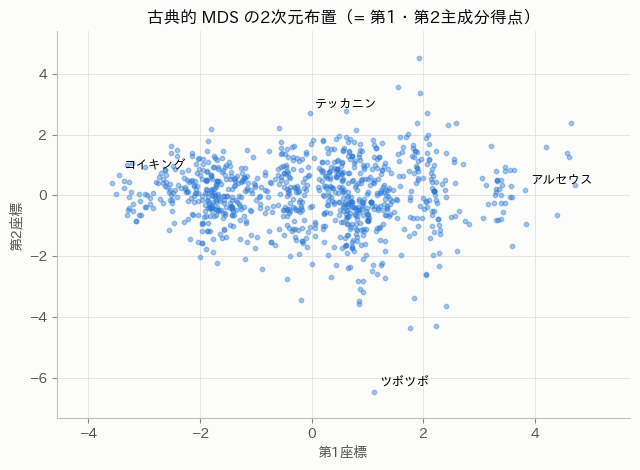

In [183]:
# 古典的 MDS（計量 MDS）を二重中心化で自作し、PCA の主成分得点と比べる
def classical_mds(D, k=2):
    """距離行列 D から B = -1/2 J D^2 J を作り、上位 k 個の固有値・固有ベクトルで座標を返す."""
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, U = np.linalg.eigh(B)
    w, U = w[::-1], U[:, ::-1]
    return U[:, :k] * np.sqrt(np.maximum(w[:k], 0)), w

D_all = squareform(pdist(Z_mds))                  # ユークリッド距離
X_mds, w_mds = classical_mds(D_all, k=2)

# PCA（相関行列の固有値分解）の主成分得点
lam, W = np.linalg.eigh(np.corrcoef(Z_mds.T))
lam, W = lam[::-1], W[:, ::-1]
W = W * np.sign(W[np.abs(W).argmax(axis=0), range(W.shape[1])])   # 第22章と同じ符号の向き（最大絶対値成分を正）
pc_scores = Z_mds @ W[:, :2]
X_mds_al = X_mds * np.sign((X_mds * pc_scores).sum(0))     # 符号をそろえる
print("B の上位6固有値 / (n-1):", (w_mds[:6] / (len(df) - 1)).round(4))
print("相関行列の固有値       :", lam.round(4))
print("B の7番目以降の固有値の最大絶対値:", np.abs(w_mds[6:]).max().round(8), "（階数は p=6）")
print("MDS 座標と主成分得点の最大差:", np.abs(X_mds_al - pc_scores).max().round(10))

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.scatter(X_mds_al[:, 0], X_mds_al[:, 1], s=10, alpha=0.4, color=PALETTE[0])
for nm in ["ツボツボ", "テッカニン", "コイキング", "アルセウス"]:
    i = df.index[df["名前"] == nm][0]
    ax.annotate(nm, (X_mds_al[i, 0], X_mds_al[i, 1]), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set(title="古典的 MDS の2次元布置（= 第1・第2主成分得点）", xlabel="第1座標", ylabel="第2座標")
ax.margins(x=0.12, y=0.08)
fig.tight_layout()
plt.show()

**結果の読み方**
- $B$ の上位6固有値を $n-1$ で割ると相関行列の固有値（2.69, 1.13, …）と一致し、7番目以降は0（$B$ の階数は $p=6$）だった。
- 2次元の MDS 座標は第1・第2主成分得点と数値誤差の範囲で一致した。ユークリッド距離を使う限り、古典的 MDS は主成分分析の言い換えである。

### 26.2 ユークリッドでない距離と非計量 MDS

**問い**：マンハッタン距離（各項目の差の絶対値の和）で測った近さの関係を、2次元にどこまで保てるか。

**手法の要点**
- 距離がユークリッド空間の点から生じたものでなければ、$B$ は負の固有値をもつ（正の固有値の部分だけを使って近似する）。
- **非計量 MDS**（クラスカル）は、距離の値そのものではなく**大小の順序**だけを保つよう布置を求める。布置上の距離 $\hat d_{ij}$ と、元の距離の単調変換 $\delta_{ij}$ のずれを表すストレス
  $$\text{Stress}=\sqrt{\frac{\sum_{i<j}(\hat d_{ij}-\delta_{ij})^2}{\sum_{i<j}\delta_{ij}^2}}$$
  を最小にする（sklearn の正規化ストレス。分母を $\sum\hat d_{ij}^2$ とするクラスカルのストレス1もある。0に近いほど良い。0.05以下で良好、0.2以上で不良が目安）。
- 反復計算（SMACOF 法）は局所解に陥りやすいので、初期値に古典的 MDS の布置を使う。

（→ py 26-2：33匹のマンハッタン距離で古典的 MDS の固有値を調べ、sklearn の非計量 MDS で布置を求める）

マンハッタン距離の B の固有値（負の値が出る = ユークリッド空間に埋め込めない）:
  正: 16 個, 負: 16 個, 最小: -21.818
ストレス（正規化, 0に近いほど良い）  非計量MDS（古典的MDSを初期値）: 0.145 / ランダム初期値8回の最良: 0.284
元の距離と布置上の距離の順位相関  古典的MDS: 0.792 / 非計量MDS: 0.878 / 非計量MDS(ランダム初期値): 0.197


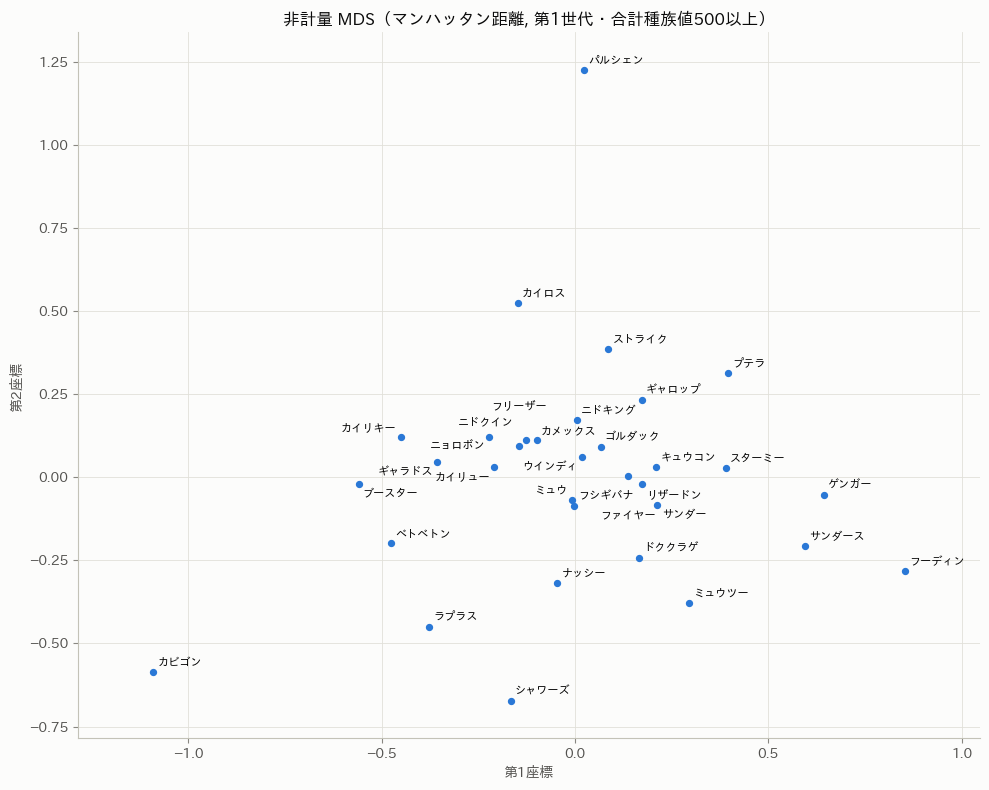

In [184]:
# ユークリッドでない距離（マンハッタン距離）: 古典的 MDS と非計量 MDS（33匹）
Z_s = ((g1s_mds[STATS] - df[STATS].mean()) / df[STATS].std(ddof=1)).to_numpy()
D_man = squareform(pdist(Z_s, metric="cityblock"))
X_cl, w_cl = classical_mds(D_man, k=2)
print("マンハッタン距離の B の固有値（負の値が出る = ユークリッド空間に埋め込めない）:")
print("  正:", (w_cl > 1e-9).sum(), "個, 負:", (w_cl < -1e-9).sum(), "個, 最小:", w_cl.min().round(3))

# 非計量 MDS（SMACOF 法）は局所解に陥りやすいので、古典的 MDS の布置を初期値にする
def nonmetric_mds(D, init=None):
    m = MDS(n_components=2, metric=False, dissimilarity="precomputed", n_init=1 if init is not None else 8,
            max_iter=3000, eps=1e-9, random_state=SEED, normalized_stress=True)
    return m.fit_transform(D, init=init), m.stress_

X_nm, stress_nm = nonmetric_mds(D_man, init=X_cl)
X_nm_rand, stress_rand = nonmetric_mds(D_man)
iu = np.triu_indices(len(D_man), 1)
rank_corr = lambda X: stats.spearmanr(D_man[iu], pdist(X))[0]   # 距離の順位がどれだけ保たれたか
print("ストレス（正規化, 0に近いほど良い）  非計量MDS（古典的MDSを初期値）: {:.3f} / ランダム初期値8回の最良: {:.3f}".format(
    stress_nm, stress_rand))
print("元の距離と布置上の距離の順位相関  古典的MDS: {:.3f} / 非計量MDS: {:.3f} / 非計量MDS(ランダム初期値): {:.3f}".format(
    rank_corr(X_cl), rank_corr(X_nm), rank_corr(X_nm_rand)))

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_nm[:, 0], X_nm[:, 1], s=18, color=PALETTE[0])
ax.set(title="非計量 MDS（マンハッタン距離, 第1世代・合計種族値500以上）", xlabel="第1座標", ylabel="第2座標")
ax.margins(x=0.1, y=0.06)
fig.tight_layout()
place_labels(ax, X_nm, g1s_mds["名前"], fontsize=8)     # ラベルが重ならない向きを選んで置く
plt.show()

**結果の読み方**
- マンハッタン距離の $B$ には負の固有値が16個（最小 約−22）現れ、この距離はユークリッド空間に正確には埋め込めない。
- 古典的 MDS を初期値にした非計量 MDS のストレスは約0.15で、元の距離と布置上の距離の順位相関は0.88（古典的 MDS は0.79）。ランダムな初期値からでは、8回試した最良の解でもストレス約0.28・順位相関0.20にとどまり、初期値の重要さがわかる。
- 布置では、左下にカビゴン・ラプラス・シャワーズ（HP型）、右にフーディン・サンダース・ゲンガー（特攻・素早型）、上にパルシェン・カイロス（防御・攻撃型）が離れ、第24章のクラスターと同様の「型」の違いが読める。

### 26.3 正準相関分析

**問い**：体格 $\boldsymbol x=$（log高さ, log重さ）と種族値 $\boldsymbol y=$（6項目）の関係を、少数の合成変数の相関で表すとどうなるか。

**手法の要点**
- $u=\boldsymbol a^\top\boldsymbol x$ と $v=\boldsymbol b^\top\boldsymbol y$ の相関が最大になる $\boldsymbol a,\boldsymbol b$ を求める。相関行列を $\begin{pmatrix}R_{11}&R_{12}\\R_{21}&R_{22}\end{pmatrix}$（標準化した変数）とすると、$\boldsymbol a$ は
  $$R_{11}^{-1}R_{12}R_{22}^{-1}R_{21}\,\boldsymbol a=\rho^2\boldsymbol a$$
  の最大固有値の固有ベクトルで、$\rho$ が第1正準相関係数、$\boldsymbol b\propto R_{22}^{-1}R_{21}\boldsymbol a$。第2以降の組は、それまでの正準変量と無相関という条件のもとで同様に求まる（全部で $\min(p,q)=2$ 組）。
- 正準変量は分散1に規格化する。係数（正準係数）は変数間の相関の影響を受けるので、解釈には元の変数と正準変量の相関（構造係数）も見る。
- 検定（バートレット）：$H_0$「第 $k+1$ 以降の正準相関はすべて0」のもとで
  $$-\left(n-1-\frac{p+q+1}{2}\right)\sum_{i>k}\log(1-\hat\rho_i^2)$$
  が近似的に自由度 $(p-k)(q-k)$ のカイ2乗分布に従う（多変量正規性を仮定）。

（→ py 26-3：固有値問題を手計算し、sklearn の `CCA` と照合。検定・構造係数・第1正準変量の散布図）

正準相関係数（固有値問題）: [0.73   0.3038]
正準変量どうしの相関     : [0.73, 0.3038]
sklearn CCA の正準相関   : [0.73, 0.3038]
H0: ρ_1 以降 = 0 : χ² = 784.7, 自由度 = 12, p値 = 3.12e-160
H0: ρ_2 以降 = 0 : χ² = 88.6, 自由度 = 5, p値 = 1.35e-17


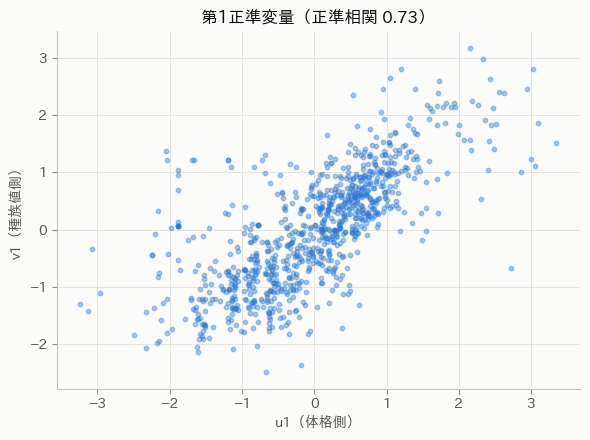

,第1正準変量との相関,第2正準変量との相関,第1正準係数,第2正準係数
log高さ,0.991,-0.136,0.797,-1.551
log重さ,0.889,0.457,0.237,1.727
HP,0.768,0.077,0.420,0.221
攻撃,0.810,0.008,0.417,0.168
防御,0.630,0.430,0.248,0.418
特攻,0.622,-0.640,0.194,-0.651
特防,0.591,-0.072,0.097,0.033
素早,0.347,-0.731,0.015,-0.530


In [185]:
# 正準相関分析: 体格 x = (log高さ, log重さ) と 種族値 y（6項目）
Xc = df[["log高さ", "log重さ"]].to_numpy(float)
Yc = df[STATS].to_numpy(float)
Rall = np.corrcoef(np.c_[Xc, Yc].T)
p_c, q_c = Xc.shape[1], Yc.shape[1]
R11, R12, R22 = Rall[:p_c, :p_c], Rall[:p_c, p_c:], Rall[p_c:, p_c:]
M_cc = np.linalg.solve(R11, R12) @ np.linalg.solve(R22, R12.T)   # R11^{-1} R12 R22^{-1} R21
rho2, A_cc = np.linalg.eig(M_cc)
o_cc = np.argsort(rho2.real)[::-1]
rho2, A_cc = rho2.real[o_cc], A_cc.real[:, o_cc]
rho = np.sqrt(rho2)
# 正準係数（標準化した変数に対する）: var(u)=var(v)=1 に規格化
A_cc = A_cc / np.sqrt(np.einsum("ik,ij,jk->k", A_cc, R11, A_cc))
B_cc = np.linalg.solve(R22, R12.T) @ A_cc / rho
Xs = (Xc - Xc.mean(0)) / Xc.std(0, ddof=1)
Ys = (Yc - Yc.mean(0)) / Yc.std(0, ddof=1)
U_cc, V_cc = Xs @ A_cc, Ys @ B_cc
print("正準相関係数（固有値問題）:", rho.round(4))
print("正準変量どうしの相関     :", [np.corrcoef(U_cc[:, k], V_cc[:, k])[0, 1].round(4) for k in range(2)])

cca = CCA(n_components=2, max_iter=5000, tol=1e-10).fit(Xc, Yc)
xs_sk, ys_sk = cca.transform(Xc, Yc)
print("sklearn CCA の正準相関   :", [np.corrcoef(xs_sk[:, k], ys_sk[:, k])[0, 1].round(4) for k in range(2)])

# バートレットの検定: H0「第 k+1 以降の正準相関はすべて0」
n_c = len(df)
for k in range(2):
    lam_w = np.prod(1 - rho2[k:])
    chi2 = -(n_c - 1 - (p_c + q_c + 1) / 2) * np.log(lam_w)
    dof = (p_c - k) * (q_c - k)
    print(f"H0: ρ_{k+1} 以降 = 0 : χ² = {chi2:.1f}, 自由度 = {dof}, p値 = {stats.chi2.sf(chi2, dof):.2e}")

# 構造係数（元の変数と第1・第2正準変量の相関）
struct = pd.DataFrame(
    [[np.corrcoef(Xs[:, j], U_cc[:, k])[0, 1] for k in range(2)] for j in range(p_c)] +
    [[np.corrcoef(Ys[:, j], V_cc[:, k])[0, 1] for k in range(2)] for j in range(q_c)],
    index=["log高さ", "log重さ"] + STATS, columns=["第1正準変量との相関", "第2正準変量との相関"])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(U_cc[:, 0], V_cc[:, 0], s=10, alpha=0.4, color=PALETTE[0])
ax.set(title=f"第1正準変量（正準相関 {rho[0]:.2f}）", xlabel="u1（体格側）", ylabel="v1（種族値側）")
fig.tight_layout()
plt.show()
pd.concat([struct, pd.DataFrame(np.r_[A_cc, B_cc], index=struct.index,
                                columns=["第1正準係数", "第2正準係数"])], axis=1).round(3)

**結果の読み方**
- 正準相関係数は 0.73, 0.30。固有値問題からの値、正準変量どうしの相関、sklearn の `CCA` の値は一致した。
- 検定では $\rho_1$ 以降＝0（$\chi^2\approx785$、自由度12）も $\rho_2$＝0（$\chi^2\approx89$、自由度5）も $p$ 値がほぼ0で、有意水準5%で2組とも有意。ただし系統内の非独立や非正規性があるので、$p$ 値の大きさは割り引く。
- 第1正準変量は体格側が log高さ（0.99）・log重さ（0.89）、種族値側が攻撃（0.81）・HP（0.77）と強く相関する「大きいポケモンほど HP・攻撃が高い（全体に強い）」という軸。
- 第2正準変量は体格側が「高さに比べて重い」（log重さ +0.46、log高さ −0.14）、種族値側が「防御が高く（+0.43）、特攻（−0.64）・素早（−0.73）が低い」軸で、「ずんぐり重いポケモンは硬くて遅い」という関係を表す。これは記述であり、体格が種族値を決めるという因果ではない。

### 26.4 数量化III類（対応分析）

**問い**：タイプとタマゴグループの対応関係を、両者を同じ平面に置いた地図で表すとどうなるか。

**手法の要点**
- $I\times J$ のクロス表 $N$ の相対度数 $P=N/n$、行和 $\boldsymbol r$、列和 $\boldsymbol c$、$D_r=\operatorname{diag}(\boldsymbol r)$, $D_c=\operatorname{diag}(\boldsymbol c)$ として、標準化残差行列
  $$S=D_r^{-1/2}(P-\boldsymbol r\boldsymbol c^\top)D_c^{-1/2}=U\Sigma V^\top$$
  を特異値分解する。行の座標 $F=D_r^{-1/2}U\Sigma$、列の座標 $G=D_c^{-1/2}V\Sigma$（主座標）。
- $\sum_k\sigma_k^2=\chi^2/n$（総慣性）で、各次元の寄与率は $\sigma_k^2/\sum\sigma^2$。
- 行と列の座標は $F=D_r^{-1}PG\Sigma^{-1}$ を満たす（行の得点は、その行の度数で重み付けした列の得点の平均に比例する）。この「相互平均」の性質をもつ数値の与え方を求めるのが数量化III類であり、クロス表の対応分析と同じ解を与える。
- 個体×カテゴリの 0/1 表（各個体がタイプとタマゴの2つのカテゴリに1をもつ）に数量化III類を適用すると、その固有値 $\mu$ はクロス表の特異値 $\sigma$ と $\mu=(1+\sigma)/2$ の関係にある。
- 外的基準（目的変数）がなく、カテゴリどうしの関係だけを見る手法である。近くに置かれた行と列は同時に現れやすい（ただし行と列を重ねた図では、行の点と列の点の距離そのものは厳密には解釈できず、目安にとどまる）。

（→ py 26-4：タイプ1×タマゴ1 のクロス表を SVD で分解し、$\chi^2/n$、推移式、0/1表との関係を確認して布置図を描く）

クロス表: 17タイプ × 14タマゴグループ, n = 915
総慣性 Σσ² = 3.2834,  χ²/n = 3.2834
各次元の寄与率: [0.256 0.167 0.137 0.119 0.085]
推移式の確認（最大差）: 0.0


0/1表の固有値（上位3）: [0.9581 0.8699 0.8351]  (1+σ)/2: [0.9581 0.8699 0.8351]


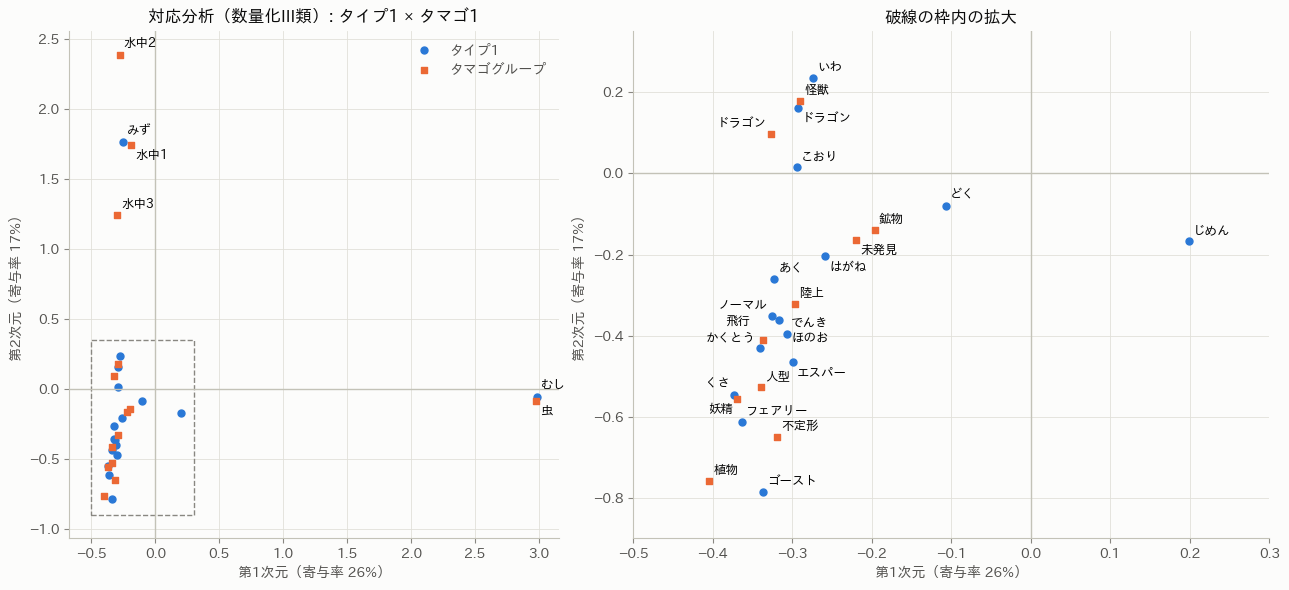

In [186]:
# 数量化III類（対応分析）: タイプ1 × タマゴ1 のクロス表を SVD で分解
ct_src = df[(df["タイプ1"] != "ひこう") & (df["タマゴ1"] != "メタモン")]
N_ct = pd.crosstab(ct_src["タイプ1"].astype(str), ct_src["タマゴ1"].astype(str))
n_ct = N_ct.to_numpy().sum()
P_ct = N_ct.to_numpy() / n_ct
r_m, c_m = P_ct.sum(1), P_ct.sum(0)
S_ct = (P_ct - np.outer(r_m, c_m)) / np.sqrt(np.outer(r_m, c_m))   # 標準化残差
U_ct, sv, Vt_ct = np.linalg.svd(S_ct, full_matrices=False)
chi2_ct = stats.chi2_contingency(N_ct, correction=False)[0]
print(f"クロス表: {N_ct.shape[0]}タイプ × {N_ct.shape[1]}タマゴグループ, n = {n_ct}")
print(f"総慣性 Σσ² = {np.sum(sv ** 2):.4f},  χ²/n = {chi2_ct / n_ct:.4f}")
print("各次元の寄与率:", (sv ** 2 / np.sum(sv ** 2))[:5].round(3))
F_row = U_ct / np.sqrt(r_m)[:, None] * sv            # 行（タイプ）の主座標
G_col = Vt_ct.T / np.sqrt(c_m)[:, None] * sv         # 列（タマゴ）の主座標
# 相互平均（推移式）: 行の座標 = 列の座標の重み付き平均 / σ
F_from_G = (P_ct / r_m[:, None]) @ G_col[:, :2] / sv[:2]
print("推移式の確認（最大差）:", np.abs(F_from_G - F_row[:, :2]).max().round(10))

# 数量化III類（個体×カテゴリの 0/1 表）として計算した固有値との関係: μ = (1 + σ) / 2
ind = pd.get_dummies(ct_src[["タイプ1", "タマゴ1"]].astype(str)).to_numpy(float)
Pi = ind / ind.sum()
ri, ci = Pi.sum(1), Pi.sum(0)
sv_ind = np.linalg.svd((Pi - np.outer(ri, ci)) / np.sqrt(np.outer(ri, ci)), compute_uv=False)
print("0/1表の固有値（上位3）:", (sv_ind[:3] ** 2).round(4), " (1+σ)/2:", ((1 + sv[:3]) / 2).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 1.3]})
zoom = dict(xlim=(-0.5, 0.3), ylim=(-0.9, 0.35))
for ax, is_zoom in zip(axes, [False, True]):
    ax.axhline(0, color=INK["axis"], lw=1)
    ax.axvline(0, color=INK["axis"], lw=1)
    ax.scatter(F_row[:, 0], F_row[:, 1], color=PALETTE[0], s=25, label="タイプ1")
    ax.scatter(G_col[:, 0], G_col[:, 1], color=PALETTE[1], s=25, marker="s", label="タマゴグループ")
    ax.set(xlabel=f"第1次元（寄与率 {sv[0] ** 2 / np.sum(sv ** 2):.0%}）",
           ylabel=f"第2次元（寄与率 {sv[1] ** 2 / np.sum(sv ** 2):.0%}）")
axes[0].add_patch(plt.Rectangle((zoom["xlim"][0], zoom["ylim"][0]), zoom["xlim"][1] - zoom["xlim"][0],
                                zoom["ylim"][1] - zoom["ylim"][0], fill=False, ec=INK["muted"], ls="--"))
axes[0].set_title("対応分析（数量化III類）: タイプ1 × タマゴ1")
axes[0].legend(loc="upper right")
axes[1].set(title="破線の枠内の拡大", **zoom)
fig.tight_layout()
# 左図は外側の点だけ、右図（拡大）は内側の点だけに名前を付ける（重ならない向きを選ぶ）
pts_all = np.r_[F_row[:, :2], G_col[:, :2]]
names_all = list(N_ct.index) + list(N_ct.columns)
inside = ((zoom["xlim"][0] < pts_all[:, 0]) & (pts_all[:, 0] < zoom["xlim"][1])
          & (zoom["ylim"][0] < pts_all[:, 1]) & (pts_all[:, 1] < zoom["ylim"][1]))
for ax, is_zoom in zip(axes, [False, True]):
    sel = inside == is_zoom
    place_labels(ax, pts_all[sel], [nm for nm, f in zip(names_all, sel) if f])
plt.show()

**結果の読み方**
- 総慣性 $\sum\sigma_k^2=3.28$ は $\chi^2/n$ と一致し、推移式も成り立った。0/1 表の数量化III類の固有値は $(1+\sigma)/2$ と一致した。第1次元の寄与率は26%、第2次元は17%で、2次元では全体の4割程度しか表せない。
- 第1次元は「むし」タイプと「虫」グループだけを大きく離す軸（両者がほぼ一対一に対応するため）、第2次元は「みず」タイプと「水中1〜3」グループを上に離す軸である。
- 拡大図では、フェアリー–妖精、かくとう–人型、いわ・ドラゴン–怪獣・ドラゴン、はがね–鉱物・未発見、ノーマル・ほのお・でんき–陸上など、名前から予想できる組が近くに並ぶ。一方で、ゴーストの最も近くには不定形より植物が、くさの近くには植物より妖精・人型が来るなど、2次元では名前どおりに並ばない組もある（2次元で表せるのは慣性の4割程度）。
- 対応が一対一に近い組ほど慣性が大きく、上位の次元を占める。クロス表の一部の強い対応が布置全体を決めることに注意する。

### 26.5 数量化I類・II類

**問い**：タイプと成長の速さ（質的変数）で、合計種族値をどれだけ説明・判別できるか。

**手法の要点**

| 手法 | 外的基準（目的変数） | 説明変数 | 量的変数での対応物 |
|---|---|---|---|
| 数量化I類 | 量的 | 質的（アイテム・カテゴリ） | 重回帰分析 |
| 数量化II類 | 質的（群） | 質的 | 判別分析 |
| 数量化III類 | なし | 質的 | 主成分分析（対応分析） |

- 各アイテム（タイプ1、成長）のカテゴリを 0/1 のダミー変数にし（各アイテムで1カテゴリを基準として落とす）、I類は最小2乗法、II類は線形判別分析を行う。得られた係数を、アイテムごとに重み付き平均が0になるよう平行移動したものを**カテゴリスコア**という。
- アイテムの重要度は、カテゴリスコアのレンジ（最大−最小）で比べることが多い。II類の判別のよさは相関比 $\eta^2$（判別得点の群間平方和 ÷ 全平方和）で表す。

（→ py 26-5：数量化I類（合計種族値）と II類（合計種族値500以上か）をダミー変数で計算し、カテゴリスコアを表示）

In [187]:
# 数量化I類・II類 = カテゴリをダミー変数にした重回帰・判別分析
dq = df[df["成長"] != "105万"].copy()                  # 105万は2匹しかいないので除く
dq["成長"] = dq["成長"].astype(str)
dq["タイプ1"] = dq["タイプ1"].astype(str)
Xq = pd.get_dummies(dq[["タイプ1", "成長"]], drop_first=True, dtype=float)

def category_scores(coef, cols, data):
    """ダミー係数をアイテムごとに「重み付き平均0」のカテゴリスコアに直す."""
    out = {}
    for item in ["タイプ1", "成長"]:
        cats = sorted(data[item].unique())
        raw = pd.Series({c: coef.get(f"{item}_{c}", 0.0) for c in cats})   # 基準カテゴリは0
        freq = data[item].value_counts(normalize=True)[cats]
        out[item] = raw - (raw * freq).sum()
    return out

# 数量化I類: 外的基準 = 合計種族値（量的）
yq = dq["合計種族値"].to_numpy(float)
Aq = np.c_[np.ones(len(Xq)), Xq.to_numpy()]
beta = np.linalg.lstsq(Aq, yq, rcond=None)[0]
r2 = 1 - np.sum((yq - Aq @ beta) ** 2) / np.sum((yq - yq.mean()) ** 2)
sc1 = category_scores(dict(zip(Xq.columns, beta[1:])), Xq.columns, dq)
print(f"数量化I類（合計種族値 ~ タイプ1 + 成長）: 決定係数 R² = {r2:.3f}")
for item, s in sc1.items():
    print(f"  {item} のレンジ（最大-最小）= {s.max() - s.min():.1f}")
print("  成長のカテゴリスコア:", s.round(1).to_dict())

# 数量化II類: 外的基準 = 合計種族値500以上か（2群）
yq2 = (dq["合計種族値"] >= 500).to_numpy(int)
lda_q = LinearDiscriminantAnalysis().fit(Xq, yq2)
score_q = lda_q.decision_function(Xq)
# 相関比 η² = 群間平方和 / 全平方和（判別得点について）
ss_between = sum((yq2 == g).sum() * (score_q[yq2 == g].mean() - score_q.mean()) ** 2 for g in [0, 1])
eta2 = ss_between / np.sum((score_q - score_q.mean()) ** 2)
sc2 = category_scores(dict(zip(Xq.columns, lda_q.coef_[0])), Xq.columns, dq)
print(f"\n数量化II類（合計種族値500以上か ~ タイプ1 + 成長）: 相関比 η² = {eta2:.3f}, "
      f"訓練正解率 = {lda_q.score(Xq, yq2):.3f}（多数派の割合 {1 - yq2.mean():.3f}）")
for item, s in sc2.items():
    print(f"  {item} のレンジ = {s.max() - s.min():.2f}")
pd.DataFrame({"I類スコア(合計種族値)": sc1["タイプ1"], "II類スコア(判別)": sc2["タイプ1"]}).sort_values(
    "I類スコア(合計種族値)", ascending=False).round(2)

数量化I類（合計種族値 ~ タイプ1 + 成長）: 決定係数 R² = 0.222
  タイプ1 のレンジ（最大-最小）= 68.4
  成長 のレンジ（最大-最小）= 138.5
  成長のカテゴリスコア: {'100万': -26.4, '106万': -20.9, '125万': 85.4, '164万': -29.6, '60万': -24.0, '80万': -53.0}

数量化II類（合計種族値500以上か ~ タイプ1 + 成長）: 相関比 η² = 0.226, 訓練正解率 = 0.767（多数派の割合 0.682）
  タイプ1 のレンジ = 2.50
  成長 のレンジ = 3.38


,I類スコア(合計種族値),II類スコア(判別)
エスパー,30.36,0.30
ドラゴン,29.18,-0.17
ほのお,28.71,0.55
はがね,28.40,0.73
ゴースト,28.35,0.05
フェアリー,18.94,0.57
ひこう,17.09,1.97
いわ,14.46,0.09
でんき,11.28,0.47
かくとう,3.26,0.05


**結果の読み方**
- 数量化I類の決定係数は約0.22。レンジは成長（約139）がタイプ1（約68）の2倍で、とくに成長「125万」（伝説や600族に多い「遅い」グループ）のカテゴリスコアが +85 と突出している。
- タイプ1のスコアはエスパー・ドラゴン・ほのお・はがね・ゴーストが高く（+28〜30）、むし（−38）・ノーマル・どくが低い。ひこうは4匹しかおらず、スコアは不安定である。
- 数量化II類（合計種族値500以上か）の相関比は約0.23、訓練データでの正解率は0.77で、多数派（500未満）と答えた場合の0.68を上回る。ここでも成長のレンジがタイプより大きい。成長の区分は種族値と同時に設定された属性で、因果的な説明ではない。

### まとめ

- 古典的 MDS はユークリッド距離では主成分分析と一致する。ユークリッドでない距離（マンハッタン距離）では負の固有値が現れ、順序だけを保つ非計量 MDS のほうが近さの関係をよく保った（初期値に古典的 MDS を使うことが重要）。
- 正準相関分析では、体格と種族値の間に「大きいほど強い」（正準相関0.73）と「ずんぐり重いほど硬くて遅い」（0.30）の2つの関係が見つかった。
- 数量化III類（対応分析）では、むし–虫、みず–水中のようにタイプとタマゴグループの強い対応が上位の次元を占め、そのほかの組も多くは名前どおりに近くに並んだ（2次元では例外もある）。数量化I類・II類はダミー変数を使った回帰・判別であり、合計種族値の説明ではタイプより成長の区分のほうが効いていた。

## 第28章 分割表

### 章の概要

質的変数どうしの関連を、度数を並べた**分割表**から調べる。
2×2 表では関連の強さを相対リスク・オッズ比で表し、独立性はフィッシャーの正確検定（小標本）や $\chi^2$ 検定（大標本）で検定する。
3つ以上の因子があるときは、期待度数の対数を主効果と交互作用の和で表す**対数線形モデル**を使い、「どの因子の組が直接関連しているか」をグラフで表す。
第12章の適合度・独立性の検定を一般化したもので、対数線形モデルは第18章の一般化線形モデル（ポアソン回帰）の特別な場合でもある。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 28.1 | 相対リスク・オッズ比 | 合計種族値570以上のポケモンは、性別不明になりやすいか |
| 28.2 | 前向き・後向き研究 | 「結果」で抽出したとき、相対リスクとオッズ比のどちらが推定できるか |
| 28.3 | フィッシャーの正確検定 | ドラゴンタイプだけの小さな表でも関連があるといえるか |
| 28.4 | 2×2 表の $\chi^2$ 検定 | 同じ表を $\chi^2$ 検定（イエーツ補正）で調べる |
| 28.5 | $r\times c$ 表の独立性の検定 | タイプ1の構成は世代によって異なるか |
| 28.6 | 逸脱度 $G^2$ | 尤度比による独立性の検定は $\chi^2$ 検定と一致するか |
| 28.7〜28.8 | 対数線形モデル | 複合タイプか・世代・成長の速さの3因子の関連の構造は |
| 28.9 | 無向独立グラフ・分解可能モデル | 選んだモデルをグラフで表すと |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的 | 570以上か未満かに二値化（2×2 表の要因） |
| `性別` | 質的（8水準） | 「不明」かどうかに二値化（2×2 表の結果） |
| `タイプ1` | 質的（18水準） | $r\times c$ 表の行。件数の少ないタイプは「その他」にまとめる |
| `世代` | 質的（1〜7） | $r\times c$ 表の列・3元表の因子B。いくつかの世代をまとめる |
| `複合タイプ` | 2値 | 3元表の因子A（単タイプ／複合タイプ） |
| `成長経験値` | 質的（6水準） | 3元表の因子C。100万以下／105〜106万／125万以上の3区分にまとめる |

- **対象の行**：全920行（28.3 だけタイプ1がドラゴンの37匹）
- **加工**：上の二値化・水準の統合。期待度数が小さいセルを作らないため、水準は分析の前にまとめる
- **データの性質と注意点**：全ポケモンを仮想母集団からの標本とみなして検定する。同じ進化系統の行（例: 進化前後で性別・成長の区分は同じことが多い）は独立ではないため、$p$ 値は実際より小さく出やすい。ひこうタイプ1は4匹しかいない

（→ py 28-0：二値化した変数と、タイプ1・世代の件数）

In [188]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 2×2 表の要因と結果
ct = df.assign(
    高種族値=np.where(df["合計種族値"] >= 570, "570以上", "570未満"),
    性別不明=np.where(df["性別"] == "不明", "不明", "あり"),
)
print("合計種族値570以上:", (df["合計種族値"] >= 570).sum(), "匹 / 性別不明:", (df["性別"] == "不明").sum(), "匹")
print("\nタイプ1の件数（少ない順に5つ）")
print(df["タイプ1"].value_counts().tail(5).to_string())
print("\n世代ごとの件数")
print(df["世代"].value_counts().sort_index().to_string())

合計種族値570以上: 143 匹 / 性別不明: 130 匹

タイプ1の件数（少ない順に5つ）
タイプ1
かくとう     31
はがね      30
こおり      28
フェアリー    19
ひこう       4

世代ごとの件数
世代
1    184
2    106
3    160
4    121
5    166
6     86
7     97


### 28.1 相対リスク・オッズ・オッズ比

**問い**：合計種族値570以上のポケモン（要因あり）は、570未満（要因なし）に比べて性別不明（結果）になりやすいか。

**手法の要点**
- 2×2 表を次のように書く。

| | 結果あり（不明） | 結果なし |
|---|---|---|
| 要因あり（570以上） | $a$ | $b$ |
| 要因なし（570未満） | $c$ | $d$ |

- リスク（結果が起こる割合）$\hat p_1=a/(a+b)$、$\hat p_0=c/(c+d)$。**相対リスク** $\mathrm{RR}=\hat p_1/\hat p_0$。
- オッズ $\hat p/(1-\hat p)$ は、要因ありで $a/b$、要因なしで $c/d$。**オッズ比** $\mathrm{OR}=\dfrac{a/b}{c/d}=\dfrac{ad}{bc}$。独立なら母オッズ比は1。
- 対数をとると正規近似がよくなる。度数が大きいとき、デルタ法により
$$
\mathrm{SE}(\log\widehat{\mathrm{OR}})\approx\sqrt{\frac1a+\frac1b+\frac1c+\frac1d},\qquad
\mathrm{SE}(\log\widehat{\mathrm{RR}})\approx\sqrt{\frac1a-\frac1{a+b}+\frac1c-\frac1{c+d}}
$$
- 95%信頼区間は $\exp\{\log\widehat{\mathrm{OR}}\pm z_{0.025}\,\mathrm{SE}\}$（$z_{0.025}\approx1.96$）。区間は OR の値の周りで非対称になる。
- 結果が稀（$\hat p$ が小さい）なら $\mathrm{OR}\approx\mathrm{RR}$ だが、ここでは要因ありのリスクが大きいので両者は大きく離れるはず。

（→ py 28-1：定義式での計算と statsmodels の照合）

In [189]:
# 2×2 表: 行 = 要因（高種族値か）, 列 = 結果（性別不明か）
tab22 = pd.crosstab(ct["高種族値"], ct["性別不明"]).loc[["570以上", "570未満"], ["不明", "あり"]]
print(tab22, "\n")
a, b = tab22.iloc[0]
c, d = tab22.iloc[1]
z975 = stats.norm.ppf(0.975)

# 相対リスク（リスク = 性別不明の割合）
p1, p0 = a / (a + b), c / (c + d)
rr = p1 / p0
se_log_rr = np.sqrt(1 / a - 1 / (a + b) + 1 / c - 1 / (c + d))
ci_rr = np.exp(np.log(rr) + np.array([-1, 1]) * z975 * se_log_rr)

# オッズとオッズ比
odds1, odds0 = a / b, c / d
or22 = odds1 / odds0            # = ad / bc
se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
ci_or = np.exp(np.log(or22) + np.array([-1, 1]) * z975 * se_log_or)

print(f"リスク: 570以上 {p1:.3f}, 570未満 {p0:.3f}")
print(f"相対リスク RR = {rr:.2f}  SE(log RR) = {se_log_rr:.3f}  95%CI = [{ci_rr[0]:.2f}, {ci_rr[1]:.2f}]")
print(f"オッズ: 570以上 {odds1:.3f}, 570未満 {odds0:.3f}")
print(f"オッズ比 OR = ad/bc = {or22:.2f}  log OR = {np.log(or22):.3f}  SE(log OR) = {se_log_or:.3f}")
print(f"  95%CI = [{ci_or[0]:.2f}, {ci_or[1]:.2f}]")

# statsmodels の Table2x2 と照合
t22 = sm.stats.Table2x2(tab22.values)
print(f"\nstatsmodels: RR = {t22.riskratio:.2f} CI = {np.round(t22.riskratio_confint(), 2)}, "
      f"OR = {t22.oddsratio:.2f} CI = {np.round(t22.oddsratio_confint(), 2)}")

性別不明   不明   あり
高種族値          
570以上  89   54
570未満  41  736 

リスク: 570以上 0.622, 570未満 0.053
相対リスク RR = 11.79  SE(log RR) = 0.165  95%CI = [8.53, 16.31]
オッズ: 570以上 1.648, 570未満 0.056
オッズ比 OR = ad/bc = 29.59  log OR = 3.387  SE(log OR) = 0.236
  95%CI = [18.64, 46.95]

statsmodels: RR = 11.79 CI = [ 8.53 16.31], OR = 29.59 CI = [18.64 46.95]


**結果の読み方**
- 性別不明の割合は570以上で約62%、570未満で約5%であり、相対リスクは約11.8（95%CI 8.5〜16.3）。
- オッズ比は約29.6（95%CI 18.6〜47.0）で、相対リスクよりずっと大きい。570以上ではリスクが0.5を超えており「結果が稀」の条件が成り立たないため、$\mathrm{OR}\approx\mathrm{RR}$ の近似は使えない。
- 手計算の値と信頼区間は statsmodels と一致した。性別不明の多くは伝説・幻のポケモンや無機物系のポケモンであり、これが合計種族値の高さと重なっていると考えられる（観察データなので「種族値が高いと性別が消える」という因果ではない）。

### 28.2 前向き研究・後向き研究（コホート研究とケースコントロール研究）

**問い**：要因ではなく結果（性別不明か）でポケモンを選んで調べたら、相対リスクとオッズ比のどちらが正しく推定できるか。

**手法の要点**
- **前向き研究**は研究開始後に被験者を追跡して結果を記録し、**後向き研究**は開始前にすでに起きたことを記録から調べる。
- **コホート研究**：要因の有無で集団を決めて結果を観察する。要因ごとのリスク $P(\text{結果}\mid\text{要因})$ が推定できるので、相対リスクもオッズ比も推定できる。
- **ケースコントロール研究**：結果あり（ケース）と結果なし（コントロール）を決まった人数ずつ集め、過去の要因を調べる。結果の割合は研究者が決めてしまうので $P(\text{結果}\mid\text{要因})$ は推定できず、**相対リスクは推定できない**。
- 一方オッズ比は、行と列を入れ替えても同じ値
$$
\frac{P(\text{結果}\mid\text{要因あり})/P(\text{結果なし}\mid\text{要因あり})}{P(\text{結果}\mid\text{要因なし})/P(\text{結果なし}\mid\text{要因なし})}
=\frac{P(\text{要因あり}\mid\text{結果})/P(\text{要因なし}\mid\text{結果})}{P(\text{要因あり}\mid\text{結果なし})/P(\text{要因なし}\mid\text{結果なし})}
$$
になるので、結果で抽出してもオッズ比は推定できる。
- ポケモンのデータは研究デザインで集めたものではない。ここでは920匹を母集団とみなし、「性別不明から60匹・それ以外から60匹を抽出する」ケースコントロール型の抽出を2000回くり返して、両指標の推定値を母集団の値と比べる（0 のセルを避けるため各セルに0.5を足す）。

（→ py 28-2：ケースコントロール型抽出のシミュレーション）

In [190]:
# ケースコントロール型の抽出を模擬: 結果（性別不明か）で層を分け、各層から同数を抽出する
rng = get_rng()
is_case = (df["性別"] == "不明").to_numpy()
is_exp = (df["合計種族値"] >= 570).to_numpy()
case_idx, ctrl_idx = np.flatnonzero(is_case), np.flatnonzero(~is_case)
n_each, n_rep = 60, 2000
cc_rr, cc_or = [], []
for _ in range(n_rep):
    s = np.concatenate([rng.choice(case_idx, n_each, replace=False),
                        rng.choice(ctrl_idx, n_each, replace=False)])
    ca, ex = is_case[s], is_exp[s]
    aa, bb = np.sum(ex & ca) + 0.5, np.sum(ex & ~ca) + 0.5    # 0セル対策に0.5を加える
    cc_, dd = np.sum(~ex & ca) + 0.5, np.sum(~ex & ~ca) + 0.5
    cc_rr.append((aa / (aa + bb)) / (cc_ / (cc_ + dd)))
    cc_or.append(aa * dd / (bb * cc_))
cc_summary = pd.DataFrame({
    "母集団の値": [rr, or22],
    "ケースコントロール抽出での中央値": [np.median(cc_rr), np.median(cc_or)],
}, index=["相対リスク", "オッズ比"]).round(2)
print(f"各層 {n_each} 匹ずつ抽出を {n_rep} 回（抽出後の「性別不明」の割合は常に50%）")
cc_summary

各層 60 匹ずつ抽出を 2000 回（抽出後の「性別不明」の割合は常に50%）


,母集団の値,ケースコントロール抽出での中央値
相対リスク,11.79,3.54
オッズ比,29.59,27.21


**結果の読み方**
- 抽出後のオッズ比の中央値は約27で、母集団の値（約29.6）に近い（0.5 を足す補正と小標本のため少しずれる）。
- 同じ標本から「相対リスク」を計算すると中央値は約3.5で、母集団の11.8から大きく外れる。ケースの割合を50%に固定したため、リスクそのものが意味を失っている。
- ケースコントロール研究ではオッズ比を使い、結果が稀なときにそれを相対リスクの近似として解釈する、という使い分けの根拠がここにある。

### 28.3 フィッシャーの正確検定

**問い**：タイプ1がドラゴンの37匹だけの小さな表でも、高種族値と性別不明に関連があるといえるか。

**手法の要点**
- 帰無仮説 $H_0$：2つの変数は独立（母オッズ比 $=1$）。
- 行和と列和を固定すると、$H_0$ のもとで左上セルの度数 $X$ は**超幾何分布**に従う。総数 $n$、1列目の和 $n_{+1}$、1行目の和 $n_{1+}$ として
$$
P(X=x)=\frac{\binom{n_{+1}}{x}\binom{n-n_{+1}}{n_{1+}-x}}{\binom{n}{n_{1+}}}
$$
- 片側 $p$ 値（対立仮説: OR $>1$）は $P(X\ge x_{\text{obs}})$。両側 $p$ 値は、観測された表以下の確率をもつ表の確率をすべて足す（scipy と同じ定義）。
- 大標本近似を使わないので、期待度数が小さい表でも使える。

（→ py 28-3：超幾何分布の確率を手計算し、scipy と照合）

In [191]:
# フィッシャーの正確検定: ドラゴン（タイプ1）に絞った小さな 2×2 表
drg = ct[df["タイプ1"] == "ドラゴン"]
tab_drg = pd.crosstab(drg["高種族値"], drg["性別不明"]).loc[["570以上", "570未満"], ["不明", "あり"]]
print(tab_drg, "\n")
(fa, fb), (fc, fd) = tab_drg.values
n_row1, n_col1, n_tot = fa + fb, fa + fc, fa + fb + fc + fd

# 周辺度数を固定すると、左上セル X は超幾何分布 HG(N=n_tot, K=n_col1, n=n_row1) に従う
x_vals = np.arange(max(0, n_row1 + n_col1 - n_tot), min(n_row1, n_col1) + 1)
from math import comb
pmf = np.array([comb(n_col1, x) * comb(n_tot - n_col1, n_row1 - x) / comb(n_tot, n_row1) for x in x_vals])
p_one = pmf[x_vals >= fa].sum()                       # 片側（OR > 1）
p_obs = pmf[x_vals == fa][0]
p_two = pmf[pmf <= p_obs * (1 + 1e-7)].sum()          # 両側（観測以下の確率の表をすべて足す）
print("X の値と確率（手計算）")
print(pd.Series(pmf, index=x_vals).round(4).to_string())
print(f"\n観測 X = {fa}: P(X = {fa}) = {p_obs:.5f}")
print(f"手計算:  片側 p = {p_one:.5f}, 両側 p = {p_two:.5f}")
res_g = stats.fisher_exact(tab_drg.values, alternative="greater")
res_2 = stats.fisher_exact(tab_drg.values)
print(f"scipy:   片側 p = {res_g.pvalue:.5f}, 両側 p = {res_2.pvalue:.5f}  （標本オッズ比 {res_2.statistic:.2f}）")
print("有意水準5%で、ドラゴンでも「高種族値と性別不明は独立」は棄却される" if res_2.pvalue < 0.05
      else "有意水準5%で独立は棄却されない")
# 全データの表でも実施
print(f"\n全920匹の表: フィッシャーの両側 p = {stats.fisher_exact(tab22.values).pvalue:.2e}")

性別不明   不明  あり
高種族値         
570以上   9  12
570未満   1  15 

X の値と確率（手計算）
0     0.0000
1     0.0007
2     0.0078
3     0.0437
4     0.1376
5     0.2552
6     0.2835
7     0.1869
8     0.0701
9     0.0135
10    0.0010

観測 X = 9: P(X = 9) = 0.01350
手計算:  片側 p = 0.01451, 両側 p = 0.02299
scipy:   片側 p = 0.01451, 両側 p = 0.02299  （標本オッズ比 11.25）
有意水準5%で、ドラゴンでも「高種族値と性別不明は独立」は棄却される

全920匹の表: フィッシャーの両側 p = 1.63e-53


**結果の読み方**
- ドラゴン37匹の表は $\begin{pmatrix}9&12\\1&15\end{pmatrix}$（行: 570以上／未満、列: 不明／あり）で、期待度数が5未満のセルがあるため $\chi^2$ 近似は不安である。
- 手計算の片側 $p\approx0.015$、両側 $p\approx0.023$ は scipy と一致し、有意水準5%で独立は棄却される。ただし標本オッズ比は約11と、全体（約30）より小さい。
- 全920匹の表では $p$ 値は $10^{-53}$ 程度で、関連は明らかである。

### 28.4 2×2 表の独立性の $\chi^2$ 検定

**問い**：28.1 の 2×2 表で、独立性を $\chi^2$ 検定で調べる。

**手法の要点**
- 期待度数 $\hat m_{ij}=n_{i+}n_{+j}/n$ として、$\chi^2=\sum_{i,j}(n_{ij}-\hat m_{ij})^2/\hat m_{ij}$。2×2 表では
$$
\chi^2=\frac{n(ad-bc)^2}{(a+b)(c+d)(a+c)(b+d)},\qquad
\chi^2_{\text{Yates}}=\frac{n\,(|ad-bc|-n/2)^2}{(a+b)(c+d)(a+c)(b+d)}
$$
- $H_0$ のもとで、$n$ が大きいとき近似的に自由度1の $\chi^2$ 分布に従う。イエーツの補正は離散分布を連続分布で近似するときの補正で、統計量を小さくする（保守的になる）。
- $\chi^2$ は度数を $r$ 倍すると $r$ 倍になるので、関連の強さの指標には**クラメールの連関係数** $V=\sqrt{\chi^2/\{n(k-1)\}}$（$k$ は行数と列数の小さいほう）を使う。$0\le V\le1$。

（→ py 28-4：定義式・$ad-bc$ の式・scipy の照合）

In [192]:
# 独立性の χ² 検定（2×2 表）: 定義式と scipy の照合
obs22 = tab22.values.astype(float)
exp22 = obs22.sum(1, keepdims=True) * obs22.sum(0, keepdims=True) / obs22.sum()
chi2_def = ((obs22 - exp22) ** 2 / exp22).sum()
n22 = obs22.sum()
chi2_ad = n22 * (a * d - b * c) ** 2 / ((a + b) * (c + d) * (a + c) * (b + d))
chi2_yates = n22 * (abs(a * d - b * c) - n22 / 2) ** 2 / ((a + b) * (c + d) * (a + c) * (b + d))
sp_raw = stats.chi2_contingency(obs22, correction=False)
sp_yat = stats.chi2_contingency(obs22, correction=True)
print(f"定義式 χ² = {chi2_def:.2f}, (ad-bc)²の式 = {chi2_ad:.2f}, scipy = {sp_raw.statistic:.2f}")
print(f"イエーツ補正: 手計算 {chi2_yates:.2f}, scipy {sp_yat.statistic:.2f}, 自由度 1, p = {sp_yat.pvalue:.2e}")
print(f"クラメールの V = {np.sqrt(chi2_def / n22):.3f}（2×2 では |φ係数|）")

定義式 χ² = 322.95, (ad-bc)²の式 = 322.95, scipy = 322.95
イエーツ補正: 手計算 318.27, scipy 318.27, 自由度 1, p = 3.45e-71
クラメールの V = 0.592（2×2 では |φ係数|）


**結果の読み方**
- 3通りの計算で $\chi^2\approx323$ が一致し、イエーツ補正後も約318で、$p$ 値は極めて小さい。有意水準5%で独立は棄却される。
- クラメールの $V\approx0.59$ で、かなり強い関連である。$n=920$ と大きいので、$p$ 値の小ささより $V$ やオッズ比で強さを述べるほうが情報になる。

### 28.5 $r\times c$ 表の独立性の検定

**問い**：タイプ1の構成比は世代によって異なるか。

**手法の要点**
- $r\times c$ 表でも同じ $\chi^2$ 統計量を使い、$H_0$（独立）のもとで近似的に自由度 $(r-1)(c-1)$ の $\chi^2$ 分布に従う。
- $\chi^2$ 近似の目安は「期待度数が5未満のセルが全体の20%以下で、1未満のセルがない」こと。満たさないときは、意味の近い水準をまとめるか、正確検定（モンテカルロ法など）を使う。
- タイプ1（18水準）×世代（7水準）の表は期待度数が小さいセルが多いので、タイプ1は件数上位8タイプ以外を「その他」に、世代は第1〜2／3〜4／5／6〜7世代にまとめる。
- 標準化残差 $(n_{ij}-\hat m_{ij})/\sqrt{\hat m_{ij}}$ で、どのセルが独立からずれているかを見る。

（→ py 28-5：まとめる前後の期待度数、検定、標準化残差の図）

元の表 18×7: 期待度数5未満のセル 38%, 最小 0.37
まとめた表 9×4: 期待度数5未満のセル 0%, 最小 9.02

χ² = 26.28（scipy 26.28）, 自由度 24, p = 0.3389
クラメールの V = 0.098


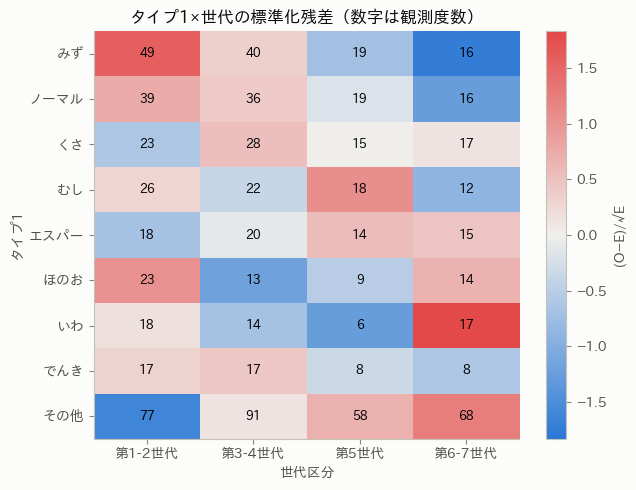

In [193]:
# r×c 表: タイプ1 × 世代。期待度数5未満のセルの割合を確認する
def expected_counts(tab):
    """独立のもとでの期待度数 n_i+ n_+j / n."""
    t = np.asarray(tab, dtype=float)
    return t.sum(1, keepdims=True) * t.sum(0, keepdims=True) / t.sum()


tab_tg = pd.crosstab(df["タイプ1"].astype(str), df["世代"])
e_tg = expected_counts(tab_tg)
print(f"元の表 {tab_tg.shape[0]}×{tab_tg.shape[1]}: 期待度数5未満のセル {np.mean(e_tg < 5):.0%}, 最小 {e_tg.min():.2f}")

# 水準をまとめる: タイプ1は上位8タイプ以外を「その他」、世代は 1-2 / 3-4 / 5 / 6-7
top_types = df["タイプ1"].value_counts().index[:8]
type_grp = df["タイプ1"].astype(str).where(df["タイプ1"].isin(top_types), "その他")
gen_grp = pd.cut(df["世代"], [0, 2, 4, 5, 7], labels=["1-2", "3-4", "5", "6-7"])
tab_rc = pd.crosstab(type_grp, gen_grp).loc[list(top_types) + ["その他"]]
e_rc = expected_counts(tab_rc)
print(f"まとめた表 {tab_rc.shape[0]}×{tab_rc.shape[1]}: 期待度数5未満のセル {np.mean(e_rc < 5):.0%}, 最小 {e_rc.min():.2f}")

o_rc = tab_rc.values
chi2_rc = ((o_rc - e_rc) ** 2 / e_rc).sum()
df_rc = (o_rc.shape[0] - 1) * (o_rc.shape[1] - 1)
sp_rc = stats.chi2_contingency(o_rc)
v_rc = np.sqrt(chi2_rc / (o_rc.sum() * (min(o_rc.shape) - 1)))
print(f"\nχ² = {chi2_rc:.2f}（scipy {sp_rc.statistic:.2f}）, 自由度 {df_rc}, p = {stats.chi2.sf(chi2_rc, df_rc):.4f}")
print(f"クラメールの V = {v_rc:.3f}")

# 標準化残差 (O-E)/sqrt(E) の図
resid_rc = (o_rc - e_rc) / np.sqrt(e_rc)
fig, ax = plt.subplots(figsize=(6.5, 5))
lim = np.abs(resid_rc).max()
im = ax.imshow(resid_rc, cmap=DIV_CMAP, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(o_rc.shape[1]), [f"第{g}世代" for g in tab_rc.columns])
ax.set_yticks(range(o_rc.shape[0]), tab_rc.index)
for i in range(o_rc.shape[0]):
    for j in range(o_rc.shape[1]):
        ax.text(j, i, f"{o_rc[i, j]}", ha="center", va="center", fontsize=9)
ax.grid(False)
ax.set(title="タイプ1×世代の標準化残差（数字は観測度数）", xlabel="世代区分", ylabel="タイプ1")
fig.colorbar(im, ax=ax, label="(O−E)/√E")
fig.tight_layout()
plt.show()

**結果の読み方**
- 元の 18×7 表では期待度数5未満のセルが約38%（最小0.37）あり、$\chi^2$ 近似の目安を満たさない。まとめた 9×4 表では最小期待度数が約9になった。
- $\chi^2\approx26.3$、自由度24、$p\approx0.34$ で、有意水準5%では「タイプ1の構成は世代によらない」を棄却できない。クラメールの $V\approx0.10$ と関連も弱い。
- 図では、みずが第1〜2世代で多く第6〜7世代で少ない、「その他」（フェアリー・ゴースト・ドラゴンなど）が第1〜2世代で少なく第6〜7世代で多い、といった偏りが見える。ただし標準化残差の絶対値はどれも2未満で、表全体としても偶然の範囲である。水準のまとめ方によって結論が変わりうる点には注意する。

### 28.6 逸脱度（$G^2$ 統計量）

**問い**：尤度比にもとづく $G^2$ で独立性を検定すると、Pearson の $\chi^2$ と同じ結論になるか。

**手法の要点**
- あるモデルの期待度数を $\hat m_{ij}$ とし、飽和モデル（期待度数 = 観測度数）との尤度比 $\lambda$ から
$$
G^2=-2\log\lambda=2\sum_{i,j}n_{ij}\log\frac{n_{ij}}{\hat m_{ij}}
$$
を**逸脱度**という（$n_{ij}=0$ のセルは0とする）。
- モデルが正しければ、$n$ が大きいとき近似的に $\chi^2$ 分布に従い、自由度は「飽和モデルのパラメータ数 − モデルのパラメータ数」（独立モデルでは $(r-1)(c-1)$）。
- 度数をポアソン分布とみなしたポアソン回帰（対数線形モデル）の残差逸脱度と一致する。

（→ py 28-6：$G^2$ の手計算・scipy・Poisson GLM の照合）

In [194]:
# 逸脱度 G² = 2 Σ O log(O/E): 独立モデルの飽和モデルに対する逸脱度
def g2_stat(obs, exp):
    obs, exp = np.asarray(obs, float), np.asarray(exp, float)
    m = obs > 0                          # 0 log 0 = 0
    return 2 * np.sum(obs[m] * np.log(obs[m] / exp[m]))


g2_22, g2_rc = g2_stat(obs22, exp22), g2_stat(o_rc, e_rc)
print(f"2×2 表:  G² = {g2_22:.2f}（Pearson χ² {chi2_def:.2f}）, 自由度 1, p = {stats.chi2.sf(g2_22, 1):.2e}")
print(f"9×4 表:  G² = {g2_rc:.2f}（Pearson χ² {chi2_rc:.2f}）, 自由度 {df_rc}, p = {stats.chi2.sf(g2_rc, df_rc):.4f}")
print("scipy (lambda_='log-likelihood'):", round(stats.chi2_contingency(o_rc, lambda_="log-likelihood").statistic, 2))

# Poisson GLM（独立モデル）の残差逸脱度とも一致する
long_rc = tab_rc.stack().rename("n").reset_index()
long_rc.columns = ["タイプ", "世代区分", "n"]
glm_ind = smf.glm("n ~ C(タイプ) + C(世代区分)", long_rc, family=sm.families.Poisson()).fit()
print(f"Poisson GLM（独立モデル）の逸脱度 = {glm_ind.deviance:.2f}, 残差自由度 = {glm_ind.df_resid:.0f}")

2×2 表:  G² = 238.86（Pearson χ² 322.95）, 自由度 1, p = 6.97e-54
9×4 表:  G² = 26.64（Pearson χ² 26.28）, 自由度 24, p = 0.3213
scipy (lambda_='log-likelihood'): 26.64
Poisson GLM（独立モデル）の逸脱度 = 26.64, 残差自由度 = 24


**結果の読み方**
- 9×4 表では $G^2\approx26.6$ と Pearson の $\chi^2\approx26.3$ はほぼ同じで、Poisson GLM の逸脱度とも一致した。結論も同じ（$p\approx0.32$）。
- 2×2 表では $G^2\approx239$ と $\chi^2\approx323$ が大きく異なる。両者が近いのは独立に近いとき（$n_{ij}/\hat m_{ij}\approx1$）で、独立から大きく外れると差が開く。ただしどちらでも結論は変わらない。

### 28.7 対数線形モデル（3元分割表）

**問い**：A = 複合タイプか（2水準）、B = 世代区分（第1〜3／4〜5／6〜7世代）、C = 成長区分（3水準）の3因子の間に、どのような関連があるか。

**手法の要点**
- $2\times3\times3$ 表のセル $(i,j,k)$ の期待度数 $m_{ijk}$ を
$$
\log m_{ijk}=\mu+\alpha_i+\beta_j+\gamma_k+(\alpha\beta)_{ij}+(\alpha\gamma)_{ik}+(\beta\gamma)_{jk}+(\alpha\beta\gamma)_{ijk}
$$
と表す（識別のため、各項の和を0にするなどの制約をおく）。すべての項を含むものが**飽和モデル**で、$m_{ijk}=n_{ijk}$ になる。
- ある交互作用項を含むなら、それに含まれる低次の項もすべて含むモデルを**階層的モデル**という。含まれる極大な項の組（**生成集合**）で、$[AB][AC]$ のように表す。
- 主な型：
  - $[AB][AC][BC]$：3因子交互作用なし（どの2因子のオッズ比も、残りの因子の水準によらず一定）
  - $[AB][AC]$：A を与えたもとで B と C は**条件付き独立**（$B\perp C\mid A$）
  - $[A][BC]$：A は (B, C) の組と独立
  - $[A][B][C]$：3因子が互いに独立
- 各モデルを度数のポアソン回帰（Poisson GLM, 対数リンク）で当てはめ、飽和モデルに対する逸脱度 $G^2$ で適合度を検定する。セルの最小度数は13で、$\chi^2$ 近似は使える。

（→ py 28-7：3元表と、階層的モデルの逸脱度・自由度・AIC の一覧）

In [195]:
# 3元表: A = 複合タイプ, B = 世代区分, C = 成長区分
d3 = pd.DataFrame({
    "因子A": np.where(df["複合タイプ"], "複合", "単"),
    "因子B": pd.cut(df["世代"], [0, 3, 5, 7], labels=["1-3", "4-5", "6-7"]).astype(str),
    "因子C": pd.cut(df["成長経験値"], [0, 1_000_000, 1_100_000, 2_000_000],
                labels=["100万以下", "105-106万", "125万以上"]).astype(str),
})
tab3 = d3.value_counts().rename("n").reset_index().sort_values(["因子A", "因子B", "因子C"])
print(pd.crosstab([d3["因子A"], d3["因子B"]], d3["因子C"]), "\n")

# 階層的対数線形モデル（生成集合で表記）
models3 = {
    "[ABC]": "C(因子A)*C(因子B)*C(因子C)",
    "[AB][AC][BC]": "(C(因子A) + C(因子B) + C(因子C))**2",
    "[AB][BC]": "C(因子A)*C(因子B) + C(因子B)*C(因子C)",
    "[AC][BC]": "C(因子A)*C(因子C) + C(因子B)*C(因子C)",
    "[AB][AC]": "C(因子A)*C(因子B) + C(因子A)*C(因子C)",
    "[A][BC]": "C(因子A) + C(因子B)*C(因子C)",
    "[AB][C]": "C(因子A)*C(因子B) + C(因子C)",
    "[AC][B]": "C(因子A)*C(因子C) + C(因子B)",
    "[A][B][C]": "C(因子A) + C(因子B) + C(因子C)",
}
import warnings
with warnings.catch_warnings():   # 飽和モデルは残差自由度0のため警告が出るが問題ない
    warnings.simplefilter("ignore")
    fits3 = {k: smf.glm("n ~ " + f, tab3, family=sm.families.Poisson()).fit() for k, f in models3.items()}
llm_table = pd.DataFrame({
    "逸脱度G²": [m.deviance for m in fits3.values()],
    "自由度": [m.df_resid for m in fits3.values()],
    "p値(対飽和)": [stats.chi2.sf(m.deviance, m.df_resid) if m.df_resid > 0 else np.nan for m in fits3.values()],
    "AIC": [m.aic for m in fits3.values()],
}, index=fits3.keys())
llm_table.round(3)

因子C      100万以下  105-106万  125万以上
因子A 因子B                          
単   1-3     124        50      46
    4-5      70        44      24
    6-7      36        13      17
複合  1-3     103        62      65
    4-5      63        38      48
    6-7      64        19      34 



,逸脱度G²,自由度,p値(対飽和),AIC
[ABC],-0.000,0,NaN,137.135
[AB][AC][BC],4.792,4,0.309,133.927
[AB][BC],15.272,6,0.018,140.408
[AC][BC],14.124,6,0.028,139.259
[AB][AC],12.776,8,0.120,133.911
[A][BC],24.679,8,0.002,145.814
[AB][C],23.331,10,0.010,140.466
[AC][B],22.182,10,0.014,139.318
[A][B][C],32.737,12,0.001,145.872


### 28.8 モデルの比較

**手法の要点**
- 入れ子のモデル $M_0\subset M_1$ では、逸脱度の差 $G^2(M_0)-G^2(M_1)$ が、$M_0$ が正しいとき近似的に自由度（パラメータ数の差）の $\chi^2$ 分布に従う。飽和モデルから項を1つずつ外し、有意でない項を除いていく。
- 分解可能モデルでは期待度数が周辺度数から直接求まる。$[AB][AC]$ なら
$$
\hat m_{ijk}=\frac{n_{ij+}\,n_{i+k}}{n_{i++}}
$$
であり、GLM の反復計算の結果と一致するはずである。
- $B\perp C\mid A$ は「A の各水準で B×C の表が独立」と同じ意味なので、水準ごとの $G^2$ の和がモデルの逸脱度になる。

（→ py 28-8：入れ子モデルの比較・閉形式の期待度数の確認・A の水準ごとの独立性）

In [196]:
# 入れ子モデルの比較（逸脱度の差 ~ χ²）
def compare(small, big):
    ds, db = fits3[small], fits3[big]
    diff, ddf = ds.deviance - db.deviance, ds.df_resid - db.df_resid
    print(f"{small:>13} vs {big:<13}: ΔG² = {diff:6.2f}, 自由度 {ddf:.0f}, p = {stats.chi2.sf(diff, ddf):.4f}")


compare("[AB][AC][BC]", "[ABC]")     # 3因子交互作用
compare("[AB][AC]", "[AB][AC][BC]")  # BC 交互作用
compare("[AB][BC]", "[AB][AC][BC]")  # AC 交互作用
compare("[AC][BC]", "[AB][AC][BC]")  # AB 交互作用
compare("[AB][C]", "[AB][AC]")       # [AB][AC] からさらに AC を除く
compare("[AC][B]", "[AB][AC]")       # [AB][AC] からさらに AB を除く

# 分解可能モデル [AB][AC]（B と C は A を与えたもとで条件付き独立）の期待度数は周辺度数から直接求まる
n_ab = d3.value_counts(["因子A", "因子B"])
n_ac = d3.value_counts(["因子A", "因子C"])
n_a = d3["因子A"].value_counts()
m_closed = np.array([n_ab[(r.因子A, r.因子B)] * n_ac[(r.因子A, r.因子C)] / n_a[r.因子A] for r in tab3.itertuples()])
print(f"\n[AB][AC] の期待度数: 閉形式 m = n_(ij+) n_(i+k) / n_(i++) と GLM の最大差 = "
      f"{np.max(np.abs(m_closed - fits3['[AB][AC]'].fittedvalues.to_numpy())):.2e}")

# A の水準ごとに B×C の独立性を見る（条件付き独立の直接の確認）
for lev, sub in d3.groupby("因子A"):
    r = stats.chi2_contingency(pd.crosstab(sub["因子B"], sub["因子C"]), lambda_="log-likelihood")
    print(f"  因子A = {lev}: B×C の G² = {r.statistic:.2f}, 自由度 {r.dof}, p = {r.pvalue:.3f}")

 [AB][AC][BC] vs [ABC]        : ΔG² =   4.79, 自由度 4, p = 0.3093
     [AB][AC] vs [AB][AC][BC] : ΔG² =   7.98, 自由度 4, p = 0.0922
     [AB][BC] vs [AB][AC][BC] : ΔG² =  10.48, 自由度 2, p = 0.0053
     [AC][BC] vs [AB][AC][BC] : ΔG² =   9.33, 自由度 2, p = 0.0094
      [AB][C] vs [AB][AC]     : ΔG² =  10.55, 自由度 2, p = 0.0051
      [AC][B] vs [AB][AC]     : ΔG² =   9.41, 自由度 2, p = 0.0091

[AB][AC] の期待度数: 閉形式 m = n_(ij+) n_(i+k) / n_(i++) と GLM の最大差 = 9.52e-13
  因子A = 単: B×C の G² = 5.69, 自由度 4, p = 0.223
  因子A = 複合: B×C の G² = 7.08, 自由度 4, p = 0.132


**結果の読み方**
- 飽和モデルから3因子交互作用を除いても $\Delta G^2\approx4.8$（自由度4, $p\approx0.31$）で有意でなく、$[AB][AC][BC]$ はよく当てはまる。
- さらに BC 交互作用を除くと $\Delta G^2\approx8.0$（自由度4, $p\approx0.09$）で、5%では有意でない。一方 AB・AC を除くとそれぞれ $p<0.01$ で当てはまりが悪化する。$[AB][AC]$ の飽和モデルに対する適合度は $G^2\approx12.8$（自由度8, $p\approx0.12$）、AIC も $[AB][AC][BC]$ とほぼ同じなので、より単純な $[AB][AC]$ を選ぶ。
- 解釈：複合タイプの割合は世代で異なり（AB）、成長の速さとも関連する（AC）が、「単か複合か」を固定すると世代と成長区分は独立とみてよい。
- 閉形式の期待度数は GLM と $10^{-12}$ の精度で一致し、A の水準ごとの B×C の $G^2$（約5.7 と 7.1）の和は $[AB][AC]$ の逸脱度（約12.8）に等しい。BC 交互作用は $p\approx0.09$ と境界に近く、別の水準のまとめ方では残る可能性がある。

### 28.9 無向独立グラフ・グラフィカルモデル・分解可能モデル

**手法の要点**
- **無向独立グラフ**：因子を頂点とし、モデルに2因子交互作用が含まれる2因子の間に辺を引いたグラフ。辺のない2頂点は、他の因子を与えたもとで条件付き独立である。
- **グラフィカルモデル**：グラフの**クリーク**（極大な完全部分グラフの頂点集合）を生成集合とする階層的モデル。グラフに対してただ1つ決まる。
  - $[AB][AC][BC]$ のグラフは三角形で、そのクリークは $\{A,B,C\}$ なので、三角形に対応するグラフィカルモデルは飽和モデル $[ABC]$ である。つまり $[AB][AC][BC]$ はグラフィカルモデルではない（グラフだけでは3因子交互作用の有無を表せない）。
  - $[AB][AC]$ のグラフは B–A–C の道で、クリークは $\{A,B\},\{A,C\}$ なのでグラフィカルモデルである。
- **分解可能モデル**：グラフが長さ4以上の弦のない閉路をもたないグラフィカルモデル。周辺度数の積と商で期待度数が書ける（28.8 の式）。3因子のグラフィカルモデルはすべて分解可能で、$[AB][AC]$ も分解可能である。

（→ py 28-9：3つのモデルのグラフ）

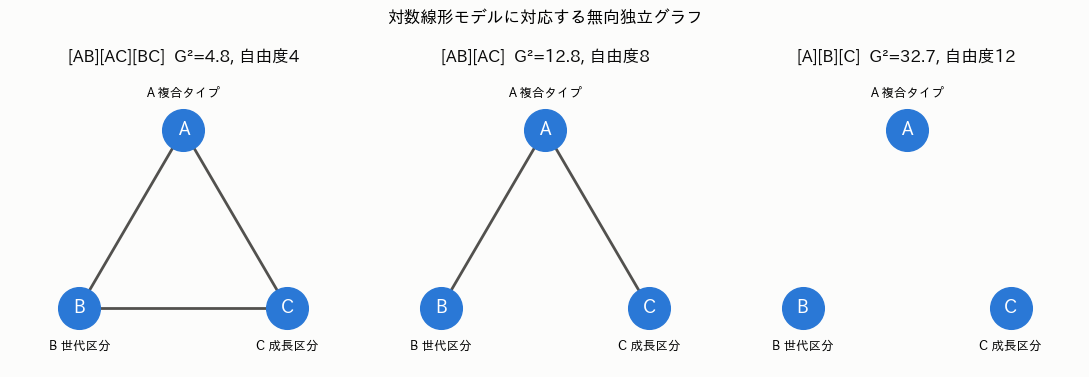

In [197]:
# 無向独立グラフ: 2因子交互作用があれば辺を引く
graph_models = ["[AB][AC][BC]", "[AB][AC]", "[A][B][C]"]
node_pos = {"A": (0, 1), "B": (-0.9, -0.5), "C": (0.9, -0.5)}
node_name = {"A": "A 複合タイプ", "B": "B 世代区分", "C": "C 成長区分"}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, mname in zip(axes, graph_models):
    gens = [g for g in mname.strip("[]").split("][")]
    edges = {tuple(sorted((u, v))) for g in gens for u in g for v in g if u < v}
    for u, v in edges:
        (x0, y0), (x1, y1) = node_pos[u], node_pos[v]
        ax.plot([x0, x1], [y0, y1], color=INK["secondary"], lw=2, zorder=1)
    for k, (x, y) in node_pos.items():
        ax.scatter(x, y, s=900, color=PALETTE[0], zorder=2)
        ax.text(x, y, k, ha="center", va="center", color="white", fontsize=13, fontweight="bold", zorder=3)
        ax.text(x, y - 0.32 if y < 0 else y + 0.3, node_name[k], ha="center", va="center", fontsize=9)
    ax.set(title=f"{mname}  G²={fits3[mname].deviance:.1f}, 自由度{fits3[mname].df_resid:.0f}",
           xlim=(-1.5, 1.5), ylim=(-1.0, 1.5))
    ax.axis("off")
fig.suptitle("対数線形モデルに対応する無向独立グラフ", fontweight="bold")
fig.tight_layout()
plt.show()

**結果の読み方**
- 左の三角形は $[AB][AC][BC]$（グラフとしては飽和モデルと区別できない）、中央の B–A–C は選んだ $[AB][AC]$、右の辺なしは完全独立 $[A][B][C]$ である。
- 中央のグラフで B と C の間に辺がなく、A がそれを「分離」していることが、$B\perp C\mid A$ を表している。

### まとめ

- 合計種族値570以上のポケモンは性別不明になりやすく、相対リスク約12・オッズ比約30と強い関連がある。リスクが大きいので OR と RR は大きく異なる。
- 結果で抽出するケースコントロール型のデザインでは相対リスクは推定できず、オッズ比だけが母集団の値を保つことをシミュレーションで確かめた。
- タイプ1の構成と世代の関連は、水準をまとめた表では有意でなかった（$V\approx0.10$）。$\chi^2$ 近似を使う前に期待度数を確認し、必要なら水準をまとめる・正確検定を使う。
- 複合タイプか・世代・成長区分の3元表では、条件付き独立モデル $[AB][AC]$（複合タイプを固定すれば世代と成長区分は独立）が選ばれた。分解可能モデルでは期待度数が周辺度数から直接計算できる。
- 限界：同じ進化系統の行は独立でないため検定はやや楽観的になる。水準のまとめ方や二値化の境界（570）は分析者の選択で、結論がそれに依存しうる。

## 第29章 不完全データの統計処理

### 章の概要

データの一部が観測されないとき、観測された部分だけで素朴に計算すると、推定に偏りが生じたり精度を過大評価したりする。
この章では、欠測の型（打ち切り・トランケーション）と欠測メカニズム（MCAR・MAR・MNAR）を区別し、CC解析・単一代入法・多重代入法・最尤法（EMアルゴリズム）を比べる。
ポケモンのデータには本来の欠測がほとんどないので、**完全なデータから人工的に欠測を作り**、真値がわかった状態で各手法の偏りと標準誤差を確かめる（第32章のシミュレーションの考え方）。
最尤法の部分は第8章の最尤推定、代入法の部分は第16章の回帰分析を使う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 29.1 | 打ち切りとトランケーション | 捕獲率の上限255は、どちらの型の欠測にあたるか |
| 29.2 | 1変量正規分布での推測 | 素早が100以上の値を観測できないとき、平均をどう推定するか |
| 29.3 | 欠測メカニズム | 雄率の欠損は代入すべきか。人工的な欠測の3つのメカニズムの違いは |
| 29.4 | CC解析・単一代入・多重代入 | 攻撃が欠測したデータで、各手法の推定値と標準誤差はどう違うか |
| 29.5〜29.6 | 反復シミュレーション | 手法ごとの偏り・標準誤差・信頼区間の被覆率は |
| 29.7 | 2変量正規分布での最尤推定・EM | 攻撃だけが欠測するとき、素早の情報で平均の偏りを直せるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `攻撃` | 量的 | 人工的に欠測させる変数（29.4〜29.7） |
| `素早` | 量的 | MAR の欠測の原因となる完全観測の変数。29.2 では打ち切る変数 |
| `防御`, `HP` | 量的 | 代入モデルの説明変数（攻撃との相関0.44, 0.42） |
| `捕獲率` | 量的（3〜255） | 値域の上限をもつ変数の例（29.1） |
| `雄率`, `性別` | 量的／質的 | 構造的な欠損の例（29.3） |

- **対象の行**：全920行。29.4〜29.6 ではこの920匹を**真値既知の母集団**とみなし、そこから $n=300$ を復元抽出した標本で推定する
- **加工**：欠測は乱数（`get_rng()`）で人工的に作る。平均欠測率はいずれも約20%にそろえる
- **データの性質と注意点**：攻撃・素早は正規分布に近いが厳密ではない（右裾がやや長い）。正規分布を仮定する手法（29.2, 29.7）では、そのずれが推定値にも現れる

（→ py 29-0：使う列の要約と、捕獲率の端の値・雄率の欠損数）

In [198]:
from scipy import optimize
from scipy.special import expit

miss_cols = ["攻撃", "素早", "防御", "HP", "捕獲率", "雄率"]
print(df[miss_cols].describe().T[["count", "mean", "std", "min", "max"]].round(1))
print(f"\n捕獲率 = 255（上限）の行: {(df['捕獲率'] == 255).sum()} 匹, 捕獲率 = 3（下限）の行: {(df['捕獲率'] == 3).sum()} 匹")
print(f"雄率の欠損: {df['雄率'].isna().sum()} 行")

     count  mean   std  min    max
攻撃   920.0  80.1  32.5  5.0  190.0
素早   920.0  68.6  29.4  5.0  180.0
防御   920.0  74.6  31.2  5.0  230.0
HP   920.0  69.6  26.0  1.0  255.0
捕獲率  920.0  94.0  75.6  3.0  255.0
雄率   790.0   0.5   0.2  0.0    1.0

捕獲率 = 255（上限）の行: 78 匹, 捕獲率 = 3（下限）の行: 76 匹
雄率の欠損: 130 行


### 29.1 打ち切りとトランケーション

**問い**：捕獲率の上限255は、どちらの型の欠測にあたるか。

**手法の要点**
- **打ち切り（censoring）**：ある値以上（以下）であることはわかるが、値そのものは得られない。その個体がデータに含まれ、打ち切られた個数はわかる（例: 期間を決めた寿命試験で、終了時に壊れていない製品）。
- **トランケーション（truncation）**：ある範囲の値しか観測されず、範囲外の個体はデータに現れない。範囲外の個数もわからない（例: 一定の重さ以上の個体だけが網にかかる調査）。
- 捕獲率はゲームの仕様で3〜255の整数をとる。255の値は「測れなかった値」ではなく実際の値なので、統計的な欠測ではない。ただし、背後に「どれだけ捕まえやすいか」という潜在的な量を考え、255がその上限で頭打ちになっていると解釈するなら、255の78匹は「255以上」とだけわかる**打ち切り**に近い。
- もし「捕獲率255のポケモンを除いたデータ」だけが手元にあり、除かれた数もわからなければ、それは**トランケーション**になる。

（→ py 29-1：捕獲率の分布）

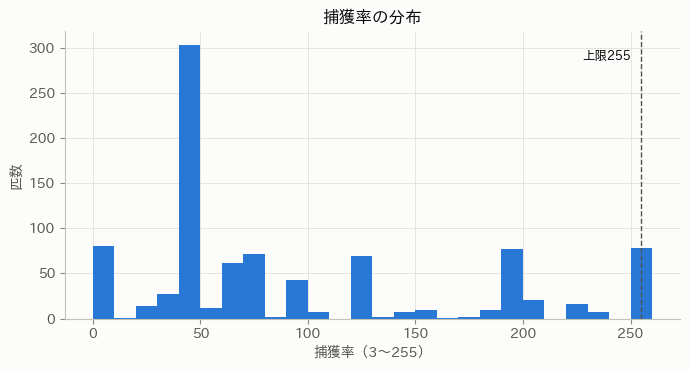

In [199]:
# 捕獲率の分布: 値域の上限255と下限3に度数が集中する
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(df["捕獲率"], bins=np.arange(0, 265, 10), color=PALETTE[0])
ax.axvline(255, color=INK["secondary"], lw=1, ls="--")
ax.text(250, ax.get_ylim()[1] * 0.9, "上限255", ha="right", fontsize=9)
ax.set(title="捕獲率の分布", xlabel="捕獲率（3〜255）", ylabel="匹数")
fig.tight_layout()
plt.show()

**結果の読み方**
- 捕獲率は45（303匹）、255（78匹）、3（76匹）、190（77匹）などの決まった値に集中している。下限3・上限255にまとまった度数があるが、分布の裾が切れて積み上がった形というより、仕様上の典型値（伝説・幻は3、序盤の小さなポケモンは255など）が選ばれている形である。
- したがって捕獲率を解析するときに打ち切りの補正をする必要はない。打ち切り・トランケーションの推測は、次節で素早に人工的な欠測を作って確かめる。

### 29.2 1変量正規分布における推測（打ち切り・トランケーション）

**問い**：素早が $c=100$ 以上の値を観測できないとき、母平均 $\mu$ をどう推定するか（母分散 $\sigma^2$ は既知とする）。

**手法の要点**
- $X\sim N(\mu,\sigma^2)$、$a=(c-\mu)/\sigma$、標準正規分布の密度を $\phi$、分布関数を $\Phi$ とすると
$$
E[X\mid X\ge c]=\mu+\sigma\frac{\phi(a)}{1-\Phi(a)},\qquad E[X\mid X<c]=\mu-\sigma\frac{\phi(a)}{\Phi(a)}
$$
- 観測値を $x_1,\dots,x_m$（いずれも $c$ 未満）、全体の大きさを $n$ とする。観測値の平均 $\bar x_m$ は $c$ 以上の値を含まないので、$\mu$ を過小に推定する。
- **打ち切り**（$c$ 以上の個数 $n-m$ はわかる）：EMアルゴリズム。$\mu^{(0)}=\bar x_m$ から始め、$a^{(t)}=(c-\mu^{(t)})/\sigma$ として
$$
\mu^{(t+1)}=\frac1n\left[\sum_{i=1}^m x_i+(n-m)\left\{\mu^{(t)}+\sigma\frac{\phi(a^{(t)})}{1-\Phi(a^{(t)})}\right\}\right]
$$
をくり返す。欠測値を「今の $\mu$ のもとでの条件付き期待値」で置き換えて平均をとる、という形である。
- **トランケーション**（$c$ 以上の個数もわからない）：観測値は $c$ 未満に切断された正規分布に従う。対数尤度 $\sum_i\log\phi((x_i-\mu)/\sigma)-m\log\Phi(a)$ を $\mu$ で微分して0とおくと $\bar x_m=E[X\mid X<c]$ となるので
$$
\mu^{(t+1)}=\bar x_m+\sigma\frac{\phi(a^{(t)})}{\Phi(a^{(t)})}
$$
をくり返す。
- どちらも対数尤度の直接最大化（scipy）と一致するはずである。ここでは $\sigma$ に全データの標準偏差を使う。

（→ py 29-2：2つの反復の実行、直接最大化との照合、反復の様子）

真の平均 68.55, 既知とする σ = 29.40
c = 100 未満が観測: m = 762, 欠測 n-m = 158, 観測値の平均 59.17

打ち切り:        反復 9 回で μ̂ = 68.768（直接最大化 68.768）
トランケーション: 反復 23 回で μ̂ = 66.036（直接最大化 66.036）


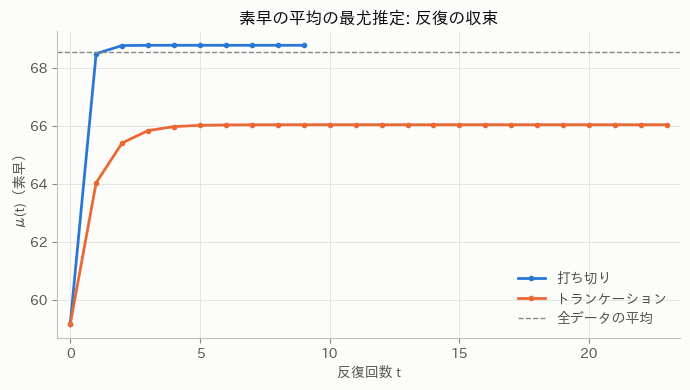

In [200]:
# 1変量正規分布の打ち切り・トランケーション: 素早を c = 100 で人工的に欠測させる
spe = df["素早"].to_numpy(float)
c_cut = 100.0
sigma_known = spe.std()            # 母分散は既知とする（全データの値）
mu_true = spe.mean()
obs_spe = spe[spe < c_cut]         # c 未満だけ値が観測される
n_all, m_obs = len(spe), len(obs_spe)
print(f"真の平均 {mu_true:.2f}, 既知とする σ = {sigma_known:.2f}")
print(f"c = {c_cut:.0f} 未満が観測: m = {m_obs}, 欠測 n-m = {n_all - m_obs}, 観測値の平均 {obs_spe.mean():.2f}")


def mle_censored(x_obs, n, c, sigma, tol=1e-10, max_iter=500):
    """打ち切り（c 以上は個数だけわかる）での μ の最尤推定（EM 反復）."""
    mu, path = x_obs.mean(), []
    for _ in range(max_iter):
        a = (c - mu) / sigma
        e_tail = mu + sigma * stats.norm.pdf(a) / stats.norm.sf(a)     # E[X | X >= c]
        mu_new = (x_obs.sum() + (n - len(x_obs)) * e_tail) / n
        path.append(mu_new)
        if abs(mu_new - mu) < tol:
            break
        mu = mu_new
    return mu_new, np.array(path)


def mle_truncated(x_obs, c, sigma, tol=1e-10, max_iter=5000):
    """トランケーション（c 以上は個数もわからない）での μ の最尤推定（不動点反復）."""
    mu, path, xbar = x_obs.mean(), [], x_obs.mean()
    for _ in range(max_iter):
        a = (c - mu) / sigma
        mu_new = xbar + sigma * stats.norm.pdf(a) / stats.norm.cdf(a)   # x̄ = E[X | X < c] を解く
        path.append(mu_new)
        if abs(mu_new - mu) < tol:
            break
        mu = mu_new
    return mu_new, np.array(path)


mu_cen, path_cen = mle_censored(obs_spe, n_all, c_cut, sigma_known)
mu_tru, path_tru = mle_truncated(obs_spe, c_cut, sigma_known)

# 対数尤度を直接最大化して照合
ll_cen = lambda mu: -(stats.norm.logpdf(obs_spe, mu, sigma_known).sum()
                      + (n_all - m_obs) * stats.norm.logsf(c_cut, mu, sigma_known))
ll_tru = lambda mu: -(stats.norm.logpdf(obs_spe, mu, sigma_known).sum()
                      - m_obs * stats.norm.logcdf(c_cut, mu, sigma_known))
opt_cen = optimize.minimize_scalar(ll_cen, bounds=(0, 200), method="bounded").x
opt_tru = optimize.minimize_scalar(ll_tru, bounds=(0, 200), method="bounded").x
print(f"\n打ち切り:        反復 {len(path_cen)} 回で μ̂ = {mu_cen:.3f}（直接最大化 {opt_cen:.3f}）")
print(f"トランケーション: 反復 {len(path_tru)} 回で μ̂ = {mu_tru:.3f}（直接最大化 {opt_tru:.3f}）")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(path_cen) + 1), np.r_[obs_spe.mean(), path_cen], marker="o", ms=3, label="打ち切り")
ax.plot(np.arange(len(path_tru) + 1), np.r_[obs_spe.mean(), path_tru], marker="o", ms=3, label="トランケーション")
ax.axhline(mu_true, color=INK["muted"], ls="--", lw=1, label="全データの平均")
ax.set(title="素早の平均の最尤推定: 反復の収束", xlabel="反復回数 t", ylabel="μ(t)（素早）",
       xlim=(-0.5, min(max(len(path_cen), len(path_tru)), 40) + 0.5))
ax.legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 素早100未満の762匹の平均は約59.2で、全体の平均68.55より約9低い。
- 打ち切りの最尤推定は9回の反復で約68.8に収束し、真値にかなり近い。欠測した158匹の「個数」の情報が効いている。
- トランケーションの最尤推定は約66.0で、観測値の平均よりは大きく補正されるが、真値には届かない。個数の情報がなく、分布の形（正規分布の仮定）だけに頼って裾を推測するため、素早の分布が正規分布からずれている影響をそのまま受ける。
- どちらも scipy による直接最大化と一致した。トランケーションのほうが収束が遅い（23回）のも、情報が少ないことの表れである。

### 29.3 欠測メカニズム

**問い**：雄率の欠損は代入の対象か。人工的に作った3つの欠測メカニズムは、観測されたデータにどう現れるか。

**手法の要点**
- 変数 $Y$ が欠測かどうかを $R$（1 = 欠測）、完全に観測される変数を $X$ とする。
  - **MCAR**（完全にランダムな欠測）：$P(R=1)$ が $X$ にも $Y$ にもよらない。
  - **MAR**（ランダムな欠測）：$P(R=1\mid X,Y)=P(R=1\mid X)$。観測された変数を与えれば、欠測は $Y$ の値によらない。
  - **MNAR**（ランダムでない欠測）：欠測が $Y$ の値そのもの（観測されない値）に依存する。
- `雄率` の欠損130行は `性別` が「不明」の行と完全に一致する。性別がないポケモンでは雄の割合という量が**そもそも定義されない**ので、これは値が隠れている欠測ではなく構造的な欠損である。代入して「本当の雄率」を作ることには意味がなく、解析では「性別不明」という区分として扱う（第28章）。
- 人工的な欠測は、攻撃に対して平均20%で次のように作る（$z$ は標準化した値、$\beta_0$ は平均欠測率が0.2になるよう数値的に決める）。
  - MCAR：確率0.2で欠測
  - MAR：$P(R=1)=\mathrm{logit}^{-1}(\beta_0+1.5\,z_{\text{素早}})$（速いポケモンほど攻撃が欠測）
  - MNAR：$P(R=1)=\mathrm{logit}^{-1}(\beta_0+1.5\,z_{\text{攻撃}})$（攻撃が高いほど欠測）
- 欠測群と観測群で $X$（素早）を比べれば、MCAR でないこと（MCAR からのずれ）は検出できる（差がなくても MCAR とは確定できない）。しかし MAR と MNAR は、観測されない $Y$ の値に関する仮定の違いなので、データからは区別できない。

（→ py 29-3：雄率の欠損と性別の対応、3つのメカニズムでの観測値の平均と素早の比較）

In [201]:
# 雄率の欠損は「性別不明」と完全に一致する構造的欠損
print(pd.crosstab(df["性別"], df["雄率"].isna().rename("雄率が欠損")))

# 人工的な欠測: 攻撃を平均20%欠測させる 3 つのメカニズム
def make_missing(data, mech, rng, rate=0.2, slope=1.5):
    """攻撃を欠測させる指標（True = 欠測）を返す."""
    n = len(data)
    if mech == "MCAR":
        return rng.random(n) < rate
    z_src = data["素早"] if mech == "MAR" else data["攻撃"]      # MNAR は欠測する値そのものに依存
    z = ((z_src - z_src.mean()) / z_src.std()).to_numpy()
    b0 = optimize.brentq(lambda b: expit(b + slope * z).mean() - rate, -10, 10)   # 平均欠測率を rate に合わせる
    return rng.random(n) < expit(b0 + slope * z)


rng_demo = get_rng()
mech_list = ["MCAR", "MAR", "MNAR"]
demo_rows = []
for mech in mech_list:
    r_miss = make_missing(df, mech, rng_demo)
    demo_rows.append({
        "メカニズム": mech, "欠測率": r_miss.mean(),
        "観測された攻撃の平均": df.loc[~r_miss, "攻撃"].mean(),
        "素早の平均(欠測群)": df.loc[r_miss, "素早"].mean(),
        "素早の平均(観測群)": df.loc[~r_miss, "素早"].mean(),
        "素早の差のt検定 p値": stats.ttest_ind(df.loc[r_miss, "素早"], df.loc[~r_miss, "素早"]).pvalue,
    })
print(f"\n全データの攻撃の平均（真値）: {df['攻撃'].mean():.2f}")
pd.DataFrame(demo_rows).set_index("メカニズム").round(3)

雄率が欠損  False  True 
性別                 
1:1      565      0
1:3       27      0
1:7        4      0
3:1       15      0
7:1      123      0
♀         32      0
♂         24      0
不明         0    130

全データの攻撃の平均（真値）: 80.07


,欠測率,観測された攻撃の平均,素早の平均(欠測群),素早の平均(観測群),素早の差のt検定 p値
メカニズム,,,,,
MCAR,0.220,80.565,68.059,68.688,0.789
MAR,0.197,76.670,100.039,60.838,0.000
MNAR,0.190,71.796,78.006,66.329,0.000


**結果の読み方**
- `雄率` が欠損しているのは性別「不明」の130行だけで、他の性別では欠損がない。
- MCAR では観測された攻撃の平均（約80.6）は真値80.07に近く、欠測群と観測群の素早に差はない（$t$ 検定 $p\approx0.79$）。
- MAR では欠測群の素早の平均が約100と観測群（約61）よりずっと大きく（$p<0.001$）、MCAR でないことがデータからわかる。観測された攻撃の平均は約76.7に下がる。
- MNAR でも素早に差が出る（攻撃と素早が相関するため）。観測された攻撃の平均は約71.8とさらに下がるが、この表だけでは MAR と見分けられない。

### 29.4 CC解析・単一代入法・多重代入法

**問い**：攻撃が MAR で欠測した1組のデータ（$n=300$）で、攻撃の平均 $\mu$ と回帰 攻撃 $=\beta_0+\beta_1$ 素早 の傾き $\beta_1$ を各手法で推定すると、推定値と標準誤差はどう違うか。

**手法の要点**
- **CC解析**：欠測を含む行を除いて解析する。MCAR なら偏りはないが、標本が減って精度が落ちる。MAR では一般に偏る（ただし、欠測が説明変数だけに依存するときの回帰係数は偏らない）。
- **単一代入法**（欠測値を1つの値で埋め、完全データとして解析する）
  - **平均値代入**：観測値の平均で埋める。分散と相関を過小にし、傾きを0の方向に縮める。
  - **回帰代入**：観測された行で $Y$ を $X$（ここでは素早・防御・HP）に回帰し、予測値で埋める。MAR で平均の偏りは直せるが、埋めた値が回帰直線上に並ぶためばらつきが小さすぎる。
  - **確率的回帰代入**：予測値に残差分散の正規乱数を加える。ばらつきは戻るが、埋めた値を観測値と同じように扱うので標準誤差は小さすぎる。
- **多重代入法**：回帰係数と残差分散の不確実性も反映して（$\sigma^{*2}=\hat\sigma^2(m-p)/\chi^2_{m-p}$、$\gamma^*\sim N(\hat\gamma,\sigma^{*2}(Z^\top Z)^{-1})$ を引き直して。$m$ は攻撃が観測された行数、$Z$ はその行の代入モデルの計画行列（切片・素早・防御・HP）、$p$ はその列数、$\chi^2_{m-p}$ は自由度 $m-p$ のカイ二乗分布からの乱数、$\hat\gamma,\hat\sigma^2$ は観測された行での回帰係数と残差分散の不偏推定値）代入を $M$ 回行い、それぞれで推定値 $\hat Q_\ell$ と分散 $U_\ell$ を得て**ルービンのルール**で統合する。
$$
\bar Q=\frac1M\sum_{\ell=1}^M\hat Q_\ell,\quad \bar W=\frac1M\sum_{\ell}U_\ell,\quad B=\frac1{M-1}\sum_{\ell}(\hat Q_\ell-\bar Q)^2,\quad T=\bar W+\left(1+\frac1M\right)B
$$
  $\bar W$ は代入内分散、$B$ は代入間分散（欠測による不確実性）で、$\sqrt T$ を標準誤差とする。区間推定には自由度 $\nu=(M-1)\{1+1/r\}^2$、$r=(1+1/M)B/\bar W$ の $t$ 分布を使う。$(1+1/M)B/T$ は欠測による情報の損失の割合の目安である。

（→ py 29-4：1組のデータでの比較。多重代入は $M=20$）

In [202]:
# 欠測への対処法を1組のデータで比較（MAR）。多重代入はルービンのルールで統合する
def ols(X, y):
    """最小二乗: 係数, 残差分散（自由度 n-p）, (X'X)^{-1}."""
    xtx_inv = np.linalg.inv(X.T @ X)
    beta = xtx_inv @ X.T @ y
    resid = y - X @ beta
    return beta, resid @ resid / (len(y) - X.shape[1]), xtx_inv


def estimate(y, x):
    """解析モデル: 攻撃の平均と、攻撃 = b0 + b1 素早 の傾き。(推定値, 標準誤差) を返す."""
    n = len(y)
    X = np.column_stack([np.ones(n), x])
    beta, s2, xtx_inv = ols(X, y)
    return np.array([y.mean(), beta[1]]), np.array([y.std(ddof=1) / np.sqrt(n), np.sqrt(s2 * xtx_inv[1, 1])])


def rubin(q_list, u_list):
    """ルービンのルール: 推定値, 全分散の平方根, 自由度, 欠測情報の割合の近似."""
    q, u = np.asarray(q_list), np.asarray(u_list)
    M = len(q)
    q_bar = q.mean(0)
    w_bar = u.mean(0)                        # 代入内分散
    b_var = q.var(0, ddof=1)                 # 代入間分散
    t_var = w_bar + (1 + 1 / M) * b_var      # 全分散
    r_inc = (1 + 1 / M) * b_var / w_bar
    nu = (M - 1) * (1 + 1 / r_inc) ** 2      # 自由度
    return q_bar, np.sqrt(t_var), nu, (1 + 1 / M) * b_var / t_var


def run_methods(data, miss, rng, n_imp=20):
    """各手法で (推定値, SE, 自由度) を返す。自由度 np.inf は正規近似."""
    y_full, x_ana = data["攻撃"].to_numpy(float), data["素早"].to_numpy(float)
    Z = np.column_stack([np.ones(len(data)), data[["素早", "防御", "HP"]].to_numpy(float)])   # 代入モデルの説明変数
    obs = ~miss
    out = {"完全データ": (*estimate(y_full, x_ana), np.inf),
           "CC解析": (*estimate(y_full[obs], x_ana[obs]), np.inf)}
    y_mean = y_full.copy(); y_mean[miss] = y_full[obs].mean()
    out["平均値代入"] = (*estimate(y_mean, x_ana), np.inf)
    g, s2, zz_inv = ols(Z[obs], y_full[obs])
    y_reg = y_full.copy(); y_reg[miss] = Z[miss] @ g
    out["回帰代入"] = (*estimate(y_reg, x_ana), np.inf)
    y_sto = y_reg.copy(); y_sto[miss] += rng.normal(0, np.sqrt(s2), miss.sum())
    out["確率的回帰代入"] = (*estimate(y_sto, x_ana), np.inf)
    # 多重代入: パラメータの不確実性も反映する（σ² と係数を事後分布から引き直す）
    dof_imp = obs.sum() - Z.shape[1]
    L = np.linalg.cholesky(zz_inv)
    q_list, u_list = [], []
    for _ in range(n_imp):
        s2_star = s2 * dof_imp / rng.chisquare(dof_imp)
        g_star = g + np.sqrt(s2_star) * L @ rng.standard_normal(Z.shape[1])
        y_imp = y_full.copy()
        y_imp[miss] = Z[miss] @ g_star + rng.normal(0, np.sqrt(s2_star), miss.sum())
        est, se = estimate(y_imp, x_ana)
        q_list.append(est); u_list.append(se ** 2)
    q_bar, t_se, nu, lam = rubin(q_list, u_list)
    out["多重代入"] = (q_bar, t_se, nu)
    return out, lam


rng_one = get_rng()
samp_one = df.iloc[rng_one.choice(len(df), 300, replace=True)].reset_index(drop=True)
miss_one = make_missing(samp_one, "MAR", rng_one)
res_one, lam_one = run_methods(samp_one, miss_one, rng_one)
one_table = pd.DataFrame({
    "平均 推定値": [v[0][0] for v in res_one.values()], "平均 SE": [v[1][0] for v in res_one.values()],
    "傾き 推定値": [v[0][1] for v in res_one.values()], "傾き SE": [v[1][1] for v in res_one.values()],
}, index=res_one.keys())
print(f"n = 300（復元抽出）, 欠測 {miss_one.sum()} 行（MAR）")
print(f"多重代入（M = 20）の欠測情報の割合の近似: 平均 {lam_one[0]:.2f}, 傾き {lam_one[1]:.2f}")
one_table.round(3)

n = 300（復元抽出）, 欠測 63 行（MAR）
多重代入（M = 20）の欠測情報の割合の近似: 平均 0.12, 傾き 0.19


,平均 推定値,平均 SE,傾き 推定値,傾き SE
完全データ,80.330,1.844,0.351,0.060
CC解析,78.173,1.972,0.325,0.074
平均値代入,78.173,1.557,0.197,0.052
回帰代入,80.190,1.633,0.302,0.053
確率的回帰代入,80.706,1.759,0.307,0.058
多重代入,80.071,1.885,0.301,0.064


**結果の読み方**
- この標本では63行（21%）が欠測した。CC解析と平均値代入の平均はどちらも約78.2で、完全データ（約80.3）より低い。平均値代入の標準誤差（約1.56）は完全データ（約1.84）より小さく、欠測があるのに精度が上がったかのように見える。
- 平均値代入の傾きは約0.20と、完全データ（約0.35）より大きく縮んでいる。回帰代入・確率的回帰代入・多重代入の平均は約80〜81で、平均の偏りが直っている。
- 多重代入の標準誤差（平均で約1.89）は単一代入より大きく、欠測による不確実性を反映している。欠測情報の割合は平均で約0.12、傾きで約0.19。1組だけでは偶然の影響が大きいので、次節でくり返して確かめる。

### 29.5 反復シミュレーション

**問い**：欠測メカニズム（MCAR・MAR・MNAR）ごとに、各手法の偏り・標準誤差・95%信頼区間の被覆率はどうなるか。

**手法の要点**
- 920匹を母集団とし、真値は母集団の攻撃の平均と、母集団全体で求めた攻撃〜素早の回帰の傾きとする。
- 1回の試行：母集団から $n=300$ を復元抽出 → 攻撃を約20%欠測させる → 6つの方法（比較用の完全データを含む）で推定する。これを各メカニズムで500回くり返す（多重代入は $M=10$）。
- 復元抽出にするのは、標本が母集団（経験分布）からの独立同一分布の標本になり、通常の標準誤差の式がそのまま使えるようにするためである。
- 評価指標：偏り（推定値の平均 − 真値）、推定値のSD（実際のばらつき）、SEの平均（手法が報告する標準誤差）、被覆率（95%信頼区間が真値を含む割合）。**SEの平均が推定値のSDより小さい手法は精度を過大評価している**。

（→ py 29-5：シミュレーションと集計表）

In [203]:
# 反復シミュレーション: 母集団（920匹）から n = 300 を復元抽出 → 欠測 → 各手法で推定
X_pop = np.column_stack([np.ones(len(df)), df["素早"]])
true_vals = np.array([df["攻撃"].mean(), np.linalg.lstsq(X_pop, df["攻撃"].to_numpy(float), rcond=None)[0][1]])
print(f"真値: 攻撃の平均 {true_vals[0]:.3f}, 攻撃〜素早の傾き {true_vals[1]:.4f}")

rng_sim = get_rng()
n_sim, n_samp = 500, 300
sim_rows = []
for mech in mech_list:
    for _ in range(n_sim):
        samp = df.iloc[rng_sim.choice(len(df), n_samp, replace=True)].reset_index(drop=True)
        res, _ = run_methods(samp, make_missing(samp, mech, rng_sim), rng_sim, n_imp=10)
        for meth, (est, se, nu) in res.items():
            crit = stats.t.ppf(0.975, nu) if np.all(np.isfinite(nu)) else stats.norm.ppf(0.975)
            for k, target in enumerate(["平均", "傾き"]):
                c_k = crit[k] if np.ndim(crit) else crit
                sim_rows.append((mech, meth, target, est[k], se[k], abs(est[k] - true_vals[k]) <= c_k * se[k]))
sim_df = pd.DataFrame(sim_rows, columns=["メカニズム", "手法", "推定対象", "推定値", "SE", "被覆"])
truth_map = dict(zip(["平均", "傾き"], true_vals))
sim_df["偏り"] = sim_df["推定値"] - sim_df["推定対象"].map(truth_map)
method_order = list(res.keys())
sim_df["推定対象"] = pd.Categorical(sim_df["推定対象"], ["平均", "傾き"])
sim_df["メカニズム"] = pd.Categorical(sim_df["メカニズム"], mech_list)
sim_df["手法"] = pd.Categorical(sim_df["手法"], method_order)
sim_summary = (sim_df.groupby(["推定対象", "メカニズム", "手法"], observed=True)
               .agg(偏り=("偏り", "mean"), 推定値のSD=("推定値", "std"), SEの平均=("SE", "mean"), 被覆率=("被覆", "mean")))
sim_summary.round(3)

真値: 攻撃の平均 80.070, 攻撃〜素早の傾き 0.4077


偏り  推定値のSD  SEの平均    被覆率
推定対象 メカニズム 手法                                  
平均   MCAR  完全データ   -0.104   1.862  1.876  0.948
           CC解析    -0.049   2.078  2.095  0.948
           平均値代入   -0.049   2.078  1.678  0.888
           回帰代入    -0.023   1.974  1.766  0.912
           確率的回帰代入  0.009   2.062  1.878  0.922
           多重代入    -0.031   1.992  2.022  0.942
     MAR   完全データ    0.001   1.868  1.879  0.950
           CC解析    -2.909   2.081  2.038  0.680
           平均値代入   -2.909   2.081  1.632  0.536
           回帰代入    -0.039   2.136  1.733  0.878
           確率的回帰代入 -0.030   2.182  1.841  0.908
           多重代入    -0.034   2.128  2.032  0.938
     MNAR  完全データ    0.115   1.885  1.873  0.960
           CC解析    -8.024   2.073  1.755  0.014
           平均値代入   -8.024   2.073  1.403  0.008
           回帰代入    -5.423   2.033  1.492  0.108
           確率的回帰代入 -5.384   2.083  1.593  0.148
           多重代入    -5.419   2.054  1.741  0.170
傾き   MCAR  完全データ    0.001   0.061  0.060  0.944
           CC解析     0.001   0.069  0.067  0.952
           平均値代入   -0.081   0.058  0.054  0.680
           回帰代入     0.000   0.069  0.055  0.872
           確率的回帰代入 -0.000   0.073  0.060  0.886
           多重代入    -0.000   0.070  0.065  0.922
     MAR   完全データ    0.002   0.066  0.059  0.926
           CC解析     0.003   0.082  0.075  0.936
           平均値代入   -0.159   0.054  0.054  0.182
           回帰代入    -0.006   0.078  0.054  0.840
           確率的回帰代入 -0.005   0.083  0.058  0.842
           多重代入    -0.006   0.078  0.071  0.922
     MNAR  完全データ   -0.003   0.061  0.059  0.944
           CC解析    -0.098   0.060  0.058  0.598
           平均値代入   -0.172   0.049  0.046  0.056
           回帰代入    -0.093   0.059  0.047  0.510
           確率的回帰代入 -0.092   0.063  0.051  0.554
           多重代入    -0.093   0.060  0.057  0.630

（→ py 29-6：偏り ± 推定値のSD の図。点が0の線から離れるほど偏りが大きい）

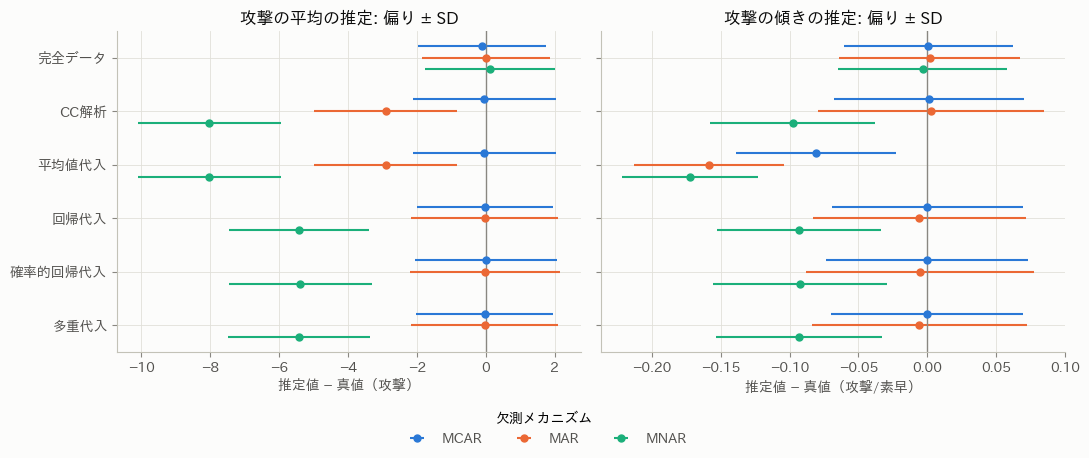

In [204]:
# シミュレーション結果の図: 偏り ± 推定値のSD
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
ypos = np.arange(len(method_order))
for ax, target, unit in zip(axes, ["平均", "傾き"], ["攻撃", "攻撃/素早"]):
    for j, mech in enumerate(mech_list):
        s = sim_summary.loc[(target, mech)].reindex(method_order)
        ax.errorbar(s["偏り"], ypos + (j - 1) * 0.22, xerr=s["推定値のSD"], fmt="o", ms=5,
                    color=PALETTE[j], capsize=0, lw=1.5, label=mech)
    ax.axvline(0, color=INK["muted"], lw=1)
    ax.set(title=f"攻撃の{target}の推定: 偏り ± SD", xlabel=f"推定値 − 真値（{unit}）")
    ax.set_yticks(ypos, method_order)
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="欠測メカニズム", loc="lower center", ncol=3)
fig.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

**結果の読み方**
- **MCAR**：CC解析は偏りがなく被覆率も約95%で、標本が減る分だけ SD が完全データより大きい。平均値代入は平均の偏りはないが SE が小さすぎ（被覆率約89%）、傾きは0の方向に縮む（被覆率約68%）。
- **MAR**：CC解析の平均は約−2.9の偏り（被覆率約68%）。一方、欠測が説明変数の素早だけに依存するので、CC解析の傾きは偏らない。回帰代入・確率的回帰代入は偏りを直すが、SE が実際のばらつきより小さく被覆率は84〜91%にとどまる。多重代入は偏りがほぼ0で、SE も実際のばらつきに近く、被覆率は約92〜94%である。平均値代入は平均・傾きとも最も悪い。
- **MNAR**：どの手法も平均が約−5〜−8、傾きも約−0.09以上偏り、被覆率は大きく下がる。代入法は素早などとの相関を通じて偏りを一部減らすが、観測されない値そのものに依存する欠測は、欠測メカニズムを別にモデル化しない限り直せない。
- 多重代入の傾きの被覆率（約92%）がやや95%を下回るのは、攻撃の残差が厳密な正規分布でなく分散も一様でないこと（完全データでも SD が SE を上回る）や、$M=10$ と少ないことが考えられる。

### 29.7 2変量正規分布における推測と EM アルゴリズム

**問い**：(素早, 攻撃) を2変量正規分布とみなし、攻撃だけが MAR で欠測するとき、最尤推定で平均の偏りを直せるか。閉形式の解と EM アルゴリズムの結果は一致するか。

**手法の要点**
- $(X,Y)^\top\sim N\!\left(\begin{pmatrix}\mu_X\\\mu_Y\end{pmatrix},\begin{pmatrix}\sigma_X^2&\sigma_{XY}\\\sigma_{XY}&\sigma_Y^2\end{pmatrix}\right)$。観測は $(x_1,y_1),\dots,(x_m,y_m),x_{m+1},\dots,x_n$。
- MAR のもとでは、尤度は「$X$ の周辺分布」と「$X$ を与えたときの $Y$ の条件付き分布 $N(\alpha+\beta x,\tau^2)$」に分かれ、次の閉形式の最尤推定が得られる（分母はいずれも標本の大きさ）。
  1. $\hat\mu_X=\frac1n\sum_{i=1}^n x_i$、$\hat\sigma_X^2=\frac1n\sum_{i=1}^n(x_i-\hat\mu_X)^2$（$n$ 個すべて使う）
  2. 観測された $m$ 組から $\bar x,\bar y,S_X^2,S_Y^2,S_{XY}$（分母 $m$）
  3. $\hat\beta=S_{XY}/S_X^2$、$\hat\alpha=\bar y-\hat\beta\bar x$、$\hat\tau^2=S_Y^2-\hat\beta^2S_X^2$
  4. $\hat\mu_Y=\hat\alpha+\hat\beta\hat\mu_X=\bar y+\hat\beta(\hat\mu_X-\bar x)$、$\hat\sigma_Y^2=\hat\tau^2+\hat\beta^2\hat\sigma_X^2$、$\hat\sigma_{XY}=\hat\beta\hat\sigma_X^2$
- $\hat\mu_Y$ は、観測された $Y$ の平均を「観測された行の $X$ の平均と全体の $X$ の平均のずれ」×傾きで補正したものである。
- **EMアルゴリズム**：十分統計量 $\sum y_i,\sum y_i^2,\sum x_iy_i$ の欠測部分を、今のパラメータのもとでの条件付き期待値 $E[y_i\mid x_i]=\alpha+\beta x_i$、$E[y_i^2\mid x_i]=(\alpha+\beta x_i)^2+\tau^2$ で置き換え（Eステップ）、完全データの最尤推定の式でパラメータを更新する（Mステップ）。観測データの対数尤度は反復ごとに減らず、収束先は上の閉形式に一致するはずである。
- ここでは920匹全体で、29.3 と同じ MAR（速いほど攻撃が欠測）の欠測を作る。

（→ py 29-7：閉形式と EM の比較、反復の様子）

n = 920, Y が観測された m = 718（MAR: 素早が大きいほど欠測しやすい）
EM は 50 回で収束。対数尤度は単調非減少: True
     全データ(真値)     CC解析   最尤(閉形式)    最尤(EM)
μY     80.070   76.362    79.491    79.491
σY²  1057.882  979.557  1016.295  1016.295
σXY   352.441  257.732   348.786   348.786


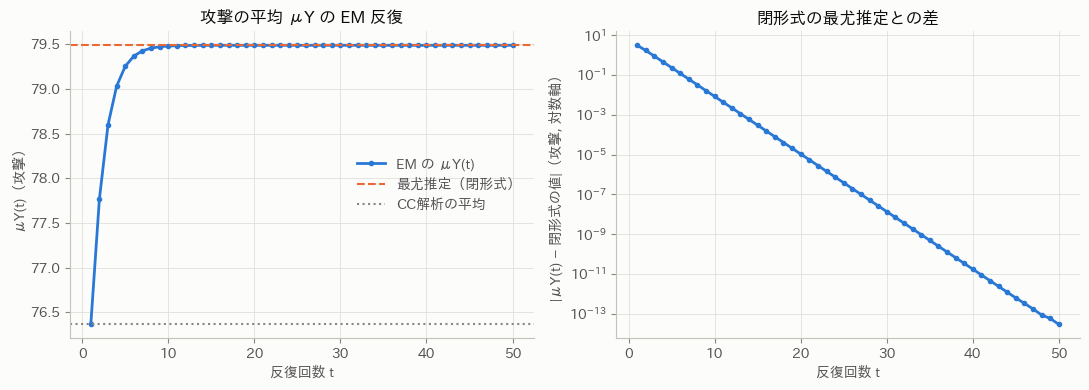

In [205]:
# 2変量正規分布で Y（攻撃）だけが MAR で欠測するときの最尤推定: 閉形式と EM アルゴリズム
rng_bv = get_rng()
x_bv = df["素早"].to_numpy(float)
y_bv = df["攻撃"].to_numpy(float)
miss_bv = make_missing(df, "MAR", rng_bv)
obs_bv = ~miss_bv
n_bv, m_bv = len(x_bv), obs_bv.sum()
xo, yo = x_bv[obs_bv], y_bv[obs_bv]

# 閉形式（最尤推定なので分母は n, m）
mu_x = x_bv.mean(); s2_x = x_bv.var()                       # ① X は n 個すべて使う
xbar_m, ybar_m = xo.mean(), yo.mean()                       # ② 観測された m 組
sxx_m, syy_m = xo.var(), yo.var()
sxy_m = np.mean((xo - xbar_m) * (yo - ybar_m))
beta_ml = sxy_m / sxx_m                                     # ③ Y|X ~ N(α + βx, τ²)
alpha_ml = ybar_m - beta_ml * xbar_m
tau2_ml = syy_m - beta_ml ** 2 * sxx_m
mu_y_ml = alpha_ml + beta_ml * mu_x                         # ④
s2_y_ml = tau2_ml + beta_ml ** 2 * s2_x
sxy_ml = beta_ml * s2_x


def em_bivariate(x, y, obs, n_iter=200, tol=1e-12):
    """Y のみ欠測する2変量正規分布の EM アルゴリズム。各反復の (μY, σY², σXY, 観測データ対数尤度)."""
    n = len(x)
    mu = np.array([x.mean(), y[obs].mean()])                # 初期値: CC の平均・分散（相関0）
    cov = np.diag([x.var(), y[obs].var()])
    hist = []
    for _ in range(n_iter):
        # E ステップ: 欠測した y の条件付き期待値 E[y|x], E[y²|x]
        b = cov[0, 1] / cov[0, 0]
        a = mu[1] - b * mu[0]
        t2 = cov[1, 1] - b * cov[0, 1]
        ey = np.where(obs, y, a + b * x)
        ey2 = np.where(obs, y ** 2, (a + b * x) ** 2 + t2)
        # M ステップ: 十分統計量の期待値から平均と共分散を更新
        mu_new = np.array([x.mean(), ey.mean()])
        cov_new = np.array([[np.mean(x ** 2), np.mean(x * ey)],
                            [np.mean(x * ey), np.mean(ey2)]]) - np.outer(mu_new, mu_new)
        # 観測データの対数尤度（x は周辺、観測された y は条件付き）
        b2 = cov_new[0, 1] / cov_new[0, 0]
        a2 = mu_new[1] - b2 * mu_new[0]
        t22 = cov_new[1, 1] - b2 * cov_new[0, 1]
        ll = (stats.norm.logpdf(x, mu_new[0], np.sqrt(cov_new[0, 0])).sum()
              + stats.norm.logpdf(y[obs], a2 + b2 * x[obs], np.sqrt(t22)).sum())
        hist.append((mu_new[1], cov_new[1, 1], cov_new[0, 1], ll))
        done = np.max(np.abs(mu_new - mu)) < tol and np.max(np.abs(cov_new - cov)) < tol
        mu, cov = mu_new, cov_new
        if done:
            break
    return np.array(hist)


em_hist = em_bivariate(x_bv, y_bv, obs_bv)
bv_table = pd.DataFrame({
    "全データ(真値)": [y_bv.mean(), y_bv.var(), np.mean((x_bv - x_bv.mean()) * (y_bv - y_bv.mean()))],
    "CC解析": [ybar_m, syy_m, sxy_m],
    "最尤(閉形式)": [mu_y_ml, s2_y_ml, sxy_ml],
    "最尤(EM)": em_hist[-1, :3],
}, index=["μY", "σY²", "σXY"])
print(f"n = {n_bv}, Y が観測された m = {m_bv}（MAR: 素早が大きいほど欠測しやすい）")
print(f"EM は {len(em_hist)} 回で収束。対数尤度は単調非減少: {np.all(np.diff(em_hist[:, 3]) >= -1e-8)}")
print(bv_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(em_hist) + 1), em_hist[:, 0], marker="o", ms=3, color=PALETTE[0], label="EM の μY(t)")
axes[0].axhline(mu_y_ml, color=PALETTE[1], ls="--", lw=1.5, label="最尤推定（閉形式）")
axes[0].axhline(ybar_m, color=INK["muted"], ls=":", lw=1.5, label="CC解析の平均")
axes[0].set(title="攻撃の平均 μY の EM 反復", xlabel="反復回数 t", ylabel="μY(t)（攻撃）")
axes[0].legend()
err = np.abs(em_hist[:, 0] - mu_y_ml)
axes[1].semilogy(np.arange(1, len(em_hist) + 1), np.maximum(err, 1e-14), marker="o", ms=3, color=PALETTE[0])
axes[1].set(title="閉形式の最尤推定との差", xlabel="反復回数 t", ylabel="|μY(t) − 閉形式の値|（攻撃, 対数軸）")
fig.tight_layout()
plt.show()

**結果の読み方**
- 攻撃が観測されたのは718匹。CC解析の平均は約76.4と真値80.07より低いが、最尤推定は約79.5で偏りの大部分が直った。共分散 $\sigma_{XY}$ も CC解析では約258と大きく過小だが、最尤推定では約349（真値約352）となった。
- EM は CC解析の値から出発し、50回で閉形式の値に $10^{-13}$ の精度で一致した。対数尤度は単調に増加した。
- 右図で誤差が対数軸上で直線的に減るのは、EM の収束が1次（線形）であることを示す。1回あたりの縮小率は欠測情報の割合に対応し、欠測が多いほど収束は遅くなる。
- 真値との差（約0.6）が残るのは、攻撃と素早の関係が厳密な2変量正規分布（線形・等分散）ではないことや、欠測の乱数による誤差のためである。

### まとめ

- 打ち切りは「欠測の個数」がわかり、トランケーションはそれもわからない。素早を100で切った例では、打ち切りの最尤推定は真値にほぼ戻ったが、トランケーションは正規分布の仮定に強く依存し、十分に戻らなかった。
- `雄率` の欠損は性別不明による構造的な欠損であり、代入の対象ではない。欠測を扱う前に「値が存在するが見えない」のか「値が定義されない」のかを区別する。
- 人工的な欠測のシミュレーションでは、MCAR ではCC解析で十分、MAR では回帰にもとづく代入や最尤法で偏りが直り、標準誤差まで正しく評価できたのは多重代入（ルービンのルール）だった。平均値代入は MCAR でも標準誤差と相関を歪める。
- MNAR はどの手法でも直せず、しかも MAR と観測データからは区別できない。実際の解析では欠測の理由を調べ、仮定を変えた感度分析を行うことが必要になる。
- 2変量正規分布の最尤推定は、完全に観測された変数の情報を使って欠測変数の平均・共分散を補正する。EM アルゴリズムはその数値解法で、閉形式の解と一致した。

## 第30章 モデル選択

### 章の概要

複数の候補モデルの中から、データに対して「ちょうどよい複雑さ」のモデルを選ぶ方法を扱う。
- 目的：あてはまり（尤度・残差平方和）だけで選ぶと、パラメータを増やすほど良く見えてしまう（過学習）。将来のデータに対する予測のよさでモデルを比べたい。
- 考え方：情報量規準（AIC・BIC）は最大対数尤度にパラメータ数の罰則を加える。交差検証は、推定に使っていないデータでの予測誤差を直接測る。
- つながり：第16章の重回帰・決定係数（自由度調整済み決定係数もモデル選択の一種）、正則化の $\lambda$ の選択、第18章の尤度・逸脱度、第19章のニューラルネットワークの評価で使った交差検証を、ここでまとめて扱う。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 30.1 | AIC・BIC の定義と計算 | 定義式の AIC・BIC は statsmodels の値と一致するか |
| 30.2 | 全部分集合による変数選択 | 経験値の予測に、10個の候補のどれを使えばよいか |
| 30.3 | 交差検証（k 分割・LOO・PRESS） | 選ばれたモデルは、予測誤差で見ても良いか |
| 30.4 | 過学習の例（多項式回帰） | 多項式の次数を上げると、訓練誤差と予測誤差はどう変わるか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `経験値` | 量的 | 30.1〜30.3 の目的変数 |
| `HP`〜`素早` | 量的 | 説明変数の候補（種族値6項目） |
| `捕獲率`, `log高さ`, `log重さ`, `孵化千` | 量的 | 説明変数の候補（孵化千 = 孵化歩数/1000）。log高さ・log重さ は 30.4 の多項式回帰の説明変数・目的変数にも使う |

- **対象の行**：30.1〜30.3 は全920行。30.4 は無作為に選んだ40匹を訓練データとし、残りをテストデータにする。
- **加工**：孵化歩数を1000歩単位にする。30.4 では数値的な安定のため、訓練データの平均・標準偏差で log高さ を標準化してから多項式を作る。
- **データの性質と注意点**：第16・17章で見たように、経験値の回帰の残差は裾が重く（ハピナスなど）、正規分布を仮定した AIC・BIC は近似である。30.4 では全ポケモンを「真の母集団」とみなし、訓練に使わなかったポケモンでの誤差を真の予測誤差の代わりに使う。

In [206]:
import itertools
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score

d30 = df.assign(孵化千=df["孵化"] / 1000)
cand30 = [*STATS, "捕獲率", "log高さ", "log重さ", "孵化千"]    # 説明変数の候補（10個）
y30 = d30["経験値"].to_numpy(float)
n30 = len(d30)
print(f"n = {n30}, 候補の説明変数 {len(cand30)} 個 → 部分集合 {2 ** len(cand30)} 通り（切片のみを含む）")
d30[["経験値", *cand30]].describe().T[["mean", "std", "min", "max"]].round(2)

n = 920, 候補の説明変数 10 個 → 部分集合 1024 通り（切片のみを含む）


,mean,std,min,max
経験値,153.66,79.14,36.00,608.00
HP,69.56,26.03,1.00,255.00
攻撃,80.07,32.54,5.00,190.00
防御,74.56,31.22,5.00,230.00
特攻,73.32,33.22,10.00,194.00
特防,72.40,27.90,20.00,230.00
素早,68.55,29.42,5.00,180.00
捕獲率,93.98,75.55,3.00,255.00
log高さ,-0.06,0.74,-2.30,2.67
log重さ,3.21,1.59,-2.30,6.91


### 30.1 AIC と BIC

**問い**：定義式から計算した AIC・BIC は、statsmodels の値と一致するか。

**手法の要点**
- 最大対数尤度を $\ell(\hat\theta)$、推定するパラメータの数を $k$、サンプルサイズを $n$ として
$$\mathrm{AIC}=-2\ell(\hat\theta)+2k,\qquad \mathrm{BIC}=-2\ell(\hat\theta)+k\log n .$$
  値が小さいモデルほど良いとする。
- 誤差が $N(0,\sigma^2)$ に従う説明変数 $p$ 個の重回帰では、$\sigma^2$ の最尤推定量 $\hat\sigma^2=\mathrm{RSS}/n$（不偏推定量 $\mathrm{RSS}/(n-p-1)$ ではない）を使って
$$\ell(\hat\theta)=-\frac n2\left\{\log(2\pi\hat\sigma^2)+1\right\},\qquad k=p+2\ (\text{係数}\ p\ \text{個}+\text{切片}+\sigma^2).$$
  よって $\mathrm{AIC}=n\log(2\pi\hat\sigma^2)+n+2(p+2)$。
- AIC は将来のデータに対する予測のよさ（期待平均対数尤度）を近似的に最大にするモデルを選ぶ。BIC は $n\ge8$ なら $\log n>2$ で罰則が強く、より小さいモデルを選びやすい。候補に真のモデルが含まれていれば、$n\to\infty$ で BIC が真のモデルを選ぶ確率は1に近づく（一致性）が、AIC にはこの性質がない。

（→ py 30-1：経験値 ~ 種族値6項目 の AIC・BIC を定義式で計算し、statsmodels と比べる）

In [207]:
# AIC・BIC を定義式から計算する（誤差の正規性を仮定した重回帰）
# 最大対数尤度 logL = -n/2 {log(2π σ̂²) + 1}, σ̂² = RSS/n（最尤推定量）
# パラメータ数 k = 説明変数の数 p + 切片 1 + 誤差分散 1 = p + 2
def aic_bic(rss, n, p):
    ll = -n / 2 * (np.log(2 * np.pi * rss / n) + 1)
    k = p + 2
    return ll, -2 * ll + 2 * k, -2 * ll + np.log(n) * k


ols30 = sm.OLS(y30, sm.add_constant(d30[STATS])).fit()
ll_h, aic_h, bic_h = aic_bic(ols30.ssr, n30, len(STATS))
print(f"最大対数尤度: 手計算 {ll_h:.3f}, statsmodels {ols30.llf:.3f}")
print(f"AIC: 手計算 {aic_h:.3f}, statsmodels {ols30.aic:.3f}（差 {aic_h - ols30.aic:.1f}）")
print(f"BIC: 手計算 {bic_h:.3f}, statsmodels {ols30.bic:.3f}（差 {bic_h - ols30.bic:.3f} = log n = {np.log(n30):.3f}）")
print("→ statsmodels は誤差分散をパラメータ数に数えない（k = p + 1）。モデル間の差は同じなので選択結果は変わらない")

最大対数尤度: 手計算 -4399.266, statsmodels -4399.266
AIC: 手計算 8814.532, statsmodels 8812.532（差 2.0）
BIC: 手計算 8853.127, statsmodels 8846.303（差 6.824 = log n = 6.824）
→ statsmodels は誤差分散をパラメータ数に数えない（k = p + 1）。モデル間の差は同じなので選択結果は変わらない


**結果の読み方**
- 最大対数尤度は一致するが、AIC は手計算のほうがちょうど2、BIC はちょうど $\log n\approx6.82$ 大きい。statsmodels は誤差分散 $\sigma^2$ をパラメータ数に数えない（$k=p+1$）ためである。
- この差はどのモデルでも同じ定数なので、同じデータ・同じ分布の仮定のもとで比べる限り、選ばれるモデルは変わらない。異なるソフトの値を混ぜて比べるときには注意する。

### 30.2 全部分集合による変数選択

**問い**：経験値を予測するのに、10個の候補（種族値6項目・捕獲率・log高さ・log重さ・孵化歩数）のどれを使えばよいか。

**手法の要点**
- **全部分集合選択**：候補 $m$ 個のすべての部分集合（$2^m$ 通り）についてモデルをあてはめ、規準が最小のものを選ぶ。$m=10$ なら1024通りで計算できるが、$m$ が大きいと不可能になる。
- **逐次選択**（変数増加法・変数減少法・ステップワイズ法）は、1つずつ変数を加える・除くことで AIC などを下げていく近似的な方法で、全部分集合の最良モデルを見つける保証はない。
- 自由度調整済み決定係数 $R^{*2}$ の最大化も規準の一つだが、罰則が弱く大きいモデルを選びやすい。
- 選択後のモデルで係数の $t$ 検定をすると、選択の過程を無視した分だけ $p$ 値が小さく出る（選択後の推測の問題）。

（→ py 30-2：1024通りの AIC・BIC を計算し、最小のモデルと、変数の数ごとの最良モデルの ΔAIC・ΔBIC を示す）

AIC 最小（p=7, AIC=8814.5）: ('HP', '攻撃', '防御', '特攻', '特防', '素早', '孵化千')
BIC 最小（p=6, BIC=8853.1）: ('HP', '攻撃', '防御', '特攻', '特防', '素早')
調整R^2 最大（p=9）: ('HP', '攻撃', '防御', '特攻', '特防', '素早', 'log高さ', 'log重さ', '孵化千')

AIC の小さい順（上位5）
      p          AIC          BIC                                           変数
851   7  8814.500444  8857.919807                (HP, 攻撃, 防御, 特攻, 特防, 素早, 孵化千)
638   6  8814.531893  8853.126883                     (HP, 攻撃, 防御, 特攻, 特防, 素早)
1016  9  8815.159627  8868.227738  (HP, 攻撃, 防御, 特攻, 特防, 素早, log高さ, log重さ, 孵化千)
971   8  8815.294640  8863.538377       (HP, 攻撃, 防御, 特攻, 特防, 素早, log高さ, log重さ)
850   7  8815.603422  8859.022785              (HP, 攻撃, 防御, 特攻, 特防, 素早, log重さ)

変数の数ごとの最良モデルの ΔAIC・ΔBIC
p         0        1       2       3       4       5     6     7      8      9      10
AIC  1842.41  1235.15  783.55  529.33  229.79  109.65  0.03  0.00   0.79   0.66   2.54
BIC  1813.43  1211.00  764.23  514.83  220.11  104.79  0.00  4.79  10.41  15.10  21.80


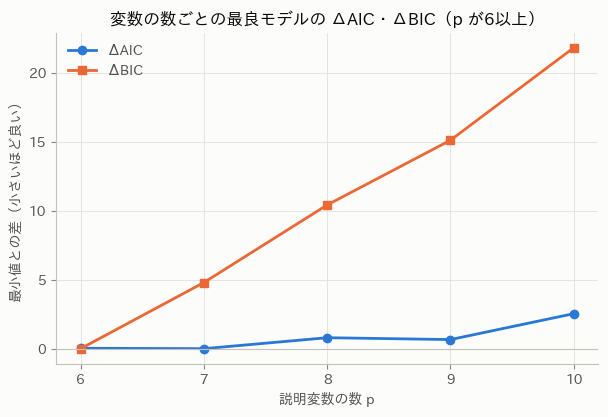

In [208]:
# 全部分集合選択: 1024 通りのモデルの AIC・BIC を計算する
Xall30 = d30[cand30].to_numpy(float)
rows30 = []
for r in range(len(cand30) + 1):
    for sub in itertools.combinations(range(len(cand30)), r):
        Xs = np.column_stack([np.ones(n30), Xall30[:, list(sub)]])
        beta = np.linalg.lstsq(Xs, y30, rcond=None)[0]
        rss = ((y30 - Xs @ beta) ** 2).sum()
        _, aic, bic = aic_bic(rss, n30, r)
        rows30.append({"変数": tuple(cand30[j] for j in sub), "p": r, "RSS": rss, "AIC": aic, "BIC": bic,
                       "調整R2": 1 - (rss / (n30 - r - 1)) / (((y30 - y30.mean()) ** 2).sum() / (n30 - 1))})
subsets30 = pd.DataFrame(rows30)
best_aic = subsets30.loc[subsets30["AIC"].idxmin()]
best_bic = subsets30.loc[subsets30["BIC"].idxmin()]
best_adj = subsets30.loc[subsets30["調整R2"].idxmax()]
print(f"AIC 最小（p={best_aic['p']}, AIC={best_aic['AIC']:.1f}）: {best_aic['変数']}")
print(f"BIC 最小（p={best_bic['p']}, BIC={best_bic['BIC']:.1f}）: {best_bic['変数']}")
print(f"調整R^2 最大（p={best_adj['p']}）: {best_adj['変数']}")
print("\nAIC の小さい順（上位5）")
print(subsets30.nsmallest(5, "AIC")[["p", "AIC", "BIC", "変数"]].to_string())

# 変数の数ごとの最良モデルについて、全体の最小値との差 ΔAIC・ΔBIC（同じ単位なので1つの図に描ける）
by_p = subsets30.groupby("p")[["AIC", "BIC"]].min()
delta_p = by_p - by_p.min()
print("\n変数の数ごとの最良モデルの ΔAIC・ΔBIC")
print(delta_p.round(2).T.to_string())
show_p = delta_p.loc[6:]            # p ≤ 5 は差が100以上あり、図から外す
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(show_p.index, show_p["AIC"], marker="o", color=PALETTE[0], label="ΔAIC")
ax.plot(show_p.index, show_p["BIC"], marker="s", color=PALETTE[1], label="ΔBIC")
ax.axhline(0, color=INK["axis"], lw=0.8)
ax.set(title="変数の数ごとの最良モデルの ΔAIC・ΔBIC（p が6以上）", xlabel="説明変数の数 p",
       ylabel="最小値との差（小さいほど良い）")
ax.set_xticks(show_p.index)
ax.legend()
plt.show()

**結果の読み方**
- BIC 最小は種族値6項目のモデル（$p=6$）。AIC 最小は6項目＋孵化歩数（$p=7$）だが、6項目のモデルとの AIC の差は約0.03 しかなく、実質的に同等である。$R^{*2}$ 最大は9変数のモデルで、予想どおり最も大きいモデルを選ぶ。
- 変数の数ごとに見ると、$p\le5$ の最良モデルは ΔAIC が100以上あり明らかに劣る。$p=6$ 以降、AIC はほぼ平らで差が2以内（どれを選んでもよい範囲）なのに対し、BIC は変数を増やすごとに約5ずつ悪化する。罰則の強さの違いがそのまま表れている。
- 捕獲率・log高さ・log重さは、種族値6項目があればほとんど情報を追加しない（第16章の Lasso と同じ結論）。

### 30.3 交差検証

**問い**：情報量規準で選んだモデルは、推定に使っていないデータでの予測誤差で見ても良いか。

**手法の要点**
- **k 分割交差検証**：データを $k$ 個のグループに分け、1つをテスト用・残り $k-1$ 個を訓練用として予測誤差を求めることを $k$ 回くり返し、平均する。分け方の乱数で値が少し変わる。
- **Leave-one-out（LOO）**：$k=n$ の場合。$i$ 番目を除いて推定したモデルで $y_i$ を予測する誤差 $y_i-\hat y_{(-i)}$ を $n$ 通り求めて平均する。
- 線形回帰では再推定しなくても $y_i-\hat y_{(-i)}=e_i/(1-h_{ii})$（$h_{ii}$ はてこ比、第17章）が成り立つので、
$$\mathrm{PRESS}=\sum_{i=1}^n\left(\frac{e_i}{1-h_{ii}}\right)^2$$
  を1回のあてはめで計算でき、LOO の平均二乗誤差は $\mathrm{PRESS}/n$。
- 交差検証は分布の仮定を使わずに予測誤差を推定できるが、同じ進化系統のポケモンが訓練とテストに分かれると誤差を楽観的に見積もる（独立でないデータの問題）。

（→ py 30-3：5つの候補モデルの 5分割・10分割 CV と LOO（PRESS）の MSE を比べ、6項目モデルで PRESS と920回あてはめ直した LOO が一致することを確かめる）

In [209]:
# 交差検証: k 分割 CV と LOO。LOO は PRESS = Σ (e_i / (1 - h_ii))^2 で1回の推定から求まる
def press_loo(X, y):
    """ハット行列の対角成分を使った LOO の予測誤差平方和の平均."""
    Xc = np.column_stack([np.ones(len(y)), X])
    Q, _ = np.linalg.qr(Xc)
    h = (Q ** 2).sum(axis=1)
    e = y - Q @ (Q.T @ y)
    return np.mean((e / (1 - h)) ** 2)


models30 = {
    "切片のみ": [],
    "種族値6項目": STATS,
    f"BIC 最小（{best_bic['p']}変数）": list(best_bic["変数"]),
    f"AIC 最小（{best_aic['p']}変数）": list(best_aic["変数"]),
    "全10変数": cand30,
}
cv_rows = []
for name, cols in models30.items():
    Xm = d30[cols].to_numpy(float) if cols else np.zeros((n30, 0))
    row = {"モデル": name, "p": len(cols)}
    for k in [5, 10]:
        kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
        if cols:
            row[f"{k}分割CV MSE"] = -cross_val_score(LinearRegression(), Xm, y30, cv=kf,
                                                     scoring="neg_mean_squared_error").mean()
        else:  # 切片のみ: 訓練データの平均で予測
            row[f"{k}分割CV MSE"] = np.mean([np.mean((y30[te] - y30[tr].mean()) ** 2) for tr, te in kf.split(y30)])
    row["LOO MSE（PRESS/n）"] = press_loo(Xm, y30)
    cv_rows.append(row)
cv_tab = pd.DataFrame(cv_rows).set_index("モデル")

# 近道式の確認: 実際に n 回あてはめ直した LOO と一致するか（6項目のモデル）
X6 = d30[STATS].to_numpy(float)
loo_brute = -cross_val_score(LinearRegression(), X6, y30, cv=LeaveOneOut(), scoring="neg_mean_squared_error").mean()
print(f"6項目モデルの LOO MSE: 920回あてはめ直し {loo_brute:.4f}, PRESS 近道式 {press_loo(X6, y30):.4f}")
cv_tab.round(1)

6項目モデルの LOO MSE: 920回あてはめ直し 875.9545, PRESS 近道式 875.9545


,p,5分割CV MSE,10分割CV MSE,LOO MSE（PRESS/n）
モデル,,,,
切片のみ,0,6272.0,6273.4,6270.1
種族値6項目,6,884.9,885.2,876.0
BIC 最小（6変数）,6,884.9,885.2,876.0
AIC 最小（7変数）,7,884.7,883.9,877.0
全10変数,10,891.4,889.3,881.1


**結果の読み方**
- 6項目モデルの LOO MSE は、920回あてはめ直しても PRESS の近道式でも約876.0 で一致する。
- CV MSE は、切片のみ 約6270 に対し、6項目 約885（5分割）、6項目＋孵化歩数 約885、全10変数 約891。AIC・BIC で選んだ2つのモデルがほぼ同じで最も小さく、全10変数はわずかに悪い。情報量規準と交差検証の結論は一致する。
- モデル間の差（1%程度）は、分割の乱数による変動と同程度に小さい。予測だけが目的なら、解釈しやすい小さいモデル（6項目）を選んでよい。

### 30.4 過学習の例：多項式の次数

**問い**：40匹だけで log重さ を log高さ の多項式で回帰するとき、次数を上げると訓練誤差と予測誤差はどう変わるか。

**手法の要点**
- $d$ 次多項式 $y=\beta_0+\beta_1x+\dots+\beta_dx^d+\varepsilon$ は、$x,x^2,\dots,x^d$ を説明変数とする重回帰である。$d$ を上げると訓練データの残差平方和は必ず減らない（入れ子のため）が、訓練データの偶然のばらつきにまで合わせてしまい、新しいデータに対する予測は悪くなる（**過学習**）。
- 訓練MSE・訓練データ内の5分割 CV MSE・AIC・BIC で次数を選び、残りのポケモンでのテストMSE（真の予測誤差の代わり）と比べる。
- 多項式は訓練データの $x$ の範囲外で急激に発散するので、テストは訓練40匹の log高さ の範囲に入る行に限った（内挿の性能だけを評価する）。

（→ py 30-4：次数1〜12の訓練MSE・CV MSE・テストMSE・AIC・BIC を計算し、次数と誤差の関係と、1・3・12次の曲線を描く）

テストに使う行（訓練40匹の log高さ の範囲内）: 803 / 880
CV MSE 最小の次数: 1  テストMSE 最小の次数: 1  AIC 最小: 1  BIC 最小: 1


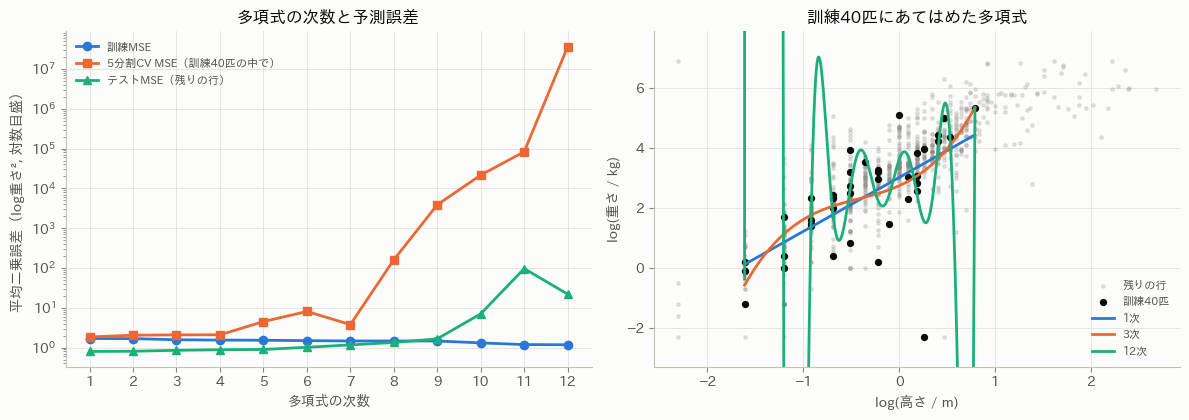

,訓練MSE,5分割CV MSE,テストMSE（残りの行）,AIC,BIC
次数,,,,,
1,1.687,1.853000e+00,0.798,140.444,145.511
2,1.679,2.047000e+00,0.808,142.249,149.004
3,1.575,2.087000e+00,0.854,141.677,150.122
4,1.543,2.096000e+00,0.881,142.860,152.993
5,1.529,4.487000e+00,0.897,144.502,156.324
6,1.494,8.086000e+00,1.017,145.565,159.076
7,1.468,3.790000e+00,1.168,146.867,162.067
8,1.464,1.608950e+02,1.343,148.769,165.658
9,1.461,3.879386e+03,1.661,150.693,169.271


In [210]:
# 過学習の例: 訓練データ40匹で log重さ ~ log高さ の多項式回帰。次数を上げると？
# 残りの行を「テストデータ」（真の汎化誤差の代わり）として使える
rng30 = get_rng()
idx_tr = rng30.choice(n30, size=40, replace=False)
mask_tr = np.zeros(n30, dtype=bool); mask_tr[idx_tr] = True
x_all = d30["log高さ"].to_numpy(); yw_all = d30["log重さ"].to_numpy()
mu_x, sd_x = x_all[mask_tr].mean(), x_all[mask_tr].std()
z_all = (x_all - mu_x) / sd_x            # 数値的安定のため訓練データで標準化
z_tr, y_tr = z_all[mask_tr], yw_all[mask_tr]
# 多項式は訓練データの範囲外で発散するので、テストは訓練データの x の範囲内の行に限る（内挿のみ評価）
in_range = (~mask_tr) & (z_all >= z_tr.min()) & (z_all <= z_tr.max())
z_te, y_te = z_all[in_range], yw_all[in_range]
print(f"テストに使う行（訓練40匹の log高さ の範囲内）: {in_range.sum()} / {(~mask_tr).sum()}")


def poly_design(z, deg):
    return np.vander(z, deg + 1, increasing=True)


degs30 = range(1, 13)
kf30 = KFold(n_splits=5, shuffle=True, random_state=SEED)
over_rows = []
for deg in degs30:
    b = np.linalg.lstsq(poly_design(z_tr, deg), y_tr, rcond=None)[0]
    tr_mse = np.mean((y_tr - poly_design(z_tr, deg) @ b) ** 2)
    te_mse = np.mean((y_te - poly_design(z_te, deg) @ b) ** 2)
    cv_mse = np.mean([np.mean((y_tr[te] - poly_design(z_tr[te], deg)
                               @ np.linalg.lstsq(poly_design(z_tr[tr], deg), y_tr[tr], rcond=None)[0]) ** 2)
                      for tr, te in kf30.split(z_tr)])
    _, aic, bic = aic_bic(tr_mse * len(y_tr), len(y_tr), deg)
    over_rows.append({"次数": deg, "訓練MSE": tr_mse, "5分割CV MSE": cv_mse, "テストMSE（残りの行）": te_mse,
                      "AIC": aic, "BIC": bic})
over_tab = pd.DataFrame(over_rows).set_index("次数")
print("CV MSE 最小の次数:", over_tab["5分割CV MSE"].idxmin(), " テストMSE 最小の次数:", over_tab["テストMSE（残りの行）"].idxmin(),
      " AIC 最小:", over_tab["AIC"].idxmin(), " BIC 最小:", over_tab["BIC"].idxmin())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ax = axes[0]
ax.plot(over_tab.index, over_tab["訓練MSE"], marker="o", color=PALETTE[0], label="訓練MSE")
ax.plot(over_tab.index, over_tab["5分割CV MSE"], marker="s", color=PALETTE[1], label="5分割CV MSE（訓練40匹の中で）")
ax.plot(over_tab.index, over_tab["テストMSE（残りの行）"], marker="^", color=PALETTE[2], label="テストMSE（残りの行）")
ax.set_yscale("log")
ax.set(title="多項式の次数と予測誤差", xlabel="多項式の次数", ylabel="平均二乗誤差（log重さ², 対数目盛）")
ax.set_xticks(list(degs30))
ax.legend(fontsize=8)
ax = axes[1]
zz = np.linspace(z_tr.min(), z_tr.max(), 300)
ax.scatter(x_all[~mask_tr], yw_all[~mask_tr], s=6, alpha=0.2, color=INK["muted"], label="残りの行")
ax.scatter(x_all[mask_tr], y_tr, s=18, color=INK["primary"], label="訓練40匹")
for deg, col in [(1, PALETTE[0]), (3, PALETTE[1]), (12, PALETTE[2])]:
    b = np.linalg.lstsq(poly_design(z_tr, deg), y_tr, rcond=None)[0]
    ax.plot(zz * sd_x + mu_x, poly_design(zz, deg) @ b, color=col, label=f"{deg}次")
ax.set_ylim(yw_all.min() - 1, yw_all.max() + 1)
ax.set(title="訓練40匹にあてはめた多項式", xlabel="log(高さ / m)", ylabel="log(重さ / kg)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
over_tab.round(3)

**結果の読み方**
- 訓練MSE は次数とともに単調に下がる（1次 約1.69 → 12次 約1.18）が、CV MSE とテストMSE は1次が最小で、次数を上げるほど悪化する。CV MSE は8次以上で桁違いに大きくなり、テストMSE も10次以上で急増する。AIC・BIC も1次を選ぶ。
- 12次の曲線は訓練40匹の点の間で激しく振動しており、点をなぞるだけで関係を捉えていない。
- 1次で訓練MSE（約1.69）がテストMSE（約0.80）より大きいのは、無作為に選んだ40匹に極端に軽いポケモンが含まれたためで、小さい訓練データでは誤差の推定自体がばらつくことも示している。
- CV MSE は（訓練40匹だけで計算したにもかかわらず）テストMSE と同じ次数を選んでおり、手元のデータだけで過学習を検出できている。

### まとめ

- 経験値の予測では、AIC・BIC・交差検証がいずれも「種族値6項目（＋孵化歩数）」のモデルを選び、捕獲率や大きさの情報は不要と判断された。BIC は AIC より小さいモデルを選ぶ傾向がはっきり表れた。
- AIC・BIC の値はパラメータ数の数え方（$\sigma^2$ を含めるか）でソフトごとに定数だけずれるが、選択結果には影響しない。
- 線形回帰の LOO はハット行列の対角成分を使えば1回のあてはめで計算できる（PRESS）。
- 多項式の次数を上げると訓練誤差は下がり続けるが、予測誤差は悪化する。モデルの良さは、推定に使っていないデータでの予測誤差か、それを近似する情報量規準で測る必要がある。

## 第31章 ベイズ法

### 章の概要

ベイズ法では、未知のパラメータ $\theta$ を確率変数とみなし、データを見る前の信念（事前分布 $\pi(\theta)$）を、
データ $x$ の尤度 $f(x\mid\theta)$ で更新して事後分布
$$\pi(\theta\mid x)=\frac{f(x\mid\theta)\,\pi(\theta)}{\int f(x\mid\theta')\,\pi(\theta')\,d\theta'}\ \propto\ f(x\mid\theta)\,\pi(\theta)$$
を得る。推定・区間・予測はすべてこの事後分布から導く。
共役事前分布を使えば事後分布は式で書けるが、一般のモデルでは分母の積分が難しいため、
MCMC で事後分布からの標本を作って近似する。
第8〜9章の最尤推定・区間推定と同じデータに当てはめ、結果がどう一致し、どこが違うかを比べる。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 31.1 | ベータ二項モデル・事前分布の影響 | 20匹の標本から「いわタイプを含む割合」を推定すると、事前分布でどれだけ変わるか |
| 31.2 | 事後分布の集中 | 標本を増やすと「複合タイプの割合」の事後分布は真値に集中するか |
| 31.3 | ベイズ推定量・MAP・信用区間・予測分布 | 事後平均と MAP、等裾区間と HPD 区間はどう違うか。次の20匹にいわタイプは何匹いそうか |
| 31.4 | ガンマ・ポアソンモデル | 1種あたりの姿違いの数（ポアソン率）はいくつか |
| 31.5 | 正規-正規モデル・経験ベイズ | 件数の少ないタイプの合計種族値の平均を、全体の平均に引き寄せて推定する |
| 31.6 | 縮小推定の検証 | 経験ベイズ推定は本当に標本平均より誤差が小さいか |
| 31.7 | メトロポリス法 | ロジスティック回帰の事後分布から標本を作る。歩幅で何が変わるか |
| 31.8 | メトロポリス・ヘイスティングス法 | 非対称な提案分布を使った MH 法と最尤推定を比べる |
| 31.9 | ギブスサンプリング | 素早の正規モデルの $(\mu,\sigma^2)$ を条件付き分布の交互抽出で推定する |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `タイプ1`, `タイプ2` | 質的 | 「いわタイプを含むか」（31.1, 31.3）、タイプ1による群分け（31.5, 31.6） |
| `複合タイプ` | 二値 | 31.2 の成功・失敗 |
| `図鑑番号` | 整数 | 図鑑番号ごとの行数 − 1 を「姿違いの数」とする計数データ（31.4） |
| `合計種族値` | 量的 | 31.5〜31.6 の目的変数、31.7〜31.8 の説明変数（標準化して使う） |
| `雄率` | 量的（欠損あり） | 欠損 = 性別不明。31.7〜31.8 のロジスティック回帰の目的変数 |
| `素早` | 量的 | 31.9 の正規モデル |

- **対象の行**：全920行を「真値のわかっている母集団」とし、31.1〜31.4 と 31.9 ではそこから**復元抽出**した小さな標本だけを使って推定する。
  復元抽出なので、標本は母集団の分布からの i.i.d. 標本とみなせる。31.5・31.7・31.8 は全920行を使う（仮想母集団からの標本とみなす）。
- **加工**：31.7〜31.8 では $z=(\text{合計種族値}-\bar{x})/s$ と標準化する（パラメータのスケールをそろえて MCMC を安定させるため）。
- **データの性質と注意点**：いわタイプを含む割合の真値は 0.075、複合タイプの割合は 0.539、性別不明は 0.141。
  姿違いの数は 807種のうち 714種が 0 で、分散/平均 = 1.41 とポアソン分布（分散 = 平均）より散らばっている。
  タイプ1の件数は ひこう 4匹 〜 みず 124匹 と大きく偏る。同じ進化系統の行は独立でない。

In [211]:
from scipy import optimize, special
import statsmodels.api as sm

# 真値（全920行を母集団とみなしたときの値）
bayes_true = {
    "いわタイプを含む割合": types_of(df, "いわ").mean(),
    "複合タイプの割合": df["複合タイプ"].mean(),
    "性別不明の割合": df["雄率"].isna().mean(),
    "素早の平均": df["素早"].mean(),
    "素早の分散（母分散）": df["素早"].var(ddof=0),
}
print(pd.Series(bayes_true).round(4).to_string())

# 図鑑番号ごとの姿違いの数（行数 − 1）
forms_per_no = df.groupby("図鑑番号").size() - 1
print("\n図鑑番号ごとの姿違いの数（件数）")
print(forms_per_no.value_counts().sort_index().to_string())

# タイプ1ごとの件数と合計種族値の平均
print("\nタイプ1ごとの件数（少ない順に5つ）")
print(df["タイプ1"].value_counts().sort_values().head().to_string())

いわタイプを含む割合      0.0750
複合タイプの割合        0.5391
性別不明の割合         0.1413
素早の平均          68.5500
素早の分散（母分散）    864.4605

図鑑番号ごとの姿違いの数（件数）
0    714
1     81
2      6
3      5
5      1

タイプ1ごとの件数（少ない順に5つ）
タイプ1
ひこう       4
フェアリー    19
こおり      28
はがね      30
かくとう     31


### 31.1 ベータ二項モデルと事前分布の影響

**問い**：20匹だけ無作為に選んで「いわタイプを含む割合」$\theta$ を推定するとき、事前分布の選び方で結論はどれだけ変わるか。

**手法の要点**
- 標本分布 $Y\mid\theta\sim\mathrm{Bin}(n,\theta)$、事前分布 $\theta\sim\mathrm{Be}(a,b)$ とすると、
  $$\pi(\theta\mid y)\propto\theta^{y}(1-\theta)^{n-y}\cdot\theta^{a-1}(1-\theta)^{b-1}$$
  より事後分布は $\mathrm{Be}(a+y,\ b+n-y)$。事前分布と事後分布が同じ分布族になるので、ベータ分布は二項分布の**共役事前分布**である。
- $a,b$ は「事前に観測した成功 $a$ 回・失敗 $b$ 回」のように働く。$a+b$ が大きいほど事前分布が強く、データの影響が小さい。
- 比べる事前分布：一様 $\mathrm{Be}(1,1)$、ジェフリーズ $\mathrm{Be}(1/2,1/2)$、平均 0.1 の弱い事前 $\mathrm{Be}(2,18)$、平均 0.4 の誤った強い事前 $\mathrm{Be}(40,60)$。

標本 n=20 中のいわタイプ: y=4
最尤推定値 y/n = 0.200, 真値 = 0.075


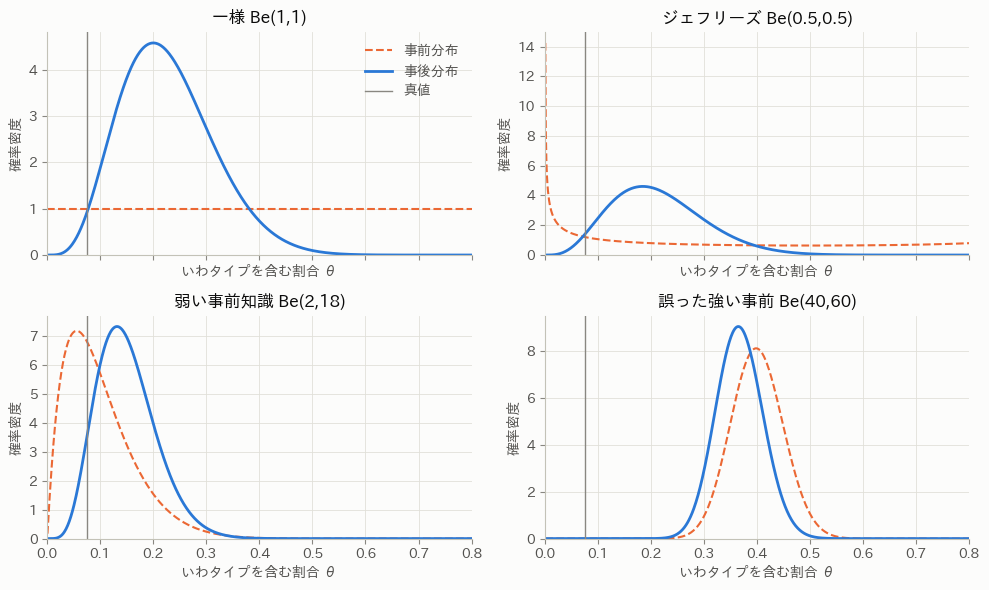

,事前分布,事前平均,事後分布,事後平均,MAP,95%下限,95%上限
0,"一様 Be(1,1)",0.5,"Be(5,17)",0.227,0.200,0.082,0.419
1,"ジェフリーズ Be(0.5,0.5)",0.5,"Be(4.5,16.5)",0.214,0.184,0.072,0.408
2,"弱い事前知識 Be(2,18)",0.1,"Be(6,34)",0.150,0.132,0.059,0.274
3,"誤った強い事前 Be(40,60)",0.4,"Be(44,76)",0.367,0.364,0.283,0.454


In [212]:
# ベータ二項モデル: 20匹の標本から「いわタイプを含む割合」を推定する
rng_bb = get_rng()
n_rock = 20
idx_rock = rng_bb.integers(0, len(df), n_rock)          # 母集団からの復元抽出（i.i.d.）
y_rock = int(types_of(df, "いわ").to_numpy()[idx_rock].sum())
print(f"標本 n={n_rock} 中のいわタイプ: y={y_rock}")

priors_rock = {
    "一様 Be(1,1)": (1, 1),
    "ジェフリーズ Be(0.5,0.5)": (0.5, 0.5),
    "弱い事前知識 Be(2,18)": (2, 18),
    "誤った強い事前 Be(40,60)": (40, 60),
}
rows = []
for name, (a0, b0) in priors_rock.items():
    a1, b1 = a0 + y_rock, b0 + n_rock - y_rock          # 事後分布 Be(a+y, b+n-y)
    post = stats.beta(a1, b1)
    rows.append({"事前分布": name, "事前平均": a0 / (a0 + b0),
                 "事後分布": f"Be({a1:g},{b1:g})", "事後平均": a1 / (a1 + b1),
                 "MAP": (a1 - 1) / (a1 + b1 - 2) if (a1 > 1 and b1 > 1) else np.nan,
                 "95%下限": post.ppf(0.025), "95%上限": post.ppf(0.975)})
print(f"最尤推定値 y/n = {y_rock / n_rock:.3f}, 真値 = {bayes_true['いわタイプを含む割合']:.3f}")

grid_p = np.linspace(0.0005, 0.9995, 1000)
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, (name, (a0, b0)) in zip(axes.ravel(), priors_rock.items()):
    ax.plot(grid_p, stats.beta(a0, b0).pdf(grid_p), color=PALETTE[1], ls="--", lw=1.5, label="事前分布")
    ax.plot(grid_p, stats.beta(a0 + y_rock, b0 + n_rock - y_rock).pdf(grid_p), color=PALETTE[0], label="事後分布")
    ax.axvline(bayes_true["いわタイプを含む割合"], color=INK["muted"], lw=1, label="真値")
    ax.set(title=name, xlabel="いわタイプを含む割合 θ", ylabel="確率密度", xlim=(0, 0.8))
    ax.set_ylim(0, min(ax.get_ylim()[1], 20))
axes[0, 0].legend()
fig.tight_layout()
plt.show()
pd.DataFrame(rows).round(3)

**結果の読み方**
- 標本では20匹中4匹（0.20）がいわタイプで、真値 0.075 よりたまたま多かった。
- 一様・ジェフリーズ事前では事後平均 0.21〜0.23 とほぼデータどおりになる（20匹では事前分布の差は小さい）。
- 平均 0.1 の弱い事前 $\mathrm{Be}(2,18)$ は事後平均を 0.15 まで引き下げ、95%区間の上限も 0.27 と狭くなった。事前知識が正しい方向なら推定を助ける。
- 誤った強い事前 $\mathrm{Be}(40,60)$ では、事後分布 $\mathrm{Be}(44,76)$ の95%区間 [0.28, 0.45] が真値 0.075 を含まない。
  事前分布の「重み」$a+b=100$ が標本サイズ20より大きいと、データでは修正しきれない。事前分布の選択は結果を左右するので、根拠を示し、感度（複数の事前分布での比較）を確かめる必要がある。

### 31.2 標本サイズと事後分布の集中

**問い**：標本を増やすと、「複合タイプの割合」の事後分布は真値に集中していくか。

**手法の要点**
- 事前分布 $\mathrm{Be}(1,1)$ のもとで事後分布は $\mathrm{Be}(1+y,1+n-y)$。事後平均 $\dfrac{1+y}{2+n}$ は $n\to\infty$ で $y/n$ に近づく。
- 事後分散 $\dfrac{(1+y)(1+n-y)}{(2+n)^2(3+n)}$ は、$n$ が大きいとき $\hat p(1-\hat p)/n$（$\hat p=y/n$）とほぼ等しく、$1/n$ の速さで 0 に近づく。
  したがって事後分布は真値の近くに集中する（事前分布が真値の近くに正の密度を持つ限り、事前分布によらない）。
- 1本の i.i.d. 列の先頭 $n=10,40,160,640,2560$ 個を使う（$n>920$ でも復元抽出なので問題ない）。

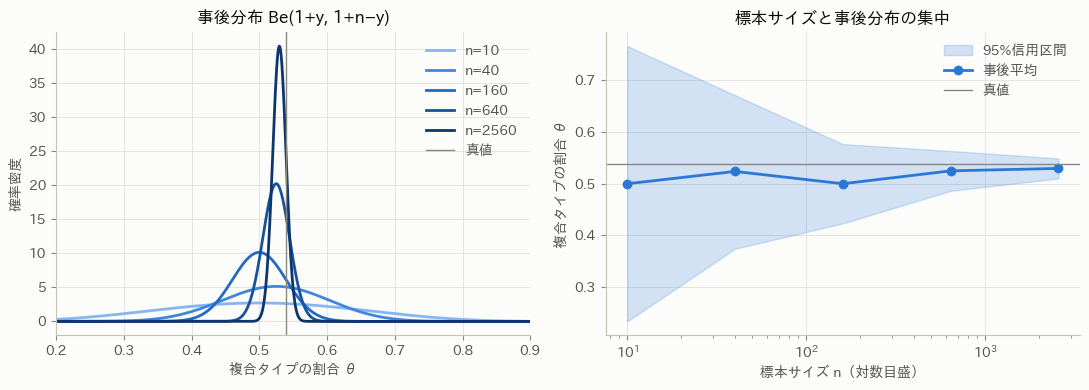

,n,y,事後平均,事後標準偏差,sqrt(p(1-p)/n),95%下限,95%上限
0,10,5,0.5000,0.1387,0.1581,0.2338,0.7662
1,40,21,0.5238,0.0762,0.0790,0.3742,0.6712
2,160,80,0.5000,0.0392,0.0395,0.4233,0.5767
3,640,336,0.5249,0.0197,0.0197,0.4863,0.5634
4,2560,1356,0.5297,0.0099,0.0099,0.5103,0.5490


In [213]:
# 標本サイズを増やすと事後分布が真値に集中する（複合タイプの割合, 事前分布 Be(1,1)）
rng_conc = get_rng()
dual_all = df["複合タイプ"].to_numpy()
seq_dual = dual_all[rng_conc.integers(0, len(df), 2560)]  # 1本の i.i.d. 列の先頭 n 個を使う
n_list = [10, 40, 160, 640, 2560]
conc_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, n in enumerate(n_list):
    y = int(seq_dual[:n].sum())
    post = stats.beta(1 + y, 1 + n - y)
    conc_rows.append({"n": n, "y": y, "事後平均": post.mean(), "事後標準偏差": post.std(),
                      "sqrt(p(1-p)/n)": np.sqrt((y / n) * (1 - y / n) / n),   # p = y/n
                      "95%下限": post.ppf(0.025), "95%上限": post.ppf(0.975)})
    axes[0].plot(grid_p, post.pdf(grid_p), color=SEQ_CMAP(0.25 + 0.75 * k / (len(n_list) - 1)), label=f"n={n}")
axes[0].axvline(bayes_true["複合タイプの割合"], color=INK["muted"], lw=1, label="真値")
axes[0].set(title="事後分布 Be(1+y, 1+n−y)", xlabel="複合タイプの割合 θ", ylabel="確率密度", xlim=(0.2, 0.9))
axes[0].legend()
conc = pd.DataFrame(conc_rows)
axes[1].fill_between(conc["n"], conc["95%下限"], conc["95%上限"], color=PALETTE[0], alpha=0.2, label="95%信用区間")
axes[1].plot(conc["n"], conc["事後平均"], marker="o", color=PALETTE[0], label="事後平均")
axes[1].axhline(bayes_true["複合タイプの割合"], color=INK["muted"], lw=1, label="真値")
axes[1].set(xscale="log", title="標本サイズと事後分布の集中", xlabel="標本サイズ n（対数目盛）", ylabel="複合タイプの割合 θ")
axes[1].legend()
fig.tight_layout()
plt.show()
conc.round(4)

**結果の読み方**
- $n=10$ では95%信用区間が [0.23, 0.77] と広いが、$n=2560$ では [0.51, 0.55] まで狭まり、真値 0.539 を含む。
- 事後標準偏差は $n$ を4倍にするごとにほぼ半分になり、$\sqrt{\hat p(1-\hat p)/n}$ とよく一致する（$n=160$ で差は1%程度、$n=640$ 以上では小数第4位まで一致）。
  大標本では、ベイズの信用区間と最尤推定に基づく正規近似の信頼区間はほぼ同じになる。

### 31.3 ベイズ推定量・MAP 推定量・信用区間・予測分布

**問い**：31.1 の標本（20匹中4匹）と一様事前分布から得た事後分布 $\mathrm{Be}(5,17)$ を要約し、次の20匹に含まれるいわタイプの数を予測する。

**手法の要点**
- **ベイズ推定量**：二乗誤差損失のもとでベイズリスクを最小にする推定量は事後平均。$\mathrm{Be}(a,b)$ では $\dfrac{a}{a+b}$。
- **MAP 推定量**：事後分布のモード。$a>1,\ b>1$ のとき $\dfrac{a-1}{a+b-2}$。一様事前なら尤度の最大点と一致し、最尤推定値 $y/n$ になる。
- **$100(1-\alpha)\%$ 信用区間**：事後確率が $1-\alpha$ の区間。
  - 等裾区間：事後分布の $\alpha/2$ 点と $1-\alpha/2$ 点。
  - HPD（最大事後密度）区間：$\{\theta:\pi(\theta\mid y)\ge k\}$ で事後確率がちょうど $1-\alpha$ になるもの。単峰なら両端の密度が等しく、同じ確率を持つ区間の中で幅が最小。
  - 「$\theta$ がこの区間に入る確率が 95%」と直接言えるのが、信頼区間との解釈の違い。
- **ベイズ予測分布**：新しいデータ $\tilde y$ の分布を $\theta$ について事後分布で平均したもの
  $$p(\tilde y\mid y)=\int f(\tilde y\mid\theta)\,\pi(\theta\mid y)\,d\theta .$$
  $\tilde Y\mid\theta\sim\mathrm{Bin}(m,\theta)$、$\theta\mid y\sim\mathrm{Be}(a,b)$ なら**ベータ二項分布**
  $$P(\tilde Y=k\mid y)=\binom{m}{k}\frac{B(a+k,\ b+m-k)}{B(a,b)},\quad k=0,1,\dots,m .$$
  $\theta$ の不確かさを含むので、事後平均を代入した二項分布より分散が大きい。

事後分布 Be(5, 17)
ベイズ推定量（事後平均） a/(a+b)       = 0.2273
MAP推定量（事後モード） (a-1)/(a+b-2) = 0.2000  (= 最尤推定値 0.2000)
95%等裾区間: [0.0822, 0.4191]  幅 0.3369
95%HPD区間 : [0.0692, 0.3995]  幅 0.3303
  HPD の両端の密度: 0.741, 0.741（等しい）

予測分布: 手計算と scipy.stats.betabinom の最大差 1.9e-16
予測分布の分散: ベイズ予測 6.414  / 代入法の二項分布 3.512


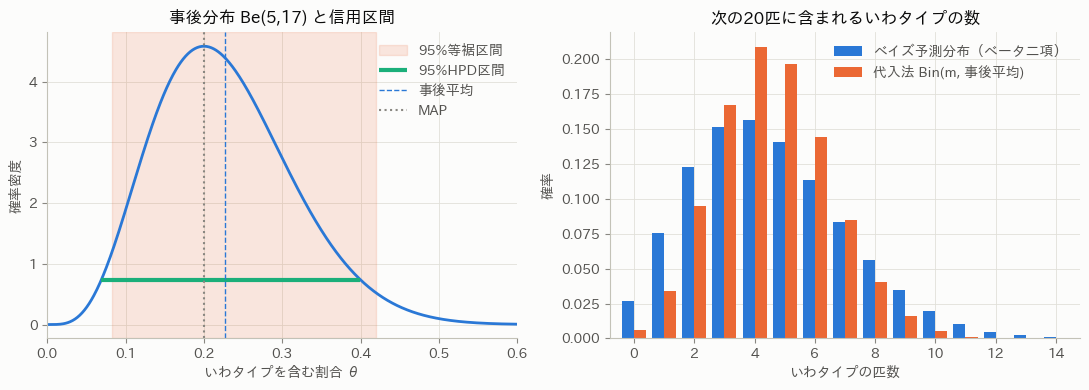

In [214]:
# 点推定・信用区間（等裾・HPD）・ベイズ予測分布（31-1 の標本, 事前分布 Be(1,1)）
a_post, b_post = 1 + y_rock, 1 + n_rock - y_rock
post_rock = stats.beta(a_post, b_post)
print(f"事後分布 Be({a_post}, {b_post})")
print(f"ベイズ推定量（事後平均） a/(a+b)       = {a_post / (a_post + b_post):.4f}")
print(f"MAP推定量（事後モード） (a-1)/(a+b-2) = {(a_post - 1) / (a_post + b_post - 2):.4f}  (= 最尤推定値 {y_rock / n_rock:.4f})")

# 等裾信用区間: 両側に 2.5% ずつ
et_lo, et_hi = post_rock.ppf([0.025, 0.975])
# HPD 区間: 確率 0.95 を含む区間のうち幅が最小のもの（単峰なので下側確率 q を動かして幅を最小化）
res_hpd = optimize.minimize_scalar(lambda q: post_rock.ppf(q + 0.95) - post_rock.ppf(q),
                                   bounds=(0, 0.05), method="bounded")
hpd_lo, hpd_hi = post_rock.ppf([res_hpd.x, res_hpd.x + 0.95])
print(f"95%等裾区間: [{et_lo:.4f}, {et_hi:.4f}]  幅 {et_hi - et_lo:.4f}")
print(f"95%HPD区間 : [{hpd_lo:.4f}, {hpd_hi:.4f}]  幅 {hpd_hi - hpd_lo:.4f}")
print(f"  HPD の両端の密度: {post_rock.pdf(hpd_lo):.3f}, {post_rock.pdf(hpd_hi):.3f}（等しい）")

# ベイズ予測分布: 次に m 匹選んだときのいわタイプの数（ベータ二項分布）
m_new = 20
k_new = np.arange(m_new + 1)
# 定義式: P(k) = C(m,k) B(a+k, b+m-k) / B(a, b)
pred_hand = special.comb(m_new, k_new) * np.exp(special.betaln(a_post + k_new, b_post + m_new - k_new)
                                                 - special.betaln(a_post, b_post))
pred_scipy = stats.betabinom(m_new, a_post, b_post).pmf(k_new)
print(f"\n予測分布: 手計算と scipy.stats.betabinom の最大差 {np.abs(pred_hand - pred_scipy).max():.1e}")
plug_in = stats.binom(m_new, a_post / (a_post + b_post)).pmf(k_new)   # 事後平均を代入しただけの二項分布
print(f"予測分布の分散: ベイズ予測 {stats.betabinom(m_new, a_post, b_post).var():.3f}"
      f"  / 代入法の二項分布 {stats.binom(m_new, a_post / (a_post + b_post)).var():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(grid_p, post_rock.pdf(grid_p), color=PALETTE[0])
axes[0].axvspan(et_lo, et_hi, color=PALETTE[1], alpha=0.15, label="95%等裾区間")
axes[0].hlines(post_rock.pdf(hpd_lo), hpd_lo, hpd_hi, color=PALETTE[2], lw=3, label="95%HPD区間")
axes[0].axvline(a_post / (a_post + b_post), color=PALETTE[0], ls="--", lw=1, label="事後平均")
axes[0].axvline((a_post - 1) / (a_post + b_post - 2), color=INK["muted"], ls=":", lw=1.5, label="MAP")
axes[0].set(title=f"事後分布 Be({a_post},{b_post}) と信用区間", xlabel="いわタイプを含む割合 θ", ylabel="確率密度", xlim=(0, 0.6))
axes[0].legend()
w = 0.4
axes[1].bar(k_new - w / 2, pred_scipy, width=w, color=PALETTE[0], label="ベイズ予測分布（ベータ二項）")
axes[1].bar(k_new + w / 2, plug_in, width=w, color=PALETTE[1], label="代入法 Bin(m, 事後平均)")
axes[1].set(title=f"次の{m_new}匹に含まれるいわタイプの数", xlabel="いわタイプの匹数", ylabel="確率", xlim=(-0.8, 14.8))
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 事後平均 0.227、MAP 0.200（= 最尤推定値）。事後分布が右に歪んでいるので、事後平均がモードより右にある。
- 95%等裾区間 [0.082, 0.419]、95%HPD 区間 [0.069, 0.400]。HPD 区間は密度の高い左側へずれ、幅が少し短い（0.337 → 0.330）。HPD の両端の密度が等しいことも確認できた。
- 予測分布は手計算と `scipy.stats.betabinom` が一致した。分散はベイズ予測 6.4 に対し代入法の二項分布 3.5 で、代入法は予測の不確かさを過小評価する。

### 31.4 ガンマ・ポアソンモデル

**問い**：100種を無作為に選び、1種あたりの姿違いの数の平均（ポアソン率 $\theta$）を推定する。

**手法の要点**
- 標本分布 $Y_1,\dots,Y_n\mid\theta\overset{\text{i.i.d.}}{\sim}\mathrm{Po}(\theta)$、事前分布 $\theta\sim\mathrm{Ga}(a,1/b)$（形状 $a$、尺度 $1/b$、密度 $\propto\theta^{a-1}e^{-b\theta}$、平均 $a/b$）とすると、
  $$\pi(\theta\mid y)\propto\theta^{\sum y_i}e^{-n\theta}\cdot\theta^{a-1}e^{-b\theta}$$
  より事後分布は $\mathrm{Ga}\!\left(a+\sum_i y_i,\ 1/(b+n)\right)$。事後平均 $\dfrac{a+\sum y_i}{b+n}$、MAP $\dfrac{a+\sum y_i-1}{b+n}$（形状 $>1$ のとき）。
- 予測分布：$\tilde Y\mid\theta\sim\mathrm{Po}(\theta)$、$\theta\sim\mathrm{Ga}(\alpha,1/\beta)$ のとき
  $P(\tilde Y=k)=\dbinom{\alpha+k-1}{k}\left(\dfrac{\beta}{\beta+1}\right)^{\alpha}\left(\dfrac{1}{\beta+1}\right)^{k}$（負の二項分布）。
- 前提：各種の姿違いの数が同じ率のポアソン分布に従うこと。実際は 0 が大半で、ロトム（5つ）、デオキシス・バケッチャ・ネクロズマなど（3つ）のようにフォルムの多い一部の種に集中しており、ポアソン分布は近似にすぎない。

標本 n=100 種の姿違いの数: 合計 9, 平均 0.090
母集団（全807種）: 平均 0.140, 分散 0.197（分散/平均 = 1.41）


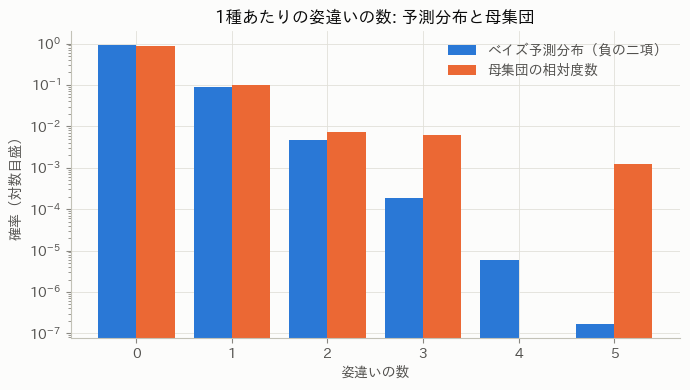

     予測分布     母集団
0  0.9062  0.8848
1  0.0888  0.1004
2  0.0048  0.0074
3  0.0002  0.0062
4  0.0000  0.0000
5  0.0000  0.0012


,事前分布,事前平均 a/b,事後分布,事後平均 a/b,MAP (a-1)/b,95%下限,95%上限
0,"弱い事前 Ga(1, 1/1)",1.0,"Ga(10, 1/101)",0.099,0.0891,0.0475,0.1692
1,"情報のある事前 Ga(2, 1/10)",0.2,"Ga(11, 1/110)",0.100,0.0909,0.0499,0.1672


In [215]:
# ガンマ・ポアソンモデル: 図鑑番号ごとの姿違いの数
rng_gp = get_rng()
n_gp = 100
y_gp = forms_per_no.to_numpy()[rng_gp.integers(0, len(forms_per_no), n_gp)]
print(f"標本 n={n_gp} 種の姿違いの数: 合計 {y_gp.sum()}, 平均 {y_gp.mean():.3f}")
print(f"母集団（全{len(forms_per_no)}種）: 平均 {forms_per_no.mean():.3f}, 分散 {forms_per_no.var(ddof=0):.3f}"
      f"（分散/平均 = {forms_per_no.var(ddof=0) / forms_per_no.mean():.2f}）")

# 事前分布 Ga(a, 1/b)（形状 a, 尺度 1/b, 平均 a/b）→ 事後分布 Ga(a + Σy, 1/(b + n))
gp_rows = []
for name, (a0, b0) in {"弱い事前 Ga(1, 1/1)": (1, 1), "情報のある事前 Ga(2, 1/10)": (2, 10)}.items():
    a1, b1 = a0 + y_gp.sum(), b0 + n_gp
    post = stats.gamma(a1, scale=1 / b1)
    gp_rows.append({"事前分布": name, "事前平均 a/b": a0 / b0, "事後分布": f"Ga({a1}, 1/{b1})",
                    "事後平均 a/b": a1 / b1, "MAP (a-1)/b": (a1 - 1) / b1 if a1 > 1 else np.nan,
                    "95%下限": post.ppf(0.025), "95%上限": post.ppf(0.975)})
gp_table = pd.DataFrame(gp_rows)

# 予測分布（事前 Ga(1,1)）: 負の二項分布 NB(a, b/(b+1))。母集団の分布と比較する
a1, b1 = 1 + y_gp.sum(), 1 + n_gp
k_gp = np.arange(6)
pred_gp = stats.nbinom(a1, b1 / (b1 + 1)).pmf(k_gp)
pop_gp = forms_per_no.value_counts(normalize=True).reindex(k_gp, fill_value=0).to_numpy()
fig, ax = plt.subplots(figsize=(7, 4))
w = 0.4
ax.bar(k_gp - w / 2, pred_gp, width=w, color=PALETTE[0], label="ベイズ予測分布（負の二項）")
ax.bar(k_gp + w / 2, pop_gp, width=w, color=PALETTE[1], label="母集団の相対度数")
ax.set(title="1種あたりの姿違いの数: 予測分布と母集団", xlabel="姿違いの数", ylabel="確率（対数目盛）", yscale="log")
ax.legend()
fig.tight_layout()
plt.show()
print(pd.DataFrame({"予測分布": pred_gp, "母集団": pop_gp}, index=k_gp).round(4).to_string())
gp_table.round(4)

**結果の読み方**
- 100種で姿違いは合計9。弱い事前 $\mathrm{Ga}(1,1)$ では事後分布 $\mathrm{Ga}(10,1/101)$、事後平均 0.099、95%信用区間 [0.048, 0.169] で、真値 0.140 を含む。
  事前平均 0.2 の $\mathrm{Ga}(2,1/10)$ でも事後平均 0.100 とほとんど変わらない（$n=100$ に比べて事前分布の重み $b=10$ が小さい）。
- 予測分布（負の二項）は 0 個・1 個の確率はおおむね合うが、3個以上の確率を母集団より桁違いに小さく見積もる。
  母集団は分散/平均 = 1.41 の過分散であり、「全種で同じ率」というポアソン仮定の破れが裾に現れている。

### 31.5 正規-正規モデルと経験ベイズ（縮小推定）

**問い**：タイプ1ごとの合計種族値の平均を推定する。ひこう（4匹）のように件数の少ないタイプの標本平均は信頼できるか。

**手法の要点**
- 正規-正規モデル：$Y_1,\dots,Y_n\mid\theta\overset{\text{i.i.d.}}{\sim}N(\theta,\sigma^2)$（$\sigma^2$ 既知）、事前分布 $\theta\sim N(\mu_0,\sigma_0^2)$ のとき、事後分布は
  $$\theta\mid y\sim N\!\left(\frac{\mu_0/\sigma_0^2+n\bar y/\sigma^2}{1/\sigma_0^2+n/\sigma^2},\ \frac{1}{1/\sigma_0^2+n/\sigma^2}\right).$$
  事後平均は事前平均と標本平均を、それぞれの精度（分散の逆数）で重み付けした平均である。
- 階層モデル：タイプ $j$ の標本平均 $\bar y_j\mid\theta_j\sim N(\theta_j,\sigma^2/n_j)$、タイプの真の平均 $\theta_j\sim N(\mu,\tau^2)$（$j=1,\dots,18$）。
  事後平均は
  $$\hat\theta_j=B_j\,\mu+(1-B_j)\,\bar y_j,\qquad B_j=\frac{\sigma^2/n_j}{\sigma^2/n_j+\tau^2}.$$
  $n_j$ が小さいほど縮小係数 $B_j$ が大きく、全体平均 $\mu$ に強く引き寄せられる。
- **経験ベイズ**：事前分布のパラメータ $(\mu,\tau^2)$ をデータから推定する。周辺分布 $\bar y_j\sim N(\mu,\ \tau^2+\sigma^2/n_j)$ の尤度（周辺尤度）を最大化する。
  モーメント法では $\hat\tau^2=\max\{0,\ s_{\bar y}^2-\overline{\sigma^2/n_j}\}$（$s_{\bar y}^2$ は $\bar y_j$ の標本分散）。
  $\sigma^2$ はタイプ内のプールした不偏分散で代用し、既知とみなす。

プールした群内分散 σ² = 13444（σ = 116.0）
周辺尤度最大化: μ = 443.7, τ² = 1080（τ = 32.9）
モーメント法  : τ² = 1005（τ = 31.7）


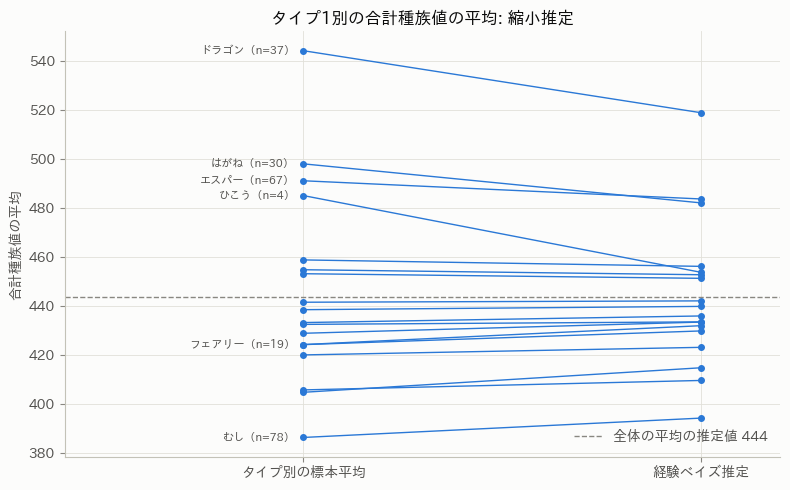

,n,標本平均,分散,縮小係数B,経験ベイズ推定,事後標準偏差
タイプ1,,,,,,
ひこう,4,485.000,26050.000,0.757,453.725,28.591
フェアリー,19,424.211,14832.842,0.396,431.915,20.677
こおり,28,428.821,11733.485,0.308,433.392,18.232
はがね,30,497.933,12938.823,0.293,482.022,17.797
かくとう,31,424.194,10671.895,0.286,429.775,17.591
じめん,36,433.194,14599.875,0.257,435.887,16.659
どく,36,404.750,8481.621,0.257,414.751,16.659
あく,36,438.444,12379.683,0.257,439.788,16.659
ゴースト,37,441.486,11112.257,0.252,442.037,16.489


In [216]:
# 正規-正規モデルによる経験ベイズ（タイプ1別の合計種族値の平均の縮小推定）
eb = df.groupby("タイプ1", observed=True)["合計種族値"].agg(n="count", 標本平均="mean", 分散="var")
# 群内の分散はプールした値 σ² を既知とみなす
sigma2_eb = ((eb["n"] - 1) * eb["分散"]).sum() / (eb["n"] - 1).sum()
se2_eb = sigma2_eb / eb["n"].to_numpy()              # 標本平均の分散 σ²/n_j
ybar_eb = eb["標本平均"].to_numpy()

# 周辺分布 ȳ_j ~ N(μ, τ² + σ²/n_j) の対数尤度を最大化して (μ, τ²) を推定
def eb_negloglik(par):
    mu, log_tau2 = par
    v = np.exp(log_tau2) + se2_eb
    return 0.5 * np.sum(np.log(2 * np.pi * v) + (ybar_eb - mu) ** 2 / v)

res_eb = optimize.minimize(eb_negloglik, x0=[ybar_eb.mean(), np.log(ybar_eb.var())], method="Nelder-Mead")
mu_eb, tau2_eb = res_eb.x[0], np.exp(res_eb.x[1])
# モーメント法: E[ȳ_j の標本分散] ≈ τ² + mean(σ²/n_j)
tau2_mm = max(0.0, ybar_eb.var(ddof=1) - se2_eb.mean())
print(f"プールした群内分散 σ² = {sigma2_eb:.0f}（σ = {np.sqrt(sigma2_eb):.1f}）")
print(f"周辺尤度最大化: μ = {mu_eb:.1f}, τ² = {tau2_eb:.0f}（τ = {np.sqrt(tau2_eb):.1f}）")
print(f"モーメント法  : τ² = {tau2_mm:.0f}（τ = {np.sqrt(tau2_mm):.1f}）")

# 事後平均 = B_j μ + (1 − B_j) ȳ_j,  縮小係数 B_j = (σ²/n_j) / (σ²/n_j + τ²)
eb["縮小係数B"] = se2_eb / (se2_eb + tau2_eb)
eb["経験ベイズ推定"] = eb["縮小係数B"] * mu_eb + (1 - eb["縮小係数B"]) * ybar_eb
eb["事後標準偏差"] = np.sqrt(1 / (1 / se2_eb + 1 / tau2_eb))
eb = eb.sort_values("n")

fig, ax = plt.subplots(figsize=(8, 5))
for t, r in eb.iterrows():
    ax.plot([0, 1], [r["標本平均"], r["経験ベイズ推定"]], color=PALETTE[0], lw=1, marker="o", ms=4)
    if r["n"] < 20 or abs(r["標本平均"] - mu_eb) > 45:
        ax.annotate(f"{t}（n={int(r['n'])}）", (0, r["標本平均"]), xytext=(-6, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=8, color=INK["secondary"])
ax.axhline(mu_eb, color=INK["muted"], ls="--", lw=1, label=f"全体の平均の推定値 {mu_eb:.0f}")
ax.set(xticks=[0, 1], xticklabels=["タイプ別の標本平均", "経験ベイズ推定"], xlim=(-0.6, 1.2),
       title="タイプ1別の合計種族値の平均: 縮小推定", ylabel="合計種族値の平均")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
eb.round(3)

**結果の読み方**
- タイプ内の標準偏差 $\sigma\approx116$ に対し、タイプ間の標準偏差は $\hat\tau\approx33$（周辺尤度）、31.7（モーメント法）とほぼ同じで、タイプによる差は個体差よりずっと小さい。
- ひこう（$n=4$）は縮小係数 0.76 で、標本平均 485 が 454 まで引き寄せられた。一方、みず（$n=124$）は 0.09 で、ほとんど動かない。
  ドラゴン（544 → 519）は $n=37$ でも平均が全体から大きく離れているため、縮小の幅は大きいが順位は1位のまま。
- 縮小推定は「タイプ間の差は正規分布に従う」という仮定に依存する。ドラゴンのように本当に高いタイプを過小評価する方向の偏りがある（偏りと分散のトレードオフ）。

### 31.6 縮小推定の検証

**問い**：各タイプから5匹ずつしか観測できないとき、経験ベイズ推定は標本平均よりタイプの真の平均（全データでのタイプ平均）に近いか。

**手法の要点**
- 各タイプから5匹を復元抽出し、18タイプの標本平均と経験ベイズ推定（モーメント法、全タイプで $n_j=5$ なので $B$ は共通）を計算する。
- 18タイプの平均二乗誤差 $\frac{1}{18}\sum_j(\hat\theta_j-\theta_j)^2$ を2000回の反復で平均して比べる。
- 3群以上の正規平均では、標本平均より全体の平均二乗誤差が小さくなる縮小推定量が存在する（スタインの現象、ジェームズ・スタイン推定量）。経験ベイズ推定はその一例。

In [217]:
# 縮小推定の検証: 各タイプから5匹だけ抜き出して平均を推定し、タイプ全体の平均（真値）との誤差を比べる
rng_ebv = get_rng()
true_type_mean = df.groupby("タイプ1", observed=True)["合計種族値"].mean()
type_codes = df["タイプ1"].cat.remove_unused_categories()
groups_ebv = [df.loc[type_codes == t, "合計種族値"].to_numpy() for t in true_type_mean.index]
n_small, n_rep_ebv = 5, 2000
mse_raw = mse_eb = 0.0
for _ in range(n_rep_ebv):
    samp = np.array([rng_ebv.choice(g, n_small, replace=True) for g in groups_ebv])   # 18×5
    yb = samp.mean(axis=1)
    s2 = samp.var(axis=1, ddof=1).mean()                   # プールした群内分散
    se2 = s2 / n_small
    mu_hat = yb.mean()
    tau2_hat = max(0.0, yb.var(ddof=1) - se2)              # モーメント法（全群で n が等しい）
    B = se2 / (se2 + tau2_hat)
    est = B * mu_hat + (1 - B) * yb
    mse_raw += np.mean((yb - true_type_mean.to_numpy()) ** 2) / n_rep_ebv
    mse_eb += np.mean((est - true_type_mean.to_numpy()) ** 2) / n_rep_ebv
print(f"各タイプ {n_small} 匹・{n_rep_ebv} 回の反復")
print(f"平均二乗誤差: 標本平均 {mse_raw:.0f} / 経験ベイズ {mse_eb:.0f}  （比 {mse_eb / mse_raw:.2f}）")

各タイプ 5 匹・2000 回の反復
平均二乗誤差: 標本平均 2712 / 経験ベイズ 1273  （比 0.47）


**結果の読み方**
- 平均二乗誤差は標本平均 約2700 に対し経験ベイズ 約1270 で、半分以下になった。5匹の標本平均はばらつきが大きく（$\sigma^2/5\approx 2700$）、全体平均へ寄せる利得が偏りの損失を大きく上回る。
- ただしこれは18タイプ全体の平均での比較であり、個々のタイプ（特にドラゴンのような極端なタイプ）では縮小で誤差が増えることがある。

### 31.7 メトロポリス法（ロジスティック回帰）

**問い**：合計種族値が高いほど性別不明のポケモンが多いか。ロジスティック回帰の事後分布を MCMC で求める。

**手法の要点**
- モデル：$Y_i\sim\mathrm{Bernoulli}(p_i)$、$\log\dfrac{p_i}{1-p_i}=\beta_0+\beta_1 z_i$、事前分布 $\beta_0,\beta_1\overset{\text{i.i.d.}}{\sim}N(0,10^2)$。
  事後分布 $\pi(\beta\mid y)\propto\prod_i p_i^{y_i}(1-p_i)^{1-y_i}\cdot\pi(\beta)$ は正規化定数が式で求まらない。
- **メトロポリス法**：
  1. 初期値 $\theta^{(0)}$ を決める。
  2. 対称な分布から $u$ を生成し、$\theta'=\theta^{(t)}+u$ を提案する（ここでは $u\sim N(0,c^2\hat\Sigma)$、$\hat\Sigma$ は最尤推定量の漸近共分散行列）。
  3. $r=\pi(\theta'\mid y)/\pi(\theta^{(t)}\mid y)$ を計算し、$v\sim U(0,1)$ に対して $r\ge v$ なら $\theta^{(t+1)}=\theta'$、そうでなければ $\theta^{(t+1)}=\theta^{(t)}$。
  4. 2〜3 を繰り返す。
  $r$ は比なので正規化定数が消え、事後分布の「形」だけで計算できる。
- 生成される列はマルコフ連鎖で、定常分布が事後分布になる。初期値の影響が残る最初の部分は**バーンイン**として捨てる。
- 歩幅 $c$ が小さすぎると受容率は高いが少しずつしか動かず、大きすぎるとほとんど棄却されて同じ値に留まる。2次元では $c=2.4/\sqrt{2}$ 付近が目安（受容率 0.2〜0.4 程度）。

 小さすぎる歩幅: 受容率 0.910


   適切な歩幅: 受容率 0.354


 大きすぎる歩幅: 受容率 0.007


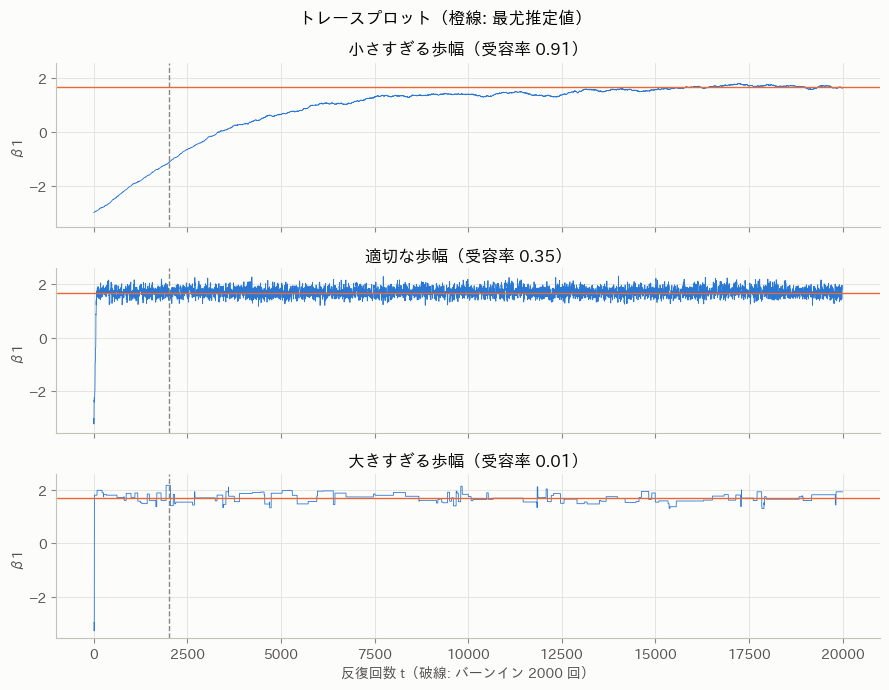

In [218]:
# メトロポリス法: ロジスティック回帰 P(性別不明) = 1 / (1 + exp(−(β0 + β1 z))), z = 合計種族値の標準化
y_lr = df["雄率"].isna().astype(int).to_numpy()
z_lr = ((df["合計種族値"] - df["合計種族値"].mean()) / df["合計種族値"].std()).to_numpy()
X_lr = np.column_stack([np.ones(len(df)), z_lr])
prior_sd_lr = 10.0                                         # 事前分布 β0, β1 ~ N(0, 10²) 独立

def log_post_lr(beta):
    eta = X_lr @ beta
    loglik = np.sum(y_lr * eta - np.logaddexp(0, eta))
    return loglik - 0.5 * np.sum(beta ** 2) / prior_sd_lr ** 2

mle_lr = sm.Logit(y_lr, X_lr).fit(disp=0)
cov_mle = mle_lr.cov_params()

def metropolis(log_post, init, step_cov, n_iter, rng):
    """ランダムウォーク・メトロポリス法（提案 θ' = θ + u, u ~ N(0, step_cov)）."""
    chol = np.linalg.cholesky(step_cov)
    draws = np.empty((n_iter, len(init)))
    cur, lp_cur, acc = np.asarray(init, float), log_post(init), 0
    for t in range(n_iter):
        prop = cur + chol @ rng.standard_normal(len(cur))
        lp_prop = log_post(prop)
        if np.log(rng.uniform()) < lp_prop - lp_cur:          # r = π(θ')/π(θ) ≥ v なら採用
            cur, lp_cur, acc = prop, lp_prop, acc + 1
        draws[t] = cur
    return draws, acc / n_iter

rng_mh = get_rng()
n_iter_mh, burn_mh = 20000, 2000
init_lr = np.array([3.0, -3.0])                               # わざと離れた初期値
mh_runs = {}
for label, scale in [("小さすぎる歩幅", 0.02), ("適切な歩幅", 2.4 / np.sqrt(2)), ("大きすぎる歩幅", 15.0)]:
    mh_runs[label] = metropolis(log_post_lr, init_lr, scale ** 2 * cov_mle, n_iter_mh, rng_mh)
    print(f"{label:>8}: 受容率 {mh_runs[label][1]:.3f}")

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True, sharey=True)
for ax, (label, (draws, acc)) in zip(axes, mh_runs.items()):
    ax.plot(draws[:, 1], color=PALETTE[0], lw=0.6)
    ax.axvline(burn_mh, color=INK["muted"], ls="--", lw=1)
    ax.axhline(mle_lr.params[1], color=PALETTE[1], lw=1)
    ax.set(title=f"{label}（受容率 {acc:.2f}）", ylabel="β1")
axes[-1].set_xlabel("反復回数 t（破線: バーンイン 2000 回）")
fig.suptitle("トレースプロット（橙線: 最尤推定値）", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

**結果の読み方**
- 受容率は、小さすぎる歩幅 0.91、適切な歩幅 0.35、大きすぎる歩幅 0.007。
- 小さすぎる歩幅では、わざと離した初期値 $\beta_1=-3$ から最尤推定値 1.67 付近にたどり着くまで1万回以上かかり、バーンイン 2000 回では足りない。
- 大きすぎる歩幅ではトレースが階段状（同じ値に長く留まる）で、有効な標本数が少ない。
  適切な歩幅では数十回で定常状態に入り、上下に細かく動く「毛虫」のようなトレースになる。トレースプロットと受容率は MCMC の収束診断の基本である。

### 31.8 メトロポリス・ヘイスティングス法と最尤推定の比較

**問い**：非対称な提案分布を使う MH 法でも同じ事後分布が得られるか。事後分布と最尤推定はどう違うか。

**手法の要点**
- **メトロポリス・ヘイスティングス法**：提案分布 $q(\theta'\mid\theta)$ が対称でないとき、採択確率の比を
  $$r=\frac{\pi(\theta'\mid y)\,q(\theta^{(t)}\mid\theta')}{\pi(\theta^{(t)}\mid y)\,q(\theta'\mid\theta^{(t)})}$$
  に取り替える。$q$ が対称ならメトロポリス法に戻る。
- ここでは現在値によらない**独立提案** $q(\theta')$ として、最尤推定値を中心とする自由度4の多変量 $t$ 分布を使う。$t$ 分布は裾が重く、事後分布の裾もカバーできる。
- 事前分布が平坦に近く $n$ が大きいとき、事後分布は最尤推定値を中心とする正規分布 $N(\hat\beta,\hat\Sigma)$ で近似できる（ベルンシュタイン・フォンミーゼスの定理）。

独立提案 MH の受容率: 0.719


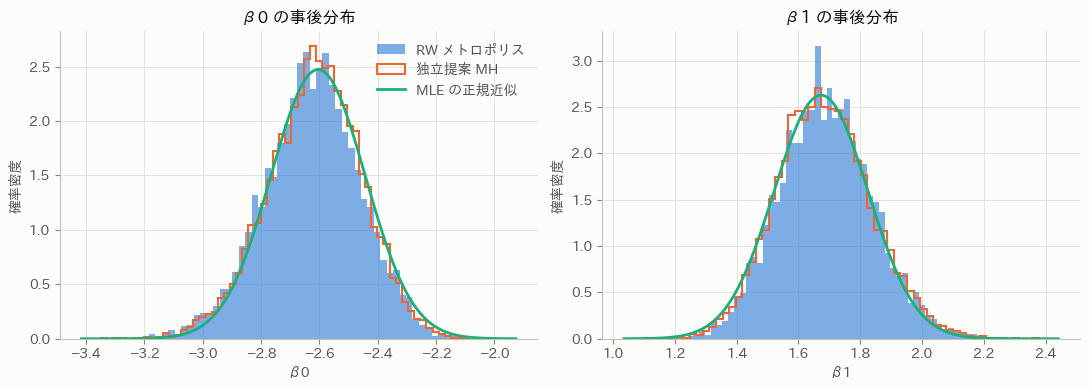

,最尤推定値,MLE標準誤差,事後平均(RW),事後SD(RW),事後平均(独立MH),事後SD(独立MH),95%信用区間(RW)
β0,-2.6042,0.1613,-2.6264,0.1645,-2.6160,0.1601,"[-2.969, -2.316]"
β1,1.6732,0.1518,1.6893,0.1519,1.6831,0.1528,"[1.406, 2.000]"


In [219]:
# メトロポリス・ヘイスティングス法（独立提案）と、事後分布・最尤推定の比較
# 提案分布 q: 最尤推定値を中心とした多変量 t 分布（自由度4）。対称でないので q の比を r に掛ける
prop_dist = stats.multivariate_t(loc=mle_lr.params, shape=1.5 * cov_mle, df=4)

def mh_independence(log_post, q, n_iter, rng):
    draws = np.empty((n_iter, 2))
    cur = q.rvs(random_state=rng)
    lw_cur = log_post(cur) - q.logpdf(cur)
    props = q.rvs(size=n_iter, random_state=rng)
    acc = 0
    for t in range(n_iter):
        lw_prop = log_post(props[t]) - q.logpdf(props[t])
        # r = π(θ') q(θ) / {π(θ) q(θ')}
        if np.log(rng.uniform()) < lw_prop - lw_cur:
            cur, lw_cur, acc = props[t], lw_prop, acc + 1
        draws[t] = cur
    return draws, acc / n_iter

rng_mhi = get_rng()
draws_ind, acc_ind = mh_independence(log_post_lr, prop_dist, n_iter_mh, rng_mhi)
draws_rw = mh_runs["適切な歩幅"][0][burn_mh:]
draws_ind = draws_ind[burn_mh:]
print(f"独立提案 MH の受容率: {acc_ind:.3f}")

cmp_lr = pd.DataFrame({
    "最尤推定値": mle_lr.params, "MLE標準誤差": mle_lr.bse,
    "事後平均(RW)": draws_rw.mean(axis=0), "事後SD(RW)": draws_rw.std(axis=0),
    "事後平均(独立MH)": draws_ind.mean(axis=0), "事後SD(独立MH)": draws_ind.std(axis=0),
    "95%信用区間(RW)": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in np.percentile(draws_rw, [2.5, 97.5], axis=0).T],
}, index=["β0", "β1"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, ax in enumerate(axes):
    ax.hist(draws_rw[:, j], bins=60, density=True, color=PALETTE[0], alpha=0.6, label="RW メトロポリス")
    ax.hist(draws_ind[:, j], bins=60, density=True, histtype="step", color=PALETTE[1], lw=1.5, label="独立提案 MH")
    g = np.linspace(*ax.get_xlim(), 200)
    ax.plot(g, stats.norm(mle_lr.params[j], mle_lr.bse[j]).pdf(g), color=PALETTE[2], label="MLE の正規近似")
    ax.set(title=f"β{j} の事後分布", xlabel=f"β{j}", ylabel="確率密度")
axes[0].legend()
fig.tight_layout()
plt.show()
cmp_lr.round(4)

**結果の読み方**
- 独立提案 MH の受容率は 0.72 と高い。提案分布が事後分布に近いため。
- 2つの MCMC の事後平均・事後標準偏差はほぼ一致し（$\beta_1$：1.69 と 1.68、SD 0.15）、最尤推定値 1.673・標準誤差 0.152 ともほぼ同じ。
  920行と大標本で事前分布も弱いため、ベイズ推定と最尤推定の差は小さい。
- $\beta_1$ の95%信用区間は [1.41, 2.00] で 0 を含まない。合計種族値が1標準偏差（約120）高いと、性別不明のオッズが約 $e^{1.68}\approx5.4$ 倍になる。
  性別不明には伝説・幻のポケモンや、ジバコイル・ヒトデマンのような機械・鉱物的なポケモンが多いという構造を反映したもので、因果関係ではない。

### 31.9 ギブスサンプリング（正規モデルの $(\mu,\sigma^2)$）

**問い**：25匹の標本から、素早の母平均 $\mu$ と母分散 $\sigma^2$ の同時事後分布を求める。

**手法の要点**
- **ギブスサンプリング**：同時分布 $\pi(\mu,\sigma^2\mid y)$ から直接は抽出しにくいが、各パラメータの**完全条件付き分布**からは抽出できるとき、
  $\mu^{(t+1)}\sim\pi(\mu\mid\sigma^{2(t)},y)$、$\sigma^{2(t+1)}\sim\pi(\sigma^2\mid\mu^{(t+1)},y)$ を交互に繰り返す。提案は必ず採択される（MH 法で受容率1の特殊な場合）。
- モデル：$Y_i\mid\mu,\sigma^2\overset{\text{i.i.d.}}{\sim}N(\mu,\sigma^2)$、事前分布 $\mu\sim N(\mu_0,\tau_0^2)$ と $\sigma^2\sim IG(\alpha_0,\beta_0)$ を独立に置く（$\mu_0=70,\ \tau_0=30,\ \alpha_0=2,\ \beta_0=2\cdot30^2$）。完全条件付き分布は
  $$\mu\mid\sigma^2,y\sim N\!\left(v\Bigl(\frac{\mu_0}{\tau_0^2}+\frac{n\bar y}{\sigma^2}\Bigr),\ v\right),\quad \frac{1}{v}=\frac{1}{\tau_0^2}+\frac{n}{\sigma^2},$$
  $$\sigma^2\mid\mu,y\sim IG\!\left(\alpha_0+\frac{n}{2},\ \beta_0+\frac12\sum_{i=1}^n(y_i-\mu)^2\right).$$
  逆ガンマ分布 $IG(\alpha,\beta)$ は $1/\sigma^2\sim\mathrm{Ga}(\alpha,1/\beta)$ となる分布で、ガンマ乱数の逆数で生成できる。

標本: n=25, 平均 73.4, 不偏分散 1208
      事後平均          95%信用区間  真値（母集団）
μ     73.2     [59.5, 86.7]     68.6
σ²  1246.3  [724.9, 2097.6]    864.5
参考: μ の t 区間（頻度論） [59.0, 87.7]


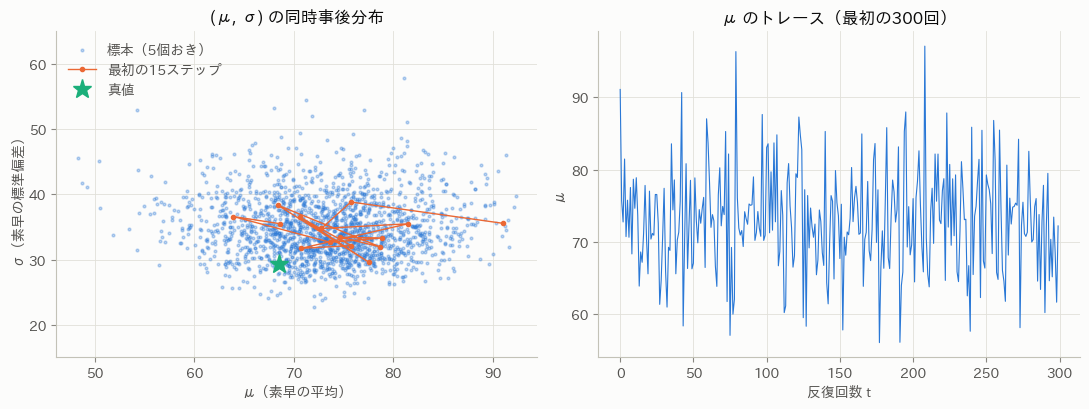

In [220]:
# ギブスサンプリング: 素早の正規モデル N(μ, σ²) の (μ, σ²) を 25 匹の標本から推定
rng_gibbs = get_rng()
n_gb = 25
y_gb = df["素早"].to_numpy()[rng_gibbs.integers(0, len(df), n_gb)]
ybar_gb, n_gb = y_gb.mean(), len(y_gb)
# 事前分布（半共役）: μ ~ N(μ0, τ0²), σ² ~ 逆ガンマ IG(α0, β0)。互いに独立
mu0, tau0_2, alpha0, beta0 = 70.0, 30.0 ** 2, 2.0, 2.0 * 30.0 ** 2
n_iter_gb, burn_gb = 10000, 500
mu_cur, s2_cur = 0.0, 100.0 ** 2                              # 離れた初期値
gibbs = np.empty((n_iter_gb, 2))
for t in range(n_iter_gb):
    # μ | σ², y ~ N(m, v),  1/v = 1/τ0² + n/σ²,  m = v (μ0/τ0² + n ȳ/σ²)
    v = 1 / (1 / tau0_2 + n_gb / s2_cur)
    mu_cur = rng_gibbs.normal(v * (mu0 / tau0_2 + n_gb * ybar_gb / s2_cur), np.sqrt(v))
    # σ² | μ, y ~ IG(α0 + n/2, β0 + Σ(y−μ)²/2)  （ガンマ乱数の逆数で生成）
    shape = alpha0 + n_gb / 2
    rate = beta0 + 0.5 * np.sum((y_gb - mu_cur) ** 2)
    s2_cur = 1 / rng_gibbs.gamma(shape, 1 / rate)
    gibbs[t] = mu_cur, s2_cur
gb = gibbs[burn_gb:]
print(f"標本: n={n_gb}, 平均 {ybar_gb:.1f}, 不偏分散 {y_gb.var(ddof=1):.0f}")
t_ci = stats.t(n_gb - 1).ppf(0.975) * y_gb.std(ddof=1) / np.sqrt(n_gb)
print(pd.DataFrame({
    "事後平均": gb.mean(axis=0),
    "95%信用区間": [f"[{lo:.1f}, {hi:.1f}]" for lo, hi in np.percentile(gb, [2.5, 97.5], axis=0).T],
    "真値（母集団）": [bayes_true["素早の平均"], bayes_true["素早の分散（母分散）"]],
}, index=["μ", "σ²"]).round(1).to_string())
print(f"参考: μ の t 区間（頻度論） [{ybar_gb - t_ci:.1f}, {ybar_gb + t_ci:.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(gb[::5, 0], np.sqrt(gb[::5, 1]), s=4, color=PALETTE[0], alpha=0.3, label="標本（5個おき）")
axes[0].plot(gibbs[:15, 0], np.sqrt(gibbs[:15, 1]), color=PALETTE[1], lw=1, marker="o", ms=3, label="最初の15ステップ")
axes[0].plot(bayes_true["素早の平均"], np.sqrt(bayes_true["素早の分散（母分散）"]), marker="*", ms=14,
             color=PALETTE[2], ls="none", label="真値")
axes[0].set(title="(μ, σ) の同時事後分布", xlabel="μ（素早の平均）", ylabel="σ（素早の標準偏差）", ylim=(15, 65))
axes[0].legend()
axes[1].plot(gibbs[:300, 0], color=PALETTE[0], lw=0.8)
axes[1].set(title="μ のトレース（最初の300回）", xlabel="反復回数 t", ylabel="μ")
fig.tight_layout()
plt.show()

**結果の読み方**
- 離れた初期値 $(\mu,\sigma)=(0,100)$ から始めても、数回の更新で事後分布の中心付近に移り、すぐに定常状態に入った。
- $\mu$ の事後平均 73.2、95%信用区間 [59.5, 86.7] は、頻度論の $t$ 区間 [59.0, 87.7] とほぼ同じで、真値 68.6 を含む。事前分布が標本に比べて弱いため、ほぼデータで決まっている。
- $\sigma^2$ の95%信用区間 [725, 2098] も真値 864 を含む。標本の不偏分散 1208 が真値より大きかったため、事後分布も大きめに出ている。

### まとめ

- **事前分布の影響**：20匹程度の小標本では、事前分布の重み（ベータ分布なら $a+b$）が標本サイズに近いと結論が大きく変わる。誤った強い事前分布は真値を区間から外した。標本が増えると事後分布は事前分布によらず真値に集中する。
- **縮小推定**：タイプ別の合計種族値の平均は、件数の少ないタイプ（ひこう4匹）ほど全体平均へ強く引き寄せられた。各タイプ5匹の模擬実験では、経験ベイズ推定の平均二乗誤差は標本平均の半分以下だった。
- **MCMC**：メトロポリス法・MH 法・ギブスサンプリングを numpy だけで実装し、共役でない事後分布（ロジスティック回帰）も近似できた。歩幅は受容率とトレースプロットで確かめる。大標本・弱い事前分布では事後分布は最尤推定の正規近似とほぼ一致する。
- **限界**：事後分布はモデル（ポアソン・正規の仮定、事前分布）を前提にしている。姿違いの数の過分散のように、モデルの破れは予測分布の裾に現れる。MCMC は収束の保証がなく、診断を怠ると誤った結論を出しうる。

## 第32章 シミュレーション

### 章の概要

計算機で乱数を作り、確率分布からの標本を人工的に生成して、式では求めにくい積分・確率・推定量の性質を調べる方法を扱う。
中心となる考え方は、**大数の法則により、乱数による平均は期待値に近づき、その誤差は $1/\sqrt{n}$ の速さで小さくなる**こと。
前半は乱数の作り方（擬似乱数・逆関数法・採択棄却法）とモンテカルロ積分、後半は手元の標本だけから推定量のばらつきを見積もる
ジャックナイフ法・ブートストラップ法である。
全920匹を「真値のわかっている母集団」とし、そこからの標本で得た結果を真値と照らし合わせる。第31章の MCMC も、この章の乱数生成の上に成り立っている。

| 節 | 手法 | ポケモンのデータで立てる問い |
|---|---|---|
| 32.1 | 擬似乱数・線形合同法 | 計算機の乱数はどう作られ、なぜ再現できるのか |
| 32.2 | 逆関数法 | 一様乱数から指数分布や「合計種族値の分布」に従う乱数を作れるか |
| 32.3 | 採択・棄却法 | 素早の割合を近似したベータ分布の乱数を、一様乱数だけで作れるか。受容率は理論どおりか |
| 32.4 | モンテカルロ積分・分散減少法 | 積分の誤差は本当に $1/\sqrt{n}$ で減るか。誤差を減らす工夫はどれだけ効くか |
| 32.5 | モンテカルロ法による確率の計算 | 2匹を選んだとき、1匹目のほうが速い確率は |
| 32.6 | 経験分布関数 | 標本の経験分布関数は母集団の分布関数にどれだけ近いか |
| 32.7 | ジャックナイフ法 | 1匹ずつ除いて、推定量の標準誤差とバイアスを見積もれるか |
| 32.8 | ブートストラップ法 | 中央値・相関係数・回帰の傾きの標準誤差と信頼区間を復元抽出で求める |
| 32.9 | ブートストラップ区間の被覆率 | パーセンタイル区間は本当に 95% の確率で真値を含むか |

### 使うデータ

| 列 | 型 | 内容・この章での役割 |
|---|---|---|
| `合計種族値` | 量的（離散, 210通りの値） | 逆関数法・経験分布関数・ジャックナイフ・ブートストラップの対象 |
| `素早` | 量的 | 素早の割合（`素早 / 合計種族値`）、32.5 の比較、回帰の説明変数 |
| `攻撃` | 量的 | 合計種族値との相関係数 |

- **対象の行**：全920行を母集団とする。標本は母集団から**復元抽出**する（i.i.d. 標本となり、有限母集団修正が不要になる）。
- **加工**：`素早 / 合計種族値`（0〜1 の割合）を作る。
- **データの性質と注意点**：真値は、合計種族値の中央値 455、相関係数 $r(\text{攻撃},\text{合計種族値})=0.734$、合計種族値を素早に回帰した傾き 2.28、素早の割合の平均 0.158。
  合計種族値は同じ値が多い（920匹で210通り）ため、中央値の標本分布は離散的になる。

In [221]:
# 真値（全920行を母集団とみなしたときの値）
total_pop = df["合計種族値"].to_numpy()
speed_pop = df["素早"].to_numpy()
attack_pop = df["攻撃"].to_numpy()
share_pop = speed_pop / total_pop                        # 素早が合計種族値に占める割合
slope_pop = np.polyfit(speed_pop, total_pop, 1)[0]       # 合計種族値 = a + b・素早 の傾き
sim_true = pd.Series({
    "合計種族値の平均": total_pop.mean(),
    "合計種族値の中央値": np.median(total_pop),
    "相関係数 r(攻撃, 合計種族値)": np.corrcoef(attack_pop, total_pop)[0, 1],
    "回帰の傾き（合計種族値 ~ 素早）": slope_pop,
    "素早の割合の平均": share_pop.mean(),
    "素早の割合の標準偏差": share_pop.std(),
})
print(sim_true.round(4).to_string())
print("\n合計種族値の異なる値の数:", len(np.unique(total_pop)))

合計種族値の平均             438.4685
合計種族値の中央値            455.0000
相関係数 r(攻撃, 合計種族値)      0.7341
回帰の傾き（合計種族値 ~ 素早）      2.2791
素早の割合の平均               0.1582
素早の割合の標準偏差             0.0587

合計種族値の異なる値の数: 210


### 32.1 擬似乱数と線形合同法

**問い**：計算機の乱数はどう作られ、なぜシードを決めると同じ列が再現できるのか。

**手法の要点**
- **擬似乱数**：決定的な漸化式で作る、乱数のように見える数列。初期値（シード）が同じなら同じ列になるので、分析を再現できる。
- **線形合同法**：$x_{k+1}=(a x_k+c)\bmod m$、$u_k=x_k/m$。取りうる値は $m$ 通りなので周期は $m$ 以下。
  $c\neq0$ のとき周期が最大の $m$ になる必要十分条件は、(i) $c$ と $m$ が互いに素、(ii) $a-1$ が $m$ のすべての素因数で割り切れる、(iii) $m$ が4の倍数なら $a-1$ も4の倍数（ハル・ドーベルの定理）。
- 一様性の確認：$[0,1)$ を10等分した度数 $O_j$ に対し $\chi^2=\sum_j(O_j-E_j)^2/E_j$（$E_j=N/10$）は、一様性の仮説のもとで近似的に自由度9のカイ二乗分布に従う。
- 線形合同法は多次元での規則性（連続する値の組が少数の平面上に並ぶ）などの欠点があり、現在の numpy の既定は PCG64 という別の生成法である。

In [222]:
# 擬似乱数: シードと再現性、線形合同法
print("同じシードなら同じ列:", get_rng(1).uniform(size=3).round(4), get_rng(1).uniform(size=3).round(4))
print("違うシード          :", get_rng(2).uniform(size=3).round(4))

def lcg(a, c, m, x0, n):
    """線形合同法 x_{k+1} = (a x_k + c) mod m."""
    xs = [x0]
    for _ in range(n - 1):
        xs.append((a * xs[-1] + c) % m)
    return np.array(xs)

# 小さな例: m = 16。周期が最大 16 になる条件（c と m が互いに素, a−1 が m の素因数と4で割り切れる）
print("\nm=16, a=5, c=3:", lcg(5, 3, 16, 7, 20))
print("m=16, a=3, c=3:", lcg(3, 3, 16, 7, 20), "（a−1=2 が4で割り切れず周期が短い）")

# 実用的な例: パーク・ミラーの最小標準（a=16807, c=0, m=2^31−1）で一様性をカイ二乗検定
m_pm = 2 ** 31 - 1
u_pm = lcg(16807, 0, m_pm, 12345, 20000) / m_pm
obs_pm, _ = np.histogram(u_pm, bins=10, range=(0, 1))
chi2_pm = ((obs_pm - len(u_pm) / 10) ** 2 / (len(u_pm) / 10)).sum()
print(f"\nパーク・ミラー 20000個: 10区間の度数 {obs_pm}")
print(f"カイ二乗統計量 {chi2_pm:.2f}, 自由度 9, p値 {stats.chi2.sf(chi2_pm, 9):.3f}（scipy: {stats.chisquare(obs_pm).pvalue:.3f}）")
# 初期値を20通り変えて同じ検定を繰り返す（H0 が正しければ p値は U(0,1) に従い、約5%で p < 0.05 となる）
p_seeds = [stats.chisquare(np.histogram(lcg(16807, 0, m_pm, x0, 20000) / m_pm, bins=10, range=(0, 1))[0]).pvalue
           for x0 in range(1, 21)]
print("初期値 1〜20 での p値:", np.round(p_seeds, 2), f"→ p<0.05 は {np.sum(np.array(p_seeds) < 0.05)} 回")
# 連続する2つの値の組 (u_k, u_{k+1}) の相関
print(f"隣り合う値の相関 {np.corrcoef(u_pm[:-1], u_pm[1:])[0, 1]:.4f}")

同じシードなら同じ列: [0.5118 0.9505 0.1442] [0.5118 0.9505 0.1442]
違うシード          : [0.2616 0.2985 0.8142]

m=16, a=5, c=3: [ 7  6  1  8 11 10  5 12 15 14  9  0  3  2 13  4  7  6  1  8]
m=16, a=3, c=3: [ 7  8 11  4 15  0  3 12  7  8 11  4 15  0  3 12  7  8 11  4] （a−1=2 が4で割り切れず周期が短い）

パーク・ミラー 20000個: 10区間の度数 [2061 1957 1987 2089 1873 1989 2019 1960 2015 2050]
カイ二乗統計量 17.30, 自由度 9, p値 0.044（scipy: 0.044）
初期値 1〜20 での p値: [0.9  0.97 0.57 0.92 0.54 0.26 0.54 0.49 0.98 0.52 0.52 0.16 0.8  0.33
 0.88 0.83 0.24 0.93 0.43 0.62] → p<0.05 は 0 回
隣り合う値の相関 0.0144


**結果の読み方**
- $m=16,\ a=5,\ c=3$ は条件をすべて満たし、0〜15 がちょうど1回ずつ現れて周期16。$a=3$ では $a-1=2$ が4で割り切れず、周期が8に落ちる。
- パーク・ミラー法（$a=16807,\ c=0,\ m=2^{31}-1$）の20000個では、初期値 12345 のとき $\chi^2=17.3$（自由度9）、p値 0.044 で、有意水準5%ではわずかに棄却された。
  しかし初期値を1〜20に変えると p値は 0.16〜0.98 に散らばり、5%を下回ったものはない。仮説が正しくても約5%の確率で棄却されるので、1回の検定だけで生成法の良し悪しは決められない。

### 32.2 逆関数法

**問い**：一様乱数から、指数分布や合計種族値の分布に従う乱数を作れるか。

**手法の要点**
- $U\sim U(0,1)$、$F$ を分布関数、$F^{-1}(u)=\inf\{x:F(x)\ge u\}$（一般化逆関数）とすると、$X=F^{-1}(U)$ の分布関数は $F$ である。
  $F^{-1}(u)\le x\iff u\le F(x)$ より $P(X\le x)=P(U\le F(x))=F(x)$ となるため。
- 指数分布 $\mathrm{Exp}(\lambda)$：$F(x)=1-e^{-\lambda x}$ より $X=-\log(1-U)/\lambda$（$1-U$ も一様なので $-\log U/\lambda$ でもよい）。平均 $1/\lambda$、分散 $1/\lambda^2$。
- 経験分布（離散分布）：並べ替えた値 $x_{(1)}\le\dots\le x_{(N)}$ に対し $F_N^{-1}(u)=x_{(\lceil Nu\rceil)}$。これは母集団からの復元抽出と同じであり、ブートストラップ法（32.8）の乱数生成そのものである。

指数分布 Exp(λ=0.5): 標本平均 1.985（理論 2.0）, 標本分散 4.113（理論 4.0）
  KS検定: D=0.0125, p値=0.407

経験分布からの逆関数法: 平均 436.9（母集団 438.5）, 標準偏差 120.3（母集団 120.3）


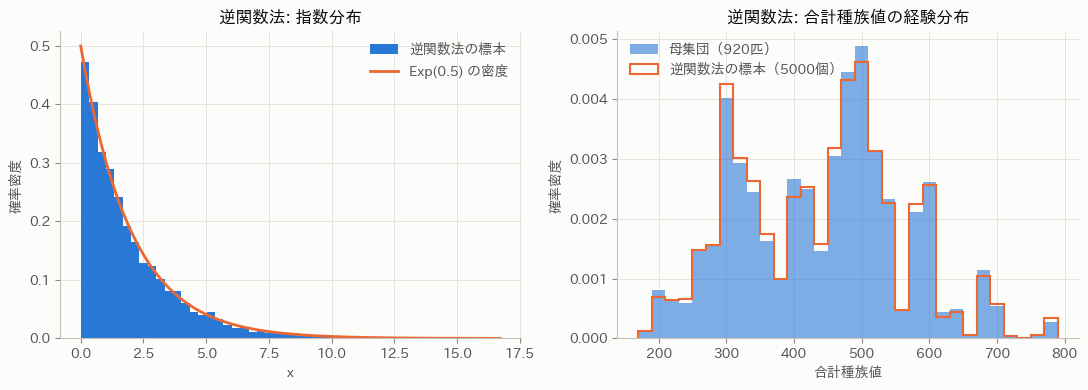

In [223]:
# 逆関数法: 指数分布と、合計種族値の経験分布
rng_inv = get_rng()
n_inv = 5000
lam = 0.5
u_inv = rng_inv.uniform(size=n_inv)
x_exp = -np.log(1 - u_inv) / lam                       # F(x) = 1 − e^{−λx} の逆関数
ks_exp = stats.kstest(x_exp, stats.expon(scale=1 / lam).cdf)
print(f"指数分布 Exp(λ={lam}): 標本平均 {x_exp.mean():.3f}（理論 {1 / lam}）, 標本分散 {x_exp.var():.3f}（理論 {1 / lam ** 2}）")
print(f"  KS検定: D={ks_exp.statistic:.4f}, p値={ks_exp.pvalue:.3f}")

# 経験分布の一般化逆関数 F_n^{-1}(u) = min{x : F_n(x) ≥ u} = x_(⌈nu⌉)
total_sorted = np.sort(total_pop)
n_pop = len(total_sorted)
x_emp = total_sorted[np.ceil(n_pop * u_inv).astype(int) - 1]
print(f"\n経験分布からの逆関数法: 平均 {x_emp.mean():.1f}（母集団 {total_pop.mean():.1f}）,"
      f" 標準偏差 {x_emp.std():.1f}（母集団 {total_pop.std():.1f}）")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(x_exp, bins=50, density=True, color=PALETTE[0], label="逆関数法の標本")
g_exp = np.linspace(0, x_exp.max(), 200)
axes[0].plot(g_exp, stats.expon(scale=1 / lam).pdf(g_exp), color=PALETTE[1], label="Exp(0.5) の密度")
axes[0].set(title="逆関数法: 指数分布", xlabel="x", ylabel="確率密度")
axes[0].legend()
bins_tot = np.arange(170, 800, 20)
axes[1].hist(total_pop, bins=bins_tot, density=True, color=PALETTE[0], alpha=0.6, label="母集団（920匹）")
axes[1].hist(x_emp, bins=bins_tot, density=True, histtype="step", color=PALETTE[1], lw=1.5, label="逆関数法の標本（5000個）")
axes[1].set(title="逆関数法: 合計種族値の経験分布", xlabel="合計種族値", ylabel="確率密度")
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- 指数分布 $\mathrm{Exp}(0.5)$ の5000個は標本平均 1.99（理論 2）、標本分散 4.11（理論 4）で、KS検定の p値 0.41 と理論分布からのずれは検出されない。
- 経験分布からの5000個は、母集団の平均 438.5・標準偏差 120.3 をほぼ再現し、ヒストグラムの細かい凹凸（合計種族値 300 付近・500 付近の山）まで一致する。

### 32.3 採択・棄却法

**問い**：素早が合計種族値に占める割合をベータ分布で近似し、その乱数を一様乱数だけから作る。受容率は理論値と合うか。

**手法の要点**
- 目標の密度 $f$、乱数を作りやすい提案分布の密度 $g$、定数 $R$ について、すべての $x$ で $f(x)\le R\,g(x)$ とする。
  1. $Y\sim g$ と $U\sim U(0,1)$ を独立に生成する。
  2. $U\le\dfrac{f(Y)}{R\,g(Y)}$ なら $Y$ を出力し、そうでなければ 1 に戻る。
  出力の分布は $f$ になる。1組あたりの採択確率は $\displaystyle\int g(y)\frac{f(y)}{R\,g(y)}dy=\frac1R$ なので、$R$ はできるだけ小さく（$R=\sup_x f(x)/g(x)$）とる。
- ここでは $g=U(0,1)$（$g\equiv1$）なので $R=\max_x f(x)$ で、ベータ分布 $\mathrm{Be}(a,b)$（$a,b>1$）ではモード $\dfrac{a-1}{a+b-2}$ での密度。
- ベータ分布のパラメータはモーメント法で決める：平均 $m$、分散 $v$ に対し $a+b=\dfrac{m(1-m)}{v}-1$、$a=m(a+b)$、$b=(1-m)(a+b)$。

モーメント法: Be(5.95, 31.66), モード 0.139, R = max f = 6.955
受容率: 実測 0.1455 / 理論 1/R = 0.1438
採択された 4366 個: 平均 0.1593（理論 0.1582）, KS検定 p値 0.362


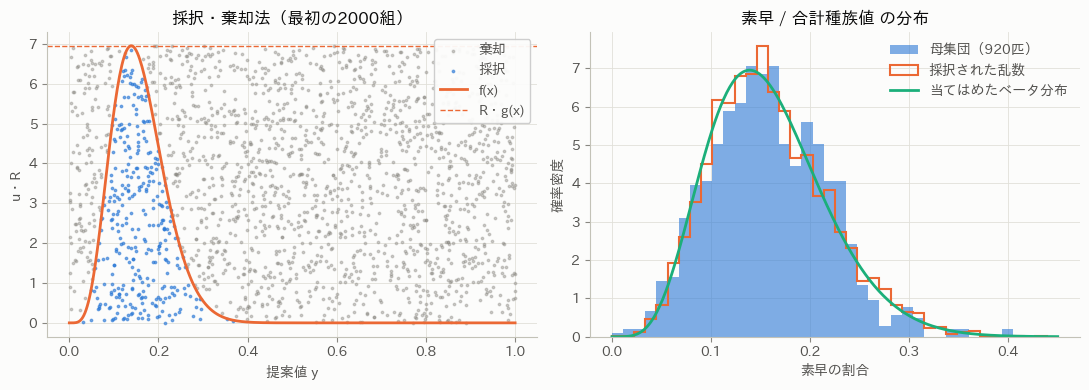

In [224]:
# 採択・棄却法: 素早の割合をベータ分布で近似し、一様分布を提案分布として乱数を作る
m1, v1 = share_pop.mean(), share_pop.var()
k_mom = m1 * (1 - m1) / v1 - 1                         # モーメント法: a + b = m(1−m)/v − 1
a_beta, b_beta = m1 * k_mom, (1 - m1) * k_mom
beta_t = stats.beta(a_beta, b_beta)
mode_beta = (a_beta - 1) / (a_beta + b_beta - 2)
R_ar = beta_t.pdf(mode_beta)                           # f(x) ≤ R・g(x), g = U(0,1) の密度 1
print(f"モーメント法: Be({a_beta:.2f}, {b_beta:.2f}), モード {mode_beta:.3f}, R = max f = {R_ar:.3f}")

rng_ar = get_rng()
n_prop = 30000
y_ar = rng_ar.uniform(size=n_prop)                     # 提案 y ~ g
u_ar = rng_ar.uniform(size=n_prop)
accept = u_ar <= beta_t.pdf(y_ar) / (R_ar * 1.0)       # u ≤ f(y) / (R g(y)) なら採択
x_ar = y_ar[accept]
print(f"受容率: 実測 {accept.mean():.4f} / 理論 1/R = {1 / R_ar:.4f}")
print(f"採択された {len(x_ar)} 個: 平均 {x_ar.mean():.4f}（理論 {beta_t.mean():.4f}）, KS検定 p値 {stats.kstest(x_ar, beta_t.cdf).pvalue:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
g_b = np.linspace(0, 0.45, 300)
axes[0].scatter(y_ar[:2000][~accept[:2000]], (u_ar * R_ar)[:2000][~accept[:2000]], s=3, color=INK["muted"], alpha=0.4, label="棄却")
axes[0].scatter(y_ar[:2000][accept[:2000]], (u_ar * R_ar)[:2000][accept[:2000]], s=3, color=PALETTE[0], alpha=0.6, label="採択")
axes[0].plot(np.linspace(0, 1, 400), beta_t.pdf(np.linspace(0, 1, 400)), color=PALETTE[1], label="f(x)")
axes[0].axhline(R_ar, color=PALETTE[1], ls="--", lw=1, label="R・g(x)")
axes[0].set(title="採択・棄却法（最初の2000組）", xlabel="提案値 y", ylabel="u・R")
axes[0].legend(loc="upper right", frameon=True, facecolor=INK["surface"], framealpha=0.95)
axes[1].hist(share_pop, bins=40, range=(0, 0.45), density=True, color=PALETTE[0], alpha=0.6, label="母集団（920匹）")
axes[1].hist(x_ar, bins=40, range=(0, 0.45), density=True, histtype="step", color=PALETTE[1], lw=1.5, label="採択された乱数")
axes[1].plot(g_b, beta_t.pdf(g_b), color=PALETTE[2], label="当てはめたベータ分布")
axes[1].set(title="素早 / 合計種族値 の分布", xlabel="素早の割合", ylabel="確率密度")
axes[1].legend()
fig.tight_layout()
plt.show()

**結果の読み方**
- モーメント法で $\mathrm{Be}(5.95,\ 31.66)$、$R=6.96$。受容率は実測 0.146、理論 $1/R=0.144$ とよく一致した。
  密度が 0〜0.4 に集中しているのに一様分布で提案しているため、約86%の提案が捨てられる。提案分布を目標に近づけるほど効率が上がる。
- 採択された乱数はベータ分布との KS検定で p値 0.36 と、目標分布からのずれは検出されない。ベータ分布は母集団（素早の割合）のヒストグラムもおおむねよく近似している。

### 32.4 モンテカルロ積分と分散減少法

**問い**：$I=\int_0^1 e^x\,dx=e-1$ を乱数で近似すると、誤差は $n$ とともにどう減るか。

**手法の要点**
- $X\sim U(0,1)$ なら $E[g(X)]=\int_0^1 g(x)\,dx$。$X_1,\dots,X_n$ を i.i.d. に生成し $\hat\theta=\frac1n\sum_i g(X_i)$ とすると、大数の法則で $\hat\theta\to\theta$。
  区間 $[a,b]$ なら $X\sim U(a,b)$ として $(b-a)\cdot\frac1n\sum g(X_i)$ を使う。
- $V[\hat\theta]=\sigma^2/n$（$\sigma^2=V[g(X)]$）なので、誤差（標準誤差）は $\sigma/\sqrt n$。$\sigma^2$ は $s^2=\frac{1}{n-1}\sum(g(X_i)-\hat\theta)^2$ で推定する。
  精度を1桁上げるには乱数を100倍にする必要がある。
- 今回は $\sigma^2=\int_0^1e^{2x}dx-(e-1)^2=\dfrac{e^2-1}{2}-(e-1)^2\approx0.242$。
- **負の相関の利用**（対称変量法）：$U$ と $1-U$ は同じ分布で、$g$ が単調なら $g(U)$ と $g(1-U)$ は負の相関を持つ。$m=n/2$ 組で $\hat I=\frac1m\sum_{i=1}^m\frac{g(U_i)+g(1-U_i)}{2}$。
- **主部の分離**（制御変量）：$g$ を近似する積分しやすい関数 $h$（ここではテイラー展開の1次まで $h(x)=1+x$、$\int_0^1h=1.5$）を使い、$g(x)-h(x)+1.5$ の平均で推定する。$g-h$ の分散が小さいほど効果が大きい。

log RMSE を log n に回帰した傾き: -0.499（理論 −0.5）
真値 e − 1 = 1.718282
                推定値      標準誤差  分散の比（素朴=1）
素朴なモンテカルロ  1.719018  0.004954    1.000000
負の相関の利用    1.719796  0.000890    0.032280
主部の分離      1.719059  0.002108    0.181076
corr(e^U, e^(1−U)) = -0.968


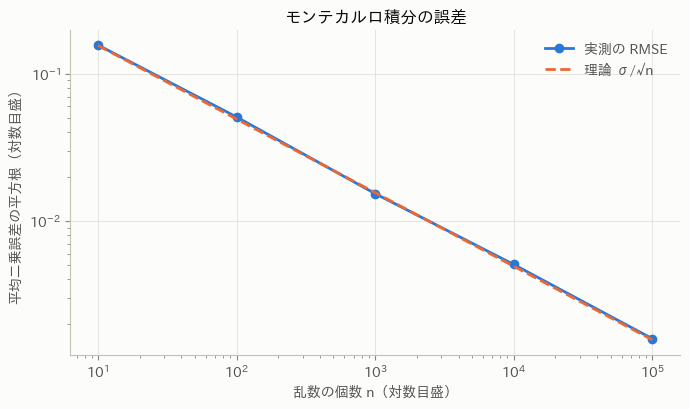

,n,RMSE（200回）,標準誤差の推定 s/√n,理論 σ/√n
0,10,0.156560,0.173375,0.155575
1,100,0.050794,0.050105,0.049197
2,1000,0.015315,0.015481,0.015557
3,10000,0.005055,0.004903,0.004920
4,100000,0.001583,0.001555,0.001556


In [225]:
# モンテカルロ積分: I = ∫_0^1 e^x dx = e − 1。誤差が 1/√n で減ることを確かめる
rng_mc = get_rng()
I_true = np.e - 1
n_grid = np.array([10, 100, 1000, 10000, 100000])
n_rep_mc = 200
rmse_mc, se_mc = [], []
for n in n_grid:
    est = np.exp(rng_mc.uniform(size=(n_rep_mc, n))).mean(axis=1) if n <= 10000 else \
        np.array([np.exp(rng_mc.uniform(size=n)).mean() for _ in range(n_rep_mc)])
    rmse_mc.append(np.sqrt(np.mean((est - I_true) ** 2)))
    se_mc.append(np.sqrt(np.var(np.exp(rng_mc.uniform(size=n)), ddof=1) / n))   # 1回分の標準誤差の推定値
sigma_g = np.sqrt((np.e ** 2 - 1) / 2 - I_true ** 2)    # V[e^U] の理論値の平方根
mc_tab = pd.DataFrame({"n": n_grid, "RMSE（200回）": rmse_mc, "標準誤差の推定 s/√n": se_mc,
                       "理論 σ/√n": sigma_g / np.sqrt(n_grid)})
slope_mc = np.polyfit(np.log(n_grid), np.log(rmse_mc), 1)[0]
print(f"log RMSE を log n に回帰した傾き: {slope_mc:.3f}（理論 −0.5）")

# 分散減少法（同じ乱数の個数 n = 10000 で比較）
n_vr = 10000
u_vr = rng_mc.uniform(size=n_vr)
g_plain = np.exp(u_vr)
g_anti = (np.exp(u_vr[: n_vr // 2]) + np.exp(1 - u_vr[: n_vr // 2])) / 2   # 負の相関を利用: m = n/2 組
g_ctrl = np.exp(u_vr) - (1 + u_vr) + 1.5                                  # 主部の分離: h(x)=1+x, ∫h = 1.5
vr_tab = pd.DataFrame({
    "推定値": [g_plain.mean(), g_anti.mean(), g_ctrl.mean()],
    "標準誤差": [g_plain.std(ddof=1) / np.sqrt(n_vr), g_anti.std(ddof=1) / np.sqrt(n_vr // 2),
                 g_ctrl.std(ddof=1) / np.sqrt(n_vr)],
}, index=["素朴なモンテカルロ", "負の相関の利用", "主部の分離"])
vr_tab["分散の比（素朴=1）"] = (vr_tab["標準誤差"] / vr_tab["標準誤差"].iloc[0]) ** 2
print(f"真値 e − 1 = {I_true:.6f}")
print(vr_tab.round(6).to_string())
print(f"corr(e^U, e^(1−U)) = {np.corrcoef(np.exp(u_vr), np.exp(1 - u_vr))[0, 1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(n_grid, rmse_mc, marker="o", color=PALETTE[0], label="実測の RMSE")
ax.loglog(n_grid, sigma_g / np.sqrt(n_grid), ls="--", color=PALETTE[1], label="理論 σ/√n")
ax.set(title="モンテカルロ積分の誤差", xlabel="乱数の個数 n（対数目盛）", ylabel="平均二乗誤差の平方根（対数目盛）")
ax.legend()
fig.tight_layout()
plt.show()
mc_tab

**結果の読み方**
- 200回の反復での RMSE は $n=10$ の 0.157 から $n=10^5$ の 0.0016 まで、理論 $\sigma/\sqrt n$ の直線にほぼ重なった。log–log の傾きは −0.499（理論 −0.5）。
  1回の実行から求めた標準誤差 $s/\sqrt n$ も理論値とよく一致し、実際の誤差の目安として使える。
- 同じ乱数1万個での分散は、素朴な方法を1として、主部の分離 0.18、負の相関の利用 0.03。$e^U$ と $e^{1-U}$ の相関が −0.97 と強い負なので、対称変量法の効果が非常に大きい。

### 32.5 モンテカルロ法による確率の計算

**問い**：2匹を独立に無作為に選んだとき、1匹目の素早が2匹目より大きい確率はいくつか。

**手法の要点**
- 事象 $A$ の確率は指示関数の期待値 $P(A)=E[\mathbf 1_A]$ なので、$n$ 回の試行で $A$ が起きた回数 $X$ から $\hat p=X/n$ と推定できる。
- $X\sim\mathrm{Bin}(n,p)$ より $V[\hat p]=p(1-p)/n$ で、近似95%区間は $\hat p\pm1.96\sqrt{\hat p(1-\hat p)/n}$。
- この問題は 920×920 通りを数えれば厳密値が出るので、推定を検証できる。対称性から $P(\text{1匹目}>\text{2匹目})=\{1-P(\text{同じ})\}/2$ となる。

In [226]:
# モンテカルロ法で確率を求める: 2匹を無作為に選んだとき、1匹目の素早が2匹目より大きい確率
rng_pair = get_rng()
n_pair = 20000
i1, i2 = rng_pair.integers(0, len(df), n_pair), rng_pair.integers(0, len(df), n_pair)
hit = speed_pop[i1] > speed_pop[i2]
p_mc = hit.mean()
# 厳密値: 全 920×920 組で数える
p_exact = (speed_pop[:, None] > speed_pop[None, :]).mean()
print(f"モンテカルロ推定 {p_mc:.4f} ± {1.96 * np.sqrt(p_mc * (1 - p_mc) / n_pair):.4f}（95%）, 厳密値 {p_exact:.4f}")
print(f"同じ素早になる確率（厳密値）: {(speed_pop[:, None] == speed_pop[None, :]).mean():.4f}")

モンテカルロ推定 0.4894 ± 0.0069（95%）, 厳密値 0.4869
同じ素早になる確率（厳密値）: 0.0261


**結果の読み方**
- 2万回のモンテカルロ推定は 0.489 ± 0.007（95%）で、厳密値 0.487 を含む。
- 素早が同じになる確率は 0.026 で、$(1-0.026)/2\approx0.487$ と厳密値に一致する。0.5 を下回るのは同じ値の組（2匹目と同じポケモンを選ぶ場合を含む）があるため。

### 32.6 経験分布関数

**問い**：標本の経験分布関数は、母集団の分布関数にどれだけ近いか。

**手法の要点**
- 標本 $X_1,\dots,X_n$ の**経験分布関数** $F_n(x)=\frac1n\sum_{i=1}^n\mathbf 1\{X_i\le x\}$。各 $x$ で $nF_n(x)\sim\mathrm{Bin}(n,F(x))$ なので $E[F_n(x)]=F(x)$、$V[F_n(x)]=F(x)\{1-F(x)\}/n$ で、$F_n(x)$ は $F(x)$ に確率収束する。
- さらに一様に $\sup_x|F_n(x)-F(x)|\to0$（グリベンコ・カンテリの定理）。$\sqrt n\sup_x|F_n(x)-F(x)|$ は $F$ が連続ならコルモゴロフ分布に分布収束する（KS検定の統計量）。
- DKW 不等式 $P\left(\sup_x|F_n(x)-F(x)|>\varepsilon\right)\le2e^{-2n\varepsilon^2}$ より、$\varepsilon=\sqrt{\log(2/\alpha)/(2n)}$ とすれば $F_n\pm\varepsilon$ は $F$ 全体を確率 $1-\alpha$ 以上で含む帯になる。

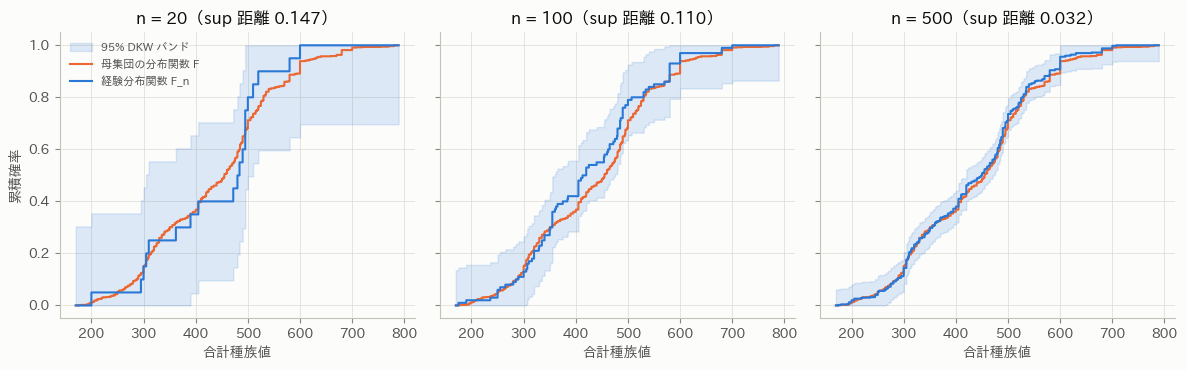

,n,sup|F_n − F|,√n・sup,DKWバンド半幅
0,20,0.1467,0.6562,0.3037
1,100,0.1100,1.1000,0.1358
2,500,0.0320,0.7155,0.0607


In [227]:
# 経験分布関数: 標本を増やすと母集団の分布関数に近づく
rng_ecdf = get_rng()
F_pop = lambda x: np.searchsorted(total_sorted, x, side="right") / n_pop   # 母集団の分布関数
x_eval = np.arange(170, 790)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
ecdf_rows = []
for ax, n in zip(axes, [20, 100, 500]):
    samp = np.sort(rng_ecdf.choice(total_pop, n, replace=True))
    Fn = np.searchsorted(samp, x_eval, side="right") / n
    D = np.abs(Fn - F_pop(x_eval)).max()
    eps = np.sqrt(np.log(2 / 0.05) / (2 * n))            # DKW 不等式による95%バンドの半幅
    ecdf_rows.append({"n": n, "sup|F_n − F|": D, "√n・sup": np.sqrt(n) * D, "DKWバンド半幅": eps})
    ax.fill_between(x_eval, np.clip(Fn - eps, 0, 1), np.clip(Fn + eps, 0, 1), step="post", color=PALETTE[0], alpha=0.15, label="95% DKW バンド")
    ax.step(x_eval, F_pop(x_eval), where="post", color=PALETTE[1], lw=1.5, label="母集団の分布関数 F")
    ax.step(x_eval, Fn, where="post", color=PALETTE[0], lw=1.5, label="経験分布関数 F_n")
    ax.set(title=f"n = {n}（sup 距離 {D:.3f}）", xlabel="合計種族値")
axes[0].set_ylabel("累積確率")
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()
pd.DataFrame(ecdf_rows).round(4)

**結果の読み方**
- 最大のずれ $\sup|F_n-F|$ は $n=20$ で 0.147、$n=100$ で 0.110、$n=500$ で 0.032 と小さくなった。$\sqrt n$ 倍するとどれも 0.7〜1.1 程度で、ずれがおおむね $1/\sqrt n$ の速さで縮むことと整合する（1回ずつの標本なので $n=100$ はやや大きめに出た）。
- 3つとも母集団の分布関数は DKW の95%バンドに収まっている。バンドの半幅は $n=500$ でも 0.06 あり、分布関数全体を一様に押さえるには多くの標本が必要である。

### 32.7 ジャックナイフ法

**問い**：40匹の標本だけから、平均・分散・中央値・相関係数の標準誤差とバイアスを見積もれるか。

**手法の要点**
- 推定量 $\hat\theta=T(X_1,\dots,X_n)$ に対し、$X_j$ を除いた $n-1$ 個で同じように計算した値を $\hat\theta_{(j)}$、その平均を $\hat\theta_{(\cdot)}=\frac1n\sum_j\hat\theta_{(j)}$ とする。
  - 標準誤差のジャックナイフ推定：$\widehat{\mathrm{se}}_{\mathrm{jack}}=\sqrt{\dfrac{n-1}{n}\displaystyle\sum_{j=1}^n\bigl(\hat\theta_{(j)}-\hat\theta_{(\cdot)}\bigr)^2}$
  - バイアスのジャックナイフ推定：$\widehat{\mathrm{bias}}_{\mathrm{jack}}=(n-1)\bigl(\hat\theta_{(\cdot)}-\hat\theta\bigr)$、補正後 $\hat\theta-\widehat{\mathrm{bias}}_{\mathrm{jack}}$
- $\hat\theta=\bar X$ なら $\widehat{\mathrm{se}}_{\mathrm{jack}}=s/\sqrt n$、$\hat\theta=\frac1n\sum(X_i-\bar X)^2$ なら補正後の値は不偏分散 $s^2$ に厳密に一致する。
- 中央値のような「滑らかでない」推定量では、1個除いても値がほとんど変わらず、標準誤差を正しく推定できない（一致性を持たない）。
- 比較のため、母集団から $n=40$ の標本を5000回取り直した推定量の標準偏差を「真の標準誤差」とする。

In [228]:
# ジャックナイフ法: n = 40 の標本で標準誤差とバイアスを推定し、真の標本分布と比べる
rng_jk = get_rng()
n_jk = 40
idx_jk = rng_jk.integers(0, len(df), n_jk)
tot_jk, atk_jk = total_pop[idx_jk], attack_pop[idx_jk]

def jackknife(stat, *arrays):
    """1個ずつ除いた推定値から (推定値, 標準誤差, バイアス) を返す."""
    n = len(arrays[0])
    theta = stat(*arrays)
    loo = np.array([stat(*[a[np.arange(n) != j] for a in arrays]) for j in range(n)])
    se = np.sqrt((n - 1) / n * np.sum((loo - loo.mean()) ** 2))
    bias = (n - 1) * (loo.mean() - theta)
    return theta, se, bias

jk_stats = {
    "平均": (lambda x: x.mean(), (tot_jk,)),
    "標本分散（1/n）": (lambda x: x.var(ddof=0), (tot_jk,)),
    "中央値": (lambda x: np.median(x), (tot_jk,)),
    "相関係数 r(攻撃, 合計)": (lambda x, y: np.corrcoef(x, y)[0, 1], (atk_jk, tot_jk)),
}
# 真の標準誤差: 母集団から n=40 の標本を 5000 回取り直して推定量の標準偏差を求める
idx_true = get_rng(SEED + 1).integers(0, len(df), (5000, n_jk))
T, A = total_pop[idx_true], attack_pop[idx_true]
Tc, Ac = T - T.mean(axis=1, keepdims=True), A - A.mean(axis=1, keepdims=True)
true_draws = {
    "平均": T.mean(axis=1), "標本分散（1/n）": T.var(axis=1),
    "中央値": np.median(T, axis=1),
    "相関係数 r(攻撃, 合計)": (Ac * Tc).sum(1) / np.sqrt((Ac ** 2).sum(1) * (Tc ** 2).sum(1)),
}
jk_rows = []
for name, (f, arrs) in jk_stats.items():
    th, se, bias = jackknife(f, *arrs)
    jk_rows.append({"推定量": name, "推定値": th, "ジャックナイフSE": se, "真のSE（5000回）": true_draws[name].std(),
                    "ジャックナイフのバイアス推定": bias, "バイアス補正後": th - bias})
jk_tab = pd.DataFrame(jk_rows).set_index("推定量")
# 定義式との照合
print(f"平均: ジャックナイフSE = s/√n か → {jk_tab.loc['平均', 'ジャックナイフSE']:.4f} vs {tot_jk.std(ddof=1) / np.sqrt(n_jk):.4f}")
print(f"標本分散: バイアス補正後 = 不偏分散 か → {jk_tab.loc['標本分散（1/n）', 'バイアス補正後']:.2f} vs {tot_jk.var(ddof=1):.2f}")
print(f"標本の異なる値の数 {len(np.unique(tot_jk))}（中央値の1個抜き推定値は高々2通り:"
      f" {np.unique([np.median(np.delete(tot_jk, j)) for j in range(n_jk)])}）")
jk_tab.round(4)

平均: ジャックナイフSE = s/√n か → 16.9601 vs 16.9601
標本分散: バイアス補正後 = 不偏分散 か → 11505.84 vs 11505.84
標本の異なる値の数 33（中央値の1個抜き推定値は高々2通り: [405.]）


,推定値,ジャックナイフSE,真のSE（5000回）,ジャックナイフのバイアス推定,バイアス補正後
推定量,,,,,
平均,404.4500,16.9601,19.3026,0.0000,404.4500
標本分散（1/n）,11218.1975,1971.9520,2761.8766,-287.6461,11505.8436
中央値,405.0000,0.0000,29.0453,0.0000,405.0000
"相関係数 r(攻撃, 合計)",0.6653,0.1006,0.0794,0.0012,0.6641


**結果の読み方**
- 平均の $\widehat{\mathrm{se}}_{\mathrm{jack}}$ は $s/\sqrt n=16.96$ と、分散のバイアス補正後の値は不偏分散と、定義式どおり一致した。
  真の標準誤差 19.3 との差は、この標本の $s$ が母標準偏差よりたまたま小さかったためで、ジャックナイフの問題ではない。
- 中央値のジャックナイフ標準誤差は 0 になった（真の値は約29）。$n=40$ から1個除くと中央値は $x_{(20)}$ か $x_{(21)}$ のどちらかになり、この標本では両者がともに 405 で同じ値だったため。ジャックナイフを中央値に使ってはいけない典型例である。
- 相関係数の標準誤差は 0.10（真の値 0.08）。バイアス推定は 0.001 と小さい。

### 32.8 ブートストラップ法

**問い**：32.7 と同じ40匹の標本から、中央値・相関係数・回帰の傾きの標準誤差と95%信頼区間を求める。

**手法の要点**
- 観測値 $x_1,\dots,x_n$ から**復元抽出**でサイズ $n$ の標本 $x^{*b}$ を作り、推定値 $\hat\theta^{*b}=T(x^{*b})$ を求めることを $b=1,\dots,B$ で繰り返す。
  未知の分布 $F$ を経験分布 $F_n$ で置き換え、「$F_n$ からの標本」で推定量のばらつきを再現する考え方である。
- $\bar\theta^*=\frac1B\sum_b\hat\theta^{*b}$ として
  - 標準誤差：$\widehat{\mathrm{se}}_{\mathrm{boot}}=\sqrt{\dfrac{1}{B-1}\displaystyle\sum_{b=1}^B(\hat\theta^{*b}-\bar\theta^*)^2}$
  - バイアス：$\widehat{\mathrm{bias}}_{\mathrm{boot}}=\bar\theta^*-\hat\theta$
  - 95%パーセンタイル区間：$\hat\theta^{*b}$ の 2.5% 点と 97.5% 点
- 正規理論の区間とも比べる：相関係数はフィッシャーの $z$ 変換 $\tanh\!\left(\operatorname{artanh} r\pm1.96/\sqrt{n-3}\right)$、傾きは OLS の標準誤差。

回帰の傾き: OLS の標準誤差 0.3689
相関係数: フィッシャー z 変換の95%区間 [0.446, 0.809]


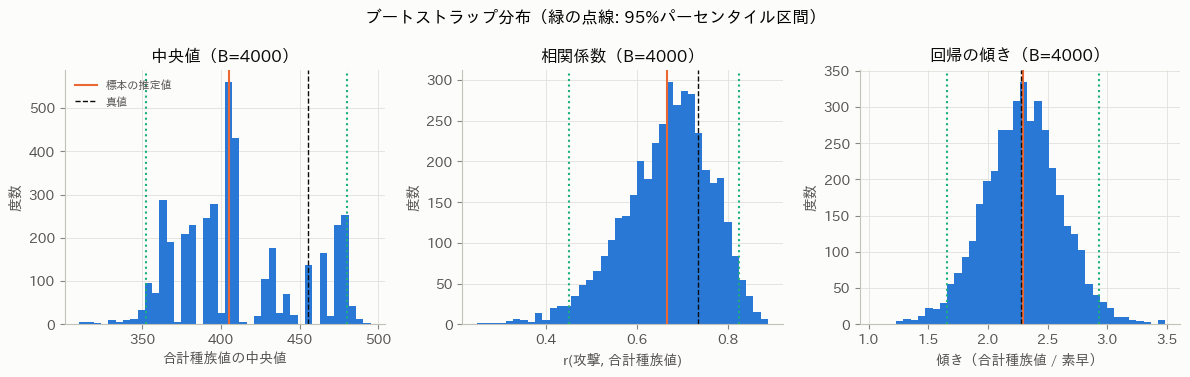

,推定値,真値,ブートストラップSE,真のSE（5000回）,バイアス推定,95%パーセンタイル区間
推定量,,,,,,
中央値,405.0000,455.0000,38.9228,29.0453,5.0870,"[352.500, 480.000]"
相関係数,0.6653,0.7341,0.0966,0.0794,0.0005,"[0.451, 0.824]"
回帰の傾き,2.2936,2.2791,0.3233,0.5362,-0.0029,"[1.655, 2.927]"


In [229]:
# ブートストラップ法: 同じ n = 40 の標本から、中央値・相関係数・回帰の傾きの標準誤差と信頼区間を求める
rng_bs = get_rng()
B_bs = 4000
spd_jk = speed_pop[idx_jk]

def boot_stats(x_tot, x_atk, x_spd, idx):
    """復元抽出の添字行列 idx（B × n）から3つの推定量を一度に計算する."""
    t, a, s = x_tot[idx], x_atk[idx], x_spd[idx]
    tc, ac, sc = (v - v.mean(axis=1, keepdims=True) for v in (t, a, s))
    med = np.median(t, axis=1)
    r = (ac * tc).sum(1) / np.sqrt((ac ** 2).sum(1) * (tc ** 2).sum(1))
    slope = (sc * tc).sum(1) / (sc ** 2).sum(1)
    return {"中央値": med, "相関係数": r, "回帰の傾き": slope}

theta_hat = boot_stats(tot_jk, atk_jk, spd_jk, np.arange(n_jk)[None, :])
idx_boot = rng_bs.integers(0, n_jk, (B_bs, n_jk))
boot = boot_stats(tot_jk, atk_jk, spd_jk, idx_boot)
# 真の標本分布（母集団から n=40 を5000回）
true_sd = {k: v.std() for k, v in boot_stats(total_pop, attack_pop, speed_pop, idx_true).items()}
true_val = {"中央値": sim_true["合計種族値の中央値"], "相関係数": sim_true["相関係数 r(攻撃, 合計種族値)"],
            "回帰の傾き": sim_true["回帰の傾き（合計種族値 ~ 素早）"]}

bs_rows = []
for k in boot:
    th = theta_hat[k][0]
    lo, hi = np.percentile(boot[k], [2.5, 97.5])
    bs_rows.append({"推定量": k, "推定値": th, "真値": true_val[k],
                    "ブートストラップSE": boot[k].std(ddof=1), "真のSE（5000回）": true_sd[k],
                    "バイアス推定": boot[k].mean() - th, "95%パーセンタイル区間": f"[{lo:.3f}, {hi:.3f}]"})
# 正規理論との比較: 回帰の傾きの OLS 標準誤差, 相関係数のフィッシャー z 区間
res_ols = stats.linregress(spd_jk, tot_jk)
z = np.arctanh(theta_hat["相関係数"][0])
fz_lo, fz_hi = np.tanh(z + np.array([-1, 1]) * 1.96 / np.sqrt(n_jk - 3))
print(f"回帰の傾き: OLS の標準誤差 {res_ols.stderr:.4f}")
print(f"相関係数: フィッシャー z 変換の95%区間 [{fz_lo:.3f}, {fz_hi:.3f}]")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
units = {"中央値": "合計種族値の中央値", "相関係数": "r(攻撃, 合計種族値)", "回帰の傾き": "傾き（合計種族値 / 素早）"}
for ax, k in zip(axes, boot):
    ax.hist(boot[k], bins=40, color=PALETTE[0])
    ax.axvline(theta_hat[k][0], color=PALETTE[1], lw=1.5, label="標本の推定値")
    ax.axvline(true_val[k], color=INK["primary"], ls="--", lw=1, label="真値")
    for q in np.percentile(boot[k], [2.5, 97.5]):
        ax.axvline(q, color=PALETTE[2], ls=":", lw=1.5)
    ax.set(title=f"{k}（B={B_bs}）", xlabel=units[k], ylabel="度数")
axes[0].legend(fontsize=8)
fig.suptitle("ブートストラップ分布（緑の点線: 95%パーセンタイル区間）", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()
pd.DataFrame(bs_rows).set_index("推定量").round(4)

**結果の読み方**
- 中央値のブートストラップ分布は合計種族値の離散性のため飛び飛びの多峰形になった。標準誤差は 39（真の値 29）と大きめだが、パーセンタイル区間 [352.5, 480] は真値 455 を含む。
  標本の中央値 405 は真値 455 よりかなり小さく、ブートストラップ分布は**標本の推定値のまわり**に広がる（真値の位置は教えてくれない）。
- 相関係数：標準誤差 0.097（真の値 0.079）、95%区間 [0.451, 0.824] はフィッシャー $z$ の区間 [0.446, 0.809] とほぼ同じで、真値 0.734 を含む。分布は左に歪んでいる（相関係数は上限1に近いほど左に歪む）。
- 回帰の傾き：標準誤差 0.32 は OLS の 0.37 に近いが、真の値 0.54 よりかなり小さい。1つの標本から見積もる標準誤差そのものにも大きなばらつきがあり、$n=40$ ではこの程度の過小評価は起こりうる。

### 32.9 ブートストラップ区間の被覆率

**問い**：母集団から40匹を取り直してパーセンタイル区間を作ることを1000回繰り返したとき、真値を含む割合は名目の95%に近いか。

**手法の要点**
- 被覆率（真値を含む割合）の推定値 $\hat c$ は、真の被覆率が 0.95 なら標準誤差 $\sqrt{0.95\cdot0.05/1000}\approx0.007$ で、おおむね [0.936, 0.964] に入る。
- 各反復で $B=1000$ のブートストラップを行う（合計100万回の推定）。
- パーセンタイル区間は、推定量の分布が歪んでいたりバイアスがあったりすると、小標本で被覆率が名目を下回ることがある。改良版として BCa 法（バイアスと歪みを補正）がある。

In [230]:
# 被覆率の確認: 母集団から n=40 を取り直して区間を作り、真値を含む割合を数える
rng_cov = get_rng()
n_rep_cov, B_cov, n_cov = 1000, 1000, 40
cover = {k: 0 for k in true_val}
cover_normal = {"相関係数（フィッシャー z）": 0, "回帰の傾き（OLS の t 区間）": 0}
width = {k: [] for k in true_val}
t_crit = stats.t(n_cov - 2).ppf(0.975)
for _ in range(n_rep_cov):
    idx_s = rng_cov.integers(0, len(df), n_cov)
    t_s, a_s, s_s = total_pop[idx_s], attack_pop[idx_s], speed_pop[idx_s]
    bst = boot_stats(t_s, a_s, s_s, rng_cov.integers(0, n_cov, (B_cov, n_cov)))
    for k in true_val:
        lo, hi = np.percentile(bst[k], [2.5, 97.5])
        cover[k] += lo <= true_val[k] <= hi
        width[k].append(hi - lo)
    est = boot_stats(t_s, a_s, s_s, np.arange(n_cov)[None, :])
    zc = np.arctanh(est["相関係数"][0])
    cover_normal["相関係数（フィッシャー z）"] += np.tanh(zc - 1.96 / np.sqrt(n_cov - 3)) <= true_val["相関係数"] <= np.tanh(zc + 1.96 / np.sqrt(n_cov - 3))
    lr = stats.linregress(s_s, t_s)
    cover_normal["回帰の傾き（OLS の t 区間）"] += abs(lr.slope - true_val["回帰の傾き"]) <= t_crit * lr.stderr
cov_tab = pd.DataFrame({
    "被覆率": [cover[k] / n_rep_cov for k in true_val] + [v / n_rep_cov for v in cover_normal.values()],
}, index=[f"{k}（パーセンタイル）" for k in true_val] + list(cover_normal))
cov_tab["被覆率の95%範囲（名目0.95なら）"] = f"[{0.95 - 1.96 * np.sqrt(0.95 * 0.05 / n_rep_cov):.3f}, {0.95 + 1.96 * np.sqrt(0.95 * 0.05 / n_rep_cov):.3f}]"
print(f"反復 {n_rep_cov} 回, B = {B_cov}, n = {n_cov}")
print("パーセンタイル区間の平均の幅:", {k: round(np.mean(v), 3) for k, v in width.items()})
cov_tab

反復 1000 回, B = 1000, n = 40
パーセンタイル区間の平均の幅: {'中央値': 107.58, '相関係数': 0.287, '回帰の傾き': 2.098}


,被覆率,被覆率の95%範囲（名目0.95なら）
中央値（パーセンタイル）,0.961,"[0.936, 0.964]"
相関係数（パーセンタイル）,0.922,"[0.936, 0.964]"
回帰の傾き（パーセンタイル）,0.932,"[0.936, 0.964]"
相関係数（フィッシャー z）,0.946,"[0.936, 0.964]"
回帰の傾き（OLS の t 区間）,0.956,"[0.936, 0.964]"


**結果の読み方**
- 中央値のパーセンタイル区間の被覆率は 0.961 で名目どおり（離散性のためやや保守的）。
- 相関係数は 0.922、回帰の傾きは 0.932 と、名目の 0.95 をやや下回った。$n=40$ ではブートストラップ分布が標本分布の広がりや歪みを十分に再現できず、区間が短めになる。
- 同じ条件でフィッシャー $z$ 区間は 0.946、OLS の $t$ 区間は 0.956 と名目に近い。前提（2変量正規性、誤差の正規性・等分散性）が大きく崩れていない場合、小標本では正規理論の区間のほうが信頼できることもある。ブートストラップは万能ではなく、標本サイズが小さいときは被覆率の確認が大切である。

### まとめ

- **乱数生成**：線形合同法の周期は係数の選び方で決まる。逆関数法・採択棄却法で、一様乱数から指数分布・合計種族値の経験分布・ベータ分布の乱数を作り、受容率 $1/R$ などの理論値と一致することを確かめた。
- **モンテカルロ法**：積分の誤差は理論どおり $1/\sqrt n$ で減った。$e^x$ の積分では負の相関の利用で分散が約3%に、主部の分離で約18%に減った。
- **再標本化法**：ジャックナイフは平均・分散では定義式どおりの結果を与えるが、中央値では標準誤差が 0 になり使えない。ブートストラップは中央値にも使えるが、$n=40$ では相関係数や傾きの区間の被覆率が 92〜93% と名目をやや下回った。
- **限界**：シミュレーションの結果は乱数の偏りに左右されるので、シードを固定して再現性を確保し、反復回数に応じたモンテカルロ誤差（例: 被覆率 ±0.014）を添えて読む。ブートストラップは「標本が母集団をよく代表する」ことを前提にしており、小標本・離散データ・極端値を含むデータでは注意が必要である。